# Jet Engine Hospital — Predicting Failure Before It Happens
**Multi-task early-warning system for NASA C-MAPSS turbofan engines**

Course: Machine Learning · Shahid Beheshti University · Dr. Farahani · Spring 2026

This notebook covers: EDA & data audit, engine-level
splitting, leakage-safe feature engineering, RUL regression, failure-horizon
classification, unsupervised anomaly detection, early-warning cost analysis,
uncertainty quantification, a decision policy, and the final model comparison.


## 0 · Reproducible Setup

In [1]:
import sys, os, warnings
from pathlib import Path
sys.dont_write_bytecode = True
from sklearnex import patch_sklearn

SKLEARNEX_ALLOWLIST = [
    "ridge",
    "logisticregression",
    "kmeans",
    "pca",
]
patch_sklearn(SKLEARNEX_ALLOWLIST, verbose=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

runtime_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(runtime_root)
PROJECT_ROOT = Path(".")
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import config
import data_loader as dl
from joblib import Memory
from notebook_cache import fit_estimator

NOTEBOOK_USE_CACHE = os.environ.get(
    "NOTEBOOK_USE_CACHE", "1"
).strip().lower() not in {"0", "false", "no"}
NOTEBOOK_CACHE_DIR = PROJECT_ROOT / ".cache" / "notebook-models"
notebook_memory = Memory(
    location=(NOTEBOOK_CACHE_DIR if NOTEBOOK_USE_CACHE else None),
    verbose=0,
)
cached_fit_estimator = notebook_memory.cache(fit_estimator)

%load_ext autoreload
%autoreload 2

RANDOM_SEED = config.RANDOM_SEED
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__, "| pandas:", pd.__version__)
print("Project root:", PROJECT_ROOT)
print("Data raw exists:", config.DATA_RAW.exists())
print("Random seed:", RANDOM_SEED)


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


Python: 3.11.15
NumPy: 1.26.4 | pandas: 2.2.2
Project root: .
Data raw exists: True
Random seed: 42


In [2]:
SUBSET = "FD001"
print("Active subset:", SUBSET, "|", config.DATASET_INFO[SUBSET])


Active subset: FD001 | {'train_engines': 100, 'test_engines': 100, 'conditions': 1, 'faults': 1}


## 1 · EDA and Data Audit

We audit at both **row level** and **engine level**. All variance / near-constant
checks use TRAINING engines only (leakage-safe). We document every filtering
decision and the number of affected rows/engines.

In [3]:
train_raw = dl.load_raw(SUBSET, "train")
train = dl.add_train_rul(train_raw)               
train = dl.add_classification_labels(train)        

print("Train shape:", train.shape)
print("Engines:", train['engine_id'].nunique())
train.head()


Train shape: (20631, 30)
Engines: 100


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,label_h10,label_h20,label_h30
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,191,0,0,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,190,0,0,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,189,0,0,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,188,0,0,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,187,0,0,0


Sequence length (cycles per engine):
count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64


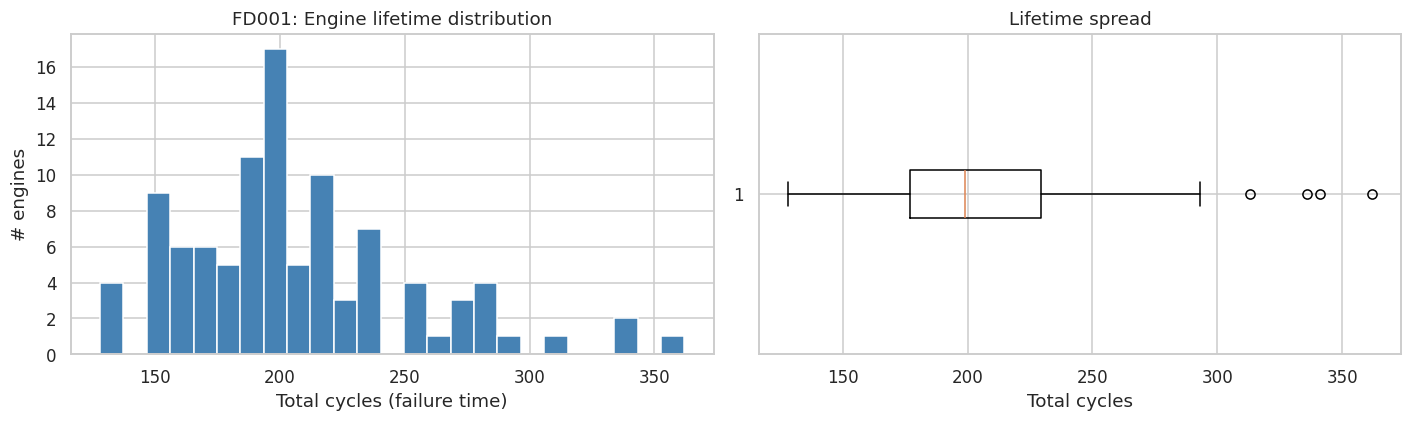

In [4]:
seq_len = train.groupby('engine_id')['cycle'].max()
print("Sequence length (cycles per engine):")
print(seq_len.describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(seq_len, bins=25, color='steelblue', edgecolor='white')
ax[0].set_title(f'{SUBSET}: Engine lifetime distribution')
ax[0].set_xlabel('Total cycles (failure time)'); ax[0].set_ylabel('# engines')
ax[1].boxplot(seq_len, vert=False)
ax[1].set_title('Lifetime spread'); ax[1].set_xlabel('Total cycles')
plt.tight_layout(); plt.show()


In [5]:
audit = {}
audit['n_rows'] = len(train)
audit['n_engines'] = train['engine_id'].nunique()
audit['missing_cells'] = int(train.isna().sum().sum())
audit['non_finite'] = int(np.isinf(train.select_dtypes('number')).sum().sum())
dup = train.duplicated(subset=['engine_id', 'cycle']).sum()
audit['duplicate_keys'] = int(dup)

def continuous(g):
    c = g['cycle'].values
    return np.array_equal(c, np.arange(1, len(c) + 1))
audit['engines_noncontinuous'] = int((~train.groupby('engine_id')[['cycle']].apply(continuous)).sum())

print("DATA AUDIT (train, {})".format(SUBSET))
for k, v in audit.items():
    print(f"  {k:24s}: {v}")


DATA AUDIT (train, FD001)
  n_rows                  : 20631
  n_engines               : 100
  missing_cells           : 0
  non_finite              : 0
  duplicate_keys          : 0
  engines_noncontinuous   : 0


### 1.1 · Sensor variance & near-constant detection (train only)

We identify sensors with (near) zero variance on TRAINING engines. Constant
sensors carry no degradation information and are dropped. This check uses
training data only — a leakage-safe decision.

In [6]:
sensor_std = train[config.SENSOR_COLS].std().sort_values()
print("Sensor standard deviations (ascending):")
print(sensor_std.round(4))

CONST_THRESHOLD = 1e-6
constant_sensors = sensor_std[sensor_std <= CONST_THRESHOLD].index.tolist()
print(f"\nNear-constant sensors (std <= {CONST_THRESHOLD}): {constant_sensors}")

setting_std = train[config.SETTING_COLS].std()
print("\nOperating-setting standard deviations:")
print(setting_std.round(4))


Sensor standard deviations (ascending):
sensor_1      0.0000
sensor_10     0.0000
sensor_19     0.0000
sensor_18     0.0000
sensor_16     0.0000
sensor_5      0.0000
sensor_6      0.0014
sensor_15     0.0375
sensor_8      0.0710
sensor_13     0.0719
sensor_21     0.1083
sensor_20     0.1807
sensor_11     0.2671
sensor_2      0.5001
sensor_12     0.7376
sensor_7      0.8851
sensor_17     1.5488
sensor_3      6.1311
sensor_4      9.0006
sensor_14    19.0762
sensor_9     22.0829
dtype: float64

Near-constant sensors (std <= 1e-06): ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']

Operating-setting standard deviations:
op_setting_1    0.0022
op_setting_2    0.0003
op_setting_3    0.0000
dtype: float64


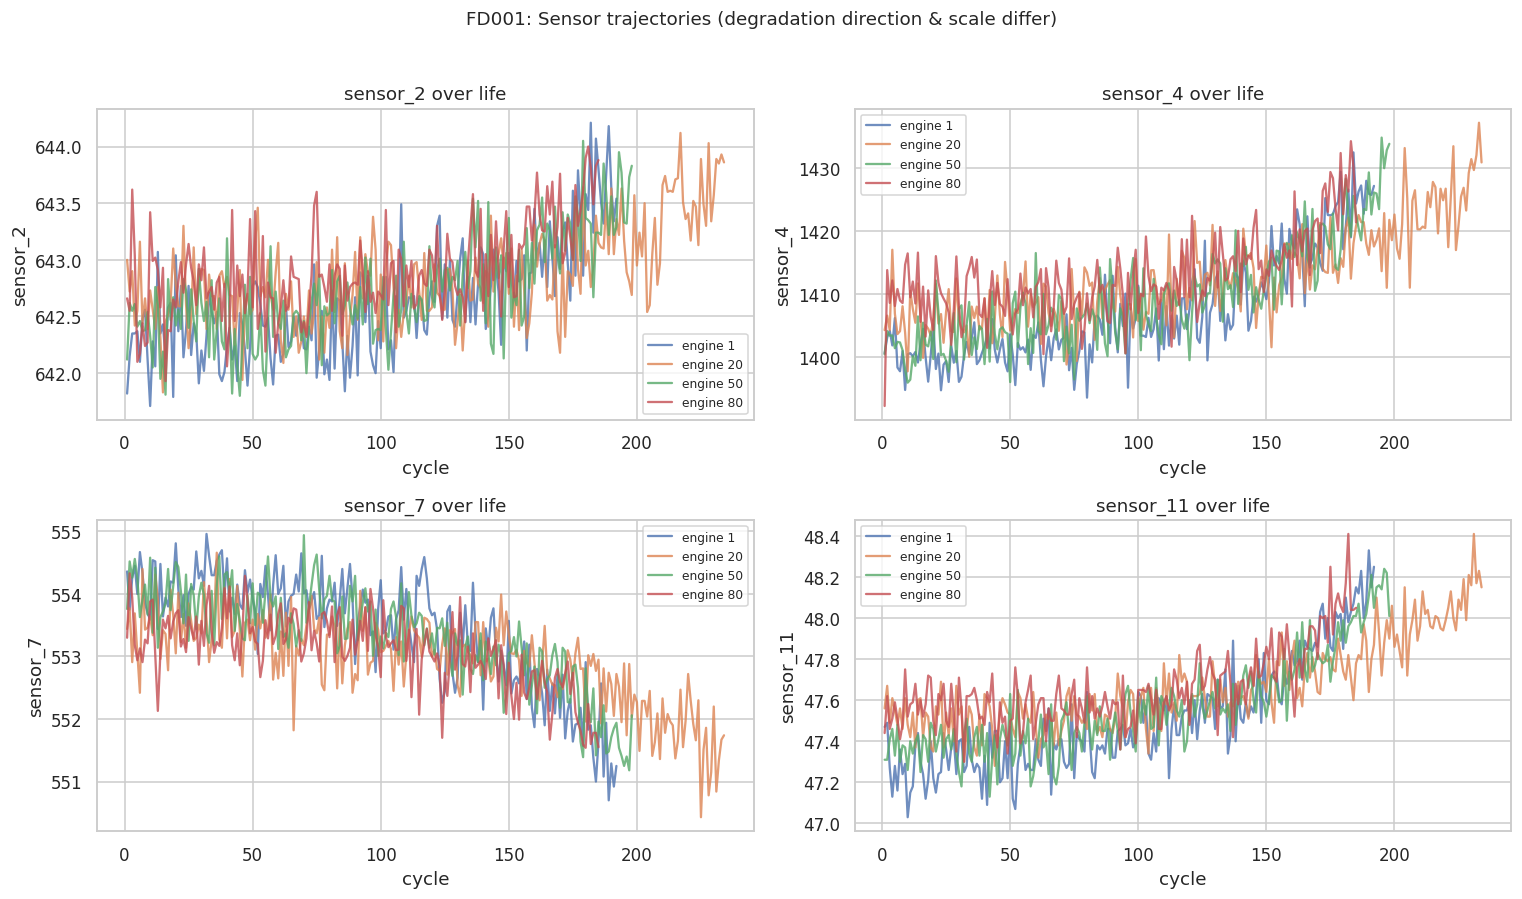

In [7]:
example_engines = [1, 20, 50, 80]
example_sensors = ['sensor_2', 'sensor_4', 'sensor_7', 'sensor_11']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, s in zip(axes.ravel(), example_sensors):
    for eid in example_engines:
        g = train[train['engine_id'] == eid]
        ax.plot(g['cycle'], g[s], label=f'engine {eid}', alpha=0.8)
    ax.set_title(f'{s} over life')
    ax.set_xlabel('cycle'); ax.set_ylabel(s)
    ax.legend(fontsize=8)
plt.suptitle(f'{SUBSET}: Sensor trajectories (degradation direction & scale differ)',
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


### 1.2 · Filtering decisions (documented)

Based on training-only variance analysis, we drop zero/near-constant sensors
and the constant operating setting. This decision is logged below. In FD001
these carry no information; in FD002/FD004 the settings become informative
(6 operating conditions) and this decision will be revisited.

### Formalize & log feature-filtering decisions (train-only variance)


In [8]:
CONST_THRESHOLD = 1e-6
drop_sensors = sensor_std[sensor_std <= CONST_THRESHOLD].index.tolist()
drop_settings = setting_std[setting_std <= CONST_THRESHOLD].index.tolist()
keep_sensors = [s for s in config.SENSOR_COLS if s not in drop_sensors]
keep_settings = [s for s in config.SETTING_COLS if s not in drop_settings]

filter_log = pd.DataFrame([
    {"decision": "drop_constant_sensors", "threshold": CONST_THRESHOLD,
     "n_features_affected": len(drop_sensors), "features": ", ".join(drop_sensors)},
    {"decision": "drop_constant_settings", "threshold": CONST_THRESHOLD,
     "n_features_affected": len(drop_settings), "features": ", ".join(drop_settings)},
    {"decision": "keep_informative_sensors", "threshold": CONST_THRESHOLD,
     "n_features_affected": len(keep_sensors), "features": ", ".join(keep_sensors)},
])
print("FEATURE FILTERING DECISIONS (train-only)")
print(f"Dropped {len(drop_sensors)} constant sensors: {drop_sensors}")
print(f"Dropped {len(drop_settings)} constant settings: {drop_settings}")
print(f"Kept {len(keep_sensors)} informative sensors.")
print(f"Kept {len(keep_settings)} informative settings: {keep_settings}")
print()
filter_log


FEATURE FILTERING DECISIONS (train-only)
Dropped 6 constant sensors: ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']
Dropped 1 constant settings: ['op_setting_3']
Kept 15 informative sensors.
Kept 2 informative settings: ['op_setting_1', 'op_setting_2']



,decision,threshold,n_features_affected,features
0,drop_constant_sensors,0.000001,6,"sensor_1, sensor_10, sensor_19, sensor_18, sen..."
1,drop_constant_settings,0.000001,1,op_setting_3
2,keep_informative_sensors,0.000001,15,"sensor_2, sensor_3, sensor_4, sensor_6, sensor..."


## 2 · Engine-Level Split (Leakage Backbone)

Spliting by ENGINE ID before any preprocessing. Official-train engines are split
into train (70%) and validation (30%). Splits are saved to `data/splits/` and reused by the app.

In [9]:
import splits as sp

split = sp.make_engine_split(SUBSET, val_fraction=0.30)   
sp.save_split(SUBSET, split)   

print("Canonical split = RANDOM engine-level (engine_id only).")

split_sizes = {
    role: len(split[role])
    for role in ("train", "val", "test")
}

print("Split sizes (engines):", split_sizes)

tr_set, val_set = set(split["train"]), set(split["val"])
assert tr_set.isdisjoint(val_set), "LEAKAGE: train/val engine IDs overlap!"
assert len(tr_set) == len(split["train"]), "duplicate train IDs"
assert len(val_set) == len(split["val"]), "duplicate val IDs"
n_official_train = dl.load_raw(SUBSET, "train")["engine_id"].nunique()
assert len(tr_set) + len(val_set) == n_official_train, \
    "train+val != official-train engine count"

split_meta = {
    "subset": SUBSET,
    "method": "random_engine_level",
    "seed": config.RANDOM_SEED,
    "val_fraction": 0.30,
    "train_source": f"train_{SUBSET}.txt",
    "val_source": f"train_{SUBSET}.txt",
    "test_source": f"test_{SUBSET}.txt",
    "n_engines": split_sizes,
}
print("\nSource-aware split metadata:")
for k, v in split_meta.items():
    print(f"  {k}: {v}")
print("\nPrimary leakage evidence: set-intersection assertions PASSED.")
print("(ID-membership plot below is SUPPORTING; window-boundary tests come later.)")


Canonical split = RANDOM engine-level (engine_id only).
Split sizes (engines): {'train': 70, 'val': 30, 'test': 100}

Source-aware split metadata:
  subset: FD001
  method: random_engine_level
  seed: 42
  val_fraction: 0.3
  train_source: train_FD001.txt
  val_source: train_FD001.txt
  test_source: test_FD001.txt
  n_engines: {'train': 70, 'val': 30, 'test': 100}

Primary leakage evidence: set-intersection assertions PASSED.
(ID-membership plot below is SUPPORTING; window-boundary tests come later.)


### Deterministic validation subdivision contract

This must run before model selection, calibration, conformal fitting,
anomaly threshold selection, or maintenance-policy optimization.


In [10]:
validation_subdivision = sp.make_validation_subdivision(
    split,
    tune_fraction=config.VAL_TUNE_FRACTION,
    seed=config.RANDOM_SEED,
)

validation_subdivision_path = (
    sp.save_validation_subdivision(
        SUBSET,
        validation_subdivision,
    )
)

validation_subdivision = (
    sp.load_validation_subdivision(SUBSET)
)

VAL_TUNE_IDS = validation_subdivision["val_tune"]
VAL_CALIB_IDS = validation_subdivision["val_calib"]

assert set(VAL_TUNE_IDS).isdisjoint(VAL_CALIB_IDS)

assert (
    set(VAL_TUNE_IDS).union(VAL_CALIB_IDS)
    == set(split["val"])
)

assert (
    validation_subdivision["source"]
    == "official_train"
)

assert (
    validation_subdivision["selection_basis"]
    == "engine_id_only"
)

print("Validation subdivision contract:", validation_subdivision_path)

print(
    "Parent validation engines:",
    len(split["val"]),
)

print(
    "VAL-TUNE engines:",
    len(VAL_TUNE_IDS),
    VAL_TUNE_IDS,
)

print(
    "VAL-CALIB engines:",
    len(VAL_CALIB_IDS),
    VAL_CALIB_IDS,
)

print(
    "Validation subdivision integrity: PASS"
)


Validation subdivision contract: data/splits/FD001_validation_subdivision.json
Parent validation engines: 30
VAL-TUNE engines: 20 [1, 5, 10, 11, 13, 16, 27, 31, 34, 40, 41, 45, 46, 54, 74, 77, 78, 81, 89, 91]
VAL-CALIB engines: 10 [19, 23, 32, 43, 56, 70, 71, 73, 84, 97]
Validation subdivision integrity: PASS


### Construct leakage-safe development dataframes

Only official-training data is loaded here.
Official test remains sealed until final locked evaluation.


In [11]:
full_train = dl.load_raw(SUBSET, "train")
official_train = full_train.copy()
full_train = dl.add_train_rul(full_train)
full_train = dl.add_classification_labels(full_train)

df_tr = full_train[
    full_train["engine_id"].isin(split["train"])
].copy()

df_val = full_train[
    full_train["engine_id"].isin(split["val"])
].copy()

df_val_tune = full_train[
    full_train["engine_id"].isin(VAL_TUNE_IDS)
].copy()

df_val_calib = full_train[
    full_train["engine_id"].isin(VAL_CALIB_IDS)
].copy()

train_ids_observed = set(
    df_tr["engine_id"].unique()
)

val_ids_observed = set(
    df_val["engine_id"].unique()
)

tune_ids_observed = set(
    df_val_tune["engine_id"].unique()
)

calib_ids_observed = set(
    df_val_calib["engine_id"].unique()
)

assert train_ids_observed == set(split["train"])
assert val_ids_observed == set(split["val"])
assert tune_ids_observed == set(VAL_TUNE_IDS)
assert calib_ids_observed == set(VAL_CALIB_IDS)

assert train_ids_observed.isdisjoint(
    val_ids_observed
)

assert tune_ids_observed.isdisjoint(
    calib_ids_observed
)

assert (
    tune_ids_observed.union(calib_ids_observed)
    == val_ids_observed
)

assert len(df_val_tune) + len(df_val_calib) == len(df_val)

assert set(df_val_tune.index).isdisjoint(
    set(df_val_calib.index)
)

assert (
    set(df_val_tune.index).union(df_val_calib.index)
    == set(df_val.index)
)

required_targets = [
    "RUL",
    "label_h10",
    "label_h20",
    "label_h30",
]

for frame_name, frame in {
    "train": df_tr,
    "val_parent": df_val,
    "val_tune": df_val_tune,
    "val_calib": df_val_calib,
}.items():
    missing = [
        column
        for column in required_targets
        if column not in frame.columns
    ]

    assert not missing, (
        f"{frame_name}: missing target columns {missing}"
    )

    assert not frame.duplicated(
        ["engine_id", "cycle"]
    ).any(), (
        f"{frame_name}: duplicate engine-cycle keys"
    )


assert "df_test" not in globals(), (
    "df_test already exists. Restart the kernel and execute only through "
    "this cell so official test remains sealed."
)

print("Development dataframes created from official_train only.")

print(
    "Rows:",
    {
        "train": len(df_tr),
        "val_parent": len(df_val),
        "val_tune": len(df_val_tune),
        "val_calib": len(df_val_calib),
    },
)

print(
    "Engines:",
    {
        "train": df_tr["engine_id"].nunique(),
        "val_parent": df_val["engine_id"].nunique(),
        "val_tune": df_val_tune["engine_id"].nunique(),
        "val_calib": df_val_calib["engine_id"].nunique(),
    },
)

print("Official test status: SEALED")
print("Development partition integrity: PASS")


Development dataframes created from official_train only.
Rows: {'train': 14507, 'val_parent': 6124, 'val_tune': 4098, 'val_calib': 2026}
Engines: {'train': 70, 'val_parent': 30, 'val_tune': 20, 'val_calib': 10}
Official test status: SEALED
Development partition integrity: PASS


### Development-partition summary

Official test remains sealed. Lifetime statistics here are descriptive only
and are not used for split construction or model selection.


In [12]:
def development_split_summary(
    engine_ids,
    dataframe,
    name,
):
    engine_ids = sorted(
        int(engine_id)
        for engine_id in engine_ids
    )

    observed_ids = set(
        dataframe["engine_id"].unique()
    )

    assert observed_ids == set(engine_ids), (
        f"{name}: dataframe engine IDs do not match contract"
    )

    lifetimes = (
        dataframe
        .groupby("engine_id")["cycle"]
        .max()
    )

    return {
        "split": name,
        "source": "official_train",
        "n_engines": len(engine_ids),
        "n_rows": len(dataframe),
        "mean_lifetime": round(
            float(lifetimes.mean()),
            1,
        ),
        "median_lifetime": round(
            float(lifetimes.median()),
            1,
        ),
        "min_lifetime": int(lifetimes.min()),
        "max_lifetime": int(lifetimes.max()),
    }


summary = pd.DataFrame([
    development_split_summary(
        split["train"],
        df_tr,
        "train",
    ),
    development_split_summary(
        VAL_TUNE_IDS,
        df_val_tune,
        "val_tune",
    ),
    development_split_summary(
        VAL_CALIB_IDS,
        df_val_calib,
        "val_calib",
    ),
    development_split_summary(
        split["val"],
        df_val,
        "val_parent_audit_only",
    ),
])


parent_row_count = int(
    summary.loc[
        summary["split"] == "val_parent_audit_only",
        "n_rows",
    ].iloc[0]
)

child_row_count = int(
    summary.loc[
        summary["split"].isin(
            ["val_tune", "val_calib"]
        ),
        "n_rows",
    ].sum()
)

assert child_row_count == parent_row_count

assert "df_test" not in globals(), (
    "Official test was loaded before final evaluation."
)

print("DEVELOPMENT SPLIT SUMMARY")
print("Official test status: SEALED")

summary


DEVELOPMENT SPLIT SUMMARY
Official test status: SEALED


,split,source,n_engines,n_rows,mean_lifetime,median_lifetime,min_lifetime,max_lifetime
0,train,official_train,70,14507,207.2,197.0,128,362
1,val_tune,official_train,20,4098,204.9,212.5,135,269
2,val_calib,official_train,10,2026,202.6,204.5,137,275
3,val_parent_audit_only,official_train,30,6124,204.1,207.5,135,275


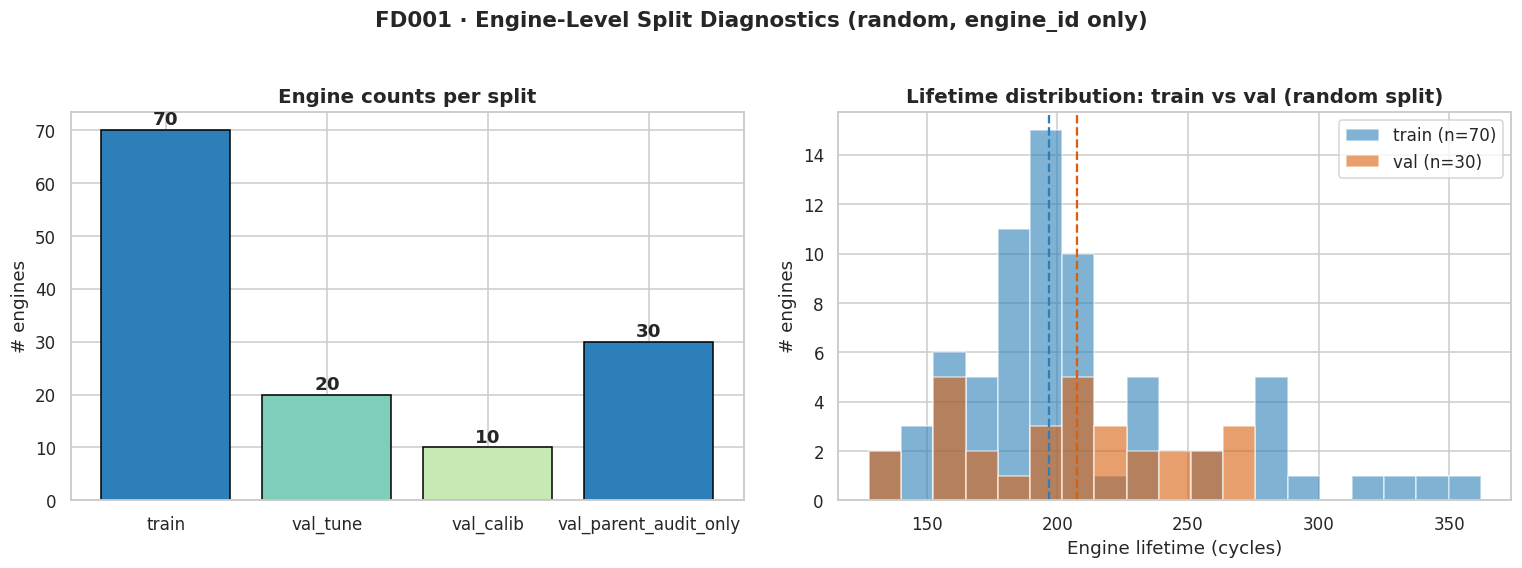

In [13]:
train_life = official_train[official_train["engine_id"].isin(split["train"])] \
                .groupby("engine_id")["cycle"].max()
val_life   = official_train[official_train["engine_id"].isin(split["val"])] \
                .groupby("engine_id")["cycle"].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = summary.set_index("split")["n_engines"]
bars = axes[0].bar(counts.index, counts.values,
                   color=["#2c7fb8", "#7fcdbb", "#c7e9b4"], edgecolor="black")
axes[0].set_title("Engine counts per split", fontsize=13, fontweight="bold")
axes[0].set_ylabel("# engines")
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1, str(v),
                 ha="center", fontweight="bold")

bins = np.linspace(min(train_life.min(), val_life.min()),
                   max(train_life.max(), val_life.max()), 20)
axes[1].hist(train_life, bins=bins, alpha=0.6, label=f"train (n={len(train_life)})",
             color="#2c7fb8", edgecolor="white")
axes[1].hist(val_life, bins=bins, alpha=0.6, label=f"val (n={len(val_life)})",
             color="#d95f0e", edgecolor="white")
axes[1].axvline(train_life.median(), color="#2c7fb8", ls="--", lw=1.5)
axes[1].axvline(val_life.median(), color="#d95f0e", ls="--", lw=1.5)
axes[1].set_title("Lifetime distribution: train vs val (random split)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Engine lifetime (cycles)"); axes[1].set_ylabel("# engines")
axes[1].legend()

plt.suptitle(f"{SUBSET} · Engine-Level Split Diagnostics (random, engine_id only)",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIGURES_DIR / f"{SUBSET}_split_diagnostics.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 2.1 · Split integrity — primary assertions and a supporting visualization

The **primary evidence** that the split is leakage-safe is programmatic: the
set-intersection assertions in the previous cell prove that train and validation
engine-ID sets are disjoint, that there are no duplicates, and that the counts
reconcile with the official-train engine population. Source-aware metadata records
that train/validation engines originate from the official-train file while test
engines originate from the official-test file.

The scatter plot below is a **supporting visualization** of those assertions, not
by itself a proof of a leakage-free pipeline. Full leakage safety is established
jointly by (i) these set assertions, (ii) fitting all preprocessing on training
engines only, and (iii) later tests confirming that no feature window crosses an
engine or split boundary.

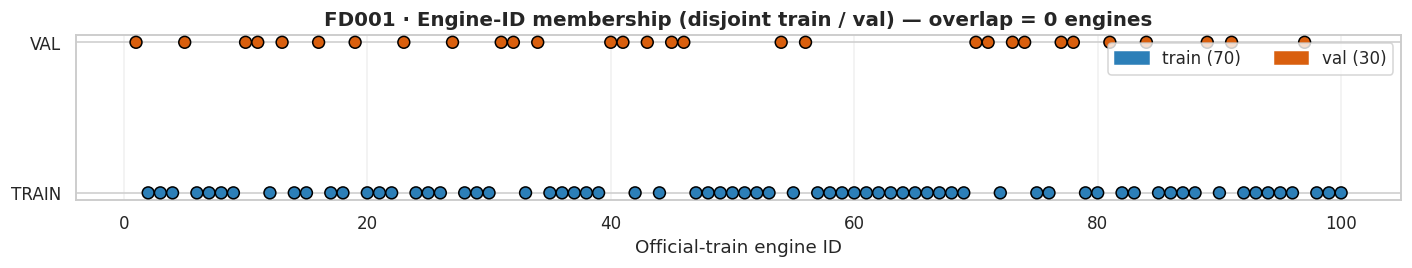

Overlap between train and val engine IDs: 0 (must be 0)


In [14]:
all_train_ids = sorted(official_train["engine_id"].unique().tolist())
tr_set, val_set = set(split["train"]), set(split["val"])

overlap = tr_set & val_set
assert len(overlap) == 0, f"LEAKAGE: overlapping IDs {overlap}"

colors = ["#2c7fb8" if e in tr_set else "#d95f0e" for e in all_train_ids]
ypos = [0 if e in tr_set else 1 for e in all_train_ids]

fig, ax = plt.subplots(figsize=(13, 2.6))
ax.scatter(all_train_ids, ypos, c=colors, s=60, edgecolor="black", zorder=3)
ax.set_yticks([0, 1]); ax.set_yticklabels(["TRAIN", "VAL"])
ax.set_xlabel("Official-train engine ID")
ax.set_title(f"{SUBSET} · Engine-ID membership (disjoint train / val) — "
             f"overlap = {len(overlap)} engines",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2c7fb8", label=f"train ({len(tr_set)})"),
                   Patch(color="#d95f0e", label=f"val ({len(val_set)})")],
          loc="upper right", ncol=2)
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / f"{SUBSET}_split_integrity.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Overlap between train and val engine IDs: {len(overlap)} (must be 0)")

### 2.2 · Optional exploratory analysis: random vs lifetime-stratified split

The project methodology uses the **random engine-level split** defined above,
because the split stage may rely on engine_id only. As an *optional, exploratory*
check, we compare how train/validation lifetime distributions align under the
canonical random split versus a lifetime-stratified alternative. This is purely
diagnostic: it illustrates natural sampling variation in the random split and is
**not** adopted as the final splitting method.

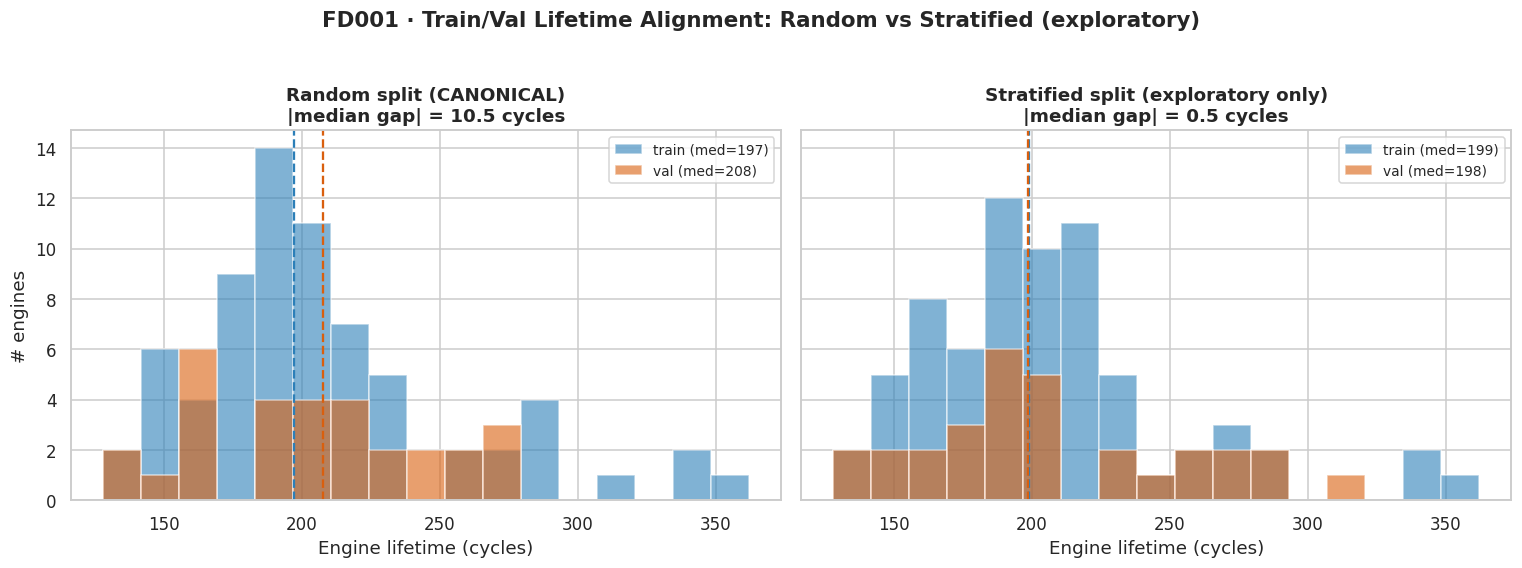

Median gap  — random: 10.5 cycles  | stratified: 0.5 cycles

NOTE: Exploratory only. The CANONICAL split remains RANDOM (engine_id only), saved in the split cell. No stratified split is persisted.
Canonical split unchanged (RANDOM). ✔


In [15]:
lifetimes_all = official_train.groupby("engine_id")["cycle"].max()

split_random     = sp.make_engine_split(SUBSET, val_fraction=0.30)           
split_stratified = sp.make_stratified_engine_split(SUBSET, val_fraction=0.30, n_bins=3) 

def _tv_lifetimes(a_split):
    tr = lifetimes_all[lifetimes_all.index.isin(a_split["train"])]
    va = lifetimes_all[lifetimes_all.index.isin(a_split["val"])]
    return tr, va

tr_r, va_r = _tv_lifetimes(split_random)
tr_s, va_s = _tv_lifetimes(split_stratified)

bins = np.linspace(lifetimes_all.min(), lifetimes_all.max(), 18)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (tr, va, title) in zip(
        axes,
        [(tr_r, va_r, "Random split (CANONICAL)"),
         (tr_s, va_s, "Stratified split (exploratory only)")]):
    ax.hist(tr, bins=bins, alpha=0.6, label=f"train (med={tr.median():.0f})",
            color="#2c7fb8", edgecolor="white")
    ax.hist(va, bins=bins, alpha=0.6, label=f"val (med={va.median():.0f})",
            color="#d95f0e", edgecolor="white")
    ax.axvline(tr.median(), color="#2c7fb8", ls="--", lw=1.5)
    ax.axvline(va.median(), color="#d95f0e", ls="--", lw=1.5)
    gap = abs(tr.median() - va.median())
    ax.set_title(f"{title}\n|median gap| = {gap:.1f} cycles",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Engine lifetime (cycles)")
    ax.legend(fontsize=9)
axes[0].set_ylabel("# engines")
plt.suptitle(f"{SUBSET} · Train/Val Lifetime Alignment: Random vs Stratified (exploratory)",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / f"{SUBSET}_stratification_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Median gap  — random: {abs(tr_r.median()-va_r.median()):.1f} cycles"
      f"  | stratified: {abs(tr_s.median()-va_s.median()):.1f} cycles")
print("\nNOTE: Exploratory only. The CANONICAL split remains RANDOM "
      "(engine_id only), saved in the split cell. No stratified split is persisted.")

assert split_meta["method"] == "random_engine_level", "Canonical split must remain random."
assert set(split["train"]) == set(split_random["train"]), \
    "Active split must match canonical random split."
print("Canonical split unchanged (RANDOM). ✔")


In [16]:
def class_balance(dataframe, split_name):
    required_labels = [
        f"label_h{h}"
        for h in config.CLASSIFICATION_HORIZONS
    ]

    missing_labels = [
        column
        for column in required_labels
        if column not in dataframe.columns
    ]

    assert not missing_labels, (
        f"{split_name}: missing labels {missing_labels}"
    )

    assert (
        dataframe["label_h10"]
        <= dataframe["label_h20"]
    ).all(), (
        f"{split_name}: label_h10 is not nested in label_h20"
    )

    assert (
        dataframe["label_h20"]
        <= dataframe["label_h30"]
    ).all(), (
        f"{split_name}: label_h20 is not nested in label_h30"
    )

    rows = []

    for horizon in config.CLASSIFICATION_HORIZONS:
        column = f"label_h{horizon}"

        positives = int(
            dataframe[column].sum()
        )

        negatives = int(
            len(dataframe) - positives
        )

        positive_rate = (
            positives / len(dataframe)
            if len(dataframe)
            else float("nan")
        )

        imbalance_ratio = (
            negatives / positives
            if positives > 0
            else float("inf")
        )

        rows.append({
            "split": split_name,
            "source": "official_train",
            "horizon": horizon,
            "positives": positives,
            "negatives": negatives,
            "total": len(dataframe),
            "positive_rate": round(
                positive_rate,
                6,
            ),
            "imbalance_ratio_neg_per_pos": round(
                imbalance_ratio,
                2,
            ),
        })

    result = pd.DataFrame(rows)

    rates = result.sort_values(
        "horizon"
    )["positive_rate"].to_numpy()

    assert np.all(np.diff(rates) >= 0), (
        f"{split_name}: positive rates are not monotone by horizon"
    )

    return result


balance = pd.concat(
    [
        class_balance(
            df_tr,
            "train",
        ),
        class_balance(
            df_val_tune,
            "val_tune",
        ),
        class_balance(
            df_val_calib,
            "val_calib",
        ),
    ],
    ignore_index=True,
)

assert "df_test" not in globals(), (
    "Official test was loaded before final evaluation."
)

print(" DEVELOPMENT CLASS BALANCE ")
print("Official test status: SEALED")
print(
    "Imbalance ratio means the number of negative rows "
    "for each positive row."
)

balance


 DEVELOPMENT CLASS BALANCE 
Official test status: SEALED
Imbalance ratio means the number of negative rows for each positive row.


,split,source,horizon,positives,negatives,total,positive_rate,imbalance_ratio_neg_per_pos
0,train,official_train,10,770,13737,14507,0.053078,17.84
1,train,official_train,20,1470,13037,14507,0.101330,8.87
2,train,official_train,30,2170,12337,14507,0.149583,5.69
3,val_tune,official_train,10,220,3878,4098,0.053685,17.63
4,val_tune,official_train,20,420,3678,4098,0.102489,8.76
5,val_tune,official_train,30,620,3478,4098,0.151293,5.61
6,val_calib,official_train,10,110,1916,2026,0.054294,17.42
7,val_calib,official_train,20,210,1816,2026,0.103653,8.65
8,val_calib,official_train,30,310,1716,2026,0.153011,5.54


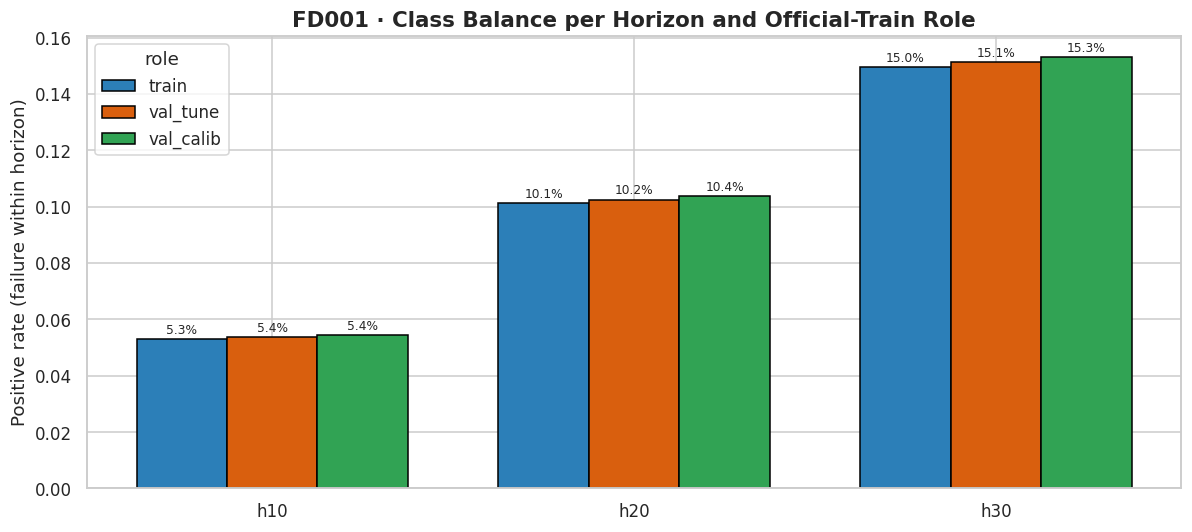

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
splits_order = [split_name for split_name in ["train", "val_tune", "val_calib", "val_parent_audit_only"]
                if split_name in set(balance["split"])]
horizons = config.CLASSIFICATION_HORIZONS
width = min(0.8 / max(len(splits_order), 1), 0.25)
x = np.arange(len(horizons))
colors = {
    "train": "#2c7fb8",
    "val_tune": "#d95f0e",
    "val_calib": "#31a354",
    "val_parent_audit_only": "#756bb1",
}

for i, s in enumerate(splits_order):
    rates = []
    for h in horizons:
        row = balance[(balance["split"] == s) & (balance["horizon"] == h)]
        assert len(row) == 1, f"Missing class-balance row for {s}, h={h}"
        rates.append(float(row["positive_rate"].iloc[0]))
    offset = (i - (len(splits_order) - 1) / 2) * width
    bars = ax.bar(x + offset, rates, width, label=s, color=colors.get(s, "#636363"),
                  edgecolor="black")
    for b, r in zip(bars, rates):
        ax.text(b.get_x() + b.get_width()/2, r + 0.002, f"{r:.1%}",
                ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels([f"h{h}" for h in horizons])
ax.set_ylabel("Positive rate (failure within horizon)")
ax.set_title(f"{SUBSET} · Class Balance per Horizon and Official-Train Role",
             fontsize=14, fontweight="bold")
ax.legend(title="role")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / f"{SUBSET}_class_balance.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 2.3 · Constant-feature detection (fit on training engines only, post-split)

Near-constant sensor detection is performed **after** the final engine-level split
and uses **only the training rows (`df_tr`)**. This ensures the feature-selection
decision is not influenced by validation or test engines. The earlier variance
overview (Section 1.1) was exploratory; the decision below is the binding one.

In [18]:
CONST_THRESHOLD = 1e-6

sensor_std_tr  = df_tr[config.SENSOR_COLS].std()
setting_std_tr = df_tr[config.SETTING_COLS].std()

drop_sensors  = sensor_std_tr[sensor_std_tr  <= CONST_THRESHOLD].index.tolist()
drop_settings = setting_std_tr[setting_std_tr <= CONST_THRESHOLD].index.tolist()

keep_sensors  = [s for s in config.SENSOR_COLS  if s not in drop_sensors]
keep_settings = [s for s in config.SETTING_COLS if s not in drop_settings]

print(" CONSTANT-FEATURE DECISION (fit on df_tr only) ")
print(f"Dropped {len(drop_sensors)} constant sensors: {drop_sensors}")
print(f"Dropped {len(drop_settings)} constant settings: {drop_settings}")
print(f"Kept {len(keep_sensors)} sensors, {len(keep_settings)} settings.")

import json
feature_decision = {
    "subset": SUBSET,
    "const_threshold": CONST_THRESHOLD,
    "fit_on": "df_tr (training engines only, post-split)",
    "drop_sensors": drop_sensors,
    "drop_settings": drop_settings,
    "keep_sensors": keep_sensors,
    "keep_settings": keep_settings,
}
config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
with open(config.DATA_PROCESSED / f"{SUBSET}_feature_decision.json", "w") as f:
    json.dump(feature_decision, f, indent=2)
print("Saved binding feature decision ->",
      config.DATA_PROCESSED / f"{SUBSET}_feature_decision.json")


 CONSTANT-FEATURE DECISION (fit on df_tr only) 
Dropped 6 constant sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Dropped 1 constant settings: ['op_setting_3']
Kept 15 sensors, 2 settings.
Saved binding feature decision -> data/processed/FD001_feature_decision.json


## 3 · Feature Engineering (Leakage-Safe, Causal)

We build features with the tested `FeaturePipeline` (see `src/features.py`).
Two representations are compared per the brief:
- **baseline** — current-cycle sensor values;
- **window** — current-cycle values **plus** trailing temporal features
  (rolling mean/std/min/max, slope, first-difference, EWMA) and
  `effective_window_size`.

All temporal statistics are computed per engine with trailing windows
(`min_periods=1`), so every feature at cycle *t* uses only cycles ≤ *t*. The
`StandardScaler` is fitted on **training features only** and reused unchanged for
validation and test. Window length 15 is an **initial candidate**; we compare
5/10/15/20 on validation later. The five automated leakage tests are executed
below inside the notebook.

In [19]:
from pathlib import Path
import sys
_project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_src_dir = _project_root / "src"
if str(_src_dir) not in sys.path:
    sys.path.insert(0, str(_src_dir))
import features as fe

test_results, all_ok = fe.run_all_tests(verbose=True)
assert all_ok, "FeaturePipeline tests must pass before modeling."
print("\nFeaturePipeline verified leakage-safe inside the notebook.")


 FeaturePipeline automated tests 
  [OK] causality (middle cycle, all future rows): PASS
  [OK] no engine-boundary crossing: PASS
  [OK] shuffled-input alignment: PASS
  [OK] scaler train-only: PASS
  [OK] input validation catches bad data: PASS
  [OK] rejects NaN/Inf in sensors: PASS

FeaturePipeline verified leakage-safe inside the notebook.


In [20]:
import numpy as np
import features as fe

development_frames = {
    "train": df_tr,
    "val_tune": df_val_tune,
    "val_calib": df_val_calib,
}

fp_baseline = fe.FeaturePipeline(
    keep_sensors=keep_sensors,
    keep_settings=keep_settings,
    representation="baseline",
    include_settings=False,
    require_continuity=True,
).fit(df_tr)

fp_window = fe.FeaturePipeline(
    keep_sensors=keep_sensors,
    keep_settings=keep_settings,
    representation="window",
    window=15,
    include_settings=False,
    require_continuity=True,
).fit(df_tr)


def transform_development_partitions(
    feature_pipeline,
    scaled,
):
    transformed = {}
    common_config = None

    for split_name, dataframe in development_frames.items():
        (
            X,
            y_rul,
            y_labels,
            metadata,
            pipeline_config,
        ) = feature_pipeline.transform(
            dataframe,
            scaled=scaled,
        )

        assert X.index.equals(dataframe.index)
        assert y_rul.index.equals(dataframe.index)
        assert y_labels.index.equals(dataframe.index)
        assert metadata.index.equals(dataframe.index)

        assert np.isfinite(
            X.to_numpy(dtype=float)
        ).all(), (
            f"{split_name}: non-finite feature values"
        )

        transformed[split_name] = {
            "X": X,
            "y_rul": y_rul,
            "y_lab": y_labels,
            "meta": metadata,
        }

        if common_config is None:
            common_config = pipeline_config
        else:
            assert (
                pipeline_config["feature_cols"]
                == common_config["feature_cols"]
            )

            assert (
                pipeline_config["n_features"]
                == common_config["n_features"]
            )

    return transformed, common_config


base_scaled, cfg_base_s = (
    transform_development_partitions(
        fp_baseline,
        scaled=True,
    )
)

win_scaled, cfg_win_s = (
    transform_development_partitions(
        fp_window,
        scaled=True,
    )
)

base_unscaled, cfg_base_u = (
    transform_development_partitions(
        fp_baseline,
        scaled=False,
    )
)

win_unscaled, cfg_win_u = (
    transform_development_partitions(
        fp_window,
        scaled=False,
    )
)

assert "df_test" not in globals(), (
    "Official test was loaded before final evaluation."
)

for store_name, store in {
    "base_scaled": base_scaled,
    "win_scaled": win_scaled,
    "base_unscaled": base_unscaled,
    "win_unscaled": win_unscaled,
}.items():
    assert set(store) == {
        "train",
        "val_tune",
        "val_calib",
    }, (
        f"{store_name}: unexpected partitions {set(store)}"
    )

print("Baseline features:", cfg_base_s["n_features"])
print("Window features:", cfg_win_s["n_features"])

print("\nExample window feature columns:")
print(cfg_win_s["feature_cols"][:12])

print("\nWindow/scaled shapes:")

for split_name in (
    "train",
    "val_tune",
    "val_calib",
):
    partition = win_scaled[split_name]

    print(
        split_name,
        "| X:", partition["X"].shape,
        "| RUL:", partition["y_rul"].shape,
        "| labels:", partition["y_lab"].shape,
    )

print("\nOfficial test status: SEALED")
print("Development feature transformation: PASS")


Baseline features: 15
Window features: 121

Example window feature columns:
['sensor_2', 'sensor_2_mean', 'sensor_2_std', 'sensor_2_min', 'sensor_2_max', 'sensor_2_slope', 'sensor_2_diff', 'sensor_2_ewma', 'sensor_3', 'sensor_3_mean', 'sensor_3_std', 'sensor_3_min']

Window/scaled shapes:
train | X: (14507, 121) | RUL: (14507,) | labels: (14507, 3)
val_tune | X: (4098, 121) | RUL: (4098,) | labels: (4098, 3)
val_calib | X: (2026, 121) | RUL: (2026,) | labels: (2026, 3)

Official test status: SEALED
Development feature transformation: PASS


In [21]:
for rep_name, store in [("baseline", base_scaled), ("window", win_scaled)]:
    expected_keys = {"train", "val_tune", "val_calib"}
    assert expected_keys.issubset(store.keys()), f"{rep_name}: missing splits {expected_keys - set(store.keys())}"
    for split_name, split_store in store.items():
        X = split_store["X"]
        meta = split_store["meta"]
        y = split_store["y_rul"]
        assert (X.index == meta.index).all(), f"{rep_name}/{split_name}: X-meta misalign"
        assert (X.index == y.index).all(),    f"{rep_name}/{split_name}: X-y misalign"
        assert np.isfinite(X.to_numpy()).all(), f"{rep_name}/{split_name}: non-finite feature!"
print("Real-data checks passed: alignment holds; no non-finite features.")

import joblib
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(fp_baseline, config.MODELS_DIR / f"{SUBSET}_fp_baseline.joblib")
joblib.dump(fp_window,   config.MODELS_DIR / f"{SUBSET}_fp_window.joblib")
print("Saved fitted feature pipelines ->", config.MODELS_DIR)


Real-data checks passed: alignment holds; no non-finite features.
Saved fitted feature pipelines -> artifacts/models


## 4 · RUL Regression — Model & Cap Selection (Train/Val Only)

### Selection protocol (declared BEFORE viewing any results)

**Common evaluation region & truth (fixed for all candidates):**
- Development region: **uncapped validation RUL ≤ 100** (same rows for every config).
- Truth scale: **uncapped RUL** (predictions clipped to ≥ 0; if a model was
  trained on a capped target, its predictions are compared to uncapped truth on
  these same rows). This makes all cap candidates directly comparable.

**Metrics:**
- **Primary:** mean **PHM/NASA** score on the common region (lower is better;
  `d = prediction − truth`; overestimation penalized more).
- **Secondary (not combined):** **MAE** on the common region, **near-failure MAE**
  (uncapped RUL ≤ 30), plus **RMSE** and **R²** on the common region.
- Each candidate's own **capped-target** metrics are reported **separately as
  diagnostics**, not used for cross-cap selection.

**Search space:**
- cap ∈ {100, 125, 150, None} (training target only; labels unaffected);
- model ∈ {ridge, poly2, rf, gbr}; `poly2` on **baseline (15-feature)** only;
- representation ∈ {baseline, window}; scaled for ridge/poly2, unscaled for rf/gbr;
- **Pending validation-only ablations:** window ∈ {5,10,15,20};
  include_settings ∈ {False, True}. Window=15 and no-settings are **candidates**,
  not final, until these ablations are run.

**Hyperparameters:** a small **predeclared** grid per model (below). Full precision
retained for ranking; values rounded only for display.

**Data policy:** the official test set was audited during EDA (Sections 1–2) but is
**excluded from all selection/tuning from this point**; it is scored only in the
final locked-evaluation stage.

In [22]:
import time
import numpy as np
import pandas as pd
import models_regression as mr

mr.verify_sign_convention()

CAP_CANDIDATES = [100, 125, 150, None]
REPRESENTATIONS = ["baseline", "window"]

PARAM_GRID = {
    "ridge": [
        {"alpha": alpha}
        for alpha in (0.1, 1.0, 10.0)
    ],
    "poly2": [
        {"alpha": alpha}
        for alpha in (0.1, 1.0, 10.0)
    ],
    "rf": [
        {
            "n_estimators": 100,
            "min_samples_leaf": leaf,
        }
        for leaf in (3, 5)
    ],
    "gbr": [
        {
            "n_estimators": 150,
            "learning_rate": learning_rate,
            "max_depth": 3,
        }
        for learning_rate in (0.05, 0.1)
    ],
}

FEATURE_STORES = {
    ("baseline", True): base_scaled,
    ("baseline", False): base_unscaled,
    ("window", True): win_scaled,
    ("window", False): win_unscaled,
}


def regression_needs_scaling(model_name):
    return model_name in ("ridge", "poly2")


rul_train_uncapped = (
    df_tr["RUL"].to_numpy(dtype=float)
)

rul_tune_uncapped = (
    df_val_tune["RUL"].to_numpy(dtype=float)
)

DEVELOPMENT_REGION_MAX_RUL = 100

tune_development_mask = (
    rul_tune_uncapped
    <= DEVELOPMENT_REGION_MAX_RUL
)

assert tune_development_mask.any()

assert "df_test" not in globals(), (
    "Official test was loaded before final evaluation."
)

print(
    "Common VAL-TUNE development-region rows "
    f"(uncapped RUL <= {DEVELOPMENT_REGION_MAX_RUL}):",
    int(tune_development_mask.sum()),
    "of",
    len(rul_tune_uncapped),
)

records = []
screening_start = time.perf_counter()

for model_name in (
    "ridge",
    "poly2",
    "rf",
    "gbr",
):
    model_start = time.perf_counter()
    fitted_configurations = 0

    for representation in REPRESENTATIONS:
        if (
            model_name == "poly2"
            and representation != "baseline"
        ):
            continue

        scaled = regression_needs_scaling(
            model_name
        )

        feature_store = FEATURE_STORES[
            (representation, scaled)
        ]

        X_train = feature_store["train"]["X"]
        X_tune = feature_store["val_tune"]["X"]

        assert X_train.index.equals(df_tr.index)
        assert X_tune.index.equals(df_val_tune.index)

        for cap in CAP_CANDIDATES:
            y_train_cap = mr.apply_cap(
                rul_train_uncapped,
                cap,
            )

            y_tune_cap = mr.apply_cap(
                rul_tune_uncapped,
                cap,
            )

            for hyperparameters in PARAM_GRID[model_name]:
                model = mr.make_model(
                    model_name,
                    **hyperparameters,
                )

                model = cached_fit_estimator(
                    model, X_train, y_train_cap
                )

                prediction_tune = np.clip(
                    model.predict(X_tune),
                    0,
                    None,
                )

                y_true_development = (
                    rul_tune_uncapped[
                        tune_development_mask
                    ]
                )

                y_pred_development = (
                    prediction_tune[
                        tune_development_mask
                    ]
                )

                if model_name == "poly2":
                    expanded_feature_count = (
                        model
                        .named_steps["poly"]
                        .transform(
                            X_train.iloc[:1]
                        )
                        .shape[1]
                    )
                else:
                    expanded_feature_count = (
                        X_train.shape[1]
                    )

                records.append({
                    "model": model_name,
                    "representation": representation,
                    "cap": (
                        "None"
                        if cap is None
                        else int(cap)
                    ),
                    "hparams": str(hyperparameters),
                    "n_feat_in": int(
                        X_train.shape[1]
                    ),
                    "n_feat_used": int(
                        expanded_feature_count
                    ),
                    "tune_PHM_mean_dev":
                        mr.phm_score_mean(
                            y_true_development,
                            y_pred_development,
                        ),
                    "tune_MAE_dev":
                        mr.mae(
                            y_true_development,
                            y_pred_development,
                        ),
                    "tune_RMSE_dev":
                        mr.rmse(
                            y_true_development,
                            y_pred_development,
                        ),
                    "tune_R2_dev":
                        mr.r2(
                            y_true_development,
                            y_pred_development,
                        ),
                    "tune_nearfail_MAE":
                        mr.near_failure_mae(
                            rul_tune_uncapped,
                            prediction_tune,
                            threshold=30,
                        ),
                    "diag_tune_PHM_mean_capped":
                        mr.phm_score_mean(
                            y_tune_cap,
                            prediction_tune,
                        ),
                    "diag_tune_MAE_capped":
                        mr.mae(
                            y_tune_cap,
                            prediction_tune,
                        ),
                })

                fitted_configurations += 1

    elapsed = (
        time.perf_counter()
        - model_start
    )

    print(
        f"[{model_name}]",
        fitted_configurations,
        "configurations in",
        f"{elapsed:.1f} seconds",
    )


PHM sign-convention check (d = prediction - truth):
  d = +10 (overestimate/LATE) : score = 1.7183
  d = -10 (underestimate/EARLY): score = 1.1581
  late > early ? True  (must be True: LATE penalized more)
Common VAL-TUNE development-region rows (uncapped RUL <= 100): 2020 of 4098
[ridge] 24 configurations in 0.4 seconds
[poly2] 12 configurations in 0.2 seconds
[rf] 16 configurations in 1.7 seconds
[gbr] 16 configurations in 0.5 seconds


In [23]:
results_reg = pd.DataFrame(records)

assert len(results_reg) > 0
assert results_reg["tune_PHM_mean_dev"].notna().all()

total_elapsed = (
    time.perf_counter()
    - screening_start
)

print(
    "\nTotal:",
    len(results_reg),
    "configurations in",
    f"{total_elapsed:.1f} seconds",
)

print("Fit partition: TRAIN")
print("Selection partition: VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")

poly_feature_counts = results_reg.loc[
    results_reg["model"] == "poly2",
    "n_feat_used",
]

if len(poly_feature_counts):
    print(
        "Polynomial degree-2 expanded features:",
        int(poly_feature_counts.iloc[0]),
    )

display_columns = [
    "model",
    "representation",
    "cap",
    "hparams",
    "n_feat_used",
    "tune_PHM_mean_dev",
    "tune_MAE_dev",
    "tune_RMSE_dev",
    "tune_R2_dev",
    "tune_nearfail_MAE",
]

results_reg.sort_values(
    "tune_PHM_mean_dev"
)[display_columns].round(4).head(12)



Total: 68 configurations in 2.8 seconds
Fit partition: TRAIN
Selection partition: VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED
Polynomial degree-2 expanded features: 135


,model,representation,cap,hparams,n_feat_used,tune_PHM_mean_dev,tune_MAE_dev,tune_RMSE_dev,tune_R2_dev,tune_nearfail_MAE
12,ridge,window,100,{'alpha': 0.1},121,3.0898,11.2022,13.9150,0.7722,9.4010
13,ridge,window,100,{'alpha': 1.0},121,3.0913,11.2051,13.9180,0.7721,9.3985
14,ridge,window,100,{'alpha': 10.0},121,3.0972,11.2167,13.9284,0.7718,9.3937
0,ridge,baseline,100,{'alpha': 0.1},15,3.7727,12.2387,14.9960,0.7354,12.3647
1,ridge,baseline,100,{'alpha': 1.0},15,3.7728,12.2388,14.9960,0.7354,12.3650
2,ridge,baseline,100,{'alpha': 10.0},15,3.7733,12.2399,14.9969,0.7354,12.3674
61,gbr,window,100,"{'n_estimators': 150, 'learning_rate': 0.1, 'm...",121,3.8857,11.0844,14.3374,0.7582,5.4677
60,gbr,window,100,"{'n_estimators': 150, 'learning_rate': 0.05, '...",121,3.9774,11.1237,14.3993,0.7561,5.6260
24,poly2,baseline,100,{'alpha': 0.1},135,4.1603,11.8308,15.0144,0.7348,9.5893
25,poly2,baseline,100,{'alpha': 1.0},135,4.1603,11.8311,15.0146,0.7348,9.5898


In [24]:
import ast
import json
from datetime import datetime, timezone

ranking_columns = [
    "tune_PHM_mean_dev",
    "tune_MAE_dev",
    "tune_RMSE_dev",
]

ranked = (
    results_reg
    .sort_values(
        ranking_columns,
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)

best = ranked.iloc[0]

selected_hparams = ast.literal_eval(
    best["hparams"]
)

selected_cap = (
    None
    if best["cap"] == "None"
    else int(best["cap"])
)

print(
    " INITIAL REGRESSION WINNER "
    "(selected on VAL-TUNE) "
)

selected_display_columns = [
    "model",
    "representation",
    "cap",
    "hparams",
    "n_feat_used",
    "tune_PHM_mean_dev",
    "tune_MAE_dev",
    "tune_RMSE_dev",
    "tune_R2_dev",
    "tune_nearfail_MAE",
]

print(
    best[selected_display_columns].to_string()
)

print(
    "\n TOP 12 CONFIGURATIONS "
    "BY PRIMARY METRIC "
)

display(
    ranked[
        selected_display_columns
    ].head(12).round(4)
)

print(
    "\n CAPPED-SCALE DIAGNOSTICS "
    "(not used for cross-cap selection) "
)

diagnostic_columns = [
    "model",
    "representation",
    "cap",
    "hparams",
    "diag_tune_PHM_mean_capped",
    "diag_tune_MAE_capped",
]

display(
    ranked[
        diagnostic_columns
    ].head(12).round(4)
)

selected_reg = {
    "schema_version": 1,
    "subset": SUBSET,
    "random_seed": int(config.RANDOM_SEED),

    "selection_stage": "initial_regression_screening",
    "fit_role": "official_train/train",
    "selection_role": "official_train/val_tune",
    "calibration_role": "official_train/val_calib",
    "official_test_status": "sealed",

    "model": str(best["model"]),
    "representation": str(
        best["representation"]
    ),
    "cap": selected_cap,
    "hparams": selected_hparams,
    "n_features_used": int(
        best["n_feat_used"]
    ),

    "primary_metric": {
        "name": "tune_PHM_mean_dev",
        "direction": "lower_is_better",
        "truth_scale": "uncapped_RUL",
        "evaluation_region": (
            "uncapped_RUL <= 100"
        ),
        "value": float(
            best["tune_PHM_mean_dev"]
        ),
    },

    "secondary_metrics": {
        "MAE": float(
            best["tune_MAE_dev"]
        ),
        "RMSE": float(
            best["tune_RMSE_dev"]
        ),
        "R2": float(
            best["tune_R2_dev"]
        ),
        "near_failure_MAE": float(
            best["tune_nearfail_MAE"]
        ),
    },

    "validation_subdivision_contract": str(
        validation_subdivision_path
    ),

    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "status": (
        "initial screening winner; "
        "feature ablations and full-size "
        "family comparison still required"
    ),
}

config.DATA_PROCESSED.mkdir(
    parents=True,
    exist_ok=True,
)

config.RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

selection_path = (
    config.DATA_PROCESSED
    / f"{SUBSET}_selected_regression.json"
)

selection_temp_path = selection_path.with_suffix(
    selection_path.suffix + ".tmp"
)

selection_temp_path.write_text(
    json.dumps(
        selected_reg,
        indent=2,
        sort_keys=True,
    ) + "\n",
    encoding="utf-8",
)

reloaded_temp = json.loads(
    selection_temp_path.read_text(
        encoding="utf-8"
    )
)

assert reloaded_temp == selected_reg

selection_temp_path.replace(
    selection_path
)

ranking_path = (
    config.RESULTS_DIR
    / f"{SUBSET}_regression_screening.csv"
)

ranking_temp_path = ranking_path.with_suffix(
    ranking_path.suffix + ".tmp"
)

ranked.to_csv(
    ranking_temp_path,
    index=False,
)

reloaded_ranking = pd.read_csv(
    ranking_temp_path
)

assert len(reloaded_ranking) == len(ranked)
assert list(reloaded_ranking.columns) == list(
    ranked.columns
)

ranking_temp_path.replace(
    ranking_path
)

assert "df_test" not in globals()

print("\nSaved selection contract:", selection_path)
print("Saved full screening table:", ranking_path)
print("Selection role: VAL-TUNE")


 INITIAL REGRESSION WINNER (selected on VAL-TUNE) 
model                         ridge
representation               window
cap                             100
hparams              {'alpha': 0.1}
n_feat_used                     121
tune_PHM_mean_dev          3.089823
tune_MAE_dev              11.202207
tune_RMSE_dev             13.914952
tune_R2_dev                0.772205
tune_nearfail_MAE          9.401034

 TOP 12 CONFIGURATIONS BY PRIMARY METRIC 


,model,representation,cap,hparams,n_feat_used,tune_PHM_mean_dev,tune_MAE_dev,tune_RMSE_dev,tune_R2_dev,tune_nearfail_MAE
0,ridge,window,100,{'alpha': 0.1},121,3.0898,11.2022,13.9150,0.7722,9.4010
1,ridge,window,100,{'alpha': 1.0},121,3.0913,11.2051,13.9180,0.7721,9.3985
2,ridge,window,100,{'alpha': 10.0},121,3.0972,11.2167,13.9284,0.7718,9.3937
3,ridge,baseline,100,{'alpha': 0.1},15,3.7727,12.2387,14.9960,0.7354,12.3647
4,ridge,baseline,100,{'alpha': 1.0},15,3.7728,12.2388,14.9960,0.7354,12.3650
5,ridge,baseline,100,{'alpha': 10.0},15,3.7733,12.2399,14.9969,0.7354,12.3674
6,gbr,window,100,"{'n_estimators': 150, 'learning_rate': 0.1, 'm...",121,3.8857,11.0844,14.3374,0.7582,5.4677
7,gbr,window,100,"{'n_estimators': 150, 'learning_rate': 0.05, '...",121,3.9774,11.1237,14.3993,0.7561,5.6260
8,poly2,baseline,100,{'alpha': 0.1},135,4.1603,11.8308,15.0144,0.7348,9.5893
9,poly2,baseline,100,{'alpha': 1.0},135,4.1603,11.8311,15.0146,0.7348,9.5898



 CAPPED-SCALE DIAGNOSTICS (not used for cross-cap selection) 


,model,representation,cap,hparams,diag_tune_PHM_mean_capped,diag_tune_MAE_capped
0,ridge,window,100,{'alpha': 0.1},2.8671,10.8055
1,ridge,window,100,{'alpha': 1.0},2.8630,10.8041
2,ridge,window,100,{'alpha': 10.0},2.8376,10.7902
3,ridge,baseline,100,{'alpha': 0.1},3.1249,11.7663
4,ridge,baseline,100,{'alpha': 1.0},3.1249,11.7663
5,ridge,baseline,100,{'alpha': 10.0},3.1249,11.7664
6,gbr,window,100,"{'n_estimators': 150, 'learning_rate': 0.1, 'm...",2.3081,7.9968
7,gbr,window,100,"{'n_estimators': 150, 'learning_rate': 0.05, '...",2.3480,7.9244
8,poly2,baseline,100,{'alpha': 0.1},2.8080,10.2515
9,poly2,baseline,100,{'alpha': 1.0},2.8079,10.2512



Saved selection contract: data/processed/FD001_selected_regression.json
Saved full screening table: artifacts/results/FD001_regression_screening.csv
Selection role: VAL-TUNE


In [25]:
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")
print(
    "Next requirement: feature ablations "
    "and full-size model-family comparison."
)


VAL-CALIB status: RESERVED
Official test status: SEALED
Next requirement: feature ablations and full-size model-family comparison.


## 4.1 · Feature ablations (Ridge-conditional)

The initial screening selected **ridge · window · cap=100 · alpha=0.1** as the
best candidate by the predeclared primary metric (validation mean PHM on the
common region, uncapped RUL ≤ 100). We now ablate two feature choices —
**window length ∈ {5,10,15,20}** and **include_settings ∈ {False, True}** —
**holding the model (Ridge), cap (100), and alpha (0.1) fixed**.

**Scope statement:** This is a **Ridge-conditional feature ablation**, not a
model-independent proof. It isolates the effect of the feature choices under the
selected linear model; it does not guarantee the same feature ranking for tree
models. Selection remains governed by the original primary metric; near-failure
MAE is reported as a secondary safety diagnostic only.

In [26]:
import time
import numpy as np
import pandas as pd
import features as fe
import models_regression as mr

assert selected_reg["model"] == "ridge", (
    "This ablation is conditional on the initial Ridge winner."
)

ABLATION_MODEL = selected_reg["model"]
ABLATION_CAP = selected_reg["cap"]
ABLATION_ALPHA = float(
    selected_reg["hparams"]["alpha"]
)

WINDOW_CANDIDATES = list(
    config.FEATURE_WINDOWS
)

SETTINGS_CANDIDATES = [
    False,
    True,
]

assert len(WINDOW_CANDIDATES) >= 2
assert set(SETTINGS_CANDIDATES) == {
    False,
    True,
}

rul_train_uncapped = (
    df_tr["RUL"].to_numpy(dtype=float)
)

rul_tune_uncapped = (
    df_val_tune["RUL"].to_numpy(dtype=float)
)

tune_development_mask = (
    rul_tune_uncapped <= 100
)

y_train_cap = mr.apply_cap(
    rul_train_uncapped,
    ABLATION_CAP,
)

ablation_records = []
ablation_start = time.perf_counter()

for window_length in WINDOW_CANDIDATES:
    for include_settings in SETTINGS_CANDIDATES:
        feature_pipeline = fe.FeaturePipeline(
            keep_sensors=keep_sensors,
            keep_settings=keep_settings,
            representation="window",
            window=int(window_length),
            include_settings=include_settings,
            require_continuity=True,
        ).fit(df_tr)

        (
            X_train,
            _,
            _,
            _,
            pipeline_config,
        ) = feature_pipeline.transform(
            df_tr,
            scaled=True,
        )

        (
            X_tune,
            _,
            _,
            _,
            _,
        ) = feature_pipeline.transform(
            df_val_tune,
            scaled=True,
        )

        assert X_train.index.equals(
            df_tr.index
        )

        assert X_tune.index.equals(
            df_val_tune.index
        )

        model = mr.make_model(
            ABLATION_MODEL,
            alpha=ABLATION_ALPHA,
        )

        model.fit(
            X_train,
            y_train_cap,
        )

        prediction_tune = np.clip(
            model.predict(X_tune),
            0,
            None,
        )

        y_true_development = (
            rul_tune_uncapped[
                tune_development_mask
            ]
        )

        y_pred_development = (
            prediction_tune[
                tune_development_mask
            ]
        )

        ablation_records.append({
            "model": ABLATION_MODEL,
            "cap": ABLATION_CAP,
            "alpha": ABLATION_ALPHA,
            "window": int(window_length),
            "include_settings": bool(
                include_settings
            ),
            "n_features": int(
                pipeline_config["n_features"]
            ),
            "tune_PHM_mean_dev":
                mr.phm_score_mean(
                    y_true_development,
                    y_pred_development,
                ),
            "tune_MAE_dev":
                mr.mae(
                    y_true_development,
                    y_pred_development,
                ),
            "tune_RMSE_dev":
                mr.rmse(
                    y_true_development,
                    y_pred_development,
                ),
            "tune_R2_dev":
                mr.r2(
                    y_true_development,
                    y_pred_development,
                ),
            "tune_nearfail_MAE":
                mr.near_failure_mae(
                    rul_tune_uncapped,
                    prediction_tune,
                    threshold=30,
                ),
        })

ablation_results = pd.DataFrame(
    ablation_records
)

ablation_ranking = (
    ablation_results
    .sort_values(
        [
            "tune_PHM_mean_dev",
            "tune_MAE_dev",
            "window",
            "include_settings",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

best_feature_ablation = (
    ablation_ranking.iloc[0]
)

elapsed = (
    time.perf_counter()
    - ablation_start
)

expected_configurations = (
    len(WINDOW_CANDIDATES)
    * len(SETTINGS_CANDIDATES)
)

assert (
    len(ablation_results)
    == expected_configurations
)

assert "df_test" not in globals()

print(
    "Ridge-conditional feature ablation:",
    len(ablation_results),
    "configurations in",
    f"{elapsed:.1f} seconds",
)

print("Fit partition: TRAIN")
print("Selection partition: VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")

print("\n FEATURE ABLATION RANKING ")

display(
    ablation_ranking.round(4)
)

print("\n SELECTED FEATURE CONFIGURATION ")

print(
    best_feature_ablation[
        [
            "window",
            "include_settings",
            "n_features",
            "tune_PHM_mean_dev",
            "tune_MAE_dev",
            "tune_RMSE_dev",
            "tune_R2_dev",
            "tune_nearfail_MAE",
        ]
    ].to_string()
)


Ridge-conditional feature ablation: 6 configurations in 18.1 seconds
Fit partition: TRAIN
Selection partition: VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED

 FEATURE ABLATION RANKING 


,model,cap,alpha,window,include_settings,n_features,tune_PHM_mean_dev,tune_MAE_dev,tune_RMSE_dev,tune_R2_dev,tune_nearfail_MAE
0,ridge,100,0.1,30,False,121,2.7128,10.4924,13.0916,0.7984,8.4198
1,ridge,100,0.1,30,True,123,2.7143,10.4922,13.0945,0.7983,8.4193
2,ridge,100,0.1,15,False,121,3.0898,11.2022,13.9150,0.7722,9.4010
3,ridge,100,0.1,15,True,123,3.0946,11.2073,13.9222,0.7720,9.4030
4,ridge,100,0.1,5,False,121,3.3115,11.4142,14.1838,0.7633,10.4768
5,ridge,100,0.1,5,True,123,3.3156,11.4160,14.1900,0.7631,10.4757



 SELECTED FEATURE CONFIGURATION 
window                      30
include_settings         False
n_features                 121
tune_PHM_mean_dev     2.712808
tune_MAE_dev         10.492411
tune_RMSE_dev        13.091621
tune_R2_dev           0.798364
tune_nearfail_MAE     8.419772


In [27]:
ablation_path = (
    config.RESULTS_DIR
    / f"{SUBSET}_regression_feature_ablation.csv"
)

ablation_temp_path = ablation_path.with_suffix(
    ablation_path.suffix + ".tmp"
)

ablation_ranking.to_csv(
    ablation_temp_path,
    index=False,
)

reloaded_ablation = pd.read_csv(
    ablation_temp_path
)

assert len(reloaded_ablation) == len(
    ablation_ranking
)

ablation_temp_path.replace(
    ablation_path
)

print("\nSaved feature ablation:", ablation_path)



Saved feature ablation: artifacts/results/FD001_regression_feature_ablation.csv


In [28]:
import json
import numpy as np
import pandas as pd
import features as fe
import models_regression as mr

ablation_ranking = (
    ablation_results
    .sort_values(
        [
            "tune_PHM_mean_dev",
            "tune_MAE_dev",
            "window",
            "include_settings",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

best_feature_ablation = (
    ablation_ranking.iloc[0]
)

SELECTED_WINDOW = int(
    best_feature_ablation["window"]
)

SELECTED_INCLUDE_SETTINGS = bool(
    best_feature_ablation[
        "include_settings"
    ]
)

SELECTED_CAP = int(
    selected_reg["cap"]
)

SELECTED_ALPHA = float(
    selected_reg["hparams"]["alpha"]
)

print(
    " SELECTED FEATURE CONFIGURATION "
    "(VAL-TUNE) "
)

print(
    best_feature_ablation.to_string()
)

print(
    "\nSelected window:",
    SELECTED_WINDOW,
)

print(
    "Include operating settings:",
    SELECTED_INCLUDE_SETTINGS,
)


def evaluate_ridge_representation(
    representation,
):
    feature_pipeline = fe.FeaturePipeline(
        keep_sensors=keep_sensors,
        keep_settings=keep_settings,
        representation=representation,
        window=SELECTED_WINDOW,
        include_settings=SELECTED_INCLUDE_SETTINGS,
        require_continuity=True,
    ).fit(df_tr)

    X_train = feature_pipeline.transform(
        df_tr,
        scaled=True,
    )[0]

    X_tune = feature_pipeline.transform(
        df_val_tune,
        scaled=True,
    )[0]

    assert X_train.index.equals(
        df_tr.index
    )

    assert X_tune.index.equals(
        df_val_tune.index
    )

    y_train_cap = mr.apply_cap(
        df_tr["RUL"].to_numpy(dtype=float),
        SELECTED_CAP,
    )

    model = mr.make_model(
        "ridge",
        alpha=SELECTED_ALPHA,
    )

    model = cached_fit_estimator(
        model, X_train, y_train_cap
    )

    prediction_tune = np.clip(
        model.predict(X_tune),
        0,
        None,
    )

    tune_rul = df_val_tune[
        "RUL"
    ].to_numpy(dtype=float)

    development_mask = tune_rul <= 100

    y_true_development = tune_rul[
        development_mask
    ]

    y_pred_development = prediction_tune[
        development_mask
    ]

    return {
        "model": "ridge",
        "representation": representation,
        "window": (
            SELECTED_WINDOW
            if representation == "window"
            else None
        ),
        "include_settings":
            SELECTED_INCLUDE_SETTINGS,
        "cap": SELECTED_CAP,
        "alpha": SELECTED_ALPHA,
        "n_features": int(
            X_train.shape[1]
        ),
        "tune_PHM_mean_dev":
            mr.phm_score_mean(
                y_true_development,
                y_pred_development,
            ),
        "tune_MAE_dev":
            mr.mae(
                y_true_development,
                y_pred_development,
            ),
        "tune_RMSE_dev":
            mr.rmse(
                y_true_development,
                y_pred_development,
            ),
        "tune_R2_dev":
            mr.r2(
                y_true_development,
                y_pred_development,
            ),
        "tune_nearfail_MAE":
            mr.near_failure_mae(
                tune_rul,
                prediction_tune,
                threshold=30,
            ),
    }


pairwise_representation = pd.DataFrame([
    evaluate_ridge_representation(
        "baseline"
    ),
    evaluate_ridge_representation(
        "window"
    ),
])

baseline_phm = float(
    pairwise_representation.loc[
        pairwise_representation[
            "representation"
        ] == "baseline",
        "tune_PHM_mean_dev",
    ].iloc[0]
)

window_phm = float(
    pairwise_representation.loc[
        pairwise_representation[
            "representation"
        ] == "window",
        "tune_PHM_mean_dev",
    ].iloc[0]
)

absolute_improvement = (
    baseline_phm - window_phm
)

relative_improvement_percent = (
    100.0
    * absolute_improvement
    / baseline_phm
)

assert absolute_improvement > 0, (
    "Selected window representation did not improve primary PHM."
)

assert "df_test" not in globals()

print(
    "\n PAIRWISE BASELINE VS WINDOW "
)

display(
    pairwise_representation.round(4)
)


 SELECTED FEATURE CONFIGURATION (VAL-TUNE) 
model                    ridge
cap                        100
alpha                      0.1
window                      30
include_settings         False
n_features                 121
tune_PHM_mean_dev     2.712808
tune_MAE_dev         10.492411
tune_RMSE_dev        13.091621
tune_R2_dev           0.798364
tune_nearfail_MAE     8.419772

Selected window: 30
Include operating settings: False

 PAIRWISE BASELINE VS WINDOW 


,model,representation,window,include_settings,cap,alpha,n_features,tune_PHM_mean_dev,tune_MAE_dev,tune_RMSE_dev,tune_R2_dev,tune_nearfail_MAE
0,ridge,baseline,NaN,False,100,0.1,15,3.7727,12.2387,14.9960,0.7354,12.3647
1,ridge,window,30.0,False,100,0.1,121,2.7128,10.4924,13.0916,0.7984,8.4198


In [29]:
print(
    "PHM absolute improvement:",
    round(absolute_improvement, 4),
)

print(
    "PHM relative improvement:",
    f"{relative_improvement_percent:.2f}%",
)

selected_feature_config = {
    "schema_version": 1,
    "subset": SUBSET,
    "fit_role": "official_train/train",
    "selection_role":
        "official_train/val_tune",
    "calibration_role":
        "official_train/val_calib",
    "official_test_status": "sealed",

    "representation": "window",
    "window": SELECTED_WINDOW,
    "include_settings":
        SELECTED_INCLUDE_SETTINGS,

    "conditional_model": "ridge",
    "conditional_cap": SELECTED_CAP,
    "conditional_alpha": SELECTED_ALPHA,

    "primary_metric": {
        "name": "tune_PHM_mean_dev",
        "value": window_phm,
        "direction": "lower_is_better",
    },

    "baseline_PHM_mean_dev":
        baseline_phm,
    "absolute_PHM_improvement":
        absolute_improvement,
    "relative_PHM_improvement_percent":
        relative_improvement_percent,
}

feature_contract_path = (
    config.DATA_PROCESSED
    / f"{SUBSET}_selected_feature_config.json"
)

feature_contract_temp = (
    feature_contract_path.with_suffix(
        feature_contract_path.suffix + ".tmp"
    )
)

feature_contract_temp.write_text(
    json.dumps(
        selected_feature_config,
        indent=2,
        sort_keys=True,
    ) + "\n",
    encoding="utf-8",
)

assert json.loads(
    feature_contract_temp.read_text(
        encoding="utf-8"
    )
) == selected_feature_config

feature_contract_temp.replace(
    feature_contract_path
)

pairwise_path = (
    config.RESULTS_DIR
    / f"{SUBSET}_baseline_vs_window.csv"
)

pairwise_temp = pairwise_path.with_suffix(
    pairwise_path.suffix + ".tmp"
)

pairwise_representation.to_csv(
    pairwise_temp,
    index=False,
)

pairwise_temp.replace(
    pairwise_path
)

print("\nSaved feature contract:", feature_contract_path)
print("Saved pairwise comparison:", pairwise_path)
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


PHM absolute improvement: 1.0599
PHM relative improvement: 28.09%

Saved feature contract: data/processed/FD001_selected_feature_config.json
Saved pairwise comparison: artifacts/results/FD001_baseline_vs_window.csv
VAL-CALIB status: RESERVED
Official test status: SEALED


## 4.2 · Model-family comparison (predeclared-size refit, locked feature config)

We compare three model families on **one common locked feature configuration**,
selected via the predeclared protocol on train/val only:

- representation = **window**, window = **10** (nominal Ridge-conditional winner),
  include_settings = **False**, RUL cap = **100**;
- common validation region = uncapped RUL ≤ 100; primary metric = validation
  mean PHM (lower better); near-failure MAE = secondary safety diagnostic.

Models: **Ridge** (alpha=0.1), **Random Forest (200 trees)**, **classic Gradient
Boosting (300 stages)** — the GBR required by the brief. Non-size hyperparameters
(RF `min_samples_leaf`, GBR `learning_rate`) are **inherited from the best
corresponding initial-screening candidates**, not re-chosen after seeing results.
This is a **predeclared-size refit** comparison on an identical feature matrix and
target; the official test set remains excluded.

In [30]:
import ast
import time
import numpy as np
import pandas as pd
import features as fe
import models_regression as mr

LOCKED_REPRESENTATION = "window"
LOCKED_WINDOW = int(
    selected_feature_config["window"]
)
LOCKED_INCLUDE_SETTINGS = bool(
    selected_feature_config[
        "include_settings"
    ]
)
LOCKED_CAP = int(
    selected_feature_config[
        "conditional_cap"
    ]
)
LOCKED_ALPHA = float(
    selected_feature_config[
        "conditional_alpha"
    ]
)

assert LOCKED_WINDOW == 30
assert LOCKED_INCLUDE_SETTINGS is False

locked_feature_pipeline = fe.FeaturePipeline(
    keep_sensors=keep_sensors,
    keep_settings=keep_settings,
    representation=LOCKED_REPRESENTATION,
    window=LOCKED_WINDOW,
    include_settings=LOCKED_INCLUDE_SETTINGS,
    require_continuity=True,
).fit(df_tr)

X_train_scaled = locked_feature_pipeline.transform(
    df_tr,
    scaled=True,
)[0]

X_tune_scaled = locked_feature_pipeline.transform(
    df_val_tune,
    scaled=True,
)[0]

X_train_unscaled = locked_feature_pipeline.transform(
    df_tr,
    scaled=False,
)[0]

X_tune_unscaled = locked_feature_pipeline.transform(
    df_val_tune,
    scaled=False,
)[0]

assert X_train_scaled.index.equals(
    df_tr.index
)
assert X_tune_scaled.index.equals(
    df_val_tune.index
)
assert list(X_train_scaled.columns) == list(
    X_tune_scaled.columns
)

y_train_cap = mr.apply_cap(
    df_tr["RUL"].to_numpy(dtype=float),
    LOCKED_CAP,
)

rul_tune_uncapped = (
    df_val_tune["RUL"].to_numpy(dtype=float)
)

tune_development_mask = (
    rul_tune_uncapped <= 100
)


def best_screening_hparams(model_name):
    candidates = (
        results_reg.loc[
            results_reg["model"] == model_name
        ]
        .sort_values(
            [
                "tune_PHM_mean_dev",
                "tune_MAE_dev",
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    assert len(candidates) > 0

    best_candidate = candidates.iloc[0]

    hyperparameters = ast.literal_eval(
        best_candidate["hparams"]
    )

    source_metadata = {
        "representation": str(
            best_candidate["representation"]
        ),
        "cap": (
            None
            if best_candidate["cap"] == "None"
            else int(best_candidate["cap"])
        ),
        "tune_PHM_mean_dev": float(
            best_candidate[
                "tune_PHM_mean_dev"
            ]
        ),
    }

    return hyperparameters, source_metadata


rf_screening_hparams, rf_screening_source = (
    best_screening_hparams("rf")
)

gbr_screening_hparams, gbr_screening_source = (
    best_screening_hparams("gbr")
)

rf_parameters = {
    "n_estimators": 200,
    "min_samples_leaf": int(
        rf_screening_hparams.get(
            "min_samples_leaf",
            5,
        )
    ),
}

gbr_parameters = {
    "n_estimators": 300,
    "learning_rate": float(
        gbr_screening_hparams.get(
            "learning_rate",
            0.05,
        )
    ),
    "max_depth": int(
        gbr_screening_hparams.get(
            "max_depth",
            3,
        )
    ),
}

print(
    "RF screening source:",
    rf_screening_source,
)

print(
    "GBR screening source:",
    gbr_screening_source,
)

print("Full-size RF parameters:", rf_parameters)
print("Full-size GBR parameters:", gbr_parameters)


def evaluate_full_size_regressor(
    model_name,
    model,
    X_train,
    X_tune,
):
    fit_start = time.perf_counter()

    model = cached_fit_estimator(
        model, X_train, y_train_cap
    )

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    inference_start = time.perf_counter()

    prediction_tune = np.clip(
        model.predict(X_tune),
        0,
        None,
    )

    inference_seconds = (
        time.perf_counter()
        - inference_start
    )

    y_true_development = (
        rul_tune_uncapped[
            tune_development_mask
        ]
    )

    y_pred_development = (
        prediction_tune[
            tune_development_mask
        ]
    )

    result = {
        "model": model_name,
        "representation":
            LOCKED_REPRESENTATION,
        "window": LOCKED_WINDOW,
        "include_settings":
            LOCKED_INCLUDE_SETTINGS,
        "cap": LOCKED_CAP,
        "n_features": int(
            X_train.shape[1]
        ),
        "tune_PHM_mean_dev":
            mr.phm_score_mean(
                y_true_development,
                y_pred_development,
            ),
        "tune_MAE_dev":
            mr.mae(
                y_true_development,
                y_pred_development,
            ),
        "tune_RMSE_dev":
            mr.rmse(
                y_true_development,
                y_pred_development,
            ),
        "tune_R2_dev":
            mr.r2(
                y_true_development,
                y_pred_development,
            ),
        "tune_nearfail_MAE":
            mr.near_failure_mae(
                rul_tune_uncapped,
                prediction_tune,
                threshold=30,
            ),
        "fit_time_seconds":
            float(fit_seconds),
        "inference_total_ms":
            float(
                inference_seconds * 1000.0
            ),
        "inference_us_per_row":
            float(
                inference_seconds
                * 1_000_000.0
                / len(prediction_tune)
            ),
    }

    return result, model, prediction_tune


RF screening source: {'representation': 'window', 'cap': 100, 'tune_PHM_mean_dev': 4.551350798408722}
GBR screening source: {'representation': 'window', 'cap': 100, 'tune_PHM_mean_dev': 3.8857465555288493}
Full-size RF parameters: {'n_estimators': 200, 'min_samples_leaf': 5}
Full-size GBR parameters: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 3}


In [31]:
comparison_rows = []
fitted_models = {}
tune_predictions = {}

model_candidates = [
    (
        "ridge",
        mr.make_model(
            "ridge",
            alpha=LOCKED_ALPHA,
        ),
        X_train_scaled,
        X_tune_scaled,
    ),
    (
        "rf",
        mr.make_model(
            "rf",
            **rf_parameters,
        ),
        X_train_unscaled,
        X_tune_unscaled,
    ),
    (
        "gbr",
        mr.make_model(
            "gbr",
            **gbr_parameters,
        ),
        X_train_unscaled,
        X_tune_unscaled,
    ),
]

for (
    model_name,
    model,
    X_train,
    X_tune,
) in model_candidates:
    (
        result,
        fitted_model,
        prediction_tune,
    ) = evaluate_full_size_regressor(
        model_name,
        model,
        X_train,
        X_tune,
    )

    comparison_rows.append(result)
    fitted_models[model_name] = fitted_model
    tune_predictions[model_name] = (
        prediction_tune
    )

    print(
        f"Fitted {model_name}:",
        f"fit={result['fit_time_seconds']:.2f}s,",
        (
            "inference="
            f"{result['inference_us_per_row']:.2f} "
            "microseconds/row"
        ),
    )

model_family_comparison = pd.DataFrame(
    comparison_rows
)

model_family_ranking = (
    model_family_comparison
    .sort_values(
        [
            "tune_PHM_mean_dev",
            "tune_MAE_dev",
            "tune_RMSE_dev",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

assert set(fitted_models) == {
    "ridge",
    "rf",
    "gbr",
}

assert "df_test" not in globals()

print(
    "\n FULL-SIZE MODEL-FAMILY COMPARISON "
)

display(
    model_family_ranking.round(4)
)

print("Fit partition: TRAIN")
print("Comparison partition: VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")

comparison_path = (
    config.RESULTS_DIR
    / f"{SUBSET}_full_size_regression_comparison.csv"
)

comparison_temp = comparison_path.with_suffix(
    comparison_path.suffix + ".tmp"
)

model_family_ranking.to_csv(
    comparison_temp,
    index=False,
)

assert len(
    pd.read_csv(comparison_temp)
) == len(model_family_ranking)

comparison_temp.replace(
    comparison_path
)

print("Saved comparison:", comparison_path)


Fitted ridge: fit=0.02s, inference=0.81 microseconds/row
Fitted rf: fit=0.07s, inference=17.24 microseconds/row
Fitted gbr: fit=0.03s, inference=4.79 microseconds/row

 FULL-SIZE MODEL-FAMILY COMPARISON 


,model,representation,window,include_settings,cap,n_features,tune_PHM_mean_dev,tune_MAE_dev,tune_RMSE_dev,tune_R2_dev,tune_nearfail_MAE,fit_time_seconds,inference_total_ms,inference_us_per_row
0,gbr,window,30,False,100,121,1.7785,8.2352,10.6882,0.8656,3.9577,0.0314,19.6351,4.7914
1,rf,window,30,False,100,121,2.0053,8.2821,11.1473,0.8538,4.1201,0.0743,70.6377,17.2371
2,ridge,window,30,False,100,121,2.7128,10.4924,13.0916,0.7984,8.4198,0.0224,3.3216,0.8105


Fit partition: TRAIN
Comparison partition: VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED
Saved comparison: artifacts/results/FD001_full_size_regression_comparison.csv


In [32]:
import hashlib
import json
import joblib
import numpy as np

model_family_ranking = (
    model_family_comparison
    .sort_values(
        [
            "tune_PHM_mean_dev",
            "tune_MAE_dev",
            "tune_RMSE_dev",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

final_model_name = str(
    model_family_ranking.iloc[0]["model"]
)

final_model_row = (
    model_family_ranking.iloc[0]
)

final_model = fitted_models[
    final_model_name
]

final_model_uses_scaled_features = (
    final_model_name == "ridge"
)

if final_model_uses_scaled_features:
    X_tune_final = X_tune_scaled
else:
    X_tune_final = X_tune_unscaled

if final_model_name == "ridge":
    final_model_parameters = {
        "alpha": LOCKED_ALPHA,
    }
elif final_model_name == "rf":
    final_model_parameters = dict(
        rf_parameters
    )
elif final_model_name == "gbr":
    final_model_parameters = dict(
        gbr_parameters
    )
else:
    raise ValueError(
        f"Unexpected final model: {final_model_name}"
    )

print(
    " MODEL-FAMILY RANKING "
    "(selected on VAL-TUNE) "
)

ranking_display_columns = [
    "model",
    "tune_PHM_mean_dev",
    "tune_MAE_dev",
    "tune_RMSE_dev",
    "tune_R2_dev",
    "tune_nearfail_MAE",
    "fit_time_seconds",
    "inference_us_per_row",
]

print(
    model_family_ranking[
        ranking_display_columns
    ].round(4).to_string(index=False)
)

print(
    "\nSelected regression candidate:",
    final_model_name,
)

print(
    "Selected parameters:",
    final_model_parameters,
)

config.MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

regression_bundle = {
    "schema_version": 1,
    "subset": SUBSET,

    "feature_pipeline":
        locked_feature_pipeline,
    "model": final_model,

    "model_name": final_model_name,
    "model_parameters":
        final_model_parameters,

    "scaled_features":
        final_model_uses_scaled_features,

    "representation":
        LOCKED_REPRESENTATION,
    "window": LOCKED_WINDOW,
    "include_settings":
        LOCKED_INCLUDE_SETTINGS,
    "cap": LOCKED_CAP,

    "fit_role": "official_train/train",
    "selection_role":
        "official_train/val_tune",
    "calibration_role":
        "official_train/val_calib",
    "official_test_status": "sealed",
}

bundle_path = (
    config.MODELS_DIR
    / f"{SUBSET}_regression_bundle.joblib"
)

bundle_candidate_path = (
    config.MODELS_DIR
    / f"{SUBSET}_regression_bundle.candidate.joblib"
)

joblib.dump(
    regression_bundle,
    bundle_candidate_path,
    compress=3,
)

assert bundle_candidate_path.is_file()
assert bundle_candidate_path.stat().st_size > 0

reloaded_bundle = joblib.load(
    bundle_candidate_path
)

assert (
    reloaded_bundle["model_name"]
    == final_model_name
)

assert (
    reloaded_bundle[
        "feature_pipeline"
    ].feature_names_
    == locked_feature_pipeline.feature_names_
)

parity_rows = min(
    256,
    len(X_tune_final),
)

original_prediction = np.asarray(
    final_model.predict(
        X_tune_final.iloc[:parity_rows]
    ),
    dtype=float,
)

reloaded_prediction = np.asarray(
    reloaded_bundle["model"].predict(
        X_tune_final.iloc[:parity_rows]
    ),
    dtype=float,
)

assert np.allclose(
    original_prediction,
    reloaded_prediction,
    rtol=0,
    atol=1e-12,
), (
    "Reloaded regression model failed prediction parity."
)

bundle_candidate_path.replace(
    bundle_path
)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

comparison_metrics = {}

for _, row in model_family_ranking.iterrows():
    comparison_metrics[str(row["model"])] = {
        "PHM_mean": float(
            row["tune_PHM_mean_dev"]
        ),
        "MAE": float(
            row["tune_MAE_dev"]
        ),
        "RMSE": float(
            row["tune_RMSE_dev"]
        ),
        "R2": float(
            row["tune_R2_dev"]
        ),
        "near_failure_MAE": float(
            row["tune_nearfail_MAE"]
        ),
        "fit_time_seconds": float(
            row["fit_time_seconds"]
        ),
        "inference_us_per_row": float(
            row["inference_us_per_row"]
        ),
    }


 MODEL-FAMILY RANKING (selected on VAL-TUNE) 
model  tune_PHM_mean_dev  tune_MAE_dev  tune_RMSE_dev  tune_R2_dev  tune_nearfail_MAE  fit_time_seconds  inference_us_per_row
  gbr             1.7785        8.2352        10.6882       0.8656             3.9577            0.0314                4.7914
   rf             2.0053        8.2821        11.1473       0.8538             4.1201            0.0743               17.2371
ridge             2.7128       10.4924        13.0916       0.7984             8.4198            0.0224                0.8105

Selected regression candidate: gbr
Selected parameters: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 3}


In [33]:
final_regression_contract = {
    "schema_version": 1,
    "subset": SUBSET,
    "random_seed": int(
        config.RANDOM_SEED
    ),

    "feature_config": {
        "representation":
            LOCKED_REPRESENTATION,
        "window": int(
            LOCKED_WINDOW
        ),
        "include_settings": bool(
            LOCKED_INCLUDE_SETTINGS
        ),
        "n_features": int(
            X_tune_final.shape[1]
        ),
        "scaled_features": bool(
            final_model_uses_scaled_features
        ),
    },

    "target": {
        "name": "RUL",
        "cap": int(
            LOCKED_CAP
        ),
        "unit": "cycles",
    },

    "selected_model":
        final_model_name,
    "selected_parameters":
        final_model_parameters,

    "selection_metric": {
        "name": "tune_PHM_mean_dev",
        "direction": "lower_is_better",
        "evaluation_region":
            "uncapped_RUL <= 100",
        "value": float(
            final_model_row[
                "tune_PHM_mean_dev"
            ]
        ),
    },

    "comparison_metrics":
        comparison_metrics,

    "data_roles": {
        "fit": "official_train/train",
        "selection":
            "official_train/val_tune",
        "calibration":
            "official_train/val_calib",
        "final_evaluation":
            "official_test_sealed",
    },

    "bundle": {
        "path": str(bundle_path),
        "sha256": bundle_sha256,
        "bytes": int(
            bundle_path.stat().st_size
        ),
        "reload_prediction_parity":
            True,
    },

    "status": (
        "selected_on_val_tune; "
        "conformal_calibration_and_"
        "official_test_evaluation_pending"
    ),
}

final_contract_path = (
    config.DATA_PROCESSED
    / f"{SUBSET}_final_regression.json"
)

final_contract_candidate = (
    final_contract_path.with_suffix(
        final_contract_path.suffix + ".tmp"
    )
)

final_contract_candidate.write_text(
    json.dumps(
        final_regression_contract,
        indent=2,
        sort_keys=True,
    ) + "\n",
    encoding="utf-8",
)

assert json.loads(
    final_contract_candidate.read_text(
        encoding="utf-8"
    )
) == final_regression_contract

final_contract_candidate.replace(
    final_contract_path
)

assert "df_test" not in globals()

print("\nSaved regression bundle:", bundle_path)
print("Bundle SHA256:", bundle_sha256)
print("Reload prediction parity: PASS")
print("Saved regression contract:", final_contract_path)
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")
print(
    "Next requirement: split-conformal "
    "calibration on VAL-CALIB."
)



Saved regression bundle: artifacts/models/FD001_regression_bundle.joblib
Bundle SHA256: 091009e2b1aff9b77ea0378d91105c6715f311c2cc31fe2a99a452843fbac9a6
Reload prediction parity: PASS
Saved regression contract: data/processed/FD001_final_regression.json
VAL-CALIB status: RESERVED
Official test status: SEALED
Next requirement: split-conformal calibration on VAL-CALIB.


In [34]:
import hashlib
import json
import joblib
import numpy as np
import pandas as pd
import models_regression as mr

regression_bundle = joblib.load(
    bundle_path
)

current_bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

assert (
    current_bundle_sha256
    == bundle_sha256
), "Regression bundle changed after selection."

assert (
    regression_bundle["official_test_status"]
    == "sealed"
)

calibration_feature_pipeline = (
    regression_bundle["feature_pipeline"]
)

calibration_model = (
    regression_bundle["model"]
)

calibration_scaled = bool(
    regression_bundle["scaled_features"]
)

calibration_cap = int(
    regression_bundle["cap"]
)

X_calib = calibration_feature_pipeline.transform(
    df_val_calib,
    scaled=calibration_scaled,
)[0]

assert X_calib.index.equals(
    df_val_calib.index
)

assert set(
    df_val_calib["engine_id"].unique()
) == set(VAL_CALIB_IDS)

rul_calib_uncapped = (
    df_val_calib["RUL"].to_numpy(
        dtype=float
    )
)

rul_calib_target = mr.apply_cap(
    rul_calib_uncapped,
    calibration_cap,
)

prediction_calib = np.clip(
    calibration_model.predict(X_calib),
    0,
    calibration_cap,
)

absolute_residuals_calib = np.abs(
    rul_calib_target
    - prediction_calib
)

assert np.isfinite(
    absolute_residuals_calib
).all()

assert len(absolute_residuals_calib) == len(
    df_val_calib
)

conformal_coverage_target = float(
    config.CONFORMAL_COVERAGE
)

conformal_quantile = mr.conformal_quantile(
    absolute_residuals_calib,
    conformal_coverage_target,
)

assert np.isfinite(conformal_quantile)
assert conformal_quantile >= 0

calib_lower, calib_upper = (
    mr.conformal_interval(
        prediction_calib,
        conformal_quantile,
        upper_bound=calibration_cap,
    )
)

(
    calibration_empirical_coverage,
    calibration_average_width,
) = mr.coverage_and_width(
    rul_calib_target,
    calib_lower,
    calib_upper,
)

calibration_covered = (
    (rul_calib_target >= calib_lower)
    & (rul_calib_target <= calib_upper)
)

calibration_table = pd.DataFrame({
    "engine_id":
        df_val_calib["engine_id"].to_numpy(),
    "cycle":
        df_val_calib["cycle"].to_numpy(),
    "RUL_uncapped":
        rul_calib_uncapped,
    "RUL_target_capped":
        rul_calib_target,
    "RUL_prediction":
        prediction_calib,
    "absolute_residual":
        absolute_residuals_calib,
    "interval_lower":
        calib_lower,
    "interval_upper":
        calib_upper,
    "covered":
        calibration_covered.astype(int),
})

assert len(calibration_table) == len(
    df_val_calib
)

assert not calibration_table.duplicated(
    ["engine_id", "cycle"]
).any()

print(" SPLIT-CONFORMAL CALIBRATION ")
print("Calibration role: VAL-CALIB")
print(
    "Calibration engines:",
    df_val_calib["engine_id"].nunique(),
)
print("Calibration rows:", len(df_val_calib))
print(
    "Target coverage:",
    conformal_coverage_target,
)
print(
    "Conformal residual quantile:",
    round(conformal_quantile, 4),
)
print(
    "Calibration-set empirical coverage:",
    round(calibration_empirical_coverage, 4),
)
print(
    "Calibration-set average width:",
    round(calibration_average_width, 4),
    "cycles",
)

conformal_contract = {
    "schema_version": 1,
    "subset": SUBSET,

    "method": (
        "split_conformal_absolute_residual"
    ),

    "target": {
        "name": "capped_RUL",
        "cap": calibration_cap,
        "unit": "cycles",
    },

    "coverage_target":
        conformal_coverage_target,

    "residual_quantile":
        float(conformal_quantile),

    "fit_role":
        "official_train/val_calib",

    "fit_engine_ids": [
        int(engine_id)
        for engine_id in sorted(
            df_val_calib[
                "engine_id"
            ].unique()
        )
    ],

    "n_fit_engines": int(
        df_val_calib[
            "engine_id"
        ].nunique()
    ),

    "n_fit_rows": int(
        len(df_val_calib)
    ),

    "calibration_diagnostic": {
        "empirical_coverage": float(
            calibration_empirical_coverage
        ),
        "average_width_cycles": float(
            calibration_average_width
        ),
    },

    "regression_bundle": {
        "path": str(bundle_path),
        "sha256": bundle_sha256,
    },

    "official_test_status": "sealed",

    "interpretation": (
        "Pointwise marginal interval. "
        "Independent empirical coverage must be "
        "reported on the locked official test set."
    ),
}


 SPLIT-CONFORMAL CALIBRATION 
Calibration role: VAL-CALIB
Calibration engines: 10
Calibration rows: 2026
Target coverage: 0.9
Conformal residual quantile: 18.4134
Calibration-set empirical coverage: 0.9008
Calibration-set average width: 28.4382 cycles


In [35]:
conformal_contract_path = (
    config.DATA_PROCESSED
    / f"{SUBSET}_rul_conformal.json"
)

conformal_contract_temp = (
    conformal_contract_path.with_suffix(
        conformal_contract_path.suffix
        + ".tmp"
    )
)

conformal_contract_temp.write_text(
    json.dumps(
        conformal_contract,
        indent=2,
        sort_keys=True,
    ) + "\n",
    encoding="utf-8",
)

assert json.loads(
    conformal_contract_temp.read_text(
        encoding="utf-8"
    )
) == conformal_contract

conformal_contract_temp.replace(
    conformal_contract_path
)

calibration_table_path = (
    config.RESULTS_DIR
    / f"{SUBSET}_rul_conformal_calibration.csv"
)

calibration_table_temp = (
    calibration_table_path.with_suffix(
        calibration_table_path.suffix
        + ".tmp"
    )
)

calibration_table.to_csv(
    calibration_table_temp,
    index=False,
)

assert len(
    pd.read_csv(calibration_table_temp)
) == len(calibration_table)

calibration_table_temp.replace(
    calibration_table_path
)

assert "df_test" not in globals()

print(
    "\nSaved conformal contract:",
    conformal_contract_path,
)

print(
    "Saved calibration diagnostics:",
    calibration_table_path,
)

print("Official test status: SEALED")
print(
    "Independent interval coverage evaluation: PENDING"
)



Saved conformal contract: data/processed/FD001_rul_conformal.json
Saved calibration diagnostics: artifacts/results/FD001_rul_conformal_calibration.csv
Official test status: SEALED
Independent interval coverage evaluation: PENDING


## 4.3 · Residual-direction diagnostics (validation)

Ridge is the **selected and locked validation candidate** by the predeclared
primary metric; it is **not yet the fully-evaluated final model** (official test
remains excluded). To understand the PHM vs near-failure-MAE tension **without
assuming its cause**, we analyze residuals `d = prediction − truth` (uncapped RUL)
on the common region for all three models: positive/zero/negative residual rates,
residual quantiles, a detailed table of the largest RUL **overestimations**
(dangerous direction), and per-engine PHM contributions. Row-level mean PHM and
equal-weight per-engine mean PHM are reported as **distinct** quantities.

In [36]:
val_meta = locked_feature_pipeline.transform(df_val_tune, scaled=False)[3]
val_engine = val_meta["engine_id"].to_numpy()
val_cycle  = val_meta["cycle"].to_numpy()
yt_full = rul_tune_uncapped
preds = tune_predictions
dev = yt_full <= 100

ZERO_TOL = 0.5  

def residual_report(name, pred_full):
    d = pred_full - yt_full
    dd = d[dev]
    pos_rate  = float(np.mean(dd >  ZERO_TOL))  
    zero_rate = float(np.mean(np.abs(dd) <= ZERO_TOL))
    neg_rate  = float(np.mean(dd < -ZERO_TOL))  
    q = np.quantile(dd, [0.05, 0.25, 0.5, 0.75, 0.95])
    return {
        "model": name,
        "overest_rate": round(pos_rate, 3),
        "zero_rate": round(zero_rate, 3),
        "underest_rate": round(neg_rate, 3),
        "resid_q05": round(q[0], 2), "resid_q25": round(q[1], 2),
        "resid_med": round(q[2], 2), "resid_q75": round(q[3], 2),
        "resid_q95": round(q[4], 2),
    }

resid_df = pd.DataFrame([residual_report(n, preds[n]) for n in ("ridge","rf","gbr")])
print(" RESIDUAL-DIRECTION DIAGNOSTICS (d = pred - truth; region RUL<=100) ")
print(f"(overest = d > {ZERO_TOL}; zero = |d| <= {ZERO_TOL}; underest = d < -{ZERO_TOL})")
print("(positive d = overestimation = 'looks healthier than it is' = PHM-penalized)")
resid_df


 RESIDUAL-DIRECTION DIAGNOSTICS (d = pred - truth; region RUL<=100) 
(overest = d > 0.5; zero = |d| <= 0.5; underest = d < -0.5)
(positive d = overestimation = 'looks healthier than it is' = PHM-penalized)


,model,overest_rate,zero_rate,underest_rate,resid_q05,resid_q25,resid_med,resid_q75,resid_q95
0,ridge,0.640,0.039,0.321,-15.62,-2.93,5.14,13.49,23.12
1,rf,0.618,0.043,0.340,-15.20,-3.00,2.32,8.98,22.15
2,gbr,0.534,0.053,0.413,-14.18,-4.38,1.06,9.43,20.61


In [37]:
def top_overestimations(name, pred_full, k=8):
    d = pred_full - yt_full
    idx_region = np.where(dev)[0]
    over_idx = idx_region[d[idx_region] > ZERO_TOL]
    if len(over_idx) == 0:
        return pd.DataFrame(columns=["model","engine_id","cycle",
                                     "true_uncapped_RUL","prediction","residual_d"])
    order = over_idx[np.argsort(d[over_idx])[::-1][:k]] 
    return pd.DataFrame({
        "model": name,
        "engine_id": val_engine[order],
        "cycle": val_cycle[order],
        "true_uncapped_RUL": np.round(yt_full[order], 1),
        "prediction": np.round(pred_full[order], 1),
        "residual_d": np.round(pred_full[order] - yt_full[order], 1),
    })

parts = []
for n in ("ridge","rf","gbr"):
    t = top_overestimations(n, preds[n])
    print(f"{n}: {int((preds[n][dev] - yt_full[dev] > ZERO_TOL).sum())} "
          f"overestimation rows in region; showing top {len(t)}")
    parts.append(t)
top_over = pd.concat(parts, ignore_index=True)
print("\n LARGEST GENUINE OVERESTIMATIONS per model (d > ZERO_TOL; region RUL<=100) ")
print("(residual_d = prediction - true; large positive = most dangerous / PHM-penalized)")
top_over


ridge: 1293 overestimation rows in region; showing top 8
rf: 1248 overestimation rows in region; showing top 8
gbr: 1078 overestimation rows in region; showing top 8

 LARGEST GENUINE OVERESTIMATIONS per model (d > ZERO_TOL; region RUL<=100) 
(residual_d = prediction - true; large positive = most dangerous / PHM-penalized)


,model,engine_id,cycle,true_uncapped_RUL,prediction,residual_d
0,ridge,1,136,56.0,90.9,34.9
1,ridge,77,123,31.0,65.0,34.0
2,ridge,1,180,12.0,45.4,33.4
3,ridge,77,120,34.0,67.2,33.2
4,ridge,1,168,24.0,56.9,32.9
5,ridge,77,124,30.0,62.9,32.9
6,ridge,27,116,40.0,72.9,32.9
7,ridge,74,125,41.0,73.3,32.3
8,rf,1,151,41.0,78.2,37.2
9,rf,1,138,54.0,89.9,35.9


 PHM: ROW-LEVEL vs EQUAL-WEIGHT PER-ENGINE (distinct quantities) 
row_level: every row weighted equally (longer engines contribute more rows)
equal_weight_engine: each engine's mean PHM, then averaged over engines

       row_level_mean_PHM  equal_weight_engine_mean_PHM
ridge              2.7128                        2.7128
rf                 2.0053                        2.0053
gbr                1.7785                        1.7785

Worst 5 engines by Ridge per-engine PHM:
    ridge     rf    gbr
1   6.263  5.595  3.646
77  5.307  3.397  4.047
74  4.522  2.223  2.174
27  3.765  2.472  1.982
89  3.624  2.050  1.506


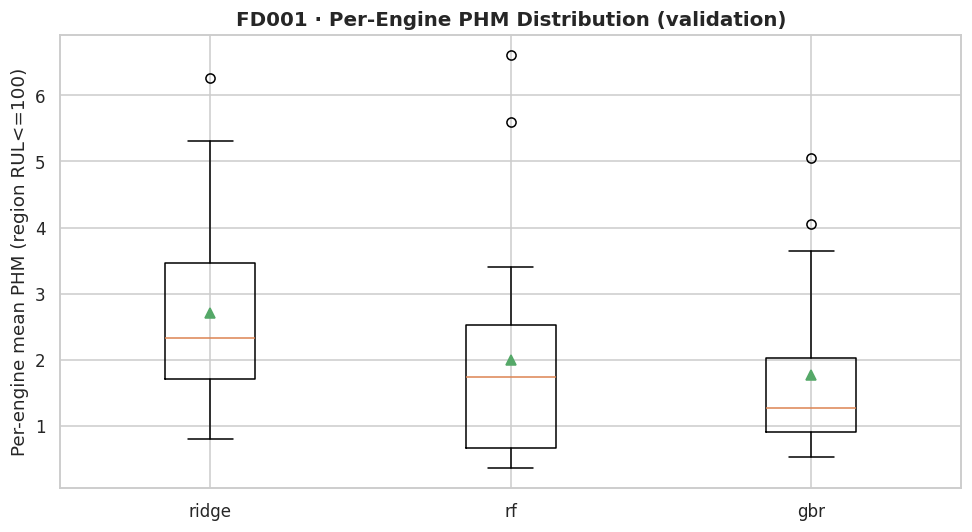

Saved -> figures/FD001_per_engine_phm.png


In [38]:
def per_engine_phm(pred_full):
    contrib = {}
    for e in np.unique(val_engine):
        m = (val_engine == e) & dev
        if m.sum() == 0:
            continue
        contrib[e] = mr.phm_score_mean(yt_full[m], pred_full[m])  
    return pd.Series(contrib)

pe = pd.DataFrame({n: per_engine_phm(preds[n]) for n in ("ridge","rf","gbr")})

summary = pd.DataFrame({
    "row_level_mean_PHM": {n: mr.phm_score_mean(yt_full[dev], preds[n][dev])
                           for n in ("ridge","rf","gbr")},
    "equal_weight_engine_mean_PHM": pe.mean().to_dict(),
})
print(" PHM: ROW-LEVEL vs EQUAL-WEIGHT PER-ENGINE (distinct quantities) ")
print("row_level: every row weighted equally (longer engines contribute more rows)")
print("equal_weight_engine: each engine's mean PHM, then averaged over engines\n")
print(summary.round(4).to_string())

print("\nWorst 5 engines by Ridge per-engine PHM:")
print(pe.sort_values("ridge", ascending=False).head(5).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([pe["ridge"], pe["rf"], pe["gbr"]], labels=["ridge","rf","gbr"],
           showmeans=True)
ax.set_ylabel("Per-engine mean PHM (region RUL<=100)")
ax.set_title(f"{SUBSET} · Per-Engine PHM Distribution (validation)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / f"{SUBSET}_per_engine_phm.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved ->", config.FIGURES_DIR / f"{SUBSET}_per_engine_phm.png")


In [39]:
import time, tempfile, os, joblib

def benchmark_latency(model, X, n_warmup=3, n_rep=20):
    for _ in range(n_warmup):
        model.predict(X)
    times = []
    for _ in range(n_rep):
        t0 = time.perf_counter()
        model.predict(X)
        times.append(time.perf_counter() - t0)
    med_s = float(np.median(times))
    return {
        "batch_size": len(X),
        "model_only_batch_median_ms": round(med_s * 1e3, 4),
        "batch_amortized_us_per_row": round(med_s * 1e6 / len(X), 3),
        "n_warmup": n_warmup, "n_rep": n_rep,
    }

def serialized_estimator_size_mb(model):
    with tempfile.NamedTemporaryFile(delete=False, suffix=".joblib") as tf:
        path = tf.name
    joblib.dump(model, path)
    size = os.path.getsize(path) / (1024 ** 2)
    os.remove(path)
    return round(size, 4)

X_by_model = {"ridge": X_tune_scaled, "rf": X_tune_unscaled, "gbr": X_tune_unscaled}
bench_rows = []
for n in ("ridge", "rf", "gbr"):
    lat = benchmark_latency(fitted_models[n], X_by_model[n])
    lat.update({"model": n,
                "serialized_estimator_size_MB": serialized_estimator_size_mb(fitted_models[n])})
    bench_rows.append(lat)

bench_df = pd.DataFrame(bench_rows)[
    ["model","batch_size","model_only_batch_median_ms",
     "batch_amortized_us_per_row","n_warmup","n_rep",
     "serialized_estimator_size_MB"]]
print(" MODEL-ONLY BATCH INFERENCE LATENCY (perf_counter, warm-up+median) ")
print("NOTE: batch_amortized_us_per_row is throughput-normalized, NOT single-request")
print("      dashboard latency. serialized_estimator_size_MB excludes the feature")
print("      pipeline and other deployment artifacts (total bundle reported later).")
bench_df


 MODEL-ONLY BATCH INFERENCE LATENCY (perf_counter, warm-up+median) 
NOTE: batch_amortized_us_per_row is throughput-normalized, NOT single-request
      dashboard latency. serialized_estimator_size_MB excludes the feature
      pipeline and other deployment artifacts (total bundle reported later).


,model,batch_size,model_only_batch_median_ms,batch_amortized_us_per_row,n_warmup,n_rep,serialized_estimator_size_MB
0,ridge,4098,2.0597,0.503,3,20,0.2336
1,rf,4098,57.7676,14.097,3,20,24.0313
2,gbr,4098,15.6444,3.818,3,20,0.5293


In [40]:
region_rows_per_engine = pd.Series(val_engine[dev]).value_counts()
print("In-region row counts per engine:")
print(f"  min={region_rows_per_engine.min()}, max={region_rows_per_engine.max()}, "
      f"n_engines={len(region_rows_per_engine)}")
all_101 = (region_rows_per_engine == 101).all()
print(f"  All engines contribute exactly 101 rows? {all_101}")

rl = mr.phm_score_mean(yt_full[dev], preds["ridge"][dev])
ew = pe["ridge"].mean()
print(f"\nRidge row-level mean PHM   : {rl:.6f}")
print(f"Ridge equal-weight eng PHM : {ew:.6f}")
print(f"Difference                 : {abs(rl-ew):.6f}")
if all_101:
    print("\n=> Identical values are EXPECTED (equal 101 rows/engine), NOT a bug.")
else:
    print("\n=> Row counts differ; identical values would warrant investigation.")


In-region row counts per engine:
  min=101, max=101, n_engines=20
  All engines contribute exactly 101 rows? True

Ridge row-level mean PHM   : 2.712808
Ridge equal-weight eng PHM : 2.712808
Difference                 : 0.000000

=> Identical values are EXPECTED (equal 101 rows/engine), NOT a bug.


In [41]:
def phm_per_row(y_true, y_pred):
    d = y_pred - y_true
    s = np.empty_like(d)
    late = d >= 0
    s[late] = np.expm1(d[late] / 10.0)
    s[~late] = np.expm1(-d[~late] / 13.0)
    return s

conc_rows = []
for n in ("ridge", "rf", "gbr"):
    s = phm_per_row(yt_full[dev], preds[n][dev])
    total = s.sum()
    s_sorted = np.sort(s)[::-1]
    n_rows = len(s)
    top1 = s_sorted[:max(1, int(0.01 * n_rows))].sum()
    top5 = s_sorted[:max(1, int(0.05 * n_rows))].sum()
    conc_rows.append({
        "model": n,
        "n_rows": n_rows,
        "total_PHM_sum": round(total, 1),
        "top1pct_share": round(top1 / total, 3),
        "top5pct_share": round(top5 / total, 3),
        "max_single_penalty": round(s_sorted[0], 2),
    })
conc_df = pd.DataFrame(conc_rows)
print(" PHM CONCENTRATION: share of total PHM from largest per-row penalties ")
print("(higher top1%/top5% share = score dominated by a few extreme rows)")
conc_df


 PHM CONCENTRATION: share of total PHM from largest per-row penalties 
(higher top1%/top5% share = score dominated by a few extreme rows)


,model,n_rows,total_PHM_sum,top1pct_share,top5pct_share,max_single_penalty
0,ridge,2020,5479.9,0.087,0.283,31.73
1,rf,2020,4050.7,0.124,0.358,40.13
2,gbr,2020,3592.6,0.092,0.308,21.59


## 4.4 · Engine-level bootstrap CIs, paired differences, residual plots, traces

We assess whether Ridge's PHM advantage is robust to **engine resampling**, using
**one shared set of B=1000 engine bootstrap samples** (seed=42) reused for PHM,
MAE, and all paired model differences. The resulting intervals are **validation
engine-bootstrap uncertainty, conditional on the current 30-engine validation
sample** — they are NOT test-set intervals; final test CIs are computed separately
in the locked-evaluation stage. Paired bootstrap (same resamples) yields CIs for
Ridge−RF and Ridge−GBR. We then show residual-vs-true-RUL plots and three
programmatically selected engine traces (worst/median/best per-engine PHM),
restricted to the common region (uncapped RUL ≤ 100). Official test excluded.

In [42]:
val_engines = np.unique(val_engine)
B = 1000
rng = np.random.RandomState(config.RANDOM_SEED)

boot_samples = [rng.choice(val_engines, size=len(val_engines), replace=True)
                for _ in range(B)]

eng_dev = val_engine[dev]
phm_rows = {n: phm_per_row(yt_full[dev], preds[n][dev]) for n in ("ridge","rf","gbr")}
abs_rows = {n: np.abs(preds[n][dev] - yt_full[dev])     for n in ("ridge","rf","gbr")}
eng_to_pos = {e: np.where(eng_dev == e)[0] for e in val_engines}

sample_pos = [np.concatenate([eng_to_pos[e] for e in samp]) for samp in boot_samples]

def boot_means(rows):
    return np.array([rows[pos].mean() for pos in sample_pos])

phm_boot = {n: boot_means(phm_rows[n]) for n in phm_rows}
mae_boot = {n: boot_means(abs_rows[n]) for n in abs_rows}

phm_diff_rf  = phm_boot["ridge"] - phm_boot["rf"]
phm_diff_gbr = phm_boot["ridge"] - phm_boot["gbr"]
mae_diff_rf  = mae_boot["ridge"] - mae_boot["rf"]
mae_diff_gbr = mae_boot["ridge"] - mae_boot["gbr"]

def ci(a): return (round(float(np.percentile(a,2.5)),4),
                   round(float(np.percentile(a,97.5)),4))

print(" ENGINE-BOOTSTRAP 95% CIs (B=1000; shared samples; validation-conditional) ")
ci_tbl = pd.DataFrame({
    "PHM_mean": {n: round(float(phm_boot[n].mean()),4) for n in phm_boot},
    "PHM_CI":   {n: ci(phm_boot[n]) for n in phm_boot},
    "MAE_mean": {n: round(float(mae_boot[n].mean()),4) for n in mae_boot},
    "MAE_CI":   {n: ci(mae_boot[n]) for n in mae_boot},
})
print(ci_tbl.to_string())

print("\n PAIRED BOOTSTRAP DIFFERENCES (Ridge − model); 95% CI; same samples ")
print("(negative => Ridge better; CI excluding 0 => robust within this val sample)")
print(f"  PHM  Ridge−RF : mean={phm_diff_rf.mean():.4f}, CI={ci(phm_diff_rf)}, "
      f"P(diff<0)={np.mean(phm_diff_rf<0):.3f}")
print(f"  PHM  Ridge−GBR: mean={phm_diff_gbr.mean():.4f}, CI={ci(phm_diff_gbr)}, "
      f"P(diff<0)={np.mean(phm_diff_gbr<0):.3f}")
print(f"  MAE  Ridge−RF : mean={mae_diff_rf.mean():.4f}, CI={ci(mae_diff_rf)}, "
      f"P(diff<0)={np.mean(mae_diff_rf<0):.3f}")
print(f"  MAE  Ridge−GBR: mean={mae_diff_gbr.mean():.4f}, CI={ci(mae_diff_gbr)}, "
      f"P(diff<0)={np.mean(mae_diff_gbr<0):.3f}")


 ENGINE-BOOTSTRAP 95% CIs (B=1000; shared samples; validation-conditional) 
       PHM_mean            PHM_CI  MAE_mean            MAE_CI
ridge    2.7340  (2.1107, 3.4243)   10.5321  (9.345, 11.7839)
rf       2.0150  (1.3576, 2.7445)    8.3144  (6.8862, 9.7211)
gbr      1.7891   (1.2954, 2.368)    8.2641  (7.1646, 9.4106)

 PAIRED BOOTSTRAP DIFFERENCES (Ridge − model); 95% CI; same samples 
(negative => Ridge better; CI excluding 0 => robust within this val sample)
  PHM  Ridge−RF : mean=0.7189, CI=(0.1696, 1.1659), P(diff<0)=0.010
  PHM  Ridge−GBR: mean=0.9449, CI=(0.4178, 1.389), P(diff<0)=0.000
  MAE  Ridge−RF : mean=2.2177, CI=(1.1515, 3.2181), P(diff<0)=0.000
  MAE  Ridge−GBR: mean=2.2679, CI=(1.1802, 3.2566), P(diff<0)=0.000


Selected trace engines (Ridge PHM worst/median/best + known 74/1): [1, 46, 54, 74]
  worst=1 (PHM=6.26), median=46 (PHM=2.41), best=54 (PHM=0.81)


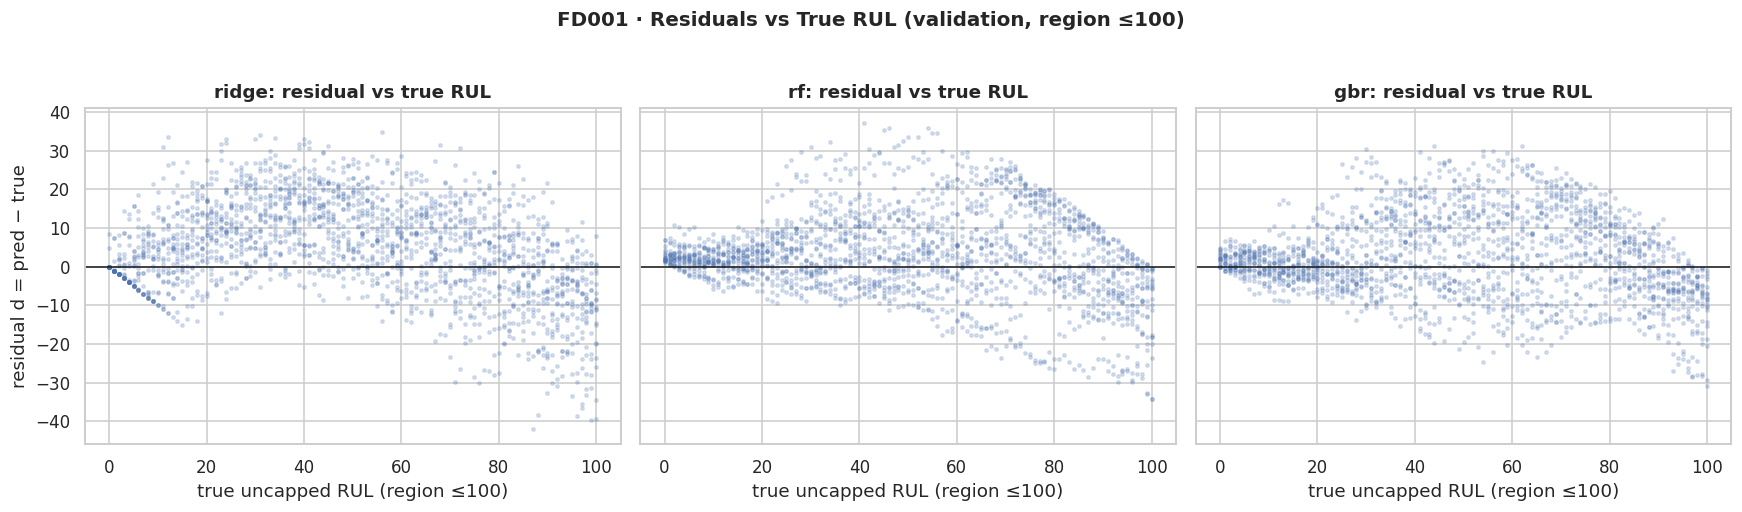

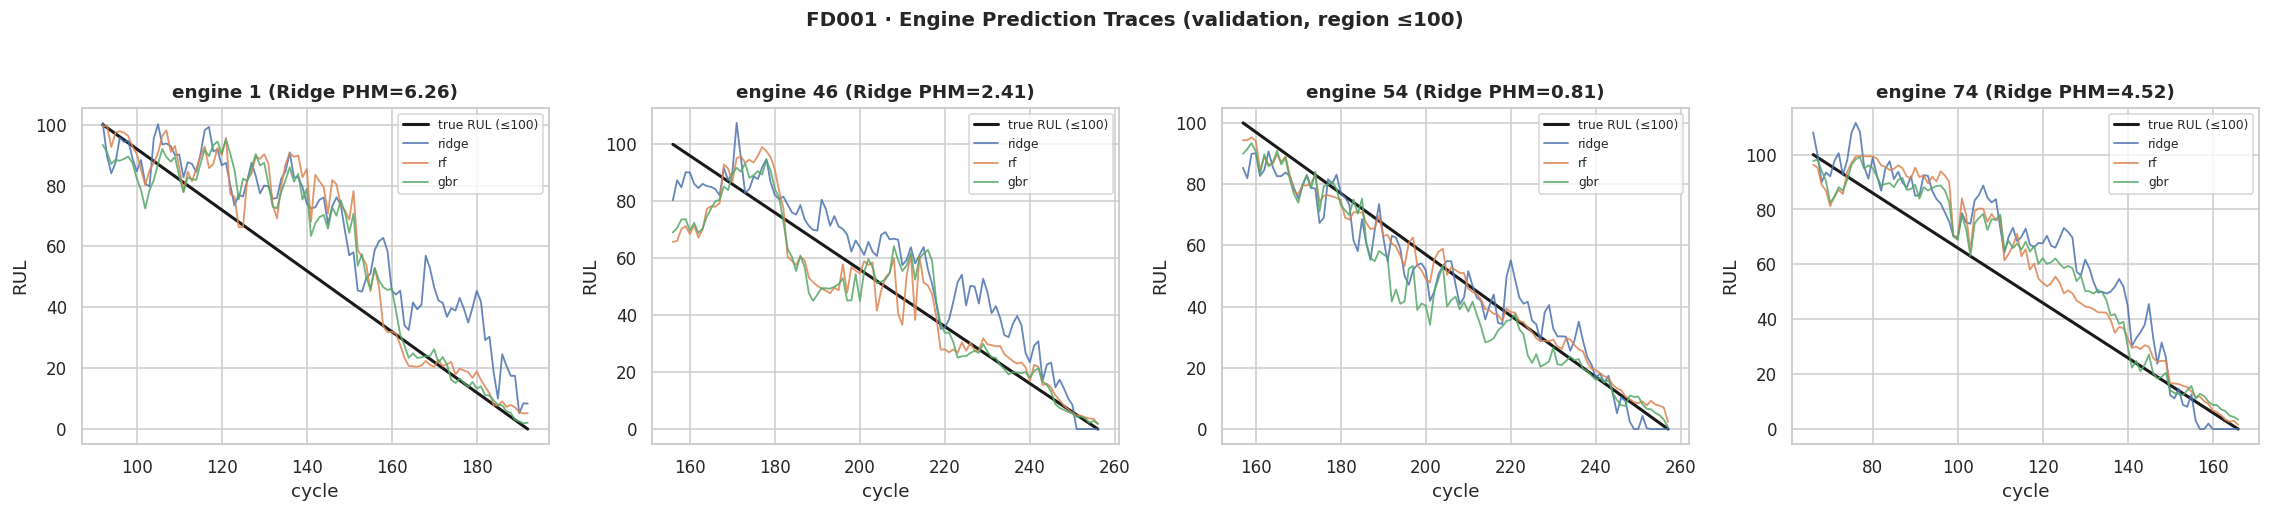

Saved residual + trace figures -> figures


In [43]:
pe_ridge = pe["ridge"].sort_values()
best_e   = int(pe_ridge.index[0])                   
median_e = int(pe_ridge.index[len(pe_ridge)//2])
worst_e  = int(pe_ridge.index[-1])                 
trace_engines = [worst_e, median_e, best_e]
for known in (74, 1):
    if known in set(val_engines) and known not in trace_engines:
        trace_engines.append(known)
print("Selected trace engines (Ridge PHM worst/median/best"
      f"{' + known 74/1' if len(trace_engines)>3 else ''}):", trace_engines)
print(f"  worst={worst_e} (PHM={pe_ridge.iloc[-1]:.2f}), "
      f"median={median_e} (PHM={pe_ridge.iloc[len(pe_ridge)//2]:.2f}), "
      f"best={best_e} (PHM={pe_ridge.iloc[0]:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, n in zip(axes, ("ridge","rf","gbr")):
    d = preds[n][dev] - yt_full[dev]
    ax.scatter(yt_full[dev], d, s=5, alpha=0.2)
    ax.axhline(0, color="k", lw=1)
    ax.set_title(f"{n}: residual vs true RUL", fontweight="bold")
    ax.set_xlabel("true uncapped RUL (region ≤100)")
axes[0].set_ylabel("residual d = pred − true")
plt.suptitle(f"{SUBSET} · Residuals vs True RUL (validation, region ≤100)",
             y=1.03, fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / f"{SUBSET}_residuals_vs_rul.png", dpi=150,
            bbox_inches="tight")
plt.show()

n_tr = len(trace_engines)
fig, axes = plt.subplots(1, n_tr, figsize=(5.2*n_tr, 4.5))
if n_tr == 1: axes = [axes]
for ax, e in zip(axes, trace_engines):
    m = (val_engine == e) & (yt_full <= 100)    
    cyc = val_cycle[m]; order = np.argsort(cyc)
    ax.plot(cyc[order], yt_full[m][order], "k-", lw=2, label="true RUL (≤100)")
    for n, c in [("ridge","C0"),("rf","C1"),("gbr","C2")]:
        ax.plot(cyc[order], preds[n][m][order], c, lw=1.2, alpha=0.85, label=n)
    ax.set_title(f"engine {e} (Ridge PHM={pe['ridge'][e]:.2f})", fontweight="bold")
    ax.set_xlabel("cycle"); ax.set_ylabel("RUL")
    ax.legend(fontsize=8)
plt.suptitle(f"{SUBSET} · Engine Prediction Traces (validation, region ≤100)",
             y=1.03, fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / f"{SUBSET}_engine_traces.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved residual + trace figures ->", config.FIGURES_DIR)


## 5 · RUL Uncertainty — Engine-Level Conformal Prediction Intervals

### Design (Option A: engine-level tune/calibration subdivision)

**Protocol-amendment disclosure (constraint 9):** This tune/calibration
subdivision is a **retrospective protocol correction** made *after* exploratory
analysis and model selection had already used all 30 validation engines. The 10
calibration engines are therefore **not historically unseen** — they were part of
earlier analysis. This is **not** a fully preregistered, untouched-calibration
design. We adopt it to reduce (not eliminate) optimistic bias in interval
calibration, and we obtain a genuinely clean coverage estimate only from the
**sealed official test set** in the final locked evaluation.

**Procedure:**
- Subdivide the 30 validation engines **by engine ID** into **val-tune (20)** and
  **val-calib (10)**.
- **Re-run the predeclared selection** (cap, model, representation, window,
  settings, hyperparameters) using **only val-tune**; do not assume the previous
  30-engine winner survives.
- Point model + all preprocessing (constant-feature decision, scaler) remain
  fitted on the **original training engines only**.
- Estimate split-conformal residual quantiles on **val-calib** to form intervals.

**Reporting rules:**
- Coverage measured on the calibration rows is a **calibration diagnostic only**
  (not independent held-out coverage). **Final empirical coverage is reported on
  the locked official test set** (constraint 2).
- Intervals are **pointwise per-row**; within-engine temporal dependence weakens
  the standard exchangeability assumption, so we also report **per-engine coverage
  distributions**, and optionally an engine-level simultaneous sensitivity
  analysis (constraints 3, 4).
- Target coverage **90%** (95% as sensitivity). Lower RUL bound clipped at 0.

In [44]:
val_engine_ids = sorted(np.unique(df_val["engine_id"]).tolist())
assert len(val_engine_ids) == len(set(VAL_TUNE_IDS) | set(VAL_CALIB_IDS))

TUNE_IDS = sorted(VAL_TUNE_IDS)
CALIB_IDS = sorted(VAL_CALIB_IDS)

assert set(CALIB_IDS).isdisjoint(TUNE_IDS), "tune/calib overlap!"
assert set(TUNE_IDS) | set(CALIB_IDS) == set(val_engine_ids)
assert set(df_val_tune["engine_id"].unique()) == set(TUNE_IDS)
assert set(df_val_calib["engine_id"].unique()) == set(CALIB_IDS)

print("Val-TUNE engines:", TUNE_IDS)
print("Val-CALIB engines:", CALIB_IDS)
print(f"Rows -> tune: {len(df_val_tune)} | calib: {len(df_val_calib)}")

import json
with open(config.DATA_PROCESSED / f"{SUBSET}_val_subdivision.json", "w") as f:
    json.dump({"tune_ids": TUNE_IDS, "calib_ids": CALIB_IDS,
               "seed": config.RANDOM_SEED}, f, indent=2)
print("Saved subdivision ->", config.DATA_PROCESSED / f"{SUBSET}_val_subdivision.json")


Val-TUNE engines: [1, 5, 10, 11, 13, 16, 27, 31, 34, 40, 41, 45, 46, 54, 74, 77, 78, 81, 89, 91]
Val-CALIB engines: [19, 23, 32, 43, 56, 70, 71, 73, 84, 97]
Rows -> tune: 4098 | calib: 2026
Saved subdivision -> data/processed/FD001_val_subdivision.json


In [45]:
import numpy as np

_classification_feature_cache = {}


def get_feats(
    representation,
    window,
    include_settings,
    scaled,
):

    representation = str(representation).lower()

    if representation not in {"baseline", "window"}:
        raise ValueError(
            "representation must be 'baseline' or 'window'"
        )

    effective_window = (
        1
        if representation == "baseline"
        else int(window)
    )

    if effective_window < 1:
        raise ValueError("window must be at least 1")

    cache_key = (
        representation,
        effective_window,
        bool(include_settings),
        bool(scaled),
    )

    if cache_key not in _classification_feature_cache:
        pipeline = fe.FeaturePipeline(
            keep_sensors=keep_sensors,
            keep_settings=keep_settings,
            representation=representation,
            window=effective_window,
            include_settings=bool(include_settings),
        ).fit(df_tr)

        X_train_frame = pipeline.transform(
            df_tr,
            scaled=bool(scaled),
        )[0]

        X_tune_frame = pipeline.transform(
            df_val_tune,
            scaled=bool(scaled),
        )[0]

        X_train = X_train_frame.to_numpy(dtype=float)
        X_tune = X_tune_frame.to_numpy(dtype=float)

        assert X_train.shape[0] == len(df_tr)
        assert X_tune.shape[0] == len(df_val_tune)
        assert X_train.shape[1] == X_tune.shape[1]
        assert np.isfinite(X_train).all()
        assert np.isfinite(X_tune).all()

        _classification_feature_cache[cache_key] = (
            pipeline,
            X_train,
            X_tune,
        )

    return _classification_feature_cache[cache_key]


assert set(df_tr["engine_id"]).isdisjoint(
    set(df_val_tune["engine_id"])
)
assert set(df_tr["engine_id"]).isdisjoint(
    set(df_val_calib["engine_id"])
)
assert set(df_val_tune["engine_id"]).isdisjoint(
    set(df_val_calib["engine_id"])
)

print("Classification feature cache initialized.")
print("Pipeline fit partition: TRAIN")
print("Selection transform partition: VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


Classification feature cache initialized.
Pipeline fit partition: TRAIN
Selection transform partition: VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED


In [46]:
import time

SEL_CAP, SEL_ALPHA = 100, 0.1
WINDOWS = [5, 10, 15, 20]; SETTINGS_OPTS = [False, True]
rul_tr_uncapped = df_tr["RUL"].to_numpy(dtype=float)
rul_tune_uncapped = df_val_tune["RUL"].to_numpy(dtype=float)
tune_dev = rul_tune_uncapped <= 100
ytr_cap = mr.apply_cap(rul_tr_uncapped, SEL_CAP)

abl_rec = []; t0 = time.time()
for win in WINDOWS:
    for inc_set in SETTINGS_OPTS:
        _, Xtr, Xtune = get_feats("window", win, inc_set, scaled=True) 
        m = mr.make_model("ridge", alpha=SEL_ALPHA).fit(Xtr, ytr_cap)
        pv = np.clip(m.predict(Xtune), 0, None)
        yt = rul_tune_uncapped[tune_dev]; yp = pv[tune_dev]
        abl_rec.append({"window": win, "include_settings": inc_set,
                        "n_features": Xtr.shape[1],
                        "tune_PHM_mean_dev": mr.phm_score_mean(yt, yp), 
                        "tune_MAE_dev": mr.mae(yt, yp),
                        "tune_nearfail_MAE": mr.near_failure_mae(rul_tune_uncapped, pv, 30)})

abl_tune = pd.DataFrame(abl_rec)
print(f"TUNE window×settings ablation (Ridge, cap=100, alpha=0.1) in "
      f"{time.time()-t0:.1f}s; test excluded.")
abl_tune.sort_values("tune_PHM_mean_dev").round(4)


TUNE window×settings ablation (Ridge, cap=100, alpha=0.1) in 23.7s; test excluded.


,window,include_settings,n_features,tune_PHM_mean_dev,tune_MAE_dev,tune_nearfail_MAE
2,10,False,121,3.0465,11.1122,9.6591
3,10,True,123,3.0507,11.1161,9.6633
6,20,False,121,3.0802,11.1652,9.0509
7,20,True,123,3.0836,11.1685,9.0545
4,15,False,121,3.0898,11.2022,9.4010
5,15,True,123,3.0946,11.2073,9.4030
0,5,False,121,3.3115,11.4142,10.4768
1,5,True,123,3.3156,11.4160,10.4757


In [47]:
import time, ast, json

screen_tune = results_reg.copy()
rul_tr_uncapped = df_tr["RUL"].to_numpy(dtype=float)
rul_tune_uncapped = df_val_tune["RUL"].to_numpy(dtype=float)
tune_dev = rul_tune_uncapped <= 100

abl_ranked = abl_tune.sort_values("tune_PHM_mean_dev", kind="mergesort").reset_index(drop=True)
best_feat = abl_ranked.iloc[0]
LOCK_WINDOW = int(best_feat["window"])
LOCK_SETTINGS = bool(best_feat["include_settings"])
RIDGE_ALPHA = 0.1  
print(f"Tune-selected feature config: window={LOCK_WINDOW}, "
      f"include_settings={LOCK_SETTINGS} (by tune PHM, full precision)")

def best_tune_hp_filtered(model_name):
    sub = screen_tune[
        (screen_tune.model == model_name) &
        (screen_tune.representation == "window") &
        (screen_tune.cap == 100)
    ].sort_values("tune_PHM_mean_dev", kind="mergesort")
    assert len(sub) > 0, f"no {model_name} window/cap100 rows in screen_tune"
    return ast.literal_eval(sub.iloc[0]["hparams"])

rf_hp  = best_tune_hp_filtered("rf")
gbr_hp = best_tune_hp_filtered("gbr")
rf_params  = {"n_estimators": 200, "min_samples_leaf": rf_hp.get("min_samples_leaf", 5)}
gbr_params = {"n_estimators": 300, "learning_rate": gbr_hp.get("learning_rate", 0.05),
              "max_depth": gbr_hp.get("max_depth", 3)}
print("RF/GBR non-size hparams selected under WINDOW-15/cap=100 screening, "
      f"transferred to window={LOCK_WINDOW}:")
print("  RF :", rf_params, "| GBR:", gbr_params)

_, Xtr_s, Xtune_s = get_feats("window", LOCK_WINDOW, LOCK_SETTINGS, scaled=True)
_, Xtr_u, Xtune_u = get_feats("window", LOCK_WINDOW, LOCK_SETTINGS, scaled=False)
ytr_cap = mr.apply_cap(rul_tr_uncapped, 100)

rows = []; t0 = time.time()
for name, mk, Xtr, Xev in [
    ("ridge", mr.make_model("ridge", alpha=RIDGE_ALPHA), Xtr_s, Xtune_s),
    ("rf",    mr.make_model("rf", **rf_params),          Xtr_u, Xtune_u),
    ("gbr",   mr.make_model("gbr", **gbr_params),        Xtr_u, Xtune_u),
]:
    m = cached_fit_estimator(mk, Xtr, ytr_cap)
    pv = np.clip(m.predict(Xev), 0, None)
    yt = rul_tune_uncapped[tune_dev]; yp = pv[tune_dev]
    rows.append({"model": name,
                 "tune_PHM_mean_dev": mr.phm_score_mean(yt, yp), 
                 "tune_MAE_dev": mr.mae(yt, yp),
                 "tune_RMSE_dev": mr.rmse(yt, yp),                
                 "tune_R2_dev": mr.r2(yt, yp),                  
                 "tune_nearfail_MAE": mr.near_failure_mae(rul_tune_uncapped, pv, 30)})
    print(f"  fitted {name} ({time.time()-t0:.0f}s)", flush=True)

cmp_tune = pd.DataFrame(rows).sort_values("tune_PHM_mean_dev", kind="mergesort")
print("\n TUNE model-family comparison (predeclared-size refit, locked feats) ")
print(cmp_tune.round(4).to_string(index=False))

LOCK_MODEL = str(cmp_tune.iloc[0]["model"])
print(f"\nTUNE-LOCKED regression configuration: model={LOCK_MODEL}, "
      f"window={LOCK_WINDOW}, include_settings={LOCK_SETTINGS}, cap=100")

if LOCK_MODEL == "ridge":
    model_params = {"alpha": RIDGE_ALPHA}
elif LOCK_MODEL == "rf":
    model_params = rf_params
elif LOCK_MODEL == "gbr":
    model_params = gbr_params
else:
    model_params = {}

tune_locked = {
    "subset": SUBSET,
    "status": "tune-locked regression configuration (NOT fully final model)",
    "model": LOCK_MODEL,
    "model_params": model_params,         
    "feature_config": {"representation": "window", "window": LOCK_WINDOW,
                       "include_settings": LOCK_SETTINGS},
    "cap": 100,
    "selected_on": "val_tune (20 engines); calib engines excluded from ranking",
    "hparam_provenance": ("RF/GBR non-size hparams chosen under window-15/cap=100 "
                          "screening, transferred to tune-selected window"),
    "protocol_note": ("retrospective amendment; all 30 val engines examined earlier; "
                      "calib engines reserved for conformal quantiles only; "
                      "final coverage/perf on sealed official test"),
    "tune_PHM_by_model": {r["model"]: float(r["tune_PHM_mean_dev"]) for r in rows},
}
with open(config.DATA_PROCESSED / f"{SUBSET}_tune_locked_regression.json", "w") as f:
    json.dump(tune_locked, f, indent=2)
print("Saved tune-locked config ->",
      config.DATA_PROCESSED / f"{SUBSET}_tune_locked_regression.json")


Tune-selected feature config: window=10, include_settings=False (by tune PHM, full precision)
RF/GBR non-size hparams selected under WINDOW-15/cap=100 screening, transferred to window=10:
  RF : {'n_estimators': 200, 'min_samples_leaf': 5} | GBR: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 3}
  fitted ridge (0s)
  fitted rf (0s)
  fitted gbr (0s)

 TUNE model-family comparison (predeclared-size refit, locked feats) 
model  tune_PHM_mean_dev  tune_MAE_dev  tune_RMSE_dev  tune_R2_dev  tune_nearfail_MAE
ridge             3.0465       11.1122        13.7857       0.7764             9.6591
  gbr             4.5976       11.6992        15.3213       0.7238             6.0320
   rf             4.6203       11.4518        15.2318       0.7271             5.9408

TUNE-LOCKED regression configuration: model=ridge, window=10, include_settings=False, cap=100
Saved tune-locked config -> data/processed/FD001_tune_locked_regression.json


In [48]:
assert LOCK_MODEL == "ridge", "This calibration cell assumes the tune-locked model is Ridge."
CAP = 100

fp_final = fe.FeaturePipeline(
    keep_sensors=keep_sensors, keep_settings=keep_settings,
    representation="window", window=LOCK_WINDOW, include_settings=LOCK_SETTINGS
).fit(df_tr)

Xtr_final    = fp_final.transform(df_tr,        scaled=True)[0].to_numpy(float)
Xcalib_final = fp_final.transform(df_val_calib, scaled=True)[0].to_numpy(float)

ytr_cap = mr.apply_cap(df_tr["RUL"].to_numpy(float), CAP)
ridge_final = mr.make_model("ridge", alpha=RIDGE_ALPHA).fit(Xtr_final, ytr_cap)

pred_calib = np.clip(ridge_final.predict(Xcalib_final), 0, CAP)

legacy_rul_calib_uncapped = df_val_calib["RUL"].to_numpy(float)
ycap_calib = np.minimum(legacy_rul_calib_uncapped, CAP)         
resid_abs_calib = np.abs(pred_calib - ycap_calib)        

q90 = mr.conformal_quantile(resid_abs_calib, 0.90)
q95 = mr.conformal_quantile(resid_abs_calib, 0.95)      

print(" CONFORMAL CALIBRATION (capped-RUL target; 10 calib engines) ")
print(f"Point model: Ridge (train-only), window={LOCK_WINDOW}, cap={CAP}, "
      f"alpha={RIDGE_ALPHA}")
print(f"Calibration rows: {len(resid_abs_calib)} across "
      f"{df_val_calib['engine_id'].nunique()} engines")
print(f"Global conformal quantile q90 = {q90:.4f}  (interval half-width, capped RUL)")
print(f"Global conformal quantile q95 = {q95:.4f}  (sensitivity)")


 CONFORMAL CALIBRATION (capped-RUL target; 10 calib engines) 
Point model: Ridge (train-only), window=10, cap=100, alpha=0.1
Calibration rows: 2026 across 10 engines
Global conformal quantile q90 = 26.1523  (interval half-width, capped RUL)
Global conformal quantile q95 = 29.7328  (sensitivity)


In [49]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

required_names = [
    "rul_calib_uncapped",
    "rul_calib_target",
    "prediction_calib",
    "absolute_residuals_calib",
    "conformal_quantile",
    "conformal_coverage_target",
    "calib_lower",
    "calib_upper",
    "df_val_calib",
    "final_model_name",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]

assert not missing_names, (
    "Run the regression and split-conformal cells first. "
    f"Missing variables: {missing_names}"
)

engine_ids_calib = df_val_calib["engine_id"].to_numpy(dtype=int)

assert len(engine_ids_calib) == len(rul_calib_target)
assert len(prediction_calib) == len(rul_calib_target)
assert len(calib_lower) == len(rul_calib_target)
assert len(calib_upper) == len(rul_calib_target)

covered_calib = (
    (rul_calib_target >= calib_lower)
    & (rul_calib_target <= calib_upper)
)
interval_width_calib = calib_upper - calib_lower

global_coverage = float(covered_calib.mean())
global_average_width = float(interval_width_calib.mean())

assert np.all(calib_lower >= 0.0)
assert np.all(calib_upper <= float(calibration_cap))
assert np.all(calib_lower <= calib_upper)
assert global_coverage >= conformal_coverage_target

rul_regions = np.select(
    [
        rul_calib_uncapped <= 30,
        (rul_calib_uncapped > 30)
        & (rul_calib_uncapped <= 100),
        rul_calib_uncapped > 100,
    ],
    [
        "near_failure",
        "mid_life",
        "early_life",
    ],
    default="unknown",
)

region_records = []

for region_name in (
    "near_failure",
    "mid_life",
    "early_life",
):
    mask = rul_regions == region_name

    if not np.any(mask):
        continue

    region_records.append(
        {
            "subset": SUBSET,
            "partition": "val_calib",
            "region": region_name,
            "n_rows": int(mask.sum()),
            "coverage": float(covered_calib[mask].mean()),
            "average_width_cycles": float(
                interval_width_calib[mask].mean()
            ),
            "mean_absolute_error_cycles": float(
                np.mean(
                    np.abs(
                        rul_calib_target[mask]
                        - prediction_calib[mask]
                    )
                )
            ),
        }
    )

region_diagnostics = pd.DataFrame(region_records)

engine_records = []

for engine_id in np.unique(engine_ids_calib):
    mask = engine_ids_calib == engine_id

    engine_records.append(
        {
            "subset": SUBSET,
            "partition": "val_calib",
            "engine_id": int(engine_id),
            "n_rows": int(mask.sum()),
            "coverage": float(covered_calib[mask].mean()),
            "average_width_cycles": float(
                interval_width_calib[mask].mean()
            ),
            "mean_absolute_error_cycles": float(
                np.mean(
                    np.abs(
                        rul_calib_target[mask]
                        - prediction_calib[mask]
                    )
                )
            ),
        }
    )

engine_diagnostics = pd.DataFrame(engine_records)

engine_maximum_residuals = np.array(
    [
        absolute_residuals_calib[
            engine_ids_calib == engine_id
        ].max()
        for engine_id in np.unique(engine_ids_calib)
    ],
    dtype=float,
)

n_engine_scores = len(engine_maximum_residuals)

engine_rank = min(
    n_engine_scores,
    math.ceil(
        (n_engine_scores + 1)
        * conformal_coverage_target
    ),
)

engine_simultaneous_quantile = float(
    np.sort(engine_maximum_residuals)[engine_rank - 1]
)

fraction_engines_meeting_target = float(
    (
        engine_diagnostics["coverage"]
        >= conformal_coverage_target
    ).mean()
)

diagnostic_contract = {
    "subset": SUBSET,
    "partition": "val_calib",
    "point_model": str(final_model_name),
    "target": f"RUL capped at {calibration_cap} cycles",
    "nominal_pointwise_coverage": float(
        conformal_coverage_target
    ),
    "pointwise_quantile": float(conformal_quantile),
    "calibration_empirical_coverage": global_coverage,
    "calibration_average_width_cycles": (
        global_average_width
    ),
    "n_calibration_rows": int(len(rul_calib_target)),
    "n_calibration_engines": int(n_engine_scores),
    "fraction_engines_meeting_nominal_coverage": (
        fraction_engines_meeting_target
    ),
    "engine_simultaneous_sensitivity_quantile": (
        engine_simultaneous_quantile
    ),
    "interpretation": [
        (
            "Coverage reported here is measured on the same "
            "VAL-CALIB partition used to estimate the quantile."
        ),
        (
            "It is not independent test coverage; independent "
            "evaluation remains deferred to the sealed test set."
        ),
        (
            "Rows within an engine are temporally dependent, so "
            "the effective independent sample size is closer to "
            "the number of engines than to the number of rows."
        ),
        (
            "The engine-level maximum-residual quantile is a "
            "conservative sensitivity diagnostic, not the "
            "deployed pointwise interval."
        ),
    ],
}

results_directory = Path(config.ARTIFACTS) / "results"
processed_directory = Path(config.DATA_PROCESSED)

results_directory.mkdir(parents=True, exist_ok=True)
processed_directory.mkdir(parents=True, exist_ok=True)

region_path = (
    results_directory
    / f"{SUBSET}_rul_conformal_by_region.csv"
)
engine_path = (
    results_directory
    / f"{SUBSET}_rul_conformal_by_engine.csv"
)
diagnostic_path = (
    processed_directory
    / f"{SUBSET}_rul_conformal_diagnostics.json"
)


In [50]:
for dataframe, destination in (
    (region_diagnostics, region_path),
    (engine_diagnostics, engine_path),
):
    temporary_path = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    dataframe.to_csv(temporary_path, index=False)
    temporary_path.replace(destination)

temporary_json = diagnostic_path.with_suffix(
    diagnostic_path.suffix + ".tmp"
)
temporary_json.write_text(
    json.dumps(diagnostic_contract, indent=2),
    encoding="utf-8",
)
temporary_json.replace(diagnostic_path)

print(" SPLIT-CONFORMAL DIAGNOSTICS ")
print("Point model:", final_model_name)
print(
    "Calibration empirical coverage:",
    f"{global_coverage:.4f}",
)
print(
    "Calibration average width:",
    f"{global_average_width:.4f} cycles",
)
print(
    "Fraction of calibration engines meeting target:",
    f"{fraction_engines_meeting_target:.2f}",
)
print(
    "Pointwise residual quantile:",
    f"{conformal_quantile:.4f}",
)
print(
    "Engine-level sensitivity quantile:",
    f"{engine_simultaneous_quantile:.4f}",
)

print("\n BY RUL REGION ")
display(region_diagnostics.round(4))

print("\n BY CALIBRATION ENGINE ")
display(engine_diagnostics.round(4))

print("\nSaved:", region_path)
print("Saved:", engine_path)
print("Saved:", diagnostic_path)
print("Official test status: SEALED")
print("Independent interval coverage evaluation: PENDING")


 SPLIT-CONFORMAL DIAGNOSTICS 
Point model: gbr
Calibration empirical coverage: 0.9008
Calibration average width: 28.4382 cycles
Fraction of calibration engines meeting target: 0.50
Pointwise residual quantile: 18.4134
Engine-level sensitivity quantile: 43.5158

 BY RUL REGION 


,subset,partition,region,n_rows,coverage,average_width_cycles,mean_absolute_error_cycles
0,FD001,val_calib,near_failure,310,1.0000,32.1652,4.0372
1,FD001,val_calib,mid_life,700,0.7929,34.2749,11.2649
2,FD001,val_calib,early_life,1016,0.9449,23.2797,5.1359



 BY CALIBRATION ENGINE 


,subset,partition,engine_id,n_rows,coverage,average_width_cycles,mean_absolute_error_cycles
0,FD001,val_calib,19,158,0.9937,30.0037,4.9090
1,FD001,val_calib,23,168,0.8571,27.1321,7.4746
2,FD001,val_calib,32,191,0.9581,30.1553,6.1496
3,FD001,val_calib,43,207,0.9469,26.4271,3.9784
4,FD001,val_calib,56,275,0.8727,27.9708,8.7328
5,FD001,val_calib,70,137,0.7591,27.9304,11.0068
6,FD001,val_calib,71,208,1.0000,26.9707,4.1837
7,FD001,val_calib,73,213,0.8779,30.6166,9.2962
8,FD001,val_calib,84,267,0.7715,30.3531,10.8163
9,FD001,val_calib,97,202,0.9901,26.4012,3.3557



Saved: artifacts/results/FD001_rul_conformal_by_region.csv
Saved: artifacts/results/FD001_rul_conformal_by_engine.csv
Saved: data/processed/FD001_rul_conformal_diagnostics.json
Official test status: SEALED
Independent interval coverage evaluation: PENDING


## 6 · Failure-Horizon Classification

### Locked development protocol

Each horizon has its own model, probability calibrator, and decision threshold.
A label, calibrator, or threshold fitted for one horizon is never reused for
another horizon.

#### Data roles

- **TRAIN:** fit feature pipelines and classification models.
- **VAL-TUNE:** select feature representation, window length, operating-setting
  inclusion, class weighting, model family, and hyperparameters.
- **VAL-CALIB:** fit probability calibrators and select operational thresholds
  under the declared asymmetric cost.
- **Official TEST:** remains sealed until every model, calibrator, threshold,
  persistence rule, and decision-policy parameter has been frozen.

All feature pipelines are fitted on TRAIN engines only. Validation partitions
are transformed using the already-fitted pipeline. Windows are trailing and
causal, remain within one engine, and never cross partition boundaries.

#### Feature comparison

The transparent Logistic Regression baseline compares:

- current-cycle features;
- causal window features with candidate lengths `5`, `15`, and `30`;
- inclusion versus exclusion of current-cycle operating settings.

The candidate window lengths are taken from `config.FEATURE_WINDOWS`. Feature
selection is horizon-specific and is performed only on VAL-TUNE. The RUL
regression winner is not automatically reused for classification.

#### Model selection

Average Precision (equivalent here to PR-AUC summary) is the primary
model-selection metric because the positive classes are imbalanced. Brier score
is reported during screening as a probability-quality diagnostic but is not used
to inspect or tune the official test set.

Logistic Regression is the required interpretable baseline. After its feature
configuration is selected, it is compared fairly with at least one nonlinear
classifier using the same TRAIN and VAL-TUNE engine partitions.

#### Probability calibration

Each horizon receives a separate Platt calibrator fitted only on VAL-CALIB.
Performance before and after calibration is compared using:

- Brier score;
- reliability curves;
- calibration-bin tables.

After calibration, the probabilities must satisfy:

\[
P(\mathrm{failure}\le10)
\le
P(\mathrm{failure}\le20)
\le
P(\mathrm{failure}\le30)
\]

Any monotonicity correction is documented, and metrics are recomputed after the
correction.

#### Threshold policy

A probability threshold of `0.50` is not assumed to be optimal. Thresholds are
selected on validation data using the declared row-level asymmetric cost, with
false-negative cost greater than false-positive cost. The primary screening
policy uses `FN:FP = 10:1`; `5:1` and `20:1` are reported as sensitivity
analyses.

These row-level thresholds do not constitute the final maintenance policy.
Persistent engine-level alerts and CONTINUE / INSPECT / STOP recommendations
are optimized and audited later.

#### Required evidence

For every horizon, the final evaluation reports:

- precision, recall, and F1;
- PR-AUC;
- Brier score;
- confusion matrix;
- precision–recall curve;
- calibration curve;
- selected validation threshold;
- engine-level bootstrap 95% confidence intervals.

**Current status:** TRAIN is used for fitting, VAL-TUNE for selection,
VAL-CALIB for calibration and threshold development, and the official test set
remains sealed.

In [51]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

import models_classification as mc


CLASSIFICATION_HORIZONS = tuple(
    config.CLASSIFICATION_HORIZONS
)
CLASSIFICATION_WINDOWS = tuple(
    config.FEATURE_WINDOWS
)

assert CLASSIFICATION_HORIZONS == (10, 20, 30)
assert CLASSIFICATION_WINDOWS == (5, 15, 30)

FEATURE_CONFIGURATIONS = [
    ("baseline", 1),
    *[
        ("window", window)
        for window in CLASSIFICATION_WINDOWS
    ],
]

INCLUDE_SETTINGS_OPTIONS = (False, True)
CLASS_WEIGHT_OPTIONS = (None, "balanced")
LOGISTIC_C_VALUES = (0.1, 1.0, 10.0)


def classification_labels(frame, horizon):
    column = f"label_h{int(horizon)}"

    if column not in frame.columns:
        raise KeyError(f"Missing classification label: {column}")

    values = frame[column].to_numpy(dtype=int)

    assert set(np.unique(values)).issubset({0, 1})

    return values


for partition_name, frame in (
    ("train", df_tr),
    ("val_tune", df_val_tune),
):
    y10 = classification_labels(frame, 10)
    y20 = classification_labels(frame, 20)
    y30 = classification_labels(frame, 30)

    assert np.all(y10 <= y20), (
        f"Non-nested labels in {partition_name}: h10 > h20"
    )
    assert np.all(y20 <= y30), (
        f"Non-nested labels in {partition_name}: h20 > h30"
    )


screening_records = []
screening_start = time.perf_counter()

for horizon in CLASSIFICATION_HORIZONS:
    y_train = classification_labels(df_tr, horizon)
    y_tune = classification_labels(df_val_tune, horizon)

    assert y_train.sum() > 0
    assert y_tune.sum() > 0
    assert y_train.sum() < len(y_train)
    assert y_tune.sum() < len(y_tune)

    horizon_start = time.perf_counter()

    for representation, window in FEATURE_CONFIGURATIONS:
        for include_settings in INCLUDE_SETTINGS_OPTIONS:
            feature_pipeline, X_train, X_tune = get_feats(
                representation=representation,
                window=window,
                include_settings=include_settings,
                scaled=True,
            )

            effective_window = (
                None
                if representation == "baseline"
                else int(window)
            )

            for class_weight in CLASS_WEIGHT_OPTIONS:
                for logistic_c in LOGISTIC_C_VALUES:
                    classifier = mc.make_classifier(
                        "logistic",
                        C=float(logistic_c),
                        class_weight=class_weight,
                    )

                    fit_start = time.perf_counter()
                    classifier.fit(X_train, y_train)
                    fit_seconds = (
                        time.perf_counter() - fit_start
                    )

                    inference_start = time.perf_counter()
                    tune_probability = classifier.predict_proba(
                        X_tune
                    )[:, 1]
                    inference_seconds = (
                        time.perf_counter() - inference_start
                    )

                    assert tune_probability.shape == y_tune.shape
                    assert np.isfinite(tune_probability).all()
                    assert np.all(
                        (tune_probability >= 0.0)
                        & (tune_probability <= 1.0)
                    )

                    screening_records.append(
                        {
                            "horizon": int(horizon),
                            "model": "logistic",
                            "representation": representation,
                            "window": effective_window,
                            "include_settings": bool(
                                include_settings
                            ),
                            "class_weight": (
                                "none"
                                if class_weight is None
                                else str(class_weight)
                            ),
                            "C": float(logistic_c),
                            "n_features": int(X_train.shape[1]),
                            "train_positive_rate": float(
                                y_train.mean()
                            ),
                            "tune_positive_rate": float(
                                y_tune.mean()
                            ),
                            "tune_PR_AUC": float(
                                mc.average_precision(
                                    y_tune,
                                    tune_probability,
                                )
                            ),
                            "tune_Brier": float(
                                mc.brier(
                                    y_tune,
                                    tune_probability,
                                )
                            ),
                            "fit_time_seconds": float(
                                fit_seconds
                            ),
                            "inference_us_per_row": float(
                                inference_seconds
                                * 1_000_000.0
                                / len(y_tune)
                            ),
                        }
                    )

    print(
        f"h{horizon} completed in "
        f"{time.perf_counter() - horizon_start:.1f} seconds",
        flush=True,
    )


classification_screening = pd.DataFrame(
    screening_records
)

expected_configurations_per_horizon = (
    len(FEATURE_CONFIGURATIONS)
    * len(INCLUDE_SETTINGS_OPTIONS)
    * len(CLASS_WEIGHT_OPTIONS)
    * len(LOGISTIC_C_VALUES)
)

expected_total_configurations = (
    len(CLASSIFICATION_HORIZONS)
    * expected_configurations_per_horizon
)

assert len(classification_screening) == (
    expected_total_configurations
)
assert not classification_screening.isna()[
    ["tune_PR_AUC", "tune_Brier"]
].any().any()

clf_joint = classification_screening.copy()

results_directory = Path(config.ARTIFACTS) / "results"
results_directory.mkdir(parents=True, exist_ok=True)

screening_path = (
    results_directory
    / f"{SUBSET}_classification_logistic_screening.csv"
)
temporary_path = screening_path.with_suffix(
    screening_path.suffix + ".tmp"
)

classification_screening.to_csv(
    temporary_path,
    index=False,
)
temporary_path.replace(screening_path)

print("\n LOGISTIC CLASSIFICATION SCREENING ")
print("Fit partition: TRAIN")
print("Selection partition: VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")
print(
    "Configurations per horizon:",
    expected_configurations_per_horizon,
)


h10 completed in 17.4 seconds
h20 completed in 10.9 seconds
h30 completed in 11.7 seconds

 LOGISTIC CLASSIFICATION SCREENING 
Fit partition: TRAIN
Selection partition: VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED
Configurations per horizon: 48


In [52]:
print(
    "Total configurations:",
    expected_total_configurations,
)
print(
    "Total runtime:",
    f"{time.perf_counter() - screening_start:.1f} seconds",
)

for horizon in CLASSIFICATION_HORIZONS:
    horizon_ranking = (
        classification_screening[
            classification_screening["horizon"]
            == horizon
        ]
        .sort_values(
            ["tune_PR_AUC", "tune_Brier"],
            ascending=[False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    print(
        f"\n HORIZON {horizon}: TOP 8 "
        "BY VAL-TUNE PR-AUC "
    )

    display(
        horizon_ranking[
            [
                "model",
                "representation",
                "window",
                "include_settings",
                "class_weight",
                "C",
                "n_features",
                "tune_PR_AUC",
                "tune_Brier",
                "fit_time_seconds",
                "inference_us_per_row",
            ]
        ]
        .head(8)
        .round(6)
    )

print("\nSaved screening table:", screening_path)
print(
    "No probability calibrator or threshold "
    "has been fitted yet."
)


Total configurations: 144
Total runtime: 40.2 seconds

 HORIZON 10: TOP 8 BY VAL-TUNE PR-AUC 


,model,representation,window,include_settings,class_weight,C,n_features,tune_PR_AUC,tune_Brier,fit_time_seconds,inference_us_per_row
0,logistic,window,30.0,True,balanced,10.0,123,0.968713,0.023450,0.142277,0.410212
1,logistic,window,30.0,False,balanced,10.0,121,0.968334,0.023445,0.140295,0.427163
2,logistic,window,30.0,False,none,0.1,121,0.966315,0.007661,0.187478,0.726460
3,logistic,window,30.0,True,none,0.1,123,0.966278,0.007696,0.174710,0.304152
4,logistic,window,5.0,True,balanced,0.1,123,0.961131,0.075676,0.081931,1.271749
5,logistic,window,5.0,False,balanced,0.1,121,0.961120,0.075681,0.087102,0.811604
6,logistic,window,5.0,False,balanced,1.0,121,0.961090,0.041265,0.106438,0.484175
7,logistic,window,5.0,True,balanced,1.0,123,0.961079,0.041250,0.107006,0.386415



 HORIZON 20: TOP 8 BY VAL-TUNE PR-AUC 


,model,representation,window,include_settings,class_weight,C,n_features,tune_PR_AUC,tune_Brier,fit_time_seconds,inference_us_per_row
0,logistic,window,30.0,False,none,0.1,121,0.983083,0.010646,0.206410,1.669450
1,logistic,window,30.0,True,none,0.1,123,0.983030,0.010618,0.171035,0.658080
2,logistic,window,30.0,False,balanced,10.0,121,0.978895,0.026126,0.094299,1.023568
3,logistic,window,30.0,True,balanced,10.0,123,0.978786,0.026086,0.108091,0.370631
4,logistic,window,5.0,False,balanced,10.0,121,0.968573,0.030034,0.119749,0.709039
5,logistic,window,5.0,True,balanced,10.0,123,0.968556,0.029994,0.092832,0.408614
6,logistic,window,5.0,True,balanced,1.0,123,0.968516,0.041114,0.110126,0.414072
7,logistic,window,5.0,False,balanced,1.0,121,0.968506,0.041124,0.091611,0.574799



 HORIZON 30: TOP 8 BY VAL-TUNE PR-AUC 


,model,representation,window,include_settings,class_weight,C,n_features,tune_PR_AUC,tune_Brier,fit_time_seconds,inference_us_per_row
0,logistic,window,30.0,True,none,0.1,123,0.987021,0.014024,0.184569,0.327444
1,logistic,window,30.0,False,none,0.1,121,0.986935,0.014028,0.159893,0.462637
2,logistic,window,30.0,False,balanced,10.0,121,0.980855,0.031618,0.204435,0.383636
3,logistic,window,30.0,True,balanced,10.0,123,0.980725,0.031660,0.108916,0.374969
4,logistic,window,30.0,False,none,1.0,121,0.977202,0.014415,0.297440,0.318014
5,logistic,window,30.0,True,none,1.0,123,0.977181,0.014385,0.408020,0.587925
6,logistic,window,15.0,False,none,1.0,121,0.976777,0.019027,0.350030,0.562984
7,logistic,window,15.0,True,none,1.0,123,0.976587,0.019078,0.392444,0.309846



Saved screening table: artifacts/results/FD001_classification_logistic_screening.csv
No probability calibrator or threshold has been fitted yet.


In [53]:
import json
from pathlib import Path

import numpy as np
import pandas as pd


selected_logistic_configs = {}
selected_logistic_records = []

for horizon in CLASSIFICATION_HORIZONS:
    horizon_candidates = (
        classification_screening[
            classification_screening["horizon"]
            == horizon
        ]
        .sort_values(
            ["tune_PR_AUC", "tune_Brier"],
            ascending=[False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    assert not horizon_candidates.empty

    winner = horizon_candidates.iloc[0]

    selected_window = (
        None
        if winner["representation"] == "baseline"
        else int(winner["window"])
    )

    selected_class_weight = (
        None
        if winner["class_weight"] == "none"
        else str(winner["class_weight"])
    )

    selected_config = {
        "model": "logistic",
        "representation": str(
            winner["representation"]
        ),
        "window": selected_window,
        "include_settings": bool(
            winner["include_settings"]
        ),
        "class_weight": selected_class_weight,
        "C": float(winner["C"]),
        "n_features": int(winner["n_features"]),
        "selection_partition": "val_tune",
        "primary_metric": "PR_AUC",
        "tune_PR_AUC": float(
            winner["tune_PR_AUC"]
        ),
        "tune_Brier_raw": float(
            winner["tune_Brier"]
        ),
    }

    selected_logistic_configs[int(horizon)] = (
        selected_config
    )

    selected_logistic_records.append(
        {
            "horizon": int(horizon),
            **selected_config,
        }
    )


selected_logistic_table = pd.DataFrame(
    selected_logistic_records
)

sel_clf = selected_logistic_configs


pairwise_records = []

for horizon in CLASSIFICATION_HORIZONS:
    selected = selected_logistic_configs[horizon]

    class_weight_text = (
        "none"
        if selected["class_weight"] is None
        else selected["class_weight"]
    )

    common_mask = (
        (
            classification_screening["horizon"]
            == horizon
        )
        & (
            classification_screening["include_settings"]
            == selected["include_settings"]
        )
        & (
            classification_screening["class_weight"]
            == class_weight_text
        )
        & np.isclose(
            classification_screening["C"],
            selected["C"],
        )
    )

    comparable_candidates = (
        classification_screening[common_mask]
        .copy()
    )

    baseline_candidates = comparable_candidates[
        comparable_candidates["representation"]
        == "baseline"
    ]

    window_candidates = comparable_candidates[
        comparable_candidates["representation"]
        == "window"
    ]

    assert len(baseline_candidates) == 1
    assert len(window_candidates) == len(
        CLASSIFICATION_WINDOWS
    )

    baseline_result = baseline_candidates.iloc[0]

    best_window_result = (
        window_candidates
        .sort_values(
            ["tune_PR_AUC", "tune_Brier"],
            ascending=[False, True],
            kind="mergesort",
        )
        .iloc[0]
    )

    pairwise_records.append(
        {
            "horizon": int(horizon),
            "model": "logistic",
            "C": float(selected["C"]),
            "class_weight": class_weight_text,
            "include_settings": bool(
                selected["include_settings"]
            ),
            "baseline_n_features": int(
                baseline_result["n_features"]
            ),
            "baseline_tune_PR_AUC": float(
                baseline_result["tune_PR_AUC"]
            ),
            "best_window": int(
                best_window_result["window"]
            ),
            "window_n_features": int(
                best_window_result["n_features"]
            ),
            "window_tune_PR_AUC": float(
                best_window_result["tune_PR_AUC"]
            ),
            "PR_AUC_absolute_improvement": float(
                best_window_result["tune_PR_AUC"]
                - baseline_result["tune_PR_AUC"]
            ),
            "PR_AUC_relative_improvement_percent": (
                float(
                    (
                        best_window_result["tune_PR_AUC"]
                        - baseline_result["tune_PR_AUC"]
                    )
                    / baseline_result["tune_PR_AUC"]
                    * 100.0
                )
            ),
        }
    )


classification_pairwise = pd.DataFrame(
    pairwise_records
)

assert (
    classification_pairwise[
        "PR_AUC_absolute_improvement"
    ]
    > 0
).all(), (
    "At least one selected window does not outperform "
    "the controlled current-cycle baseline."
)



processed_directory = Path(config.DATA_PROCESSED)
results_directory = Path(config.ARTIFACTS) / "results"

processed_directory.mkdir(parents=True, exist_ok=True)
results_directory.mkdir(parents=True, exist_ok=True)

selection_path = (
    processed_directory
    / f"{SUBSET}_classification_logistic_selected.json"
)

pairwise_path = (
    results_directory
    / f"{SUBSET}_classification_baseline_vs_window.csv"
)

selection_contract = {
    "subset": SUBSET,
    "task": "failure_horizon_classification",
    "horizons": [
        int(horizon)
        for horizon in CLASSIFICATION_HORIZONS
    ],
    "fit_partition": "train",
    "selection_partition": "val_tune",
    "calibration_partition": "val_calib",
    "official_test_status": "sealed",
    "primary_selection_metric": "PR_AUC",
    "tie_breaker": "lower raw Brier score",
    "selected_logistic_models": {
        str(horizon): selected_logistic_configs[horizon]
        for horizon in CLASSIFICATION_HORIZONS
    },
}


In [54]:
temporary_selection_path = selection_path.with_suffix(
    selection_path.suffix + ".tmp"
)
temporary_selection_path.write_text(
    json.dumps(selection_contract, indent=2),
    encoding="utf-8",
)
temporary_selection_path.replace(selection_path)

temporary_pairwise_path = pairwise_path.with_suffix(
    pairwise_path.suffix + ".tmp"
)
classification_pairwise.to_csv(
    temporary_pairwise_path,
    index=False,
)
temporary_pairwise_path.replace(pairwise_path)


print(" SELECTED LOGISTIC CONFIGURATION PER HORIZON ")
display(
    selected_logistic_table[
        [
            "horizon",
            "representation",
            "window",
            "include_settings",
            "class_weight",
            "C",
            "n_features",
            "tune_PR_AUC",
            "tune_Brier_raw",
        ]
    ].round(6)
)

print("\n CONTROLLED BASELINE VS WINDOW COMPARISON ")
display(classification_pairwise.round(6))

print("\nSaved selection contract:", selection_path)
print("Saved pairwise comparison:", pairwise_path)
print("Selection role: VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")
print(
    "Next requirement: compare Logistic Regression "
    "with nonlinear classifiers."
)


 SELECTED LOGISTIC CONFIGURATION PER HORIZON 


,horizon,representation,window,include_settings,class_weight,C,n_features,tune_PR_AUC,tune_Brier_raw
0,10,window,30,True,balanced,10.0,123,0.968713,0.023450
1,20,window,30,False,None,0.1,121,0.983083,0.010646
2,30,window,30,True,None,0.1,123,0.987021,0.014024



 CONTROLLED BASELINE VS WINDOW COMPARISON 


,horizon,model,C,class_weight,include_settings,baseline_n_features,baseline_tune_PR_AUC,best_window,window_n_features,window_tune_PR_AUC,PR_AUC_absolute_improvement,PR_AUC_relative_improvement_percent
0,10,logistic,10.0,balanced,True,17,0.944130,30,123,0.968713,0.024584,2.603852
1,20,logistic,0.1,none,False,15,0.961507,30,121,0.983083,0.021575,2.243919
2,30,logistic,0.1,none,True,17,0.966085,30,123,0.987021,0.020935,2.167038



Saved selection contract: data/processed/FD001_classification_logistic_selected.json
Saved pairwise comparison: artifacts/results/FD001_classification_baseline_vs_window.csv
Selection role: VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED
Next requirement: compare Logistic Regression with nonlinear classifiers.


### 6.1 · Model-family comparison per horizon (controlled, Logistic-selected features)

For each horizon we apply the **Logistic-selected feature configuration**
(built programmatically from the joint Logistic screening `sel_clf`) **uniformly**
to Logistic, Random Forest, and classic Gradient Boosting. These features were
selected **Logistic-conditionally** and are used uniformly for a **controlled
model-family comparison**; they are **not claimed independently optimal for tree
models**. Random Forest is compared with class_weight ∈ {None, "balanced"}.

Primary metric: full-precision val-tune **Average Precision (AP)**. Threshold-0.5
metrics and raw Brier are **pre-calibration diagnostics only** (0.5 is NOT the
deployment threshold; explicit `_diag` column names). Positive prevalence and
AP/prevalence are **descriptive cross-horizon context**, not selection criteria.

Data roles: fit on **TRAIN**; rank on **VAL-TUNE**; **VAL-CALIB and official TEST
excluded** (asserted below).

In [55]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd


train_engine_set = set(
    df_tr["engine_id"].astype(int).unique()
)
tune_engine_set = set(
    df_val_tune["engine_id"].astype(int).unique()
)
calib_engine_set = set(
    df_val_calib["engine_id"].astype(int).unique()
)

assert train_engine_set.isdisjoint(tune_engine_set)
assert train_engine_set.isdisjoint(calib_engine_set)
assert tune_engine_set.isdisjoint(calib_engine_set)


classification_feature_config_by_horizon = {}

for horizon in CLASSIFICATION_HORIZONS:
    selected = selected_logistic_configs[horizon]

    representation = selected["representation"]
    window = selected["window"]

    assert representation in {"baseline", "window"}

    if representation == "window":
        assert window in CLASSIFICATION_WINDOWS
    else:
        assert window is None

    classification_feature_config_by_horizon[horizon] = {
        "representation": representation,
        "window": window,
        "include_settings": bool(
            selected["include_settings"]
        ),
    }


RANDOM_FOREST_GRID = [
    {
        "n_estimators": 200,
        "min_samples_leaf": minimum_leaf,
        "class_weight": class_weight,
    }
    for minimum_leaf in (3, 5)
    for class_weight in (None, "balanced")
]

GRADIENT_BOOSTING_GRID = [
    {
        "n_estimators": 300,
        "learning_rate": learning_rate,
        "max_depth": 3,
    }
    for learning_rate in (0.05, 0.1)
]


classification_family_records = []
fitted_classifier_candidates = {}

comparison_start = time.perf_counter()


def fit_and_evaluate_classifier(
    horizon,
    model_name,
    model_parameters,
    X_train,
    X_tune,
    y_train,
    y_tune,
):
    model = mc.make_classifier(
        model_name,
        **model_parameters,
    )

    fit_start = time.perf_counter()
    model = cached_fit_estimator(
        model, X_train, y_train
    )
    fit_seconds = time.perf_counter() - fit_start

    inference_start = time.perf_counter()
    tune_probability = model.predict_proba(
        X_tune
    )[:, 1]
    inference_seconds = (
        time.perf_counter() - inference_start
    )

    assert tune_probability.shape == y_tune.shape
    assert np.isfinite(tune_probability).all()
    assert np.all(
        (tune_probability >= 0.0)
        & (tune_probability <= 1.0)
    )

    threshold_diagnostics = (
        mc.clf_metrics_at_threshold(
            y_tune,
            tune_probability,
            0.5,
        )
    )

    parameters_json = json.dumps(
        model_parameters,
        sort_keys=True,
    )

    candidate_key = (
        int(horizon),
        model_name,
        parameters_json,
    )
    fitted_classifier_candidates[candidate_key] = model

    classification_family_records.append(
        {
            "horizon": int(horizon),
            "model": model_name,
            "parameters_json": parameters_json,
            "representation": (
                classification_feature_config_by_horizon[
                    horizon
                ]["representation"]
            ),
            "window": (
                classification_feature_config_by_horizon[
                    horizon
                ]["window"]
            ),
            "include_settings": (
                classification_feature_config_by_horizon[
                    horizon
                ]["include_settings"]
            ),
            "n_features": int(X_train.shape[1]),
            "tune_prevalence": float(y_tune.mean()),
            "tune_PR_AUC": float(
                mc.average_precision(
                    y_tune,
                    tune_probability,
                )
            ),
            "tune_Brier_raw": float(
                mc.brier(
                    y_tune,
                    tune_probability,
                )
            ),
            "precision_at_0_5_diagnostic": float(
                threshold_diagnostics["precision"]
            ),
            "recall_at_0_5_diagnostic": float(
                threshold_diagnostics["recall"]
            ),
            "f1_at_0_5_diagnostic": float(
                threshold_diagnostics["f1"]
            ),
            "tp_at_0_5_diagnostic": int(
                threshold_diagnostics["tp"]
            ),
            "fp_at_0_5_diagnostic": int(
                threshold_diagnostics["fp"]
            ),
            "fn_at_0_5_diagnostic": int(
                threshold_diagnostics["fn"]
            ),
            "tn_at_0_5_diagnostic": int(
                threshold_diagnostics["tn"]
            ),
            "fit_time_seconds": float(fit_seconds),
            "inference_us_per_row": float(
                inference_seconds
                * 1_000_000.0
                / len(y_tune)
            ),
        }
    )


for horizon in CLASSIFICATION_HORIZONS:
    horizon_start = time.perf_counter()

    selected = selected_logistic_configs[horizon]
    feature_config = (
        classification_feature_config_by_horizon[
            horizon
        ]
    )

    representation = feature_config["representation"]
    effective_window = (
        1
        if representation == "baseline"
        else feature_config["window"]
    )

    y_train = classification_labels(
        df_tr,
        horizon,
    )
    y_tune = classification_labels(
        df_val_tune,
        horizon,
    )

    _, X_train_scaled, X_tune_scaled = get_feats(
        representation=representation,
        window=effective_window,
        include_settings=feature_config[
            "include_settings"
        ],
        scaled=True,
    )

    _, X_train_unscaled, X_tune_unscaled = get_feats(
        representation=representation,
        window=effective_window,
        include_settings=feature_config[
            "include_settings"
        ],
        scaled=False,
    )

    logistic_parameters = {
        "C": float(selected["C"]),
        "class_weight": selected["class_weight"],
    }

    fit_and_evaluate_classifier(
        horizon=horizon,
        model_name="logistic",
        model_parameters=logistic_parameters,
        X_train=X_train_scaled,
        X_tune=X_tune_scaled,
        y_train=y_train,
        y_tune=y_tune,
    )

    for random_forest_parameters in RANDOM_FOREST_GRID:
        fit_and_evaluate_classifier(
            horizon=horizon,
            model_name="rf",
            model_parameters=random_forest_parameters,
            X_train=X_train_unscaled,
            X_tune=X_tune_unscaled,
            y_train=y_train,
            y_tune=y_tune,
        )

    for gradient_boosting_parameters in (
        GRADIENT_BOOSTING_GRID
    ):
        fit_and_evaluate_classifier(
            horizon=horizon,
            model_name="gbr",
            model_parameters=gradient_boosting_parameters,
            X_train=X_train_unscaled,
            X_tune=X_tune_unscaled,
            y_train=y_train,
            y_tune=y_tune,
        )

    print(
        f"h{horizon} completed in "
        f"{time.perf_counter() - horizon_start:.1f} seconds",
        flush=True,
    )


h10 completed in 3.6 seconds
h20 completed in 3.8 seconds
h30 completed in 0.7 seconds


In [56]:
classification_family_comparison = pd.DataFrame(
    classification_family_records
)

expected_candidates_per_horizon = (
    1
    + len(RANDOM_FOREST_GRID)
    + len(GRADIENT_BOOSTING_GRID)
)

assert len(classification_family_comparison) == (
    len(CLASSIFICATION_HORIZONS)
    * expected_candidates_per_horizon
)

assert not classification_family_comparison[
    ["tune_PR_AUC", "tune_Brier_raw"]
].isna().any().any()

clf_family = classification_family_comparison.copy()


results_directory = Path(config.ARTIFACTS) / "results"
results_directory.mkdir(parents=True, exist_ok=True)

comparison_path = (
    results_directory
    / f"{SUBSET}_classification_model_family_comparison.csv"
)

temporary_path = comparison_path.with_suffix(
    comparison_path.suffix + ".tmp"
)

classification_family_comparison.to_csv(
    temporary_path,
    index=False,
)
temporary_path.replace(comparison_path)


print("\n CLASSIFICATION MODEL-FAMILY COMPARISON ")
print("Fit partition: TRAIN")
print("Ranking partition: VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")
print(
    "Candidates per horizon:",
    expected_candidates_per_horizon,
)
print(
    "Total candidates:",
    len(classification_family_comparison),
)
print(
    "Total runtime:",
    f"{time.perf_counter() - comparison_start:.1f} seconds",
)

display_columns = [
    "model",
    "parameters_json",
    "n_features",
    "tune_PR_AUC",
    "tune_Brier_raw",
    "precision_at_0_5_diagnostic",
    "recall_at_0_5_diagnostic",
    "f1_at_0_5_diagnostic",
    "fit_time_seconds",
    "inference_us_per_row",
]

for horizon in CLASSIFICATION_HORIZONS:
    horizon_ranking = (
        classification_family_comparison[
            classification_family_comparison[
                "horizon"
            ]
            == horizon
        ]
        .sort_values(
            ["tune_PR_AUC", "tune_Brier_raw"],
            ascending=[False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    print(
        f"\n HORIZON {horizon}: MODEL-FAMILY RANKING "
    )
    display(
        horizon_ranking[
            display_columns
        ].round(6)
    )

print("\nSaved comparison:", comparison_path)
print(
    "Threshold 0.5 metrics are diagnostics only; "
    "they are not deployment thresholds."
)



 CLASSIFICATION MODEL-FAMILY COMPARISON 
Fit partition: TRAIN
Ranking partition: VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED
Candidates per horizon: 7
Total candidates: 21
Total runtime: 8.1 seconds

 HORIZON 10: MODEL-FAMILY RANKING 


,model,parameters_json,n_features,tune_PR_AUC,tune_Brier_raw,precision_at_0_5_diagnostic,recall_at_0_5_diagnostic,f1_at_0_5_diagnostic,fit_time_seconds,inference_us_per_row
0,logistic,"{""C"": 10.0, ""class_weight"": ""balanced""}",123,0.968713,0.023450,0.604396,1.000000,0.753425,0.022108,0.320812
1,rf,"{""class_weight"": null, ""min_samples_leaf"": 3, ...",123,0.960980,0.009276,0.926108,0.854545,0.888889,0.065055,10.682868
2,rf,"{""class_weight"": null, ""min_samples_leaf"": 5, ...",123,0.957663,0.009624,0.921182,0.850000,0.884161,0.072631,8.963237
3,gbr,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti...",123,0.954976,0.010560,0.905473,0.827273,0.864608,0.041505,3.603007
4,gbr,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",123,0.952037,0.010180,0.914573,0.827273,0.868735,0.032571,2.690206
5,rf,"{""class_weight"": ""balanced"", ""min_samples_leaf...",123,0.937413,0.010697,0.857143,0.927273,0.890830,0.066878,9.229167
6,rf,"{""class_weight"": ""balanced"", ""min_samples_leaf...",123,0.936377,0.010814,0.862385,0.854545,0.858447,0.061823,10.848799



 HORIZON 20: MODEL-FAMILY RANKING 


,model,parameters_json,n_features,tune_PR_AUC,tune_Brier_raw,precision_at_0_5_diagnostic,recall_at_0_5_diagnostic,f1_at_0_5_diagnostic,fit_time_seconds,inference_us_per_row
0,logistic,"{""C"": 0.1, ""class_weight"": null}",121,0.983088,0.010646,0.912844,0.947619,0.929907,0.025411,0.284863
1,rf,"{""class_weight"": null, ""min_samples_leaf"": 3, ...",121,0.982987,0.012034,0.943350,0.911905,0.927361,0.064720,11.258879
2,rf,"{""class_weight"": ""balanced"", ""min_samples_leaf...",121,0.982791,0.012485,0.919622,0.926190,0.922894,0.065624,8.165449
3,rf,"{""class_weight"": ""balanced"", ""min_samples_leaf...",121,0.982156,0.012849,0.906178,0.942857,0.924154,0.064909,8.760618
4,rf,"{""class_weight"": null, ""min_samples_leaf"": 5, ...",121,0.981837,0.012529,0.931373,0.904762,0.917874,0.065403,8.835338
5,gbr,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti...",121,0.979734,0.013187,0.949239,0.890476,0.918919,0.033612,2.264478
6,gbr,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",121,0.979712,0.012671,0.949109,0.888095,0.917589,0.031638,3.926390



 HORIZON 30: MODEL-FAMILY RANKING 


,model,parameters_json,n_features,tune_PR_AUC,tune_Brier_raw,precision_at_0_5_diagnostic,recall_at_0_5_diagnostic,f1_at_0_5_diagnostic,fit_time_seconds,inference_us_per_row
0,logistic,"{""C"": 0.1, ""class_weight"": null}",123,0.987021,0.014024,0.956667,0.925806,0.940984,0.024222,0.637718
1,rf,"{""class_weight"": ""balanced"", ""min_samples_leaf...",123,0.982935,0.017933,0.937919,0.901613,0.919408,0.065411,11.179495
2,gbr,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti...",123,0.982274,0.018595,0.964539,0.877419,0.918919,0.033181,2.932983
3,gbr,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",123,0.981647,0.018211,0.960993,0.874194,0.915541,0.035358,2.394301
4,rf,"{""class_weight"": ""balanced"", ""min_samples_leaf...",123,0.981626,0.018558,0.923077,0.929032,0.926045,0.069223,8.405676
5,rf,"{""class_weight"": null, ""min_samples_leaf"": 3, ...",123,0.981366,0.018511,0.949740,0.883871,0.915622,0.065602,8.778710
6,rf,"{""class_weight"": null, ""min_samples_leaf"": 5, ...",123,0.980492,0.018894,0.943493,0.888710,0.915282,0.104356,14.203210



Saved comparison: artifacts/results/FD001_classification_model_family_comparison.csv
Threshold 0.5 metrics are diagnostics only; they are not deployment thresholds.


In [57]:
import hashlib
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


selected_classifier_configs = {}
selected_classifier_models = {}
selected_classifier_pipelines = {}
selected_classifier_records = {}

for horizon in CLASSIFICATION_HORIZONS:
    horizon_ranking = (
        classification_family_comparison[
            classification_family_comparison[
                "horizon"
            ]
            == horizon
        ]
        .sort_values(
            ["tune_PR_AUC", "tune_Brier_raw"],
            ascending=[False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    assert not horizon_ranking.empty

    winner = horizon_ranking.iloc[0]

    model_name = str(winner["model"])
    parameters_json = str(
        winner["parameters_json"]
    )
    model_parameters = json.loads(parameters_json)

    candidate_key = (
        int(horizon),
        model_name,
        parameters_json,
    )

    assert candidate_key in fitted_classifier_candidates, (
        f"Fitted candidate missing for h{horizon}: "
        f"{candidate_key}"
    )

    selected_model = fitted_classifier_candidates[
        candidate_key
    ]

    feature_config = dict(
        classification_feature_config_by_horizon[
            horizon
        ]
    )

    representation = feature_config["representation"]
    effective_window = (
        1
        if representation == "baseline"
        else int(feature_config["window"])
    )

    uses_scaled_features = model_name == "logistic"

    selected_pipeline, X_train_selected, X_tune_selected = (
        get_feats(
            representation=representation,
            window=effective_window,
            include_settings=feature_config[
                "include_settings"
            ],
            scaled=uses_scaled_features,
        )
    )

    tune_probability = selected_model.predict_proba(
        X_tune_selected
    )[:, 1]

    recomputed_pr_auc = float(
        mc.average_precision(
            classification_labels(
                df_val_tune,
                horizon,
            ),
            tune_probability,
        )
    )

    assert np.isclose(
        recomputed_pr_auc,
        float(winner["tune_PR_AUC"]),
        rtol=0.0,
        atol=1e-12,
    )

    selected_classifier_models[horizon] = selected_model
    selected_classifier_pipelines[horizon] = (
        selected_pipeline
    )

    selected_config = {
        "horizon": int(horizon),
        "model_family": model_name,
        "model_parameters": model_parameters,
        "feature_config": {
            "representation": representation,
            "window": feature_config["window"],
            "include_settings": bool(
                feature_config["include_settings"]
            ),
            "scaled": bool(uses_scaled_features),
            "n_features": int(
                X_train_selected.shape[1]
            ),
        },
        "fit_partition": "train",
        "selection_partition": "val_tune",
        "primary_metric": "PR_AUC",
        "tune_PR_AUC": recomputed_pr_auc,
        "tune_Brier_raw": float(
            winner["tune_Brier_raw"]
        ),
        "tune_prevalence": float(
            winner["tune_prevalence"]
        ),
        "fit_time_seconds": float(
            winner["fit_time_seconds"]
        ),
        "inference_us_per_row": float(
            winner["inference_us_per_row"]
        ),
    }

    selected_classifier_configs[horizon] = (
        selected_config
    )

    selected_classifier_records[str(horizon)] = {
        "model": selected_model,
        "feature_pipeline": selected_pipeline,
        "uses_scaled_features": bool(
            uses_scaled_features
        ),
        "metadata": selected_config,
    }


selected_classifier_table = pd.DataFrame(
    [
        {
            "horizon": horizon,
            "model_family": config_record[
                "model_family"
            ],
            "parameters": json.dumps(
                config_record["model_parameters"],
                sort_keys=True,
            ),
            "representation": config_record[
                "feature_config"
            ]["representation"],
            "window": config_record[
                "feature_config"
            ]["window"],
            "include_settings": config_record[
                "feature_config"
            ]["include_settings"],
            "scaled": config_record[
                "feature_config"
            ]["scaled"],
            "n_features": config_record[
                "feature_config"
            ]["n_features"],
            "tune_PR_AUC": config_record[
                "tune_PR_AUC"
            ],
            "tune_Brier_raw": config_record[
                "tune_Brier_raw"
            ],
        }
        for horizon, config_record
        in selected_classifier_configs.items()
    ]
)


classification_raw_bundle = {
    "artifact_type": (
        "raw_failure_horizon_classification_bundle"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "horizons": [
        int(horizon)
        for horizon in CLASSIFICATION_HORIZONS
    ],
    "fit_partition": "train",
    "selection_partition": "val_tune",
    "calibration_status": "pending",
    "threshold_status": "pending",
    "official_test_status": "sealed",
    "classifiers": selected_classifier_records,
}


models_directory = Path(config.ARTIFACTS) / "models"
processed_directory = Path(config.DATA_PROCESSED)

models_directory.mkdir(parents=True, exist_ok=True)
processed_directory.mkdir(parents=True, exist_ok=True)

bundle_path = (
    models_directory
    / f"{SUBSET}_classification_raw_bundle.joblib"
)


In [58]:
temporary_bundle_path = bundle_path.with_suffix(
    bundle_path.suffix + ".tmp"
)

joblib.dump(
    classification_raw_bundle,
    temporary_bundle_path,
)

reloaded_candidate_bundle = joblib.load(
    temporary_bundle_path
)




parity_records = []

for horizon in CLASSIFICATION_HORIZONS:
    original_entry = classification_raw_bundle[
        "classifiers"
    ][str(horizon)]

    reloaded_entry = reloaded_candidate_bundle[
        "classifiers"
    ][str(horizon)]

    original_pipeline = original_entry[
        "feature_pipeline"
    ]
    reloaded_pipeline = reloaded_entry[
        "feature_pipeline"
    ]

    scaled = original_entry[
        "uses_scaled_features"
    ]

    X_original = original_pipeline.transform(
        df_val_tune,
        scaled=scaled,
    )[0].to_numpy(dtype=float)

    X_reloaded = reloaded_pipeline.transform(
        df_val_tune,
        scaled=scaled,
    )[0].to_numpy(dtype=float)

    assert np.allclose(
        X_original,
        X_reloaded,
        rtol=0.0,
        atol=1e-12,
    )

    probability_original = original_entry[
        "model"
    ].predict_proba(X_original)[:, 1]

    probability_reloaded = reloaded_entry[
        "model"
    ].predict_proba(X_reloaded)[:, 1]

    maximum_probability_difference = float(
        np.max(
            np.abs(
                probability_original
                - probability_reloaded
            )
        )
    )

    assert np.allclose(
        probability_original,
        probability_reloaded,
        rtol=0.0,
        atol=1e-12,
    )

    parity_records.append(
        {
            "horizon": int(horizon),
            "maximum_probability_difference": (
                maximum_probability_difference
            ),
            "parity": "PASS",
        }
    )


reload_parity_table = pd.DataFrame(
    parity_records
)

temporary_bundle_path.replace(bundle_path)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()


selection_contract = {
    "subset": SUBSET,
    "artifact_type": (
        "selected_raw_failure_horizon_classifiers"
    ),
    "primary_selection_metric": "VAL-TUNE PR-AUC",
    "tie_breaker": "lower raw Brier score",
    "fit_partition": "train",
    "selection_partition": "val_tune",
    "calibration_partition": "val_calib",
    "official_test_status": "sealed",
    "bundle_path": str(bundle_path),
    "bundle_sha256": bundle_sha256,
    "selected_models": {
        str(horizon): selected_classifier_configs[
            horizon
        ]
        for horizon in CLASSIFICATION_HORIZONS
    },
}

selection_contract_path = (
    processed_directory
    / f"{SUBSET}_classification_family_selected.json"
)

temporary_contract_path = (
    selection_contract_path.with_suffix(
        selection_contract_path.suffix + ".tmp"
    )
)

temporary_contract_path.write_text(
    json.dumps(selection_contract, indent=2),
    encoding="utf-8",
)
temporary_contract_path.replace(
    selection_contract_path
)

sel_family = selected_classifier_configs
classification_bundle_path = bundle_path


print(" SELECTED RAW CLASSIFIER PER HORIZON ")
display(selected_classifier_table.round(6))

print("\n RELOAD PREDICTION PARITY ")
display(reload_parity_table)

print("\nSaved raw classification bundle:", bundle_path)
print("Bundle SHA256:", bundle_sha256)
print(
    "Bundle size:",
    f"{bundle_path.stat().st_size / 1024.0:.1f} KiB",
)
print("Saved selection contract:", selection_contract_path)
print("Reload prediction parity: PASS")
print("Calibration status: PENDING")
print("Threshold status: PENDING")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 SELECTED RAW CLASSIFIER PER HORIZON 


,horizon,model_family,parameters,representation,window,include_settings,scaled,n_features,tune_PR_AUC,tune_Brier_raw
0,10,logistic,"{""C"": 10.0, ""class_weight"": ""balanced""}",window,30,True,True,123,0.968713,0.023450
1,20,logistic,"{""C"": 0.1, ""class_weight"": null}",window,30,False,True,121,0.983088,0.010646
2,30,logistic,"{""C"": 0.1, ""class_weight"": null}",window,30,True,True,123,0.987021,0.014024



 RELOAD PREDICTION PARITY 


,horizon,maximum_probability_difference,parity
0,10,0.0,PASS
1,20,0.0,PASS
2,30,0.0,PASS



Saved raw classification bundle: artifacts/models/FD001_classification_raw_bundle.joblib
Bundle SHA256: f726ddf38dc00f815cf9d39d9dfc001a32a82087d7b5db02947bd4af5d169bce
Bundle size: 13.9 KiB
Saved selection contract: data/processed/FD001_classification_family_selected.json
Reload prediction parity: PASS
Calibration status: PENDING
Threshold status: PENDING
VAL-CALIB status: RESERVED
Official test status: SEALED


In [59]:
import hashlib
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_classification as mc


models_directory = Path(config.ARTIFACTS) / "models"
results_directory = Path(config.ARTIFACTS) / "results"
processed_directory = Path(config.DATA_PROCESSED)

models_directory.mkdir(parents=True, exist_ok=True)
results_directory.mkdir(parents=True, exist_ok=True)
processed_directory.mkdir(parents=True, exist_ok=True)

raw_bundle_path = (
    models_directory
    / f"{SUBSET}_classification_raw_bundle.joblib"
)
raw_contract_path = (
    processed_directory
    / f"{SUBSET}_classification_family_selected.json"
)

assert raw_bundle_path.exists()
assert raw_contract_path.exists()

raw_contract = json.loads(
    raw_contract_path.read_text(encoding="utf-8")
)

actual_raw_sha256 = hashlib.sha256(
    raw_bundle_path.read_bytes()
).hexdigest()

assert actual_raw_sha256 == raw_contract["bundle_sha256"], (
    "Raw classification bundle integrity failure"
)

frozen_raw_bundle = joblib.load(raw_bundle_path)

assert frozen_raw_bundle["calibration_status"] == "pending"
assert frozen_raw_bundle["threshold_status"] == "pending"
assert frozen_raw_bundle["official_test_status"] == "sealed"



train_ids = set(
    df_tr["engine_id"].astype(int).unique()
)
tune_ids = set(
    df_val_tune["engine_id"].astype(int).unique()
)
calibration_ids = set(
    df_val_calib["engine_id"].astype(int).unique()
)

assert train_ids.isdisjoint(tune_ids)
assert train_ids.isdisjoint(calibration_ids)
assert tune_ids.isdisjoint(calibration_ids)

calibration_labels = {
    horizon: classification_labels(
        df_val_calib,
        horizon,
    )
    for horizon in CLASSIFICATION_HORIZONS
}

assert np.all(
    calibration_labels[10] <= calibration_labels[20]
)
assert np.all(
    calibration_labels[20] <= calibration_labels[30]
)

for horizon in CLASSIFICATION_HORIZONS:
    assert set(
        np.unique(calibration_labels[horizon])
    ) == {0, 1}, (
        f"VAL-CALIB h{horizon} must contain both classes"
    )



calibrators = {}
raw_probabilities = {}
platt_probabilities = {}
platt_records = {}

for horizon in CLASSIFICATION_HORIZONS:
    raw_entry = frozen_raw_bundle["classifiers"][
        str(horizon)
    ]

    feature_pipeline = raw_entry["feature_pipeline"]
    classifier = raw_entry["model"]
    scaled = bool(
        raw_entry["uses_scaled_features"]
    )

    X_calibration = feature_pipeline.transform(
        df_val_calib,
        scaled=scaled,
    )[0].to_numpy(dtype=float)

    raw_probability = classifier.predict_proba(
        X_calibration
    )[:, 1]

    calibration_score = mc.calibration_scores(
        classifier,
        X_calibration,
    )

    calibrator = mc.fit_platt(
        calibration_score,
        calibration_labels[horizon],
        C=1.0,
    )

    platt_probability = mc.apply_platt(
        calibrator,
        calibration_score,
    )

    coefficient = float(
        calibrator.coef_.ravel()[0]
    )
    intercept = float(
        calibrator.intercept_.ravel()[0]
    )

    assert coefficient > 0.0, (
        f"h{horizon}: non-positive Platt coefficient "
        f"{coefficient:.6f}; score orientation may be wrong"
    )

    assert raw_probability.shape == (
        calibration_labels[horizon].shape
    )
    assert platt_probability.shape == (
        calibration_labels[horizon].shape
    )
    assert np.isfinite(raw_probability).all()
    assert np.isfinite(platt_probability).all()
    assert np.all(
        (platt_probability >= 0.0)
        & (platt_probability <= 1.0)
    )

    calibrators[horizon] = calibrator
    raw_probabilities[horizon] = raw_probability
    platt_probabilities[horizon] = platt_probability

    platt_records[horizon] = {
        "method": "Platt scaling",
        "fit_partition": "val_calib",
        "C": 1.0,
        "coefficient": coefficient,
        "intercept": intercept,
        "n_rows": int(len(calibration_score)),
        "n_positive": int(
            calibration_labels[horizon].sum()
        ),
        "positive_rate": float(
            calibration_labels[horizon].mean()
        ),
    }



platt_matrix = np.column_stack(
    [
        platt_probabilities[horizon]
        for horizon in CLASSIFICATION_HORIZONS
    ]
)

violation_10_20 = (
    platt_matrix[:, 0] > platt_matrix[:, 1]
)
violation_20_30 = (
    platt_matrix[:, 1] > platt_matrix[:, 2]
)
any_violation = (
    violation_10_20 | violation_20_30
)

monotone_matrix = np.maximum.accumulate(
    platt_matrix,
    axis=1,
)

assert np.all(
    monotone_matrix[:, 0]
    <= monotone_matrix[:, 1]
)
assert np.all(
    monotone_matrix[:, 1]
    <= monotone_matrix[:, 2]
)
assert np.array_equal(
    monotone_matrix[:, 0],
    platt_matrix[:, 0],
)

monotone_probabilities = {
    horizon: monotone_matrix[:, index]
    for index, horizon in enumerate(
        CLASSIFICATION_HORIZONS
    )
}


./.venv/lib/python3.11/site-packages/daal4py/sklearn/linear_model/logistic_path.py:619: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
./.venv/lib/python3.11/site-packages/daal4py/sklearn/linear_model/logistic_path.py:619: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_opt

In [60]:
calibration_metric_records = []

for horizon in CLASSIFICATION_HORIZONS:
    y_true = calibration_labels[horizon]
    raw_probability = raw_probabilities[horizon]
    platt_probability = platt_probabilities[horizon]
    monotone_probability = (
        monotone_probabilities[horizon]
    )

    changed_mask = (
        np.abs(
            monotone_probability
            - platt_probability
        )
        > 1e-12
    )

    calibration_metric_records.append(
        {
            "horizon": int(horizon),
            "partition": "val_calib",
            "n_rows": int(len(y_true)),
            "n_positive": int(y_true.sum()),
            "positive_rate": float(y_true.mean()),
            "PR_AUC_raw": float(
                mc.average_precision(
                    y_true,
                    raw_probability,
                )
            ),
            "PR_AUC_platt": float(
                mc.average_precision(
                    y_true,
                    platt_probability,
                )
            ),
            "PR_AUC_platt_monotone": float(
                mc.average_precision(
                    y_true,
                    monotone_probability,
                )
            ),
            "Brier_raw": float(
                mc.brier(
                    y_true,
                    raw_probability,
                )
            ),
            "Brier_platt": float(
                mc.brier(
                    y_true,
                    platt_probability,
                )
            ),
            "Brier_platt_monotone": float(
                mc.brier(
                    y_true,
                    monotone_probability,
                )
            ),
            "platt_coefficient": float(
                platt_records[horizon][
                    "coefficient"
                ]
            ),
            "platt_intercept": float(
                platt_records[horizon][
                    "intercept"
                ]
            ),
            "n_rows_changed_by_monotonicity": int(
                changed_mask.sum()
            ),
            "fraction_changed_by_monotonicity": float(
                changed_mask.mean()
            ),
            "maximum_monotonicity_adjustment": float(
                np.max(
                    monotone_probability
                    - platt_probability
                )
            ),
        }
    )

calibration_metrics = pd.DataFrame(
    calibration_metric_records
)


calibration_predictions = df_val_calib[
    ["engine_id", "cycle"]
].reset_index(drop=True).copy()

for horizon in CLASSIFICATION_HORIZONS:
    calibration_predictions[
        f"label_h{horizon}"
    ] = calibration_labels[horizon]

    calibration_predictions[
        f"raw_probability_h{horizon}"
    ] = raw_probabilities[horizon]

    calibration_predictions[
        f"platt_probability_h{horizon}"
    ] = platt_probabilities[horizon]

    calibration_predictions[
        f"monotone_probability_h{horizon}"
    ] = monotone_probabilities[horizon]



calibrated_classifier_entries = {}

for horizon in CLASSIFICATION_HORIZONS:
    raw_entry = frozen_raw_bundle["classifiers"][
        str(horizon)
    ]

    calibrated_classifier_entries[str(horizon)] = {
        "model": raw_entry["model"],
        "feature_pipeline": raw_entry[
            "feature_pipeline"
        ],
        "uses_scaled_features": raw_entry[
            "uses_scaled_features"
        ],
        "calibrator": calibrators[horizon],
        "metadata": {
            **raw_entry["metadata"],
            "calibration": platt_records[horizon],
        },
    }

classification_calibrated_bundle = {
    "artifact_type": (
        "calibrated_failure_horizon_classification_bundle"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "horizons": [
        int(horizon)
        for horizon in CLASSIFICATION_HORIZONS
    ],
    "fit_partition": "train",
    "selection_partition": "val_tune",
    "calibration_partition": "val_calib",
    "calibration_method": "horizon-specific Platt scaling",
    "monotonicity_rule": (
        "cumulative maximum in horizon order 10,20,30"
    ),
    "threshold_status": "pending",
    "official_test_status": "sealed",
    "source_raw_bundle_sha256": actual_raw_sha256,
    "classifiers": calibrated_classifier_entries,
}



calibrated_bundle_path = (
    models_directory
    / f"{SUBSET}_classification_calibrated_bundle.joblib"
)
temporary_bundle_path = calibrated_bundle_path.with_suffix(
    calibrated_bundle_path.suffix + ".tmp"
)

joblib.dump(
    classification_calibrated_bundle,
    temporary_bundle_path,
)

reloaded_calibrated_bundle = joblib.load(
    temporary_bundle_path
)


def calibrated_bundle_probabilities(bundle, frame):
    horizon_probabilities = []

    for horizon in CLASSIFICATION_HORIZONS:
        entry = bundle["classifiers"][str(horizon)]

        X = entry["feature_pipeline"].transform(
            frame,
            scaled=entry["uses_scaled_features"],
        )[0].to_numpy(dtype=float)

        scores = mc.calibration_scores(
            entry["model"],
            X,
        )

        probability = mc.apply_platt(
            entry["calibrator"],
            scores,
        )

        horizon_probabilities.append(probability)

    platt_output = np.column_stack(
        horizon_probabilities
    )
    monotone_output = np.maximum.accumulate(
        platt_output,
        axis=1,
    )

    return platt_output, monotone_output


reloaded_platt, reloaded_monotone = (
    calibrated_bundle_probabilities(
        reloaded_calibrated_bundle,
        df_val_calib,
    )
)


In [61]:
assert np.allclose(
    reloaded_platt,
    platt_matrix,
    rtol=0.0,
    atol=1e-12,
)
assert np.allclose(
    reloaded_monotone,
    monotone_matrix,
    rtol=0.0,
    atol=1e-12,
)

temporary_bundle_path.replace(
    calibrated_bundle_path
)

calibrated_bundle_sha256 = hashlib.sha256(
    calibrated_bundle_path.read_bytes()
).hexdigest()



metrics_path = (
    results_directory
    / f"{SUBSET}_classification_calibration_metrics.csv"
)
predictions_path = (
    results_directory
    / f"{SUBSET}_classification_calibration_predictions.csv"
)
calibration_contract_path = (
    processed_directory
    / f"{SUBSET}_classification_calibration.json"
)

for dataframe, destination in (
    (calibration_metrics, metrics_path),
    (calibration_predictions, predictions_path),
):
    temporary_path = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    dataframe.to_csv(temporary_path, index=False)
    temporary_path.replace(destination)

calibration_contract = {
    "subset": SUBSET,
    "method": "horizon-specific Platt scaling",
    "fit_partition": "val_calib",
    "n_calibration_engines": int(
        df_val_calib["engine_id"].nunique()
    ),
    "n_calibration_rows": int(len(df_val_calib)),
    "monotonicity_rule": (
        "cumulative maximum: P10 <= P20 <= P30"
    ),
    "pre_correction_violation_rate": float(
        any_violation.mean()
    ),
    "n_pre_correction_violations": int(
        any_violation.sum()
    ),
    "n_P10_greater_P20": int(
        violation_10_20.sum()
    ),
    "n_P20_greater_P30": int(
        violation_20_30.sum()
    ),
    "bundle_path": str(calibrated_bundle_path),
    "bundle_sha256": calibrated_bundle_sha256,
    "source_raw_bundle_sha256": actual_raw_sha256,
    "threshold_status": "pending",
    "official_test_status": "sealed",
    "interpretation": (
        "Calibration metrics are in-sample VAL-CALIB "
        "diagnostics. Independent evaluation is deferred "
        "to the sealed official test set."
    ),
    "per_horizon": {
        str(horizon): platt_records[horizon]
        for horizon in CLASSIFICATION_HORIZONS
    },
}

temporary_contract_path = (
    calibration_contract_path.with_suffix(
        calibration_contract_path.suffix + ".tmp"
    )
)

temporary_contract_path.write_text(
    json.dumps(calibration_contract, indent=2),
    encoding="utf-8",
)
temporary_contract_path.replace(
    calibration_contract_path
)


p_uncal = raw_probabilities
p_cal = platt_probabilities
p_mono = monotone_probabilities
ycalib = calibration_labels
platt = calibrators
classification_calibration_predictions = (
    calibration_predictions
)


print(" CLASSIFICATION PLATT CALIBRATION ")
print("Calibration partition: VAL-CALIB")
print(
    "Calibration engines:",
    df_val_calib["engine_id"].nunique(),
)
print("Calibration rows:", len(df_val_calib))
print(
    "Pre-correction monotonicity violation rate:",
    f"{any_violation.mean():.4f}",
)
print(
    "Pre-correction violating rows:",
    int(any_violation.sum()),
)

display(calibration_metrics.round(6))

print("\nSaved calibrated bundle:", calibrated_bundle_path)
print(
    "Calibrated bundle SHA256:",
    calibrated_bundle_sha256,
)
print("Saved metrics:", metrics_path)
print("Saved predictions:", predictions_path)
print("Saved calibration contract:", calibration_contract_path)
print("Reload calibrated-probability parity: PASS")
print("Threshold status: PENDING")
print("Official test status: SEALED")
print(
    "Independent calibration evaluation: PENDING"
)


 CLASSIFICATION PLATT CALIBRATION 
Calibration partition: VAL-CALIB
Calibration engines: 10
Calibration rows: 2026
Pre-correction monotonicity violation rate: 0.0365
Pre-correction violating rows: 74


,horizon,partition,n_rows,n_positive,positive_rate,PR_AUC_raw,PR_AUC_platt,PR_AUC_platt_monotone,Brier_raw,Brier_platt,Brier_platt_monotone,platt_coefficient,platt_intercept,n_rows_changed_by_monotonicity,fraction_changed_by_monotonicity,maximum_monotonicity_adjustment
0,10,val_calib,2026,110,0.054294,0.963915,0.963915,0.963915,0.036654,0.008333,0.008333,2.498410,-5.469398,0,0.000000,0.000000
1,20,val_calib,2026,210,0.103653,0.953314,0.953314,0.953314,0.011945,0.011855,0.011855,0.998311,-0.058088,4,0.001974,0.000000
2,30,val_calib,2026,310,0.153011,0.965024,0.965024,0.957914,0.019659,0.018924,0.019303,0.861949,-0.523724,56,0.027641,0.870855



Saved calibrated bundle: artifacts/models/FD001_classification_calibrated_bundle.joblib
Calibrated bundle SHA256: 691365850174ecdb465d6ca4a827c226b7760ab9b0fbe7df8fcbf5da8073195a
Saved metrics: artifacts/results/FD001_classification_calibration_metrics.csv
Saved predictions: artifacts/results/FD001_classification_calibration_predictions.csv
Saved calibration contract: data/processed/FD001_classification_calibration.json
Reload calibrated-probability parity: PASS
Threshold status: PENDING
Official test status: SEALED
Independent calibration evaluation: PENDING


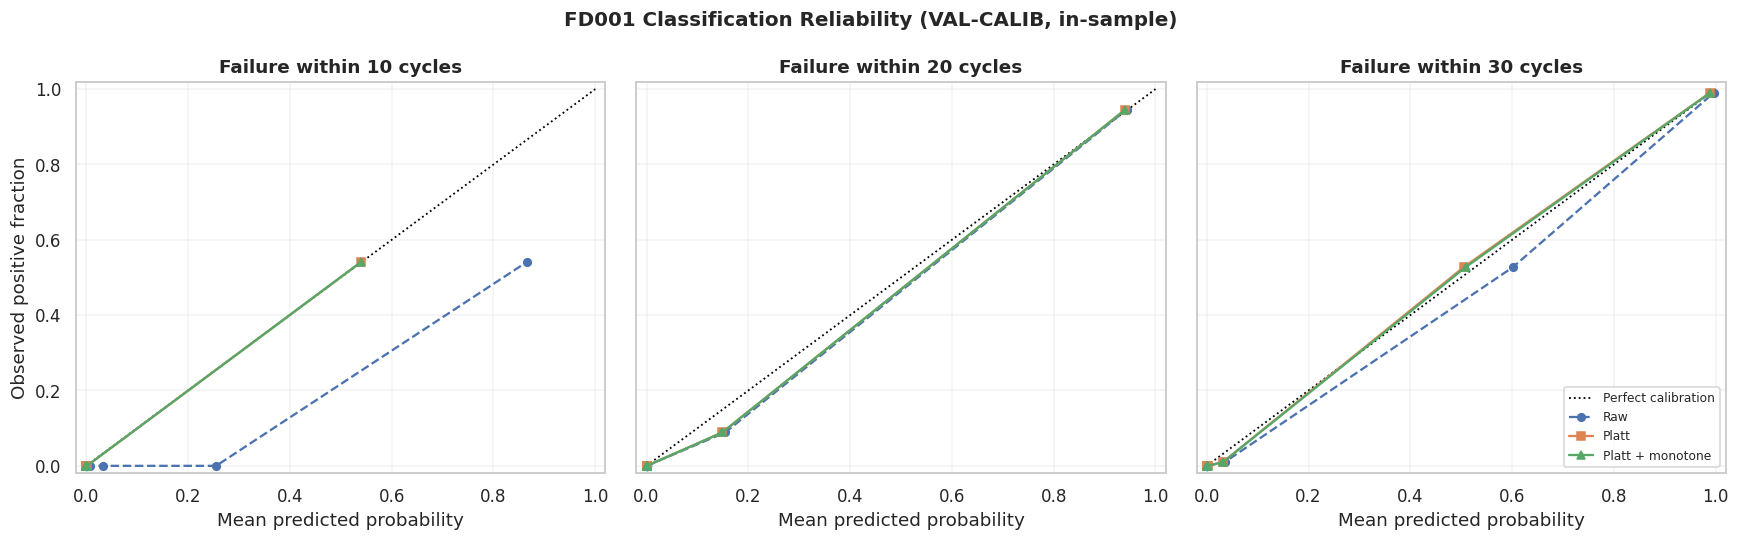

 RELIABILITY SUMMARY 


,horizon,stage,populated_bins,mean_absolute_bin_gap,maximum_absolute_bin_gap
0,10,platt,10,0.000240,0.001201
1,10,platt_monotone,10,0.000240,0.001201
2,10,raw,10,0.062536,0.324528
3,20,platt,10,0.006579,0.060265
4,20,platt_monotone,10,0.006579,0.060265
5,20,raw,10,0.006866,0.065824
6,30,platt,10,0.004822,0.022410
7,30,platt_monotone,10,0.004422,0.022220
8,30,raw,10,0.010729,0.074269


In [62]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import models_classification as mc


probability_stages = {
    "raw": p_uncal,
    "platt": p_cal,
    "platt_monotone": p_mono,
}

reliability_frames = []

for horizon in CLASSIFICATION_HORIZONS:
    y_true = ycalib[horizon]

    for stage_name, stage_probabilities in (
        probability_stages.items()
    ):
        probabilities = stage_probabilities[horizon]

        reliability_table = mc.reliability_bins(
            y_true,
            probabilities,
            n_bins=10,
        ).copy()

        reliability_table["horizon"] = int(horizon)
        reliability_table["stage"] = stage_name
        reliability_table["absolute_calibration_gap"] = (
            np.abs(
                reliability_table["mean_pred"]
                - reliability_table["frac_pos"]
            )
        )

        reliability_frames.append(
            reliability_table
        )


classification_reliability_bins = pd.concat(
    reliability_frames,
    ignore_index=True,
)

assert not classification_reliability_bins.empty
assert classification_reliability_bins[
    ["mean_pred", "frac_pos"]
].notna().all().all()


figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharex=True,
    sharey=True,
)

stage_styles = {
    "raw": {
        "marker": "o",
        "linestyle": "--",
        "label": "Raw",
    },
    "platt": {
        "marker": "s",
        "linestyle": "-",
        "label": "Platt",
    },
    "platt_monotone": {
        "marker": "^",
        "linestyle": "-",
        "label": "Platt + monotone",
    },
}

for axis, horizon in zip(
    axes,
    CLASSIFICATION_HORIZONS,
):
    axis.plot(
        [0.0, 1.0],
        [0.0, 1.0],
        color="black",
        linestyle=":",
        linewidth=1.2,
        label="Perfect calibration",
    )

    for stage_name, style in stage_styles.items():
        subset_table = (
            classification_reliability_bins[
                (
                    classification_reliability_bins[
                        "horizon"
                    ]
                    == horizon
                )
                & (
                    classification_reliability_bins[
                        "stage"
                    ]
                    == stage_name
                )
            ]
            .sort_values("mean_pred")
        )

        axis.plot(
            subset_table["mean_pred"],
            subset_table["frac_pos"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=1.5,
            markersize=5,
            label=style["label"],
        )

    axis.set_title(
        f"Failure within {horizon} cycles",
        fontweight="bold",
    )
    axis.set_xlabel("Mean predicted probability")
    axis.set_xlim(-0.02, 1.02)
    axis.set_ylim(-0.02, 1.02)
    axis.grid(alpha=0.25)

axes[0].set_ylabel("Observed positive fraction")
axes[-1].legend(
    fontsize=8,
    loc="lower right",
)

figure.suptitle(
    (
        f"{SUBSET} Classification Reliability "
        "(VAL-CALIB, in-sample)"
    ),
    fontsize=13,
    fontweight="bold",
)

figure.tight_layout()




results_directory = Path(config.ARTIFACTS) / "results"
figures_directory = Path(config.FIGURES_DIR)

results_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

reliability_path = (
    results_directory
    / f"{SUBSET}_classification_reliability_bins.csv"
)

figure_path = (
    figures_directory
    / f"{SUBSET}_classification_reliability.png"
)

temporary_reliability_path = (
    reliability_path.with_suffix(
        reliability_path.suffix + ".tmp"
    )
)

classification_reliability_bins.to_csv(
    temporary_reliability_path,
    index=False,
)
temporary_reliability_path.replace(
    reliability_path
)

temporary_figure_path = figure_path.with_suffix(
    figure_path.suffix + ".tmp"
)

figure.savefig(
    temporary_figure_path,
    format="png",
    dpi=180,
    bbox_inches="tight",
)

temporary_figure_path.replace(figure_path)

plt.show()


reliability_summary = (
    classification_reliability_bins
    .groupby(
        ["horizon", "stage"],
        as_index=False,
    )
    .agg(
        populated_bins=("mean_pred", "size"),
        mean_absolute_bin_gap=(
            "absolute_calibration_gap",
            "mean",
        ),
        maximum_absolute_bin_gap=(
            "absolute_calibration_gap",
            "max",
        ),
    )
)

print(" RELIABILITY SUMMARY ")
display(reliability_summary.round(6))


In [63]:
print("\nSaved reliability bins:", reliability_path)
print("Saved calibration figure:", figure_path)
print("Diagnostic partition: VAL-CALIB")
print(
    "These are in-sample calibration diagnostics, "
    "not independent test results."
)
print("Threshold status: PENDING")
print("Official test status: SEALED")



Saved reliability bins: artifacts/results/FD001_classification_reliability_bins.csv
Saved calibration figure: figures/FD001_classification_reliability.png
Diagnostic partition: VAL-CALIB
These are in-sample calibration diagnostics, not independent test results.
Threshold status: PENDING
Official test status: SEALED


In [64]:
import copy
import hashlib
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_classification as mc


PRIMARY_FN_COST = 10.0
PRIMARY_FP_COST = 1.0
SENSITIVITY_FN_COSTS = (5.0, 20.0)


def threshold_metrics(
    y_true,
    probability,
    threshold,
    fn_cost,
    fp_cost,
):
    metrics = mc.clf_metrics_at_threshold(
        y_true,
        probability,
        threshold,
    )

    false_negative_cost = (
        float(fn_cost) * int(metrics["fn"])
    )
    false_positive_cost = (
        float(fp_cost) * int(metrics["fp"])
    )
    total_cost = (
        false_negative_cost
        + false_positive_cost
    )

    return {
        "threshold": float(threshold),
        "fn_cost": float(fn_cost),
        "fp_cost": float(fp_cost),
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "f1": float(metrics["f1"]),
        "tp": int(metrics["tp"]),
        "fp": int(metrics["fp"]),
        "fn": int(metrics["fn"]),
        "tn": int(metrics["tn"]),
        "false_negative_cost_contribution": (
            false_negative_cost
        ),
        "false_positive_cost_contribution": (
            false_positive_cost
        ),
        "total_cost": float(total_cost),
        "cost_per_row": float(
            total_cost / len(y_true)
        ),
    }


primary_thresholds = {}
primary_threshold_records = []
sensitivity_threshold_records = []
diagnostic_threshold_records = []

for horizon in CLASSIFICATION_HORIZONS:
    y_true = ycalib[horizon]
    probability = p_mono[horizon]

    primary_threshold, _ = mc.best_cost_threshold(
        y_true,
        probability,
        fn_cost=PRIMARY_FN_COST,
        fp_cost=PRIMARY_FP_COST,
    )

    primary_metrics = threshold_metrics(
        y_true=y_true,
        probability=probability,
        threshold=primary_threshold,
        fn_cost=PRIMARY_FN_COST,
        fp_cost=PRIMARY_FP_COST,
    )

    primary_thresholds[horizon] = float(
        primary_threshold
    )

    primary_threshold_records.append(
        {
            "horizon": int(horizon),
            "policy": "primary_FN10_FP1",
            "partition": "val_calib",
            "tie_break": "lowest threshold",
            **primary_metrics,
        }
    )

    for sensitivity_fn_cost in (
        SENSITIVITY_FN_COSTS
    ):
        sensitivity_threshold, _ = (
            mc.best_cost_threshold(
                y_true,
                probability,
                fn_cost=sensitivity_fn_cost,
                fp_cost=PRIMARY_FP_COST,
            )
        )

        sensitivity_metrics = threshold_metrics(
            y_true=y_true,
            probability=probability,
            threshold=sensitivity_threshold,
            fn_cost=sensitivity_fn_cost,
            fp_cost=PRIMARY_FP_COST,
        )

        sensitivity_threshold_records.append(
            {
                "horizon": int(horizon),
                "policy": (
                    f"sensitivity_FN"
                    f"{int(sensitivity_fn_cost)}_FP1"
                ),
                "partition": "val_calib",
                "tie_break": "lowest threshold",
                **sensitivity_metrics,
            }
        )

    f1_threshold, _ = mc.f1_optimal_threshold(
        y_true,
        probability,
    )

    f1_metrics = mc.clf_metrics_at_threshold(
        y_true,
        probability,
        f1_threshold,
    )

    diagnostic_threshold_records.append(
        {
            "horizon": int(horizon),
            "policy": "diagnostic_F1_optimal",
            "threshold": float(f1_threshold),
            "precision": float(
                f1_metrics["precision"]
            ),
            "recall": float(f1_metrics["recall"]),
            "f1": float(f1_metrics["f1"]),
            "tp": int(f1_metrics["tp"]),
            "fp": int(f1_metrics["fp"]),
            "fn": int(f1_metrics["fn"]),
            "tn": int(f1_metrics["tn"]),
        }
    )

    recall_threshold = (
        mc.recall_constrained_threshold(
            y_true,
            probability,
            0.90,
        )
    )

    recall_metrics = mc.clf_metrics_at_threshold(
        y_true,
        probability,
        recall_threshold,
    )

    diagnostic_threshold_records.append(
        {
            "horizon": int(horizon),
            "policy": "diagnostic_recall_at_least_0_90",
            "threshold": float(recall_threshold),
            "precision": float(
                recall_metrics["precision"]
            ),
            "recall": float(
                recall_metrics["recall"]
            ),
            "f1": float(recall_metrics["f1"]),
            "tp": int(recall_metrics["tp"]),
            "fp": int(recall_metrics["fp"]),
            "fn": int(recall_metrics["fn"]),
            "tn": int(recall_metrics["tn"]),
        }
    )


primary_threshold_table = pd.DataFrame(
    primary_threshold_records
)
sensitivity_threshold_table = pd.DataFrame(
    sensitivity_threshold_records
)
diagnostic_threshold_table = pd.DataFrame(
    diagnostic_threshold_records
)



threshold_prediction_table = (
    classification_calibration_predictions.copy()
)

for horizon in CLASSIFICATION_HORIZONS:
    threshold_prediction_table[
        f"decision_h{horizon}"
    ] = (
        threshold_prediction_table[
            f"monotone_probability_h{horizon}"
        ]
        >= primary_thresholds[horizon]
    ).astype(int)


In [65]:
models_directory = Path(config.ARTIFACTS) / "models"
results_directory = Path(config.ARTIFACTS) / "results"
processed_directory = Path(config.DATA_PROCESSED)

calibrated_bundle_path = (
    models_directory
    / f"{SUBSET}_classification_calibrated_bundle.joblib"
)

assert calibrated_bundle_path.exists()

source_calibrated_sha256 = hashlib.sha256(
    calibrated_bundle_path.read_bytes()
).hexdigest()

calibrated_bundle = joblib.load(
    calibrated_bundle_path
)

classification_bundle = copy.deepcopy(
    calibrated_bundle
)

classification_bundle["artifact_type"] = (
    "thresholded_failure_horizon_classification_bundle"
)
classification_bundle["artifact_version"] = 1
classification_bundle["threshold_status"] = (
    "selected_on_val_calib"
)
classification_bundle["threshold_partition"] = (
    "val_calib"
)
classification_bundle["threshold_policy"] = {
    "primary_cost_ratio": {
        "false_negative": PRIMARY_FN_COST,
        "false_positive": PRIMARY_FP_COST,
    },
    "tie_break": "lowest threshold",
    "probability_stage": "Platt plus monotonicity",
}
classification_bundle["thresholds"] = {
    str(horizon): float(
        primary_thresholds[horizon]
    )
    for horizon in CLASSIFICATION_HORIZONS
}
classification_bundle[
    "source_calibrated_bundle_sha256"
] = source_calibrated_sha256
classification_bundle["official_test_status"] = (
    "sealed"
)


classification_bundle_path = (
    models_directory
    / f"{SUBSET}_classification_bundle.joblib"
)
temporary_bundle_path = (
    classification_bundle_path.with_suffix(
        classification_bundle_path.suffix + ".tmp"
    )
)

joblib.dump(
    classification_bundle,
    temporary_bundle_path,
)

reloaded_thresholded_bundle = joblib.load(
    temporary_bundle_path
)

reloaded_platt, reloaded_monotone = (
    calibrated_bundle_probabilities(
        reloaded_thresholded_bundle,
        df_val_calib,
    )
)

expected_monotone = np.column_stack(
    [
        p_mono[horizon]
        for horizon in CLASSIFICATION_HORIZONS
    ]
)

assert np.allclose(
    reloaded_monotone,
    expected_monotone,
    rtol=0.0,
    atol=1e-12,
)

for index, horizon in enumerate(
    CLASSIFICATION_HORIZONS
):
    expected_decision = (
        p_mono[horizon]
        >= primary_thresholds[horizon]
    ).astype(int)

    reloaded_decision = (
        reloaded_monotone[:, index]
        >= reloaded_thresholded_bundle[
            "thresholds"
        ][str(horizon)]
    ).astype(int)

    assert np.array_equal(
        expected_decision,
        reloaded_decision,
    )

temporary_bundle_path.replace(
    classification_bundle_path
)

classification_bundle_sha256 = hashlib.sha256(
    classification_bundle_path.read_bytes()
).hexdigest()


primary_path = (
    results_directory
    / f"{SUBSET}_classification_primary_thresholds.csv"
)
sensitivity_path = (
    results_directory
    / f"{SUBSET}_classification_threshold_sensitivity.csv"
)
diagnostic_path = (
    results_directory
    / f"{SUBSET}_classification_threshold_diagnostics.csv"
)
threshold_predictions_path = (
    results_directory
    / f"{SUBSET}_classification_threshold_predictions.csv"
)
threshold_contract_path = (
    processed_directory
    / f"{SUBSET}_classification_thresholds.json"
)

for dataframe, destination in (
    (primary_threshold_table, primary_path),
    (
        sensitivity_threshold_table,
        sensitivity_path,
    ),
    (
        diagnostic_threshold_table,
        diagnostic_path,
    ),
    (
        threshold_prediction_table,
        threshold_predictions_path,
    ),
):
    temporary_path = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    dataframe.to_csv(temporary_path, index=False)
    temporary_path.replace(destination)

threshold_contract = {
    "subset": SUBSET,
    "task": "row_level_failure_horizon_thresholds",
    "probability_stage": (
        "horizon-specific Platt calibration followed "
        "by cumulative-maximum monotonicity correction"
    ),
    "selection_partition": "val_calib",
    "primary_cost": {
        "false_negative": PRIMARY_FN_COST,
        "false_positive": PRIMARY_FP_COST,
    },
    "cost_ordering": "false_negative > false_positive",
    "tie_break": "lowest threshold",
    "primary_thresholds": {
        str(horizon): float(
            primary_thresholds[horizon]
        )
        for horizon in CLASSIFICATION_HORIZONS
    },
    "source_calibrated_bundle_sha256": (
        source_calibrated_sha256
    ),
    "classification_bundle_path": str(
        classification_bundle_path
    ),
    "classification_bundle_sha256": (
        classification_bundle_sha256
    ),
    "engine_level_policy_status": "pending",
    "official_test_status": "sealed",
    "interpretation": [
        (
            "Thresholds minimize row-level asymmetric "
            "cost on VAL-CALIB."
        ),
        (
            "They are not the final persistent engine-level "
            "maintenance policy."
        ),
        (
            "Metrics on VAL-CALIB are in-sample threshold "
            "diagnostics, not independent test results."
        ),
    ],
}

temporary_contract_path = (
    threshold_contract_path.with_suffix(
        threshold_contract_path.suffix + ".tmp"
    )
)

temporary_contract_path.write_text(
    json.dumps(threshold_contract, indent=2),
    encoding="utf-8",
)


1153

In [66]:
temporary_contract_path.replace(
    threshold_contract_path
)


thr_full = primary_thresholds


print(" PRIMARY ROW-LEVEL THRESHOLDS: FN:FP = 10:1 ")
display(
    primary_threshold_table[
        [
            "horizon",
            "threshold",
            "precision",
            "recall",
            "f1",
            "tp",
            "fp",
            "fn",
            "tn",
            "false_negative_cost_contribution",
            "false_positive_cost_contribution",
            "total_cost",
            "cost_per_row",
        ]
    ].round(6)
)

print("\n THRESHOLD COST SENSITIVITY ")
display(
    sensitivity_threshold_table[
        [
            "horizon",
            "policy",
            "threshold",
            "precision",
            "recall",
            "f1",
            "fp",
            "fn",
            "total_cost",
            "cost_per_row",
        ]
    ].round(6)
)

print("\n DIAGNOSTIC THRESHOLDS ")
display(diagnostic_threshold_table.round(6))

print("\nSaved classification bundle:", classification_bundle_path)
print("Classification bundle SHA256:", classification_bundle_sha256)
print("Reload probability and decision parity: PASS")
print("Saved threshold contract:", threshold_contract_path)
print("Engine-level persistence policy: PENDING")
print("Official test status: SEALED")


 PRIMARY ROW-LEVEL THRESHOLDS: FN:FP = 10:1 


,horizon,threshold,precision,recall,f1,tp,fp,fn,tn,false_negative_cost_contribution,false_positive_cost_contribution,total_cost,cost_per_row
0,10,0.113404,0.712418,0.990909,0.828897,109,44,1,1872,10.0,44.0,54.0,0.026654
1,20,0.222905,0.796935,0.990476,0.883227,208,53,2,1763,20.0,53.0,73.0,0.036032
2,30,0.116540,0.781726,0.993548,0.875000,308,86,2,1630,20.0,86.0,106.0,0.052320



 THRESHOLD COST SENSITIVITY 


,horizon,policy,threshold,precision,recall,f1,fp,fn,total_cost,cost_per_row
0,10,sensitivity_FN5_FP1,0.239821,0.821705,0.963636,0.887029,23,4,43.0,0.021224
1,10,sensitivity_FN20_FP1,0.043680,0.666667,1.000000,0.800000,55,0,55.0,0.027147
2,20,sensitivity_FN5_FP1,0.410643,0.902655,0.971429,0.935780,22,6,52.0,0.025666
3,20,sensitivity_FN20_FP1,0.222905,0.796935,0.990476,0.883227,53,2,93.0,0.045903
4,30,sensitivity_FN5_FP1,0.116540,0.781726,0.993548,0.875000,86,2,96.0,0.047384
5,30,sensitivity_FN20_FP1,0.075125,0.731132,1.000000,0.844687,114,0,114.0,0.056269



 DIAGNOSTIC THRESHOLDS 


,horizon,policy,threshold,precision,recall,f1,tp,fp,fn,tn
0,10,diagnostic_F1_optimal,0.504308,0.909091,0.909091,0.909091,100,10,10,1906
1,10,diagnostic_recall_at_least_0_90,0.521373,0.908257,0.900000,0.904110,99,10,11,1906
2,20,diagnostic_F1_optimal,0.531220,0.929907,0.947619,0.938679,199,15,11,1801
3,20,diagnostic_recall_at_least_0_90,0.645184,0.945000,0.900000,0.921951,189,11,21,1805
4,30,diagnostic_F1_optimal,0.399282,0.894737,0.932258,0.913112,289,34,21,1682
5,30,diagnostic_recall_at_least_0_90,0.491056,0.905844,0.900000,0.902913,279,29,31,1687



Saved classification bundle: artifacts/models/FD001_classification_bundle.joblib
Classification bundle SHA256: 9f54d9da77012489642d366edad8ee33e391f931649e837fc296c4c679eac157
Reload probability and decision parity: PASS
Saved threshold contract: data/processed/FD001_classification_thresholds.json
Engine-level persistence policy: PENDING
Official test status: SEALED


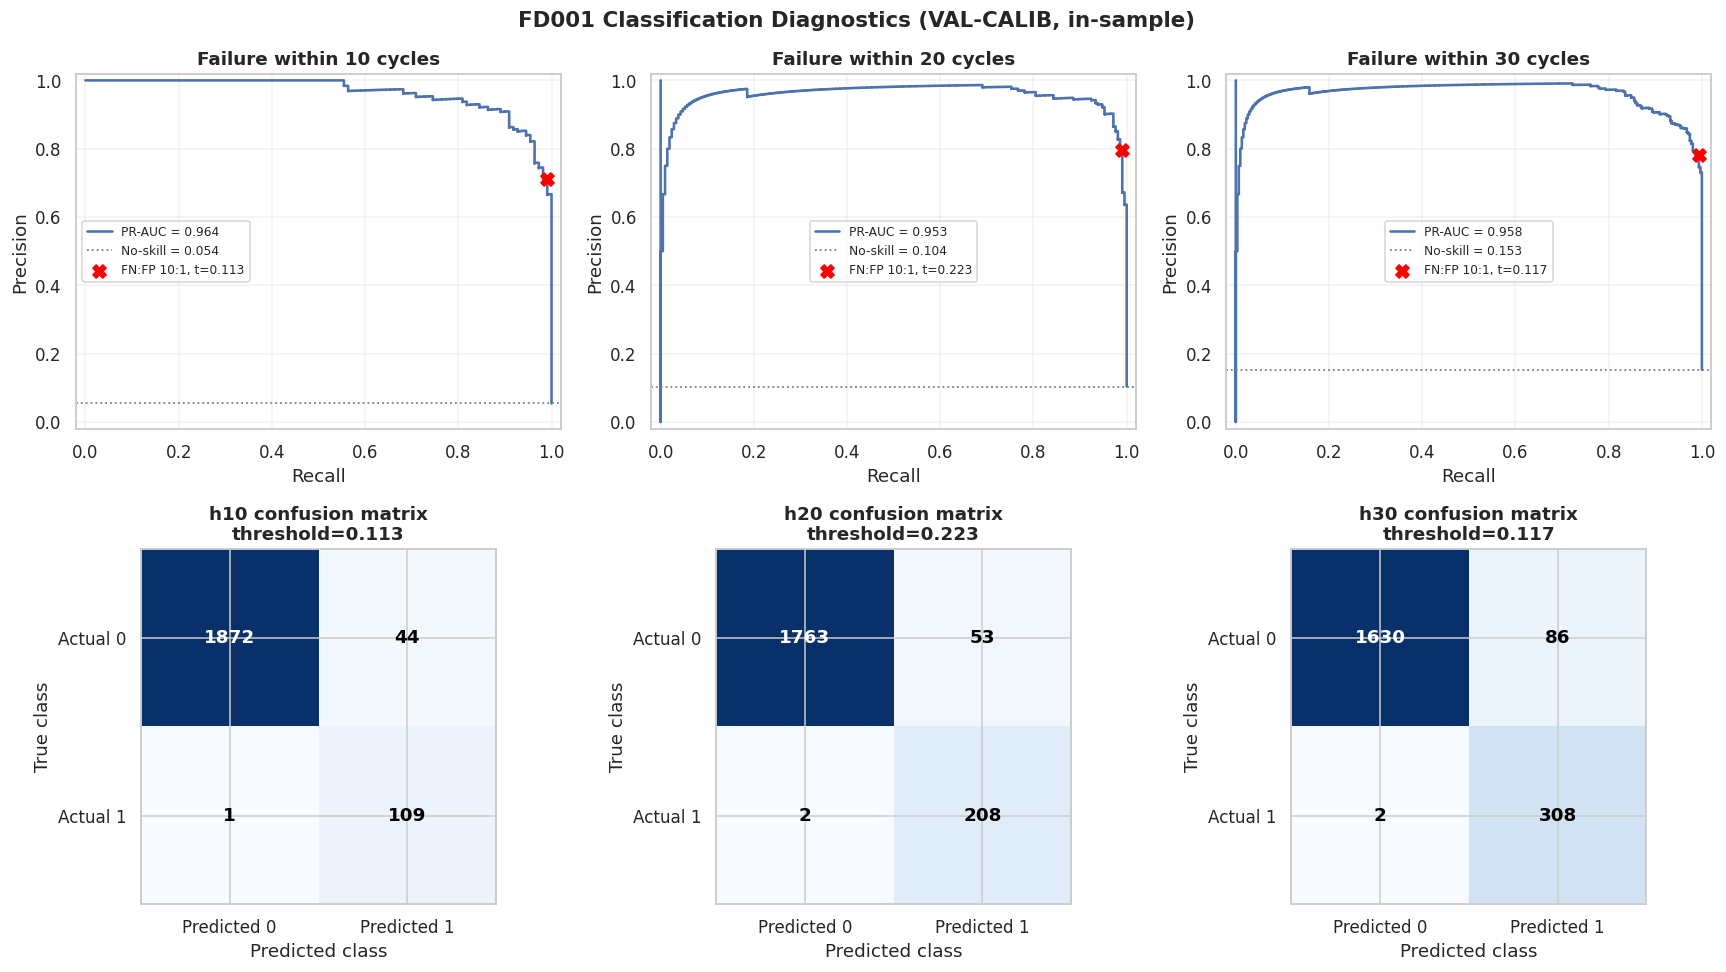

In [67]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)


pr_curve_frames = []
classification_diagnostic_records = []

figure, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

for column_index, horizon in enumerate(
    CLASSIFICATION_HORIZONS
):
    y_true = ycalib[horizon]
    probability = p_mono[horizon]
    threshold = primary_thresholds[horizon]

    precision_curve, recall_curve, curve_thresholds = (
        precision_recall_curve(
            y_true,
            probability,
        )
    )

    average_precision = float(
        average_precision_score(
            y_true,
            probability,
        )
    )
    prevalence = float(y_true.mean())

    threshold_metrics_result = (
        mc.clf_metrics_at_threshold(
            y_true,
            probability,
            threshold,
        )
    )

    y_predicted = (
        probability >= threshold
    ).astype(int)

    matrix = confusion_matrix(
        y_true,
        y_predicted,
        labels=[0, 1],
    )

    tn, fp, fn, tp = matrix.ravel()

    assert tn == threshold_metrics_result["tn"]
    assert fp == threshold_metrics_result["fp"]
    assert fn == threshold_metrics_result["fn"]
    assert tp == threshold_metrics_result["tp"]

    classification_diagnostic_records.append(
        {
            "horizon": int(horizon),
            "partition": "val_calib",
            "probability_stage": (
                "platt_plus_monotonicity"
            ),
            "threshold_policy": "FN10_FP1",
            "threshold": float(threshold),
            "prevalence": prevalence,
            "PR_AUC": average_precision,
            "precision": float(
                threshold_metrics_result["precision"]
            ),
            "recall": float(
                threshold_metrics_result["recall"]
            ),
            "f1": float(
                threshold_metrics_result["f1"]
            ),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
        }
    )

    padded_thresholds = np.append(
        curve_thresholds,
        np.nan,
    )

    pr_curve_frames.append(
        pd.DataFrame(
            {
                "partition": "val_calib",
                "horizon": int(horizon),
                "precision": precision_curve,
                "recall": recall_curve,
                "threshold": padded_thresholds,
            }
        )
    )


    pr_axis = axes[0, column_index]

    pr_axis.step(
        recall_curve,
        precision_curve,
        where="post",
        linewidth=1.7,
        label=f"PR-AUC = {average_precision:.3f}",
    )

    pr_axis.axhline(
        prevalence,
        color="gray",
        linestyle=":",
        linewidth=1.2,
        label=f"No-skill = {prevalence:.3f}",
    )

    pr_axis.scatter(
        threshold_metrics_result["recall"],
        threshold_metrics_result["precision"],
        color="red",
        marker="X",
        s=75,
        zorder=5,
        label=f"FN:FP 10:1, t={threshold:.3f}",
    )

    pr_axis.set_title(
        f"Failure within {horizon} cycles",
        fontweight="bold",
    )
    pr_axis.set_xlabel("Recall")
    pr_axis.set_ylabel("Precision")
    pr_axis.set_xlim(-0.02, 1.02)
    pr_axis.set_ylim(-0.02, 1.02)
    pr_axis.grid(alpha=0.25)
    pr_axis.legend(fontsize=8)

    

    matrix_axis = axes[1, column_index]

    image = matrix_axis.imshow(
        matrix,
        cmap="Blues",
    )

    for row in range(2):
        for column in range(2):
            value = int(matrix[row, column])

            matrix_axis.text(
                column,
                row,
                f"{value}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > matrix.max() / 2
                    else "black"
                ),
                fontsize=12,
                fontweight="bold",
            )

    matrix_axis.set_xticks([0, 1])
    matrix_axis.set_yticks([0, 1])
    matrix_axis.set_xticklabels(
        ["Predicted 0", "Predicted 1"]
    )
    matrix_axis.set_yticklabels(
        ["Actual 0", "Actual 1"]
    )
    matrix_axis.set_xlabel("Predicted class")
    matrix_axis.set_ylabel("True class")
    matrix_axis.set_title(
        (
            f"h{horizon} confusion matrix\n"
            f"threshold={threshold:.3f}"
        ),
        fontweight="bold",
    )


figure.suptitle(
    (
        f"{SUBSET} Classification Diagnostics "
        "(VAL-CALIB, in-sample)"
    ),
    fontsize=14,
    fontweight="bold",
)

figure.tight_layout()


classification_diagnostics = pd.DataFrame(
    classification_diagnostic_records
)

classification_pr_curve_points = pd.concat(
    pr_curve_frames,
    ignore_index=True,
)


In [68]:
results_directory = Path(config.ARTIFACTS) / "results"
figures_directory = Path(config.FIGURES_DIR)

results_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

diagnostics_path = (
    results_directory
    / f"{SUBSET}_classification_val_calib_diagnostics.csv"
)

pr_points_path = (
    results_directory
    / f"{SUBSET}_classification_pr_curve_points.csv"
)

figure_path = (
    figures_directory
    / f"{SUBSET}_classification_pr_and_confusion.png"
)

for dataframe, destination in (
    (
        classification_diagnostics,
        diagnostics_path,
    ),
    (
        classification_pr_curve_points,
        pr_points_path,
    ),
):
    temporary_path = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    dataframe.to_csv(temporary_path, index=False)
    temporary_path.replace(destination)

temporary_figure_path = figure_path.with_suffix(
    figure_path.suffix + ".tmp"
)

figure.savefig(
    temporary_figure_path,
    format="png",
    dpi=180,
    bbox_inches="tight",
)

temporary_figure_path.replace(figure_path)

plt.show()


print(" VAL-CALIB CLASSIFICATION DIAGNOSTICS ")
display(classification_diagnostics.round(6))

print("\nSaved diagnostics:", diagnostics_path)
print("Saved full PR points:", pr_points_path)
print(
    "Threshold markers use the locked FN:FP=10:1 policy."
)
print(
    "These are in-sample VAL-CALIB diagnostics, "
    "not independent final results."
)
print("Official test status: SEALED")


 VAL-CALIB CLASSIFICATION DIAGNOSTICS 


,horizon,partition,probability_stage,threshold_policy,threshold,prevalence,PR_AUC,precision,recall,f1,tp,fp,fn,tn
0,10,val_calib,platt_plus_monotonicity,FN10_FP1,0.113404,0.054294,0.963915,0.712418,0.990909,0.828897,109,44,1,1872
1,20,val_calib,platt_plus_monotonicity,FN10_FP1,0.222905,0.103653,0.953314,0.796935,0.990476,0.883227,208,53,2,1763
2,30,val_calib,platt_plus_monotonicity,FN10_FP1,0.116540,0.153011,0.957914,0.781726,0.993548,0.875000,308,86,2,1630



Saved diagnostics: artifacts/results/FD001_classification_val_calib_diagnostics.csv
Saved full PR points: artifacts/results/FD001_classification_pr_curve_points.csv
Threshold markers use the locked FN:FP=10:1 policy.
These are in-sample VAL-CALIB diagnostics, not independent final results.
Official test status: SEALED


In [69]:
from pathlib import Path

import numpy as np
import pandas as pd

import models_classification as mc


BOOTSTRAP_DRAWS = int(config.BOOTSTRAP_DRAWS)
BOOTSTRAP_SEED = int(config.RANDOM_SEED)

assert BOOTSTRAP_DRAWS == 1000

calibration_engine_ids = (
    df_val_calib["engine_id"].to_numpy(dtype=int)
)

bootstrap_samples, bootstrap_engine_count = (
    mc.engine_bootstrap_draws(
        engine_ids=calibration_engine_ids,
        B=BOOTSTRAP_DRAWS,
        seed=BOOTSTRAP_SEED,
    )
)

assert bootstrap_engine_count == (
    df_val_calib["engine_id"].nunique()
)
assert len(bootstrap_samples) == BOOTSTRAP_DRAWS


def classification_metric_values(
    y_true,
    probability,
    threshold,
):
    threshold_result = mc.clf_metrics_at_threshold(
        y_true,
        probability,
        threshold,
    )

    return {
        "PR_AUC": float(
            mc.average_precision(
                y_true,
                probability,
            )
        ),
        "Brier": float(
            mc.brier(
                y_true,
                probability,
            )
        ),
        "precision": float(
            threshold_result["precision"]
        ),
        "recall": float(
            threshold_result["recall"]
        ),
        "f1": float(threshold_result["f1"]),
    }


bootstrap_records = []
bootstrap_summary_records = []

for horizon in CLASSIFICATION_HORIZONS:
    y_full = ycalib[horizon]
    probability_full = p_mono[horizon]
    threshold = primary_thresholds[horizon]

    point_metrics = classification_metric_values(
        y_true=y_full,
        probability=probability_full,
        threshold=threshold,
    )

    valid_draw_count = 0
    invalid_single_class_count = 0

    for draw_number, bootstrap_sample in enumerate(
        bootstrap_samples,
        start=1,
    ):
        row_positions = bootstrap_sample[
            "row_positions"
        ]

        y_draw = y_full[row_positions]
        probability_draw = probability_full[
            row_positions
        ]

        if np.unique(y_draw).size < 2:
            invalid_single_class_count += 1
            continue

        draw_metrics = classification_metric_values(
            y_true=y_draw,
            probability=probability_draw,
            threshold=threshold,
        )

        valid_draw_count += 1

        for metric_name, metric_value in (
            draw_metrics.items()
        ):
            bootstrap_records.append(
                {
                    "horizon": int(horizon),
                    "draw": int(draw_number),
                    "metric": metric_name,
                    "value": float(metric_value),
                }
            )

    assert valid_draw_count > 0

    horizon_draws = pd.DataFrame(
        [
            record
            for record in bootstrap_records
            if record["horizon"] == horizon
        ]
    )

    for metric_name, point_estimate in (
        point_metrics.items()
    ):
        metric_draws = horizon_draws.loc[
            horizon_draws["metric"] == metric_name,
            "value",
        ].to_numpy(dtype=float)

        assert len(metric_draws) == valid_draw_count

        ci_lower, ci_upper = np.quantile(
            metric_draws,
            [0.025, 0.975],
        )

        bootstrap_summary_records.append(
            {
                "horizon": int(horizon),
                "partition": "val_calib",
                "metric": metric_name,
                "point_estimate": float(
                    point_estimate
                ),
                "ci_95_lower": float(ci_lower),
                "ci_95_upper": float(ci_upper),
                "bootstrap_mean": float(
                    metric_draws.mean()
                ),
                "bootstrap_standard_deviation": float(
                    metric_draws.std(ddof=1)
                ),
                "valid_draws": int(
                    valid_draw_count
                ),
                "invalid_single_class_draws": int(
                    invalid_single_class_count
                ),
                "n_unique_engines": int(
                    bootstrap_engine_count
                ),
                "seed": int(BOOTSTRAP_SEED),
            }
        )


classification_bootstrap_draws = pd.DataFrame(
    bootstrap_records
)
classification_bootstrap_summary = pd.DataFrame(
    bootstrap_summary_records
)

assert (
    classification_bootstrap_summary[
        "valid_draws"
    ]
    + classification_bootstrap_summary[
        "invalid_single_class_draws"
    ]
    == BOOTSTRAP_DRAWS
).all()


results_directory = Path(config.ARTIFACTS) / "results"
results_directory.mkdir(parents=True, exist_ok=True)

bootstrap_draws_path = (
    results_directory
    / f"{SUBSET}_classification_engine_bootstrap_draws.csv"
)

bootstrap_summary_path = (
    results_directory
    / f"{SUBSET}_classification_engine_bootstrap_ci.csv"
)

for dataframe, destination in (
    (
        classification_bootstrap_draws,
        bootstrap_draws_path,
    ),
    (
        classification_bootstrap_summary,
        bootstrap_summary_path,
    ),
):
    temporary_path = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    dataframe.to_csv(temporary_path, index=False)
    temporary_path.replace(destination)


In [70]:
print(" ENGINE-LEVEL BOOTSTRAP 95% CI ")
print("Partition: VAL-CALIB")
print("Unique engines:", bootstrap_engine_count)
print("Requested draws:", BOOTSTRAP_DRAWS)
print("Seed:", BOOTSTRAP_SEED)

display(
    classification_bootstrap_summary[
        [
            "horizon",
            "metric",
            "point_estimate",
            "ci_95_lower",
            "ci_95_upper",
            "valid_draws",
            "invalid_single_class_draws",
        ]
    ].round(6)
)

print("\nSaved bootstrap draws:", bootstrap_draws_path)
print("Saved bootstrap summary:", bootstrap_summary_path)
print(
    "These intervals are VAL-CALIB diagnostics "
    "based on only 10 engines."
)
print(
    "Final independent confidence intervals will "
    "be recomputed on official TEST engines."
)
print("Official test status: SEALED")


 ENGINE-LEVEL BOOTSTRAP 95% CI 
Partition: VAL-CALIB
Unique engines: 10
Requested draws: 1000
Seed: 42


,horizon,metric,point_estimate,ci_95_lower,ci_95_upper,valid_draws,invalid_single_class_draws
0,10,PR_AUC,0.963915,0.944800,0.989214,1000,0
1,10,Brier,0.008333,0.005339,0.011343,1000,0
2,10,precision,0.712418,0.628571,0.825850,1000,0
3,10,recall,0.990909,0.972727,1.000000,1000,0
4,10,f1,0.828897,0.770318,0.897140,1000,0
5,20,PR_AUC,0.953314,0.921605,0.986557,1000,0
6,20,Brier,0.011855,0.009540,0.014232,1000,0
7,20,precision,0.796935,0.735714,0.857143,1000,0
8,20,recall,0.990476,0.971429,1.000000,1000,0
9,20,f1,0.883227,0.845070,0.915556,1000,0



Saved bootstrap draws: artifacts/results/FD001_classification_engine_bootstrap_draws.csv
Saved bootstrap summary: artifacts/results/FD001_classification_engine_bootstrap_ci.csv
These intervals are VAL-CALIB diagnostics based on only 10 engines.
Final independent confidence intervals will be recomputed on official TEST engines.
Official test status: SEALED


### Resume from frozen artifacts after kernel restart.

In [71]:
import hashlib
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


current_path = Path.cwd()
project_candidates = [
    current_path,
    *current_path.parents,
]

PROJECT_ROOT = next(
    path
    for path in project_candidates
    if (path / "src").is_dir()
    and (path / "notebooks").is_dir()
)
PROJECT_ROOT = Path(".")

SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import config
import data_loader as dl
import splits as sp
import models_classification as mc


SUBSET = config.STAGE1_SUBSET
CLASSIFICATION_HORIZONS = tuple(
    config.CLASSIFICATION_HORIZONS
)

assert SUBSET == "FD001"
assert CLASSIFICATION_HORIZONS == (10, 20, 30)


split = sp.load_split(SUBSET)
validation_subdivision = (
    sp.load_validation_subdivision(SUBSET)
)

VAL_TUNE_IDS = validation_subdivision["val_tune"]
VAL_CALIB_IDS = validation_subdivision["val_calib"]

full_train = dl.load_raw(SUBSET, "train")
official_train = full_train.copy()
full_train = dl.add_train_rul(full_train)
full_train = dl.add_classification_labels(full_train)

df_tr = full_train[
    full_train["engine_id"].isin(split["train"])
].copy()

df_val = full_train[
    full_train["engine_id"].isin(split["val"])
].copy()

df_val_tune = full_train[
    full_train["engine_id"].isin(VAL_TUNE_IDS)
].copy()

df_val_calib = full_train[
    full_train["engine_id"].isin(VAL_CALIB_IDS)
].copy()

assert set(df_tr["engine_id"]).isdisjoint(
    set(df_val["engine_id"])
)
assert set(df_val_tune["engine_id"]).isdisjoint(
    set(df_val_calib["engine_id"])
)
assert (
    set(df_val_tune["engine_id"])
    | set(df_val_calib["engine_id"])
) == set(df_val["engine_id"])

assert "df_test" not in globals()


models_directory = Path(config.ARTIFACTS) / "models"
processed_directory = Path(config.DATA_PROCESSED)

classification_bundle_path = (
    models_directory
    / f"{SUBSET}_classification_bundle.joblib"
)
threshold_contract_path = (
    processed_directory
    / f"{SUBSET}_classification_thresholds.json"
)

threshold_contract = json.loads(
    threshold_contract_path.read_text(
        encoding="utf-8"
    )
)

actual_bundle_sha256 = hashlib.sha256(
    classification_bundle_path.read_bytes()
).hexdigest()

assert actual_bundle_sha256 == (
    threshold_contract[
        "classification_bundle_sha256"
    ]
)

classification_bundle = joblib.load(
    classification_bundle_path
)

assert classification_bundle[
    "threshold_status"
] == "selected_on_val_calib"
assert classification_bundle[
    "official_test_status"
] == "sealed"


raw_probability_columns = []
platt_probability_columns = []

for horizon in CLASSIFICATION_HORIZONS:
    entry = classification_bundle[
        "classifiers"
    ][str(horizon)]

    X_calibration = entry[
        "feature_pipeline"
    ].transform(
        df_val_calib,
        scaled=entry["uses_scaled_features"],
    )[0].to_numpy(dtype=float)

    raw_probability_columns.append(
        entry["model"].predict_proba(
            X_calibration
        )[:, 1]
    )

    calibration_scores = mc.calibration_scores(
        entry["model"],
        X_calibration,
    )

    platt_probability_columns.append(
        mc.apply_platt(
            entry["calibrator"],
            calibration_scores,
        )
    )

raw_probability_matrix = np.column_stack(
    raw_probability_columns
)
platt_probability_matrix = np.column_stack(
    platt_probability_columns
)
monotone_probability_matrix = np.maximum.accumulate(
    platt_probability_matrix,
    axis=1,
)

assert np.all(
    monotone_probability_matrix[:, 0]
    <= monotone_probability_matrix[:, 1]
)
assert np.all(
    monotone_probability_matrix[:, 1]
    <= monotone_probability_matrix[:, 2]
)

p_uncal = {
    horizon: raw_probability_matrix[:, index]
    for index, horizon in enumerate(
        CLASSIFICATION_HORIZONS
    )
}
p_cal = {
    horizon: platt_probability_matrix[:, index]
    for index, horizon in enumerate(
        CLASSIFICATION_HORIZONS
    )
}
p_mono = {
    horizon: monotone_probability_matrix[:, index]
    for index, horizon in enumerate(
        CLASSIFICATION_HORIZONS
    )
}
ycalib = {
    horizon: df_val_calib[
        f"label_h{horizon}"
    ].to_numpy(dtype=int)
    for horizon in CLASSIFICATION_HORIZONS
}

primary_thresholds = {
    horizon: float(
        classification_bundle["thresholds"][
            str(horizon)
        ]
    )
    for horizon in CLASSIFICATION_HORIZONS
}

thr_full = primary_thresholds
PRIMARY_FN_COST = 10.0
PRIMARY_FP_COST = 1.0


print(" RESUME FROM FROZEN ARTIFACTS ")
print("Project root:", PROJECT_ROOT)
print("Subset:", SUBSET)


 RESUME FROM FROZEN ARTIFACTS 
Project root: .
Subset: FD001


In [72]:
print(
    "Development rows:",
    {
        "train": len(df_tr),
        "val_tune": len(df_val_tune),
        "val_calib": len(df_val_calib),
    },
)
print(
    "Thresholds:",
    primary_thresholds,
)
print("Classification bundle SHA256:", actual_bundle_sha256)
print("Probability reconstruction: PASS")
print("Monotonicity reconstruction: PASS")
print("Official test status: SEALED")
print("No model training performed.")


Development rows: {'train': 14507, 'val_tune': 4098, 'val_calib': 2026}
Thresholds: {10: 0.11340399728926802, 20: 0.22290462955112206, 30: 0.11654045954796569}
Classification bundle SHA256: 9f54d9da77012489642d366edad8ee33e391f931649e837fc296c4c679eac157
Probability reconstruction: PASS
Monotonicity reconstruction: PASS
Official test status: SEALED
No model training performed.


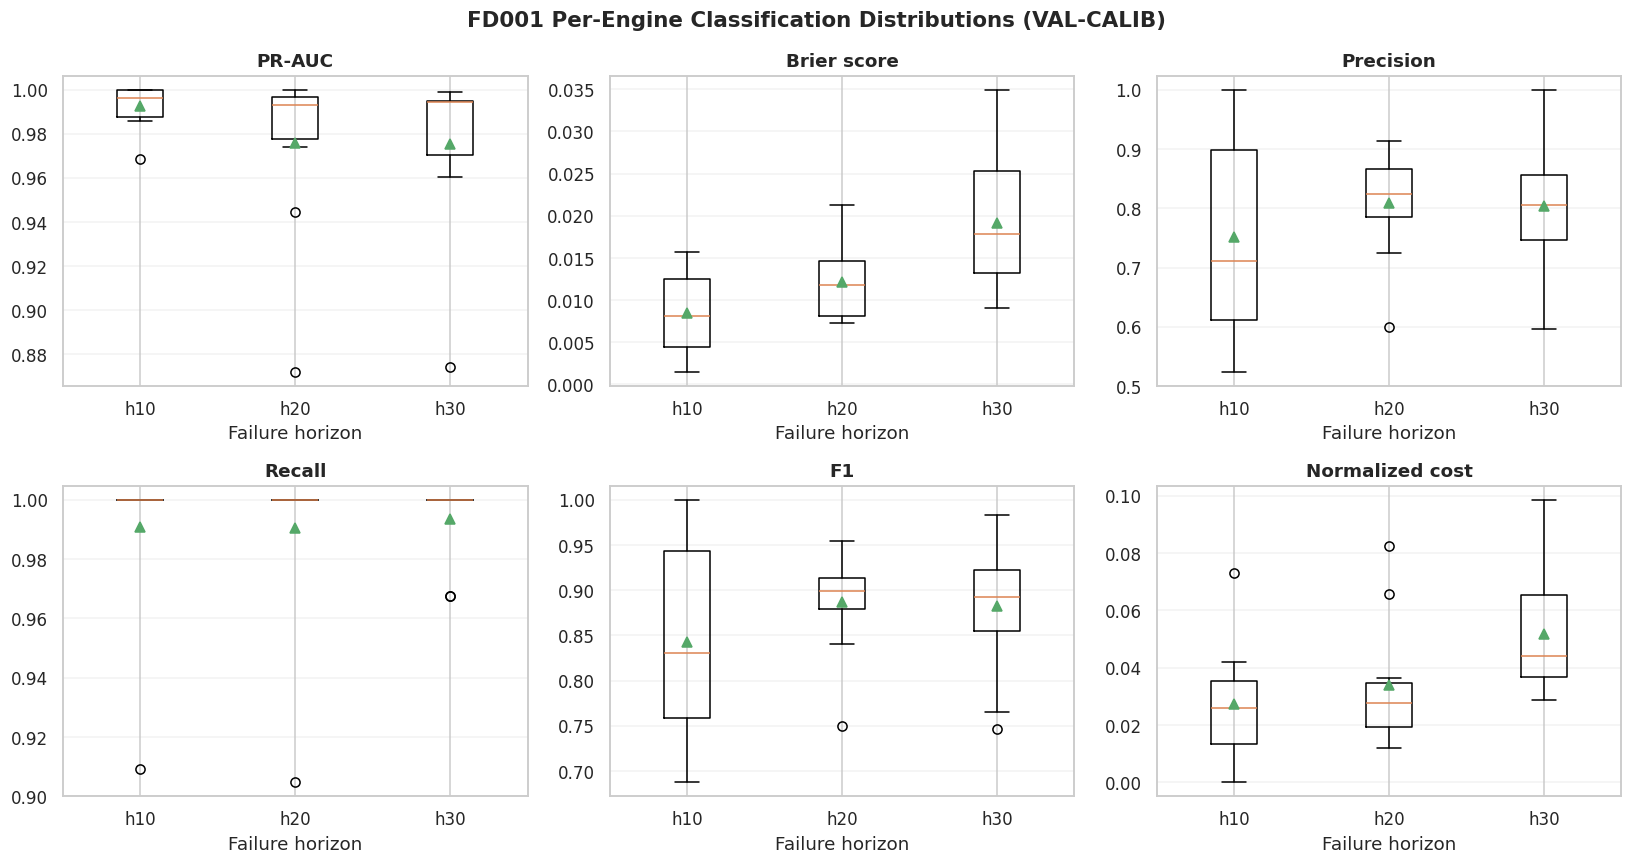

In [73]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import models_classification as mc


engine_ids = (
    df_val_calib["engine_id"].to_numpy(dtype=int)
)

per_engine_records = []

for engine_id in np.unique(engine_ids):
    engine_mask = engine_ids == engine_id

    for horizon in CLASSIFICATION_HORIZONS:
        y_true = ycalib[horizon][engine_mask]
        probability = p_mono[horizon][engine_mask]
        threshold = primary_thresholds[horizon]

        positive_count = int(y_true.sum())
        negative_count = int(
            len(y_true) - positive_count
        )
        both_classes = (
            positive_count > 0
            and negative_count > 0
        )

        assert both_classes, (
            f"Engine {engine_id}, h{horizon} "
            "does not contain both classes."
        )

        threshold_result = (
            mc.clf_metrics_at_threshold(
                y_true,
                probability,
                threshold,
            )
        )

        false_negative_cost = (
            PRIMARY_FN_COST
            * threshold_result["fn"]
        )
        false_positive_cost = (
            PRIMARY_FP_COST
            * threshold_result["fp"]
        )
        total_cost = (
            false_negative_cost
            + false_positive_cost
        )

        per_engine_records.append(
            {
                "partition": "val_calib",
                "engine_id": int(engine_id),
                "horizon": int(horizon),
                "n_rows": int(len(y_true)),
                "n_positive": positive_count,
                "n_negative": negative_count,
                "prevalence": float(y_true.mean()),
                "PR_AUC": float(
                    mc.average_precision(
                        y_true,
                        probability,
                    )
                ),
                "Brier": float(
                    mc.brier(
                        y_true,
                        probability,
                    )
                ),
                "threshold": float(threshold),
                "precision": float(
                    threshold_result["precision"]
                ),
                "recall": float(
                    threshold_result["recall"]
                ),
                "f1": float(
                    threshold_result["f1"]
                ),
                "tp": int(threshold_result["tp"]),
                "fp": int(threshold_result["fp"]),
                "fn": int(threshold_result["fn"]),
                "tn": int(threshold_result["tn"]),
                "false_negative_cost": float(
                    false_negative_cost
                ),
                "false_positive_cost": float(
                    false_positive_cost
                ),
                "total_row_cost": float(total_cost),
                "normalized_row_cost": float(
                    total_cost / len(y_true)
                ),
            }
        )


classification_per_engine = pd.DataFrame(
    per_engine_records
)

assert len(classification_per_engine) == (
    len(np.unique(engine_ids))
    * len(CLASSIFICATION_HORIZONS)
)


summary_metrics = [
    "PR_AUC",
    "Brier",
    "precision",
    "recall",
    "f1",
    "normalized_row_cost",
]

classification_per_engine_summary = (
    classification_per_engine
    .groupby("horizon")[summary_metrics]
    .agg(["mean", "median", "min", "max"])
)



plot_metrics = [
    ("PR_AUC", "PR-AUC"),
    ("Brier", "Brier score"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1"),
    ("normalized_row_cost", "Normalized cost"),
]

figure, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
)

for axis, (metric, label) in zip(
    axes.ravel(),
    plot_metrics,
):
    values_by_horizon = [
        classification_per_engine.loc[
            classification_per_engine["horizon"]
            == horizon,
            metric,
        ].to_numpy(dtype=float)
        for horizon in CLASSIFICATION_HORIZONS
    ]

    axis.boxplot(
        values_by_horizon,
        labels=[
            f"h{horizon}"
            for horizon in CLASSIFICATION_HORIZONS
        ],
        showmeans=True,
    )
    axis.set_title(label, fontweight="bold")
    axis.set_xlabel("Failure horizon")
    axis.grid(axis="y", alpha=0.25)

figure.suptitle(
    (
        f"{SUBSET} Per-Engine Classification "
        "Distributions (VAL-CALIB)"
    ),
    fontsize=14,
    fontweight="bold",
)

figure.tight_layout()


results_directory = Path(config.ARTIFACTS) / "results"
figures_directory = Path(config.FIGURES_DIR)

results_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

per_engine_path = (
    results_directory
    / f"{SUBSET}_classification_per_engine.csv"
)

figure_path = (
    figures_directory
    / f"{SUBSET}_classification_per_engine.png"
)

temporary_table_path = per_engine_path.with_suffix(
    per_engine_path.suffix + ".tmp"
)

classification_per_engine.to_csv(
    temporary_table_path,
    index=False,
)
temporary_table_path.replace(per_engine_path)

temporary_figure_path = figure_path.with_suffix(
    figure_path.suffix + ".tmp"
)

figure.savefig(
    temporary_figure_path,
    format="png",
    dpi=180,
    bbox_inches="tight",
)


In [74]:
temporary_figure_path.replace(figure_path)

plt.show()


print(" PER-ENGINE CLASSIFICATION SUMMARY ")
display(
    classification_per_engine_summary.round(6)
)

print("\n HIGHEST NORMALIZED ROW COSTS ")
display(
    classification_per_engine[
        [
            "engine_id",
            "horizon",
            "PR_AUC",
            "precision",
            "recall",
            "f1",
            "fp",
            "fn",
            "normalized_row_cost",
        ]
    ]
    .sort_values(
        "normalized_row_cost",
        ascending=False,
    )
    .head(10)
    .round(6)
)

print("\nSaved per-engine table:", per_engine_path)
print("Saved distribution figure:", figure_path)
print(
    "Costs here are row-level engine-cycle costs, "
    "not Task-6 persistent-alert costs."
)
print("Official test status: SEALED")


 PER-ENGINE CLASSIFICATION SUMMARY 


PR_AUC                                   Brier                      \
             mean    median       min       max      mean    median       min   
horizon                                                                         
10       0.992554  0.996212  0.968659  1.000000  0.008493  0.008122  0.001467   
20       0.975595  0.992986  0.871866  1.000000  0.012147  0.011767  0.007339   
30       0.975305  0.994226  0.874300  0.998992  0.019177  0.017875  0.009044   

                  precision            ...    recall             f1            \
              max      mean    median  ...       min  max      mean    median   
horizon                                ...                                      
10       0.015707  0.750863  0.710417  ...  0.909091  1.0  0.842461  0.830484   
20       0.021293  0.809011  0.823846  ...  0.904762  1.0  0.887096  0.899189   
30       0.034956  0.803886  0.805331  ...  0.967742  1.0  0.882359  0.892133   

                            normalized_row_cost                                
              min       max                mean    median       min       max  
horizon                                                                        
10       0.687500  1.000000            0.027436  0.025767  0.000000  0.072993  
20       0.750000  0.954545            0.033880  0.027582  0.011905  0.082397  
30       0.746988  0.983607            0.051847  0.044076  0.028846  0.098592  

[3 rows x 24 columns]


 HIGHEST NORMALIZED ROW COSTS 


,engine_id,horizon,PR_AUC,precision,recall,f1,fp,fn,normalized_row_cost
23,73,30,0.975739,0.596154,1.000000,0.746988,21,0,0.098592
25,84,20,0.974036,0.904762,0.904762,0.904762,2,2,0.082397
15,70,10,1.000000,1.000000,0.909091,0.952381,0,1,0.072993
2,19,30,0.994817,0.738095,1.000000,0.849315,11,0,0.069620
14,56,30,0.874300,0.620000,1.000000,0.765432,19,0,0.069091
22,73,20,1.000000,0.600000,1.000000,0.750000,14,0,0.065728
5,23,30,0.968638,0.775000,1.000000,0.873239,9,0,0.053571
29,97,30,0.998992,1.000000,0.967742,0.983607,0,1,0.049505
6,32,10,0.968659,0.578947,1.000000,0.733333,8,0,0.041885
11,43,30,0.997004,0.794872,1.000000,0.885714,8,0,0.038647



Saved per-engine table: artifacts/results/FD001_classification_per_engine.csv
Saved distribution figure: figures/FD001_classification_per_engine.png
Costs here are row-level engine-cycle costs, not Task-6 persistent-alert costs.
Official test status: SEALED


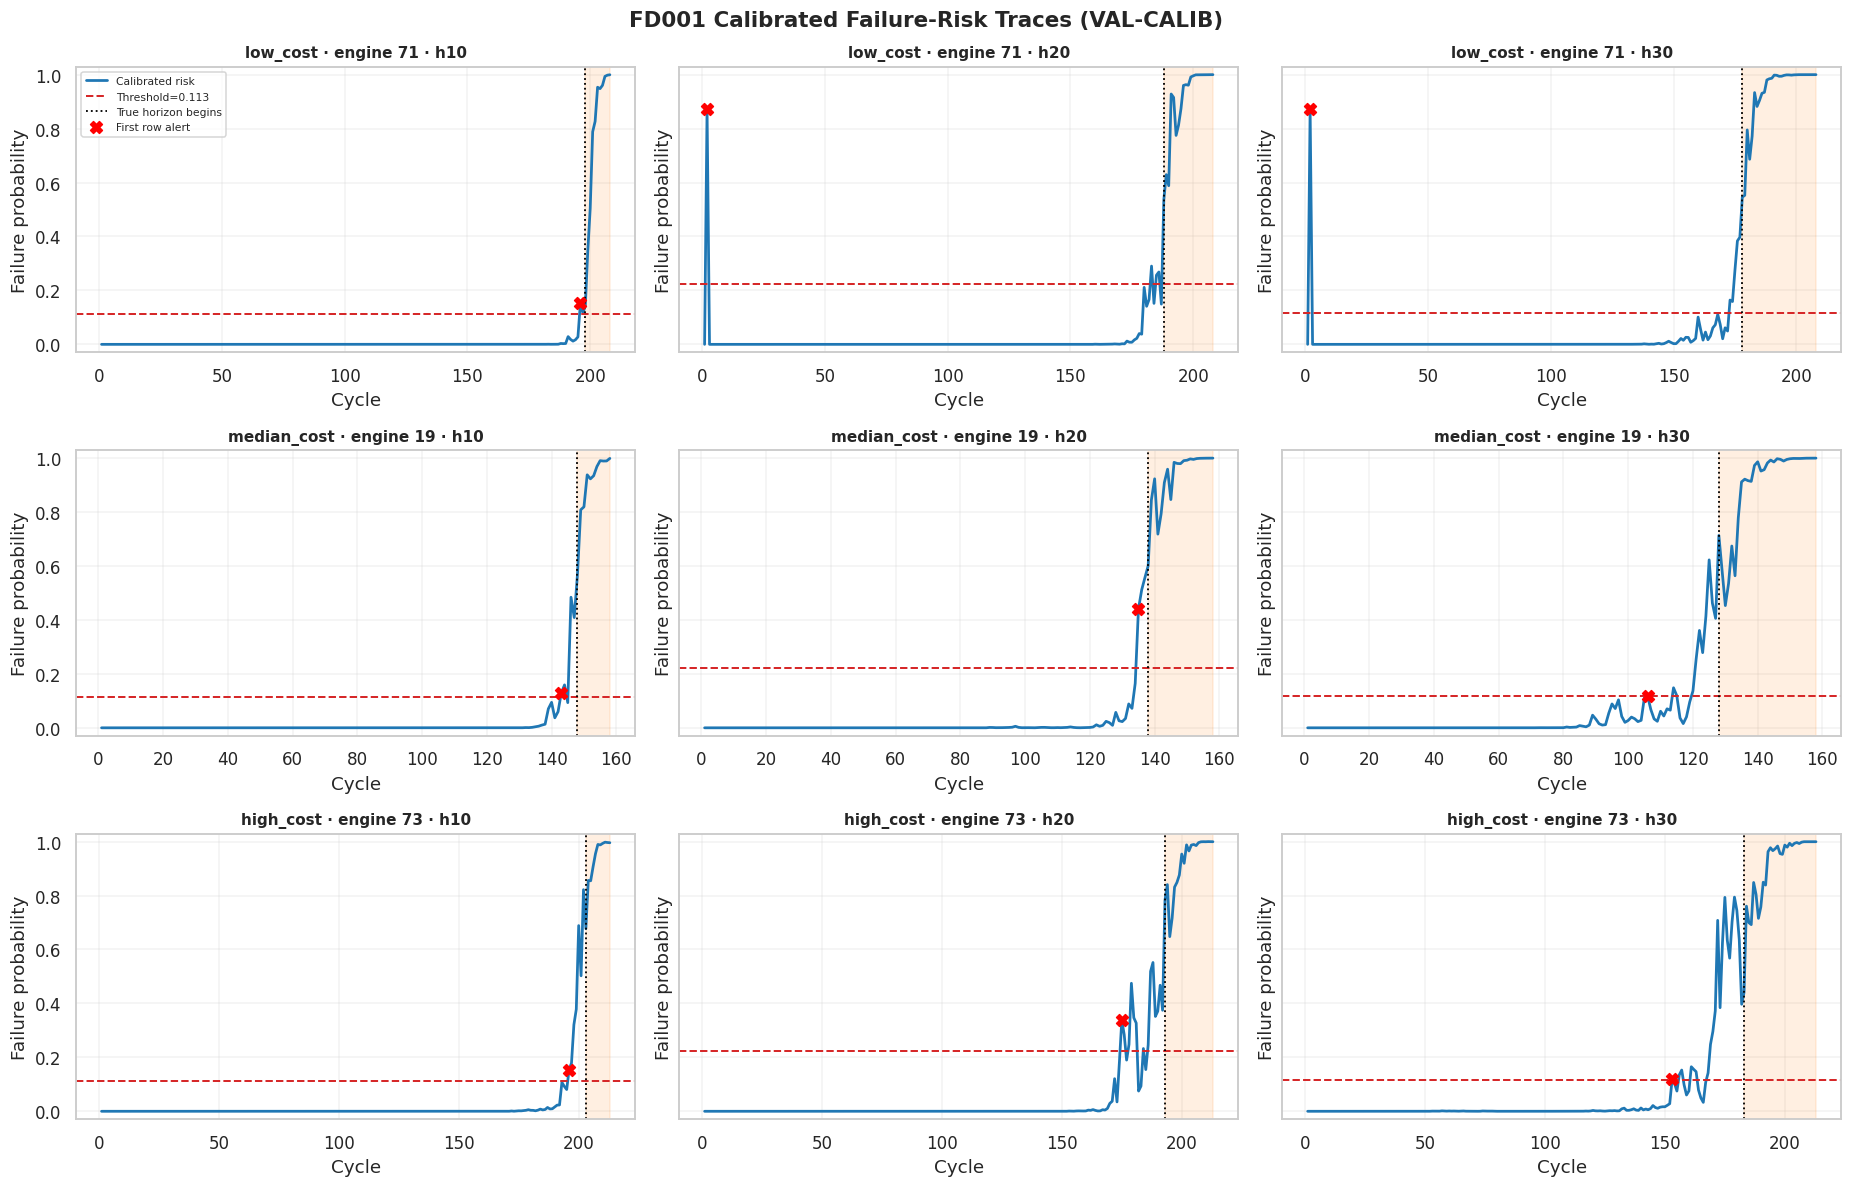

In [75]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


engine_cost_ranking = (
    classification_per_engine
    .groupby("engine_id")[
        "normalized_row_cost"
    ]
    .mean()
    .sort_values()
)

ordered_engine_ids = (
    engine_cost_ranking.index.astype(int).tolist()
)

selected_trace_engines = {
    "low_cost": ordered_engine_ids[0],
    "median_cost": ordered_engine_ids[
        len(ordered_engine_ids) // 2
    ],
    "high_cost": ordered_engine_ids[-1],
}

assert len(
    set(selected_trace_engines.values())
) == 3


trace_records = []
alert_summary_records = []

figure, axes = plt.subplots(
    3,
    3,
    figsize=(17, 11),
    sharey=True,
)

for row_index, (
    engine_role,
    engine_id,
) in enumerate(selected_trace_engines.items()):
    engine_mask = (
        df_val_calib["engine_id"].to_numpy(dtype=int)
        == engine_id
    )

    engine_cycles = df_val_calib.loc[
        engine_mask,
        "cycle",
    ].to_numpy(dtype=int)

    final_cycle = int(engine_cycles.max())

    for column_index, horizon in enumerate(
        CLASSIFICATION_HORIZONS
    ):
        axis = axes[row_index, column_index]

        probability = p_mono[horizon][engine_mask]
        y_true = ycalib[horizon][engine_mask]
        threshold = primary_thresholds[horizon]
        decision = (
            probability >= threshold
        ).astype(int)

        positive_cycles = engine_cycles[
            y_true == 1
        ]
        alert_cycles = engine_cycles[
            decision == 1
        ]

        first_positive_cycle = int(
            positive_cycles.min()
        )
        first_alert_cycle = (
            int(alert_cycles.min())
            if len(alert_cycles)
            else None
        )

        axis.plot(
            engine_cycles,
            probability,
            color="tab:blue",
            linewidth=1.8,
            label="Calibrated risk",
        )

        axis.axhline(
            threshold,
            color="tab:red",
            linestyle="--",
            linewidth=1.3,
            label=f"Threshold={threshold:.3f}",
        )

        axis.axvline(
            first_positive_cycle,
            color="black",
            linestyle=":",
            linewidth=1.2,
            label="True horizon begins",
        )

        axis.axvspan(
            first_positive_cycle,
            final_cycle,
            color="tab:orange",
            alpha=0.12,
        )

        if first_alert_cycle is not None:
            axis.scatter(
                [first_alert_cycle],
                [
                    probability[
                        engine_cycles
                        == first_alert_cycle
                    ][0]
                ],
                color="red",
                marker="X",
                s=60,
                zorder=5,
                label="First row alert",
            )

        axis.set_title(
            (
                f"{engine_role} · engine {engine_id} "
                f"· h{horizon}"
            ),
            fontweight="bold",
            fontsize=10,
        )
        axis.set_xlabel("Cycle")
        axis.set_ylabel("Failure probability")
        axis.set_ylim(-0.03, 1.03)
        axis.grid(alpha=0.25)

        if row_index == 0 and column_index == 0:
            axis.legend(fontsize=7)

        alert_summary_records.append(
            {
                "engine_role": engine_role,
                "engine_id": int(engine_id),
                "horizon": int(horizon),
                "final_cycle": final_cycle,
                "first_true_positive_cycle": (
                    first_positive_cycle
                ),
                "first_row_alert_cycle": (
                    first_alert_cycle
                ),
                "row_alert_lead_to_failure": (
                    final_cycle - first_alert_cycle
                    if first_alert_cycle is not None
                    else np.nan
                ),
                "threshold": float(threshold),
            }
        )

        for cycle, label, risk, alert in zip(
            engine_cycles,
            y_true,
            probability,
            decision,
        ):
            trace_records.append(
                {
                    "engine_role": engine_role,
                    "engine_id": int(engine_id),
                    "cycle": int(cycle),
                    "horizon": int(horizon),
                    "label": int(label),
                    "probability": float(risk),
                    "threshold": float(threshold),
                    "row_alert": int(alert),
                }
            )


figure.suptitle(
    (
        f"{SUBSET} Calibrated Failure-Risk Traces "
        "(VAL-CALIB)"
    ),
    fontsize=14,
    fontweight="bold",
)

figure.tight_layout()


classification_probability_traces = pd.DataFrame(
    trace_records
)
classification_trace_summary = pd.DataFrame(
    alert_summary_records
)

selected_engine_table = pd.DataFrame(
    [
        {
            "engine_role": role,
            "engine_id": engine_id,
            "mean_normalized_row_cost": float(
                engine_cost_ranking.loc[engine_id]
            ),
        }
        for role, engine_id
        in selected_trace_engines.items()
    ]
)


In [76]:
results_directory = Path(config.ARTIFACTS) / "results"
figures_directory = Path(config.FIGURES_DIR)

results_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

traces_path = (
    results_directory
    / f"{SUBSET}_classification_probability_traces.csv"
)
trace_summary_path = (
    results_directory
    / f"{SUBSET}_classification_trace_summary.csv"
)
figure_path = (
    figures_directory
    / f"{SUBSET}_classification_probability_traces.png"
)

for dataframe, destination in (
    (
        classification_probability_traces,
        traces_path,
    ),
    (
        classification_trace_summary,
        trace_summary_path,
    ),
):
    temporary_path = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    dataframe.to_csv(temporary_path, index=False)
    temporary_path.replace(destination)

temporary_figure_path = figure_path.with_suffix(
    figure_path.suffix + ".tmp"
)

figure.savefig(
    temporary_figure_path,
    format="png",
    dpi=180,
    bbox_inches="tight",
)

temporary_figure_path.replace(figure_path)

plt.show()


print(" SELECTED TRACE ENGINES ")
display(selected_engine_table.round(6))

print("\n FIRST ROW-LEVEL ALERTS ")
display(classification_trace_summary.round(6))

print("\nSaved traces:", traces_path)
print("Saved trace summary:", trace_summary_path)
print(
    "First row-level alert is diagnostic only; "
    "persistent alert analysis is still pending."
)
print("Official test status: SEALED")


 SELECTED TRACE ENGINES 


,engine_role,engine_id,mean_normalized_row_cost
0,low_cost,71,0.019231
1,median_cost,19,0.037975
2,high_cost,73,0.065728



 FIRST ROW-LEVEL ALERTS 


,engine_role,engine_id,horizon,final_cycle,first_true_positive_cycle,first_row_alert_cycle,row_alert_lead_to_failure,threshold
0,low_cost,71,10,208,198,196,12,0.113404
1,low_cost,71,20,208,188,2,206,0.222905
2,low_cost,71,30,208,178,2,206,0.116540
3,median_cost,19,10,158,148,143,15,0.113404
4,median_cost,19,20,158,138,135,23,0.222905
5,median_cost,19,30,158,128,106,52,0.116540
6,high_cost,73,10,213,203,196,17,0.113404
7,high_cost,73,20,213,193,175,38,0.222905
8,high_cost,73,30,213,183,153,60,0.116540



Saved traces: artifacts/results/FD001_classification_probability_traces.csv
Saved trace summary: artifacts/results/FD001_classification_trace_summary.csv
First row-level alert is diagnostic only; persistent alert analysis is still pending.
Official test status: SEALED


In [77]:
import numpy as np
import pandas as pd

import models_anomaly as ma


ANOMALY_BOUNDARY_CANDIDATES = (100, 125, 150)
ANOMALY_REFERENCE_FRACTION = 0.25

SETTINGS = list(config.SETTING_COLS)
SENSORS = list(config.SENSOR_COLS)
CANON = SETTINGS + SENSORS

assert len(SETTINGS) == 3
assert len(SENSORS) == 21
assert len(CANON) == 24
assert len(set(CANON)) == 24

for frame_name, frame in (
    ("train", df_tr),
    ("val_tune", df_val_tune),
    ("val_calib", df_val_calib),
):
    assert all(
        column in frame.columns
        for column in CANON
    ), f"{frame_name}: missing anomaly features"

    assert np.isfinite(
        frame[CANON].to_numpy(dtype=float)
    ).all()

    assert not frame.duplicated(
        ["engine_id", "cycle"]
    ).any()


expected_train_rul = (
    df_tr.groupby("engine_id")["cycle"]
    .transform("max")
    - df_tr["cycle"]
)

assert np.array_equal(
    df_tr["RUL"].to_numpy(dtype=int),
    expected_train_rul.to_numpy(dtype=int),
)


train_engine_ids = sorted(
    df_tr["engine_id"].astype(int).unique()
)

anomaly_subdivision = (
    ma.make_anomaly_train_subdivision(
        train_engine_ids,
        seed=config.RANDOM_SEED,
        reference_fraction=(
            ANOMALY_REFERENCE_FRACTION
        ),
    )
)

fit_ids = [
    int(engine_id)
    for engine_id in anomaly_subdivision[
        "anomaly_fit_ids"
    ]
]
ref_ids = [
    int(engine_id)
    for engine_id in anomaly_subdivision[
        "anomaly_reference_ids"
    ]
]

ma.validate_same_source_roles(
    fit_ids=fit_ids,
    reference_ids=ref_ids,
    allowed_train_ids=train_engine_ids,
    val_tune_ids=VAL_TUNE_IDS,
    val_calib_ids=VAL_CALIB_IDS,
    source_role="train",
    declared_source="train",
)


feasibility_records = []

for role, role_engine_ids in (
    ("anomaly_fit", fit_ids),
    ("anomaly_reference", ref_ids),
):
    for boundary in ANOMALY_BOUNDARY_CANDIDATES:
        for engine_id in role_engine_ids:
            healthy_count = int(
                (
                    (df_tr["engine_id"] == engine_id)
                    & (df_tr["RUL"] > boundary)
                ).sum()
            )

            feasibility_records.append(
                {
                    "role": role,
                    "engine_id": int(engine_id),
                    "boundary": int(boundary),
                    "healthy_row_count": healthy_count,
                    "contributes_any": bool(
                        healthy_count > 0
                    ),
                }
            )

anomaly_boundary_feasibility_by_engine = (
    pd.DataFrame(feasibility_records)
)

anomaly_boundary_feasibility = (
    anomaly_boundary_feasibility_by_engine
    .groupby(
        ["role", "boundary"],
        as_index=False,
    )
    .agg(
        n_engines=("engine_id", "nunique"),
        total_healthy_rows=(
            "healthy_row_count",
            "sum",
        ),
        contributing_engines=(
            "contributes_any",
            "sum",
        ),
        minimum_rows_per_engine=(
            "healthy_row_count",
            "min",
        ),
        median_rows_per_engine=(
            "healthy_row_count",
            "median",
        ),
    )
)

anomaly_boundary_feasibility[
    "all_engines_contribute"
] = (
    anomaly_boundary_feasibility[
        "n_engines"
    ]
    == anomaly_boundary_feasibility[
        "contributing_engines"
    ]
)


def boundary_is_feasible(boundary):
    rows = anomaly_boundary_feasibility[
        anomaly_boundary_feasibility[
            "boundary"
        ]
        == boundary
    ]

    return (
        len(rows) == 2
        and rows["all_engines_contribute"].all()
    )


if boundary_is_feasible(125):
    BOUNDARY = 125
    boundary_reason = (
        "Primary RUL>125 boundary is feasible "
        "for every fit/reference engine."
    )
else:
    assert boundary_is_feasible(100)
    BOUNDARY = 100
    boundary_reason = (
        "Fallback RUL>100 used because RUL>125 "
        "excluded at least one fit/reference engine."
    )


fit_mask = (
    df_tr["engine_id"].isin(fit_ids)
    & (df_tr["RUL"] > BOUNDARY)
)
reference_mask = (
    df_tr["engine_id"].isin(ref_ids)
    & (df_tr["RUL"] > BOUNDARY)
)

anomaly_fit_healthy = df_tr.loc[
    fit_mask
].copy()
anomaly_reference_healthy = df_tr.loc[
    reference_mask
].copy()

X_fit_healthy_raw = anomaly_fit_healthy[
    CANON
].to_numpy(dtype=float)

X_reference_healthy_raw = (
    anomaly_reference_healthy[
        CANON
    ].to_numpy(dtype=float)
)

pp = ma.AnomalyPreprocessor(
    std_threshold=1e-6
).fit(
    X_fit_healthy_raw,
    CANON,
    fit_engine_ids=fit_ids,
    healthy_boundary=BOUNDARY,
    source_role="anomaly_fit_train",
)


In [78]:
X_fit_healthy = pp.transform(
    X_fit_healthy_raw,
    CANON,
)
X_reference_healthy = pp.transform(
    X_reference_healthy_raw,
    CANON,
)

assert np.isfinite(X_fit_healthy).all()
assert np.isfinite(X_reference_healthy).all()
assert X_fit_healthy.shape[1] == (
    X_reference_healthy.shape[1]
)

ma.assert_test_excluded_by_source(
    "train"
)


print(" ANOMALY HEALTHY-REGION AUDIT ")
display(anomaly_boundary_feasibility)

print("\nSelected healthy boundary:", f"RUL > {BOUNDARY}")
print("Reason:", boundary_reason)
print(
    "Anomaly TRAIN subdivision:",
    {
        "fit_engines": len(fit_ids),
        "reference_engines": len(ref_ids),
    },
)
print(
    "Healthy rows:",
    {
        "fit": len(anomaly_fit_healthy),
        "reference": len(
            anomaly_reference_healthy
        ),
    },
)
print(
    "Feature dimensions:",
    {
        "raw": len(CANON),
        "after_preprocessing": (
            X_fit_healthy.shape[1]
        ),
    },
)
print("Detector fitted: NO")
print("Anomaly score produced: NO")
print("Official test status: SEALED")


 ANOMALY HEALTHY-REGION AUDIT 


,role,boundary,n_engines,total_healthy_rows,contributing_engines,minimum_rows_per_engine,median_rows_per_engine,all_engines_contribute
0,anomaly_fit,100,52,5167,52,27,94.0,True
1,anomaly_fit,125,52,3867,52,2,69.0,True
2,anomaly_fit,150,52,2612,48,0,44.0,False
3,anomaly_reference,100,18,2270,18,49,113.0,True
4,anomaly_reference,125,18,1820,18,24,88.0,True
5,anomaly_reference,150,18,1371,17,0,63.0,False



Selected healthy boundary: RUL > 125
Reason: Primary RUL>125 boundary is feasible for every fit/reference engine.
Anomaly TRAIN subdivision: {'fit_engines': 52, 'reference_engines': 18}
Healthy rows: {'fit': 3867, 'reference': 1820}
Feature dimensions: {'raw': 24, 'after_preprocessing': 17}
Detector fitted: NO
Anomaly score produced: NO
Official test status: SEALED


In [79]:
import hashlib
import json
from pathlib import Path

import joblib
import numpy as np


models_directory = Path(config.ARTIFACTS) / "models"
results_directory = Path(config.ARTIFACTS) / "results"
processed_directory = Path(config.DATA_PROCESSED)

models_directory.mkdir(parents=True, exist_ok=True)
results_directory.mkdir(parents=True, exist_ok=True)
processed_directory.mkdir(parents=True, exist_ok=True)


anomaly_preprocessing_bundle = {
    "artifact_type": "anomaly_preprocessing_bundle",
    "artifact_version": 1,
    "subset": SUBSET,
    "official_source": "train",
    "internal_fit_role": "anomaly_fit_train",
    "healthy_definition": {
        "column": "RUL",
        "operator": ">",
        "boundary": int(BOUNDARY),
        "semantics": "uncapped training RUL",
        "primary_boundary": 125,
        "fallback_boundary": 100,
        "sensitivity_boundary": 150,
        "selection_reason": boundary_reason,
    },
    "feature_schema": {
        "settings": SETTINGS,
        "sensors": SENSORS,
        "raw_features": CANON,
        "n_raw_features": len(CANON),
        "n_transformed_features": int(
            X_fit_healthy.shape[1]
        ),
    },
    "subdivision": {
        "seed": int(config.RANDOM_SEED),
        "reference_fraction": float(
            ANOMALY_REFERENCE_FRACTION
        ),
        "rounding_rule": anomaly_subdivision[
            "rounding_rule"
        ],
        "anomaly_fit_ids": fit_ids,
        "anomaly_reference_ids": ref_ids,
    },
    "row_counts": {
        "healthy_fit": int(
            len(anomaly_fit_healthy)
        ),
        "healthy_reference": int(
            len(anomaly_reference_healthy)
        ),
    },
    "preprocessor": pp,
    "detector_status": "not_fitted",
    "official_test_status": "sealed",
}


preprocessing_bundle_path = (
    models_directory
    / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
)

temporary_bundle_path = (
    preprocessing_bundle_path.with_suffix(
        preprocessing_bundle_path.suffix + ".tmp"
    )
)

joblib.dump(
    anomaly_preprocessing_bundle,
    temporary_bundle_path,
)

reloaded_bundle = joblib.load(
    temporary_bundle_path
)

reloaded_reference_features = (
    reloaded_bundle["preprocessor"].transform(
        X_reference_healthy_raw,
        CANON,
    )
)

assert np.allclose(
    reloaded_reference_features,
    X_reference_healthy,
    rtol=0.0,
    atol=1e-12,
)

assert reloaded_bundle[
    "detector_status"
] == "not_fitted"
assert reloaded_bundle[
    "official_test_status"
] == "sealed"

temporary_bundle_path.replace(
    preprocessing_bundle_path
)

preprocessing_bundle_sha256 = hashlib.sha256(
    preprocessing_bundle_path.read_bytes()
).hexdigest()


feasibility_by_engine_path = (
    results_directory
    / f"{SUBSET}_anomaly_boundary_feasibility_by_engine.csv"
)

feasibility_summary_path = (
    results_directory
    / f"{SUBSET}_anomaly_boundary_feasibility.csv"
)

for dataframe, destination in (
    (
        anomaly_boundary_feasibility_by_engine,
        feasibility_by_engine_path,
    ),
    (
        anomaly_boundary_feasibility,
        feasibility_summary_path,
    ),
):
    temporary_path = destination.with_suffix(
        destination.suffix + ".tmp"
    )
    dataframe.to_csv(temporary_path, index=False)
    temporary_path.replace(destination)


preprocessing_contract = {
    "subset": SUBSET,
    "artifact_type": "anomaly_preprocessing_contract",
    "official_source": "train",
    "internal_fit_role": "anomaly_fit_train",
    "healthy_boundary": int(BOUNDARY),
    "healthy_rule": f"uncapped RUL > {BOUNDARY}",
    "boundary_reason": boundary_reason,
    "fit_engines": len(fit_ids),
    "reference_engines": len(ref_ids),
    "healthy_fit_rows": len(
        anomaly_fit_healthy
    ),
    "healthy_reference_rows": len(
        anomaly_reference_healthy
    ),
    "raw_feature_count": len(CANON),
    "transformed_feature_count": int(
        X_fit_healthy.shape[1]
    ),
    "bundle_path": str(
        preprocessing_bundle_path
    ),
    "bundle_sha256": (
        preprocessing_bundle_sha256
    ),
    "detector_status": "not_fitted",
    "official_test_status": "sealed",
    "caveats": [
        (
            "RUL is used only to select a healthy "
            "TRAIN fitting region."
        ),
        (
            "Detector fitting itself receives no "
            "failure label."
        ),
        (
            "Unknown initial wear means early-life "
            "healthy status is a defensible proxy, "
            "not perfect ground truth."
        ),
    ],
}

preprocessing_contract_path = (
    processed_directory
    / f"{SUBSET}_anomaly_preprocessing.json"
)

temporary_contract_path = (
    preprocessing_contract_path.with_suffix(
        preprocessing_contract_path.suffix + ".tmp"
    )
)

temporary_contract_path.write_text(
    json.dumps(
        preprocessing_contract,
        indent=2,
    ),
    encoding="utf-8",
)

temporary_contract_path.replace(
    preprocessing_contract_path
)


print(" ANOMALY PREPROCESSING ARTIFACT ")
print("Bundle:", preprocessing_bundle_path)
print("SHA256:", preprocessing_bundle_sha256)
print(
    "Bundle size:",
    f"{preprocessing_bundle_path.stat().st_size / 1024:.1f} KiB",
)


 ANOMALY PREPROCESSING ARTIFACT 
Bundle: artifacts/models/FD001_anomaly_preprocessing_bundle.joblib
SHA256: c3f841a3f8bb21cf5921ba5d0cd630d49e773a97b334191082cf7fbbbb86a8ce
Bundle size: 3.1 KiB


In [80]:
print("Reload transform parity: PASS")
print(
    "Feasibility by engine:",
    feasibility_by_engine_path,
)
print(
    "Feasibility summary:",
    feasibility_summary_path,
)
print("Contract:", preprocessing_contract_path)
print("Detector status: NOT FITTED")
print("Official test status: SEALED")


Reload transform parity: PASS
Feasibility by engine: artifacts/results/FD001_anomaly_boundary_feasibility_by_engine.csv
Feasibility summary: artifacts/results/FD001_anomaly_boundary_feasibility.csv
Contract: data/processed/FD001_anomaly_preprocessing.json
Detector status: NOT FITTED
Official test status: SEALED


## 7.1 · Unsupervised Anomaly Detection

### Locked development protocol

The anomaly pipeline is fitted without failure labels. Training RUL is used only
to define a defensible proxy healthy region; it is not supplied to any anomaly
detector.

#### Data roles

- **Anomaly-fit:** 52 TRAIN engines used to fit preprocessing and detectors.
- **Anomaly-reference:** 18 disjoint TRAIN engines used to construct fixed
  healthy reference score distributions and percentiles.
- **VAL-TUNE:** used only to compare detector behavior, proxy discrimination,
  trajectory stability, and threshold sensitivity.
- **VAL-CALIB:** reserved for the frozen anomaly and persistence policy.
- **Official TEST:** remains sealed until all models and policies are locked.

#### Healthy-region rule

The primary healthy proxy is:

\[
\mathrm{RUL} > 125
\]

This boundary is accepted only when every anomaly-fit and anomaly-reference
engine contributes at least one healthy row. `RUL > 100` is the predefined
fallback, while `RUL > 150` is reported only as sensitivity analysis.

The healthy region is imperfect because initial wear is unknown. It is therefore
documented as a training proxy rather than true healthy ground truth.

#### Preprocessing

The canonical input contains three operating settings and 21 sensors.
`AnomalyPreprocessor` is fitted only on healthy anomaly-fit rows. Near-constant
features are removed using TRAIN-only statistics and retained features are
scaled. The fitted pipeline reduced 24 raw inputs to 17 transformed features.

#### Required detectors

Four unsupervised detector families are compared:

1. Isolation Forest;
2. Local Outlier Factor with `novelty=True`;
3. One-Class SVM;
4. PCA reconstruction error.

All detector scores are oriented so that larger values mean more abnormal.
Raw scores from different detector families are not interpreted as
probabilities. Each score is mapped to a percentile using a fixed healthy
anomaly-reference distribution.

Validation failure proximity may be used for evaluation and candidate selection,
but never for fitting a detector or preprocessing transformation.

**Current status:** preprocessing is frozen and reload-tested; no detector has
yet been fitted; official test remains sealed.

In [81]:
import hashlib
import json
import os
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


SEED = int(config.RANDOM_SEED)
MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

for directory in (MODEL_DIR, RESULT_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ma.assert_test_excluded_by_source("train")

assert len(anomaly_fit_healthy) == X_fit_healthy.shape[0]
assert len(anomaly_reference_healthy) == X_reference_healthy.shape[0]
assert X_fit_healthy.shape[1] == X_reference_healthy.shape[1]
assert np.isfinite(X_fit_healthy).all()
assert np.isfinite(X_reference_healthy).all()


reference_engine_ids = anomaly_reference_healthy[
    "engine_id"
].to_numpy(dtype=int)

eb_info = ma.engine_balanced_reference_indices(
    reference_engine_ids,
    seed=SEED,
)
eb_positions = np.asarray(eb_info["positions"], dtype=int)

assert eb_info["k"] >= 1
assert eb_positions.size == (
    len(np.unique(reference_engine_ids)) * eb_info["k"]
)

IFOREST_GRID = [
    {"n_estimators": n_estimators, "max_samples": max_samples}
    for n_estimators in (200, 400)
    for max_samples in ("auto", 0.5)
]

candidate_bundle = {}
summary_rows = []

for params in IFOREST_GRID:
    sample_label = (
        "auto"
        if params["max_samples"] == "auto"
        else "0p5"
    )
    candidate_id = (
        f"iforest_n{params['n_estimators']}"
        f"_ms_{sample_label}"
    )

    fit_start = time.perf_counter()

    model, model_metadata = ma.make_detector(
        "iforest",
        seed=SEED,
        n_estimators=params["n_estimators"],
        max_samples=params["max_samples"],
    )
    model.fit(X_fit_healthy)

    fit_seconds = time.perf_counter() - fit_start

    score_start = time.perf_counter()
    reference_scores = ma.oriented_raw_score(
        "iforest",
        model,
        X_reference_healthy,
    )
    score_seconds = time.perf_counter() - score_start

    reference_scores = np.asarray(
        reference_scores,
        dtype=float,
    )

    assert reference_scores.shape == (
        len(anomaly_reference_healthy),
    )
    assert np.isfinite(reference_scores).all()

    pooled_cdf = ma.build_reference_cdf(
        reference_scores,
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )
    engine_balanced_cdf = ma.build_reference_cdf(
        reference_scores[eb_positions],
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )

    assert np.array_equal(
        pooled_cdf["sorted_scores"],
        np.sort(reference_scores),
    )
    assert len(engine_balanced_cdf["sorted_scores"]) == (
        eb_positions.size
    )

    pooled_percentiles = ma.reference_percentile(
        pooled_cdf,
        reference_scores,
    )
    assert np.isfinite(pooled_percentiles).all()
    assert np.all(
        (pooled_percentiles >= 0.0)
        & (pooled_percentiles <= 1.0)
    )

    candidate_bundle[candidate_id] = {
        "family": "iforest",
        "model": model,
        "parameters": dict(params),
        "model_metadata": model_metadata,
        "score_orientation": "larger_is_more_abnormal",
        "pooled_reference_cdf": pooled_cdf,
        "engine_balanced_reference_cdf": (
            engine_balanced_cdf
        ),
    }

    summary_rows.append({
        "candidate_id": candidate_id,
        "family": "iforest",
        "n_estimators": params["n_estimators"],
        "max_samples": params["max_samples"],
        "n_fit_rows": X_fit_healthy.shape[0],
        "n_reference_rows": X_reference_healthy.shape[0],
        "n_engine_balanced_reference_rows": (
            eb_positions.size
        ),
        "reference_engines": len(
            np.unique(reference_engine_ids)
        ),
        "engine_balanced_k": eb_info["k"],
        "fit_time_seconds": fit_seconds,
        "reference_score_time_seconds": score_seconds,
        "reference_score_min": reference_scores.min(),
        "reference_score_median": np.median(reference_scores),
        "reference_score_max": reference_scores.max(),
    })

assert len(candidate_bundle) == 4

preprocessing_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
)
preprocessing_sha256 = hashlib.sha256(
    preprocessing_path.read_bytes()
).hexdigest()

artifact = {
    "artifact_type": "anomaly_iforest_candidates",
    "artifact_version": 1,
    "subset": SUBSET,
    "seed": SEED,
    "official_source": "train",
    "fit_role": "anomaly_fit",
    "reference_role": "anomaly_reference",
    "healthy_definition": f"RUL > {BOUNDARY}",
    "score_orientation": "larger_is_more_abnormal",
    "primary_reference": "pooled_reference_cdf",
    "sensitivity_reference": (
        "engine_balanced_reference_cdf"
    ),
    "preprocessing_bundle_sha256": (
        preprocessing_sha256
    ),
    "reference_balancing": eb_info,
    "candidates": candidate_bundle,
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_iforest_candidates.joblib"
)
temporary_bundle_path = Path(
    str(bundle_path) + ".tmp"
)

joblib.dump(artifact, temporary_bundle_path)
os.replace(temporary_bundle_path, bundle_path)

reloaded = joblib.load(bundle_path)

for candidate_id in candidate_bundle:
    original_scores = ma.oriented_raw_score(
        "iforest",
        candidate_bundle[candidate_id]["model"],
        X_reference_healthy,
    )
    reloaded_scores = ma.oriented_raw_score(
        "iforest",
        reloaded["candidates"][candidate_id]["model"],
        X_reference_healthy,
    )
    assert np.allclose(
        original_scores,
        reloaded_scores,
        rtol=0.0,
        atol=1e-12,
    ), f"Reload parity failed: {candidate_id}"


In [82]:
summary = pd.DataFrame(summary_rows).sort_values(
    ["n_estimators", "max_samples"],
    kind="mergesort",
).reset_index(drop=True)

summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_iforest_train_candidates.csv"
)
temporary_summary_path = Path(
    str(summary_path) + ".tmp"
)
summary.to_csv(temporary_summary_path, index=False)
os.replace(temporary_summary_path, summary_path)

contract = {
    "subset": SUBSET,
    "family": "iforest",
    "candidate_count": len(candidate_bundle),
    "candidate_ids": list(candidate_bundle),
    "healthy_boundary": int(BOUNDARY),
    "fit_rows": int(X_fit_healthy.shape[0]),
    "reference_rows": int(
        X_reference_healthy.shape[0]
    ),
    "reference_engines": int(
        len(np.unique(reference_engine_ids))
    ),
    "engine_balanced_k": int(eb_info["k"]),
    "engine_balanced_rows": int(
        eb_positions.size
    ),
    "bundle": str(bundle_path),
    "bundle_sha256": hashlib.sha256(
        bundle_path.read_bytes()
    ).hexdigest(),
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_iforest_candidates.json"
)
temporary_contract_path = Path(
    str(contract_path) + ".tmp"
)
temporary_contract_path.write_text(
    json.dumps(contract, indent=2),
    encoding="utf-8",
)
os.replace(temporary_contract_path, contract_path)

print(" ISOLATION FOREST TRAIN-ONLY CANDIDATES ")
display(summary.round(6))

print("Candidate count:", len(candidate_bundle))
print("Healthy definition:", f"RUL > {BOUNDARY}")
print("Fit rows:", X_fit_healthy.shape[0])
print("Reference rows:", X_reference_healthy.shape[0])
print(
    "Engine-balanced reference:",
    f"{len(np.unique(reference_engine_ids))} engines",
    f"x {eb_info['k']} rows = {eb_positions.size}",
)
print("Saved bundle:", bundle_path)
print("Bundle SHA256:", contract["bundle_sha256"])
print("Saved summary:", summary_path)
print("Saved contract:", contract_path)
print("Reload score parity: PASS")
print("Selection status: PENDING VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 ISOLATION FOREST TRAIN-ONLY CANDIDATES 


,candidate_id,family,n_estimators,max_samples,n_fit_rows,n_reference_rows,n_engine_balanced_reference_rows,reference_engines,engine_balanced_k,fit_time_seconds,reference_score_time_seconds,reference_score_min,reference_score_median,reference_score_max
0,iforest_n200_ms_0p5,iforest,200,0.5,3867,1820,432,18,24,0.372427,0.028418,0.368609,0.415064,0.562445
1,iforest_n200_ms_auto,iforest,200,auto,3867,1820,432,18,24,0.503256,0.021563,0.385008,0.443342,0.577014
2,iforest_n400_ms_0p5,iforest,400,0.5,3867,1820,432,18,24,0.655468,0.067310,0.369542,0.414766,0.566578
3,iforest_n400_ms_auto,iforest,400,auto,3867,1820,432,18,24,0.693368,0.039350,0.384569,0.441907,0.574733


Candidate count: 4
Healthy definition: RUL > 125
Fit rows: 3867
Reference rows: 1820
Engine-balanced reference: 18 engines x 24 rows = 432
Saved bundle: artifacts/models/FD001_anomaly_iforest_candidates.joblib
Bundle SHA256: b57d5aa27c3bf696c4f8d6c9b077a1674f1fe96d6473c30d853b5610a5f5d10d
Saved summary: artifacts/results/FD001_anomaly_iforest_train_candidates.csv
Saved contract: data/processed/FD001_anomaly_iforest_candidates.json
Reload score parity: PASS
Selection status: PENDING VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED


In [83]:
import hashlib
import json
import os
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


SEED = int(config.RANDOM_SEED)
MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

for directory in (MODEL_DIR, RESULT_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ma.assert_test_excluded_by_source("train")

assert np.isfinite(X_fit_healthy).all()
assert np.isfinite(X_reference_healthy).all()
assert X_fit_healthy.shape[1] == X_reference_healthy.shape[1]

reference_engine_ids = anomaly_reference_healthy[
    "engine_id"
].to_numpy(dtype=int)

eb_info = ma.engine_balanced_reference_indices(
    reference_engine_ids,
    seed=SEED,
)
eb_positions = np.asarray(
    eb_info["positions"],
    dtype=int,
)

LOF_NEIGHBORS = (20, 35, 50)

candidate_bundle = {}
summary_rows = []

for n_neighbors in LOF_NEIGHBORS:
    candidate_id = f"lof_k{n_neighbors}"

    fit_start = time.perf_counter()

    model, model_metadata = ma.make_detector(
        "lof",
        seed=SEED,
        n_neighbors=n_neighbors,
        n_healthy_fit_rows=len(X_fit_healthy),
    )
    model.fit(X_fit_healthy)

    fit_seconds = time.perf_counter() - fit_start

    assert model.novelty is True
    assert model.n_neighbors == n_neighbors

    score_start = time.perf_counter()

    reference_scores = ma.oriented_raw_score(
        "lof",
        model,
        X_reference_healthy,
    )
    reference_scores = np.asarray(
        reference_scores,
        dtype=float,
    )

    score_seconds = time.perf_counter() - score_start

    assert reference_scores.shape == (
        len(anomaly_reference_healthy),
    )
    assert np.isfinite(reference_scores).all()

    pooled_cdf = ma.build_reference_cdf(
        reference_scores,
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )
    engine_balanced_cdf = ma.build_reference_cdf(
        reference_scores[eb_positions],
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )

    assert np.array_equal(
        pooled_cdf["sorted_scores"],
        np.sort(reference_scores),
    )
    assert len(
        engine_balanced_cdf["sorted_scores"]
    ) == len(eb_positions)

    pooled_percentiles = ma.reference_percentile(
        pooled_cdf,
        reference_scores,
    )
    assert np.isfinite(pooled_percentiles).all()
    assert np.all(
        (pooled_percentiles >= 0.0)
        & (pooled_percentiles <= 1.0)
    )

    candidate_bundle[candidate_id] = {
        "family": "lof",
        "model": model,
        "parameters": {
            "n_neighbors": n_neighbors,
            "novelty": True,
        },
        "model_metadata": model_metadata,
        "score_orientation": (
            "larger_is_more_abnormal"
        ),
        "pooled_reference_cdf": pooled_cdf,
        "engine_balanced_reference_cdf": (
            engine_balanced_cdf
        ),
    }

    summary_rows.append({
        "candidate_id": candidate_id,
        "family": "lof",
        "n_neighbors": n_neighbors,
        "novelty": True,
        "n_fit_rows": X_fit_healthy.shape[0],
        "n_reference_rows": (
            X_reference_healthy.shape[0]
        ),
        "n_engine_balanced_reference_rows": (
            len(eb_positions)
        ),
        "reference_engines": len(
            np.unique(reference_engine_ids)
        ),
        "engine_balanced_k": eb_info["k"],
        "fit_time_seconds": fit_seconds,
        "reference_score_time_seconds": (
            score_seconds
        ),
        "reference_score_min": (
            reference_scores.min()
        ),
        "reference_score_median": np.median(
            reference_scores
        ),
        "reference_score_max": (
            reference_scores.max()
        ),
    })

assert len(candidate_bundle) == 3

preprocessing_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
)
preprocessing_sha256 = hashlib.sha256(
    preprocessing_path.read_bytes()
).hexdigest()

artifact = {
    "artifact_type": "anomaly_lof_candidates",
    "artifact_version": 1,
    "subset": SUBSET,
    "seed": SEED,
    "official_source": "train",
    "fit_role": "anomaly_fit",
    "reference_role": "anomaly_reference",
    "healthy_definition": f"RUL > {BOUNDARY}",
    "score_orientation": "larger_is_more_abnormal",
    "primary_reference": "pooled_reference_cdf",
    "sensitivity_reference": (
        "engine_balanced_reference_cdf"
    ),
    "preprocessing_bundle_sha256": (
        preprocessing_sha256
    ),
    "reference_balancing": eb_info,
    "candidates": candidate_bundle,
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_lof_candidates.joblib"
)
temporary_bundle_path = Path(
    str(bundle_path) + ".tmp"
)

joblib.dump(artifact, temporary_bundle_path)
os.replace(temporary_bundle_path, bundle_path)

reloaded = joblib.load(bundle_path)

for candidate_id in candidate_bundle:
    original_scores = ma.oriented_raw_score(
        "lof",
        candidate_bundle[candidate_id]["model"],
        X_reference_healthy,
    )
    reloaded_scores = ma.oriented_raw_score(
        "lof",
        reloaded["candidates"][candidate_id]["model"],
        X_reference_healthy,
    )

    assert np.allclose(
        original_scores,
        reloaded_scores,
        rtol=0.0,
        atol=1e-12,
    ), f"Reload parity failed: {candidate_id}"


In [84]:
summary = pd.DataFrame(summary_rows).sort_values(
    "n_neighbors",
    kind="mergesort",
).reset_index(drop=True)

summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_lof_train_candidates.csv"
)
temporary_summary_path = Path(
    str(summary_path) + ".tmp"
)
summary.to_csv(temporary_summary_path, index=False)
os.replace(temporary_summary_path, summary_path)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

contract = {
    "subset": SUBSET,
    "family": "lof",
    "candidate_count": len(candidate_bundle),
    "candidate_ids": list(candidate_bundle),
    "healthy_boundary": int(BOUNDARY),
    "fit_rows": int(X_fit_healthy.shape[0]),
    "reference_rows": int(
        X_reference_healthy.shape[0]
    ),
    "reference_engines": int(
        len(np.unique(reference_engine_ids))
    ),
    "engine_balanced_k": int(eb_info["k"]),
    "engine_balanced_rows": int(
        len(eb_positions)
    ),
    "novelty": True,
    "bundle": str(bundle_path),
    "bundle_sha256": bundle_sha256,
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_lof_candidates.json"
)
temporary_contract_path = Path(
    str(contract_path) + ".tmp"
)
temporary_contract_path.write_text(
    json.dumps(contract, indent=2),
    encoding="utf-8",
)
os.replace(temporary_contract_path, contract_path)

print(" LOCAL OUTLIER FACTOR TRAIN-ONLY CANDIDATES ")
display(summary.round(6))

print("Candidate count:", len(candidate_bundle))
print("Healthy definition:", f"RUL > {BOUNDARY}")
print("LOF novelty mode:", True)
print("Fit rows:", X_fit_healthy.shape[0])
print("Reference rows:", X_reference_healthy.shape[0])
print(
    "Engine-balanced reference:",
    f"{len(np.unique(reference_engine_ids))} engines",
    f"x {eb_info['k']} rows = {len(eb_positions)}",
)
print("Saved bundle:", bundle_path)
print("Bundle SHA256:", bundle_sha256)
print("Saved summary:", summary_path)
print("Saved contract:", contract_path)
print("Reload score parity: PASS")
print("Selection status: PENDING VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 LOCAL OUTLIER FACTOR TRAIN-ONLY CANDIDATES 


,candidate_id,family,n_neighbors,novelty,n_fit_rows,n_reference_rows,n_engine_balanced_reference_rows,reference_engines,engine_balanced_k,fit_time_seconds,reference_score_time_seconds,reference_score_min,reference_score_median,reference_score_max
0,lof_k20,lof,20,True,3867,1820,432,18,24,0.069787,0.029638,0.954156,1.043191,1.423795
1,lof_k35,lof,35,True,3867,1820,432,18,24,0.082354,0.036069,0.950924,1.036963,1.383995
2,lof_k50,lof,50,True,3867,1820,432,18,24,0.099557,0.045869,0.953430,1.032747,1.463564


Candidate count: 3
Healthy definition: RUL > 125
LOF novelty mode: True
Fit rows: 3867
Reference rows: 1820
Engine-balanced reference: 18 engines x 24 rows = 432
Saved bundle: artifacts/models/FD001_anomaly_lof_candidates.joblib
Bundle SHA256: fd5d59de819618e9b2b4bd63f4e3584122d690d9258f920a22bffa2037aa5194
Saved summary: artifacts/results/FD001_anomaly_lof_train_candidates.csv
Saved contract: data/processed/FD001_anomaly_lof_candidates.json
Reload score parity: PASS
Selection status: PENDING VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED


### Task 5.3: TRAIN-only One-Class SVM candidates

The 20,000-row cap is fixed before validation access.
With FD001, all 3,867 healthy fit rows are used.


In [85]:
import hashlib
import json
import os
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


SEED = int(config.RANDOM_SEED)
OCSVM_CAP = 20_000

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

for directory in (MODEL_DIR, RESULT_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ma.assert_test_excluded_by_source("train")

fit_engine_ids = anomaly_fit_healthy[
    "engine_id"
].to_numpy(dtype=int)

n_fit_rows = len(X_fit_healthy)

if n_fit_rows <= OCSVM_CAP:
    ocsvm_positions = np.arange(
        n_fit_rows,
        dtype=int,
    )
    ocsvm_info = {
        "used_all": True,
        "n_selected": int(n_fit_rows),
        "cap": int(OCSVM_CAP),
        "per_engine": {
            int(engine_id): int(
                np.sum(fit_engine_ids == engine_id)
            )
            for engine_id in np.unique(fit_engine_ids)
        },
    }
else:
    ocsvm_positions, ocsvm_info = (
        ma.ocsvm_balanced_subsample(
            fit_engine_ids,
            cap=OCSVM_CAP,
            seed=SEED,
        )
    )
    ocsvm_positions = np.asarray(
        ocsvm_positions,
        dtype=int,
    )

X_ocsvm = X_fit_healthy[ocsvm_positions]

assert len(ocsvm_positions) <= OCSVM_CAP
assert X_ocsvm.shape[0] == ocsvm_info["n_selected"]
assert X_ocsvm.shape[1] == X_fit_healthy.shape[1]
assert np.isfinite(X_ocsvm).all()

selected_keys = (
    anomaly_fit_healthy.iloc[ocsvm_positions][
        ["engine_id", "cycle"]
    ]
    .astype(int)
    .to_csv(index=False)
    .encode("utf-8")
)
sample_rows_sha256 = hashlib.sha256(
    selected_keys
).hexdigest()

reference_engine_ids = anomaly_reference_healthy[
    "engine_id"
].to_numpy(dtype=int)

eb_info = ma.engine_balanced_reference_indices(
    reference_engine_ids,
    seed=SEED,
)
eb_positions = np.asarray(
    eb_info["positions"],
    dtype=int,
)

OCSVM_GRID = [
    {"kernel": "rbf", "nu": nu, "gamma": gamma}
    for nu in (0.01, 0.05, 0.10)
    for gamma in ("scale", 0.01)
]

candidate_bundle = {}
summary_rows = []

for params in OCSVM_GRID:
    nu_label = str(params["nu"]).replace(".", "p")
    gamma_label = (
        "scale"
        if params["gamma"] == "scale"
        else str(params["gamma"]).replace(".", "p")
    )
    candidate_id = (
        f"ocsvm_nu{nu_label}_gamma_{gamma_label}"
    )

    fit_start = time.perf_counter()

    model, model_metadata = ma.make_detector(
        "ocsvm",
        seed=SEED,
        nu=params["nu"],
        gamma=params["gamma"],
    )
    model.fit(X_ocsvm)

    fit_seconds = time.perf_counter() - fit_start

    score_start = time.perf_counter()

    reference_scores = ma.oriented_raw_score(
        "ocsvm",
        model,
        X_reference_healthy,
    )
    reference_scores = np.asarray(
        reference_scores,
        dtype=float,
    )

    score_seconds = time.perf_counter() - score_start

    assert reference_scores.shape == (
        len(anomaly_reference_healthy),
    )
    assert np.isfinite(reference_scores).all()

    pooled_cdf = ma.build_reference_cdf(
        reference_scores,
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )
    engine_balanced_cdf = ma.build_reference_cdf(
        reference_scores[eb_positions],
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )

    assert np.array_equal(
        pooled_cdf["sorted_scores"],
        np.sort(reference_scores),
    )
    assert len(
        engine_balanced_cdf["sorted_scores"]
    ) == len(eb_positions)

    percentiles = ma.reference_percentile(
        pooled_cdf,
        reference_scores,
    )
    assert np.isfinite(percentiles).all()
    assert np.all(
        (percentiles >= 0.0)
        & (percentiles <= 1.0)
    )

    candidate_bundle[candidate_id] = {
        "family": "ocsvm",
        "model": model,
        "parameters": dict(params),
        "model_metadata": model_metadata,
        "score_orientation": (
            "larger_is_more_abnormal"
        ),
        "training_sample": {
            **ocsvm_info,
            "rows_sha256": sample_rows_sha256,
        },
        "pooled_reference_cdf": pooled_cdf,
        "engine_balanced_reference_cdf": (
            engine_balanced_cdf
        ),
    }

    summary_rows.append({
        "candidate_id": candidate_id,
        "family": "ocsvm",
        "kernel": params["kernel"],
        "nu": params["nu"],
        "gamma": params["gamma"],
        "n_available_fit_rows": n_fit_rows,
        "n_selected_fit_rows": len(
            ocsvm_positions
        ),
        "used_all_fit_rows": ocsvm_info["used_all"],
        "sample_cap": OCSVM_CAP,
        "n_reference_rows": len(
            X_reference_healthy
        ),
        "n_engine_balanced_reference_rows": len(
            eb_positions
        ),
        "fit_time_seconds": fit_seconds,
        "reference_score_time_seconds": (
            score_seconds
        ),
        "reference_score_min": (
            reference_scores.min()
        ),
        "reference_score_median": np.median(
            reference_scores
        ),
        "reference_score_max": (
            reference_scores.max()
        ),
    })


In [86]:
assert len(candidate_bundle) == 6

preprocessing_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
)
preprocessing_sha256 = hashlib.sha256(
    preprocessing_path.read_bytes()
).hexdigest()

artifact = {
    "artifact_type": "anomaly_ocsvm_candidates",
    "artifact_version": 1,
    "subset": SUBSET,
    "seed": SEED,
    "official_source": "train",
    "fit_role": "anomaly_fit",
    "reference_role": "anomaly_reference",
    "healthy_definition": f"RUL > {BOUNDARY}",
    "score_orientation": "larger_is_more_abnormal",
    "primary_reference": "pooled_reference_cdf",
    "sensitivity_reference": (
        "engine_balanced_reference_cdf"
    ),
    "preprocessing_bundle_sha256": (
        preprocessing_sha256
    ),
    "ocsvm_sampling": {
        **ocsvm_info,
        "rows_sha256": sample_rows_sha256,
    },
    "reference_balancing": eb_info,
    "candidates": candidate_bundle,
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_ocsvm_candidates.joblib"
)
temporary_bundle_path = Path(
    str(bundle_path) + ".tmp"
)

joblib.dump(artifact, temporary_bundle_path)
os.replace(temporary_bundle_path, bundle_path)

reloaded = joblib.load(bundle_path)

for candidate_id in candidate_bundle:
    original_scores = ma.oriented_raw_score(
        "ocsvm",
        candidate_bundle[candidate_id]["model"],
        X_reference_healthy,
    )
    reloaded_scores = ma.oriented_raw_score(
        "ocsvm",
        reloaded["candidates"][candidate_id]["model"],
        X_reference_healthy,
    )

    assert np.allclose(
        original_scores,
        reloaded_scores,
        rtol=0.0,
        atol=1e-12,
    ), f"Reload parity failed: {candidate_id}"

summary = pd.DataFrame(summary_rows).sort_values(
    ["nu", "gamma"],
    kind="mergesort",
).reset_index(drop=True)

summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_ocsvm_train_candidates.csv"
)
temporary_summary_path = Path(
    str(summary_path) + ".tmp"
)
summary.to_csv(temporary_summary_path, index=False)
os.replace(temporary_summary_path, summary_path)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

contract = {
    "subset": SUBSET,
    "family": "ocsvm",
    "candidate_count": len(candidate_bundle),
    "candidate_ids": list(candidate_bundle),
    "healthy_boundary": int(BOUNDARY),
    "available_fit_rows": int(n_fit_rows),
    "selected_fit_rows": int(
        len(ocsvm_positions)
    ),
    "sample_cap": int(OCSVM_CAP),
    "used_all_fit_rows": bool(
        ocsvm_info["used_all"]
    ),
    "sample_rows_sha256": sample_rows_sha256,
    "reference_rows": int(
        len(X_reference_healthy)
    ),
    "engine_balanced_rows": int(
        len(eb_positions)
    ),
    "bundle": str(bundle_path),
    "bundle_sha256": bundle_sha256,
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_ocsvm_candidates.json"
)
temporary_contract_path = Path(
    str(contract_path) + ".tmp"
)
temporary_contract_path.write_text(
    json.dumps(contract, indent=2),
    encoding="utf-8",
)
os.replace(temporary_contract_path, contract_path)

print(" ONE-CLASS SVM TRAIN-ONLY CANDIDATES ")
display(summary.round(6))

print("Candidate count:", len(candidate_bundle))
print("Healthy definition:", f"RUL > {BOUNDARY}")
print("Available fit rows:", n_fit_rows)
print("Selected fit rows:", len(ocsvm_positions))
print("Sampling cap:", OCSVM_CAP)
print("Used all fit rows:", ocsvm_info["used_all"])
print("Sample rows SHA256:", sample_rows_sha256)
print("Reference rows:", len(X_reference_healthy))
print("Engine-balanced reference rows:", len(eb_positions))
print("Saved bundle:", bundle_path)
print("Bundle SHA256:", bundle_sha256)
print("Saved summary:", summary_path)
print("Saved contract:", contract_path)
print("Reload score parity: PASS")
print("Selection status: PENDING VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 ONE-CLASS SVM TRAIN-ONLY CANDIDATES 


,candidate_id,family,kernel,nu,gamma,n_available_fit_rows,n_selected_fit_rows,used_all_fit_rows,sample_cap,n_reference_rows,n_engine_balanced_reference_rows,fit_time_seconds,reference_score_time_seconds,reference_score_min,reference_score_median,reference_score_max
0,ocsvm_nu0p01_gamma_0p01,ocsvm,rbf,0.01,0.01,3867,3867,True,20000,1820,432,0.010165,0.003429,-23.150214,-21.107071,-17.162207
1,ocsvm_nu0p01_gamma_scale,ocsvm,rbf,0.01,scale,3867,3867,True,20000,1820,432,0.016925,0.012888,-4.703476,-3.263467,-1.097043
2,ocsvm_nu0p05_gamma_0p01,ocsvm,rbf,0.05,0.01,3867,3867,True,20000,1820,432,0.037655,0.016825,-125.625302,-113.950252,-91.658077
3,ocsvm_nu0p05_gamma_scale,ocsvm,rbf,0.05,scale,3867,3867,True,20000,1820,432,0.038218,0.020047,-27.981866,-19.280638,-6.742376
4,ocsvm_nu0p1_gamma_0p01,ocsvm,rbf,0.10,0.01,3867,3867,True,20000,1820,432,0.069378,0.035484,-261.548139,-237.281961,-185.930861
5,ocsvm_nu0p1_gamma_scale,ocsvm,rbf,0.10,scale,3867,3867,True,20000,1820,432,0.069305,0.033776,-63.722122,-43.818025,-11.847380


Candidate count: 6
Healthy definition: RUL > 125
Available fit rows: 3867
Selected fit rows: 3867
Sampling cap: 20000
Used all fit rows: True
Sample rows SHA256: 8e718f66cfae8476cc9866fbe7ae44d2a568b3d1f06b78e0b515e1d5efb43952
Reference rows: 1820
Engine-balanced reference rows: 432
Saved bundle: artifacts/models/FD001_anomaly_ocsvm_candidates.joblib
Bundle SHA256: 9da172d01659b8a0715b0d3cdeac21fa56b81cd499d20d33ef35d08955a285a1
Saved summary: artifacts/results/FD001_anomaly_ocsvm_train_candidates.csv
Saved contract: data/processed/FD001_anomaly_ocsvm_candidates.json
Reload score parity: PASS
Selection status: PENDING VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED


In [87]:
import hashlib
import json
import os
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


SEED = int(config.RANDOM_SEED)
MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

for directory in (MODEL_DIR, RESULT_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ma.assert_test_excluded_by_source("train")

assert np.isfinite(X_fit_healthy).all()
assert np.isfinite(X_reference_healthy).all()
assert X_fit_healthy.shape[1] == X_reference_healthy.shape[1]

reference_engine_ids = anomaly_reference_healthy[
    "engine_id"
].to_numpy(dtype=int)

eb_info = ma.engine_balanced_reference_indices(
    reference_engine_ids,
    seed=SEED,
)
eb_positions = np.asarray(
    eb_info["positions"],
    dtype=int,
)

PCA_EVR_TARGETS = (0.90, 0.95, 0.99)

candidate_bundle = {}
summary_rows = []

for evr_target in PCA_EVR_TARGETS:
    evr_label = str(evr_target).replace(".", "p")
    candidate_id = f"pca_evr{evr_label}"

    fit_start = time.perf_counter()

    model, n_components, achieved_evr, pca_details = (
        ma.fit_pca_evr(
            X_fit_healthy,
            evr_target=evr_target,
            seed=SEED,
        )
    )

    fit_seconds = time.perf_counter() - fit_start

    assert 1 <= n_components <= X_fit_healthy.shape[1]
    assert achieved_evr >= evr_target - 1e-12

    score_start = time.perf_counter()

    reference_scores = ma.pca_reconstruction_score(
        model,
        X_reference_healthy,
    )
    reference_scores = np.asarray(
        reference_scores,
        dtype=float,
    )

    score_seconds = time.perf_counter() - score_start

    assert reference_scores.shape == (
        len(anomaly_reference_healthy),
    )
    assert np.isfinite(reference_scores).all()
    assert np.all(reference_scores >= -1e-12)

    reference_scores = np.maximum(
        reference_scores,
        0.0,
    )

    pooled_cdf = ma.build_reference_cdf(
        reference_scores,
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )
    engine_balanced_cdf = ma.build_reference_cdf(
        reference_scores[eb_positions],
        provenance={
            "source_role": ma.ALLOWED_REFERENCE_ROLE,
        },
    )

    assert np.array_equal(
        pooled_cdf["sorted_scores"],
        np.sort(reference_scores),
    )
    assert len(
        engine_balanced_cdf["sorted_scores"]
    ) == len(eb_positions)

    percentiles = ma.reference_percentile(
        pooled_cdf,
        reference_scores,
    )
    assert np.isfinite(percentiles).all()
    assert np.all(
        (percentiles >= 0.0)
        & (percentiles <= 1.0)
    )

    candidate_bundle[candidate_id] = {
        "family": "pca",
        "model": model,
        "parameters": {
            "evr_target": evr_target,
        },
        "effective_parameters": {
            "n_components": int(n_components),
            "achieved_evr": float(achieved_evr),
        },
        "pca_details": pca_details,
        "score_method": "reconstruction_mse",
        "score_orientation": (
            "larger_is_more_abnormal"
        ),
        "pooled_reference_cdf": pooled_cdf,
        "engine_balanced_reference_cdf": (
            engine_balanced_cdf
        ),
    }

    summary_rows.append({
        "candidate_id": candidate_id,
        "family": "pca",
        "evr_target": evr_target,
        "n_components": n_components,
        "available_features": (
            X_fit_healthy.shape[1]
        ),
        "achieved_evr": achieved_evr,
        "n_fit_rows": X_fit_healthy.shape[0],
        "n_reference_rows": (
            X_reference_healthy.shape[0]
        ),
        "n_engine_balanced_reference_rows": (
            len(eb_positions)
        ),
        "fit_time_seconds": fit_seconds,
        "reference_score_time_seconds": (
            score_seconds
        ),
        "reference_score_min": (
            reference_scores.min()
        ),
        "reference_score_median": np.median(
            reference_scores
        ),
        "reference_score_max": (
            reference_scores.max()
        ),
    })

assert len(candidate_bundle) == 3

preprocessing_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
)
preprocessing_sha256 = hashlib.sha256(
    preprocessing_path.read_bytes()
).hexdigest()

artifact = {
    "artifact_type": "anomaly_pca_candidates",
    "artifact_version": 1,
    "subset": SUBSET,
    "seed": SEED,
    "official_source": "train",
    "fit_role": "anomaly_fit",
    "reference_role": "anomaly_reference",
    "healthy_definition": f"RUL > {BOUNDARY}",
    "score_method": "reconstruction_mse",
    "score_orientation": "larger_is_more_abnormal",
    "primary_reference": "pooled_reference_cdf",
    "sensitivity_reference": (
        "engine_balanced_reference_cdf"
    ),
    "preprocessing_bundle_sha256": (
        preprocessing_sha256
    ),
    "reference_balancing": eb_info,
    "candidates": candidate_bundle,
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_pca_candidates.joblib"
)
temporary_bundle_path = Path(
    str(bundle_path) + ".tmp"
)

joblib.dump(artifact, temporary_bundle_path)
os.replace(temporary_bundle_path, bundle_path)

reloaded = joblib.load(bundle_path)

for candidate_id in candidate_bundle:
    original_scores = ma.pca_reconstruction_score(
        candidate_bundle[candidate_id]["model"],
        X_reference_healthy,
    )
    reloaded_scores = ma.pca_reconstruction_score(
        reloaded["candidates"][candidate_id]["model"],
        X_reference_healthy,
    )

    assert np.allclose(
        original_scores,
        reloaded_scores,
        rtol=0.0,
        atol=1e-12,
    ), f"Reload parity failed: {candidate_id}"


In [88]:
summary = pd.DataFrame(summary_rows).sort_values(
    "evr_target",
    kind="mergesort",
).reset_index(drop=True)

summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_pca_train_candidates.csv"
)
temporary_summary_path = Path(
    str(summary_path) + ".tmp"
)
summary.to_csv(temporary_summary_path, index=False)
os.replace(temporary_summary_path, summary_path)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

contract = {
    "subset": SUBSET,
    "family": "pca",
    "candidate_count": len(candidate_bundle),
    "candidate_ids": list(candidate_bundle),
    "healthy_boundary": int(BOUNDARY),
    "available_features": int(
        X_fit_healthy.shape[1]
    ),
    "fit_rows": int(X_fit_healthy.shape[0]),
    "reference_rows": int(
        X_reference_healthy.shape[0]
    ),
    "engine_balanced_rows": int(
        len(eb_positions)
    ),
    "bundle": str(bundle_path),
    "bundle_sha256": bundle_sha256,
    "selection_status": "PENDING_VAL_TUNE",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_pca_candidates.json"
)
temporary_contract_path = Path(
    str(contract_path) + ".tmp"
)
temporary_contract_path.write_text(
    json.dumps(contract, indent=2),
    encoding="utf-8",
)
os.replace(temporary_contract_path, contract_path)

print(" PCA TRAIN-ONLY CANDIDATES ")
display(summary.round(6))

print("Candidate count:", len(candidate_bundle))
print("Healthy definition:", f"RUL > {BOUNDARY}")
print(
    "Available transformed features:",
    X_fit_healthy.shape[1],
)
print("Fit rows:", X_fit_healthy.shape[0])
print("Reference rows:", X_reference_healthy.shape[0])
print("Engine-balanced reference rows:", len(eb_positions))
print("Saved bundle:", bundle_path)
print("Bundle SHA256:", bundle_sha256)
print("Saved summary:", summary_path)
print("Saved contract:", contract_path)
print("Reload reconstruction-score parity: PASS")
print("Selection status: PENDING VAL-TUNE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 PCA TRAIN-ONLY CANDIDATES 


,candidate_id,family,evr_target,n_components,available_features,achieved_evr,n_fit_rows,n_reference_rows,n_engine_balanced_reference_rows,fit_time_seconds,reference_score_time_seconds,reference_score_min,reference_score_median,reference_score_max
0,pca_evr0p9,pca,0.90,12,17,0.909892,3867,1820,432,0.008524,0.002400,0.00322,0.078364,0.531216
1,pca_evr0p95,pca,0.95,14,17,0.953925,3867,1820,432,0.022924,0.003778,0.00015,0.035120,0.327900
2,pca_evr0p99,pca,0.99,16,17,0.990162,3867,1820,432,0.005216,0.002904,0.00000,0.004496,0.147041


Candidate count: 3
Healthy definition: RUL > 125
Available transformed features: 17
Fit rows: 3867
Reference rows: 1820
Engine-balanced reference rows: 432
Saved bundle: artifacts/models/FD001_anomaly_pca_candidates.joblib
Bundle SHA256: 1885993757a5a6efb9763a9c951cc3f059ade6803643f3e227448001dd7ab5cb
Saved summary: artifacts/results/FD001_anomaly_pca_train_candidates.csv
Saved contract: data/processed/FD001_anomaly_pca_candidates.json
Reload reconstruction-score parity: PASS
Selection status: PENDING VAL-TUNE
VAL-CALIB status: RESERVED
Official test status: SEALED


In [89]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import pandas as pd

import models_anomaly as ma


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

family_bundle_paths = {
    "iforest": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_iforest_candidates.joblib"
    ),
    "lof": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_lof_candidates.joblib"
    ),
    "ocsvm": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_ocsvm_candidates.joblib"
    ),
    "pca": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_pca_candidates.joblib"
    ),
}

expected_counts = {
    "iforest": 4,
    "lof": 3,
    "ocsvm": 6,
    "pca": 3,
}

preprocessing_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
)

assert preprocessing_path.exists()
preprocessing_sha256 = hashlib.sha256(
    preprocessing_path.read_bytes()
).hexdigest()

manifest_families = {}
catalog_rows = []
all_candidate_ids = []

for family, bundle_path in family_bundle_paths.items():
    assert bundle_path.exists(), (
        f"Missing candidate bundle: {bundle_path}"
    )
    assert bundle_path.stat().st_size > 0

    bundle_sha256 = hashlib.sha256(
        bundle_path.read_bytes()
    ).hexdigest()
    bundle = joblib.load(bundle_path)

    assert bundle["subset"] == SUBSET
    assert bundle["official_source"] == "train"
    assert bundle["fit_role"] == "anomaly_fit"
    assert bundle["reference_role"] == (
        "anomaly_reference"
    )
    assert bundle["preprocessing_bundle_sha256"] == (
        preprocessing_sha256
    )
    assert bundle["selection_status"] == (
        "PENDING_VAL_TUNE"
    )
    assert bundle["val_calib_status"] == "RESERVED"
    assert bundle["official_test_status"] == "SEALED"

    candidates = bundle["candidates"]
    assert len(candidates) == expected_counts[family]

    family_candidate_ids = list(candidates)
    all_candidate_ids.extend(family_candidate_ids)

    manifest_families[family] = {
        "bundle_path": str(bundle_path),
        "bundle_sha256": bundle_sha256,
        "bundle_size_bytes": int(
            bundle_path.stat().st_size
        ),
        "candidate_count": len(candidates),
        "candidate_ids": family_candidate_ids,
    }

    for candidate_id, candidate in candidates.items():
        assert candidate["family"] == family
        assert candidate["score_orientation"] == (
            "larger_is_more_abnormal"
        )

        pooled_cdf = candidate[
            "pooled_reference_cdf"
        ]
        balanced_cdf = candidate[
            "engine_balanced_reference_cdf"
        ]

        assert pooled_cdf["n_ref_rows"] == 1820
        assert balanced_cdf["n_ref_rows"] == 432

        catalog_rows.append({
            "candidate_id": candidate_id,
            "family": family,
            "parameters_json": json.dumps(
                ma.to_jsonable(
                    candidate.get("parameters", {})
                ),
                sort_keys=True,
            ),
            "effective_parameters_json": json.dumps(
                ma.to_jsonable(
                    candidate.get(
                        "effective_parameters",
                        {},
                    )
                ),
                sort_keys=True,
            ),
            "score_orientation": (
                candidate["score_orientation"]
            ),
            "pooled_reference_rows": (
                pooled_cdf["n_ref_rows"]
            ),
            "engine_balanced_reference_rows": (
                balanced_cdf["n_ref_rows"]
            ),
            "source_bundle": str(bundle_path),
            "source_bundle_sha256": bundle_sha256,
        })

assert sum(expected_counts.values()) == 16
assert len(all_candidate_ids) == 16
assert len(set(all_candidate_ids)) == 16
assert len(catalog_rows) == 16

catalog = pd.DataFrame(catalog_rows).sort_values(
    ["family", "candidate_id"],
    kind="mergesort",
).reset_index(drop=True)

catalog_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_candidate_catalog.csv"
)
temporary_catalog_path = Path(
    str(catalog_path) + ".tmp"
)
catalog.to_csv(temporary_catalog_path, index=False)
os.replace(temporary_catalog_path, catalog_path)

manifest = {
    "manifest_version": 1,
    "subset": SUBSET,
    "task": "unsupervised_anomaly_detection",
    "stage": "train_only_candidates_complete",
    "candidate_count": 16,
    "family_counts": expected_counts,
    "candidate_ids": all_candidate_ids,
    "healthy_definition": f"RUL > {BOUNDARY}",
    "preprocessing": {
        "path": str(preprocessing_path),
        "sha256": preprocessing_sha256,
    },
    "families": manifest_families,
    "catalog_path": str(catalog_path),
    "score_contract": {
        "direction": "larger_is_more_abnormal",
        "primary_normalization": (
            "pooled_train_reference_percentile"
        ),
        "sensitivity_normalization": (
            "engine_balanced_train_reference_percentile"
        ),
        "raw_score_is_probability": False,
    },
    "data_roles": {
        "fit": "anomaly_fit from official TRAIN",
        "reference": (
            "anomaly_reference from official TRAIN"
        ),
        "selection": "VAL-TUNE pending",
        "policy_calibration": "VAL-CALIB reserved",
        "final_evaluation": "official TEST sealed",
    },
    "val_tune_accessed_here": False,
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

manifest_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_train_candidates_manifest.json"
)
temporary_manifest_path = Path(
    str(manifest_path) + ".tmp"
)
temporary_manifest_path.write_text(
    json.dumps(
        ma.to_jsonable(manifest),
        indent=2,
    ),
    encoding="utf-8",
)
os.replace(temporary_manifest_path, manifest_path)

manifest_sha256 = hashlib.sha256(
    manifest_path.read_bytes()
).hexdigest()


In [90]:
sidecar_path = Path(str(manifest_path) + ".sha256")
temporary_sidecar_path = Path(
    str(sidecar_path) + ".tmp"
)
temporary_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(manifest_path),
            "sha256": manifest_sha256,
        },
        indent=2,
    ),
    encoding="utf-8",
)
os.replace(temporary_sidecar_path, sidecar_path)

reloaded_manifest = json.loads(
    manifest_path.read_text(encoding="utf-8")
)

assert reloaded_manifest["candidate_count"] == 16
assert len(
    set(reloaded_manifest["candidate_ids"])
) == 16
assert reloaded_manifest["official_test_status"] == (
    "SEALED"
)
assert hashlib.sha256(
    manifest_path.read_bytes()
).hexdigest() == manifest_sha256

print(" VERIFIED ANOMALY CANDIDATE MANIFEST ")
display(
    catalog[
        [
            "candidate_id",
            "family",
            "parameters_json",
            "pooled_reference_rows",
            "engine_balanced_reference_rows",
        ]
    ]
)

print("Family counts:", expected_counts)
print("Total unique candidates:", len(set(all_candidate_ids)))
print("Preprocessing SHA256:", preprocessing_sha256)
print("Saved catalog:", catalog_path)
print("Saved manifest:", manifest_path)
print("Manifest SHA256:", manifest_sha256)
print("Manifest reload integrity: PASS")
print("Model fitting performed in this cell: NO")
print("VAL-TUNE status: NOT ACCESSED HERE")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 VERIFIED ANOMALY CANDIDATE MANIFEST 


,candidate_id,family,parameters_json,pooled_reference_rows,engine_balanced_reference_rows
0,iforest_n200_ms_0p5,iforest,"{""max_samples"": 0.5, ""n_estimators"": 200}",1820,432
1,iforest_n200_ms_auto,iforest,"{""max_samples"": ""auto"", ""n_estimators"": 200}",1820,432
2,iforest_n400_ms_0p5,iforest,"{""max_samples"": 0.5, ""n_estimators"": 400}",1820,432
3,iforest_n400_ms_auto,iforest,"{""max_samples"": ""auto"", ""n_estimators"": 400}",1820,432
4,lof_k20,lof,"{""n_neighbors"": 20, ""novelty"": true}",1820,432
5,lof_k35,lof,"{""n_neighbors"": 35, ""novelty"": true}",1820,432
6,lof_k50,lof,"{""n_neighbors"": 50, ""novelty"": true}",1820,432
7,ocsvm_nu0p01_gamma_0p01,ocsvm,"{""gamma"": 0.01, ""kernel"": ""rbf"", ""nu"": 0.01}",1820,432
8,ocsvm_nu0p01_gamma_scale,ocsvm,"{""gamma"": ""scale"", ""kernel"": ""rbf"", ""nu"": 0.01}",1820,432
9,ocsvm_nu0p05_gamma_0p01,ocsvm,"{""gamma"": 0.01, ""kernel"": ""rbf"", ""nu"": 0.05}",1820,432


Family counts: {'iforest': 4, 'lof': 3, 'ocsvm': 6, 'pca': 3}
Total unique candidates: 16
Preprocessing SHA256: c3f841a3f8bb21cf5921ba5d0cd630d49e773a97b334191082cf7fbbbb86a8ce
Saved catalog: artifacts/results/FD001_anomaly_candidate_catalog.csv
Saved manifest: data/processed/FD001_anomaly_train_candidates_manifest.json
Manifest SHA256: 708e0bc66bd55c03065e3eabee4182ee1cbf6e71d6eb9969502b374b6323e788
Manifest reload integrity: PASS
Model fitting performed in this cell: NO
VAL-TUNE status: NOT ACCESSED HERE
VAL-CALIB status: RESERVED
Official test status: SEALED


## 7.2 · Anomaly Detection — VAL-TUNE Proxy AUC and Within-Family Selection

Scores the 16 frozen TRAIN-only candidates on **VAL-TUNE only** using the locked
proxy contrast:

- **Healthy class:** uncapped `RUL > 125` → label 0
- **Near-failure class:** uncapped `RUL <= 30` → label 1
- **Middle-life rows:** `30 < RUL <= 125` → excluded from proxy AUC

Candidate raw scores are mapped through their frozen pooled and engine-balanced
healthy TRAIN-reference CDFs. No preprocessing, detector, PCA, or CDF is refitted.

The primary within-family ranking metric is pooled-row ROC-AUC on the oriented raw
score. Per-engine AUC distributions and shared engine-bootstrap confidence
intervals are reported as supporting diagnostics. Exactly one hyperparameter
candidate is selected within each detector family using the predeclared
tolerance-aware tie-break rule.

This is a label-informed ranking diagnostic, not an operational warning metric.
No overall detector family, anomaly threshold, persistence rule, lead time,
maintenance action, or official-test result is selected or reported. VAL-CALIB
remains reserved for Task 6.

In [91]:
import importlib, models_anomaly as ma
importlib.reload(ma)
ma.run_all_tests(verbose=True)


 anomaly module smoke tests 
Registered tests = 29
  [OK] train subdivision ceil + integrity: PASS
  [OK] train subdivision reproducible: PASS
  [OK] same-source role validation: PASS
  [OK] official-test excluded by source: PASS
  [OK] empirical CDF boundary + right-tie: PASS
  [OK] CDF rejects empty + non-finite scores: PASS
  [OK] CDF provenance role enforced: PASS
  [OK] percentile bounds finite: PASS
  [OK] batch-composition invariance: PASS
  [OK] pooled CDF reproducible: PASS
  [OK] engine-balanced reference reproducible: PASS
  [OK] OC-SVM subsample even + reproducible: PASS
  [OK] OC-SVM subsample short-engine redistrib: PASS
  [OK] preprocessing contract schema (6 cases): PASS
  [OK] preprocessor fit provenance guards: PASS
  [OK] PCA recon non-neg/monotone/contrib: PASS
  [OK] fit_pca_evr selection: PASS
  [OK] fit_pca_evr wide matrix (n<p): PASS
  [OK] orientation IForest (holdout, distrib): PASS
  [OK] orientation LOF (holdout, distrib): PASS
  [OK] orientation OC-SVM (hol

({'train subdivision ceil + integrity': 'PASS',
  'train subdivision reproducible': 'PASS',
  'same-source role validation': 'PASS',
  'official-test excluded by source': 'PASS',
  'empirical CDF boundary + right-tie': 'PASS',
  'CDF rejects empty + non-finite scores': 'PASS',
  'CDF provenance role enforced': 'PASS',
  'percentile bounds finite': 'PASS',
  'batch-composition invariance': 'PASS',
  'pooled CDF reproducible': 'PASS',
  'engine-balanced reference reproducible': 'PASS',
  'OC-SVM subsample even + reproducible': 'PASS',
  'OC-SVM subsample short-engine redistrib': 'PASS',
  'preprocessing contract schema (6 cases)': 'PASS',
  'preprocessor fit provenance guards': 'PASS',
  'PCA recon non-neg/monotone/contrib': 'PASS',
  'fit_pca_evr selection': 'PASS',
  'fit_pca_evr wide matrix (n<p)': 'PASS',
  'orientation IForest (holdout, distrib)': 'PASS',
  'orientation LOF (holdout, distrib)': 'PASS',
  'orientation OC-SVM (holdout, distrib)': 'PASS',
  'orientation PCA (holdout, d

In [92]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import numpy as np

import models_anomaly as ma


SEED = int(config.RANDOM_SEED)
PROCESSED_DIR = Path(config.DATA_PROCESSED)

manifest_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_train_candidates_manifest.json"
)
manifest_sidecar_path = Path(
    str(manifest_path) + ".sha256"
)

assert manifest_path.exists()
assert manifest_sidecar_path.exists()

manifest_sha256 = hashlib.sha256(
    manifest_path.read_bytes()
).hexdigest()

manifest_sidecar = json.loads(
    manifest_sidecar_path.read_text(encoding="utf-8")
)
assert manifest_sidecar["sha256"] == manifest_sha256

manifest = json.loads(
    manifest_path.read_text(encoding="utf-8")
)

assert manifest["candidate_count"] == 16
assert manifest["family_counts"] == {
    "iforest": 4,
    "lof": 3,
    "ocsvm": 6,
    "pca": 3,
}
assert manifest["val_calib_status"] == "RESERVED"
assert manifest["official_test_status"] == "SEALED"

for family, family_info in manifest["families"].items():
    family_path = Path(family_info["bundle_path"])
    assert family_path.exists()
    assert hashlib.sha256(
        family_path.read_bytes()
    ).hexdigest() == family_info["bundle_sha256"]

preprocessing_path = Path(
    manifest["preprocessing"]["path"]
)
assert hashlib.sha256(
    preprocessing_path.read_bytes()
).hexdigest() == manifest["preprocessing"]["sha256"]

preprocessing_bundle = joblib.load(
    preprocessing_path
)
pp_val_tune = preprocessing_bundle["preprocessor"]

CANON_VAL_TUNE = list(
    pp_val_tune.input_feature_order_
)
KEEP_VAL_TUNE = list(pp_val_tune.keep_)

required_columns = (
    ["engine_id", "cycle", "RUL"]
    + CANON_VAL_TUNE
)

for column in required_columns:
    assert column in df_val_tune.columns
    assert list(df_val_tune.columns).count(column) == 1

assert df_val_tune.index.is_unique
assert not df_val_tune.duplicated(
    ["engine_id", "cycle"]
).any()

val_tune_frame = df_val_tune.copy()

val_tune_rul = val_tune_frame[
    "RUL"
].to_numpy(dtype=float)

assert np.isfinite(val_tune_rul).all()

val_tune_final_cycle = val_tune_frame.groupby(
    "engine_id"
)["cycle"].transform("max")

expected_val_tune_rul = (
    val_tune_final_cycle
    - val_tune_frame["cycle"]
).to_numpy(dtype=float)

assert np.array_equal(
    val_tune_rul,
    expected_val_tune_rul,
), "VAL-TUNE RUL is capped or incorrectly constructed."

X_val_tune_anomaly = pp_val_tune.transform(
    val_tune_frame[
        CANON_VAL_TUNE
    ].to_numpy(dtype=float),
    CANON_VAL_TUNE,
)

assert X_val_tune_anomaly.shape == (
    len(val_tune_frame),
    len(KEEP_VAL_TUNE),
)
assert np.isfinite(X_val_tune_anomaly).all()

proxy_healthy_mask = val_tune_rul > 125
proxy_near_failure_mask = val_tune_rul <= 30
proxy_middle_mask = (
    (val_tune_rul > 30)
    & (val_tune_rul <= 125)
)

assert not np.any(
    proxy_healthy_mask & proxy_near_failure_mask
)
assert not np.any(
    proxy_healthy_mask & proxy_middle_mask
)
assert not np.any(
    proxy_near_failure_mask & proxy_middle_mask
)
assert np.all(
    proxy_healthy_mask
    | proxy_near_failure_mask
    | proxy_middle_mask
)

proxy_mask = (
    proxy_healthy_mask
    | proxy_near_failure_mask
)

proxy_label_full = np.full(
    len(val_tune_frame),
    np.nan,
    dtype=float,
)
proxy_label_full[proxy_healthy_mask] = 0.0
proxy_label_full[proxy_near_failure_mask] = 1.0

y_proxy = proxy_label_full[
    proxy_mask
].astype(int)

proxy_engine_ids = val_tune_frame.loc[
    proxy_mask,
    "engine_id",
].to_numpy(dtype=int)

proxy_cycles = val_tune_frame.loc[
    proxy_mask,
    "cycle",
].to_numpy(dtype=int)

assert set(np.unique(y_proxy)) == {0, 1}

all_val_tune_engines = set(
    val_tune_frame["engine_id"]
    .astype(int)
    .unique()
)
proxy_engines = set(
    np.unique(proxy_engine_ids).tolist()
)

assert proxy_engines == all_val_tune_engines, (
    "Some VAL-TUNE engines have no proxy rows."
)

proxy_key_bytes = (
    val_tune_frame.loc[
        proxy_mask,
        ["engine_id", "cycle"],
    ]
    .astype({
        "engine_id": "int64",
        "cycle": "int64",
    })
    .to_csv(index=False)
    .encode("utf-8")
)
proxy_mask_sha256 = hashlib.sha256(
    proxy_key_bytes
).hexdigest()

proxy_contract = {
    "contract_version": 1,
    "subset": SUBSET,
    "partition": "val_tune",
    "purpose": (
        "selection among frozen unsupervised candidates"
    ),
    "healthy_proxy": "RUL > 125",
    "abnormal_proxy": "RUL <= 30",
    "excluded_middle": "30 < RUL <= 125",
    "total_rows": int(len(val_tune_frame)),
    "healthy_proxy_rows": int(
        proxy_healthy_mask.sum()
    ),
    "near_failure_proxy_rows": int(
        proxy_near_failure_mask.sum()
    ),
    "excluded_middle_rows": int(
        proxy_middle_mask.sum()
    ),
    "proxy_rows": int(proxy_mask.sum()),
    "val_tune_engines": int(
        len(all_val_tune_engines)
    ),
    "proxy_engines": int(len(proxy_engines)),
    "transformed_features": int(
        X_val_tune_anomaly.shape[1]
    ),
    "proxy_row_key_sha256": proxy_mask_sha256,
    "candidate_manifest_sha256": manifest_sha256,
    "detector_fitting_here": False,
    "threshold_selection_here": False,
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}


In [93]:
proxy_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_val_tune_proxy_contract.json"
)
temporary_contract_path = Path(
    str(proxy_contract_path) + ".tmp"
)
temporary_contract_path.write_text(
    json.dumps(
        ma.to_jsonable(proxy_contract),
        indent=2,
    ),
    encoding="utf-8",
)
os.replace(
    temporary_contract_path,
    proxy_contract_path,
)

reloaded_proxy_contract = json.loads(
    proxy_contract_path.read_text(encoding="utf-8")
)
assert reloaded_proxy_contract == proxy_contract

print(" VAL-TUNE ANOMALY PROXY CONTRACT ")
print("VAL-TUNE shape:", X_val_tune_anomaly.shape)
print(
    "VAL-TUNE engines:",
    len(all_val_tune_engines),
)
print(
    "Healthy proxy rows (RUL > 125):",
    int(proxy_healthy_mask.sum()),
)
print(
    "Near-failure proxy rows (RUL <= 30):",
    int(proxy_near_failure_mask.sum()),
)
print(
    "Excluded middle rows:",
    int(proxy_middle_mask.sum()),
)
print("Total proxy rows:", int(proxy_mask.sum()))
print(
    "Proxy positive rate:",
    round(float(y_proxy.mean()), 6),
)
print(
    "All VAL-TUNE engines represented:",
    "PASS",
)
print("Proxy row-key SHA256:", proxy_mask_sha256)
print("Saved proxy contract:", proxy_contract_path)
print("Detector training performed: NO")
print("Threshold selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 VAL-TUNE ANOMALY PROXY CONTRACT 
VAL-TUNE shape: (4098, 17)
VAL-TUNE engines: 20
Healthy proxy rows (RUL > 125): 1578
Near-failure proxy rows (RUL <= 30): 620
Excluded middle rows: 1900
Total proxy rows: 2198
Proxy positive rate: 0.282075
All VAL-TUNE engines represented: PASS
Proxy row-key SHA256: b4ece5a0a097897d559fb7352b5f2d438bc4af27cbdb643237bf92a38985ba81
Saved proxy contract: data/processed/FD001_anomaly_val_tune_proxy_contract.json
Detector training performed: NO
Threshold selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED


In [94]:
import hashlib
import json
import os
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

import models_anomaly as ma


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

manifest_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_train_candidates_manifest.json"
)
proxy_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_val_tune_proxy_contract.json"
)

manifest = json.loads(
    manifest_path.read_text(encoding="utf-8")
)
proxy_contract = json.loads(
    proxy_contract_path.read_text(encoding="utf-8")
)

assert proxy_contract["proxy_row_key_sha256"] == (
    proxy_mask_sha256
)
assert proxy_contract["proxy_rows"] == int(
    proxy_mask.sum()
)
assert proxy_contract["val_calib_status"] == "RESERVED"
assert proxy_contract["official_test_status"] == "SEALED"

X_proxy = X_val_tune_anomaly[proxy_mask]

assert len(X_proxy) == len(y_proxy)
assert len(proxy_engine_ids) == len(y_proxy)
assert set(np.unique(y_proxy)) == {0, 1}

runtime_frames = []

for family in ("iforest", "lof", "ocsvm", "pca"):
    runtime_path = (
        RESULT_DIR
        / f"{SUBSET}_anomaly_{family}_train_candidates.csv"
    )
    frame = pd.read_csv(runtime_path)

    required_runtime_columns = {
        "candidate_id",
        "fit_time_seconds",
        "reference_score_time_seconds",
    }
    assert required_runtime_columns.issubset(
        frame.columns
    )

    runtime_frames.append(
        frame[
            [
                "candidate_id",
                "fit_time_seconds",
                "reference_score_time_seconds",
            ]
        ]
    )

training_runtime = pd.concat(
    runtime_frames,
    ignore_index=True,
).set_index("candidate_id")

assert len(training_runtime) == 16
assert training_runtime.index.is_unique

family_bundles = {}

for family, family_info in manifest["families"].items():
    bundle_path = Path(family_info["bundle_path"])

    assert hashlib.sha256(
        bundle_path.read_bytes()
    ).hexdigest() == family_info["bundle_sha256"]

    family_bundles[family] = joblib.load(bundle_path)

summary_rows = []
per_engine_rows = []
score_frames = []

for candidate_id in manifest["candidate_ids"]:
    matching_family = [
        family
        for family, bundle in family_bundles.items()
        if candidate_id in bundle["candidates"]
    ]
    assert len(matching_family) == 1

    family = matching_family[0]
    candidate = family_bundles[family][
        "candidates"
    ][candidate_id]
    model = candidate["model"]

    score_start = time.perf_counter()

    if family == "pca":
        raw_scores = ma.pca_reconstruction_score(
            model,
            X_proxy,
        )
    else:
        raw_scores = ma.oriented_raw_score(
            family,
            model,
            X_proxy,
        )

    val_tune_score_seconds = (
        time.perf_counter() - score_start
    )

    raw_scores = np.asarray(
        raw_scores,
        dtype=float,
    )

    assert raw_scores.shape == y_proxy.shape
    assert np.isfinite(raw_scores).all()

    pooled_percentiles = ma.reference_percentile(
        candidate["pooled_reference_cdf"],
        raw_scores,
    )
    balanced_percentiles = ma.reference_percentile(
        candidate[
            "engine_balanced_reference_cdf"
        ],
        raw_scores,
    )

    assert np.isfinite(pooled_percentiles).all()
    assert np.isfinite(balanced_percentiles).all()
    assert np.all(
        (pooled_percentiles >= 0)
        & (pooled_percentiles <= 1)
    )
    assert np.all(
        (balanced_percentiles >= 0)
        & (balanced_percentiles <= 1)
    )

    pooled_auc_raw = roc_auc_score(
        y_proxy,
        raw_scores,
    )
    pooled_auc_percentile = roc_auc_score(
        y_proxy,
        pooled_percentiles,
    )
    balanced_auc_percentile = roc_auc_score(
        y_proxy,
        balanced_percentiles,
    )

    assert np.isfinite(pooled_auc_raw)
    assert np.isfinite(pooled_auc_percentile)
    assert np.isfinite(balanced_auc_percentile)

    pooled_percentile_auc_delta = (
        pooled_auc_percentile - pooled_auc_raw
    )
    balanced_percentile_auc_delta = (
        balanced_auc_percentile - pooled_auc_raw
    )

    engine_auc_values = []

    for engine_id in np.unique(proxy_engine_ids):
        engine_mask = (
            proxy_engine_ids == engine_id
        )
        engine_y = y_proxy[engine_mask]
        engine_scores = raw_scores[engine_mask]

        assert set(np.unique(engine_y)) == {0, 1}

        engine_auc = roc_auc_score(
            engine_y,
            engine_scores,
        )
        engine_auc_values.append(engine_auc)

        per_engine_rows.append({
            "candidate_id": candidate_id,
            "family": family,
            "engine_id": int(engine_id),
            "n_proxy_rows": int(
                engine_mask.sum()
            ),
            "n_healthy_rows": int(
                np.sum(engine_y == 0)
            ),
            "n_near_failure_rows": int(
                np.sum(engine_y == 1)
            ),
            "proxy_auc_raw": float(engine_auc),
        })

    engine_auc_values = np.asarray(
        engine_auc_values,
        dtype=float,
    )

    train_fit_seconds = float(
        training_runtime.loc[
            candidate_id,
            "fit_time_seconds",
        ]
    )
    reference_score_seconds = float(
        training_runtime.loc[
            candidate_id,
            "reference_score_time_seconds",
        ]
    )
    total_runtime_seconds = (
        train_fit_seconds
        + reference_score_seconds
        + val_tune_score_seconds
    )

    summary_rows.append({
        "candidate_id": candidate_id,
        "family": family,
        "parameters_json": json.dumps(
            ma.to_jsonable(
                candidate.get("parameters", {})
            ),
            sort_keys=True,
        ),
        "proxy_auc_raw": float(
            pooled_auc_raw
        ),
        "proxy_auc_pooled_percentile": float(
            pooled_auc_percentile
        ),
        "proxy_auc_engine_balanced_percentile": float(
            balanced_auc_percentile
        ),
        "pooled_percentile_auc_minus_raw": float(
            pooled_percentile_auc_delta
        ),
        "engine_balanced_percentile_auc_minus_raw": float(
            balanced_percentile_auc_delta
        ),
        "per_engine_auc_mean": float(
            engine_auc_values.mean()
        ),
        "per_engine_auc_median": float(
            np.median(engine_auc_values)
        ),
        "per_engine_auc_min": float(
            engine_auc_values.min()
        ),
        "per_engine_auc_max": float(
            engine_auc_values.max()
        ),
        "train_fit_time_seconds": (
            train_fit_seconds
        ),
        "reference_score_time_seconds": (
            reference_score_seconds
        ),
        "val_tune_score_time_seconds": (
            val_tune_score_seconds
        ),
        "total_runtime_seconds": (
            total_runtime_seconds
        ),
        "val_tune_inference_us_per_row": (
            val_tune_score_seconds
            * 1_000_000
            / len(X_proxy)
        ),
    })

    score_frames.append(
        pd.DataFrame({
            "candidate_id": candidate_id,
            "family": family,
            "engine_id": proxy_engine_ids,
            "cycle": proxy_cycles,
            "proxy_label": y_proxy,
            "raw_score": raw_scores,
            "pooled_reference_percentile": (
                pooled_percentiles
            ),
            "engine_balanced_reference_percentile": (
                balanced_percentiles
            ),
        })
    )


In [95]:
anomaly_proxy_summary = pd.DataFrame(
    summary_rows
).sort_values(
    ["family", "proxy_auc_raw"],
    ascending=[True, False],
    kind="mergesort",
).reset_index(drop=True)

anomaly_proxy_per_engine = pd.DataFrame(
    per_engine_rows
).sort_values(
    ["candidate_id", "engine_id"],
    kind="mergesort",
).reset_index(drop=True)

anomaly_proxy_scores = pd.concat(
    score_frames,
    ignore_index=True,
)

assert len(anomaly_proxy_summary) == 16
assert len(anomaly_proxy_per_engine) == 16 * 20
assert len(anomaly_proxy_scores) == 16 * len(y_proxy)

output_tables = {
    (
        RESULT_DIR
        / f"{SUBSET}_anomaly_val_tune_proxy_summary.csv"
    ): anomaly_proxy_summary,
    (
        RESULT_DIR
        / f"{SUBSET}_anomaly_val_tune_per_engine_auc.csv"
    ): anomaly_proxy_per_engine,
    (
        RESULT_DIR
        / f"{SUBSET}_anomaly_val_tune_proxy_scores.csv"
    ): anomaly_proxy_scores,
}

for final_path, table in output_tables.items():
    temporary_path = Path(str(final_path) + ".tmp")
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

print(" VAL-TUNE ANOMALY PROXY-AUC RESULTS ")

display(
    anomaly_proxy_summary[
        [
            "candidate_id",
            "family",
            "proxy_auc_raw",
            "per_engine_auc_median",
            "per_engine_auc_min",
            "total_runtime_seconds",
            "val_tune_inference_us_per_row",
        ]
    ].round(6)
)

print("Candidates scored:", len(anomaly_proxy_summary))
print(
    "Per-engine diagnostic rows:",
    len(anomaly_proxy_per_engine),
)
print(
    "Long score rows:",
    len(anomaly_proxy_scores),
)

max_pooled_auc_delta = float(
    anomaly_proxy_summary[
        "pooled_percentile_auc_minus_raw"
    ].abs().max()
)
max_balanced_auc_delta = float(
    anomaly_proxy_summary[
        "engine_balanced_percentile_auc_minus_raw"
    ].abs().max()
)

print(
    "Maximum |pooled-percentile AUC - raw AUC|:",
    f"{max_pooled_auc_delta:.12f}",
)
print(
    "Maximum |engine-balanced-percentile AUC "
    "- raw AUC|:",
    f"{max_balanced_auc_delta:.12f}",
)
print(
    "Raw-score ROC-AUC is the primary selection metric."
)
print(
    "CDF percentile differences are retained as "
    "tie/clipping diagnostics."
)

print("Model fitting performed: NO")
print("Candidate selected: NO")
print("Threshold selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")
print("Saved outputs:")
for path in output_tables:
    print(" ", path)


 VAL-TUNE ANOMALY PROXY-AUC RESULTS 


,candidate_id,family,proxy_auc_raw,per_engine_auc_median,per_engine_auc_min,total_runtime_seconds,val_tune_inference_us_per_row
0,iforest_n200_ms_0p5,iforest,0.999891,1.000000,0.996976,0.429645,13.102605
1,iforest_n400_ms_0p5,iforest,0.999851,1.000000,0.996976,0.781917,26.905905
2,iforest_n200_ms_auto,iforest,0.999789,1.000000,0.990927,0.547205,10.185084
3,iforest_n400_ms_auto,iforest,0.999733,1.000000,0.989919,0.777512,20.379743
4,lof_k50,lof,0.999320,1.000000,0.987327,0.197717,23.790378
5,lof_k35,lof,0.999251,1.000000,0.987327,0.162328,19.975061
6,lof_k20,lof,0.998962,1.000000,0.990783,0.131877,14.764450
7,ocsvm_nu0p05_gamma_0p01,ocsvm,0.999953,1.000000,1.000000,0.078250,10.814564
8,ocsvm_nu0p01_gamma_0p01,ocsvm,0.999940,1.000000,0.999752,0.019365,2.625474
9,ocsvm_nu0p1_gamma_0p01,ocsvm,0.999939,1.000000,1.000000,0.159623,24.913979


Candidates scored: 16
Per-engine diagnostic rows: 320
Long score rows: 35168
Maximum |pooled-percentile AUC - raw AUC|: 0.001253628521
Maximum |engine-balanced-percentile AUC - raw AUC|: 0.003695469970
Raw-score ROC-AUC is the primary selection metric.
CDF percentile differences are retained as tie/clipping diagnostics.
Model fitting performed: NO
Candidate selected: NO
Threshold selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED
Saved outputs:
  artifacts/results/FD001_anomaly_val_tune_proxy_summary.csv
  artifacts/results/FD001_anomaly_val_tune_per_engine_auc.csv
  artifacts/results/FD001_anomaly_val_tune_proxy_scores.csv


In [96]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


TIE_TOL = 1e-12
RUNTIME_TOL = 1e-6

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

manifest_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_train_candidates_manifest.json"
)
proxy_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_val_tune_proxy_contract.json"
)
summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_proxy_summary.csv"
)

manifest = json.loads(
    manifest_path.read_text(encoding="utf-8")
)
proxy_contract = json.loads(
    proxy_contract_path.read_text(encoding="utf-8")
)
selection_table = pd.read_csv(summary_path)

assert len(selection_table) == 16
assert selection_table["candidate_id"].is_unique
assert set(selection_table["candidate_id"]) == set(
    manifest["candidate_ids"]
)

candidate_grid_order = {
    candidate_id: position
    for position, candidate_id
    in enumerate(manifest["candidate_ids"])
}

family_bundles = {}

for family, family_info in manifest["families"].items():
    bundle_path = Path(family_info["bundle_path"])

    assert hashlib.sha256(
        bundle_path.read_bytes()
    ).hexdigest() == family_info["bundle_sha256"]

    family_bundles[family] = joblib.load(bundle_path)

selected_within_family = {}
selection_audit = {}

for family in ("iforest", "lof", "ocsvm", "pca"):
    family_rows = selection_table[
        selection_table["family"] == family
    ].copy()

    assert len(family_rows) == (
        manifest["family_counts"][family]
    )

    best_auc = float(
        family_rows["proxy_auc_raw"].max()
    )
    stage_a = family_rows[
        (best_auc - family_rows["proxy_auc_raw"])
        <= TIE_TOL
    ].copy()

    best_engine_median = float(
        stage_a["per_engine_auc_median"].max()
    )
    stage_b = stage_a[
        (
            best_engine_median
            - stage_a["per_engine_auc_median"]
        )
        <= TIE_TOL
    ].copy()

    best_runtime = float(
        stage_b["total_runtime_seconds"].min()
    )
    stage_c = stage_b[
        (
            stage_b["total_runtime_seconds"]
            - best_runtime
        )
        <= RUNTIME_TOL
    ].copy()

    def structural_key(candidate_id):
        candidate = family_bundles[family][
            "candidates"
        ][candidate_id]

        if family == "iforest":
            complexity = int(
                candidate["parameters"][
                    "n_estimators"
                ]
            )
        elif family == "pca":
            complexity = int(
                candidate["effective_parameters"][
                    "n_components"
                ]
            )
        else:
            complexity = candidate_grid_order[
                candidate_id
            ]

        return (
            complexity,
            candidate_grid_order[candidate_id],
        )

    winner = sorted(
        stage_c["candidate_id"].tolist(),
        key=structural_key,
    )[0]

    selected_within_family[family] = winner
    selection_audit[family] = {
        "best_raw_proxy_auc": best_auc,
        "stage_a_max_auc_within_tolerance": (
            sorted(stage_a["candidate_id"].tolist())
        ),
        "best_per_engine_auc_median": (
            best_engine_median
        ),
        "stage_b_max_engine_median_within_tolerance": (
            sorted(stage_b["candidate_id"].tolist())
        ),
        "best_total_runtime_seconds": best_runtime,
        "stage_c_min_runtime_within_tolerance": (
            sorted(stage_c["candidate_id"].tolist())
        ),
        "winner": winner,
    }

assert set(selected_within_family) == {
    "iforest",
    "lof",
    "ocsvm",
    "pca",
}
assert len(set(selected_within_family.values())) == 4

selection_table["selected_within_family"] = (
    selection_table.apply(
        lambda row: (
            row["candidate_id"]
            == selected_within_family[row["family"]]
        ),
        axis=1,
    )
)

selected_rows = (
    selection_table[
        selection_table["selected_within_family"]
    ]
    .sort_values("family", kind="mergesort")
    .reset_index(drop=True)
)

assert len(selected_rows) == 4

preprocessing_path = Path(
    manifest["preprocessing"]["path"]
)
preprocessing_bundle = joblib.load(
    preprocessing_path
)

selected_candidates = {}

for family, candidate_id in (
    selected_within_family.items()
):
    selected_candidates[family] = {
        "candidate_id": candidate_id,
        **family_bundles[family][
            "candidates"
        ][candidate_id],
    }

selected_artifact = {
    "artifact_type": (
        "selected_anomaly_family_candidates"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "preprocessor": preprocessing_bundle[
        "preprocessor"
    ],
    "feature_columns": list(
        preprocessing_bundle[
            "preprocessor"
        ].input_feature_order_
    ),
    "healthy_definition": "RUL > 125",
    "proxy_definition": {
        "healthy": "RUL > 125",
        "abnormal": "RUL <= 30",
        "excluded": "30 < RUL <= 125",
    },
    "selection_metric": (
        "VAL-TUNE pooled raw-score ROC-AUC"
    ),
    "tie_break_order": [
        "maximum raw proxy ROC-AUC",
        "maximum median per-engine ROC-AUC",
        "minimum total recorded runtime",
        "lower structural complexity/grid order",
    ],
    "selected_within_family": (
        selected_within_family
    ),
    "candidates": selected_candidates,
    "score_direction": (
        "larger_is_more_abnormal"
    ),
    "raw_score_is_probability": False,
    "threshold_status": "PENDING_VAL_CALIB",
    "persistence_status": "PENDING_VAL_CALIB",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}


In [97]:
selected_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_selected_family_bundle.joblib"
)
temporary_bundle_path = Path(
    str(selected_bundle_path) + ".tmp"
)

joblib.dump(
    selected_artifact,
    temporary_bundle_path,
)
os.replace(
    temporary_bundle_path,
    selected_bundle_path,
)

reloaded_selected = joblib.load(
    selected_bundle_path
)

for family, candidate_id in (
    selected_within_family.items()
):
    original_model = selected_candidates[
        family
    ]["model"]
    reloaded_model = reloaded_selected[
        "candidates"
    ][family]["model"]

    if family == "pca":
        original_scores = (
            ma.pca_reconstruction_score(
                original_model,
                X_proxy,
            )
        )
        reloaded_scores = (
            ma.pca_reconstruction_score(
                reloaded_model,
                X_proxy,
            )
        )
    else:
        original_scores = ma.oriented_raw_score(
            family,
            original_model,
            X_proxy,
        )
        reloaded_scores = ma.oriented_raw_score(
            family,
            reloaded_model,
            X_proxy,
        )

    assert np.allclose(
        original_scores,
        reloaded_scores,
        rtol=0.0,
        atol=1e-12,
    ), f"Reload parity failed for {family}"

selected_bundle_sha256 = hashlib.sha256(
    selected_bundle_path.read_bytes()
).hexdigest()

selection_output_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_within_family_ranking.csv"
)
temporary_selection_output = Path(
    str(selection_output_path) + ".tmp"
)
selection_table.to_csv(
    temporary_selection_output,
    index=False,
)
os.replace(
    temporary_selection_output,
    selection_output_path,
)

selection_contract = {
    "contract_version": 1,
    "subset": SUBSET,
    "selection_partition": "val_tune",
    "selection_metric": (
        "pooled raw-score proxy ROC-AUC"
    ),
    "tie_tolerance": TIE_TOL,
    "runtime_tolerance_seconds": RUNTIME_TOL,
    "selected_within_family": (
        selected_within_family
    ),
    "selection_audit": selection_audit,
    "selected_metrics": (
        selected_rows.to_dict(orient="records")
    ),
    "proxy_row_key_sha256": (
        proxy_contract["proxy_row_key_sha256"]
    ),
    "candidate_manifest_sha256": hashlib.sha256(
        manifest_path.read_bytes()
    ).hexdigest(),
    "selected_bundle": str(
        selected_bundle_path
    ),
    "selected_bundle_sha256": (
        selected_bundle_sha256
    ),
    "threshold_status": "PENDING_VAL_CALIB",
    "persistence_status": "PENDING_VAL_CALIB",
    "val_calib_status": "RESERVED",
    "official_test_status": "SEALED",
}

selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.json"
)
temporary_contract_path = Path(
    str(selection_contract_path) + ".tmp"
)
temporary_contract_path.write_text(
    json.dumps(
        ma.to_jsonable(selection_contract),
        indent=2,
    ),
    encoding="utf-8",
)
os.replace(
    temporary_contract_path,
    selection_contract_path,
)

reloaded_contract = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)

assert reloaded_contract[
    "selected_within_family"
] == selected_within_family

print(" SELECTED ANOMALY CANDIDATE PER FAMILY ")

display(
    selected_rows[
        [
            "family",
            "candidate_id",
            "parameters_json",
            "proxy_auc_raw",
            "per_engine_auc_median",
            "per_engine_auc_min",
            "total_runtime_seconds",
        ]
    ].round(6)
)

for family in ("iforest", "lof", "ocsvm", "pca"):
    audit = selection_audit[family]
    print(
        f"{family}: {audit['winner']} | "
        f"A/B/C survivors = "
        f"{len(audit['stage_a_max_auc_within_tolerance'])}/"
        f"{len(audit['stage_b_max_engine_median_within_tolerance'])}/"
        f"{len(audit['stage_c_min_runtime_within_tolerance'])}"
    )

print("Saved ranking:", selection_output_path)
print("Saved selected bundle:", selected_bundle_path)
print("Selected bundle SHA256:", selected_bundle_sha256)
print("Saved selection contract:", selection_contract_path)
print("Reload score parity: PASS")
print("Model fitting performed: NO")
print("Threshold status: PENDING VAL-CALIB")
print("Persistence status: PENDING VAL-CALIB")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 SELECTED ANOMALY CANDIDATE PER FAMILY 


,family,candidate_id,parameters_json,proxy_auc_raw,per_engine_auc_median,per_engine_auc_min,total_runtime_seconds
0,iforest,iforest_n200_ms_0p5,"{""max_samples"": 0.5, ""n_estimators"": 200}",0.999891,1.000000,0.996976,0.429645
1,lof,lof_k50,"{""n_neighbors"": 50, ""novelty"": true}",0.999320,1.000000,0.987327,0.197717
2,ocsvm,ocsvm_nu0p05_gamma_0p01,"{""gamma"": 0.01, ""kernel"": ""rbf"", ""nu"": 0.05}",0.999953,1.000000,1.000000,0.078250
3,pca,pca_evr0p95,"{""evr_target"": 0.95}",0.684765,0.632887,0.347670,0.029762


iforest: iforest_n200_ms_0p5 | A/B/C survivors = 1/1/1
lof: lof_k50 | A/B/C survivors = 1/1/1
ocsvm: ocsvm_nu0p05_gamma_0p01 | A/B/C survivors = 1/1/1
pca: pca_evr0p95 | A/B/C survivors = 1/1/1
Saved ranking: artifacts/results/FD001_anomaly_within_family_ranking.csv
Saved selected bundle: artifacts/models/FD001_anomaly_selected_family_bundle.joblib
Selected bundle SHA256: 001c1f43ada038f4541876a8eaa595a62d540ffbb548b34240cc781c3dec29e1
Saved selection contract: data/processed/FD001_anomaly_within_family_selected.json
Reload score parity: PASS
Model fitting performed: NO
Threshold status: PENDING VAL-CALIB
Persistence status: PENDING VAL-CALIB
VAL-CALIB status: RESERVED
Official test status: SEALED


In [98]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

import models_anomaly as ma


SEED = int(config.RANDOM_SEED)
BOOTSTRAP_DRAWS = int(config.BOOTSTRAP_DRAWS)

RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.json"
)
score_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_proxy_scores.csv"
)

selection_contract = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)
selected_map = selection_contract[
    "selected_within_family"
]

assert set(selected_map) == {
    "iforest",
    "lof",
    "ocsvm",
    "pca",
}

score_table = pd.read_csv(score_path)

selected_score_table = score_table[
    score_table["candidate_id"].isin(
        selected_map.values()
    )
].copy()

assert selected_score_table[
    "candidate_id"
].nunique() == 4

first_candidate_id = selected_map["iforest"]

base = (
    selected_score_table[
        selected_score_table["candidate_id"]
        == first_candidate_id
    ]
    .sort_values(
        ["engine_id", "cycle"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

base_engine_ids = base[
    "engine_id"
].to_numpy(dtype=int)
base_cycles = base[
    "cycle"
].to_numpy(dtype=int)
base_labels = base[
    "proxy_label"
].to_numpy(dtype=int)

assert set(np.unique(base_labels)) == {0, 1}

candidate_arrays = {}

for family, candidate_id in selected_map.items():
    candidate_frame = (
        selected_score_table[
            selected_score_table["candidate_id"]
            == candidate_id
        ]
        .sort_values(
            ["engine_id", "cycle"],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    assert np.array_equal(
        candidate_frame[
            "engine_id"
        ].to_numpy(dtype=int),
        base_engine_ids,
    )
    assert np.array_equal(
        candidate_frame[
            "cycle"
        ].to_numpy(dtype=int),
        base_cycles,
    )
    assert np.array_equal(
        candidate_frame[
            "proxy_label"
        ].to_numpy(dtype=int),
        base_labels,
    )

    candidate_arrays[family] = {
        "candidate_id": candidate_id,
        "raw_scores": candidate_frame[
            "raw_score"
        ].to_numpy(dtype=float),
    }

shared_draws, n_unique_engines = (
    ma.engine_bootstrap_draws(
        base_engine_ids,
        B=BOOTSTRAP_DRAWS,
        seed=SEED,
    )
)

assert len(shared_draws) == BOOTSTRAP_DRAWS
assert n_unique_engines == 20

bootstrap_rows = []
summary_rows = []

for family in ("iforest", "lof", "ocsvm", "pca"):
    candidate_id = candidate_arrays[family][
        "candidate_id"
    ]
    raw_scores = candidate_arrays[family][
        "raw_scores"
    ]

    observed_auc = roc_auc_score(
        base_labels,
        raw_scores,
    )

    family_auc_draws = []
    invalid_draws = 0

    for replicate_id, draw in enumerate(
        shared_draws
    ):
        row_positions = np.asarray(
            draw["row_positions"],
            dtype=int,
        )

        sampled_labels = base_labels[
            row_positions
        ]
        sampled_scores = raw_scores[
            row_positions
        ]

        is_valid = (
            np.unique(sampled_labels).size == 2
        )

        if is_valid:
            replicate_auc = roc_auc_score(
                sampled_labels,
                sampled_scores,
            )
            family_auc_draws.append(
                replicate_auc
            )
        else:
            replicate_auc = np.nan
            invalid_draws += 1

        bootstrap_rows.append({
            "replicate_id": replicate_id,
            "family": family,
            "candidate_id": candidate_id,
            "auc": replicate_auc,
            "is_valid": bool(is_valid),
            "n_engine_draws": int(
                len(draw["drawn_engine_ids"])
            ),
            "n_unique_engines_in_draw": int(
                np.unique(
                    draw["drawn_engine_ids"]
                ).size
            ),
            "n_sampled_rows": int(
                len(row_positions)
            ),
        })

    family_auc_draws = np.asarray(
        family_auc_draws,
        dtype=float,
    )

    assert len(family_auc_draws) + invalid_draws == (
        BOOTSTRAP_DRAWS
    )
    assert len(family_auc_draws) > 0

    summary_rows.append({
        "family": family,
        "candidate_id": candidate_id,
        "partition": "val_tune_proxy",
        "metric": "pooled_raw_score_ROC_AUC",
        "point_estimate": float(observed_auc),
        "bootstrap_mean": float(
            family_auc_draws.mean()
        ),
        "ci_95_lower": float(
            np.quantile(
                family_auc_draws,
                0.025,
            )
        ),
        "ci_95_upper": float(
            np.quantile(
                family_auc_draws,
                0.975,
            )
        ),
        "requested_draws": BOOTSTRAP_DRAWS,
        "valid_draws": int(
            len(family_auc_draws)
        ),
        "invalid_single_class_draws": int(
            invalid_draws
        ),
        "n_unique_engines": int(
            n_unique_engines
        ),
        "seed": SEED,
    })


In [99]:
anomaly_bootstrap_draws = pd.DataFrame(
    bootstrap_rows
)
anomaly_bootstrap_summary = pd.DataFrame(
    summary_rows
)

draws_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_engine_bootstrap_draws.csv"
)
summary_output_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_engine_bootstrap_ci.csv"
)

for path, table in (
    (draws_path, anomaly_bootstrap_draws),
    (summary_output_path, anomaly_bootstrap_summary),
):
    temporary_path = Path(str(path) + ".tmp")
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)

print(" SELECTED ANOMALY ENGINE-BOOTSTRAP 95% CI ")
display(
    anomaly_bootstrap_summary[
        [
            "family",
            "candidate_id",
            "point_estimate",
            "bootstrap_mean",
            "ci_95_lower",
            "ci_95_upper",
            "valid_draws",
            "invalid_single_class_draws",
        ]
    ].round(6)
)

print("Partition: VAL-TUNE proxy")
print("Unique engines:", n_unique_engines)
print("Shared bootstrap draws:", BOOTSTRAP_DRAWS)
print("Seed:", SEED)
print("Saved draws:", draws_path)
print("Saved summary:", summary_output_path)
print(
    "These are selection-conditional diagnostics, "
    "not final independent intervals."
)
print("Model fitting performed: NO")
print("Threshold selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 SELECTED ANOMALY ENGINE-BOOTSTRAP 95% CI 


,family,candidate_id,point_estimate,bootstrap_mean,ci_95_lower,ci_95_upper,valid_draws,invalid_single_class_draws
0,iforest,iforest_n200_ms_0p5,0.999891,0.999884,0.999623,1.000000,1000,0
1,lof,lof_k50,0.999320,0.999269,0.998415,0.999923,1000,0
2,ocsvm,ocsvm_nu0p05_gamma_0p01,0.999953,0.999950,0.999840,1.000000,1000,0
3,pca,pca_evr0p95,0.684765,0.681335,0.602848,0.764760,1000,0


Partition: VAL-TUNE proxy
Unique engines: 20
Shared bootstrap draws: 1000
Seed: 42
Saved draws: artifacts/results/FD001_anomaly_val_tune_engine_bootstrap_draws.csv
Saved summary: artifacts/results/FD001_anomaly_val_tune_engine_bootstrap_ci.csv
These are selection-conditional diagnostics, not final independent intervals.
Model fitting performed: NO
Threshold selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED


In [100]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.json"
)
selection_contract = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)

selected_bundle_path = Path(
    selection_contract["selected_bundle"]
)

assert hashlib.sha256(
    selected_bundle_path.read_bytes()
).hexdigest() == selection_contract[
    "selected_bundle_sha256"
]

selected_anomaly_bundle = joblib.load(
    selected_bundle_path
)

assert selected_anomaly_bundle[
    "threshold_status"
] == "PENDING_VAL_CALIB"
assert selected_anomaly_bundle[
    "persistence_status"
] == "PENDING_VAL_CALIB"
assert selected_anomaly_bundle[
    "official_test_status"
] == "SEALED"

timeline_base = val_tune_frame[
    ["engine_id", "cycle", "RUL"]
].copy()

assert not timeline_base.duplicated(
    ["engine_id", "cycle"]
).any()

for engine_id, engine_frame in timeline_base.groupby(
    "engine_id",
    sort=True,
):
    cycles = engine_frame[
        "cycle"
    ].to_numpy(dtype=int)

    assert np.array_equal(
        cycles,
        np.arange(
            cycles.min(),
            cycles.max() + 1,
        ),
    ), f"Non-contiguous cycles: engine {engine_id}"

rul_region = np.select(
    [
        timeline_base["RUL"].to_numpy() <= 30,
        (
            timeline_base["RUL"].to_numpy() > 30
        )
        & (
            timeline_base["RUL"].to_numpy() <= 125
        ),
    ],
    [
        "near_failure",
        "middle",
    ],
    default="healthy",
)

timeline_frames = []

for family in ("iforest", "lof", "ocsvm", "pca"):
    candidate = selected_anomaly_bundle[
        "candidates"
    ][family]
    model = candidate["model"]

    if family == "pca":
        raw_scores = ma.pca_reconstruction_score(
            model,
            X_val_tune_anomaly,
        )
    else:
        raw_scores = ma.oriented_raw_score(
            family,
            model,
            X_val_tune_anomaly,
        )

    raw_scores = np.asarray(
        raw_scores,
        dtype=float,
    )

    assert raw_scores.shape == (
        len(timeline_base),
    )
    assert np.isfinite(raw_scores).all()

    pooled_percentiles = ma.reference_percentile(
        candidate["pooled_reference_cdf"],
        raw_scores,
    )
    balanced_percentiles = ma.reference_percentile(
        candidate[
            "engine_balanced_reference_cdf"
        ],
        raw_scores,
    )

    assert np.isfinite(pooled_percentiles).all()
    assert np.isfinite(balanced_percentiles).all()
    assert np.all(
        (pooled_percentiles >= 0.0)
        & (pooled_percentiles <= 1.0)
    )
    assert np.all(
        (balanced_percentiles >= 0.0)
        & (balanced_percentiles <= 1.0)
    )

    family_timeline = timeline_base.copy()
    family_timeline["family"] = family
    family_timeline["candidate_id"] = (
        candidate["candidate_id"]
    )
    family_timeline["rul_region"] = rul_region
    family_timeline["raw_score"] = raw_scores
    family_timeline[
        "pooled_reference_percentile"
    ] = pooled_percentiles
    family_timeline[
        "engine_balanced_reference_percentile"
    ] = balanced_percentiles

    timeline_frames.append(family_timeline)

anomaly_val_tune_timelines = pd.concat(
    timeline_frames,
    ignore_index=True,
)

assert len(anomaly_val_tune_timelines) == (
    4 * len(val_tune_frame)
)
assert anomaly_val_tune_timelines[
    "family"
].nunique() == 4
assert anomaly_val_tune_timelines[
    ["family", "engine_id", "cycle"]
].duplicated().sum() == 0

anomaly_region_summary = (
    anomaly_val_tune_timelines.groupby(
        ["family", "candidate_id", "rul_region"],
        as_index=False,
        observed=True,
    )
    .agg(
        n_rows=(
            "pooled_reference_percentile",
            "size",
        ),
        mean_percentile=(
            "pooled_reference_percentile",
            "mean",
        ),
        median_percentile=(
            "pooled_reference_percentile",
            "median",
        ),
        percentile_p25=(
            "pooled_reference_percentile",
            lambda values: np.quantile(
                values,
                0.25,
            ),
        ),
        percentile_p75=(
            "pooled_reference_percentile",
            lambda values: np.quantile(
                values,
                0.75,
            ),
        ),
        mean_balanced_percentile=(
            "engine_balanced_reference_percentile",
            "mean",
        ),
    )
)

timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_selected_timelines.csv"
)
region_summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_region_summary.csv"
)


In [101]:
for final_path, table in (
    (timeline_path, anomaly_val_tune_timelines),
    (region_summary_path, anomaly_region_summary),
):
    temporary_path = Path(
        str(final_path) + ".tmp"
    )
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

region_order = [
    "healthy",
    "middle",
    "near_failure",
]

median_display = (
    anomaly_region_summary.pivot(
        index="family",
        columns="rul_region",
        values="median_percentile",
    )
    .reindex(columns=region_order)
)

mean_display = (
    anomaly_region_summary.pivot(
        index="family",
        columns="rul_region",
        values="mean_percentile",
    )
    .reindex(columns=region_order)
)

print(" VAL-TUNE ANOMALY PERCENTILES BY RUL REGION ")
print("\nMedian pooled-reference percentile:")
display(median_display.round(6))

print("Mean pooled-reference percentile:")
display(mean_display.round(6))

print("Timeline rows:", len(anomaly_val_tune_timelines))
print("Engines:", timeline_base["engine_id"].nunique())
print("Selected families:", 4)
print("Saved timelines:", timeline_path)
print("Saved regional summary:", region_summary_path)
print("Score direction: larger = more abnormal")
print("Raw anomaly scores are probabilities: NO")
print("Threshold selected: NO")
print("Persistence rule selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 VAL-TUNE ANOMALY PERCENTILES BY RUL REGION 

Median pooled-reference percentile:


rul_region,healthy,middle,near_failure
family,,,
iforest,0.572253,0.886264,1.000000
lof,0.530220,0.863187,1.000000
ocsvm,0.563187,0.888462,1.000000
pca,0.518132,0.560714,0.798077


Mean pooled-reference percentile:


rul_region,healthy,middle,near_failure
family,,,
iforest,0.551718,0.741951,0.999933
lof,0.518496,0.748133,0.999371
ocsvm,0.552215,0.737447,0.999976
pca,0.512036,0.536151,0.695027


Timeline rows: 16392
Engines: 20
Selected families: 4
Saved timelines: artifacts/results/FD001_anomaly_val_tune_selected_timelines.csv
Saved regional summary: artifacts/results/FD001_anomaly_val_tune_region_summary.csv
Score direction: larger = more abnormal
Raw anomaly scores are probabilities: NO
Threshold selected: NO
Persistence rule selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED


In [102]:
import os
from pathlib import Path

import numpy as np
import pandas as pd


RESULT_DIR = Path(config.MODELS_DIR).parent / "results"

THRESHOLD_GRID = (0.90, 0.95, 0.975, 0.99)

REFERENCE_COLUMNS = {
    "pooled": "pooled_reference_percentile",
    "engine_balanced": (
        "engine_balanced_reference_percentile"
    ),
}

timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_selected_timelines.csv"
)
timeline = pd.read_csv(timeline_path)

assert timeline["family"].nunique() == 4
assert set(timeline["rul_region"]) == {
    "healthy",
    "middle",
    "near_failure",
}
assert timeline[
    ["family", "engine_id", "cycle"]
].duplicated().sum() == 0

sensitivity_rows = []
engine_burden_rows = []

for family, family_frame in timeline.groupby(
    "family",
    sort=True,
):
    candidate_ids = family_frame[
        "candidate_id"
    ].unique()
    assert len(candidate_ids) == 1
    candidate_id = candidate_ids[0]

    for reference_name, score_column in (
        REFERENCE_COLUMNS.items()
    ):
        scores = family_frame[
            score_column
        ].to_numpy(dtype=float)

        assert np.isfinite(scores).all()
        assert np.all(
            (scores >= 0.0) & (scores <= 1.0)
        )

        for cutoff in THRESHOLD_GRID:
            crossings = scores >= cutoff

            record = {
                "family": family,
                "candidate_id": candidate_id,
                "reference_type": reference_name,
                "cutoff": cutoff,
                "total_rows": len(family_frame),
                "total_crossings": int(
                    crossings.sum()
                ),
                "overall_crossing_rate": float(
                    crossings.mean()
                ),
            }

            for region in (
                "healthy",
                "middle",
                "near_failure",
            ):
                region_mask = (
                    family_frame["rul_region"]
                    .to_numpy()
                    == region
                )
                region_crossings = crossings[
                    region_mask
                ]

                record[f"{region}_rows"] = int(
                    region_mask.sum()
                )
                record[
                    f"{region}_crossings"
                ] = int(region_crossings.sum())
                record[
                    f"{region}_crossing_rate"
                ] = float(
                    region_crossings.mean()
                )

                region_engine_count = (
                    family_frame.loc[
                        region_mask & crossings,
                        "engine_id",
                    ].nunique()
                )
                record[
                    f"{region}_engines_with_crossing"
                ] = int(region_engine_count)

            sensitivity_rows.append(record)

            for engine_id, engine_frame in (
                family_frame.groupby(
                    "engine_id",
                    sort=True,
                )
            ):
                engine_frame = engine_frame.sort_values(
                    "cycle",
                    kind="mergesort",
                )

                engine_scores = engine_frame[
                    score_column
                ].to_numpy(dtype=float)
                engine_crossings = (
                    engine_scores >= cutoff
                )

                final_cycle = int(
                    engine_frame["cycle"].max()
                )

                if engine_crossings.any():
                    first_position = int(
                        np.flatnonzero(
                            engine_crossings
                        )[0]
                    )
                    first_crossing_cycle = int(
                        engine_frame.iloc[
                            first_position
                        ]["cycle"]
                    )
                    first_crossing_rul = float(
                        engine_frame.iloc[
                            first_position
                        ]["RUL"]
                    )
                    first_crossing_region = str(
                        engine_frame.iloc[
                            first_position
                        ]["rul_region"]
                    )
                    raw_crossing_lead = (
                        final_cycle
                        - first_crossing_cycle
                    )
                else:
                    first_crossing_cycle = np.nan
                    first_crossing_rul = np.nan
                    first_crossing_region = "none"
                    raw_crossing_lead = np.nan

                healthy_mask = (
                    engine_frame["rul_region"]
                    .to_numpy()
                    == "healthy"
                )
                middle_mask = (
                    engine_frame["rul_region"]
                    .to_numpy()
                    == "middle"
                )
                near_mask = (
                    engine_frame["rul_region"]
                    .to_numpy()
                    == "near_failure"
                )

                engine_burden_rows.append({
                    "family": family,
                    "candidate_id": candidate_id,
                    "reference_type": reference_name,
                    "cutoff": cutoff,
                    "engine_id": int(engine_id),
                    "n_rows": len(engine_frame),
                    "total_crossings": int(
                        engine_crossings.sum()
                    ),
                    "crossing_fraction": float(
                        engine_crossings.mean()
                    ),
                    "healthy_crossings": int(
                        engine_crossings[
                            healthy_mask
                        ].sum()
                    ),
                    "healthy_crossing_rate": float(
                        engine_crossings[
                            healthy_mask
                        ].mean()
                    ) if healthy_mask.any() else np.nan,
                    "middle_crossings": int(
                        engine_crossings[
                            middle_mask
                        ].sum()
                    ),
                    "near_failure_crossings": int(
                        engine_crossings[
                            near_mask
                        ].sum()
                    ),
                    "first_raw_crossing_cycle": (
                        first_crossing_cycle
                    ),
                    "first_raw_crossing_rul": (
                        first_crossing_rul
                    ),
                    "first_raw_crossing_region": (
                        first_crossing_region
                    ),
                    "raw_crossing_lead_cycles": (
                        raw_crossing_lead
                    ),
                    "has_any_crossing": bool(
                        engine_crossings.any()
                    ),
                    "has_healthy_crossing": bool(
                        np.any(
                            engine_crossings
                            & healthy_mask
                        )
                    ),
                })


In [103]:
anomaly_threshold_sensitivity = pd.DataFrame(
    sensitivity_rows
).sort_values(
    ["reference_type", "family", "cutoff"],
    kind="mergesort",
).reset_index(drop=True)

anomaly_engine_crossing_burden = pd.DataFrame(
    engine_burden_rows
).sort_values(
    [
        "reference_type",
        "family",
        "cutoff",
        "engine_id",
    ],
    kind="mergesort",
).reset_index(drop=True)

assert len(anomaly_threshold_sensitivity) == (
    4 * 2 * 4
)
assert len(anomaly_engine_crossing_burden) == (
    4 * 2 * 4 * 20
)

sensitivity_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_threshold_sensitivity.csv"
)
burden_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_engine_crossing_burden.csv"
)

for final_path, table in (
    (
        sensitivity_path,
        anomaly_threshold_sensitivity,
    ),
    (
        burden_path,
        anomaly_engine_crossing_burden,
    ),
):
    temporary_path = Path(str(final_path) + ".tmp")
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

pooled_display = anomaly_threshold_sensitivity[
    anomaly_threshold_sensitivity[
        "reference_type"
    ] == "pooled"
][
    [
        "family",
        "cutoff",
        "healthy_crossing_rate",
        "middle_crossing_rate",
        "near_failure_crossing_rate",
        "healthy_engines_with_crossing",
        "near_failure_engines_with_crossing",
    ]
]

reference_comparison = (
    anomaly_threshold_sensitivity[
        [
            "family",
            "reference_type",
            "cutoff",
            "healthy_crossing_rate",
            "near_failure_crossing_rate",
        ]
    ]
    .sort_values(
        ["family", "cutoff", "reference_type"],
        kind="mergesort",
    )
)

print(" RAW ANOMALY THRESHOLD SENSITIVITY ")
print("Primary pooled-reference diagnostics:")
display(pooled_display.round(6))

print("Pooled versus engine-balanced reference:")
display(reference_comparison.round(6))

print("Threshold configurations:", len(
    anomaly_threshold_sensitivity
))
print(
    "Per-engine burden rows:",
    len(anomaly_engine_crossing_burden),
)
print("Saved sensitivity:", sensitivity_path)
print("Saved engine burden:", burden_path)
print("Crossing rule: percentile >= cutoff")
print("Persistence applied: NO")
print("Threshold selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 RAW ANOMALY THRESHOLD SENSITIVITY 
Primary pooled-reference diagnostics:


,family,cutoff,healthy_crossing_rate,middle_crossing_rate,near_failure_crossing_rate,healthy_engines_with_crossing,near_failure_engines_with_crossing
16,iforest,0.900,0.144487,0.486316,1.000000,19,20
17,iforest,0.950,0.087452,0.406316,1.000000,18,20
18,iforest,0.975,0.047529,0.330000,1.000000,16,20
19,iforest,0.990,0.024715,0.270526,1.000000,11,20
20,lof,0.900,0.110266,0.455263,1.000000,20,20
21,lof,0.950,0.051965,0.386842,0.995161,19,20
22,lof,0.975,0.025982,0.334737,0.991935,16,20
23,lof,0.990,0.010139,0.274737,0.988710,11,20
24,ocsvm,0.900,0.144487,0.491579,1.000000,18,20
25,ocsvm,0.950,0.084918,0.430000,1.000000,16,20


Pooled versus engine-balanced reference:


,family,reference_type,cutoff,healthy_crossing_rate,near_failure_crossing_rate
0,iforest,engine_balanced,0.900,0.117871,1.000000
16,iforest,pooled,0.900,0.144487,1.000000
1,iforest,engine_balanced,0.950,0.070342,1.000000
17,iforest,pooled,0.950,0.087452,1.000000
2,iforest,engine_balanced,0.975,0.043093,1.000000
18,iforest,pooled,0.975,0.047529,1.000000
3,iforest,engine_balanced,0.990,0.015209,1.000000
19,iforest,pooled,0.990,0.024715,1.000000
4,lof,engine_balanced,0.900,0.109632,1.000000
20,lof,pooled,0.900,0.110266,1.000000


Threshold configurations: 32
Per-engine burden rows: 640
Saved sensitivity: artifacts/results/FD001_anomaly_threshold_sensitivity.csv
Saved engine burden: artifacts/results/FD001_anomaly_engine_crossing_burden.csv
Crossing rule: percentile >= cutoff
Persistence applied: NO
Threshold selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED


In [104]:
import os
from pathlib import Path

import numpy as np
import pandas as pd


RESULT_DIR = Path(config.MODELS_DIR).parent / "results"

THRESHOLD_GRID = (0.90, 0.95, 0.975, 0.99)
REFERENCE_COLUMNS = {
    "pooled": "pooled_reference_percentile",
    "engine_balanced": (
        "engine_balanced_reference_percentile"
    ),
}

timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_selected_timelines.csv"
)
timeline = pd.read_csv(timeline_path)

run_event_rows = []
engine_run_rows = []


In [105]:
for family, family_frame in timeline.groupby(
    "family",
    sort=True,
):
    candidate_id = family_frame[
        "candidate_id"
    ].unique()
    assert len(candidate_id) == 1
    candidate_id = candidate_id[0]

    for reference_type, score_column in (
        REFERENCE_COLUMNS.items()
    ):
        for cutoff in THRESHOLD_GRID:
            for engine_id, engine_frame in (
                family_frame.groupby(
                    "engine_id",
                    sort=True,
                )
            ):
                engine_frame = (
                    engine_frame.sort_values(
                        "cycle",
                        kind="mergesort",
                    )
                    .reset_index(drop=True)
                )

                cycles = engine_frame[
                    "cycle"
                ].to_numpy(dtype=int)
                scores = engine_frame[
                    score_column
                ].to_numpy(dtype=float)
                crossings = scores >= cutoff

                segment_ids = np.zeros(
                    len(engine_frame),
                    dtype=int,
                )
                if len(engine_frame) > 1:
                    segment_ids[1:] = np.cumsum(
                        np.diff(cycles) != 1
                    )

                engine_run_lengths = []
                engine_healthy_runs = 0
                engine_middle_runs = 0
                engine_near_runs = 0

                for segment_id in np.unique(
                    segment_ids
                ):
                    segment_positions = np.flatnonzero(
                        segment_ids == segment_id
                    )
                    segment_crossings = crossings[
                        segment_positions
                    ]

                    padded = np.concatenate(
                        (
                            [False],
                            segment_crossings,
                            [False],
                        )
                    )
                    changes = np.diff(
                        padded.astype(int)
                    )

                    run_starts = np.flatnonzero(
                        changes == 1
                    )
                    run_ends_exclusive = np.flatnonzero(
                        changes == -1
                    )

                    assert len(run_starts) == len(
                        run_ends_exclusive
                    )

                    for start_local, end_local in zip(
                        run_starts,
                        run_ends_exclusive,
                    ):
                        run_positions = (
                            segment_positions[
                                start_local:end_local
                            ]
                        )

                        assert len(run_positions) >= 1
                        assert np.all(
                            crossings[run_positions]
                        )

                        run_cycles = cycles[
                            run_positions
                        ]
                        assert np.all(
                            np.diff(run_cycles) == 1
                        )

                        start_position = int(
                            run_positions[0]
                        )
                        end_position = int(
                            run_positions[-1]
                        )
                        run_length = int(
                            len(run_positions)
                        )

                        start_region = str(
                            engine_frame.iloc[
                                start_position
                            ]["rul_region"]
                        )
                        end_region = str(
                            engine_frame.iloc[
                                end_position
                            ]["rul_region"]
                        )

                        if start_region == "healthy":
                            engine_healthy_runs += 1
                        elif start_region == "middle":
                            engine_middle_runs += 1
                        else:
                            engine_near_runs += 1

                        engine_run_lengths.append(
                            run_length
                        )

                        final_cycle = int(
                            cycles.max()
                        )
                        start_cycle = int(
                            cycles[start_position]
                        )
                        end_cycle = int(
                            cycles[end_position]
                        )

                        run_event_rows.append({
                            "family": family,
                            "candidate_id": candidate_id,
                            "reference_type": (
                                reference_type
                            ),
                            "cutoff": cutoff,
                            "engine_id": int(
                                engine_id
                            ),
                            "segment_id": int(
                                segment_id
                            ),
                            "start_cycle": start_cycle,
                            "end_cycle": end_cycle,
                            "run_length": run_length,
                            "start_rul": float(
                                engine_frame.iloc[
                                    start_position
                                ]["RUL"]
                            ),
                            "end_rul": float(
                                engine_frame.iloc[
                                    end_position
                                ]["RUL"]
                            ),
                            "start_region": start_region,
                            "end_region": end_region,
                            "start_lead_cycles": (
                                final_cycle
                                - start_cycle
                            ),
                            "end_lead_cycles": (
                                final_cycle
                                - end_cycle
                            ),
                            "maximum_score_in_run": float(
                                scores[
                                    run_positions
                                ].max()
                            ),
                            "mean_score_in_run": float(
                                scores[
                                    run_positions
                                ].mean()
                            ),
                        })

                max_run_length = (
                    max(engine_run_lengths)
                    if engine_run_lengths
                    else 0
                )

                engine_run_rows.append({
                    "family": family,
                    "candidate_id": candidate_id,
                    "reference_type": (
                        reference_type
                    ),
                    "cutoff": cutoff,
                    "engine_id": int(engine_id),
                    "n_segments": int(
                        segment_ids.max() + 1
                    ),
                    "n_runs": int(
                        len(engine_run_lengths)
                    ),
                    "healthy_start_runs": int(
                        engine_healthy_runs
                    ),
                    "middle_start_runs": int(
                        engine_middle_runs
                    ),
                    "near_failure_start_runs": int(
                        engine_near_runs
                    ),
                    "max_run_length": int(
                        max_run_length
                    ),
                    "has_run_ge_2": bool(
                        max_run_length >= 2
                    ),
                    "has_run_ge_3": bool(
                        max_run_length >= 3
                    ),
                    "has_run_ge_5": bool(
                        max_run_length >= 5
                    ),
                    "has_run_ge_10": bool(
                        max_run_length >= 10
                    ),
                })


In [106]:
anomaly_crossing_run_events = pd.DataFrame(
    run_event_rows
)
anomaly_engine_run_summary = pd.DataFrame(
    engine_run_rows
)

assert len(anomaly_engine_run_summary) == (
    4 * 2 * 4 * 20
)
assert not anomaly_crossing_run_events.empty

anomaly_crossing_run_summary = (
    anomaly_engine_run_summary.groupby(
        [
            "family",
            "candidate_id",
            "reference_type",
            "cutoff",
        ],
        as_index=False,
    )
    .agg(
        n_engines=("engine_id", "nunique"),
        total_runs=("n_runs", "sum"),
        healthy_start_runs=(
            "healthy_start_runs",
            "sum",
        ),
        middle_start_runs=(
            "middle_start_runs",
            "sum",
        ),
        near_failure_start_runs=(
            "near_failure_start_runs",
            "sum",
        ),
        median_engine_max_run=(
            "max_run_length",
            "median",
        ),
        maximum_run_length=(
            "max_run_length",
            "max",
        ),
        engines_with_run_ge_2=(
            "has_run_ge_2",
            "sum",
        ),
        engines_with_run_ge_3=(
            "has_run_ge_3",
            "sum",
        ),
        engines_with_run_ge_5=(
            "has_run_ge_5",
            "sum",
        ),
        engines_with_run_ge_10=(
            "has_run_ge_10",
            "sum",
        ),
    )
)

output_tables = {
    (
        RESULT_DIR
        / f"{SUBSET}_anomaly_crossing_run_events.csv"
    ): anomaly_crossing_run_events,
    (
        RESULT_DIR
        / f"{SUBSET}_anomaly_engine_run_summary.csv"
    ): anomaly_engine_run_summary,
    (
        RESULT_DIR
        / f"{SUBSET}_anomaly_crossing_run_summary.csv"
    ): anomaly_crossing_run_summary,
}

for final_path, table in output_tables.items():
    temporary_path = Path(
        str(final_path) + ".tmp"
    )
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

pooled_run_display = (
    anomaly_crossing_run_summary[
        anomaly_crossing_run_summary[
            "reference_type"
        ] == "pooled"
    ][
        [
            "family",
            "cutoff",
            "total_runs",
            "healthy_start_runs",
            "median_engine_max_run",
            "maximum_run_length",
            "engines_with_run_ge_2",
            "engines_with_run_ge_3",
            "engines_with_run_ge_5",
            "engines_with_run_ge_10",
        ]
    ]
)

print(" CONTIGUOUS RAW-CROSSING RUN DIAGNOSTICS ")
print("Primary pooled-reference results:")
display(pooled_run_display.round(3))

print(
    "Run events:",
    len(anomaly_crossing_run_events),
)
print(
    "Per-engine configuration rows:",
    len(anomaly_engine_run_summary),
)
print("Cycle-gap reset enforced: PASS")
print("Saved outputs:")
for path in output_tables:
    print(" ", path)
print("Persistence policy applied: NO")
print("Threshold selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 CONTIGUOUS RAW-CROSSING RUN DIAGNOSTICS 
Primary pooled-reference results:


,family,cutoff,total_runs,healthy_start_runs,median_engine_max_run,maximum_run_length,engines_with_run_ge_2,engines_with_run_ge_3,engines_with_run_ge_5,engines_with_run_ge_10
4,iforest,0.900,349,174,58.0,91,20,20,20,20
5,iforest,0.950,275,116,56.0,83,20,20,20,20
6,iforest,0.975,205,68,51.0,82,20,20,20,20
7,iforest,0.990,157,36,43.5,82,20,20,20,20
12,lof,0.900,375,158,55.0,95,20,20,20,20
13,lof,0.950,264,76,48.5,95,20,20,20,20
14,lof,0.975,216,40,44.0,90,20,20,20,20
15,lof,0.990,156,16,40.0,90,20,20,20,20
20,ocsvm,0.900,329,161,60.0,95,20,20,20,20
21,ocsvm,0.950,263,107,55.5,90,20,20,20,20


Run events: 7587
Per-engine configuration rows: 640
Cycle-gap reset enforced: PASS
Saved outputs:
  artifacts/results/FD001_anomaly_crossing_run_events.csv
  artifacts/results/FD001_anomaly_engine_run_summary.csv
  artifacts/results/FD001_anomaly_crossing_run_summary.csv
Persistence policy applied: NO
Threshold selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED


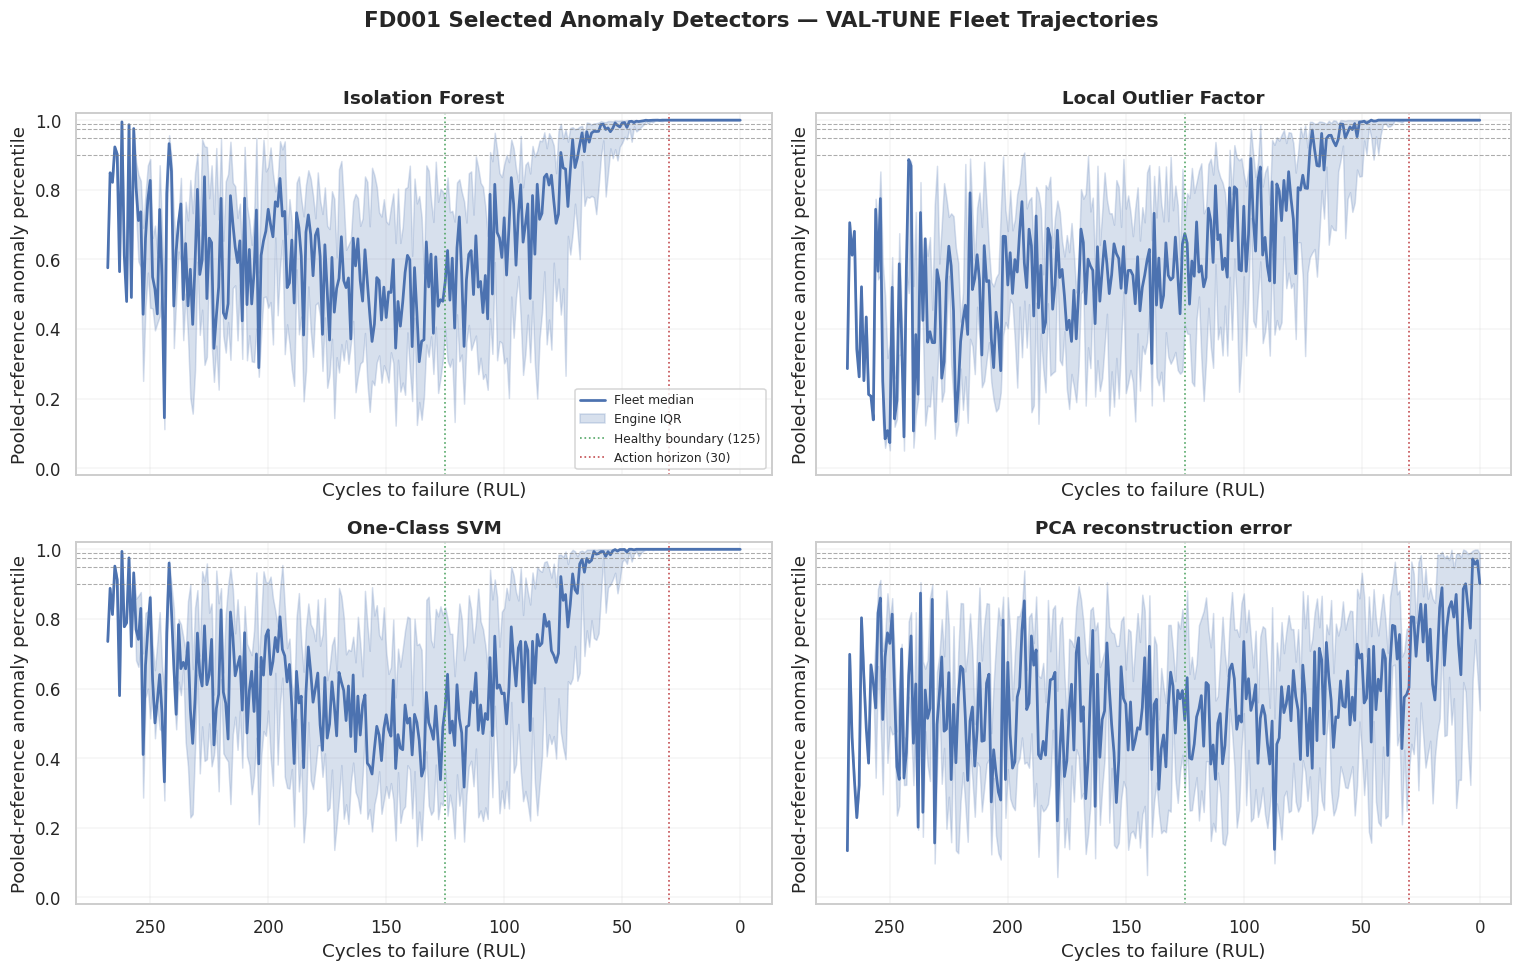

In [107]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
FIGURE_DIR = Path(config.FIGURES_DIR)

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_selected_timelines.csv"
)
timeline = pd.read_csv(timeline_path)

fleet_trajectory = (
    timeline.groupby(
        ["family", "candidate_id", "RUL"],
        as_index=False,
    )
    .agg(
        n_engines=("engine_id", "nunique"),
        percentile_mean=(
            "pooled_reference_percentile",
            "mean",
        ),
        percentile_median=(
            "pooled_reference_percentile",
            "median",
        ),
        percentile_p25=(
            "pooled_reference_percentile",
            lambda values: np.quantile(
                values,
                0.25,
            ),
        ),
        percentile_p75=(
            "pooled_reference_percentile",
            lambda values: np.quantile(
                values,
                0.75,
            ),
        ),
    )
    .sort_values(
        ["family", "RUL"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

assert fleet_trajectory["family"].nunique() == 4
assert np.isfinite(
    fleet_trajectory[
        [
            "percentile_mean",
            "percentile_median",
            "percentile_p25",
            "percentile_p75",
        ]
    ].to_numpy(dtype=float)
).all()

figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_anomaly_fleet_trajectories.png"
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
    sharey=True,
)

family_order = (
    "iforest",
    "lof",
    "ocsvm",
    "pca",
)

family_titles = {
    "iforest": "Isolation Forest",
    "lof": "Local Outlier Factor",
    "ocsvm": "One-Class SVM",
    "pca": "PCA reconstruction error",
}

for ax, family in zip(
    axes.ravel(),
    family_order,
):
    family_data = (
        fleet_trajectory[
            fleet_trajectory["family"] == family
        ]
        .sort_values("RUL")
    )

    x = family_data[
        "RUL"
    ].to_numpy(dtype=float)
    median = family_data[
        "percentile_median"
    ].to_numpy(dtype=float)
    p25 = family_data[
        "percentile_p25"
    ].to_numpy(dtype=float)
    p75 = family_data[
        "percentile_p75"
    ].to_numpy(dtype=float)

    ax.plot(
        x,
        median,
        color="C0",
        linewidth=1.8,
        label="Fleet median",
    )
    ax.fill_between(
        x,
        p25,
        p75,
        color="C0",
        alpha=0.22,
        label="Engine IQR",
    )

    for cutoff in (0.90, 0.95, 0.975, 0.99):
        ax.axhline(
            cutoff,
            color="gray",
            linestyle="--",
            linewidth=0.7,
            alpha=0.65,
        )

    ax.axvline(
        125,
        color="C2",
        linestyle=":",
        linewidth=1.1,
        label="Healthy boundary (125)",
    )
    ax.axvline(
        30,
        color="C3",
        linestyle=":",
        linewidth=1.1,
        label="Action horizon (30)",
    )

    ax.set_title(
        family_titles[family],
        fontweight="bold",
    )
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.2)

    ax.set_xlabel("Cycles to failure (RUL)")
    ax.set_ylabel(
        "Pooled-reference anomaly percentile"
    )

    if family == "iforest":
        ax.legend(
            fontsize=8,
            loc="lower right",
        )

axes[0, 0].invert_xaxis()

assert all(
    ax.xaxis_inverted()
    for ax in axes.ravel()
), "Shared RUL axes were not inverted."

fig.suptitle(
    (
        f"{SUBSET} Selected Anomaly Detectors — "
        "VAL-TUNE Fleet Trajectories"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=(0, 0, 1, 0.96))

temporary_figure_path = Path(
    str(figure_path) + ".tmp.png"
)
fig.savefig(
    temporary_figure_path,
    dpi=160,
    bbox_inches="tight",
)
os.replace(
    temporary_figure_path,
    figure_path,
)

plt.show()
plt.close(fig)

trajectory_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_fleet_trajectory_summary.csv"
)
temporary_trajectory_path = Path(
    str(trajectory_path) + ".tmp"
)
fleet_trajectory.to_csv(
    temporary_trajectory_path,
    index=False,
)


In [108]:
os.replace(
    temporary_trajectory_path,
    trajectory_path,
)

landmark_rul = [150, 125, 100, 60, 30, 20, 10, 0]

landmark_table = (
    fleet_trajectory[
        fleet_trajectory["RUL"].isin(
            landmark_rul
        )
    ]
    .pivot(
        index="family",
        columns="RUL",
        values="percentile_median",
    )
    .reindex(
        index=family_order,
        columns=landmark_rul,
    )
)

print(" FLEET MEDIAN ANOMALY PERCENTILE AT RUL LANDMARKS ")
display(landmark_table.round(6))

print("Saved trajectory summary:", trajectory_path)
print("Saved fleet figure:", figure_path)
print(
    "Axis convention: early life on LEFT, "
    "failure on RIGHT"
)
print("Fleet aggregation: median + engine IQR")
print("Threshold selected: NO")
print("Persistence policy selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


 FLEET MEDIAN ANOMALY PERCENTILE AT RUL LANDMARKS 


RUL,150,125,100,60,30,20,10,0
family,,,,,,,,
iforest,0.432967,0.534890,0.719505,0.967857,1.000000,1.000000,1.00000,1.000000
lof,0.503297,0.674176,0.752747,0.944505,1.000000,1.000000,1.00000,1.000000
ocsvm,0.524725,0.544780,0.587088,0.987637,1.000000,1.000000,1.00000,1.000000
pca,0.555495,0.508791,0.735165,0.516484,0.602747,0.611813,0.87033,0.901099


Saved trajectory summary: artifacts/results/FD001_anomaly_fleet_trajectory_summary.csv
Saved fleet figure: figures/FD001_anomaly_fleet_trajectories.png
Axis convention: early life on LEFT, failure on RIGHT
Fleet aggregation: median + engine IQR
Threshold selected: NO
Persistence policy selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED


In [109]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import models_anomaly as ma


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
FIGURE_DIR = Path(config.FIGURES_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)

selection_contract = json.loads(
    (
        PROCESSED_DIR
        / f"{SUBSET}_anomaly_within_family_selected.json"
    ).read_text(encoding="utf-8")
)

selected_bundle = joblib.load(
    Path(selection_contract["selected_bundle"])
)

preprocessor = selected_bundle["preprocessor"]
pca_entry = selected_bundle["candidates"]["pca"]
pca_model = pca_entry["model"]

kept_features = list(preprocessor.keep_)

assert len(kept_features) == X_val_tune_anomaly.shape[1]
assert pca_model.components_.shape[1] == len(
    kept_features
)

rul_values = val_tune_frame[
    "RUL"
].to_numpy(dtype=float)

region_masks = {
    "healthy": rul_values > 125,
    "middle": (
        (rul_values > 30)
        & (rul_values <= 125)
    ),
    "near_failure": rul_values <= 30,
}

assert np.all(
    region_masks["healthy"]
    | region_masks["middle"]
    | region_masks["near_failure"]
)
assert not np.any(
    region_masks["healthy"]
    & region_masks["middle"]
)
assert not np.any(
    region_masks["healthy"]
    & region_masks["near_failure"]
)
assert not np.any(
    region_masks["middle"]
    & region_masks["near_failure"]
)

contributions = {}
shares = {}

for region, mask in region_masks.items():
    X_region = X_val_tune_anomaly[mask]

    contribution = ma.pca_feature_contributions(
        pca_model,
        X_region,
    )
    contribution = np.asarray(
        contribution,
        dtype=float,
    )

    assert contribution.shape == (
        len(kept_features),
    )
    assert np.isfinite(contribution).all()
    assert np.all(contribution >= -1e-12)

    contribution = np.maximum(
        contribution,
        0.0,
    )

    reconstruction_scores = (
        ma.pca_reconstruction_score(
            pca_model,
            X_region,
        )
    )

    assert np.isclose(
        contribution.mean(),
        np.mean(reconstruction_scores),
        atol=1e-12,
        rtol=1e-10,
    )

    contributions[region] = contribution

    total_contribution = contribution.sum()
    assert total_contribution > 0

    shares[region] = (
        contribution / total_contribution
    )

pca_contribution_table = pd.DataFrame({
    "feature": kept_features,
    "feature_group": [
        (
            "operating_setting"
            if feature.startswith("op_setting_")
            else "sensor"
        )
        for feature in kept_features
    ],
    "healthy_mse": contributions["healthy"],
    "middle_mse": contributions["middle"],
    "near_failure_mse": (
        contributions["near_failure"]
    ),
    "healthy_share": shares["healthy"],
    "middle_share": shares["middle"],
    "near_failure_share": (
        shares["near_failure"]
    ),
})

pca_contribution_table[
    "near_minus_healthy_mse"
] = (
    pca_contribution_table["near_failure_mse"]
    - pca_contribution_table["healthy_mse"]
)

epsilon = np.finfo(float).eps

pca_contribution_table[
    "near_to_healthy_ratio"
] = (
    pca_contribution_table["near_failure_mse"]
    / (
        pca_contribution_table["healthy_mse"]
        + epsilon
    )
)

pca_contribution_table = (
    pca_contribution_table.sort_values(
        "near_failure_mse",
        ascending=False,
        kind="mergesort",
    )
    .reset_index(drop=True)
)

group_rows = []

for region in (
    "healthy",
    "middle",
    "near_failure",
):
    total = float(contributions[region].sum())

    for feature_group in (
        "operating_setting",
        "sensor",
    ):
        group_mask = (
            pca_contribution_table[
                "feature_group"
            ].to_numpy()
            == feature_group
        )

        group_mse = float(
            pca_contribution_table.loc[
                group_mask,
                f"{region}_mse",
            ].sum()
        )

        group_rows.append({
            "region": region,
            "feature_group": feature_group,
            "n_features": int(
                group_mask.sum()
            ),
            "total_group_mse": group_mse,
            "share_of_region_error": (
                group_mse / total
            ),
        })

pca_group_contribution = pd.DataFrame(
    group_rows
)

feature_output_path = (
    RESULT_DIR
    / f"{SUBSET}_pca_feature_contributions.csv"
)
group_output_path = (
    RESULT_DIR
    / f"{SUBSET}_pca_group_contributions.csv"
)


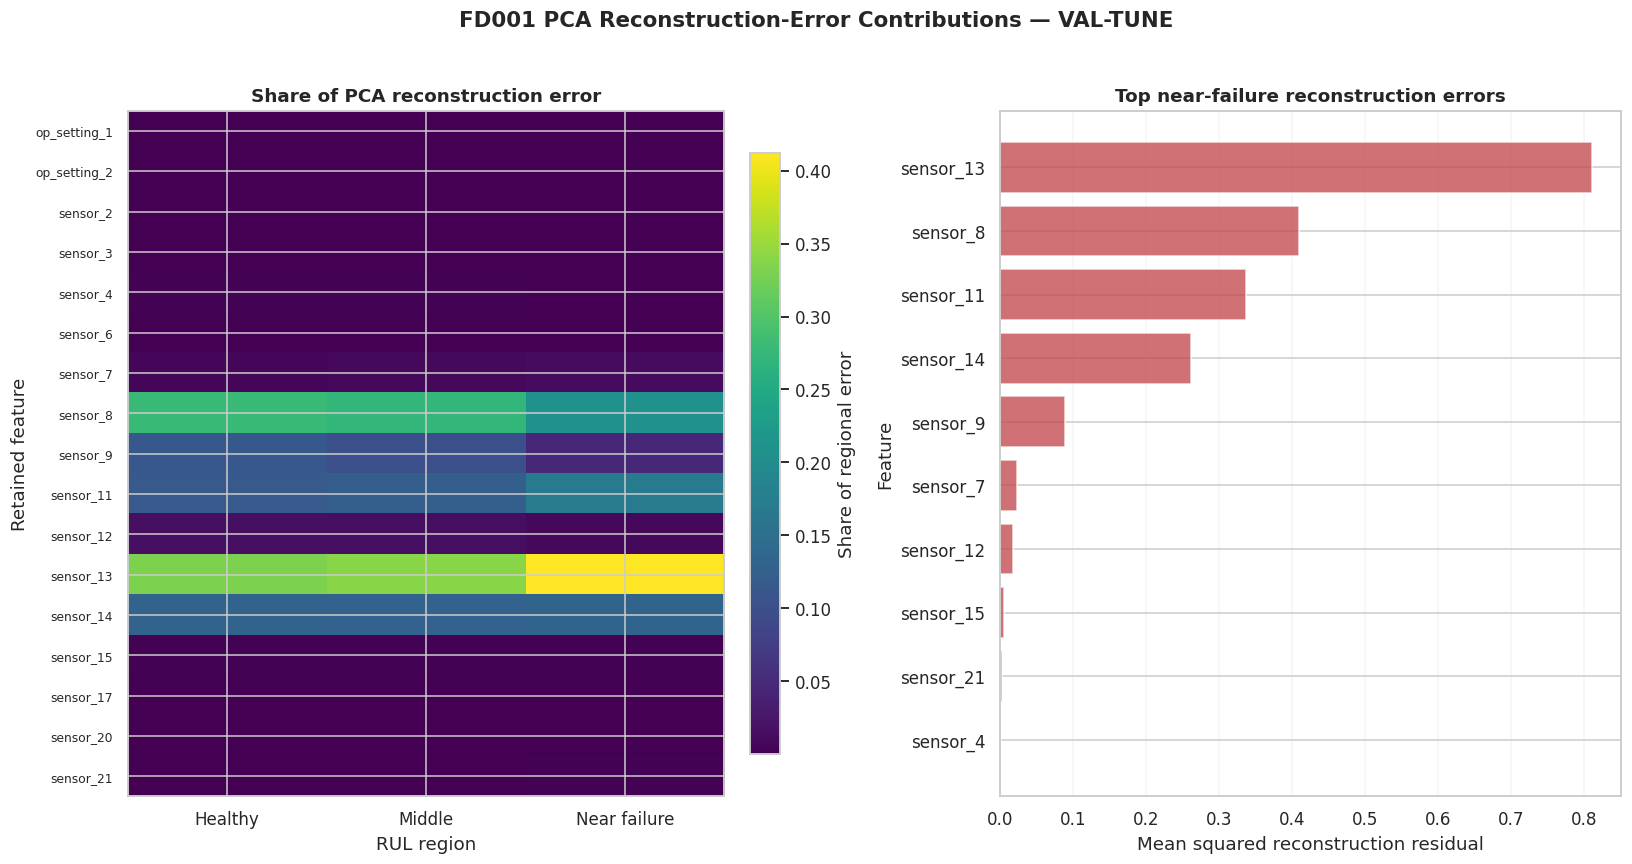

 TOP PCA NEAR-FAILURE CONTRIBUTIONS 


,feature,feature_group,healthy_mse,middle_mse,near_failure_mse,near_minus_healthy_mse,near_to_healthy_ratio,near_failure_share
0,sensor_13,sensor,0.273490,0.299485,0.810159,0.536669,2.962298,0.412044
1,sensor_8,sensor,0.229623,0.240866,0.409831,0.180208,1.784800,0.208439
2,sensor_11,sensor,0.094802,0.110848,0.337524,0.242722,3.560294,0.171663
3,sensor_14,sensor,0.107844,0.114977,0.261388,0.153544,2.423766,0.132941
4,sensor_9,sensor,0.094078,0.089353,0.089431,-0.004647,0.950603,0.045484
5,sensor_7,sensor,0.006043,0.007254,0.024338,0.018294,4.027197,0.012378
6,sensor_12,sensor,0.013806,0.013532,0.017606,0.003799,1.275171,0.008954
7,sensor_15,sensor,0.001359,0.001652,0.006018,0.004659,4.429389,0.003061
8,sensor_21,sensor,0.001074,0.001225,0.003416,0.002342,3.181057,0.001737
9,sensor_4,sensor,0.001586,0.001591,0.001789,0.000203,1.128040,0.000910


 PCA CONTRIBUTION BY FEATURE GROUP 


,region,feature_group,n_features,total_group_mse,share_of_region_error
0,healthy,operating_setting,2,0.000359,0.000435
1,healthy,sensor,15,0.825315,0.999565
2,middle,operating_setting,2,0.000389,0.000440
3,middle,sensor,15,0.882497,0.999560
4,near_failure,operating_setting,2,0.000878,0.000447
5,near_failure,sensor,15,1.965317,0.999553


Selected PCA: pca_evr0p95
PCA components: 14
Retained features: 17
Saved feature contributions: artifacts/results/FD001_pca_feature_contributions.csv
Saved group contributions: artifacts/results/FD001_pca_group_contributions.csv
Saved contribution figure: figures/FD001_pca_feature_contributions.png
Interpretation: reconstruction-error contribution
Causal feature importance: NO
Threshold selected: NO
VAL-CALIB status: RESERVED
Official test status: SEALED


In [110]:
figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_pca_feature_contributions.png"
)

for final_path, table in (
    (
        feature_output_path,
        pca_contribution_table,
    ),
    (
        group_output_path,
        pca_group_contribution,
    ),
):
    temporary_path = Path(str(final_path) + ".tmp")
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

plot_table = pca_contribution_table.set_index(
    "feature"
).loc[kept_features]

share_matrix = plot_table[
    [
        "healthy_share",
        "middle_share",
        "near_failure_share",
    ]
].to_numpy(dtype=float)

top_near = pca_contribution_table.head(10).sort_values(
    "near_failure_mse",
    ascending=True,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 8),
    gridspec_kw={
        "width_ratios": [1.05, 1.0],
    },
)

heatmap = axes[0].imshow(
    share_matrix,
    aspect="auto",
    cmap="viridis",
)

axes[0].set_yticks(
    np.arange(len(kept_features))
)
axes[0].set_yticklabels(
    kept_features,
    fontsize=8,
)
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(
    ["Healthy", "Middle", "Near failure"],
)
axes[0].set_title(
    "Share of PCA reconstruction error",
    fontweight="bold",
)
axes[0].set_xlabel("RUL region")
axes[0].set_ylabel("Retained feature")

fig.colorbar(
    heatmap,
    ax=axes[0],
    label="Share of regional error",
    fraction=0.046,
    pad=0.04,
)

axes[1].barh(
    top_near["feature"],
    top_near["near_failure_mse"],
    color="C3",
    alpha=0.8,
)
axes[1].set_title(
    "Top near-failure reconstruction errors",
    fontweight="bold",
)
axes[1].set_xlabel(
    "Mean squared reconstruction residual"
)
axes[1].set_ylabel("Feature")
axes[1].grid(
    axis="x",
    alpha=0.2,
)

fig.suptitle(
    (
        f"{SUBSET} PCA Reconstruction-Error "
        "Contributions — VAL-TUNE"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=(0, 0, 1, 0.96))

temporary_figure_path = Path(
    str(figure_path) + ".tmp.png"
)
fig.savefig(
    temporary_figure_path,
    dpi=160,
    bbox_inches="tight",
)
os.replace(
    temporary_figure_path,
    figure_path,
)

plt.show()
plt.close(fig)

print(" TOP PCA NEAR-FAILURE CONTRIBUTIONS ")
display(
    pca_contribution_table[
        [
            "feature",
            "feature_group",
            "healthy_mse",
            "middle_mse",
            "near_failure_mse",
            "near_minus_healthy_mse",
            "near_to_healthy_ratio",
            "near_failure_share",
        ]
    ].head(10).round(6)
)

print(" PCA CONTRIBUTION BY FEATURE GROUP ")
display(
    pca_group_contribution.round(6)
)

print("Selected PCA:", pca_entry["candidate_id"])
print(
    "PCA components:",
    pca_model.n_components_,
)
print("Retained features:", len(kept_features))
print("Saved feature contributions:", feature_output_path)
print("Saved group contributions:", group_output_path)
print("Saved contribution figure:", figure_path)
print("Interpretation: reconstruction-error contribution")
print("Causal feature importance: NO")
print("Threshold selected: NO")
print("VAL-CALIB status: RESERVED")
print("Official test status: SEALED")


In [111]:
import hashlib
import json
import os
from pathlib import Path


SEED = int(config.RANDOM_SEED)
BOOTSTRAP_DRAWS = int(config.BOOTSTRAP_DRAWS)

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.json"
)
selection_contract = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)

selected_map = selection_contract[
    "selected_within_family"
]

assert set(selected_map) == {
    "iforest",
    "lof",
    "ocsvm",
    "pca",
}

source_artifacts = {
    "anomaly_preprocessing_bundle": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
    ),
    "candidate_manifest": (
        PROCESSED_DIR
        / f"{SUBSET}_anomaly_train_candidates_manifest.json"
    ),
    "val_tune_proxy_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_anomaly_val_tune_proxy_contract.json"
    ),
    "within_family_selection_contract": (
        selection_contract_path
    ),
    "selected_family_bundle": Path(
        selection_contract["selected_bundle"]
    ),
    "val_tune_proxy_summary": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_val_tune_proxy_summary.csv"
    ),
    "val_tune_per_engine_auc": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_val_tune_per_engine_auc.csv"
    ),
    "val_tune_bootstrap_ci": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_val_tune_engine_bootstrap_ci.csv"
    ),
    "threshold_sensitivity": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_threshold_sensitivity.csv"
    ),
    "engine_crossing_burden": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_engine_crossing_burden.csv"
    ),
    "crossing_run_summary": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_crossing_run_summary.csv"
    ),
    "fleet_trajectory_summary": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_fleet_trajectory_summary.csv"
    ),
    "pca_feature_contributions": (
        RESULT_DIR
        / f"{SUBSET}_pca_feature_contributions.csv"
    ),
    "pca_group_contributions": (
        RESULT_DIR
        / f"{SUBSET}_pca_group_contributions.csv"
    ),
}

source_hashes = {}

for artifact_name, artifact_path in (
    source_artifacts.items()
):
    artifact_path = Path(artifact_path)

    assert artifact_path.exists(), (
        f"Missing source artifact: {artifact_path}"
    )
    assert artifact_path.stat().st_size > 0

    source_hashes[artifact_name] = {
        "path": str(artifact_path),
        "sha256": hashlib.sha256(
            artifact_path.read_bytes()
        ).hexdigest(),
        "size_bytes": int(
            artifact_path.stat().st_size
        ),
    }

policy_contract = {
    "contract_version": 1,
    "subset": SUBSET,
    "task": "task6_early_warning_policy",
    "stage": "pre_val_calib_frozen_contract",
    "selected_task5_candidates": selected_map,
    "anomaly_reference": {
        "primary": (
            "pooled healthy TRAIN-reference CDF"
        ),
        "sensitivity": (
            "engine-balanced healthy TRAIN-reference CDF"
        ),
        "raw_score_is_probability": False,
        "score_direction": (
            "larger percentile means more abnormal"
        ),
    },
    "threshold_grid": [
        0.90,
        0.95,
        0.975,
        0.99,
    ],
    "persistence": {
        "selection_eligible_grid": [
            [2, 3],
            [3, 5],
            [5, 10],
        ],
        "diagnostic_only": [[1, 1]],
        "diagnostic_only_selection_eligible": False,
        "window_type": "trailing_sliding",
        "trigger_rule": (
            "trigger when at least m of the last n "
            "consecutive observed cycles are raw crossings"
        ),
        "cycle_gap_rule": (
            "a cycle gap resets persistence history"
        ),
        "minimum_history_rule": (
            "no alert before n contiguous cycles exist"
        ),
    },
    "latching": {
        "enabled": True,
        "tau_recorded_once": True,
        "definition": (
            "after the first persistent trigger, "
            "the engine remains alerted"
        ),
    },
    "strict_trigger_eligibility": {
        "rule": "tau < failure_cycle",
        "trigger_at_failure_is_missed": True,
        "failure_cycle_definition": (
            "maximum observed cycle for complete "
            "run-to-failure validation trajectories"
        ),
    },
    "action_horizon_cycles": 30,
    "cost_policy": {
        "weights": {
            "c_miss": 100.0,
            "c_late": 5.0,
            "c_early": 1.0,
        },
        "lead_time": "failure_cycle - tau",
        "late_delay": "max(0, 30 - lead_time)",
        "early_burden": "max(0, lead_time - 30)",
        "late_normalized": "late_delay / 30",
        "early_normalized_uncapped": (
            "early_burden / 30"
        ),
        "early_cost_cap": 1.0,
        "early_normalized_for_cost": (
            "min(early_normalized_uncapped, 1.0)"
        ),
        "missed_engine_cost": 100.0,
        "non_missed_total_cost": (
            "5 * late_normalized + "
            "1 * early_normalized_for_cost"
        ),
        "aggregation": (
            "equal-weight mean over engines"
        ),
    },
    "selection_scope": {
        "per_family": (
            "select the lowest-cost eligible policy "
            "within each detector family"
        ),
        "overall": (
            "select the lowest-cost eligible policy "
            "across all families"
        ),
        "manual_post_hoc_override": False,
    },
    "tie_break_order": [
        "lowest mean per-engine total cost",
        "fewer missed engines",
        "lower mean raw late-warning delay",
        "lower mean raw early-warning burden",
        (
            "lower fraction of engines first "
            "triggered while RUL > 125"
        ),
        "persistence order: (2,3), (3,5), (5,10)",
        "higher percentile cutoff",
        "frozen family order: iforest, lof, ocsvm, pca",
    ],
    "tie_break_cost_tolerance": 1e-12,
    "bootstrap": {
        "method": "engine-level resampling",
        "draws": BOOTSTRAP_DRAWS,
        "seed": SEED,
        "interval": "95% percentile",
    },
    "source_artifacts": source_hashes,
    "data_roles": {
        "model_fit": "TRAIN anomaly_fit",
        "reference_cdf": "TRAIN anomaly_reference",
        "candidate_selection": "VAL-TUNE",
        "policy_selection": "VAL-CALIB next",
        "final_evaluation": "official TEST sealed",
    },
    "val_calib_accessed": False,
    "official_test_accessed": False,
    "official_test_status": "SEALED",
}


In [112]:
contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.json"
)
sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.sha256"
)

temporary_contract_path = Path(
    str(contract_path) + ".tmp"
)
temporary_contract_path.write_text(
    json.dumps(
        policy_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
os.replace(
    temporary_contract_path,
    contract_path,
)

contract_sha256 = hashlib.sha256(
    contract_path.read_bytes()
).hexdigest()

sidecar_payload = {
    "file": str(contract_path),
    "sha256": contract_sha256,
}

temporary_sidecar_path = Path(
    str(sidecar_path) + ".tmp"
)
temporary_sidecar_path.write_text(
    json.dumps(
        sidecar_payload,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
os.replace(
    temporary_sidecar_path,
    sidecar_path,
)

reloaded_contract = json.loads(
    contract_path.read_text(encoding="utf-8")
)
reloaded_sidecar = json.loads(
    sidecar_path.read_text(encoding="utf-8")
)

assert reloaded_sidecar["sha256"] == hashlib.sha256(
    contract_path.read_bytes()
).hexdigest()
assert reloaded_contract[
    "selected_task5_candidates"
] == selected_map
assert reloaded_contract[
    "val_calib_accessed"
] is False
assert reloaded_contract[
    "official_test_accessed"
] is False

for artifact_name, artifact_info in (
    reloaded_contract["source_artifacts"].items()
):
    source_path = Path(artifact_info["path"])

    assert hashlib.sha256(
        source_path.read_bytes()
    ).hexdigest() == artifact_info["sha256"], (
        f"Source artifact changed: {artifact_name}"
    )

print(" FROZEN TASK-6 ANOMALY POLICY CONTRACT ")
print("Selected candidates:", selected_map)
print(
    "Threshold grid:",
    policy_contract["threshold_grid"],
)
print(
    "Eligible persistence grid:",
    policy_contract["persistence"][
        "selection_eligible_grid"
    ],
)
print(
    "Diagnostic-only persistence:",
    policy_contract["persistence"][
        "diagnostic_only"
    ],
)
print(
    "Cost weights:",
    policy_contract["cost_policy"]["weights"],
)
print(
    "Source artifacts hashed:",
    len(source_hashes),
)
print("Saved contract:", contract_path)
print("Saved integrity sidecar:", sidecar_path)
print("Contract SHA256:", contract_sha256)
print("Contract reload integrity: PASS")
print("VAL-CALIB accessed: NO")
print("Official test accessed: NO")
print("Official test status: SEALED")


 FROZEN TASK-6 ANOMALY POLICY CONTRACT 
Selected candidates: {'iforest': 'iforest_n200_ms_0p5', 'lof': 'lof_k50', 'ocsvm': 'ocsvm_nu0p05_gamma_0p01', 'pca': 'pca_evr0p95'}
Threshold grid: [0.9, 0.95, 0.975, 0.99]
Eligible persistence grid: [[2, 3], [3, 5], [5, 10]]
Diagnostic-only persistence: [[1, 1]]
Cost weights: {'c_miss': 100.0, 'c_late': 5.0, 'c_early': 1.0}
Source artifacts hashed: 14
Saved contract: data/processed/FD001_task6_policy_contract.json
Saved integrity sidecar: data/processed/FD001_task6_policy_contract.sha256
Contract SHA256: b60072c985ae5ecc400e292c71eb3b9fcd63551da7956e8a3e46267fc753c016
Contract reload integrity: PASS
VAL-CALIB accessed: NO
Official test accessed: NO
Official test status: SEALED


In [113]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.json"
)
sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.sha256"
)

contract_bytes = contract_path.read_bytes()
contract_sha256 = hashlib.sha256(
    contract_bytes
).hexdigest()

sidecar = json.loads(
    sidecar_path.read_text(encoding="utf-8")
)
assert sidecar["sha256"] == contract_sha256

frozen_contract = json.loads(
    contract_bytes.decode("utf-8")
)

assert frozen_contract["stage"] == (
    "pre_val_calib_frozen_contract"
)
assert frozen_contract["val_calib_accessed"] is False
assert frozen_contract["official_test_accessed"] is False
assert frozen_contract["official_test_status"] == "SEALED"

for artifact_name, artifact_info in (
    frozen_contract["source_artifacts"].items()
):
    artifact_path = Path(artifact_info["path"])

    assert artifact_path.exists()
    assert hashlib.sha256(
        artifact_path.read_bytes()
    ).hexdigest() == artifact_info["sha256"], (
        f"Frozen source changed: {artifact_name}"
    )

selected_bundle_info = frozen_contract[
    "source_artifacts"
]["selected_family_bundle"]

selected_bundle_path = Path(
    selected_bundle_info["path"]
)
selected_bundle = joblib.load(
    selected_bundle_path
)

preprocessor = selected_bundle["preprocessor"]
feature_columns = list(
    preprocessor.input_feature_order_
)
kept_features = list(preprocessor.keep_)

required_columns = (
    ["engine_id", "cycle", "RUL"]
    + feature_columns
)

for column in required_columns:
    assert column in df_val_calib.columns
    assert list(
        df_val_calib.columns
    ).count(column) == 1

assert df_val_calib.index.is_unique
assert not df_val_calib.duplicated(
    ["engine_id", "cycle"]
).any()

val_calib_frame = df_val_calib.copy()

val_calib_rul = val_calib_frame[
    "RUL"
].to_numpy(dtype=float)

assert np.isfinite(val_calib_rul).all()

val_calib_final_cycle = (
    val_calib_frame.groupby(
        "engine_id"
    )["cycle"].transform("max")
)

expected_rul = (
    val_calib_final_cycle
    - val_calib_frame["cycle"]
).to_numpy(dtype=float)

assert np.array_equal(
    val_calib_rul,
    expected_rul,
), "VAL-CALIB RUL is not uncapped run-to-failure RUL."

X_val_calib_anomaly = preprocessor.transform(
    val_calib_frame[
        feature_columns
    ].to_numpy(dtype=float),
    feature_columns,
)

assert X_val_calib_anomaly.shape == (
    len(val_calib_frame),
    len(kept_features),
)
assert np.isfinite(X_val_calib_anomaly).all()

val_calib_regions = np.select(
    [
        val_calib_rul <= 30,
        (
            (val_calib_rul > 30)
            & (val_calib_rul <= 125)
        ),
    ],
    [
        "near_failure",
        "middle",
    ],
    default="healthy",
)

timeline_frames = []

for family in (
    "iforest",
    "lof",
    "ocsvm",
    "pca",
):
    candidate = selected_bundle[
        "candidates"
    ][family]
    model = candidate["model"]

    if family == "pca":
        raw_scores = ma.pca_reconstruction_score(
            model,
            X_val_calib_anomaly,
        )
    else:
        raw_scores = ma.oriented_raw_score(
            family,
            model,
            X_val_calib_anomaly,
        )

    raw_scores = np.asarray(
        raw_scores,
        dtype=float,
    )

    assert raw_scores.shape == (
        len(val_calib_frame),
    )
    assert np.isfinite(raw_scores).all()

    pooled_percentiles = ma.reference_percentile(
        candidate["pooled_reference_cdf"],
        raw_scores,
    )
    balanced_percentiles = ma.reference_percentile(
        candidate[
            "engine_balanced_reference_cdf"
        ],
        raw_scores,
    )

    assert np.isfinite(pooled_percentiles).all()
    assert np.isfinite(balanced_percentiles).all()
    assert np.all(
        (pooled_percentiles >= 0.0)
        & (pooled_percentiles <= 1.0)
    )
    assert np.all(
        (balanced_percentiles >= 0.0)
        & (balanced_percentiles <= 1.0)
    )

    family_timeline = val_calib_frame[
        ["engine_id", "cycle", "RUL"]
    ].copy()

    family_timeline["family"] = family
    family_timeline["candidate_id"] = (
        candidate["candidate_id"]
    )
    family_timeline["rul_region"] = (
        val_calib_regions
    )
    family_timeline["raw_score"] = raw_scores
    family_timeline[
        "pooled_reference_percentile"
    ] = pooled_percentiles
    family_timeline[
        "engine_balanced_reference_percentile"
    ] = balanced_percentiles

    timeline_frames.append(family_timeline)


In [114]:
anomaly_val_calib_timelines = pd.concat(
    timeline_frames,
    ignore_index=True,
)

assert len(anomaly_val_calib_timelines) == (
    4 * len(val_calib_frame)
)
assert anomaly_val_calib_timelines[
    ["family", "engine_id", "cycle"]
].duplicated().sum() == 0
assert anomaly_val_calib_timelines[
    "engine_id"
].nunique() == 10

val_calib_region_summary = (
    anomaly_val_calib_timelines.groupby(
        ["family", "candidate_id", "rul_region"],
        as_index=False,
        observed=True,
    )
    .agg(
        n_rows=(
            "pooled_reference_percentile",
            "size",
        ),
        mean_percentile=(
            "pooled_reference_percentile",
            "mean",
        ),
        median_percentile=(
            "pooled_reference_percentile",
            "median",
        ),
        percentile_p25=(
            "pooled_reference_percentile",
            lambda values: np.quantile(
                values,
                0.25,
            ),
        ),
        percentile_p75=(
            "pooled_reference_percentile",
            lambda values: np.quantile(
                values,
                0.75,
            ),
        ),
    )
)

timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_calib_selected_timelines.csv"
)
region_summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_calib_region_summary.csv"
)

for final_path, table in (
    (timeline_path, anomaly_val_calib_timelines),
    (region_summary_path, val_calib_region_summary),
):
    temporary_path = Path(
        str(final_path) + ".tmp"
    )
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

access_record = {
    "record_version": 1,
    "subset": SUBSET,
    "stage": "val_calib_scoring",
    "frozen_contract": str(contract_path),
    "frozen_contract_sha256": contract_sha256,
    "val_calib_rows": int(
        len(val_calib_frame)
    ),
    "val_calib_engines": int(
        val_calib_frame[
            "engine_id"
        ].nunique()
    ),
    "selected_families": 4,
    "model_refitting": False,
    "threshold_selection": False,
    "persistence_selection": False,
    "official_test_accessed": False,
    "official_test_status": "SEALED",
}

access_record_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_val_calib_access_record.json"
)
temporary_access_path = Path(
    str(access_record_path) + ".tmp"
)
temporary_access_path.write_text(
    json.dumps(
        access_record,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
os.replace(
    temporary_access_path,
    access_record_path,
)

median_display = (
    val_calib_region_summary.pivot(
        index="family",
        columns="rul_region",
        values="median_percentile",
    )
    .reindex(
        columns=[
            "healthy",
            "middle",
            "near_failure",
        ]
    )
)

print(" CONTRACT-GATED VAL-CALIB ANOMALY SCORING ")
display(median_display.round(6))

print("Frozen contract SHA256:", contract_sha256)
print("VAL-CALIB rows:", len(val_calib_frame))
print(
    "VAL-CALIB engines:",
    val_calib_frame["engine_id"].nunique(),
)
print(
    "Transformed feature count:",
    X_val_calib_anomaly.shape[1],
)
print("Saved timelines:", timeline_path)
print("Saved region summary:", region_summary_path)
print("Saved access record:", access_record_path)
print("Model refitting performed: NO")
print("Threshold selected in this cell: NO")
print("Persistence selected in this cell: NO")
print("Official test accessed: NO")
print("Official test status: SEALED")


 CONTRACT-GATED VAL-CALIB ANOMALY SCORING 


rul_region,healthy,middle,near_failure
family,,,
iforest,0.672802,0.961264,1.000000
lof,0.524725,0.868132,1.000000
ocsvm,0.696429,0.978571,1.000000
pca,0.533242,0.553571,0.772802


Frozen contract SHA256: b60072c985ae5ecc400e292c71eb3b9fcd63551da7956e8a3e46267fc753c016
VAL-CALIB rows: 2026
VAL-CALIB engines: 10
Transformed feature count: 17
Saved timelines: artifacts/results/FD001_anomaly_val_calib_selected_timelines.csv
Saved region summary: artifacts/results/FD001_anomaly_val_calib_region_summary.csv
Saved access record: data/processed/FD001_task6_val_calib_access_record.json
Model refitting performed: NO
Threshold selected in this cell: NO
Persistence selected in this cell: NO
Official test accessed: NO
Official test status: SEALED


In [115]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd


RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.json"
)
frozen_contract = json.loads(
    contract_path.read_text(encoding="utf-8")
)

timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_calib_selected_timelines.csv"
)
timeline = pd.read_csv(timeline_path)

threshold_grid = [
    float(value)
    for value in frozen_contract["threshold_grid"]
]

eligible_persistence = [
    tuple(pair)
    for pair in frozen_contract[
        "persistence"
    ]["selection_eligible_grid"]
]
diagnostic_persistence = [
    tuple(pair)
    for pair in frozen_contract[
        "persistence"
    ]["diagnostic_only"]
]

all_persistence_rules = (
    diagnostic_persistence
    + eligible_persistence
)

cost_weights = frozen_contract[
    "cost_policy"
]["weights"]

C_MISS = float(cost_weights["c_miss"])
C_LATE = float(cost_weights["c_late"])
C_EARLY = float(cost_weights["c_early"])

ACTION_HORIZON = int(
    frozen_contract["action_horizon_cycles"]
)
EARLY_CAP = float(
    frozen_contract["cost_policy"][
        "early_cost_cap"
    ]
)

assert threshold_grid == [
    0.90,
    0.95,
    0.975,
    0.99,
]
assert eligible_persistence == [
    (2, 3),
    (3, 5),
    (5, 10),
]
assert diagnostic_persistence == [(1, 1)]
assert ACTION_HORIZON == 30


def first_persistent_trigger(cycles, crossings, m, n):
    cycles = np.asarray(cycles, dtype=int)
    crossings = np.asarray(
        crossings,
        dtype=bool,
    )

    assert cycles.ndim == 1
    assert crossings.shape == cycles.shape
    assert 1 <= m <= n

    segment_start = 0

    for end_position in range(len(cycles)):
        if (
            end_position > 0
            and cycles[end_position]
            != cycles[end_position - 1] + 1
        ):
            segment_start = end_position

        contiguous_history = (
            end_position - segment_start + 1
        )

        if contiguous_history < n:
            continue

        window_start = end_position - n + 1
        window_crossings = crossings[
            window_start:end_position + 1
        ]

        assert len(window_crossings) == n

        if int(window_crossings.sum()) >= m:
            return int(cycles[end_position])

    return None


policy_engine_rows = []

for family, family_frame in timeline.groupby(
    "family",
    sort=True,
):
    candidate_ids = family_frame[
        "candidate_id"
    ].unique()
    assert len(candidate_ids) == 1
    candidate_id = candidate_ids[0]

    for cutoff in threshold_grid:
        for m, n in all_persistence_rules:
            selection_eligible = (
                (m, n) in eligible_persistence
            )

            for engine_id, engine_frame in (
                family_frame.groupby(
                    "engine_id",
                    sort=True,
                )
            ):
                engine_frame = (
                    engine_frame.sort_values(
                        "cycle",
                        kind="mergesort",
                    )
                    .reset_index(drop=True)
                )

                cycles = engine_frame[
                    "cycle"
                ].to_numpy(dtype=int)
                percentiles = engine_frame[
                    "pooled_reference_percentile"
                ].to_numpy(dtype=float)

                assert np.isfinite(percentiles).all()

                crossings = percentiles >= cutoff
                failure_cycle = int(cycles.max())

                first_satisfaction_cycle = (
                    first_persistent_trigger(
                        cycles,
                        crossings,
                        m=m,
                        n=n,
                    )
                )

                if (
                    first_satisfaction_cycle is not None
                    and first_satisfaction_cycle
                    < failure_cycle
                ):
                    tau = int(
                        first_satisfaction_cycle
                    )
                    missed = False
                    lead_time = int(
                        failure_cycle - tau
                    )

                    late_delay = max(
                        0,
                        ACTION_HORIZON - lead_time,
                    )
                    early_burden = max(
                        0,
                        lead_time - ACTION_HORIZON,
                    )

                    late_normalized = (
                        late_delay / ACTION_HORIZON
                    )
                    early_normalized_uncapped = (
                        early_burden / ACTION_HORIZON
                    )
                    early_normalized_for_cost = min(
                        early_normalized_uncapped,
                        EARLY_CAP,
                    )

                    miss_component = 0.0
                    late_component = (
                        C_LATE * late_normalized
                    )
                    early_component = (
                        C_EARLY
                        * early_normalized_for_cost
                    )
                else:
                    tau = np.nan
                    missed = True
                    lead_time = np.nan
                    late_delay = 0
                    early_burden = 0
                    late_normalized = 0.0
                    early_normalized_uncapped = 0.0
                    early_normalized_for_cost = 0.0
                    miss_component = C_MISS
                    late_component = 0.0
                    early_component = 0.0

                total_cost = (
                    miss_component
                    + late_component
                    + early_component
                )

                first_trigger_while_healthy = bool(
                    (not missed)
                    and lead_time > 125
                )

                trigger_at_failure_only = bool(
                    first_satisfaction_cycle
                    == failure_cycle
                )

                n_cycle_gaps = int(
                    np.sum(np.diff(cycles) != 1)
                )

                policy_engine_rows.append({
                    "family": family,
                    "candidate_id": candidate_id,
                    "reference_type": "pooled",
                    "cutoff": cutoff,
                    "m": m,
                    "n": n,
                    "selection_eligible": bool(
                        selection_eligible
                    ),
                    "engine_id": int(engine_id),
                    "failure_cycle": failure_cycle,
                    "first_satisfaction_cycle": (
                        first_satisfaction_cycle
                        if first_satisfaction_cycle
                        is not None
                        else np.nan
                    ),
                    "tau": tau,
                    "missed": bool(missed),
                    "trigger_at_failure_only": (
                        trigger_at_failure_only
                    ),
                    "lead_time": lead_time,
                    "late_delay": int(late_delay),
                    "early_burden": int(
                        early_burden
                    ),
                    "late_normalized": float(
                        late_normalized
                    ),
                    "early_normalized_uncapped": float(
                        early_normalized_uncapped
                    ),
                    "early_normalized_for_cost": float(
                        early_normalized_for_cost
                    ),
                    "miss_component": float(
                        miss_component
                    ),
                    "late_component": float(
                        late_component
                    ),
                    "early_component": float(
                        early_component
                    ),
                    "total_cost": float(total_cost),
                    "first_trigger_while_healthy": (
                        first_trigger_while_healthy
                    ),
                    "n_cycle_gaps": n_cycle_gaps,
                })


In [116]:
anomaly_policy_engine_results = pd.DataFrame(
    policy_engine_rows
)

expected_policy_count = (
    4
    * len(threshold_grid)
    * len(all_persistence_rules)
)
expected_engine_rows = (
    expected_policy_count * 10
)

assert len(anomaly_policy_engine_results) == (
    expected_engine_rows
)
assert anomaly_policy_engine_results[
    "engine_id"
].nunique() == 10
assert (
    anomaly_policy_engine_results[
        "n_cycle_gaps"
    ] == 0
).all()

anomaly_policy_summary = (
    anomaly_policy_engine_results.groupby(
        [
            "family",
            "candidate_id",
            "reference_type",
            "cutoff",
            "m",
            "n",
            "selection_eligible",
        ],
        as_index=False,
    )
    .agg(
        n_engines=("engine_id", "nunique"),
        missed_engines=("missed", "sum"),
        miss_rate=("missed", "mean"),
        trigger_at_failure_only_engines=(
            "trigger_at_failure_only",
            "sum",
        ),
        mean_total_cost=(
            "total_cost",
            "mean",
        ),
        mean_miss_component=(
            "miss_component",
            "mean",
        ),
        mean_late_component=(
            "late_component",
            "mean",
        ),
        mean_early_component=(
            "early_component",
            "mean",
        ),
        mean_raw_late_delay=(
            "late_delay",
            "mean",
        ),
        mean_raw_early_burden=(
            "early_burden",
            "mean",
        ),
        mean_lead_time=(
            "lead_time",
            "mean",
        ),
        median_lead_time=(
            "lead_time",
            "median",
        ),
        minimum_lead_time=(
            "lead_time",
            "min",
        ),
        maximum_lead_time=(
            "lead_time",
            "max",
        ),
        healthy_first_trigger_fraction=(
            "first_trigger_while_healthy",
            "mean",
        ),
    )
)

assert len(anomaly_policy_summary) == (
    expected_policy_count
)

engine_output_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_engine_results.csv"
)
summary_output_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_summary.csv"
)

for final_path, table in (
    (
        engine_output_path,
        anomaly_policy_engine_results,
    ),
    (
        summary_output_path,
        anomaly_policy_summary,
    ),
):
    temporary_path = Path(
        str(final_path) + ".tmp"
    )
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

eligible_ranking = (
    anomaly_policy_summary[
        anomaly_policy_summary[
            "selection_eligible"
        ]
    ]
    .sort_values(
        [
            "mean_total_cost",
            "missed_engines",
            "mean_raw_late_delay",
            "mean_raw_early_burden",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

diagnostic_1_of_1 = (
    anomaly_policy_summary[
        ~anomaly_policy_summary[
            "selection_eligible"
        ]
    ]
    .sort_values(
        ["family", "cutoff"],
        kind="mergesort",
    )
)

print(" VAL-CALIB ELIGIBLE POLICY GRID — TOP 15 ")
display(
    eligible_ranking[
        [
            "family",
            "cutoff",
            "m",
            "n",
            "missed_engines",
            "miss_rate",
            "mean_total_cost",
            "mean_miss_component",
            "mean_late_component",
            "mean_early_component",
            "mean_lead_time",
            "healthy_first_trigger_fraction",
        ]
    ].head(15).round(6)
)

print(" DIAGNOSTIC-ONLY (1 OF 1) POLICIES ")
display(
    diagnostic_1_of_1[
        [
            "family",
            "cutoff",
            "missed_engines",
            "mean_total_cost",
            "mean_lead_time",
            "healthy_first_trigger_fraction",
        ]
    ].round(6)
)

print("Policy configurations:", expected_policy_count)
print("Eligible configurations:", 4 * 4 * 3)
print("Diagnostic-only configurations:", 4 * 4)
print("Per-engine policy rows:", expected_engine_rows)
print("Saved per-engine results:", engine_output_path)
print("Saved policy summary:", summary_output_path)
print("Formal policy selected in this cell: NO")
print("Official test accessed: NO")
print("Official test status: SEALED")


 VAL-CALIB ELIGIBLE POLICY GRID — TOP 15 


,family,cutoff,m,n,missed_engines,miss_rate,mean_total_cost,mean_miss_component,mean_late_component,mean_early_component,mean_lead_time,healthy_first_trigger_fraction
0,lof,0.990,5,10,0,0.0,0.683333,0.0,0.0,0.683333,57.7,0.0
1,iforest,0.990,5,10,0,0.0,0.756667,0.0,0.0,0.756667,66.2,0.0
2,lof,0.975,5,10,0,0.0,0.763333,0.0,0.0,0.763333,62.6,0.0
3,lof,0.990,3,5,0,0.0,0.790000,0.0,0.0,0.790000,63.2,0.0
4,ocsvm,0.990,5,10,0,0.0,0.796667,0.0,0.0,0.796667,71.4,0.0
5,iforest,0.990,3,5,0,0.0,0.806667,0.0,0.0,0.806667,71.8,0.0
6,iforest,0.975,5,10,0,0.0,0.813333,0.0,0.0,0.813333,74.9,0.1
7,lof,0.950,5,10,0,0.0,0.820000,0.0,0.0,0.820000,68.1,0.0
8,ocsvm,0.975,5,10,0,0.0,0.820000,0.0,0.0,0.820000,83.4,0.2
9,lof,0.975,3,5,0,0.0,0.823333,0.0,0.0,0.823333,68.1,0.0


 DIAGNOSTIC-ONLY (1 OF 1) POLICIES 


,family,cutoff,missed_engines,mean_total_cost,mean_lead_time,healthy_first_trigger_fraction
0,iforest,0.900,0,1.000000,189.000000,0.8
4,iforest,0.950,0,0.963333,176.700000,0.8
8,iforest,0.975,0,0.963333,148.400000,0.7
12,iforest,0.990,0,0.880000,100.200000,0.4
16,lof,0.900,0,1.000000,191.200000,1.0
20,lof,0.950,0,1.000000,174.100000,0.8
24,lof,0.975,0,1.000000,152.600000,0.7
28,lof,0.990,0,0.873333,104.700000,0.4
32,ocsvm,0.900,0,1.000000,186.000000,0.8
36,ocsvm,0.950,0,0.963333,166.500000,0.7


Policy configurations: 64
Eligible configurations: 48
Diagnostic-only configurations: 16
Per-engine policy rows: 640
Saved per-engine results: artifacts/results/FD001_task6_anomaly_policy_engine_results.csv
Saved policy summary: artifacts/results/FD001_task6_anomaly_policy_summary.csv
Formal policy selected in this cell: NO
Official test accessed: NO
Official test status: SEALED


In [117]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import models_anomaly as ma


COST_TOLERANCE = 1e-12

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.json"
)
summary_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_summary.csv"
)
engine_results_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_engine_results.csv"
)

frozen_contract = json.loads(
    contract_path.read_text(encoding="utf-8")
)
policy_summary = pd.read_csv(summary_path)
policy_engine_results = pd.read_csv(
    engine_results_path
)

eligible = policy_summary[
    policy_summary["selection_eligible"]
].copy()

assert len(eligible) == 48
assert not (
    (eligible["m"] == 1)
    & (eligible["n"] == 1)
).any()

persistence_order = {
    (2, 3): 0,
    (3, 5): 1,
    (5, 10): 2,
}
family_order = {
    "iforest": 0,
    "lof": 1,
    "ocsvm": 2,
    "pca": 3,
}


def choose_policy(frame):
    survivors = frame.copy()
    audit = {}

    best_cost = float(
        survivors["mean_total_cost"].min()
    )
    survivors = survivors[
        (
            survivors["mean_total_cost"]
            - best_cost
        ).abs() <= COST_TOLERANCE
    ]
    audit["lowest_mean_total_cost"] = (
        survivors.index.tolist()
    )

    minimum_misses = int(
        survivors["missed_engines"].min()
    )
    survivors = survivors[
        survivors["missed_engines"]
        == minimum_misses
    ]
    audit["fewest_missed_engines"] = (
        survivors.index.tolist()
    )

    minimum_late = float(
        survivors["mean_raw_late_delay"].min()
    )
    survivors = survivors[
        np.isclose(
            survivors["mean_raw_late_delay"],
            minimum_late,
            atol=1e-12,
            rtol=0.0,
        )
    ]
    audit["lowest_mean_late_delay"] = (
        survivors.index.tolist()
    )

    minimum_early = float(
        survivors["mean_raw_early_burden"].min()
    )
    survivors = survivors[
        np.isclose(
            survivors["mean_raw_early_burden"],
            minimum_early,
            atol=1e-12,
            rtol=0.0,
        )
    ]
    audit["lowest_mean_early_burden"] = (
        survivors.index.tolist()
    )

    minimum_healthy_fraction = float(
        survivors[
            "healthy_first_trigger_fraction"
        ].min()
    )
    survivors = survivors[
        np.isclose(
            survivors[
                "healthy_first_trigger_fraction"
            ],
            minimum_healthy_fraction,
            atol=1e-12,
            rtol=0.0,
        )
    ]
    audit["lowest_healthy_trigger_fraction"] = (
        survivors.index.tolist()
    )

    survivors = survivors.assign(
        _persistence_order=[
            persistence_order[
                (int(m), int(n))
            ]
            for m, n in zip(
                survivors["m"],
                survivors["n"],
            )
        ]
    )
    best_persistence_order = int(
        survivors["_persistence_order"].min()
    )
    survivors = survivors[
        survivors["_persistence_order"]
        == best_persistence_order
    ]
    audit["simplest_persistence"] = (
        survivors.index.tolist()
    )

    highest_cutoff = float(
        survivors["cutoff"].max()
    )
    survivors = survivors[
        np.isclose(
            survivors["cutoff"],
            highest_cutoff,
            atol=1e-12,
            rtol=0.0,
        )
    ]
    audit["highest_cutoff"] = (
        survivors.index.tolist()
    )

    survivors = survivors.assign(
        _family_order=[
            family_order[family]
            for family in survivors["family"]
        ]
    )
    best_family_order = int(
        survivors["_family_order"].min()
    )
    survivors = survivors[
        survivors["_family_order"]
        == best_family_order
    ]
    audit["frozen_family_order"] = (
        survivors.index.tolist()
    )

    assert len(survivors) == 1

    winner = survivors.iloc[0].drop(
        labels=[
            "_persistence_order",
            "_family_order",
        ],
        errors="ignore",
    )

    return winner, audit


per_family_winners = {}
per_family_audits = {}

for family in (
    "iforest",
    "lof",
    "ocsvm",
    "pca",
):
    winner, audit = choose_policy(
        eligible[
            eligible["family"] == family
        ]
    )
    per_family_winners[family] = (
        winner.to_dict()
    )
    per_family_audits[family] = audit


In [118]:
overall_winner, overall_audit = choose_policy(
    eligible
)
overall_policy = overall_winner.to_dict()

assert int(overall_policy["m"]) >= 2
assert bool(
    overall_policy["selection_eligible"]
)
assert overall_policy["reference_type"] == "pooled"

overall_engine_results = (
    policy_engine_results[
        (
            policy_engine_results["family"]
            == overall_policy["family"]
        )
        & np.isclose(
            policy_engine_results["cutoff"],
            overall_policy["cutoff"],
        )
        & (
            policy_engine_results["m"]
            == overall_policy["m"]
        )
        & (
            policy_engine_results["n"]
            == overall_policy["n"]
        )
    ]
    .sort_values("engine_id")
    .reset_index(drop=True)
)

assert len(overall_engine_results) == 10

selected_bundle_path = Path(
    frozen_contract["source_artifacts"][
        "selected_family_bundle"
    ]["path"]
)
selected_family_bundle = joblib.load(
    selected_bundle_path
)

policy_bundle = {
    **selected_family_bundle,
    "artifact_type": "anomaly_policy_bundle",
    "artifact_version": 1,
    "frozen_contract_path": str(
        contract_path
    ),
    "frozen_contract_sha256": hashlib.sha256(
        contract_path.read_bytes()
    ).hexdigest(),
    "per_family_policy_winners": (
        per_family_winners
    ),
    "selected_overall_policy": (
        overall_policy
    ),
    "threshold_status": "SELECTED_VAL_CALIB",
    "persistence_status": (
        "SELECTED_VAL_CALIB"
    ),
    "official_test_status": "SEALED",
}

policy_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_policy_bundle.joblib"
)
temporary_bundle_path = Path(
    str(policy_bundle_path) + ".tmp"
)

joblib.dump(
    policy_bundle,
    temporary_bundle_path,
)
os.replace(
    temporary_bundle_path,
    policy_bundle_path,
)

reloaded_policy_bundle = joblib.load(
    policy_bundle_path
)

assert reloaded_policy_bundle[
    "selected_overall_policy"
]["family"] == overall_policy["family"]
assert int(
    reloaded_policy_bundle[
        "selected_overall_policy"
    ]["m"]
) == int(overall_policy["m"])
assert int(
    reloaded_policy_bundle[
        "selected_overall_policy"
    ]["n"]
) == int(overall_policy["n"])

policy_bundle_sha256 = hashlib.sha256(
    policy_bundle_path.read_bytes()
).hexdigest()

eligible["_persistence_order"] = [
    persistence_order[(int(m), int(n))]
    for m, n in zip(
        eligible["m"],
        eligible["n"],
    )
]
eligible["_family_order"] = [
    family_order[family]
    for family in eligible["family"]
]

formal_ranking = (
    eligible.sort_values(
        [
            "mean_total_cost",
            "missed_engines",
            "mean_raw_late_delay",
            "mean_raw_early_burden",
            "healthy_first_trigger_fraction",
            "_persistence_order",
            "cutoff",
            "_family_order",
        ],
        ascending=[
            True,
            True,
            True,
            True,
            True,
            True,
            False,
            True,
        ],
        kind="mergesort",
    )
    .drop(
        columns=[
            "_persistence_order",
            "_family_order",
        ]
    )
    .reset_index(drop=True)
)

ranking_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_ranking.csv"
)
engine_selected_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)

for final_path, table in (
    (ranking_path, formal_ranking),
    (
        engine_selected_path,
        overall_engine_results,
    ),
):
    temporary_path = Path(
        str(final_path) + ".tmp"
    )
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)

selection_result = {
    "result_version": 1,
    "subset": SUBSET,
    "selection_partition": "val_calib",
    "frozen_contract_path": str(contract_path),
    "frozen_contract_sha256": hashlib.sha256(
        contract_path.read_bytes()
    ).hexdigest(),
    "per_family_winners": per_family_winners,
    "per_family_selection_audit": (
        per_family_audits
    ),
    "overall_policy": overall_policy,
    "overall_selection_audit": overall_audit,
    "policy_bundle_path": str(
        policy_bundle_path
    ),
    "policy_bundle_sha256": (
        policy_bundle_sha256
    ),
    "manual_override": False,
    "official_test_accessed": False,
    "official_test_status": "SEALED",
}

selection_result_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_selected_anomaly_policy.json"
)
temporary_result_path = Path(
    str(selection_result_path) + ".tmp"
)
temporary_result_path.write_text(
    json.dumps(
        ma.to_jsonable(selection_result),
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)
os.replace(
    temporary_result_path,
    selection_result_path,
)

print(" PER-FAMILY SELECTED ANOMALY POLICIES ")


 PER-FAMILY SELECTED ANOMALY POLICIES 


In [119]:
display(
    pd.DataFrame(
        per_family_winners
    ).T[
        [
            "candidate_id",
            "cutoff",
            "m",
            "n",
            "missed_engines",
            "mean_total_cost",
            "mean_lead_time",
            "healthy_first_trigger_fraction",
        ]
    ].round(6)
)

print(" OVERALL SELECTED ANOMALY POLICY ")
display(
    pd.DataFrame(
        [overall_policy]
    )[
        [
            "family",
            "candidate_id",
            "cutoff",
            "m",
            "n",
            "missed_engines",
            "mean_total_cost",
            "mean_miss_component",
            "mean_late_component",
            "mean_early_component",
            "mean_lead_time",
            "median_lead_time",
            "minimum_lead_time",
            "maximum_lead_time",
            "healthy_first_trigger_fraction",
        ]
    ].round(6)
)

print("Saved formal ranking:", ranking_path)
print(
    "Saved selected engine results:",
    engine_selected_path,
)
print("Saved policy bundle:", policy_bundle_path)
print("Policy bundle SHA256:", policy_bundle_sha256)
print(
    "Saved selection result:",
    selection_result_path,
)
print("Manual override applied: NO")
print("Official test accessed: NO")
print("Official test status: SEALED")


,candidate_id,cutoff,m,n,missed_engines,mean_total_cost,mean_lead_time,healthy_first_trigger_fraction
iforest,iforest_n200_ms_0p5,0.99,5,10,0,0.756667,66.2,0.0
lof,lof_k50,0.99,5,10,0,0.683333,57.7,0.0
ocsvm,ocsvm_nu0p05_gamma_0p01,0.99,5,10,0,0.796667,71.4,0.0
pca,pca_evr0p95,0.9,2,3,0,1.206667,124.0,0.5


 OVERALL SELECTED ANOMALY POLICY 


,family,candidate_id,cutoff,m,n,missed_engines,mean_total_cost,mean_miss_component,mean_late_component,mean_early_component,mean_lead_time,median_lead_time,minimum_lead_time,maximum_lead_time,healthy_first_trigger_fraction
0,lof,lof_k50,0.99,5,10,0,0.683333,0.0,0.0,0.683333,57.7,55.5,30.0,91.0,0.0


Saved formal ranking: artifacts/results/FD001_task6_anomaly_policy_ranking.csv
Saved selected engine results: artifacts/results/FD001_task6_selected_policy_engine_results.csv
Saved policy bundle: artifacts/models/FD001_anomaly_policy_bundle.joblib
Policy bundle SHA256: 350270587ae7f544d7ee1957b60d2992baed81b061689c30bdbf673ddcaa0921
Saved selection result: data/processed/FD001_task6_selected_anomaly_policy.json
Manual override applied: NO
Official test accessed: NO
Official test status: SEALED


In [120]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd

import models_anomaly as ma


SEED = int(config.RANDOM_SEED)
BOOTSTRAP_DRAWS = int(config.BOOTSTRAP_DRAWS)

RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

selection_result = json.loads(
    (
        PROCESSED_DIR
        / f"{SUBSET}_task6_selected_anomaly_policy.json"
    ).read_text(encoding="utf-8")
)

selected_policy = selection_result["overall_policy"]

engine_results_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)
engine_results = pd.read_csv(
    engine_results_path
).sort_values(
    "engine_id",
    kind="mergesort",
).reset_index(drop=True)

assert len(engine_results) == 10
assert engine_results["engine_id"].is_unique
assert (
    engine_results["family"]
    == selected_policy["family"]
).all()
assert np.allclose(
    engine_results["cutoff"],
    float(selected_policy["cutoff"]),
)
assert (
    engine_results["m"]
    == int(selected_policy["m"])
).all()
assert (
    engine_results["n"]
    == int(selected_policy["n"])
).all()

engine_ids = engine_results[
    "engine_id"
].to_numpy(dtype=int)

shared_draws, n_unique_engines = (
    ma.engine_bootstrap_draws(
        engine_ids,
        B=BOOTSTRAP_DRAWS,
        seed=SEED,
    )
)

assert len(shared_draws) == BOOTSTRAP_DRAWS
assert n_unique_engines == 10

metric_functions = {
    "mean_total_cost": lambda frame: (
        frame["total_cost"].mean()
    ),
    "miss_rate": lambda frame: (
        frame["missed"].mean()
    ),
    "mean_miss_component": lambda frame: (
        frame["miss_component"].mean()
    ),
    "mean_late_component": lambda frame: (
        frame["late_component"].mean()
    ),
    "mean_early_component": lambda frame: (
        frame["early_component"].mean()
    ),
    "mean_raw_late_delay": lambda frame: (
        frame["late_delay"].mean()
    ),
    "mean_raw_early_burden": lambda frame: (
        frame["early_burden"].mean()
    ),
    "mean_lead_time_alerted": lambda frame: (
        frame.loc[
            ~frame["missed"],
            "lead_time",
        ].mean()
    ),
    "median_lead_time_alerted": lambda frame: (
        frame.loc[
            ~frame["missed"],
            "lead_time",
        ].median()
    ),
    "healthy_first_trigger_fraction": lambda frame: (
        frame[
            "first_trigger_while_healthy"
        ].mean()
    ),
}

point_estimates = {
    metric: float(function(engine_results))
    for metric, function
    in metric_functions.items()
}

bootstrap_rows = []

for replicate_id, draw in enumerate(shared_draws):
    row_positions = np.asarray(
        draw["row_positions"],
        dtype=int,
    )

    sampled = engine_results.iloc[
        row_positions
    ]

    row = {
        "replicate_id": replicate_id,
        "n_engine_draws": int(
            len(draw["drawn_engine_ids"])
        ),
        "n_unique_engines_in_draw": int(
            np.unique(
                draw["drawn_engine_ids"]
            ).size
        ),
    }

    for metric, function in (
        metric_functions.items()
    ):
        value = function(sampled)
        row[metric] = (
            float(value)
            if pd.notna(value)
            else np.nan
        )

    bootstrap_rows.append(row)

policy_bootstrap_draws = pd.DataFrame(
    bootstrap_rows
)

summary_rows = []

for metric, point_estimate in (
    point_estimates.items()
):
    values = policy_bootstrap_draws[
        metric
    ].to_numpy(dtype=float)

    valid_values = values[
        np.isfinite(values)
    ]

    assert len(valid_values) > 0

    summary_rows.append({
        "metric": metric,
        "point_estimate": point_estimate,
        "bootstrap_mean": float(
            valid_values.mean()
        ),
        "ci_95_lower": float(
            np.quantile(
                valid_values,
                0.025,
            )
        ),
        "ci_95_upper": float(
            np.quantile(
                valid_values,
                0.975,
            )
        ),
        "requested_draws": BOOTSTRAP_DRAWS,
        "valid_draws": int(
            len(valid_values)
        ),
        "invalid_draws": int(
            BOOTSTRAP_DRAWS
            - len(valid_values)
        ),
        "n_unique_engines": int(
            n_unique_engines
        ),
        "seed": SEED,
    })

policy_bootstrap_summary = pd.DataFrame(
    summary_rows
)

draws_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_bootstrap_draws.csv"
)
summary_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_bootstrap_ci.csv"
)

for final_path, table in (
    (draws_path, policy_bootstrap_draws),
    (summary_path, policy_bootstrap_summary),
):
    temporary_path = Path(
        str(final_path) + ".tmp"
    )
    table.to_csv(temporary_path, index=False)
    os.replace(temporary_path, final_path)


In [121]:
print(" SELECTED ANOMALY POLICY — ENGINE BOOTSTRAP 95% CI ")
display(
    policy_bootstrap_summary[
        [
            "metric",
            "point_estimate",
            "bootstrap_mean",
            "ci_95_lower",
            "ci_95_upper",
            "valid_draws",
            "invalid_draws",
        ]
    ].round(6)
)

print(
    "Selected policy:",
    {
        "family": selected_policy["family"],
        "cutoff": selected_policy["cutoff"],
        "m": selected_policy["m"],
        "n": selected_policy["n"],
    },
)
print("VAL-CALIB engines:", n_unique_engines)
print("Bootstrap draws:", BOOTSTRAP_DRAWS)
print("Seed:", SEED)
print("Saved bootstrap draws:", draws_path)
print("Saved bootstrap summary:", summary_path)
print(
    "Intervals are VAL-CALIB diagnostics based "
    "on only 10 engines."
)
print(
    "Final independent intervals remain pending "
    "on official TEST."
)
print("Official test accessed: NO")
print("Official test status: SEALED")


 SELECTED ANOMALY POLICY — ENGINE BOOTSTRAP 95% CI 


,metric,point_estimate,bootstrap_mean,ci_95_lower,ci_95_upper,valid_draws,invalid_draws
0,mean_total_cost,0.683333,0.683803,0.4500,0.886667,1000,0
1,miss_rate,0.000000,0.000000,0.0000,0.000000,1000,0
2,mean_miss_component,0.000000,0.000000,0.0000,0.000000,1000,0
3,mean_late_component,0.000000,0.000000,0.0000,0.000000,1000,0
4,mean_early_component,0.683333,0.683803,0.4500,0.886667,1000,0
5,mean_raw_late_delay,0.000000,0.000000,0.0000,0.000000,1000,0
6,mean_raw_early_burden,27.700000,27.491200,16.3975,39.502500,1000,0
7,mean_lead_time_alerted,57.700000,57.491200,46.3975,69.502500,1000,0
8,median_lead_time_alerted,55.500000,54.982000,38.0000,71.000000,1000,0
9,healthy_first_trigger_fraction,0.000000,0.000000,0.0000,0.000000,1000,0


Selected policy: {'family': 'lof', 'cutoff': 0.99, 'm': 5, 'n': 10}
VAL-CALIB engines: 10
Bootstrap draws: 1000
Seed: 42
Saved bootstrap draws: artifacts/results/FD001_task6_selected_policy_bootstrap_draws.csv
Saved bootstrap summary: artifacts/results/FD001_task6_selected_policy_bootstrap_ci.csv
Intervals are VAL-CALIB diagnostics based on only 10 engines.
Final independent intervals remain pending on official TEST.
Official test accessed: NO
Official test status: SEALED


 SELECTED POLICY — PER-ENGINE RESULTS 


,engine_id,failure_cycle,tau,lead_time,late_delay,early_burden,miss_component,late_component,early_component,total_cost,first_trigger_while_healthy
0,43,207,177.0,30.0,0,0,0.0,0.0,0.000000,0.000000,False
1,70,137,100.0,37.0,0,7,0.0,0.0,0.233333,0.233333,False
2,23,168,130.0,38.0,0,8,0.0,0.0,0.266667,0.266667,False
3,19,158,105.0,53.0,0,23,0.0,0.0,0.766667,0.766667,False
4,71,208,153.0,55.0,0,25,0.0,0.0,0.833333,0.833333,False
5,32,191,135.0,56.0,0,26,0.0,0.0,0.866667,0.866667,False
6,97,202,146.0,56.0,0,26,0.0,0.0,0.866667,0.866667,False
7,84,267,196.0,71.0,0,41,0.0,0.0,1.000000,1.000000,False
8,56,275,185.0,90.0,0,60,0.0,0.0,1.000000,1.000000,False
9,73,213,122.0,91.0,0,61,0.0,0.0,1.000000,1.000000,False


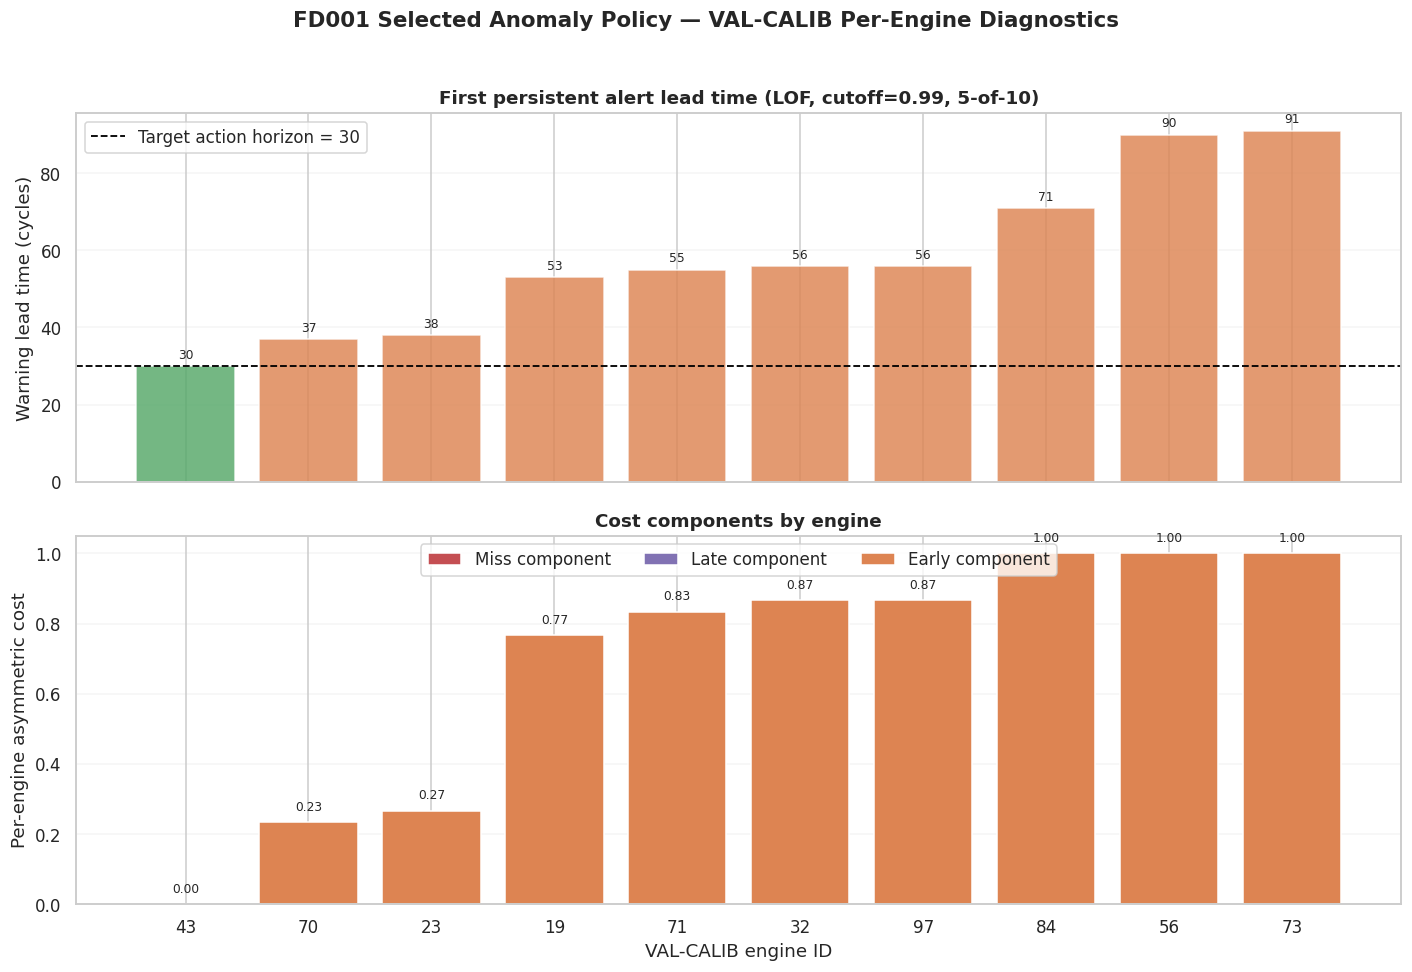

In [122]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
FIGURE_DIR = Path(config.FIGURES_DIR)

engine_results_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)
engine_results = pd.read_csv(
    engine_results_path
).sort_values(
    ["lead_time", "engine_id"],
    kind="mergesort",
).reset_index(drop=True)

assert len(engine_results) == 10
assert not engine_results["missed"].any()
assert np.all(
    engine_results["lead_time"] >= 1
)

display_columns = [
    "engine_id",
    "failure_cycle",
    "tau",
    "lead_time",
    "late_delay",
    "early_burden",
    "miss_component",
    "late_component",
    "early_component",
    "total_cost",
    "first_trigger_while_healthy",
]

print(" SELECTED POLICY — PER-ENGINE RESULTS ")
display(
    engine_results[
        display_columns
    ].round(6)
)

engine_labels = (
    engine_results["engine_id"]
    .astype(int)
    .astype(str)
    .to_numpy()
)
lead_times = engine_results[
    "lead_time"
].to_numpy(dtype=float)

lead_colors = np.where(
    lead_times < 30,
    "C3",
    np.where(
        lead_times > 30,
        "C1",
        "C2",
    ),
)

figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_task6_selected_policy_engine_diagnostics.png"
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True,
)

axes[0].bar(
    engine_labels,
    lead_times,
    color=lead_colors,
    alpha=0.82,
)

axes[0].axhline(
    30,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Target action horizon = 30",
)

for position, value in enumerate(lead_times):
    axes[0].text(
        position,
        value + 1.2,
        f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

axes[0].set_ylabel("Warning lead time (cycles)")
axes[0].set_title(
    (
        "First persistent alert lead time "
        "(LOF, cutoff=0.99, 5-of-10)"
    ),
    fontweight="bold",
)
axes[0].grid(
    axis="y",
    alpha=0.2,
)
axes[0].legend()

miss_components = engine_results[
    "miss_component"
].to_numpy(dtype=float)
late_components = engine_results[
    "late_component"
].to_numpy(dtype=float)
early_components = engine_results[
    "early_component"
].to_numpy(dtype=float)

axes[1].bar(
    engine_labels,
    miss_components,
    label="Miss component",
    color="C3",
)
axes[1].bar(
    engine_labels,
    late_components,
    bottom=miss_components,
    label="Late component",
    color="C4",
)
axes[1].bar(
    engine_labels,
    early_components,
    bottom=(
        miss_components + late_components
    ),
    label="Early component",
    color="C1",
)

for position, value in enumerate(
    engine_results["total_cost"]
):
    axes[1].text(
        position,
        float(value) + 0.025,
        f"{float(value):.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

axes[1].set_xlabel("VAL-CALIB engine ID")
axes[1].set_ylabel("Per-engine asymmetric cost")
axes[1].set_title(
    "Cost components by engine",
    fontweight="bold",
)
axes[1].grid(
    axis="y",
    alpha=0.2,
)
axes[1].legend(
    ncol=3,
    loc="upper center",
)

fig.suptitle(
    (
        f"{SUBSET} Selected Anomaly Policy — "
        "VAL-CALIB Per-Engine Diagnostics"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=(0, 0, 1, 0.96))

temporary_figure_path = Path(
    str(figure_path) + ".tmp.png"
)
fig.savefig(
    temporary_figure_path,
    dpi=160,
    bbox_inches="tight",
)
temporary_figure_path.replace(figure_path)

plt.show()
plt.close(fig)

lead_summary = pd.DataFrame([{
    "n_engines": len(engine_results),
    "missed_engines": int(
        engine_results["missed"].sum()
    ),
    "minimum_lead_time": float(
        lead_times.min()
    ),
    "lead_time_p25": float(
        np.quantile(lead_times, 0.25)
    ),
    "median_lead_time": float(
        np.median(lead_times)
    ),
    "lead_time_p75": float(
        np.quantile(lead_times, 0.75)
    ),
    "maximum_lead_time": float(
        lead_times.max()
    ),
    "mean_lead_time": float(
        lead_times.mean()
    ),
    "mean_total_cost": float(
        engine_results["total_cost"].mean()
    ),
    "mean_early_burden": float(
        engine_results["early_burden"].mean()
    ),
    "mean_late_delay": float(
        engine_results["late_delay"].mean()
    ),
}])


In [123]:
summary_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_lead_summary.csv"
)
temporary_summary_path = Path(
    str(summary_path) + ".tmp"
)
lead_summary.to_csv(
    temporary_summary_path,
    index=False,
)
temporary_summary_path.replace(summary_path)

print(" LEAD-TIME DISTRIBUTION SUMMARY ")
display(lead_summary.round(6))

print("Saved lead summary:", summary_path)
print("Saved per-engine figure:", figure_path)
print("Missed engines:", int(
    engine_results["missed"].sum()
))
print("Official test accessed: NO")
print("Official test status: SEALED")


 LEAD-TIME DISTRIBUTION SUMMARY 


,n_engines,missed_engines,minimum_lead_time,lead_time_p25,median_lead_time,lead_time_p75,maximum_lead_time,mean_lead_time,mean_total_cost,mean_early_burden,mean_late_delay
0,10,0,30.0,41.75,55.5,67.25,91.0,57.7,0.683333,27.7,0.0


Saved lead summary: artifacts/results/FD001_task6_selected_policy_lead_summary.csv
Saved per-engine figure: figures/FD001_task6_selected_policy_engine_diagnostics.png
Missed engines: 0
Official test accessed: NO
Official test status: SEALED


In [124]:
from pathlib import Path

import joblib
import pandas as pd


result_dir = Path(config.MODELS_DIR).parent / "results"

timeline_path = (
    result_dir
    / f"{SUBSET}_anomaly_val_calib_selected_timelines.csv"
)
engine_result_path = (
    result_dir
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)
policy_bundle_path = (
    Path(config.MODELS_DIR)
    / f"{SUBSET}_anomaly_policy_bundle.joblib"
)

timeline_check = pd.read_csv(timeline_path)
engine_result_check = pd.read_csv(engine_result_path)
policy_bundle_check = joblib.load(policy_bundle_path)

print("=" * 72)
print("VAL-CALIB TIMELINE SCHEMA")
print("=" * 72)
print("Shape:", timeline_check.shape)
print("Columns:")
print(timeline_check.columns.tolist())

print("\nLOF sample rows:")
if "family" in timeline_check.columns:
    display(
        timeline_check[
            timeline_check["family"].astype(str).str.lower() == "lof"
        ].head(3)
    )
else:
    display(timeline_check.head(3))

print("\n" + "=" * 72)
print("SELECTED POLICY ENGINE-RESULT SCHEMA")
print("=" * 72)
print("Shape:", engine_result_check.shape)
print("Columns:")
print(engine_result_check.columns.tolist())
display(engine_result_check.head(3))

print("\n" + "=" * 72)
print("POLICY BUNDLE")
print("=" * 72)
print("Type:", type(policy_bundle_check).__name__)

if isinstance(policy_bundle_check, dict):
    print("Top-level keys:", sorted(policy_bundle_check.keys()))

    for key, value in policy_bundle_check.items():
        if isinstance(value, dict):
            print(f"{key} keys:", sorted(value.keys()))
        else:
            print(f"{key}: {type(value).__name__}")

print("\nModel training performed: NO")
print("Official test accessed: NO")
print("Official test status: SEALED")


VAL-CALIB TIMELINE SCHEMA
Shape: (8104, 9)
Columns:
['engine_id', 'cycle', 'RUL', 'family', 'candidate_id', 'rul_region', 'raw_score', 'pooled_reference_percentile', 'engine_balanced_reference_percentile']

LOF sample rows:


,engine_id,cycle,RUL,family,candidate_id,rul_region,raw_score,pooled_reference_percentile,engine_balanced_reference_percentile
2026,19,1,157,lof,lof_k50,healthy,1.099402,0.816484,0.805556
2027,19,2,156,lof,lof_k50,healthy,0.987786,0.102198,0.099537
2028,19,3,155,lof,lof_k50,healthy,1.137616,0.896703,0.893519



SELECTED POLICY ENGINE-RESULT SCHEMA
Shape: (10, 25)
Columns:
['family', 'candidate_id', 'reference_type', 'cutoff', 'm', 'n', 'selection_eligible', 'engine_id', 'failure_cycle', 'first_satisfaction_cycle', 'tau', 'missed', 'trigger_at_failure_only', 'lead_time', 'late_delay', 'early_burden', 'late_normalized', 'early_normalized_uncapped', 'early_normalized_for_cost', 'miss_component', 'late_component', 'early_component', 'total_cost', 'first_trigger_while_healthy', 'n_cycle_gaps']


,family,candidate_id,reference_type,cutoff,m,n,selection_eligible,engine_id,failure_cycle,first_satisfaction_cycle,...,early_burden,late_normalized,early_normalized_uncapped,early_normalized_for_cost,miss_component,late_component,early_component,total_cost,first_trigger_while_healthy,n_cycle_gaps
0,lof,lof_k50,pooled,0.99,5,10,True,19,158,105.0,...,23,0.0,0.766667,0.766667,0.0,0.0,0.766667,0.766667,False,0
1,lof,lof_k50,pooled,0.99,5,10,True,23,168,130.0,...,8,0.0,0.266667,0.266667,0.0,0.0,0.266667,0.266667,False,0
2,lof,lof_k50,pooled,0.99,5,10,True,32,191,135.0,...,26,0.0,0.866667,0.866667,0.0,0.0,0.866667,0.866667,False,0



POLICY BUNDLE
Type: dict
Top-level keys: ['artifact_type', 'artifact_version', 'candidates', 'feature_columns', 'frozen_contract_path', 'frozen_contract_sha256', 'healthy_definition', 'official_test_status', 'per_family_policy_winners', 'persistence_status', 'preprocessor', 'proxy_definition', 'raw_score_is_probability', 'score_direction', 'selected_overall_policy', 'selected_within_family', 'selection_metric', 'subset', 'threshold_status', 'tie_break_order', 'val_calib_status']
artifact_type: str
artifact_version: int
subset: str
preprocessor: AnomalyPreprocessor
feature_columns: list
healthy_definition: str
proxy_definition keys: ['abnormal', 'excluded', 'healthy']
selection_metric: str
tie_break_order: list
selected_within_family keys: ['iforest', 'lof', 'ocsvm', 'pca']
candidates keys: ['iforest', 'lof', 'ocsvm', 'pca']
score_direction: str
raw_score_is_probability: bool
threshold_status: str
persistence_status: str
val_calib_status: str
official_test_status: str
frozen_contract_p

 SELECTED POLICY TRACE ENGINES 


,trace_role,engine_id,failure_cycle,tau,lead_time,early_burden,total_cost
0,minimum_lead,43,207,177.0,30.0,0,0.000000
4,median_representative,71,208,153.0,55.0,25,0.833333
9,maximum_lead,73,213,122.0,91.0,61,1.000000


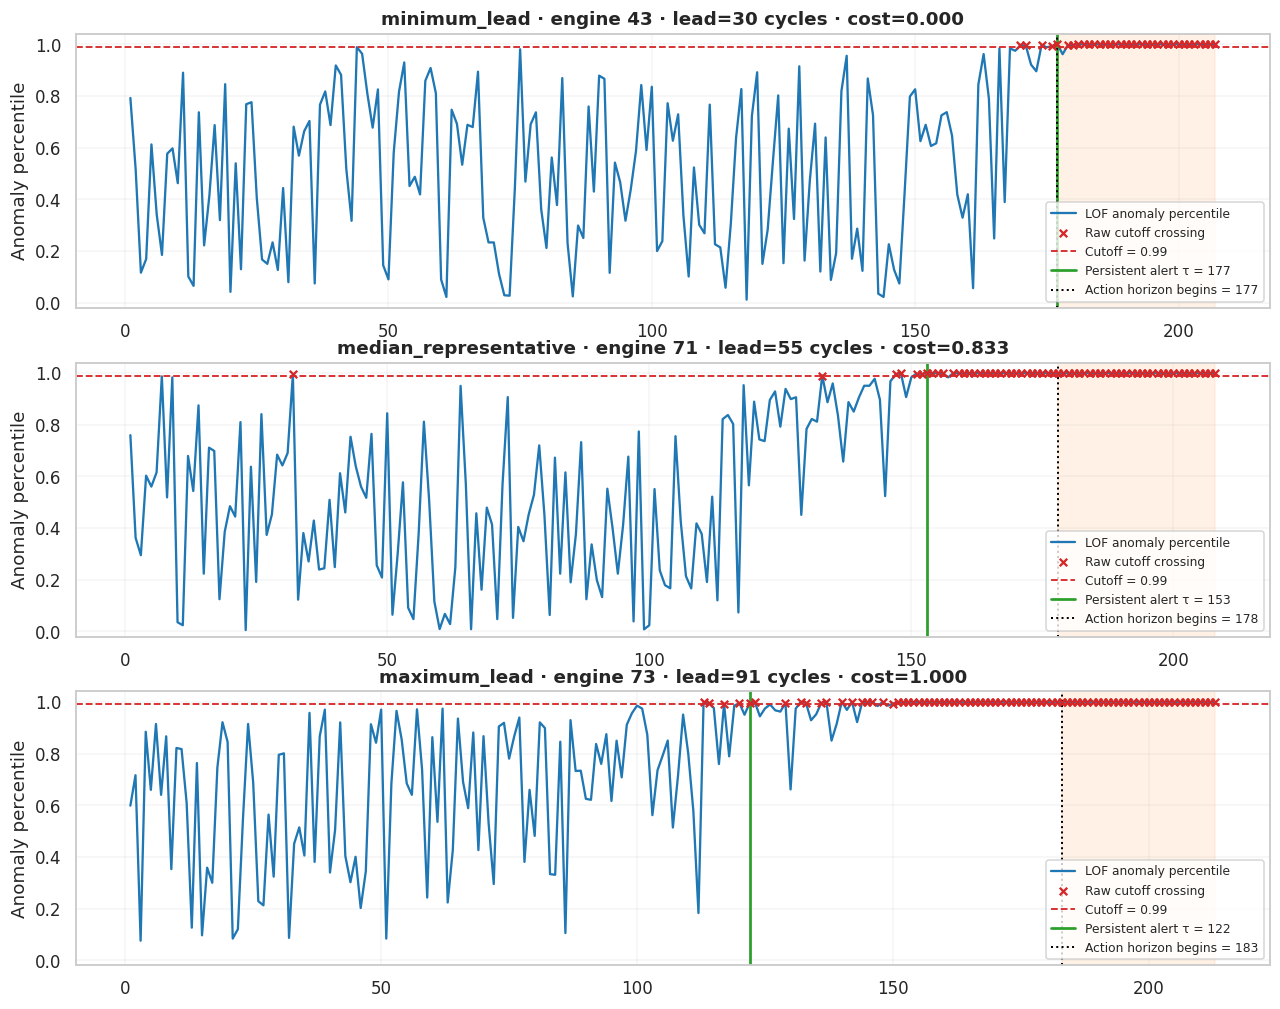

In [125]:
import os
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
FIGURE_DIR = Path(config.FIGURES_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

timeline = pd.read_csv(
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_calib_selected_timelines.csv"
)
engine_results = pd.read_csv(
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)

policy_row = engine_results.iloc[0]
family = str(policy_row["family"])
candidate_id = str(policy_row["candidate_id"])
cutoff = float(policy_row["cutoff"])
m_required = int(policy_row["m"])
n_window = int(policy_row["n"])
action_horizon = 30

assert family == "lof"
assert candidate_id == "lof_k50"
assert cutoff == 0.99
assert (m_required, n_window) == (5, 10)
assert engine_results["n_cycle_gaps"].eq(0).all()

ordered = engine_results.sort_values(
    ["lead_time", "engine_id"],
    kind="mergesort",
).reset_index(drop=True)

median_lead = float(ordered["lead_time"].median())
median_engine = (
    ordered.assign(
        median_distance=(
            ordered["lead_time"] - median_lead
        ).abs()
    )
    .sort_values(
        ["median_distance", "lead_time", "engine_id"],
        kind="mergesort",
    )
    .iloc[0]
)

selected_rows = pd.DataFrame(
    [
        ordered.iloc[0],
        median_engine,
        ordered.iloc[-1],
    ]
).copy()

selected_rows["trace_role"] = [
    "minimum_lead",
    "median_representative",
    "maximum_lead",
]

assert selected_rows["engine_id"].nunique() == 3

print(" SELECTED POLICY TRACE ENGINES ")
display(
    selected_rows[
        [
            "trace_role",
            "engine_id",
            "failure_cycle",
            "tau",
            "lead_time",
            "early_burden",
            "total_cost",
        ]
    ]
)


def reconstruct_persistence(frame, cutoff, m, n):
    frame = frame.sort_values("cycle").copy()
    recent = deque(maxlen=n)

    previous_cycle = None
    counts = []
    satisfied = []

    for cycle, percentile in zip(
        frame["cycle"],
        frame["pooled_reference_percentile"],
    ):
        cycle = int(cycle)

        if (
            previous_cycle is not None
            and cycle != previous_cycle + 1
        ):
            recent.clear()

        recent.append(float(percentile) >= cutoff)
        counts.append(int(sum(recent)))
        satisfied.append(int(sum(recent) >= m))
        previous_cycle = cycle

    frame["raw_crossing"] = (
        frame["pooled_reference_percentile"] >= cutoff
    )
    frame["trailing_crossing_count"] = counts
    frame["persistence_satisfied"] = satisfied
    frame["alert_latched"] = (
        frame["persistence_satisfied"].cummax().astype(bool)
    )
    return frame


trace_frames = []

for _, selected in selected_rows.iterrows():
    engine_id = int(selected["engine_id"])

    engine_trace = timeline[
        (timeline["family"] == family)
        & (timeline["candidate_id"] == candidate_id)
        & (timeline["engine_id"] == engine_id)
    ].copy()

    engine_trace = reconstruct_persistence(
        engine_trace,
        cutoff,
        m_required,
        n_window,
    )
    engine_trace["trace_role"] = selected["trace_role"]

    first_satisfaction = engine_trace.loc[
        engine_trace["persistence_satisfied"].eq(1),
        "cycle",
    ].min()

    assert int(first_satisfaction) == int(
        selected["first_satisfaction_cycle"]
    )
    assert int(first_satisfaction) == int(selected["tau"])

    trace_frames.append(engine_trace)

trace_data = pd.concat(trace_frames, ignore_index=True)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 11),
    sharey=True,
)

for ax, (_, selected) in zip(
    axes,
    selected_rows.iterrows(),
):
    engine_id = int(selected["engine_id"])
    failure_cycle = int(selected["failure_cycle"])
    tau = int(selected["tau"])
    action_start = failure_cycle - action_horizon

    g = trace_data[
        trace_data["engine_id"] == engine_id
    ].sort_values("cycle")

    ax.plot(
        g["cycle"],
        g["pooled_reference_percentile"],
        color="tab:blue",
        linewidth=1.5,
        label="LOF anomaly percentile",
    )

    crossing = g[g["raw_crossing"]]
    ax.scatter(
        crossing["cycle"],
        crossing["pooled_reference_percentile"],
        color="tab:red",
        marker="x",
        s=24,
        label="Raw cutoff crossing",
        zorder=3,
    )

    ax.axhline(
        cutoff,
        color="tab:red",
        linestyle="--",
        linewidth=1.2,
        label=f"Cutoff = {cutoff:.2f}",
    )
    ax.axvline(
        tau,
        color="tab:green",
        linewidth=1.8,
        label=f"Persistent alert τ = {tau}",
    )
    ax.axvline(
        action_start,
        color="black",
        linestyle=":",
        linewidth=1.3,
        label=f"Action horizon begins = {action_start}",
    )
    ax.axvspan(
        action_start,
        failure_cycle,
        color="tab:orange",
        alpha=0.10,
    )

    ax.set_title(
        f"{selected['trace_role']} · engine {engine_id} · "
        f"lead={int(selected['lead_time'])} cycles · "
        f"cost={selected['total_cost']:.3f}",
        fontweight="bold",
    )
    ax.set_ylabel("Anomaly percentile")
    ax.set_ylim(-0.02, 1.04)
    ax.grid(alpha=0.20)
    ax.legend(loc="lower right", fontsize=8)


In [126]:
axes[-1].set_xlabel("Cycle")

fig.suptitle(
    f"{SUBSET} Selected Anomaly Policy Traces — "
    "LOF, pooled cutoff=0.99, persistent 5-of-10",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.97))

figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_task6_selected_policy_traces.png"
)
temporary_figure = figure_path.with_name(
    figure_path.stem + ".tmp.png"
)
fig.savefig(
    temporary_figure,
    dpi=160,
    bbox_inches="tight",
)
os.replace(temporary_figure, figure_path)
plt.show()

trace_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_traces.csv"
)
temporary_trace = trace_path.with_name(
    trace_path.stem + ".tmp.csv"
)
trace_data.to_csv(temporary_trace, index=False)
os.replace(temporary_trace, trace_path)

selection_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_trace_engines.csv"
)
temporary_selection = selection_path.with_name(
    selection_path.stem + ".tmp.csv"
)
selected_rows.to_csv(temporary_selection, index=False)
os.replace(temporary_selection, selection_path)

print("\nPersistence reconstruction parity: PASS")
print("Cycle-gap reset contract: PASS")
print("Saved trace data:", trace_path)
print("Saved trace selection:", selection_path)
print("Model fitting performed: NO")
print("Official test accessed: NO")
print("Official test status: SEALED")



Persistence reconstruction parity: PASS
Cycle-gap reset contract: PASS
Saved trace data: artifacts/results/FD001_task6_selected_policy_traces.csv
Saved trace selection: artifacts/results/FD001_task6_selected_policy_trace_engines.csv
Model fitting performed: NO
Official test accessed: NO
Official test status: SEALED


In [127]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.json"
)
contract_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.sha256"
)
policy_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_policy_bundle.joblib"
)
engine_results_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)
bootstrap_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_bootstrap_ci.csv"
)
trace_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_traces.csv"
)

core_artifacts = {
    "preprocessing_bundle": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_preprocessing_bundle.joblib"
    ),
    "candidate_manifest": (
        PROCESSED_DIR
        / f"{SUBSET}_anomaly_train_candidates_manifest.json"
    ),
    "selected_family_bundle": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_selected_family_bundle.joblib"
    ),
    "frozen_policy_contract": contract_path,
    "selected_policy_bundle": policy_bundle_path,
    "selected_policy_result": (
        PROCESSED_DIR
        / f"{SUBSET}_task6_selected_anomaly_policy.json"
    ),
    "val_calib_timelines": (
        RESULT_DIR
        / f"{SUBSET}_anomaly_val_calib_selected_timelines.csv"
    ),
    "selected_policy_engine_results": engine_results_path,
    "selected_policy_bootstrap_ci": bootstrap_path,
    "selected_policy_traces": trace_path,
}

missing = [
    name
    for name, path in core_artifacts.items()
    if not path.is_file()
]
assert not missing, f"Missing anomaly artifacts: {missing}"


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


artifact_hashes = {
    name: {
        "path": str(path),
        "sha256": sha256_file(path),
        "size_bytes": int(path.stat().st_size),
    }
    for name, path in core_artifacts.items()
}
actual_contract_sha = sha256_file(contract_path)

sidecar_payload = json.loads(
    contract_sidecar_path.read_text(encoding="utf-8")
)

assert isinstance(sidecar_payload, dict)
assert "sha256" in sidecar_payload

sidecar_contract_sha = str(
    sidecar_payload["sha256"]
).strip().lower()

assert len(sidecar_contract_sha) == 64
assert actual_contract_sha == sidecar_contract_sha

policy_bundle = joblib.load(policy_bundle_path)
assert (
    policy_bundle["frozen_contract_sha256"]
    == actual_contract_sha
)
assert (
    str(policy_bundle["official_test_status"]).upper()
    == "SEALED"
)

selected = policy_bundle["selected_overall_policy"]

assert str(selected["family"]).lower() == "lof"
assert str(selected["candidate_id"]) == "lof_k50"
assert np.isclose(float(selected["cutoff"]), 0.99)
assert int(selected["m"]) == 5
assert int(selected["n"]) == 10

engine_results = pd.read_csv(engine_results_path)
assert len(engine_results) == 10
assert engine_results["engine_id"].nunique() == 10
assert engine_results["missed"].eq(False).all()
assert engine_results["n_cycle_gaps"].eq(0).all()
assert engine_results["first_trigger_while_healthy"].eq(False).all()
assert (
    engine_results["tau"]
    < engine_results["failure_cycle"]
).all()

assert np.allclose(
    engine_results["lead_time"],
    engine_results["failure_cycle"] - engine_results["tau"],
)
assert np.allclose(
    engine_results["total_cost"],
    engine_results[
        [
            "miss_component",
            "late_component",
            "early_component",
        ]
    ].sum(axis=1),
)
assert np.isclose(
    engine_results["total_cost"].mean(),
    float(selected["mean_total_cost"]),
)

bootstrap = pd.read_csv(bootstrap_path)
assert len(bootstrap) > 0
assert bootstrap["valid_draws"].eq(
    config.BOOTSTRAP_DRAWS
).all()
assert bootstrap["invalid_draws"].eq(0).all()

traces = pd.read_csv(trace_path)
assert traces["engine_id"].nunique() == 3
assert traces["alert_latched"].isin([True, False]).all()

readiness = {
    "artifact_type": "anomaly_development_readiness",
    "artifact_version": 1,
    "subset": SUBSET,
    "status": "READY_FOR_OFFICIAL_TEST_GATE_REVIEW",
    "selected_policy": {
        "family": "lof",
        "candidate_id": "lof_k50",
        "reference_type": "pooled",
        "cutoff": 0.99,
        "persistence": {
            "m": 5,
            "n": 10,
            "cycle_gap_reset": True,
            "alert_latched": True,
        },
    },
    "val_calib_diagnostics": {
        "n_engines": int(engine_results["engine_id"].nunique()),
        "missed_engines": int(engine_results["missed"].sum()),
        "minimum_lead_time": float(
            engine_results["lead_time"].min()
        ),
        "median_lead_time": float(
            engine_results["lead_time"].median()
        ),
        "mean_lead_time": float(
            engine_results["lead_time"].mean()
        ),
        "maximum_lead_time": float(
            engine_results["lead_time"].max()
        ),
        "mean_total_cost": float(
            engine_results["total_cost"].mean()
        ),
    },
    "integrity": {
        "frozen_contract_sha256": actual_contract_sha,
        "artifact_hashes": artifact_hashes,
        "per_engine_policy_checks": "PASS",
        "bootstrap_checks": "PASS",
        "trace_reconstruction_checks": "PASS",
    },
    "official_test_gate": {
        "status": "SEALED",
        "accessed_in_this_cell": False,
        "evaluation_authorized": False,
    },
    "limitations": [
        "VAL-CALIB contains only 10 engines.",
        "VAL-CALIB diagnostics are not independent test results.",
        "Zero observed misses does not prove zero population miss rate.",
    ],
}


In [128]:
readiness_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_development_readiness.json"
)
temporary_readiness = readiness_path.with_name(
    readiness_path.stem + ".tmp.json"
)

temporary_readiness.write_text(
    json.dumps(
        readiness,
        indent=2,
        sort_keys=True,
        ensure_ascii=False,
    )
    + "\n",
    encoding="utf-8",
)
os.replace(temporary_readiness, readiness_path)

readiness_sha = sha256_file(readiness_path)
readiness_sidecar = readiness_path.with_suffix(".sha256")
temporary_sidecar = readiness_sidecar.with_name(
    readiness_sidecar.stem + ".tmp.sha256"
)
temporary_sidecar.write_text(
    readiness_sha + "\n",
    encoding="utf-8",
)
os.replace(temporary_sidecar, readiness_sidecar)

reloaded_readiness = json.loads(
    readiness_path.read_text(encoding="utf-8")
)
assert (
    reloaded_readiness["status"]
    == "READY_FOR_OFFICIAL_TEST_GATE_REVIEW"
)
assert sha256_file(readiness_path) == (
    readiness_sidecar
    .read_text(encoding="utf-8")
    .strip()
)

print(" FD001 ANOMALY DEVELOPMENT READINESS AUDIT ")
print("Core artifacts:", len(core_artifacts))
print("Selected policy: LOF / cutoff=0.99 / 5-of-10")
print("Per-engine policy integrity: PASS")
print("Frozen-contract integrity: PASS")
print("Bootstrap integrity: PASS")
print("Trace integrity: PASS")
print("Readiness status:", readiness["status"])
print("Saved readiness:", readiness_path)
print("Readiness SHA256:", readiness_sha)
print("Official test accessed: NO")
print("Official test status: SEALED")


 FD001 ANOMALY DEVELOPMENT READINESS AUDIT 
Core artifacts: 10
Selected policy: LOF / cutoff=0.99 / 5-of-10
Per-engine policy integrity: PASS
Frozen-contract integrity: PASS
Bootstrap integrity: PASS
Trace integrity: PASS
Readiness status: READY_FOR_OFFICIAL_TEST_GATE_REVIEW
Saved readiness: data/processed/FD001_anomaly_development_readiness.json
Readiness SHA256: 5e56cdacee65d694dd41cf1b34c7abd13f342dd1eb4db597e94c4c070fefac78
Official test accessed: NO
Official test status: SEALED


In [129]:
import inspect
from pathlib import Path


print("=" * 72)
print("DATA-LOADER FUNCTIONS RELEVANT TO TEST/RUL")
print("=" * 72)

relevant_functions = []

for name, obj in inspect.getmembers(dl, inspect.isfunction):
    lowered = name.lower()

    if any(
        token in lowered
        for token in ("load", "test", "rul", "target")
    ):
        relevant_functions.append((name, obj))

for name, obj in relevant_functions:
    print(f"\n{name}{inspect.signature(obj)}")
    print("-" * 72)

    try:
        print(inspect.getsource(obj))
    except (OSError, TypeError):
        print("Source unavailable")


print("\n" + "=" * 72)
print("RAW-DATA DIRECTORY METADATA")
print("=" * 72)

raw_dir = None

for attribute in (
    "DATA_RAW",
    "RAW_DATA_DIR",
    "DATA_RAW_DIR",
):
    value = getattr(config, attribute, None)

    if value is not None:
        raw_dir = Path(value)
        print(f"Resolved from config.{attribute}: {raw_dir}")
        break

if raw_dir is None:
    project_root = Path(config.DATA_PROCESSED).parents[1]
    raw_dir = project_root / "data" / "raw"
    print("Resolved by project layout:", raw_dir)

assert raw_dir.is_dir(), f"Raw-data directory not found: {raw_dir}"

metadata_rows = []

for path in sorted(raw_dir.glob(f"*{SUBSET}*")):
    if path.is_file():
        metadata_rows.append(
            {
                "file_name": path.name,
                "size_bytes": int(path.stat().st_size),
            }
        )

if metadata_rows:
    display(pd.DataFrame(metadata_rows))
else:
    print(f"No files matching *{SUBSET}* found.")

print("\nLoader called: NO")
print("Official test file contents accessed: NO")
print("Official RUL file contents accessed: NO")
print("Official test status: SEALED")


DATA-LOADER FUNCTIONS RELEVANT TO TEST/RUL

add_train_rul(df: 'pd.DataFrame', cap: 'int | None' = None) -> 'pd.DataFrame'
------------------------------------------------------------------------
def add_train_rul(df: pd.DataFrame, cap: int | None = None) -> pd.DataFrame:
    """
    Add RUL target for TRAIN data (run-to-failure).
    RUL(i, t) = T(i) - t, where T(i) = max cycle of engine i.

    Parameters
    ----------
    cap : optional int. If given, RUL is clipped to [0, cap] (piecewise-linear).
    """
    df = df.copy()
    max_cycle = df.groupby("engine_id")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    if cap is not None:
        df["RUL"] = df["RUL"].clip(upper=cap)
    return df


load_raw(subset: 'str', split: 'str') -> 'pd.DataFrame'
------------------------------------------------------------------------
def load_raw(subset: str, split: str) -> pd.DataFrame:
    # Load a raw C-MAPSS file and assign explicit column names
    if subset not in config.

,file_name,size_bytes
0,RUL_FD001.txt,429
1,test_FD001.txt,2228855
2,train_FD001.txt,3515356



Loader called: NO
Official test file contents accessed: NO
Official RUL file contents accessed: NO
Official test status: SEALED


In [130]:
import hashlib
import json
from pathlib import Path

import joblib


MODEL_DIR = Path(config.MODELS_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)

artifact_paths = {
    "regression_bundle": (
        MODEL_DIR / f"{SUBSET}_regression_bundle.joblib"
    ),
    "classification_bundle": (
        MODEL_DIR / f"{SUBSET}_classification_bundle.joblib"
    ),
    "anomaly_policy_bundle": (
        MODEL_DIR / f"{SUBSET}_anomaly_policy_bundle.joblib"
    ),
    "rul_conformal_contract": (
        PROCESSED_DIR / f"{SUBSET}_rul_conformal.json"
    ),
    "classification_threshold_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_classification_thresholds.json"
    ),
    "anomaly_readiness_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_anomaly_development_readiness.json"
    ),
}

missing = [
    name
    for name, path in artifact_paths.items()
    if not path.is_file()
]
assert not missing, f"Missing frozen artifacts: {missing}"


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)
    return digest.hexdigest()


def describe_mapping(mapping, prefix=""):
    for key, value in mapping.items():
        label = f"{prefix}{key}"

        if isinstance(value, dict):
            print(
                f"{label}: dict keys="
                f"{sorted(value.keys())}"
            )
        elif isinstance(value, (list, tuple)):
            print(
                f"{label}: {type(value).__name__}"
                f"(length={len(value)})"
            )
        else:
            print(f"{label}: {type(value).__name__}")


print("=" * 72)
print("FROZEN MODEL BUNDLES")
print("=" * 72)

for name in (
    "regression_bundle",
    "classification_bundle",
    "anomaly_policy_bundle",
):
    path = artifact_paths[name]
    bundle = joblib.load(path)

    print(f"\n{name}")
    print("Path:", path)
    print("SHA256:", sha256_file(path))
    print("Type:", type(bundle).__name__)

    if isinstance(bundle, dict):
        describe_mapping(bundle)
    else:
        print("Object:", type(bundle).__name__)


print("\n" + "=" * 72)
print("FROZEN JSON CONTRACTS")
print("=" * 72)

for name in (
    "rul_conformal_contract",
    "classification_threshold_contract",
    "anomaly_readiness_contract",
):
    path = artifact_paths[name]
    payload = json.loads(
        path.read_text(encoding="utf-8")
    )

    print(f"\n{name}")
    print("Path:", path)
    print("SHA256:", sha256_file(path))
    print("Type:", type(payload).__name__)

    if isinstance(payload, dict):
        describe_mapping(payload)


print("\n" + "=" * 72)
print("OFFICIAL TEST GATE STATUS")
print("=" * 72)
print(
    "Expected FD001 test engines:",
    config.DATASET_INFO[SUBSET]["test_engines"],
)
print("Frozen artifacts found:", len(artifact_paths))
print("Model refitting performed: NO")
print("Threshold recalculation performed: NO")
print("Official test loader called: NO")
print("Official RUL loader called: NO")
print("Official test status: SEALED")


FROZEN MODEL BUNDLES

regression_bundle
Path: artifacts/models/FD001_regression_bundle.joblib
SHA256: 091009e2b1aff9b77ea0378d91105c6715f311c2cc31fe2a99a452843fbac9a6
Type: dict
schema_version: int
subset: str
feature_pipeline: FeaturePipeline
model: GradientBoostingRegressor
model_name: str
model_parameters: dict keys=['learning_rate', 'max_depth', 'n_estimators']
scaled_features: bool
representation: str
window: int
include_settings: bool
cap: int
fit_role: str
selection_role: str
calibration_role: str
official_test_status: str

classification_bundle
Path: artifacts/models/FD001_classification_bundle.joblib
SHA256: 9f54d9da77012489642d366edad8ee33e391f931649e837fc296c4c679eac157
Type: dict
artifact_type: str
artifact_version: int
subset: str
horizons: list(length=3)
fit_partition: str
selection_partition: str
calibration_partition: str
calibration_method: str
monotonicity_rule: str
threshold_status: str
official_test_status: str
source_raw_bundle_sha256: str
classifiers: dict keys=['

In [131]:
import hashlib
import json
import os
from pathlib import Path

import joblib


MODEL_DIR = Path(config.MODELS_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)

frozen_paths = {
    "regression_bundle": (
        MODEL_DIR / f"{SUBSET}_regression_bundle.joblib"
    ),
    "classification_bundle": (
        MODEL_DIR / f"{SUBSET}_classification_bundle.joblib"
    ),
    "anomaly_policy_bundle": (
        MODEL_DIR / f"{SUBSET}_anomaly_policy_bundle.joblib"
    ),
    "rul_conformal_contract": (
        PROCESSED_DIR / f"{SUBSET}_rul_conformal.json"
    ),
    "classification_threshold_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_classification_thresholds.json"
    ),
    "anomaly_readiness_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_anomaly_development_readiness.json"
    ),
}


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)
    return digest.hexdigest()


assert all(path.is_file() for path in frozen_paths.values())

artifact_hashes = {
    name: {
        "path": str(path),
        "sha256": sha256_file(path),
        "size_bytes": int(path.stat().st_size),
    }
    for name, path in frozen_paths.items()
}

regression_bundle = joblib.load(
    frozen_paths["regression_bundle"]
)
classification_bundle = joblib.load(
    frozen_paths["classification_bundle"]
)
anomaly_bundle = joblib.load(
    frozen_paths["anomaly_policy_bundle"]
)

conformal_contract = json.loads(
    frozen_paths["rul_conformal_contract"].read_text(
        encoding="utf-8"
    )
)
threshold_contract = json.loads(
    frozen_paths[
        "classification_threshold_contract"
    ].read_text(encoding="utf-8")
)
anomaly_readiness = json.loads(
    frozen_paths["anomaly_readiness_contract"].read_text(
        encoding="utf-8"
    )
)

assert (
    conformal_contract["regression_bundle"]["sha256"]
    == artifact_hashes["regression_bundle"]["sha256"]
)
assert (
    threshold_contract["classification_bundle_sha256"]
    == artifact_hashes["classification_bundle"]["sha256"]
)
assert (
    anomaly_readiness["status"]
    == "READY_FOR_OFFICIAL_TEST_GATE_REVIEW"
)

for bundle in (
    regression_bundle,
    classification_bundle,
    anomaly_bundle,
):
    assert str(bundle["official_test_status"]).upper() == "SEALED"

selected_anomaly = anomaly_bundle["selected_overall_policy"]

test_contract = {
    "artifact_type": "official_test_evaluation_contract",
    "artifact_version": 1,
    "subset": SUBSET,
    "status": "READY_TO_UNSEAL",
    "created_before_official_test_access": True,
    "expected_test_engines": int(
        config.DATASET_INFO[SUBSET]["test_engines"]
    ),
    "loader": {
        "function": "data_loader.load_test_with_rul",
        "cap_argument": None,
        "truth": "uncapped row-level RUL",
        "virtual_failure_cycle": (
            "last_observed_cycle + official_final_RUL"
        ),
    },
    "frozen_artifacts": artifact_hashes,
    "regression_evaluation": {
        "model": regression_bundle["model_name"],
        "representation": regression_bundle["representation"],
        "window": int(regression_bundle["window"]),
        "include_settings": bool(
            regression_bundle["include_settings"]
        ),
        "training_target_cap": int(regression_bundle["cap"]),
        "prediction_clipping": "lower_bound_zero",
        "primary_unit": "last_observed_row_per_engine",
        "primary_truth": "uncapped_RUL",
        "primary_metrics": [
            "PHM_score_mean",
            "PHM_score_sum",
            "MAE",
            "RMSE",
            "R2",
        ],
        "secondary_evaluation": (
            "observed rows with uncapped RUL <= 100"
        ),
        "conformal": {
            "coverage_target": float(
                conformal_contract["coverage_target"]
            ),
            "residual_quantile": float(
                conformal_contract["residual_quantile"]
            ),
            "lower_bound_clipped_at_zero": True,
            "evaluate_on": [
                "last_observed_row_per_engine",
                "all_observed_rows",
            ],
        },
    },
    "classification_evaluation": {
        "horizons": [
            int(h)
            for h in classification_bundle["horizons"]
        ],
        "probability_pipeline": (
            "raw classifier -> Platt -> "
            "cumulative-max horizon monotonicity"
        ),
        "threshold_policy": "frozen_FN10_FP1",
        "thresholds": {
            str(h): float(value)
            for h, value in classification_bundle[
                "thresholds"
            ].items()
        },
        "primary_unit": "all_observed_engine-cycle_rows",
        "operational_secondary_unit": (
            "last_observed_row_per_engine"
        ),
        "metrics": [
            "PR_AUC",
            "Brier",
            "precision",
            "recall",
            "F1",
            "confusion_matrix",
        ],
        "threshold_reoptimization": False,
        "probability_recalibration": False,
    },
    "anomaly_evaluation": {
        "family": str(selected_anomaly["family"]),
        "candidate_id": str(
            selected_anomaly["candidate_id"]
        ),
        "reference_type": str(
            selected_anomaly["reference_type"]
        ),
        "cutoff": float(selected_anomaly["cutoff"]),
        "persistence": {
            "m": int(selected_anomaly["m"]),
            "n": int(selected_anomaly["n"]),
            "cycle_gap_reset": True,
            "alert_latched": True,
        },
        "observed_alert_metrics": [
            "fraction_alerted_before_observation_end",
            "lead_time_to_virtual_failure_if_alerted",
            "final_observed_anomaly_percentile",
        ],
        "proxy_regions_if_available": {
            "healthy": "RUL > 125",
            "near_failure": "RUL <= 30",
            "middle": "excluded from proxy AUC",
        },
        "censoring_rule": (
            "No alert before final observed cycle is "
            "reported as censored/no-alert-by-observation-end; "
            "it is not counted as a confirmed missed failure."
        ),
        "asymmetric_cost_on_truncated_test": (
            "not reported as directly comparable to "
            "run-to-failure VAL-CALIB cost"
        ),
    },
    "uncertainty": {
        "resampling_unit": "engine_id",
        "bootstrap_draws": int(config.BOOTSTRAP_DRAWS),
        "seed": int(config.RANDOM_SEED),
        "confidence_level": 0.95,
    },
    "prohibitions_after_unsealing": [
        "No model refitting.",
        "No feature reselection.",
        "No probability recalibration.",
        "No threshold or persistence reoptimization.",
        "No conformal-quantile recalculation.",
    ],
    "official_test_gate": {
        "current_status": "SEALED",
        "accessed_in_this_cell": False,
        "next_action": (
            "one-time load, structural validation, "
            "and immutable access record"
        ),
    },
}


In [132]:
contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)
temporary_contract = contract_path.with_name(
    contract_path.stem + ".tmp.json"
)

temporary_contract.write_text(
    json.dumps(
        test_contract,
        indent=2,
        sort_keys=True,
        ensure_ascii=False,
    )
    + "\n",
    encoding="utf-8",
)
os.replace(temporary_contract, contract_path)

contract_sha = sha256_file(contract_path)

sidecar_path = contract_path.with_suffix(".sha256")
temporary_sidecar = sidecar_path.with_name(
    sidecar_path.stem + ".tmp.sha256"
)
temporary_sidecar.write_text(
    json.dumps(
        {
            "file": str(contract_path),
            "sha256": contract_sha,
        },
        indent=2,
        sort_keys=True,
    )
    + "\n",
    encoding="utf-8",
)
os.replace(temporary_sidecar, sidecar_path)


reloaded = json.loads(
    contract_path.read_text(encoding="utf-8")
)
sidecar = json.loads(
    sidecar_path.read_text(encoding="utf-8")
)

assert reloaded["status"] == "READY_TO_UNSEAL"
assert sidecar["sha256"] == sha256_file(contract_path)
assert (
    reloaded["official_test_gate"]["current_status"]
    == "SEALED"
)

print(" FD001 OFFICIAL-TEST EVALUATION CONTRACT ")
print("Frozen artifacts:", len(frozen_paths))
print("Regression rules: LOCKED")
print("Classification rules: LOCKED")
print("Anomaly policy and censoring rule: LOCKED")
print("Bootstrap protocol: LOCKED")
print("Saved contract:", contract_path)
print("Contract SHA256:", contract_sha)
print("Contract reload integrity: PASS")
print("Official test accessed in this cell: NO")
print("Official test status: SEALED")
print("Next status: READY_TO_UNSEAL")


 FD001 OFFICIAL-TEST EVALUATION CONTRACT 
Frozen artifacts: 6
Regression rules: LOCKED
Classification rules: LOCKED
Anomaly policy and censoring rule: LOCKED
Bootstrap protocol: LOCKED
Saved contract: data/processed/FD001_official_test_evaluation_contract.json
Contract SHA256: f415f8aa3ed36842792fc90990eef5ba7f9ea2ee86e5c957255733db066d747a
Contract reload integrity: PASS
Official test accessed in this cell: NO
Official test status: SEALED
Next status: READY_TO_UNSEAL


### One-time official-test unsealing with computed integrity evidence


In [133]:
import hashlib
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd


PROCESSED_DIR = Path(config.DATA_PROCESSED)
RAW_DIR = Path(config.DATA_RAW)

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)
contract_sidecar_path = contract_path.with_suffix(".sha256")

test_path = RAW_DIR / f"test_{SUBSET}.txt"
rul_path = RAW_DIR / f"RUL_{SUBSET}.txt"

required_paths = {
    "evaluation_contract": contract_path,
    "evaluation_contract_sidecar": contract_sidecar_path,
    "official_test": test_path,
    "official_rul": rul_path,
}

missing_paths = {
    name: str(path)
    for name, path in required_paths.items()
    if not path.is_file()
}

assert not missing_paths, (
    f"Missing required files: {missing_paths}"
)


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()






test_contract = json.loads(
    contract_path.read_text(encoding="utf-8")
)
contract_sidecar = json.loads(
    contract_sidecar_path.read_text(encoding="utf-8")
)

contract_sha = sha256_file(contract_path)

contract_hash_valid = (
    str(contract_sidecar.get("sha256", "")).lower()
    == contract_sha.lower()
)

contract_status_valid = (
    test_contract.get("status") == "READY_TO_UNSEAL"
)

contract_created_before_access = (
    test_contract.get(
        "created_before_official_test_access"
    )
    is True
)

contract_gate_was_sealed = (
    test_contract
    .get("official_test_gate", {})
    .get("current_status")
    == "SEALED"
)

pre_access_contract_checks = {
    "evaluation_contract_hash_valid": (
        contract_hash_valid
    ),
    "evaluation_contract_ready_to_unseal": (
        contract_status_valid
    ),
    "contract_created_before_test_access": (
        contract_created_before_access
    ),
    "contract_gate_was_sealed": (
        contract_gate_was_sealed
    ),
}

failed_pre_access_checks = [
    name
    for name, passed
    in pre_access_contract_checks.items()
    if not bool(passed)
]

assert not failed_pre_access_checks, (
    "Official-Test gate validation failed before access: "
    f"{failed_pre_access_checks}"
)






frozen_artifact_metadata = test_contract[
    "frozen_artifacts"
]

locked_artifact_paths = {
    name: Path(metadata["path"])
    for name, metadata
    in frozen_artifact_metadata.items()
}

locked_hashes_expected = {
    name: str(metadata["sha256"]).lower()
    for name, metadata
    in frozen_artifact_metadata.items()
}

missing_locked_artifacts = {
    name: str(path)
    for name, path in locked_artifact_paths.items()
    if not path.is_file()
}

assert not missing_locked_artifacts, (
    "Frozen artifacts are missing: "
    f"{missing_locked_artifacts}"
)

locked_hashes_before = {
    name: sha256_file(path).lower()
    for name, path in locked_artifact_paths.items()
}

frozen_artifacts_match_contract_before = (
    locked_hashes_before
    == locked_hashes_expected
)

assert frozen_artifacts_match_contract_before, (
    "At least one frozen artifact differs from the "
    "hash stored before Test access."
)






df_test_official = dl.load_test_with_rul(
    SUBSET,
    cap=None,
)

expected_engines = int(
    test_contract["expected_test_engines"]
)
expected_columns = list(config.ALL_COLS) + ["RUL"]






engine_ids = sorted(
    df_test_official["engine_id"]
    .unique()
    .tolist()
)

numeric_matrix = (
    df_test_official
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=float)
)

contiguous_cycle_flags = {}
rul_step_flags = {}
virtual_failure_flags = {}
starts_at_cycle_one_flags = {}

for engine_id, group in df_test_official.groupby(
    "engine_id",
    sort=True,
):
    group = group.sort_values("cycle")

    cycles = group["cycle"].to_numpy(dtype=int)
    rul_values = group["RUL"].to_numpy(dtype=float)

    cycle_differences = np.diff(cycles)
    rul_differences = np.diff(rul_values)

    virtual_failure_cycles = (
        cycles.astype(float) + rul_values
    )

    starts_at_cycle_one_flags[int(engine_id)] = (
        int(cycles[0]) == 1
    )
    contiguous_cycle_flags[int(engine_id)] = bool(
        np.all(cycle_differences == 1)
    )
    rul_step_flags[int(engine_id)] = bool(
        np.allclose(rul_differences, -1.0)
    )
    virtual_failure_flags[int(engine_id)] = bool(
        np.allclose(
            virtual_failure_cycles,
            virtual_failure_cycles[0],
        )
    )


In [134]:
final_indices = (
    df_test_official
    .groupby("engine_id")["cycle"]
    .idxmax()
)

df_test_final = (
    df_test_official
    .loc[final_indices]
    .sort_values("engine_id")
    .reset_index(drop=True)
)

df_test_final["virtual_failure_cycle"] = (
    df_test_final["cycle"]
    + df_test_final["RUL"]
)

structural_checks = {
    "expected_column_order": (
        list(df_test_official.columns)
        == expected_columns
    ),
    "expected_engine_count": (
        df_test_official["engine_id"].nunique()
        == expected_engines
    ),
    "sequential_engine_ids": (
        engine_ids
        == list(range(1, expected_engines + 1))
    ),
    "unique_dataframe_index": (
        df_test_official.index.is_unique
    ),
    "unique_engine_cycle_keys": (
        not df_test_official.duplicated(
            ["engine_id", "cycle"]
        ).any()
    ),
    "all_numeric_values_finite": bool(
        np.isfinite(numeric_matrix).all()
    ),
    "nonnegative_row_rul": bool(
        df_test_official["RUL"].ge(0).all()
    ),
    "integer_valued_rul": bool(
        np.allclose(
            df_test_official["RUL"],
            np.round(df_test_official["RUL"]),
        )
    ),
    "every_engine_starts_at_cycle_one": bool(
        all(starts_at_cycle_one_flags.values())
    ),
    "contiguous_cycles_for_every_engine": bool(
        all(contiguous_cycle_flags.values())
    ),
    "rul_decreases_one_per_cycle": bool(
        all(rul_step_flags.values())
    ),
    "constant_virtual_failure_cycle": bool(
        all(virtual_failure_flags.values())
    ),
    "one_final_snapshot_per_engine": (
        len(df_test_final) == expected_engines
        and df_test_final["engine_id"].nunique()
        == expected_engines
    ),
}

failed_structural_checks = [
    name
    for name, passed in structural_checks.items()
    if not bool(passed)
]

assert not failed_structural_checks, (
    "Official-Test structural validation failed: "
    f"{failed_structural_checks}"
)






locked_hashes_after = {
    name: sha256_file(path).lower()
    for name, path in locked_artifact_paths.items()
}

frozen_artifacts_unchanged = (
    locked_hashes_after == locked_hashes_before
)

assert frozen_artifacts_unchanged, (
    "At least one frozen artifact changed during "
    "Official-Test structural loading."
)






structural_summary = {
    "n_rows": int(len(df_test_official)),
    "n_engines": int(
        df_test_official["engine_id"].nunique()
    ),
    "n_columns": int(
        df_test_official.shape[1]
    ),
    "minimum_observed_cycle": int(
        df_test_official["cycle"].min()
    ),
    "maximum_observed_cycle": int(
        df_test_official["cycle"].max()
    ),
    "minimum_row_rul": float(
        df_test_official["RUL"].min()
    ),
    "maximum_row_rul": float(
        df_test_official["RUL"].max()
    ),
    "minimum_final_rul": float(
        df_test_final["RUL"].min()
    ),
    "maximum_final_rul": float(
        df_test_final["RUL"].max()
    ),
    "minimum_virtual_failure_cycle": float(
        df_test_final[
            "virtual_failure_cycle"
        ].min()
    ),
    "maximum_virtual_failure_cycle": float(
        df_test_final[
            "virtual_failure_cycle"
        ].max()
    ),
}

official_input_hashes = {
    "test_file": {
        "path": str(test_path),
        "sha256": sha256_file(test_path),
        "size_bytes": int(
            test_path.stat().st_size
        ),
    },
    "rul_file": {
        "path": str(rul_path),
        "sha256": sha256_file(rul_path),
        "size_bytes": int(
            rul_path.stat().st_size
        ),
    },
}






access_record = {
    "artifact_type": "official_test_access_record",
    "artifact_version": 1,
    "subset": SUBSET,
    "status": "UNSEALED_FOR_EVALUATION",
    "evaluation_contract": {
        "path": str(contract_path),
        "sha256": contract_sha,
    },
    "official_inputs": official_input_hashes,
    "loader": {
        "function": (
            "data_loader.load_test_with_rul"
        ),
        "cap": None,
    },
    "structural_summary": structural_summary,
    "computed_checks": {
        **{
            name: bool(value)
            for name, value
            in pre_access_contract_checks.items()
        },
        **{
            name: bool(value)
            for name, value
            in structural_checks.items()
        },
        "frozen_artifacts_match_contract_before": bool(
            frozen_artifacts_match_contract_before
        ),
        "frozen_artifacts_unchanged_after": bool(
            frozen_artifacts_unchanged
        ),
    },
    "cell_scope": {
        "allowed_operations": [
            "load official test rows",
            "attach official row-level RUL",
            "perform structural validation",
            "write immutable access record",
        ],
        "prohibited_operations": [
            "model fitting",
            "model prediction",
            "feature selection",
            "probability recalibration",
            "threshold reoptimization",
        ],
        "note": (
            "The prohibited-operation list is a declared "
            "execution boundary. Frozen-artifact hashes "
            "before and after the cell provide runtime "
            "evidence that persisted models and contracts "
            "were not modified."
        ),
    },
}


In [135]:
access_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.json"
)

serialized_access_record = (
    json.dumps(
        access_record,
        indent=2,
        sort_keys=True,
        ensure_ascii=False,
    )
    + "\n"
)

if access_path.exists():
    existing_access_record = (
        access_path.read_text(encoding="utf-8")
    )
    access_mode = (
        "IDEMPOTENT_VERIFIED_RELOAD"
        if existing_access_record == serialized_access_record
        else "REGENERATED_AUDIT_RECORD"
    )
else:
    access_mode = "INITIAL_UNSEAL"

if access_mode != "IDEMPOTENT_VERIFIED_RELOAD":
    temporary_access_path = access_path.with_name(
        access_path.stem + ".tmp.json"
    )

    temporary_access_path.write_text(
        serialized_access_record,
        encoding="utf-8",
    )

    os.replace(
        temporary_access_path,
        access_path,
    )

access_sha = sha256_file(access_path)

access_sidecar_path = access_path.with_suffix(
    ".sha256"
)

access_sidecar_payload = {
    "file": str(access_path),
    "sha256": access_sha,
}

serialized_access_sidecar = (
    json.dumps(
        access_sidecar_payload,
        indent=2,
        sort_keys=True,
    )
    + "\n"
)

existing_sidecar_text = (
    access_sidecar_path.read_text(encoding="utf-8")
    if access_sidecar_path.exists()
    else None
)

if existing_sidecar_text != serialized_access_sidecar:
    temporary_sidecar_path = (
        access_sidecar_path.with_name(
            access_sidecar_path.stem
            + ".tmp.sha256"
        )
    )

    temporary_sidecar_path.write_text(
        serialized_access_sidecar,
        encoding="utf-8",
    )

    os.replace(
        temporary_sidecar_path,
        access_sidecar_path,
    )






reloaded_access_record = json.loads(
    access_path.read_text(encoding="utf-8")
)
reloaded_access_sidecar = json.loads(
    access_sidecar_path.read_text(
        encoding="utf-8"
    )
)

post_persistence_checks = {
    "access_record_reloads": (
        reloaded_access_record
        == access_record
    ),
    "access_record_hash_valid": (
        reloaded_access_sidecar["sha256"]
        == sha256_file(access_path)
    ),
    "access_record_status_unsealed": (
        reloaded_access_record["status"]
        == "UNSEALED_FOR_EVALUATION"
    ),
}

all_checks = {
    **pre_access_contract_checks,
    **structural_checks,
    "frozen_artifacts_match_contract_before": (
        frozen_artifacts_match_contract_before
    ),
    "frozen_artifacts_unchanged_after": (
        frozen_artifacts_unchanged
    ),
    **post_persistence_checks,
}

check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed in all_checks.items()
    ]
)

failed_checks = check_table.loc[
    ~check_table["passed"],
    "check",
].tolist()

assert not failed_checks, (
    f"Final Official-Test checks failed: "
    f"{failed_checks}"
)

overall_status = (
    "PASS"
    if check_table["passed"].all()
    else "FAIL"
)

print(" COMPUTED OFFICIAL-TEST CHECKS ")
display(check_table)

print("\n FD001 OFFICIAL TEST STRUCTURAL VALIDATION ")
print("Access mode:", access_mode)
print("Rows:", len(df_test_official))
print(
    "Engines:",
    df_test_official["engine_id"].nunique(),
)
print("Final snapshots:", len(df_test_final))
print("Executed checks:", len(check_table))
print("Failed checks:", len(failed_checks))
print("Overall structural status:", overall_status)
print(
    "Frozen artifacts unchanged:",
    frozen_artifacts_unchanged,
)
print("Saved access record:", access_path)
print("Access-record SHA256:", access_sha)
print(
    "Official test lifecycle status:",
    reloaded_access_record["status"],
)


 COMPUTED OFFICIAL-TEST CHECKS 


,check,passed
0,evaluation_contract_hash_valid,True
1,evaluation_contract_ready_to_unseal,True
2,contract_created_before_test_access,True
3,contract_gate_was_sealed,True
4,expected_column_order,True
5,expected_engine_count,True
6,sequential_engine_ids,True
7,unique_dataframe_index,True
8,unique_engine_cycle_keys,True
9,all_numeric_values_finite,True



 FD001 OFFICIAL TEST STRUCTURAL VALIDATION 
Access mode: REGENERATED_AUDIT_RECORD
Rows: 13096
Engines: 100
Final snapshots: 100
Executed checks: 22
Failed checks: 0
Overall structural status: PASS
Frozen artifacts unchanged: True
Saved access record: data/processed/FD001_official_test_access_record.json
Access-record SHA256: 7101e38734f33b1ca8ed9774ed41b4177091e098af9d2e39caf0751e22d9dc6a
Official test lifecycle status: UNSEALED_FOR_EVALUATION


### Frozen regression inference on FD001 Official Test


In [136]:
import hashlib
import json
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

RESULT_DIR.mkdir(parents=True, exist_ok=True)

regression_bundle_path = (
    MODEL_DIR / f"{SUBSET}_regression_bundle.joblib"
)
conformal_path = (
    PROCESSED_DIR / f"{SUBSET}_rul_conformal.json"
)
test_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)
access_record_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.json"
)


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


required_paths = (
    regression_bundle_path,
    conformal_path,
    test_contract_path,
    access_record_path,
)

assert all(path.is_file() for path in required_paths)

test_contract = json.loads(
    test_contract_path.read_text(encoding="utf-8")
)
access_record = json.loads(
    access_record_path.read_text(encoding="utf-8")
)
conformal_contract = json.loads(
    conformal_path.read_text(encoding="utf-8")
)

assert (
    access_record["status"]
    == "UNSEALED_FOR_EVALUATION"
)

expected_bundle_sha = (
    test_contract["frozen_artifacts"]
    ["regression_bundle"]["sha256"]
)
bundle_sha_before = sha256_file(
    regression_bundle_path
)

assert bundle_sha_before == expected_bundle_sha


regression_bundle = joblib.load(
    regression_bundle_path
)

assert regression_bundle["subset"] == SUBSET

role_checks = {
    "regression_fit_role": (
        regression_bundle.get("fit_role")
        == "official_train/train"
    ),
    "regression_selection_role": (
        regression_bundle.get("selection_role")
        == "official_train/val_tune"
    ),
    "regression_calibration_role": (
        regression_bundle.get("calibration_role")
        == "official_train/val_calib"
    ),
    "regression_bundle_built_while_test_sealed": (
        str(
            regression_bundle.get(
                "official_test_status",
                "",
            )
        ).lower()
        == "sealed"
    ),
    "conformal_fit_role": (
        conformal_contract.get("fit_role")
        == "official_train/val_calib"
    ),
    "conformal_built_while_test_sealed": (
        str(
            conformal_contract.get(
                "official_test_status",
                "",
            )
        ).lower()
        == "sealed"
    ),
}

failed_role_checks = [
    name
    for name, passed in role_checks.items()
    if not bool(passed)
]

assert not failed_role_checks, (
    f"Regression provenance checks failed: "
    f"{failed_role_checks}"
)



df_test_eval = df_test_official.copy()

for horizon in config.CLASSIFICATION_HORIZONS:
    df_test_eval[f"label_h{horizon}"] = (
        df_test_eval["RUL"] <= horizon
    ).astype(int)

feature_pipeline = regression_bundle[
    "feature_pipeline"
]
regression_model = regression_bundle["model"]
use_scaled_features = bool(
    regression_bundle["scaled_features"]
)

transform_result = feature_pipeline.transform(
    df_test_eval,
    scaled=use_scaled_features,
)

X_test_reg = transform_result[0]
pipeline_rul = np.asarray(
    transform_result[1],
    dtype=float,
)
test_meta = transform_result[3]
test_feature_config = transform_result[4]

row_alignment_checks = {
    "transformed_row_count": (
        len(X_test_reg) == len(df_test_eval)
    ),
    "pipeline_rul_alignment": (
        pipeline_rul.shape
        == (len(df_test_eval),)
        and np.allclose(
            pipeline_rul,
            df_test_eval["RUL"].to_numpy(
                dtype=float
            ),
        )
    ),
}

if isinstance(test_meta, pd.DataFrame):
    if "engine_id" in test_meta.columns:
        row_alignment_checks[
            "metadata_engine_alignment"
        ] = np.array_equal(
            test_meta["engine_id"].to_numpy(),
            df_test_eval["engine_id"].to_numpy(),
        )

    if "cycle" in test_meta.columns:
        row_alignment_checks[
            "metadata_cycle_alignment"
        ] = np.array_equal(
            test_meta["cycle"].to_numpy(),
            df_test_eval["cycle"].to_numpy(),
        )

assert all(row_alignment_checks.values()), (
    f"Regression transform alignment failed: "
    f"{row_alignment_checks}"
)

X_test_reg_array = X_test_reg.to_numpy(
    dtype=float
)

model_feature_names = list(
    regression_model.feature_names_in_
)

transformed_feature_names = list(
    X_test_reg.columns
)

feature_name_checks = {
    "model_has_feature_names": hasattr(
        regression_model,
        "feature_names_in_",
    ),
    "feature_count_matches_model": (
        len(transformed_feature_names)
        == len(model_feature_names)
    ),
    "exact_feature_name_and_order_match": (
        transformed_feature_names
        == model_feature_names
    ),
}


In [137]:
failed_feature_name_checks = [
    name
    for name, passed in feature_name_checks.items()
    if not bool(passed)
]

assert not failed_feature_name_checks, (
    f"Regression feature-schema mismatch: "
    f"{failed_feature_name_checks}"
)

assert np.isfinite(X_test_reg_array).all()


regression_prediction = np.clip(
    regression_model.predict(
        X_test_reg
    ),
    0.0,
    None,
)

conformal_quantile = float(
    conformal_contract["residual_quantile"]
)

rul_lower = np.clip(
    regression_prediction - conformal_quantile,
    0.0,
    None,
)
rul_upper = (
    regression_prediction + conformal_quantile
)

regression_predictions = df_test_eval[
    ["engine_id", "cycle", "RUL"]
].copy()

regression_predictions["predicted_RUL"] = (
    regression_prediction
)
regression_predictions["conformal_lower"] = (
    rul_lower
)
regression_predictions["conformal_upper"] = (
    rul_upper
)
regression_predictions["absolute_error"] = np.abs(
    regression_predictions["predicted_RUL"]
    - regression_predictions["RUL"]
)
regression_predictions["covered_by_interval"] = (
    (
        regression_predictions["RUL"]
        >= regression_predictions["conformal_lower"]
    )
    & (
        regression_predictions["RUL"]
        <= regression_predictions["conformal_upper"]
    )
)

final_prediction_indices = (
    regression_predictions
    .groupby("engine_id")["cycle"]
    .idxmax()
)

regression_final_predictions = (
    regression_predictions
    .loc[final_prediction_indices]
    .sort_values("engine_id")
    .reset_index(drop=True)
)


reloaded_regression_bundle = joblib.load(
    regression_bundle_path
)

reload_prediction = np.clip(
    reloaded_regression_bundle["model"].predict(
        X_test_reg
    ),
    0.0,
    None,
)

reload_prediction_parity = bool(
    np.allclose(
        reload_prediction,
        regression_prediction,
        rtol=0.0,
        atol=1e-12,
    )
)


bundle_sha_after = sha256_file(
    regression_bundle_path
)
conformal_sha_after = sha256_file(
    conformal_path
)

expected_conformal_sha = (
    test_contract["frozen_artifacts"]
    ["rul_conformal_contract"]["sha256"]
)

inference_checks = {
    **role_checks,
    **row_alignment_checks,
    **feature_name_checks,
    "finite_feature_matrix": bool(
        np.isfinite(X_test_reg_array).all()
    ),
    "finite_predictions": bool(
        np.isfinite(
            regression_prediction
        ).all()
    ),
    "nonnegative_predictions": bool(
        np.all(regression_prediction >= 0)
    ),
    "valid_conformal_bounds": bool(
        np.all(rul_lower >= 0)
        and np.all(rul_upper >= rul_lower)
    ),
    "exactly_100_final_predictions": (
        len(regression_final_predictions)
        == test_contract["expected_test_engines"]
    ),
    "reload_prediction_parity": (
        reload_prediction_parity
    ),
    "regression_bundle_unchanged": (
        bundle_sha_after == bundle_sha_before
    ),
    "conformal_contract_unchanged": (
        conformal_sha_after
        == expected_conformal_sha
    ),
}

failed_inference_checks = [
    name
    for name, passed in inference_checks.items()
    if not bool(passed)
]

assert not failed_inference_checks, (
    "Regression inference validation failed: "
    f"{failed_inference_checks}"
)


row_prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_predictions.csv"
)
final_prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_final_predictions.csv"
)

temporary_row_path = row_prediction_path.with_name(
    row_prediction_path.stem + ".tmp.csv"
)
temporary_final_path = final_prediction_path.with_name(
    final_prediction_path.stem + ".tmp.csv"
)

regression_predictions.to_csv(
    temporary_row_path,
    index=False,
)
regression_final_predictions.to_csv(
    temporary_final_path,
    index=False,
)

os.replace(
    temporary_row_path,
    row_prediction_path,
)
os.replace(
    temporary_final_path,
    final_prediction_path,
)


reloaded_row_predictions = pd.read_csv(
    row_prediction_path
)
reloaded_final_predictions = pd.read_csv(
    final_prediction_path
)

csv_checks = {
    "row_csv_shape_parity": (
        reloaded_row_predictions.shape
        == regression_predictions.shape
    ),
    "row_csv_prediction_parity": bool(
        np.allclose(
            reloaded_row_predictions[
                "predicted_RUL"
            ],
            regression_predictions[
                "predicted_RUL"
            ],
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "final_csv_shape_parity": (
        reloaded_final_predictions.shape
        == regression_final_predictions.shape
    ),
    "final_csv_prediction_parity": bool(
        np.allclose(
            reloaded_final_predictions[
                "predicted_RUL"
            ],
            regression_final_predictions[
                "predicted_RUL"
            ],
            rtol=0.0,
            atol=1e-12,
        )
    ),
}


In [138]:
assert all(csv_checks.values()), (
    f"Persisted prediction parity failed: "
    f"{csv_checks}"
)

all_inference_checks = {
    **inference_checks,
    **csv_checks,
}

inference_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_inference_checks.items()
    ]
)

overall_inference_status = (
    "PASS"
    if inference_check_table["passed"].all()
    else "FAIL"
)

print(" COMPUTED REGRESSION INFERENCE CHECKS ")
display(inference_check_table)

print("\n OFFICIAL TEST REGRESSION INFERENCE ")
print("Model:", regression_bundle["model_name"])
print(
    "Feature representation:",
    regression_bundle["representation"],
)
print("Window:", regression_bundle["window"])
print(
    "Feature count:",
    X_test_reg_array.shape[1],
)
print("Row predictions:", len(regression_predictions))
print(
    "Final-engine predictions:",
    len(regression_final_predictions),
)
print(
    "Conformal quantile:",
    conformal_quantile,
)
print(
    "Failed checks:",
    int(
        (~inference_check_table["passed"]).sum()
    ),
)
print(
    "Overall inference status:",
    overall_inference_status,
)
print("Saved row predictions:", row_prediction_path)
print(
    "Saved final predictions:",
    final_prediction_path,
)


 COMPUTED REGRESSION INFERENCE CHECKS 


,check,passed
0,regression_fit_role,True
1,regression_selection_role,True
2,regression_calibration_role,True
3,regression_bundle_built_while_test_sealed,True
4,conformal_fit_role,True
5,conformal_built_while_test_sealed,True
6,transformed_row_count,True
7,pipeline_rul_alignment,True
8,metadata_engine_alignment,True
9,metadata_cycle_alignment,True



 OFFICIAL TEST REGRESSION INFERENCE 
Model: gbr
Feature representation: window
Window: 30
Feature count: 121
Row predictions: 13096
Final-engine predictions: 100
Conformal quantile: 18.413393217043065
Failed checks: 0
Overall inference status: PASS
Saved row predictions: artifacts/results/FD001_official_test_regression_predictions.csv
Saved final predictions: artifacts/results/FD001_official_test_regression_final_predictions.csv


### Official-Test regression point metrics and conformal coverage


In [139]:
import os
from pathlib import Path

import models_regression as mr
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)

row_prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_predictions.csv"
)
final_prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_final_predictions.csv"
)

assert row_prediction_path.is_file()
assert final_prediction_path.is_file()

row_predictions = pd.read_csv(
    row_prediction_path
)
final_predictions = pd.read_csv(
    final_prediction_path
)

required_columns = {
    "engine_id",
    "cycle",
    "RUL",
    "predicted_RUL",
    "conformal_lower",
    "conformal_upper",
    "absolute_error",
    "covered_by_interval",
}

assert required_columns.issubset(
    row_predictions.columns
)
assert required_columns.issubset(
    final_predictions.columns
)


def phm_row_scores(y_true, y_pred):
    """
    NASA C-MAPSS asymmetric score:
    late/overestimated RUL is penalized more heavily.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    difference = y_pred - y_true

    scores = np.where(
        difference < 0,
        np.exp(-difference / 13.0) - 1.0,
        np.exp(difference / 10.0) - 1.0,
    )

    assert scores.shape == y_true.shape
    assert np.isfinite(scores).all()
    assert np.all(scores >= 0)

    return scores


def evaluate_regression_scope(frame, scope, role):
    y_true = frame["RUL"].to_numpy(dtype=float)
    y_pred = frame[
        "predicted_RUL"
    ].to_numpy(dtype=float)

    phm_scores = phm_row_scores(
        y_true,
        y_pred,
    )

    helper_phm_mean = mr.phm_score_mean(
        y_true,
        y_pred,
    )
    direct_phm_mean = float(
        phm_scores.mean()
    )

    assert np.isclose(
        helper_phm_mean,
        direct_phm_mean,
        rtol=1e-12,
        atol=1e-12,
    )

    interval_width = (
        frame["conformal_upper"]
        - frame["conformal_lower"]
    ).to_numpy(dtype=float)

    coverage = (
        (
            frame["RUL"]
            >= frame["conformal_lower"]
        )
        & (
            frame["RUL"]
            <= frame["conformal_upper"]
        )
    ).mean()

    return {
        "scope": scope,
        "role": role,
        "n_rows": int(len(frame)),
        "n_engines": int(
            frame["engine_id"].nunique()
        ),
        "PHM_score_mean": direct_phm_mean,
        "PHM_score_sum": float(
            phm_scores.sum()
        ),
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "RMSE": float(
            mean_squared_error(
                y_true,
                y_pred,
            )
            ** 0.5
        ),
        "R2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "conformal_coverage": float(
            coverage
        ),
        "conformal_average_width": float(
            interval_width.mean()
        ),
        "mean_true_RUL": float(
            y_true.mean()
        ),
        "mean_predicted_RUL": float(
            y_pred.mean()
        ),
        "mean_signed_error_pred_minus_true": float(
            np.mean(y_pred - y_true)
        ),
    }


scope_frames = {
    "final_snapshot_primary": (
        final_predictions,
        "PRIMARY_OFFICIAL_BENCHMARK",
    ),
    "observed_RUL_le_100_secondary": (
        row_predictions[
            row_predictions["RUL"] <= 100
        ].copy(),
        "SELECTION_ALIGNED_SECONDARY",
    ),
    "observed_RUL_le_30_safety": (
        row_predictions[
            row_predictions["RUL"] <= 30
        ].copy(),
        "NEAR_FAILURE_SAFETY_DIAGNOSTIC",
    ),
    "all_observed_rows_diagnostic": (
        row_predictions,
        "DISTRIBUTION_DIAGNOSTIC",
    ),
}

metric_rows = []

for scope, (frame, role) in scope_frames.items():
    assert len(frame) > 0

    metric_rows.append(
        evaluate_regression_scope(
            frame,
            scope,
            role,
        )
    )

regression_test_metrics = pd.DataFrame(
    metric_rows
)


final_from_rows = (
    row_predictions.loc[
        row_predictions
        .groupby("engine_id")["cycle"]
        .idxmax()
    ]
    .sort_values("engine_id")
    .reset_index(drop=True)
)


In [140]:
metric_checks = {
    "final_snapshot_count_100": (
        len(final_predictions) == 100
    ),
    "final_snapshot_engine_count_100": (
        final_predictions[
            "engine_id"
        ].nunique()
        == 100
    ),
    "final_snapshot_key_parity": (
        np.array_equal(
            final_predictions[
                ["engine_id", "cycle"]
            ].to_numpy(),
            final_from_rows[
                ["engine_id", "cycle"]
            ].to_numpy(),
        )
    ),
    "final_snapshot_prediction_parity": bool(
        np.allclose(
            final_predictions[
                "predicted_RUL"
            ],
            final_from_rows[
                "predicted_RUL"
            ],
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "all_metrics_finite": bool(
        np.isfinite(
            regression_test_metrics
            .select_dtypes(
                include=[np.number]
            )
            .to_numpy(dtype=float)
        ).all()
    ),
    "coverage_values_in_unit_interval": bool(
        regression_test_metrics[
            "conformal_coverage"
        ].between(0.0, 1.0).all()
    ),
    "positive_interval_widths": bool(
        (
            regression_test_metrics[
                "conformal_average_width"
            ]
            > 0
        ).all()
    ),
    "four_predeclared_scopes_evaluated": (
        len(regression_test_metrics) == 4
    ),
}

failed_metric_checks = [
    name
    for name, passed in metric_checks.items()
    if not bool(passed)
]

assert not failed_metric_checks, (
    f"Regression metric checks failed: "
    f"{failed_metric_checks}"
)

metric_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_metrics.csv"
)
temporary_metric_path = metric_path.with_name(
    metric_path.stem + ".tmp.csv"
)

regression_test_metrics.to_csv(
    temporary_metric_path,
    index=False,
)
os.replace(
    temporary_metric_path,
    metric_path,
)

reloaded_metrics = pd.read_csv(
    metric_path
)

persistence_checks = {
    "saved_metric_shape_parity": (
        reloaded_metrics.shape
        == regression_test_metrics.shape
    ),
    "saved_scope_order_parity": (
        reloaded_metrics["scope"].tolist()
        == regression_test_metrics[
            "scope"
        ].tolist()
    ),
    "saved_numeric_parity": bool(
        np.allclose(
            reloaded_metrics.select_dtypes(
                include=[np.number]
            ),
            regression_test_metrics.select_dtypes(
                include=[np.number]
            ),
            rtol=1e-12,
            atol=1e-12,
        )
    ),
}

assert all(persistence_checks.values()), (
    f"Metric persistence checks failed: "
    f"{persistence_checks}"
)

all_metric_checks = {
    **metric_checks,
    **persistence_checks,
}

metric_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_metric_checks.items()
    ]
)

overall_metric_status = (
    "PASS"
    if metric_check_table["passed"].all()
    else "FAIL"
)

print(" COMPUTED REGRESSION METRIC CHECKS ")
display(metric_check_table)

print("\n OFFICIAL TEST REGRESSION RESULTS ")
display(
    regression_test_metrics.round(6)
)

print(
    "\nTarget conformal coverage:",
    float(
        conformal_contract[
            "coverage_target"
        ]
    ),
)
print(
    "Failed checks:",
    int(
        (~metric_check_table["passed"]).sum()
    ),
)
print(
    "Overall metric computation status:",
    overall_metric_status,
)
print("Saved metrics:", metric_path)


 COMPUTED REGRESSION METRIC CHECKS 


,check,passed
0,final_snapshot_count_100,True
1,final_snapshot_engine_count_100,True
2,final_snapshot_key_parity,True
3,final_snapshot_prediction_parity,True
4,all_metrics_finite,True
5,coverage_values_in_unit_interval,True
6,positive_interval_widths,True
7,four_predeclared_scopes_evaluated,True
8,saved_metric_shape_parity,True
9,saved_scope_order_parity,True



 OFFICIAL TEST REGRESSION RESULTS 


,scope,role,n_rows,n_engines,PHM_score_mean,PHM_score_sum,MAE,RMSE,R2,conformal_coverage,conformal_average_width,mean_true_RUL,mean_predicted_RUL,mean_signed_error_pred_minus_true
0,final_snapshot_primary,PRIMARY_OFFICIAL_BENCHMARK,100,100,4.140268,4.140268e+02,13.069522,17.904376,0.814365,0.740000,35.872677,75.520000,68.095129,-7.424871
1,observed_RUL_le_100_secondary,SELECTION_ALIGNED_SECONDARY,3194,67,2.233582,7.134062e+03,8.626382,11.493460,0.773095,0.886036,36.660471,65.942079,69.861392,3.919313
2,observed_RUL_le_30_safety,NEAR_FAILURE_SAFETY_DIAGNOSTIC,332,25,0.583807,1.938238e+02,4.357011,5.479530,0.181246,1.000000,35.226751,21.855422,23.270302,1.414880
3,all_observed_rows_diagnostic,DISTRIBUTION_DIAGNOSTIC,13096,100,234539.839598,3.071534e+09,53.816493,70.673485,-0.435936,0.280773,36.786224,141.238470,90.482434,-50.756036



Target conformal coverage: 0.9
Failed checks: 0
Overall metric computation status: PASS
Saved metrics: artifacts/results/FD001_official_test_regression_metrics.csv


### Engine-level bootstrap CI for primary Test regression metrics


In [141]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score


RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)

final_prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_final_predictions.csv"
)
metric_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_metrics.csv"
)

assert final_prediction_path.is_file()
assert metric_path.is_file()

final_predictions = pd.read_csv(
    final_prediction_path
)
saved_metrics = pd.read_csv(
    metric_path
)

assert len(final_predictions) == 100
assert (
    final_predictions["engine_id"].nunique()
    == 100
)

BOOTSTRAP_DRAWS = int(
    config.BOOTSTRAP_DRAWS
)
BOOTSTRAP_SEED = int(
    config.RANDOM_SEED
)


def phm_scores(y_true, y_pred):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    difference = y_pred - y_true

    result = np.where(
        difference < 0,
        np.exp(-difference / 13.0) - 1.0,
        np.exp(difference / 10.0) - 1.0,
    )

    assert np.isfinite(result).all()
    assert np.all(result >= 0)

    return result


def regression_metric_values(frame):
    y_true = frame["RUL"].to_numpy(
        dtype=float
    )
    y_pred = frame[
        "predicted_RUL"
    ].to_numpy(dtype=float)

    scores = phm_scores(
        y_true,
        y_pred,
    )
    error = y_pred - y_true

    coverage = (
        (
            frame["RUL"]
            >= frame["conformal_lower"]
        )
        & (
            frame["RUL"]
            <= frame["conformal_upper"]
        )
    ).mean()

    width = (
        frame["conformal_upper"]
        - frame["conformal_lower"]
    ).mean()

    if np.var(y_true) > 0:
        r2_value = float(
            r2_score(y_true, y_pred)
        )
    else:
        r2_value = np.nan

    return {
        "PHM_score_mean": float(
            scores.mean()
        ),
        "PHM_score_sum": float(
            scores.sum()
        ),
        "MAE": float(
            np.mean(np.abs(error))
        ),
        "RMSE": float(
            np.sqrt(np.mean(error**2))
        ),
        "R2": r2_value,
        "conformal_coverage": float(
            coverage
        ),
        "conformal_average_width": float(
            width
        ),
        "mean_signed_error_pred_minus_true": float(
            error.mean()
        ),
    }


point_estimates = regression_metric_values(
    final_predictions
)

engine_ids = final_predictions[
    "engine_id"
].to_numpy(dtype=int)

rng = np.random.RandomState(
    BOOTSTRAP_SEED
)

draw_rows = []

for draw_id in range(BOOTSTRAP_DRAWS):
    sampled_positions = rng.choice(
        np.arange(len(final_predictions)),
        size=len(final_predictions),
        replace=True,
    )

    sampled_frame = (
        final_predictions
        .iloc[sampled_positions]
        .reset_index(drop=True)
    )

    draw_metrics = regression_metric_values(
        sampled_frame
    )

    draw_rows.append(
        {
            "draw_id": int(draw_id),
            "n_sampled_engines": int(
                len(sampled_positions)
            ),
            "n_unique_engines_in_draw": int(
                sampled_frame[
                    "engine_id"
                ].nunique()
            ),
            **draw_metrics,
        }
    )

bootstrap_draws = pd.DataFrame(
    draw_rows
)

summary_rows = []

for metric, point_estimate in point_estimates.items():
    values = bootstrap_draws[
        metric
    ].to_numpy(dtype=float)

    valid_values = values[
        np.isfinite(values)
    ]

    summary_rows.append(
        {
            "evaluation_scope": (
                "official_test_final_snapshot"
            ),
            "resampling_unit": "engine_id",
            "metric": metric,
            "point_estimate": float(
                point_estimate
            ),
            "bootstrap_mean": float(
                valid_values.mean()
            ),
            "ci_95_lower": float(
                np.percentile(
                    valid_values,
                    2.5,
                )
            ),
            "ci_95_upper": float(
                np.percentile(
                    valid_values,
                    97.5,
                )
            ),
            "valid_draws": int(
                len(valid_values)
            ),
            "invalid_draws": int(
                len(values)
                - len(valid_values)
            ),
        }
    )


In [142]:
bootstrap_summary = pd.DataFrame(
    summary_rows
)


primary_saved = (
    saved_metrics[
        saved_metrics["scope"]
        == "final_snapshot_primary"
    ]
    .iloc[0]
)

point_parity_checks = {
    metric: bool(
        np.isclose(
            point_estimate,
            float(primary_saved[metric]),
            rtol=1e-12,
            atol=1e-12,
        )
    )
    for metric, point_estimate
    in point_estimates.items()
}

bootstrap_checks = {
    "requested_draw_count": (
        len(bootstrap_draws)
        == BOOTSTRAP_DRAWS
    ),
    "draw_ids_unique": (
        bootstrap_draws[
            "draw_id"
        ].nunique()
        == BOOTSTRAP_DRAWS
    ),
    "each_draw_samples_100_engines": (
        bootstrap_draws[
            "n_sampled_engines"
        ].eq(100).all()
    ),
    "all_bootstrap_metrics_finite_except_allowed": bool(
        bootstrap_draws[
            [
                "PHM_score_mean",
                "PHM_score_sum",
                "MAE",
                "RMSE",
                "conformal_coverage",
                "conformal_average_width",
                "mean_signed_error_pred_minus_true",
            ]
        ]
        .apply(np.isfinite)
        .all()
        .all()
    ),
    "coverage_draws_in_unit_interval": (
        bootstrap_draws[
            "conformal_coverage"
        ].between(0.0, 1.0).all()
    ),
    "all_point_estimates_match_saved_metrics": (
        all(point_parity_checks.values())
    ),
    "summary_has_all_metrics": (
        set(bootstrap_summary["metric"])
        == set(point_estimates)
    ),
}

failed_bootstrap_checks = [
    name
    for name, passed in bootstrap_checks.items()
    if not bool(passed)
]

assert not failed_bootstrap_checks, (
    f"Regression bootstrap checks failed: "
    f"{failed_bootstrap_checks}"
)

draw_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_bootstrap_draws.csv"
)
summary_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_bootstrap_ci.csv"
)

temporary_draw_path = draw_path.with_name(
    draw_path.stem + ".tmp.csv"
)
temporary_summary_path = summary_path.with_name(
    summary_path.stem + ".tmp.csv"
)

bootstrap_draws.to_csv(
    temporary_draw_path,
    index=False,
)
bootstrap_summary.to_csv(
    temporary_summary_path,
    index=False,
)

os.replace(
    temporary_draw_path,
    draw_path,
)
os.replace(
    temporary_summary_path,
    summary_path,
)

reloaded_draws = pd.read_csv(
    draw_path
)
reloaded_summary = pd.read_csv(
    summary_path
)

persistence_checks = {
    "saved_draw_shape_parity": (
        reloaded_draws.shape
        == bootstrap_draws.shape
    ),
    "saved_summary_shape_parity": (
        reloaded_summary.shape
        == bootstrap_summary.shape
    ),
    "saved_draw_numeric_parity": bool(
        np.allclose(
            reloaded_draws.select_dtypes(
                include=[np.number]
            ),
            bootstrap_draws.select_dtypes(
                include=[np.number]
            ),
            equal_nan=True,
            rtol=1e-12,
            atol=1e-12,
        )
    ),
    "saved_summary_numeric_parity": bool(
        np.allclose(
            reloaded_summary.select_dtypes(
                include=[np.number]
            ),
            bootstrap_summary.select_dtypes(
                include=[np.number]
            ),
            equal_nan=True,
            rtol=1e-12,
            atol=1e-12,
        )
    ),
}

assert all(persistence_checks.values()), (
    f"Bootstrap persistence failed: "
    f"{persistence_checks}"
)

all_bootstrap_checks = {
    **bootstrap_checks,
    **persistence_checks,
}

bootstrap_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_bootstrap_checks.items()
    ]
)

overall_bootstrap_status = (
    "PASS"
    if bootstrap_check_table[
        "passed"
    ].all()
    else "FAIL"
)

print(" COMPUTED REGRESSION BOOTSTRAP CHECKS ")
display(bootstrap_check_table)

print(
    "\n OFFICIAL TEST REGRESSION "
    "ENGINE-BOOTSTRAP 95% CI "
)
display(bootstrap_summary.round(6))

print("Unique Test engines:", len(engine_ids))
print("Bootstrap draws:", BOOTSTRAP_DRAWS)
print("Seed:", BOOTSTRAP_SEED)
print(
    "Failed checks:",
    int(
        (~bootstrap_check_table["passed"]).sum()
    ),
)
print(
    "Overall bootstrap status:",
    overall_bootstrap_status,
)
print("Saved draws:", draw_path)
print("Saved summary:", summary_path)


 COMPUTED REGRESSION BOOTSTRAP CHECKS 


,check,passed
0,requested_draw_count,True
1,draw_ids_unique,True
2,each_draw_samples_100_engines,True
3,all_bootstrap_metrics_finite_except_allowed,True
4,coverage_draws_in_unit_interval,True
5,all_point_estimates_match_saved_metrics,True
6,summary_has_all_metrics,True
7,saved_draw_shape_parity,True
8,saved_summary_shape_parity,True
9,saved_draw_numeric_parity,True



 OFFICIAL TEST REGRESSION ENGINE-BOOTSTRAP 95% CI 


,evaluation_scope,resampling_unit,metric,point_estimate,bootstrap_mean,ci_95_lower,ci_95_upper,valid_draws,invalid_draws
0,official_test_final_snapshot,engine_id,PHM_score_mean,4.140268,4.131005,2.790506,5.654886,1000,0
1,official_test_final_snapshot,engine_id,PHM_score_sum,414.026794,413.100481,279.050551,565.488646,1000,0
2,official_test_final_snapshot,engine_id,MAE,13.069522,13.046271,10.740872,15.452722,1000,0
3,official_test_final_snapshot,engine_id,RMSE,17.904376,17.823898,14.943845,20.692574,1000,0
4,official_test_final_snapshot,engine_id,R2,0.814365,0.810698,0.742964,0.865100,1000,0
5,official_test_final_snapshot,engine_id,conformal_coverage,0.740000,0.740730,0.650000,0.820000,1000,0
6,official_test_final_snapshot,engine_id,conformal_average_width,35.872677,35.899021,35.304461,36.375613,1000,0
7,official_test_final_snapshot,engine_id,mean_signed_error_pred_minus_true,-7.424871,-7.430079,-10.597001,-4.238040,1000,0


Unique Test engines: 100
Bootstrap draws: 1000
Seed: 42
Failed checks: 0
Overall bootstrap status: PASS
Saved draws: artifacts/results/FD001_official_test_regression_bootstrap_draws.csv
Saved summary: artifacts/results/FD001_official_test_regression_bootstrap_ci.csv


### Final Official-Test regression diagnostics by final-RUL region


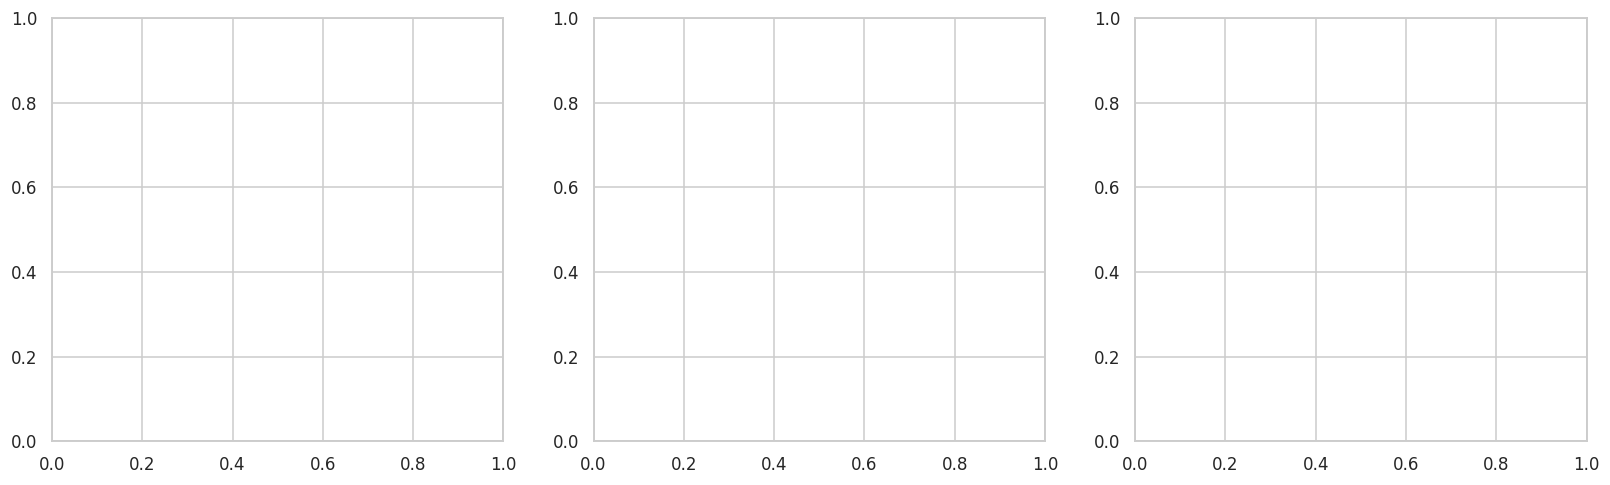

In [143]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)
FIGURE_DIR = Path(config.FIGURES_DIR)

final_prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_final_predictions.csv"
)
metric_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_metrics.csv"
)

assert final_prediction_path.is_file()
assert metric_path.is_file()

final_reg = pd.read_csv(
    final_prediction_path
)
saved_regression_metrics = pd.read_csv(
    metric_path
)

assert len(final_reg) == 100
assert final_reg["engine_id"].nunique() == 100

final_reg["signed_error"] = (
    final_reg["predicted_RUL"]
    - final_reg["RUL"]
)

final_reg["rul_region"] = pd.cut(
    final_reg["RUL"],
    bins=[-np.inf, 30, 60, 100, np.inf],
    labels=[
        "RUL_0_30",
        "RUL_31_60",
        "RUL_61_100",
        "RUL_above_100",
    ],
    ordered=True,
)

assert final_reg["rul_region"].notna().all()


def summarize_region(group):
    error = group["signed_error"].to_numpy(
        dtype=float
    )

    width = (
        group["conformal_upper"]
        - group["conformal_lower"]
    ).to_numpy(dtype=float)

    return pd.Series(
        {
            "n_engines": int(
                group["engine_id"].nunique()
            ),
            "mean_true_RUL": float(
                group["RUL"].mean()
            ),
            "mean_predicted_RUL": float(
                group["predicted_RUL"].mean()
            ),
            "MAE": float(
                np.mean(np.abs(error))
            ),
            "RMSE": float(
                np.sqrt(np.mean(error**2))
            ),
            "mean_signed_error": float(
                error.mean()
            ),
            "conformal_coverage": float(
                group[
                    "covered_by_interval"
                ].astype(bool).mean()
            ),
            "conformal_average_width": float(
                width.mean()
            ),
        }
    )


region_rows = []

for region_name, region_frame in final_reg.groupby(
    "rul_region",
    observed=True,
    sort=True,
):
    region_metrics = summarize_region(
        region_frame
    ).to_dict()

    region_rows.append(
        {
            "rul_region": str(region_name),
            **region_metrics,
        }
    )

region_summary = pd.DataFrame(
    region_rows
)

region_summary["n_engines"] = (
    region_summary["n_engines"]
    .astype(int)
)

primary_metric_row = (
    saved_regression_metrics[
        saved_regression_metrics["scope"]
        == "final_snapshot_primary"
    ]
    .iloc[0]
)

weighted_coverage = float(
    np.average(
        region_summary[
            "conformal_coverage"
        ],
        weights=region_summary[
            "n_engines"
        ],
    )
)

weighted_mae = float(
    np.average(
        region_summary["MAE"],
        weights=region_summary[
            "n_engines"
        ],
    )
)

diagnostic_checks = {
    "region_counts_sum_to_100": (
        int(region_summary["n_engines"].sum())
        == 100
    ),
    "all_regions_nonempty": (
        len(region_summary) == 4
        and region_summary[
            "n_engines"
        ].gt(0).all()
    ),
    "regional_metrics_finite": bool(
        np.isfinite(
            region_summary.select_dtypes(
                include=[np.number]
            ).to_numpy(dtype=float)
        ).all()
    ),
    "weighted_coverage_matches_primary": bool(
        np.isclose(
            weighted_coverage,
            float(
                primary_metric_row[
                    "conformal_coverage"
                ]
            ),
            rtol=1e-12,
            atol=1e-12,
        )
    ),
    "weighted_mae_matches_primary": bool(
        np.isclose(
            weighted_mae,
            float(primary_metric_row["MAE"]),
            rtol=1e-12,
            atol=1e-12,
        )
    ),
}

failed_diagnostic_checks = [
    name
    for name, passed
    in diagnostic_checks.items()
    if not bool(passed)
]

assert not failed_diagnostic_checks, (
    f"Regression diagnostic checks failed: "
    f"{failed_diagnostic_checks}"
)





fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

covered = final_reg[
    "covered_by_interval"
].astype(bool)


In [144]:
axes[0].scatter(
    final_reg.loc[
        covered,
        "RUL",
    ],
    final_reg.loc[
        covered,
        "predicted_RUL",
    ],
    alpha=0.75,
    color="tab:blue",
    label="Interval covered",
)

axes[0].scatter(
    final_reg.loc[
        ~covered,
        "RUL",
    ],
    final_reg.loc[
        ~covered,
        "predicted_RUL",
    ],
    alpha=0.85,
    color="tab:red",
    marker="x",
    label="Interval missed",
)

identity_max = float(
    max(
        final_reg["RUL"].max(),
        final_reg["predicted_RUL"].max(),
    )
)

axes[0].plot(
    [0, identity_max],
    [0, identity_max],
    color="black",
    linestyle="--",
    linewidth=1,
    label="Ideal prediction",
)

axes[0].set_title(
    "Final snapshot: actual vs predicted",
    fontweight="bold",
)
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)


axes[1].scatter(
    final_reg["RUL"],
    final_reg["signed_error"],
    c=np.where(
        covered,
        "tab:blue",
        "tab:red",
    ),
    alpha=0.75,
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].axhline(
    final_reg["signed_error"].mean(),
    color="tab:orange",
    linestyle=":",
    linewidth=1.5,
    label=(
        "Mean bias = "
        f"{final_reg['signed_error'].mean():.2f}"
    ),
)

for boundary in (30, 60, 100):
    axes[1].axvline(
        boundary,
        color="gray",
        linestyle=":",
        linewidth=0.8,
        alpha=0.7,
    )

axes[1].set_title(
    "Signed error by true RUL",
    fontweight="bold",
)
axes[1].set_xlabel("True RUL")
axes[1].set_ylabel(
    "Prediction − truth"
)
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)


bars = axes[2].bar(
    region_summary[
        "rul_region"
    ].astype(str),
    region_summary[
        "conformal_coverage"
    ],
    color=[
        "tab:green"
        if value >= 0.90
        else "tab:orange"
        for value in region_summary[
            "conformal_coverage"
        ]
    ],
)

axes[2].axhline(
    0.90,
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label="Target coverage = 0.90",
)

for bar, coverage_value, n_engines in zip(
    bars,
    region_summary[
        "conformal_coverage"
    ],
    region_summary["n_engines"],
):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        min(
            float(coverage_value) + 0.025,
            1.02,
        ),
        f"{coverage_value:.2f}\nn={int(n_engines)}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

axes[2].set_ylim(0, 1.08)
axes[2].set_title(
    "Conformal coverage by final RUL",
    fontweight="bold",
)
axes[2].set_xlabel("Final-RUL region")
axes[2].set_ylabel("Empirical coverage")
axes[2].tick_params(
    axis="x",
    rotation=25,
)
axes[2].grid(
    axis="y",
    alpha=0.2,
)
axes[2].legend(fontsize=8)

fig.suptitle(
    f"{SUBSET} Official-Test Regression Diagnostics",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(
    rect=(0, 0, 1, 0.95)
)

figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_official_test_regression_diagnostics.png"
)
temporary_figure_path = figure_path.with_name(
    figure_path.stem + ".tmp.png"
)

fig.savefig(
    temporary_figure_path,
    dpi=160,
    bbox_inches="tight",
)
os.replace(
    temporary_figure_path,
    figure_path,
)

plt.show()





region_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_by_rul_region.csv"
)
temporary_region_path = region_path.with_name(
    region_path.stem + ".tmp.csv"
)

region_summary.to_csv(
    temporary_region_path,
    index=False,
)
os.replace(
    temporary_region_path,
    region_path,
)

reloaded_regions = pd.read_csv(
    region_path
)


In [145]:
persistence_checks = {
    "regional_csv_shape_parity": (
        reloaded_regions.shape
        == region_summary.shape
    ),
    "regional_csv_numeric_parity": bool(
        np.allclose(
            reloaded_regions.select_dtypes(
                include=[np.number]
            ),
            region_summary.select_dtypes(
                include=[np.number]
            ),
            rtol=1e-12,
            atol=1e-12,
        )
    ),
    "diagnostic_figure_exists": (
        figure_path.is_file()
        and figure_path.stat().st_size > 0
    ),
}

assert all(persistence_checks.values()), (
    f"Regression diagnostic persistence failed: "
    f"{persistence_checks}"
)

all_diagnostic_checks = {
    **diagnostic_checks,
    **persistence_checks,
}

diagnostic_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_diagnostic_checks.items()
    ]
)

overall_diagnostic_status = (
    "PASS"
    if diagnostic_check_table[
        "passed"
    ].all()
    else "FAIL"
)

print(" COMPUTED REGRESSION DIAGNOSTIC CHECKS ")
display(diagnostic_check_table)

print("\n REGRESSION BY FINAL-RUL REGION ")
display(region_summary.round(6))

print(
    "\nOverall diagnostic status:",
    overall_diagnostic_status,
)
print("Saved regional metrics:", region_path)

 COMPUTED REGRESSION DIAGNOSTIC CHECKS 


,check,passed
0,region_counts_sum_to_100,True
1,all_regions_nonempty,True
2,regional_metrics_finite,True
3,weighted_coverage_matches_primary,True
4,weighted_mae_matches_primary,True
5,regional_csv_shape_parity,True
6,regional_csv_numeric_parity,True
7,diagnostic_figure_exists,True



 REGRESSION BY FINAL-RUL REGION 


,rul_region,n_engines,mean_true_RUL,mean_predicted_RUL,MAE,RMSE,mean_signed_error,conformal_coverage,conformal_average_width
0,RUL_0_30,25,17.720000,19.500129,4.916091,6.266840,1.780129,1.000000,33.010348
1,RUL_31_60,14,49.714286,55.749250,9.600149,11.971160,6.034964,0.857143,36.826786
2,RUL_61_100,28,86.928571,85.286613,8.005103,11.608133,-1.641958,0.892857,36.826786
3,RUL_above_100,33,120.575758,95.560456,25.015301,27.686311,-25.015301,0.363636,36.826786



Overall diagnostic status: PASS
Saved regional metrics: artifacts/results/FD001_official_test_regression_by_rul_region.csv


### Frozen classification inference on FD001 Official Test

Includes a reproducible inference, reload, and persistence parity verification.


In [146]:
import hashlib
import json
import os
import warnings
from pathlib import Path

import joblib
import models_classification as mc
import numpy as np
import pandas as pd


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

RESULT_DIR.mkdir(parents=True, exist_ok=True)


classification_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_classification_bundle.joblib"
)

test_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)

access_record_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.json"
)

required_paths = (
    classification_bundle_path,
    test_contract_path,
    access_record_path,
)

missing_paths = [
    str(path)
    for path in required_paths
    if not path.is_file()
]

assert not missing_paths, (
    f"Required classification files missing: "
    f"{missing_paths}"
)


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


test_contract = json.loads(
    test_contract_path.read_text(
        encoding="utf-8"
    )
)

access_record = json.loads(
    access_record_path.read_text(
        encoding="utf-8"
    )
)

assert (
    access_record["status"]
    == "UNSEALED_FOR_EVALUATION"
)






classification_source_path = Path(
    mc.__file__
)


if (
    classification_source_path.suffix
    == ".pyc"
):
    possible_source_path = (
        classification_source_path
        .with_suffix(".py")
    )

    if possible_source_path.is_file():
        classification_source_path = (
            possible_source_path
        )


source_sha_current = sha256_file(
    classification_source_path
)

compatibility_checks = {
    "classification_source_exists": classification_source_path.is_file(),
    "classification_source_sha256_valid": len(source_sha_current) == 64,
}
assert all(compatibility_checks.values())


In [147]:
"""Historical amendment checks retired.
They are retained only as notebook provenance and are not executed.

amendment_evidence = (
    compatibility_amendment["evidence"]
)

amendment_change_scope = (
    compatibility_amendment["change_scope"]
)

prediction_parity_checks = (
    amendment_evidence[
        "prediction_parity_checks"
    ]
)

recorded_predictions_unchanged = bool(
    amendment_evidence[
        "all_prediction_parity"
    ]
)

recorded_warning_count = int(
    amendment_evidence[
        "feature_name_warning_count"
    ]
)

recorded_warning_evidence = (
    recorded_warning_count == 0
)

all_recorded_prediction_checks_pass = (
    len(prediction_parity_checks) == 12
    and all(
        bool(value)
        for value
        in prediction_parity_checks.values()
    )
)

expected_prediction_parity_keys = {
    f"{stage}_h{horizon}_unchanged"
    for horizon in (10, 20, 30)
    for stage in (
        "raw",
        "platt",
        "mono",
        "dec",
    )
}

change_scope_checks = {
    "amendment_calibration_not_changed": (
        amendment_change_scope[
            "calibration_changed"
        ]
        is False
    ),
    "amendment_feature_values_not_changed": (
        amendment_change_scope[
            "feature_values_changed"
        ]
        is False
    ),
    "amendment_model_parameters_not_changed": (
        amendment_change_scope[
            "model_parameters_changed"
        ]
        is False
    ),
    "amendment_model_weights_not_changed": (
        amendment_change_scope[
            "model_weights_changed"
        ]
        is False
    ),
    "amendment_prediction_values_not_changed": (
        amendment_change_scope[
            "prediction_values_changed"
        ]
        is False
    ),
    "amendment_thresholds_not_changed": (
        amendment_change_scope[
            "thresholds_changed"
        ]
        is False
    ),
    "amendment_only_compatibility_logic_changed": (
        amendment_change_scope[
            "source_compatibility_logic_changed"
        ]
        is True
    ),
}

sha_pattern = re.compile(
    r"^[a-fA-F0-9]{64}$"
)

amendment_checks = {
    "amendment_file_loaded": isinstance(
        compatibility_amendment,
        dict,
    ),
    "amendment_subset_matches": (
        compatibility_amendment[
            "subset"
        ]
        == SUBSET
    ),
    "amendment_before_sha_valid": bool(
        sha_pattern.fullmatch(
            source_sha_before
        )
    ),
    "amendment_after_sha_valid": bool(
        sha_pattern.fullmatch(
            source_sha_after
        )
    ),
    "amendment_source_hash_changed": (
        source_sha_before
        != source_sha_after
    ),
    "current_source_matches_amendment_after": (
        source_sha_current
        == source_sha_after
    ),
    "amendment_records_predictions_unchanged": (
        recorded_predictions_unchanged
    ),
    "amendment_prediction_check_keys_exact": (
        set(prediction_parity_checks)
        == expected_prediction_parity_keys
    ),
    "all_amendment_prediction_checks_pass": (
        all_recorded_prediction_checks_pass
    ),
    "amendment_records_zero_feature_warnings": (
        recorded_warning_evidence
    ),
    **change_scope_checks,
}

failed_amendment_checks = [
    name
    for name, passed
    in amendment_checks.items()
    if not bool(passed)
]

assert not failed_amendment_checks, (
    "Classification compatibility amendment "
    f"failed: {failed_amendment_checks}"
)

"""

expected_bundle_sha = (
    test_contract["frozen_artifacts"]
    ["classification_bundle"]["sha256"]
)

bundle_sha_before = sha256_file(
    classification_bundle_path
)

assert (
    bundle_sha_before
    == expected_bundle_sha
)

classification_bundle = joblib.load(
    classification_bundle_path
)

HORIZONS = tuple(
    int(h)
    for h in classification_bundle["horizons"]
)

assert HORIZONS == (10, 20, 30)


provenance_checks = {
    "bundle_subset_matches": (
        classification_bundle.get("subset")
        == SUBSET
    ),
    "fit_partition_is_train": (
        classification_bundle.get(
            "fit_partition"
        )
        == "train"
    ),
    "selection_partition_is_val_tune": (
        classification_bundle.get(
            "selection_partition"
        )
        == "val_tune"
    ),
    "calibration_partition_is_val_calib": (
        classification_bundle.get(
            "calibration_partition"
        )
        == "val_calib"
    ),
    "threshold_partition_is_val_calib": (
        classification_bundle.get(
            "threshold_partition"
        )
        == "val_calib"
    ),
    "bundle_created_while_test_sealed": (
        str(
            classification_bundle.get(
                "official_test_status",
                "",
            )
        ).lower()
        == "sealed"
    ),
    "threshold_status_is_frozen": (
        classification_bundle.get(
            "threshold_status"
        )
        == "selected_on_val_calib"
    ),
    "monotonicity_rule_is_expected": (
        classification_bundle.get(
            "monotonicity_rule"
        )
        == (
            "cumulative maximum in "
            "horizon order 10,20,30"
        )
    ),
}


In [148]:
expected_test_thresholds = {
    int(horizon): float(value)
    for horizon, value
    in test_contract[
        "classification_evaluation"
    ]["thresholds"].items()
}

bundle_thresholds = {
    int(horizon): float(value)
    for horizon, value
    in classification_bundle[
        "thresholds"
    ].items()
}

provenance_checks[
    "thresholds_match_pretest_contract"
] = all(
    np.isclose(
        bundle_thresholds[horizon],
        expected_test_thresholds[horizon],
        rtol=0.0,
        atol=0.0,
    )
    for horizon in HORIZONS
)

failed_provenance_checks = [
    name
    for name, passed
    in provenance_checks.items()
    if not bool(passed)
]

assert not failed_provenance_checks, (
    f"Classification provenance failed: "
    f"{failed_provenance_checks}"
)






df_test_classification = (
    df_test_official.copy()
)

for horizon in HORIZONS:
    df_test_classification[
        f"label_h{horizon}"
    ] = (
        df_test_classification["RUL"]
        <= horizon
    ).astype(int)


label_checks = {
    "label_h10_binary": (
        df_test_classification[
            "label_h10"
        ].isin([0, 1]).all()
    ),
    "label_h20_binary": (
        df_test_classification[
            "label_h20"
        ].isin([0, 1]).all()
    ),
    "label_h30_binary": (
        df_test_classification[
            "label_h30"
        ].isin([0, 1]).all()
    ),
    "labels_nested_h10_h20": bool(
        np.all(
            df_test_classification[
                "label_h10"
            ].to_numpy()
            <= df_test_classification[
                "label_h20"
            ].to_numpy()
        )
    ),
    "labels_nested_h20_h30": bool(
        np.all(
            df_test_classification[
                "label_h20"
            ].to_numpy()
            <= df_test_classification[
                "label_h30"
            ].to_numpy()
        )
    ),
}

assert all(label_checks.values()), (
    f"Classification label checks failed: "
    f"{label_checks}"
)






def make_runtime_bundles(
    persisted_bundle,
):
    runtime = {}

    for horizon in HORIZONS:
        entry = persisted_bundle[
            "classifiers"
        ][str(horizon)]

        runtime[horizon] = {
            "clf": entry["model"],
            "fp": entry["feature_pipeline"],
            "platt": entry["calibrator"],
            "scaled": bool(
                entry["uses_scaled_features"]
            ),
        }

    return runtime


runtime_bundles = make_runtime_bundles(
    classification_bundle
)






feature_schema_checks = {}
feature_summary_rows = []

for horizon in HORIZONS:
    runtime_entry = runtime_bundles[
        horizon
    ]

    transformed = runtime_entry[
        "fp"
    ].transform(
        df_test_classification,
        scaled=runtime_entry["scaled"],
    )

    X_horizon = transformed[0]
    model = runtime_entry["clf"]

    expected_feature_count = int(
        model.n_features_in_
    )

    count_matches = (
        X_horizon.shape[1]
        == expected_feature_count
    )

    feature_schema_checks[
        f"h{horizon}_feature_count_matches"
    ] = count_matches

    if hasattr(
        model,
        "feature_names_in_",
    ):
        names_match = (
            list(X_horizon.columns)
            == list(model.feature_names_in_)
        )

        feature_schema_checks[
            f"h{horizon}_feature_names_match"
        ] = names_match
    else:
        names_match = None

    feature_summary_rows.append(
        {
            "horizon": horizon,
            "n_rows": int(
                X_horizon.shape[0]
            ),
            "n_features": int(
                X_horizon.shape[1]
            ),
            "scaled": bool(
                runtime_entry["scaled"]
            ),
            "model_has_feature_names": bool(
                hasattr(
                    model,
                    "feature_names_in_",
                )
            ),
            "feature_names_match": (
                names_match
            ),
        }
    )


feature_summary = pd.DataFrame(
    feature_summary_rows
)

assert all(
    bool(value)
    for value
    in feature_schema_checks.values()
), (
    f"Classification feature schema failed: "
    f"{feature_schema_checks}"
)


In [149]:
with warnings.catch_warnings(
    record=True
) as initial_warning_records:
    warnings.simplefilter("always")

    classification_test_predictions = (
        mc.evaluate_dataframe(
            runtime_bundles,
            df_test_classification,
            bundle_thresholds,
        )
    )


initial_feature_name_warnings = [
    warning_record
    for warning_record
    in initial_warning_records
    if "feature names" in str(
        warning_record.message
    ).lower()
]

initial_feature_warning_count = len(
    initial_feature_name_warnings
)


classification_test_predictions.insert(
    2,
    "RUL",
    df_test_classification[
        "RUL"
    ].to_numpy(dtype=float),
)

final_indices = (
    classification_test_predictions
    .groupby("engine_id")["cycle"]
    .idxmax()
)

classification_test_final = (
    classification_test_predictions
    .loc[final_indices]
    .sort_values("engine_id")
    .reset_index(drop=True)
)






inference_checks = {
    **compatibility_checks,
    **provenance_checks,
    **label_checks,
    **feature_schema_checks,
    "initial_feature_name_warning_count_zero": (
        initial_feature_warning_count == 0
    ),
    "prediction_row_count_matches": (
        len(classification_test_predictions)
        == len(df_test_classification)
    ),
    "prediction_index_alignment": (
        classification_test_predictions.index.equals(
            df_test_classification.index
        )
    ),
    "exactly_100_final_snapshots": (
        len(classification_test_final)
        == test_contract[
            "expected_test_engines"
        ]
    ),
}


for stage in (
    "raw",
    "platt",
    "mono",
):
    stage_columns = [
        f"{stage}_h{horizon}"
        for horizon in HORIZONS
    ]

    stage_values = (
        classification_test_predictions[
            stage_columns
        ].to_numpy(dtype=float)
    )

    inference_checks[
        f"{stage}_probabilities_finite"
    ] = bool(
        np.isfinite(stage_values).all()
    )

    inference_checks[
        f"{stage}_probabilities_in_unit_interval"
    ] = bool(
        np.all(
            (stage_values >= 0.0)
            & (stage_values <= 1.0)
        )
    )


mono_values = (
    classification_test_predictions[
        [
            "mono_h10",
            "mono_h20",
            "mono_h30",
        ]
    ].to_numpy(dtype=float)
)

inference_checks[
    "monotone_h10_le_h20"
] = bool(
    np.all(
        mono_values[:, 0]
        <= mono_values[:, 1]
    )
)

inference_checks[
    "monotone_h20_le_h30"
] = bool(
    np.all(
        mono_values[:, 1]
        <= mono_values[:, 2]
    )
)


for horizon in HORIZONS:
    expected_decision = (
        classification_test_predictions[
            f"mono_h{horizon}"
        ].to_numpy(dtype=float)
        >= bundle_thresholds[horizon]
    ).astype(int)

    actual_decision = (
        classification_test_predictions[
            f"dec_h{horizon}"
        ].to_numpy(dtype=int)
    )

    inference_checks[
        f"h{horizon}_decision_threshold_parity"
    ] = np.array_equal(
        actual_decision,
        expected_decision,
    )


failed_inference_checks = [
    name
    for name, passed
    in inference_checks.items()
    if not bool(passed)
]

assert not failed_inference_checks, (
    f"Classification inference checks failed: "
    f"{failed_inference_checks}"
)






reloaded_classification_bundle = (
    joblib.load(
        classification_bundle_path
    )
)

reloaded_runtime_bundles = (
    make_runtime_bundles(
        reloaded_classification_bundle
    )
)

with warnings.catch_warnings(
    record=True
) as reload_warning_records:
    warnings.simplefilter("always")

    reloaded_test_predictions = (
        mc.evaluate_dataframe(
            reloaded_runtime_bundles,
            df_test_classification,
            bundle_thresholds,
        )
    )


reload_feature_name_warnings = [
    warning_record
    for warning_record
    in reload_warning_records
    if "feature names" in str(
        warning_record.message
    ).lower()
]

reload_feature_warning_count = len(
    reload_feature_name_warnings
)


In [150]:
reload_parity_checks = {
    "reload_feature_name_warning_count_zero": (
        reload_feature_warning_count == 0
    ),
}

for horizon in HORIZONS:
    for stage in (
        "raw",
        "platt",
        "mono",
    ):
        column = f"{stage}_h{horizon}"

        reload_parity_checks[
            f"{column}_reload_parity"
        ] = bool(
            np.allclose(
                classification_test_predictions[
                    column
                ],
                reloaded_test_predictions[
                    column
                ],
                rtol=0.0,
                atol=1e-12,
            )
        )

    decision_column = (
        f"dec_h{horizon}"
    )

    reload_parity_checks[
        f"{decision_column}_reload_parity"
    ] = np.array_equal(
        classification_test_predictions[
            decision_column
        ].to_numpy(dtype=int),
        reloaded_test_predictions[
            decision_column
        ].to_numpy(dtype=int),
    )


assert all(
    reload_parity_checks.values()
), (
    f"Classification reload parity failed: "
    f"{reload_parity_checks}"
)






bundle_sha_after = sha256_file(
    classification_bundle_path
)

source_sha_after_inference = sha256_file(
    classification_source_path
)

artifact_checks = {
    "classification_bundle_unchanged": (
        bundle_sha_after
        == bundle_sha_before
    ),
    "classification_source_unchanged_during_inference": (
        source_sha_after_inference
        == source_sha_current
    ),
}

assert all(artifact_checks.values()), (
    f"Classification artifact integrity failed: "
    f"{artifact_checks}"
)






row_prediction_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_predictions.csv"
    )
)

final_prediction_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_final_predictions.csv"
    )
)

temporary_row_path = (
    row_prediction_path.with_name(
        row_prediction_path.stem
        + ".tmp.csv"
    )
)

temporary_final_path = (
    final_prediction_path.with_name(
        final_prediction_path.stem
        + ".tmp.csv"
    )
)


classification_test_predictions.to_csv(
    temporary_row_path,
    index=False,
)

classification_test_final.to_csv(
    temporary_final_path,
    index=False,
)

os.replace(
    temporary_row_path,
    row_prediction_path,
)

os.replace(
    temporary_final_path,
    final_prediction_path,
)


reloaded_row_csv = pd.read_csv(
    row_prediction_path
)

reloaded_final_csv = pd.read_csv(
    final_prediction_path
)


persistence_checks = {
    "row_csv_shape_parity": (
        reloaded_row_csv.shape
        == classification_test_predictions.shape
    ),
    "final_csv_shape_parity": (
        reloaded_final_csv.shape
        == classification_test_final.shape
    ),
}


for horizon in HORIZONS:
    for stage in (
        "raw",
        "platt",
        "mono",
    ):
        row_column = (
            f"{stage}_h{horizon}"
        )

        persistence_checks[
            f"h{horizon}_{stage}_row_csv_parity"
        ] = bool(
            np.allclose(
                reloaded_row_csv[
                    row_column
                ],
                classification_test_predictions[
                    row_column
                ],
                rtol=0.0,
                atol=1e-12,
            )
        )

        persistence_checks[
            f"h{horizon}_{stage}_final_csv_parity"
        ] = bool(
            np.allclose(
                reloaded_final_csv[
                    row_column
                ],
                classification_test_final[
                    row_column
                ],
                rtol=0.0,
                atol=1e-12,
            )
        )

    decision_column = (
        f"dec_h{horizon}"
    )

    persistence_checks[
        f"h{horizon}_row_decision_csv_parity"
    ] = np.array_equal(
        reloaded_row_csv[
            decision_column
        ].to_numpy(dtype=int),
        classification_test_predictions[
            decision_column
        ].to_numpy(dtype=int),
    )

    persistence_checks[
        f"h{horizon}_final_decision_csv_parity"
    ] = np.array_equal(
        reloaded_final_csv[
            decision_column
        ].to_numpy(dtype=int),
        classification_test_final[
            decision_column
        ].to_numpy(dtype=int),
    )


In [151]:
assert all(persistence_checks.values()), (
    f"Classification CSV parity failed: "
    f"{persistence_checks}"
)






all_checks = {
    **inference_checks,
    **reload_parity_checks,
    **artifact_checks,
    **persistence_checks,
}

classification_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_checks.items()
    ]
)

failed_checks = (
    classification_check_table.loc[
        ~classification_check_table[
            "passed"
        ],
        "check",
    ].tolist()
)

assert not failed_checks, (
    f"Final classification checks failed: "
    f"{failed_checks}"
)

overall_status = (
    "PASS"
    if (
        len(classification_check_table) > 0
        and classification_check_table[
            "passed"
        ].all()
    )
    else "FAIL"
)


compatibility_report_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_compatibility_report.json"
)
compatibility_report = {
    "schema_version": 1,
    "artifact_type": "classification_runtime_compatibility_report",
    "subset": SUBSET,
    "source_path": str(classification_source_path),
    "source_sha256": source_sha_current,
    "bundle_sha256": bundle_sha_after,
    "checks": {name: bool(value) for name, value in all_checks.items()},
    "status": overall_status,
}
temporary_report_path = Path(str(compatibility_report_path) + ".tmp")
temporary_report_path.write_text(
    json.dumps(compatibility_report, indent=2, sort_keys=True),
    encoding="utf-8",
)
os.replace(temporary_report_path, compatibility_report_path)


print(
    " CLASSIFICATION RUNTIME COMPATIBILITY "
)
print(
    "Source:",
    classification_source_path,
)
print(
    "Current source SHA256:",
    source_sha_current,
)
print("Compatibility report:", compatibility_report_path)
print(
    "Initial feature-name warnings:",
    initial_feature_warning_count,
)
print(
    "Reload feature-name warnings:",
    reload_feature_warning_count,
)

print(
    "\n CLASSIFICATION FEATURE SUMMARY "
)
display(feature_summary)

print(
    "\n COMPUTED CLASSIFICATION "
    "INFERENCE CHECKS "
)
display(classification_check_table)

print(
    "\n OFFICIAL TEST "
    "CLASSIFICATION INFERENCE "
)
print(
    "Rows:",
    len(classification_test_predictions),
)
print(
    "Final snapshots:",
    len(classification_test_final),
)
print(
    "Thresholds:",
    bundle_thresholds,
)
print(
    "Executed checks:",
    len(classification_check_table),
)
print(
    "Failed checks:",
    len(failed_checks),
)
print(
    "Overall inference status:",
    overall_status,
)
print(
    "Saved row predictions:",
    row_prediction_path,
)
print(
    "Saved final predictions:",
    final_prediction_path,
)


 CLASSIFICATION RUNTIME COMPATIBILITY 
Source: ./src/models_classification.py
Current source SHA256: 60358ebdee3183baea38d059d20efdd5946060da68144236fd5ba845e0deb7ad
Compatibility report: data/processed/FD001_classification_compatibility_report.json
Initial feature-name warnings: 0
Reload feature-name warnings: 0

 CLASSIFICATION FEATURE SUMMARY 


,horizon,n_rows,n_features,scaled,model_has_feature_names,feature_names_match
0,10,13096,123,True,False,None
1,20,13096,121,True,False,None
2,30,13096,123,True,False,None



 COMPUTED CLASSIFICATION INFERENCE CHECKS 


,check,passed
0,classification_source_exists,True
1,classification_source_sha256_valid,True
2,bundle_subset_matches,True
3,fit_partition_is_train,True
4,selection_partition_is_val_tune,True
...,...,...
70,h30_platt_final_csv_parity,True
71,h30_mono_row_csv_parity,True
72,h30_mono_final_csv_parity,True
73,h30_row_decision_csv_parity,True



 OFFICIAL TEST CLASSIFICATION INFERENCE 
Rows: 13096
Final snapshots: 100
Thresholds: {10: 0.11340399728926802, 20: 0.22290462955112206, 30: 0.11654045954796569}
Executed checks: 75
Failed checks: 0
Overall inference status: PASS
Saved row predictions: artifacts/results/FD001_official_test_classification_predictions.csv
Saved final predictions: artifacts/results/FD001_official_test_classification_final_predictions.csv


### Official-Test classification point metrics

No calibration, threshold optimization, or model fitting occurs here.


In [152]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)

classification_metric_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_metrics.csv"
    )
)




classification_scopes = {
    "all_observed_rows_primary": (
        classification_test_predictions,
        "PRIMARY_ROW_LEVEL_OFFICIAL_TEST",
    ),
    "final_snapshot_secondary": (
        classification_test_final,
        "SECONDARY_FINAL_SNAPSHOT",
    ),
}


def evaluate_classification_scope(
    frame,
    scope,
    role,
    horizon,
):
    y_true = frame[
        f"y_h{horizon}"
    ].to_numpy(dtype=int)

    probability = frame[
        f"mono_h{horizon}"
    ].to_numpy(dtype=float)

    decision = frame[
        f"dec_h{horizon}"
    ].to_numpy(dtype=int)

    raw_probability = frame[
        f"raw_h{horizon}"
    ].to_numpy(dtype=float)

    platt_probability = frame[
        f"platt_h{horizon}"
    ].to_numpy(dtype=float)

    assert len(y_true) > 0
    assert len(y_true) == len(probability)
    assert np.isfinite(probability).all()
    assert np.isfinite(raw_probability).all()
    assert np.isfinite(
        platt_probability
    ).all()

    unique_classes = np.unique(y_true)
    both_classes_present = (
        set(unique_classes.tolist())
        == {0, 1}
    )

    if both_classes_present:
        pr_auc = float(
            average_precision_score(
                y_true,
                probability,
            )
        )
    else:
        pr_auc = np.nan

    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            decision,
            labels=[0, 1],
        ).ravel()
    )

    expected_decision = (
        probability
        >= bundle_thresholds[horizon]
    ).astype(int)

    assert np.array_equal(
        decision,
        expected_decision,
    )

    false_negative_cost = (
        10.0 * float(fn)
    )
    false_positive_cost = (
        1.0 * float(fp)
    )
    total_cost = (
        false_negative_cost
        + false_positive_cost
    )

    return {
        "scope": scope,
        "role": role,
        "horizon": int(horizon),
        "n_rows": int(len(frame)),
        "n_engines": int(
            frame["engine_id"].nunique()
        ),
        "n_positive": int(y_true.sum()),
        "n_negative": int(
            len(y_true) - y_true.sum()
        ),
        "prevalence": float(
            y_true.mean()
        ),
        "both_classes_present": bool(
            both_classes_present
        ),
        "probability_stage": (
            "platt_plus_monotonicity"
        ),
        "threshold_policy": "FN10_FP1",
        "threshold": float(
            bundle_thresholds[horizon]
        ),
        "PR_AUC": pr_auc,
        "Brier_raw": float(
            brier_score_loss(
                y_true,
                raw_probability,
            )
        ),
        "Brier_platt": float(
            brier_score_loss(
                y_true,
                platt_probability,
            )
        ),
        "Brier_platt_monotone": float(
            brier_score_loss(
                y_true,
                probability,
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                decision,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                decision,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                decision,
                zero_division=0,
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_negative_cost": (
            false_negative_cost
        ),
        "false_positive_cost": (
            false_positive_cost
        ),
        "total_cost": float(
            total_cost
        ),
        "cost_per_row": float(
            total_cost / len(frame)
        ),
        "predicted_positive_fraction": (
            float(decision.mean())
        ),
    }


metric_rows = []

for scope, (
    frame,
    role,
) in classification_scopes.items():
    for horizon in HORIZONS:
        metric_rows.append(
            evaluate_classification_scope(
                frame=frame,
                scope=scope,
                role=role,
                horizon=horizon,
            )
        )


In [153]:
classification_test_metrics = (
    pd.DataFrame(metric_rows)
)

expected_scope_order = [
    "all_observed_rows_primary",
    "final_snapshot_secondary",
]

expected_metric_keys = [
    (scope, horizon)
    for scope in expected_scope_order
    for horizon in HORIZONS
]


metric_checks = {
    "exactly_six_metric_rows": (
        len(classification_test_metrics)
        == 6
    ),
    "scope_horizon_keys_exact": (
        list(
            zip(
                classification_test_metrics[
                    "scope"
                ],
                classification_test_metrics[
                    "horizon"
                ],
            )
        )
        == expected_metric_keys
    ),
    "all_confusion_counts_sum_to_scope_rows": bool(
        np.all(
            classification_test_metrics[
                ["tn", "fp", "fn", "tp"]
            ].sum(axis=1).to_numpy()
            == classification_test_metrics[
                "n_rows"
            ].to_numpy()
        )
    ),
    "all_prevalences_in_unit_interval": bool(
        classification_test_metrics[
            "prevalence"
        ].between(0.0, 1.0).all()
    ),
    "all_brier_scores_in_unit_interval": bool(
        classification_test_metrics[
            [
                "Brier_raw",
                "Brier_platt",
                "Brier_platt_monotone",
            ]
        ].apply(
            lambda column: column.between(
                0.0,
                1.0,
            )
        ).all().all()
    ),
    "all_threshold_metrics_in_unit_interval": bool(
        classification_test_metrics[
            [
                "precision",
                "recall",
                "f1",
                "predicted_positive_fraction",
            ]
        ].apply(
            lambda column: column.between(
                0.0,
                1.0,
            )
        ).all().all()
    ),
    "all_costs_nonnegative": bool(
        (
            classification_test_metrics[
                [
                    "false_negative_cost",
                    "false_positive_cost",
                    "total_cost",
                    "cost_per_row",
                ]
            ]
            >= 0.0
        ).all().all()
    ),
    "cost_decomposition_exact": bool(
        np.allclose(
            classification_test_metrics[
                "total_cost"
            ],
            (
                classification_test_metrics[
                    "false_negative_cost"
                ]
                + classification_test_metrics[
                    "false_positive_cost"
                ]
            ),
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "primary_scope_has_13096_rows": bool(
        (
            classification_test_metrics.loc[
                classification_test_metrics[
                    "scope"
                ]
                == "all_observed_rows_primary",
                "n_rows",
            ]
            == 13096
        ).all()
    ),
    "final_scope_has_100_rows": bool(
        (
            classification_test_metrics.loc[
                classification_test_metrics[
                    "scope"
                ]
                == "final_snapshot_secondary",
                "n_rows",
            ]
            == 100
        ).all()
    ),
    "all_scopes_have_100_engines": bool(
        (
            classification_test_metrics[
                "n_engines"
            ]
            == 100
        ).all()
    ),
}

failed_metric_checks = [
    name
    for name, passed
    in metric_checks.items()
    if not bool(passed)
]

assert not failed_metric_checks, (
    "Classification metric checks failed: "
    f"{failed_metric_checks}"
)


temporary_metric_path = (
    classification_metric_path.with_name(
        classification_metric_path.stem
        + ".tmp.csv"
    )
)

classification_test_metrics.to_csv(
    temporary_metric_path,
    index=False,
)

os.replace(
    temporary_metric_path,
    classification_metric_path,
)


reloaded_classification_metrics = (
    pd.read_csv(
        classification_metric_path
    )
)

numeric_metric_columns = (
    classification_test_metrics
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

persistence_checks = {
    "saved_metric_shape_parity": (
        reloaded_classification_metrics.shape
        == classification_test_metrics.shape
    ),
    "saved_scope_order_parity": (
        reloaded_classification_metrics[
            "scope"
        ].tolist()
        == classification_test_metrics[
            "scope"
        ].tolist()
    ),
    "saved_horizon_order_parity": (
        reloaded_classification_metrics[
            "horizon"
        ].tolist()
        == classification_test_metrics[
            "horizon"
        ].tolist()
    ),
    "saved_numeric_parity": bool(
        np.allclose(
            reloaded_classification_metrics[
                numeric_metric_columns
            ].to_numpy(dtype=float),
            classification_test_metrics[
                numeric_metric_columns
            ].to_numpy(dtype=float),
            rtol=0.0,
            atol=1e-12,
            equal_nan=True,
        )
    ),
}


In [154]:
assert all(persistence_checks.values()), (
    "Classification metric persistence "
    f"failed: {persistence_checks}"
)


all_metric_checks = {
    **metric_checks,
    **persistence_checks,
}

classification_metric_check_table = (
    pd.DataFrame(
        [
            {
                "check": name,
                "passed": bool(passed),
            }
            for name, passed
            in all_metric_checks.items()
        ]
    )
)

failed_checks = (
    classification_metric_check_table.loc[
        ~classification_metric_check_table[
            "passed"
        ],
        "check",
    ].tolist()
)

assert not failed_checks


print(
    " COMPUTED CLASSIFICATION "
    "METRIC CHECKS "
)
display(
    classification_metric_check_table
)

print(
    "\n OFFICIAL TEST "
    "CLASSIFICATION RESULTS "
)
display(
    classification_test_metrics[
        [
            "scope",
            "horizon",
            "n_rows",
            "n_positive",
            "prevalence",
            "PR_AUC",
            "Brier_platt_monotone",
            "threshold",
            "precision",
            "recall",
            "f1",
            "tn",
            "fp",
            "fn",
            "tp",
            "total_cost",
            "cost_per_row",
        ]
    ]
)

undefined_ap_rows = int(
    classification_test_metrics[
        "PR_AUC"
    ].isna().sum()
)

print(
    "Undefined PR-AUC rows:",
    undefined_ap_rows,
)
print(
    "Failed checks:",
    len(failed_checks),
)
print(
    "Saved metrics:",
    classification_metric_path,
)


 COMPUTED CLASSIFICATION METRIC CHECKS 


,check,passed
0,exactly_six_metric_rows,True
1,scope_horizon_keys_exact,True
2,all_confusion_counts_sum_to_scope_rows,True
3,all_prevalences_in_unit_interval,True
4,all_brier_scores_in_unit_interval,True
5,all_threshold_metrics_in_unit_interval,True
6,all_costs_nonnegative,True
7,cost_decomposition_exact,True
8,primary_scope_has_13096_rows,True
9,final_scope_has_100_rows,True



 OFFICIAL TEST CLASSIFICATION RESULTS 


,scope,horizon,n_rows,n_positive,prevalence,PR_AUC,Brier_platt_monotone,threshold,precision,recall,f1,tn,fp,fn,tp,total_cost,cost_per_row
0,all_observed_rows_primary,10,13096,17,0.001298,0.879869,0.000465,0.113404,0.695652,0.941176,0.800000,13072,7,1,16,17.0,0.001298
1,all_observed_rows_primary,20,13096,123,0.009392,0.729678,0.003308,0.222905,0.678571,0.926829,0.783505,12919,54,9,114,144.0,0.010996
2,all_observed_rows_primary,30,13096,332,0.025351,0.806766,0.007303,0.116540,0.689655,0.963855,0.804020,12620,144,12,320,264.0,0.020159
3,final_snapshot_secondary,10,100,7,0.070000,0.982143,0.018381,0.113404,0.875000,1.000000,0.933333,92,1,0,7,1.0,0.010000
4,final_snapshot_secondary,20,100,16,0.160000,0.961838,0.019206,0.222905,0.941176,1.000000,0.969697,83,1,0,16,1.0,0.010000
5,final_snapshot_secondary,30,100,25,0.250000,0.995195,0.020880,0.116540,0.892857,1.000000,0.943396,72,3,0,25,3.0,0.030000


Undefined PR-AUC rows: 0
Failed checks: 0
Saved metrics: artifacts/results/FD001_official_test_classification_metrics.csv


### Official-Test classification engine-bootstrap 95% CI

Resampling unit: complete Test engines.
Frozen probabilities and decisions are reused without refitting.


In [155]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
)


BOOTSTRAP_DRAWS = 1000
BOOTSTRAP_SEED = 42

RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)

bootstrap_draw_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_bootstrap_draws.csv"
    )
)

bootstrap_summary_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_bootstrap_ci.csv"
    )
)


scope_frames = {
    "all_observed_rows_primary": (
        classification_test_predictions
    ),
    "final_snapshot_secondary": (
        classification_test_final
    ),
}

test_engine_ids = np.sort(
    classification_test_predictions[
        "engine_id"
    ].unique()
)

assert len(test_engine_ids) == 100


def safe_threshold_metrics(
    y_true,
    decision,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )
    decision = np.asarray(
        decision,
        dtype=int,
    )

    tp = int(
        np.sum(
            (y_true == 1)
            & (decision == 1)
        )
    )
    fp = int(
        np.sum(
            (y_true == 0)
            & (decision == 1)
        )
    )
    fn = int(
        np.sum(
            (y_true == 1)
            & (decision == 0)
        )
    )
    tn = int(
        np.sum(
            (y_true == 0)
            & (decision == 0)
        )
    )

    precision_denominator = tp + fp
    recall_denominator = tp + fn
    f1_denominator = (
        2 * tp + fp + fn
    )

    precision = (
        tp / precision_denominator
        if precision_denominator > 0
        else np.nan
    )

    recall = (
        tp / recall_denominator
        if recall_denominator > 0
        else np.nan
    )

    f1 = (
        2 * tp / f1_denominator
        if f1_denominator > 0
        else np.nan
    )

    total_cost = (
        10.0 * fn
        + 1.0 * fp
    )

    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "total_cost": float(
            total_cost
        ),
        "cost_per_row": float(
            total_cost / len(y_true)
        ),
    }


positions_by_scope_engine = {}

for scope, frame in scope_frames.items():
    engine_array = frame[
        "engine_id"
    ].to_numpy(dtype=int)

    positions_by_scope_engine[scope] = {
        int(engine_id): np.flatnonzero(
            engine_array == engine_id
        )
        for engine_id in test_engine_ids
    }

    assert all(
        len(positions) > 0
        for positions
        in positions_by_scope_engine[
            scope
        ].values()
    )


rng = np.random.RandomState(
    BOOTSTRAP_SEED
)

shared_engine_draws = [
    rng.choice(
        test_engine_ids,
        size=len(test_engine_ids),
        replace=True,
    )
    for _ in range(
        BOOTSTRAP_DRAWS
    )
]

assert len(shared_engine_draws) == 1000
assert all(
    len(draw) == 100
    for draw in shared_engine_draws
)


bootstrap_rows = []

for draw_id, drawn_engines in enumerate(
    shared_engine_draws
):
    for scope, frame in scope_frames.items():
        row_positions = np.concatenate(
            [
                positions_by_scope_engine[
                    scope
                ][int(engine_id)]
                for engine_id
                in drawn_engines
            ]
        )

        sampled = frame.iloc[
            row_positions
        ]

        for horizon in HORIZONS:
            y_true = sampled[
                f"y_h{horizon}"
            ].to_numpy(dtype=int)

            probability = sampled[
                f"mono_h{horizon}"
            ].to_numpy(dtype=float)

            decision = sampled[
                f"dec_h{horizon}"
            ].to_numpy(dtype=int)

            both_classes_present = (
                y_true.min() == 0
                and y_true.max() == 1
            )

            pr_auc = (
                float(
                    average_precision_score(
                        y_true,
                        probability,
                    )
                )
                if both_classes_present
                else np.nan
            )

            threshold_metrics = (
                safe_threshold_metrics(
                    y_true,
                    decision,
                )
            )

            bootstrap_rows.append(
                {
                    "draw_id": int(
                        draw_id
                    ),
                    "scope": scope,
                    "horizon": int(
                        horizon
                    ),
                    "sampled_engines": int(
                        len(drawn_engines)
                    ),
                    "unique_sampled_engines": int(
                        np.unique(
                            drawn_engines
                        ).size
                    ),
                    "sampled_rows": int(
                        len(sampled)
                    ),
                    "n_positive": int(
                        y_true.sum()
                    ),
                    "n_negative": int(
                        len(y_true)
                        - y_true.sum()
                    ),
                    "PR_AUC": pr_auc,
                    "Brier_platt_monotone": float(
                        brier_score_loss(
                            y_true,
                            probability,
                        )
                    ),
                    **threshold_metrics,
                }
            )


In [156]:
classification_bootstrap_draws = (
    pd.DataFrame(bootstrap_rows)
)

expected_draw_rows = (
    BOOTSTRAP_DRAWS
    * len(scope_frames)
    * len(HORIZONS)
)

assert (
    len(classification_bootstrap_draws)
    == expected_draw_rows
)


BOOTSTRAP_METRICS = (
    "PR_AUC",
    "Brier_platt_monotone",
    "precision",
    "recall",
    "f1",
    "cost_per_row",
)

summary_rows = []

for scope in scope_frames:
    for horizon in HORIZONS:
        point_row = (
            classification_test_metrics.loc[
                (
                    classification_test_metrics[
                        "scope"
                    ]
                    == scope
                )
                & (
                    classification_test_metrics[
                        "horizon"
                    ]
                    == horizon
                )
            ]
        )

        assert len(point_row) == 1

        draw_subset = (
            classification_bootstrap_draws.loc[
                (
                    classification_bootstrap_draws[
                        "scope"
                    ]
                    == scope
                )
                & (
                    classification_bootstrap_draws[
                        "horizon"
                    ]
                    == horizon
                )
            ]
        )

        assert (
            len(draw_subset)
            == BOOTSTRAP_DRAWS
        )

        for metric in BOOTSTRAP_METRICS:
            values = draw_subset[
                metric
            ].to_numpy(dtype=float)

            valid_values = values[
                np.isfinite(values)
            ]

            invalid_draws = int(
                len(values)
                - len(valid_values)
            )

            assert len(valid_values) > 0

            summary_rows.append(
                {
                    "evaluation_scope": scope,
                    "resampling_unit": (
                        "engine_id"
                    ),
                    "horizon": int(
                        horizon
                    ),
                    "metric": metric,
                    "point_estimate": float(
                        point_row.iloc[0][
                            metric
                        ]
                    ),
                    "bootstrap_mean": float(
                        np.mean(valid_values)
                    ),
                    "ci_95_lower": float(
                        np.percentile(
                            valid_values,
                            2.5,
                        )
                    ),
                    "ci_95_upper": float(
                        np.percentile(
                            valid_values,
                            97.5,
                        )
                    ),
                    "valid_draws": int(
                        len(valid_values)
                    ),
                    "invalid_draws": (
                        invalid_draws
                    ),
                }
            )


classification_bootstrap_summary = (
    pd.DataFrame(summary_rows)
)


bootstrap_checks = {
    "requested_draw_count": (
        classification_bootstrap_draws[
            "draw_id"
        ].nunique()
        == BOOTSTRAP_DRAWS
    ),
    "expected_draw_table_size": (
        len(classification_bootstrap_draws)
        == expected_draw_rows
    ),
    "every_draw_samples_100_engines": bool(
        (
            classification_bootstrap_draws[
                "sampled_engines"
            ]
            == 100
        ).all()
    ),
    "all_unique_engine_counts_valid": bool(
        classification_bootstrap_draws[
            "unique_sampled_engines"
        ].between(1, 100).all()
    ),
    "all_sampled_row_counts_positive": bool(
        (
            classification_bootstrap_draws[
                "sampled_rows"
            ]
            > 0
        ).all()
    ),
    "all_brier_draws_finite": bool(
        np.isfinite(
            classification_bootstrap_draws[
                "Brier_platt_monotone"
            ]
        ).all()
    ),
    "summary_has_36_rows": (
        len(
            classification_bootstrap_summary
        )
        == (
            len(scope_frames)
            * len(HORIZONS)
            * len(BOOTSTRAP_METRICS)
        )
    ),
    "all_intervals_ordered": bool(
        np.all(
            classification_bootstrap_summary[
                "ci_95_lower"
            ]
            <= classification_bootstrap_summary[
                "ci_95_upper"
            ]
        )
    ),
    "valid_plus_invalid_equals_1000": bool(
        np.all(
            (
                classification_bootstrap_summary[
                    "valid_draws"
                ]
                + classification_bootstrap_summary[
                    "invalid_draws"
                ]
            )
            == BOOTSTRAP_DRAWS
        )
    ),
}

failed_bootstrap_checks = [
    name
    for name, passed
    in bootstrap_checks.items()
    if not bool(passed)
]

assert not failed_bootstrap_checks, (
    "Classification bootstrap checks failed: "
    f"{failed_bootstrap_checks}"
)


temporary_draw_path = (
    bootstrap_draw_path.with_name(
        bootstrap_draw_path.stem
        + ".tmp.csv"
    )
)


In [157]:
temporary_summary_path = (
    bootstrap_summary_path.with_name(
        bootstrap_summary_path.stem
        + ".tmp.csv"
    )
)

classification_bootstrap_draws.to_csv(
    temporary_draw_path,
    index=False,
)

classification_bootstrap_summary.to_csv(
    temporary_summary_path,
    index=False,
)

os.replace(
    temporary_draw_path,
    bootstrap_draw_path,
)

os.replace(
    temporary_summary_path,
    bootstrap_summary_path,
)


reloaded_draws = pd.read_csv(
    bootstrap_draw_path
)

reloaded_summary = pd.read_csv(
    bootstrap_summary_path
)

persistence_checks = {
    "saved_draw_shape_parity": (
        reloaded_draws.shape
        == classification_bootstrap_draws.shape
    ),
    "saved_summary_shape_parity": (
        reloaded_summary.shape
        == classification_bootstrap_summary.shape
    ),
    "saved_summary_numeric_parity": bool(
        np.allclose(
            reloaded_summary[
                [
                    "point_estimate",
                    "bootstrap_mean",
                    "ci_95_lower",
                    "ci_95_upper",
                    "valid_draws",
                    "invalid_draws",
                ]
            ].to_numpy(dtype=float),
            classification_bootstrap_summary[
                [
                    "point_estimate",
                    "bootstrap_mean",
                    "ci_95_lower",
                    "ci_95_upper",
                    "valid_draws",
                    "invalid_draws",
                ]
            ].to_numpy(dtype=float),
            rtol=0.0,
            atol=1e-12,
            equal_nan=True,
        )
    ),
}

assert all(persistence_checks.values())


all_bootstrap_checks = {
    **bootstrap_checks,
    **persistence_checks,
}

bootstrap_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_bootstrap_checks.items()
    ]
)

failed_checks = (
    bootstrap_check_table.loc[
        ~bootstrap_check_table[
            "passed"
        ],
        "check",
    ].tolist()
)

assert not failed_checks


print(
    " COMPUTED CLASSIFICATION "
    "BOOTSTRAP CHECKS "
)
display(bootstrap_check_table)

print(
    "\n OFFICIAL TEST CLASSIFICATION "
    "ENGINE-BOOTSTRAP 95% CI "
)
display(
    classification_bootstrap_summary
)

print(
    "Test engines:",
    len(test_engine_ids),
)
print(
    "Bootstrap draws:",
    BOOTSTRAP_DRAWS,
)
print(
    "Seed:",
    BOOTSTRAP_SEED,
)
print(
    "Failed checks:",
    len(failed_checks),
)
print(
    "Saved draws:",
    bootstrap_draw_path,
)
print(
    "Saved summary:",
    bootstrap_summary_path,
)


 COMPUTED CLASSIFICATION BOOTSTRAP CHECKS 


,check,passed
0,requested_draw_count,True
1,expected_draw_table_size,True
2,every_draw_samples_100_engines,True
3,all_unique_engine_counts_valid,True
4,all_sampled_row_counts_positive,True
5,all_brier_draws_finite,True
6,summary_has_36_rows,True
7,all_intervals_ordered,True
8,valid_plus_invalid_equals_1000,True
9,saved_draw_shape_parity,True



 OFFICIAL TEST CLASSIFICATION ENGINE-BOOTSTRAP 95% CI 


,evaluation_scope,resampling_unit,horizon,metric,point_estimate,bootstrap_mean,ci_95_lower,ci_95_upper,valid_draws,invalid_draws
0,all_observed_rows_primary,engine_id,10,PR_AUC,0.879869,0.863128,0.569429,0.982867,999,1
1,all_observed_rows_primary,engine_id,10,Brier_platt_monotone,0.000465,0.000452,0.000147,0.000820,1000,0
2,all_observed_rows_primary,engine_id,10,precision,0.695652,0.686766,0.500000,0.850046,1000,0
3,all_observed_rows_primary,engine_id,10,recall,0.941176,0.934215,0.769005,1.000000,999,1
4,all_observed_rows_primary,engine_id,10,f1,0.800000,0.786940,0.631579,0.900081,1000,0
5,all_observed_rows_primary,engine_id,10,cost_per_row,0.001298,0.001286,0.000230,0.002954,1000,0
6,all_observed_rows_primary,engine_id,20,PR_AUC,0.729678,0.721515,0.551226,0.849831,1000,0
7,all_observed_rows_primary,engine_id,20,Brier_platt_monotone,0.003308,0.003263,0.002034,0.004679,1000,0
8,all_observed_rows_primary,engine_id,20,precision,0.678571,0.671524,0.521985,0.784104,1000,0
9,all_observed_rows_primary,engine_id,20,recall,0.926829,0.925128,0.838078,1.000000,1000,0


Test engines: 100
Bootstrap draws: 1000
Seed: 42
Failed checks: 0
Saved draws: artifacts/results/FD001_official_test_classification_bootstrap_draws.csv
Saved summary: artifacts/results/FD001_official_test_classification_bootstrap_ci.csv


### Official-Test classification diagnostics

PR curves, calibration curves, and frozen-threshold confusion matrices.
No fitting, calibration, or threshold selection occurs in this cell.


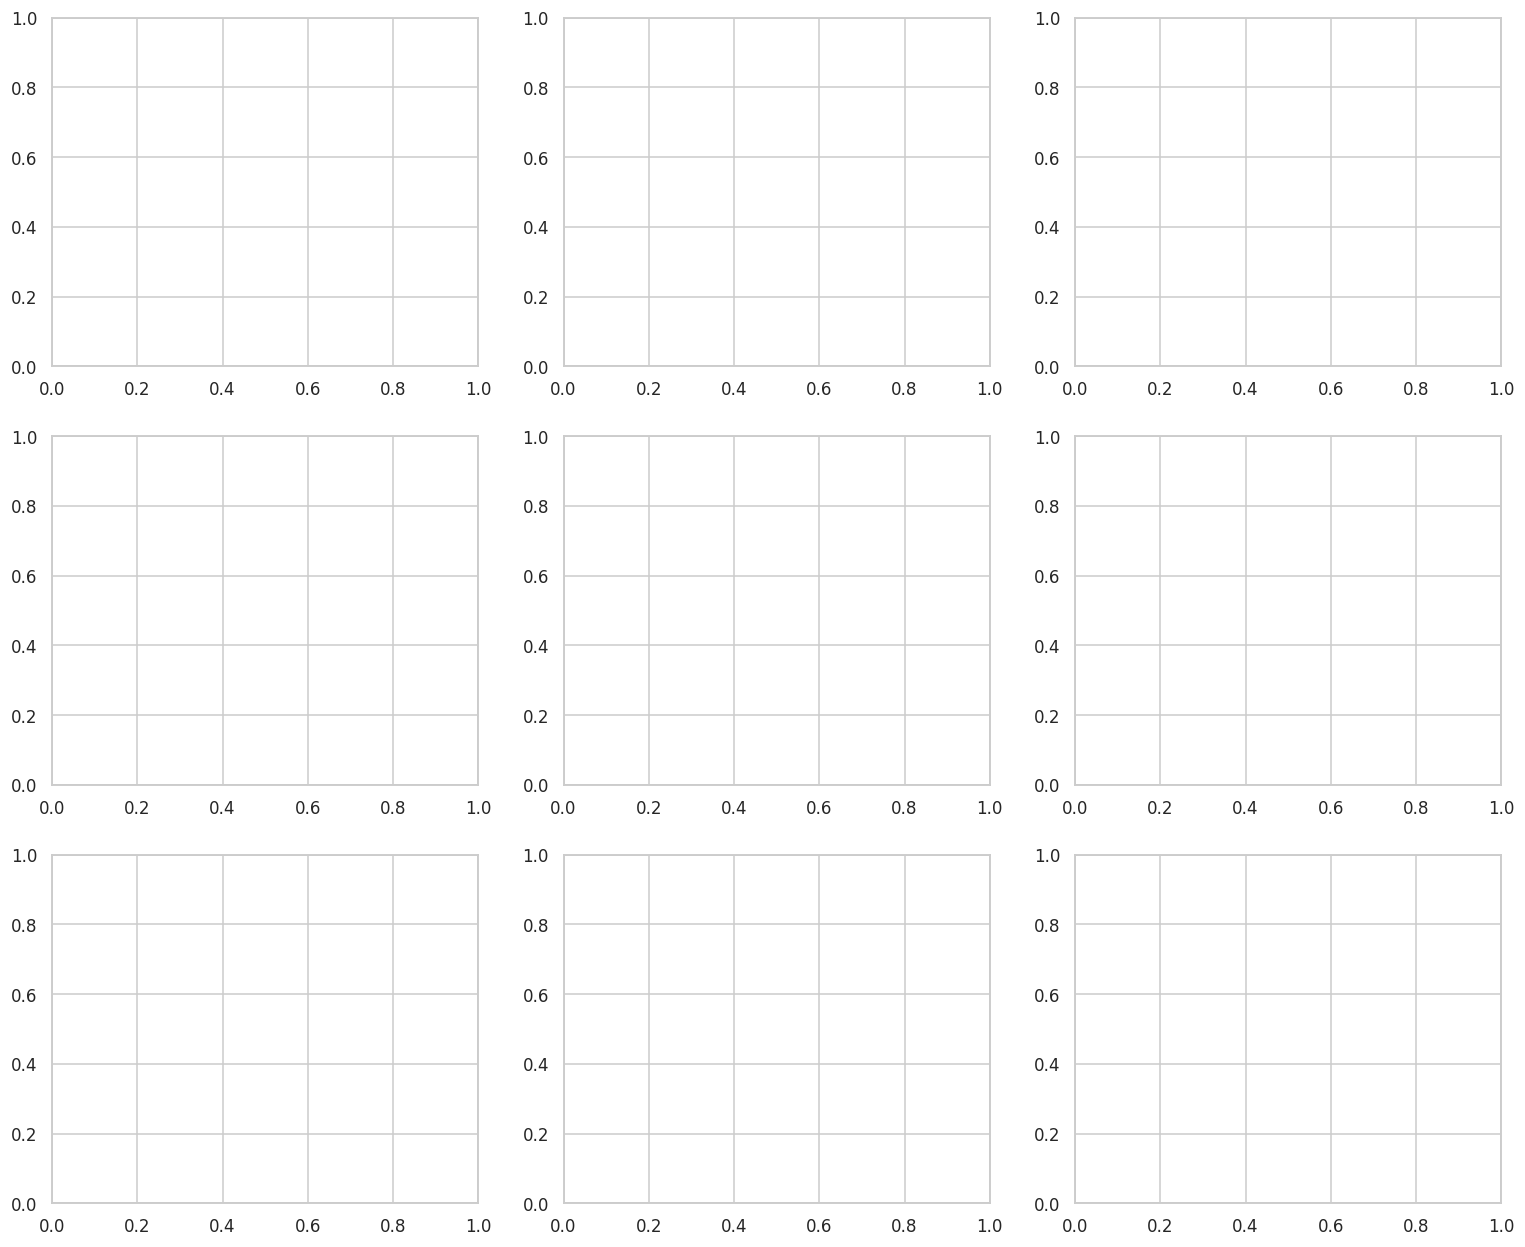

In [158]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)


RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)

FIGURE_DIR = Path(
    config.FIGURES_DIR
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


pr_points_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_pr_curve_points.csv"
    )
)

reliability_bins_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_reliability_bins.csv"
    )
)

confusion_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_confusion_matrices.csv"
    )
)

diagnostic_figure_path = (
    FIGURE_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_diagnostics.png"
    )
)


primary_predictions = (
    classification_test_predictions.copy()
)

primary_metrics = (
    classification_test_metrics.loc[
        classification_test_metrics[
            "scope"
        ]
        == "all_observed_rows_primary"
    ]
    .sort_values("horizon")
    .reset_index(drop=True)
)

assert len(primary_metrics) == 3
assert len(primary_predictions) == 13096


def quantile_reliability_bins(
    y_true,
    probability,
    maximum_bins=10,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )
    probability = np.asarray(
        probability,
        dtype=float,
    )

    assert len(y_true) == len(probability)
    assert len(y_true) > 0
    assert np.isfinite(probability).all()
    assert np.all(
        (probability >= 0.0)
        & (probability <= 1.0)
    )

    unique_probability_count = int(
        np.unique(probability).size
    )

    requested_bins = min(
        maximum_bins,
        unique_probability_count,
    )

    if requested_bins <= 1:
        bin_ids = np.zeros(
            len(probability),
            dtype=int,
        )
    else:
        bin_ids = pd.qcut(
            pd.Series(probability),
            q=requested_bins,
            labels=False,
            duplicates="drop",
        ).to_numpy()

        assert not pd.isna(
            bin_ids
        ).any()

        bin_ids = bin_ids.astype(int)

    rows = []

    for bin_id in np.sort(
        np.unique(bin_ids)
    ):
        mask = (
            bin_ids == bin_id
        )

        mean_probability = float(
            probability[mask].mean()
        )
        observed_fraction = float(
            y_true[mask].mean()
        )

        rows.append(
            {
                "bin_id": int(bin_id),
                "n_rows": int(mask.sum()),
                "mean_predicted_probability": (
                    mean_probability
                ),
                "observed_positive_fraction": (
                    observed_fraction
                ),
                "absolute_calibration_gap": float(
                    abs(
                        mean_probability
                        - observed_fraction
                    )
                ),
            }
        )

    result = pd.DataFrame(rows)

    assert result["n_rows"].sum() == len(
        y_true
    )

    return result


pr_frames = []
reliability_frames = []
confusion_rows = []
diagnostic_summary_rows = []


fig, axes = plt.subplots(
    3,
    3,
    figsize=(17, 14),
)

stage_styles = {
    "raw": {
        "label": "Raw",
        "color": "#4c72b0",
        "marker": "o",
    },
    "platt": {
        "label": "Platt",
        "color": "#dd8452",
        "marker": "s",
    },
    "mono": {
        "label": "Platt + monotone",
        "color": "#55a868",
        "marker": "^",
    },
}


In [159]:
for column_index, horizon in enumerate(
    HORIZONS
):
    y_true = primary_predictions[
        f"y_h{horizon}"
    ].to_numpy(dtype=int)

    probability = primary_predictions[
        f"mono_h{horizon}"
    ].to_numpy(dtype=float)

    decision = primary_predictions[
        f"dec_h{horizon}"
    ].to_numpy(dtype=int)

    prevalence = float(
        y_true.mean()
    )

    metric_row = (
        primary_metrics.loc[
            primary_metrics[
                "horizon"
            ]
            == horizon
        ]
    )

    assert len(metric_row) == 1
    metric_row = metric_row.iloc[0]

    
    
    

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            y_true,
            probability,
        )
    )

    pr_auc = float(
        average_precision_score(
            y_true,
            probability,
        )
    )

    threshold_column = np.append(
        thresholds,
        np.nan,
    )

    pr_frame = pd.DataFrame(
        {
            "evaluation_scope": (
                "all_observed_rows_primary"
            ),
            "horizon": int(horizon),
            "precision": precision_values,
            "recall": recall_values,
            "threshold": threshold_column,
        }
    )

    pr_frames.append(pr_frame)

    pr_axis = axes[
        0,
        column_index,
    ]

    pr_axis.plot(
        recall_values,
        precision_values,
        color="#4c72b0",
        linewidth=1.7,
        label=f"PR-AUC = {pr_auc:.3f}",
    )

    pr_axis.axhline(
        prevalence,
        color="gray",
        linestyle=":",
        linewidth=1.2,
        label=(
            f"No-skill = {prevalence:.3f}"
        ),
    )

    pr_axis.scatter(
        float(metric_row["recall"]),
        float(metric_row["precision"]),
        marker="X",
        s=90,
        color="red",
        zorder=5,
        label=(
            "Frozen FN:FP=10:1\n"
            f"t={bundle_thresholds[horizon]:.3f}"
        ),
    )

    pr_axis.set_title(
        f"Failure within {horizon} cycles",
        fontweight="bold",
    )
    pr_axis.set_xlabel("Recall")
    pr_axis.set_ylabel("Precision")
    pr_axis.set_xlim(-0.02, 1.02)
    pr_axis.set_ylim(-0.02, 1.02)
    pr_axis.grid(alpha=0.2)
    pr_axis.legend(fontsize=8)

    
    
    

    calibration_axis = axes[
        1,
        column_index,
    ]

    calibration_axis.plot(
        [0.0, 1.0],
        [0.0, 1.0],
        color="black",
        linestyle=":",
        linewidth=1.2,
        label="Perfect calibration",
    )

    stage_gap_summaries = {}

    for stage, style in stage_styles.items():
        stage_probability = (
            primary_predictions[
                f"{stage}_h{horizon}"
            ].to_numpy(dtype=float)
        )

        bins = quantile_reliability_bins(
            y_true,
            stage_probability,
            maximum_bins=10,
        )

        bins.insert(
            0,
            "stage",
            stage,
        )
        bins.insert(
            0,
            "horizon",
            int(horizon),
        )
        bins.insert(
            0,
            "evaluation_scope",
            "all_observed_rows_primary",
        )

        reliability_frames.append(
            bins
        )

        weighted_gap = float(
            np.average(
                bins[
                    "absolute_calibration_gap"
                ],
                weights=bins["n_rows"],
            )
        )

        maximum_gap = float(
            bins[
                "absolute_calibration_gap"
            ].max()
        )

        stage_gap_summaries[stage] = {
            "weighted_gap": weighted_gap,
            "maximum_gap": maximum_gap,
            "populated_bins": int(
                len(bins)
            ),
        }

        calibration_axis.plot(
            bins[
                "mean_predicted_probability"
            ],
            bins[
                "observed_positive_fraction"
            ],
            color=style["color"],
            marker=style["marker"],
            linewidth=1.4,
            markersize=5,
            label=style["label"],
        )

    calibration_axis.set_xlabel(
        "Mean predicted probability"
    )
    calibration_axis.set_ylabel(
        "Observed positive fraction"
    )
    calibration_axis.set_xlim(
        -0.02,
        1.02,
    )
    calibration_axis.set_ylim(
        -0.02,
        1.02,
    )
    calibration_axis.grid(alpha=0.2)
    calibration_axis.legend(fontsize=8)

    
    
    

    cm = confusion_matrix(
        y_true,
        decision,
        labels=[0, 1],
    )

    tn, fp, fn, tp = cm.ravel()

    row_totals = cm.sum(
        axis=1,
        keepdims=True,
    )

    normalized_cm = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(
            cm,
            dtype=float,
        ),
        where=row_totals != 0,
    )

    confusion_axis = axes[
        2,
        column_index,
    ]

    confusion_axis.imshow(
        normalized_cm,
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
    )

    for true_class in range(2):
        for predicted_class in range(2):
            confusion_axis.text(
                predicted_class,
                true_class,
                (
                    f"{cm[true_class, predicted_class]}"
                    "\n"
                    f"({normalized_cm[true_class, predicted_class]:.3f})"
                ),
                ha="center",
                va="center",
                fontsize=10,
                color="black",
            )

    confusion_axis.set_xticks(
        [0, 1]
    )
    confusion_axis.set_xticklabels(
        ["Predicted 0", "Predicted 1"]
    )
    confusion_axis.set_yticks(
        [0, 1]
    )
    confusion_axis.set_yticklabels(
        ["Actual 0", "Actual 1"]
    )
    confusion_axis.set_xlabel(
        "Predicted class"
    )
    confusion_axis.set_ylabel(
        "True class"
    )
    confusion_axis.set_title(
        (
            f"Frozen threshold "
            f"{bundle_thresholds[horizon]:.3f}"
        ),
        fontsize=10,
        fontweight="bold",
    )

    confusion_rows.append(
        {
            "evaluation_scope": (
                "all_observed_rows_primary"
            ),
            "horizon": int(horizon),
            "threshold": float(
                bundle_thresholds[horizon]
            ),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "true_negative_rate": float(
                normalized_cm[0, 0]
            ),
            "false_positive_rate": float(
                normalized_cm[0, 1]
            ),
            "false_negative_rate": float(
                normalized_cm[1, 0]
            ),
            "true_positive_rate": float(
                normalized_cm[1, 1]
            ),
        }
    )

    diagnostic_summary_rows.append(
        {
            "horizon": int(horizon),
            "prevalence": prevalence,
            "PR_AUC_computed": pr_auc,
            "PR_AUC_saved": float(
                metric_row["PR_AUC"]
            ),
            "raw_weighted_calibration_gap": (
                stage_gap_summaries[
                    "raw"
                ]["weighted_gap"]
            ),
            "platt_weighted_calibration_gap": (
                stage_gap_summaries[
                    "platt"
                ]["weighted_gap"]
            ),
            "mono_weighted_calibration_gap": (
                stage_gap_summaries[
                    "mono"
                ]["weighted_gap"]
            ),
            "raw_maximum_calibration_gap": (
                stage_gap_summaries[
                    "raw"
                ]["maximum_gap"]
            ),
            "platt_maximum_calibration_gap": (
                stage_gap_summaries[
                    "platt"
                ]["maximum_gap"]
            ),
            "mono_maximum_calibration_gap": (
                stage_gap_summaries[
                    "mono"
                ]["maximum_gap"]
            ),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )


In [160]:
fig.suptitle(
    (
        f"{SUBSET} Official-Test Classification "
        "Diagnostics — Primary Row-Level Scope"
    ),
    fontsize=15,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()

fig.savefig(
    diagnostic_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


official_test_pr_points = pd.concat(
    pr_frames,
    ignore_index=True,
)

official_test_reliability_bins = pd.concat(
    reliability_frames,
    ignore_index=True,
)

official_test_confusion = pd.DataFrame(
    confusion_rows
)

official_test_diagnostic_summary = (
    pd.DataFrame(
        diagnostic_summary_rows
    )
)


diagnostic_checks = {
    "three_horizons_in_pr_points": (
        set(
            official_test_pr_points[
                "horizon"
            ]
        )
        == set(HORIZONS)
    ),
    "three_horizons_in_reliability": (
        set(
            official_test_reliability_bins[
                "horizon"
            ]
        )
        == set(HORIZONS)
    ),
    "all_three_probability_stages_present": (
        set(
            official_test_reliability_bins[
                "stage"
            ]
        )
        == {"raw", "platt", "mono"}
    ),
    "three_confusion_matrices": (
        len(official_test_confusion)
        == 3
    ),
    "pr_auc_matches_saved_metrics": bool(
        np.allclose(
            official_test_diagnostic_summary[
                "PR_AUC_computed"
            ],
            official_test_diagnostic_summary[
                "PR_AUC_saved"
            ],
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "confusion_counts_match_saved_metrics": bool(
        np.array_equal(
            official_test_confusion[
                ["tn", "fp", "fn", "tp"]
            ].to_numpy(dtype=int),
            primary_metrics[
                ["tn", "fp", "fn", "tp"]
            ].to_numpy(dtype=int),
        )
    ),
    "all_reliability_rows_accounted_for": bool(
        (
            official_test_reliability_bins
            .groupby(
                ["horizon", "stage"]
            )["n_rows"]
            .sum()
            == len(primary_predictions)
        ).all()
    ),
    "all_calibration_gaps_nonnegative": bool(
        (
            official_test_reliability_bins[
                "absolute_calibration_gap"
            ]
            >= 0.0
        ).all()
    ),
    "diagnostic_figure_created": (
        diagnostic_figure_path.is_file()
        and diagnostic_figure_path.stat().st_size
        > 0
    ),
}

failed_diagnostic_checks = [
    name
    for name, passed
    in diagnostic_checks.items()
    if not bool(passed)
]

assert not failed_diagnostic_checks, (
    "Classification diagnostic checks failed: "
    f"{failed_diagnostic_checks}"
)


def save_csv_atomically(
    frame,
    final_path,
):
    temporary_path = final_path.with_name(
        final_path.stem
        + ".tmp.csv"
    )

    frame.to_csv(
        temporary_path,
        index=False,
    )

    os.replace(
        temporary_path,
        final_path,
    )


save_csv_atomically(
    official_test_pr_points,
    pr_points_path,
)

save_csv_atomically(
    official_test_reliability_bins,
    reliability_bins_path,
)

save_csv_atomically(
    official_test_confusion,
    confusion_path,
)


persistence_checks = {
    "pr_points_reload_shape_parity": (
        pd.read_csv(
            pr_points_path
        ).shape
        == official_test_pr_points.shape
    ),
    "reliability_reload_shape_parity": (
        pd.read_csv(
            reliability_bins_path
        ).shape
        == official_test_reliability_bins.shape
    ),
    "confusion_reload_shape_parity": (
        pd.read_csv(
            confusion_path
        ).shape
        == official_test_confusion.shape
    ),
}

assert all(persistence_checks.values())


all_diagnostic_checks = {
    **diagnostic_checks,
    **persistence_checks,
}

classification_diagnostic_check_table = (
    pd.DataFrame(
        [
            {
                "check": name,
                "passed": bool(passed),
            }
            for name, passed
            in all_diagnostic_checks.items()
        ]
    )
)

failed_checks = (
    classification_diagnostic_check_table.loc[
        ~classification_diagnostic_check_table[
            "passed"
        ],
        "check",
    ].tolist()
)

assert not failed_checks


<Figure size 1100x550 with 0 Axes>

In [161]:
print(
    " COMPUTED CLASSIFICATION "
    "DIAGNOSTIC CHECKS "
)
display(
    classification_diagnostic_check_table
)

print(
    "\n OFFICIAL TEST CLASSIFICATION "
    "DIAGNOSTIC SUMMARY "
)
display(
    official_test_diagnostic_summary
)

print(
    "Failed checks:",
    len(failed_checks),
)
print(
    "Saved PR points:",
    pr_points_path,
)
print(
    "Saved reliability bins:",
    reliability_bins_path,
)
print(
    "Saved confusion matrices:",
    confusion_path,
)
print(
    "Saved figure:",
    diagnostic_figure_path,
)


 COMPUTED CLASSIFICATION DIAGNOSTIC CHECKS 


,check,passed
0,three_horizons_in_pr_points,True
1,three_horizons_in_reliability,True
2,all_three_probability_stages_present,True
3,three_confusion_matrices,True
4,pr_auc_matches_saved_metrics,True
5,confusion_counts_match_saved_metrics,True
6,all_reliability_rows_accounted_for,True
7,all_calibration_gaps_nonnegative,True
8,diagnostic_figure_created,True
9,pr_points_reload_shape_parity,True



 OFFICIAL TEST CLASSIFICATION DIAGNOSTIC SUMMARY 


,horizon,prevalence,PR_AUC_computed,PR_AUC_saved,raw_weighted_calibration_gap,platt_weighted_calibration_gap,mono_weighted_calibration_gap,raw_maximum_calibration_gap,platt_maximum_calibration_gap,mono_maximum_calibration_gap,tn,fp,fn,tp
0,10,0.001298,0.879869,0.879869,0.009435,0.000335,0.000335,0.091123,0.003353,0.003353,13072,7,1,16
1,20,0.009392,0.729678,0.729678,0.001611,0.001475,0.001475,0.016105,0.014742,0.014742,12919,54,9,114
2,30,0.025351,0.806766,0.806766,0.001078,0.001801,0.001588,0.010365,0.017247,0.015114,12620,144,12,320


Failed checks: 0
Saved PR points: artifacts/results/FD001_official_test_classification_pr_curve_points.csv
Saved reliability bins: artifacts/results/FD001_official_test_classification_reliability_bins.csv
Saved confusion matrices: artifacts/results/FD001_official_test_classification_confusion_matrices.csv
Saved figure: figures/FD001_official_test_classification_diagnostics.png


### Official-Test classification per-engine distributions

Frozen probabilities and decisions only; no fitting or tuning.


In [162]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
)


RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)

FIGURE_DIR = Path(
    config.FIGURES_DIR
)

per_engine_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_per_engine.csv"
    )
)

per_engine_summary_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_per_engine_summary.csv"
    )
)

per_engine_figure_path = (
    FIGURE_DIR
    / (
        f"{SUBSET}_official_test_"
        "classification_per_engine.png"
    )
)


def safe_divide(
    numerator,
    denominator,
):
    return (
        float(numerator / denominator)
        if denominator > 0
        else np.nan
    )


per_engine_rows = []

for engine_id, engine_frame in (
    classification_test_predictions
    .groupby(
        "engine_id",
        sort=True,
    )
):
    for horizon in HORIZONS:
        y_true = engine_frame[
            f"y_h{horizon}"
        ].to_numpy(dtype=int)

        raw_probability = engine_frame[
            f"raw_h{horizon}"
        ].to_numpy(dtype=float)

        platt_probability = engine_frame[
            f"platt_h{horizon}"
        ].to_numpy(dtype=float)

        mono_probability = engine_frame[
            f"mono_h{horizon}"
        ].to_numpy(dtype=float)

        decision = engine_frame[
            f"dec_h{horizon}"
        ].to_numpy(dtype=int)

        n_positive = int(
            y_true.sum()
        )
        n_negative = int(
            len(y_true) - n_positive
        )

        both_classes_present = (
            n_positive > 0
            and n_negative > 0
        )

        pr_auc = (
            float(
                average_precision_score(
                    y_true,
                    mono_probability,
                )
            )
            if both_classes_present
            else np.nan
        )

        tp = int(
            np.sum(
                (y_true == 1)
                & (decision == 1)
            )
        )
        fp = int(
            np.sum(
                (y_true == 0)
                & (decision == 1)
            )
        )
        fn = int(
            np.sum(
                (y_true == 1)
                & (decision == 0)
            )
        )
        tn = int(
            np.sum(
                (y_true == 0)
                & (decision == 0)
            )
        )

        precision = safe_divide(
            tp,
            tp + fp,
        )
        recall = safe_divide(
            tp,
            tp + fn,
        )
        f1 = safe_divide(
            2 * tp,
            2 * tp + fp + fn,
        )

        total_cost = float(
            10.0 * fn
            + 1.0 * fp
        )

        per_engine_rows.append(
            {
                "engine_id": int(
                    engine_id
                ),
                "horizon": int(
                    horizon
                ),
                "n_rows": int(
                    len(engine_frame)
                ),
                "n_positive": n_positive,
                "n_negative": n_negative,
                "positive_class_present": bool(
                    n_positive > 0
                ),
                "both_classes_present": bool(
                    both_classes_present
                ),
                "PR_AUC": pr_auc,
                "Brier_raw": float(
                    brier_score_loss(
                        y_true,
                        raw_probability,
                    )
                ),
                "Brier_platt": float(
                    brier_score_loss(
                        y_true,
                        platt_probability,
                    )
                ),
                "Brier_platt_monotone": float(
                    brier_score_loss(
                        y_true,
                        mono_probability,
                    )
                ),
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
                "total_cost": total_cost,
                "normalized_row_cost": float(
                    total_cost
                    / len(engine_frame)
                ),
                "predicted_positive_fraction": float(
                    decision.mean()
                ),
            }
        )


classification_per_engine = (
    pd.DataFrame(per_engine_rows)
)

assert len(classification_per_engine) == 300


In [163]:
summary_rows = []

summary_metrics = (
    "PR_AUC",
    "Brier_platt_monotone",
    "precision",
    "recall",
    "f1",
    "normalized_row_cost",
)

for horizon in HORIZONS:
    horizon_frame = (
        classification_per_engine.loc[
            classification_per_engine[
                "horizon"
            ]
            == horizon
        ]
    )

    summary_row = {
        "horizon": int(horizon),
        "n_engines": int(
            len(horizon_frame)
        ),
        "engines_with_positive_class": int(
            horizon_frame[
                "positive_class_present"
            ].sum()
        ),
        "engines_with_both_classes": int(
            horizon_frame[
                "both_classes_present"
            ].sum()
        ),
        "engines_with_defined_PR_AUC": int(
            horizon_frame[
                "PR_AUC"
            ].notna().sum()
        ),
        "engines_with_defined_precision": int(
            horizon_frame[
                "precision"
            ].notna().sum()
        ),
        "engines_with_defined_recall": int(
            horizon_frame[
                "recall"
            ].notna().sum()
        ),
    }

    for metric in summary_metrics:
        values = horizon_frame[
            metric
        ].to_numpy(dtype=float)

        finite_values = values[
            np.isfinite(values)
        ]

        assert len(finite_values) > 0

        summary_row[
            f"{metric}_mean"
        ] = float(
            np.mean(finite_values)
        )
        summary_row[
            f"{metric}_median"
        ] = float(
            np.median(finite_values)
        )
        summary_row[
            f"{metric}_min"
        ] = float(
            np.min(finite_values)
        )
        summary_row[
            f"{metric}_max"
        ] = float(
            np.max(finite_values)
        )

    summary_rows.append(
        summary_row
    )


classification_per_engine_summary = (
    pd.DataFrame(summary_rows)
)






aggregated_counts = (
    classification_per_engine
    .groupby("horizon")[
        ["tn", "fp", "fn", "tp"]
    ]
    .sum()
    .loc[list(HORIZONS)]
    .reset_index()
)

expected_counts = (
    primary_metrics[
        ["horizon", "tn", "fp", "fn", "tp"]
    ]
    .sort_values("horizon")
    .reset_index(drop=True)
)

weighted_brier_rows = []

for horizon in HORIZONS:
    horizon_frame = (
        classification_per_engine.loc[
            classification_per_engine[
                "horizon"
            ]
            == horizon
        ]
    )

    weighted_brier = float(
        np.average(
            horizon_frame[
                "Brier_platt_monotone"
            ],
            weights=horizon_frame[
                "n_rows"
            ],
        )
    )

    pooled_brier = float(
        primary_metrics.loc[
            primary_metrics[
                "horizon"
            ]
            == horizon,
            "Brier_platt_monotone",
        ].iloc[0]
    )

    weighted_brier_rows.append(
        {
            "horizon": int(horizon),
            "weighted_per_engine_brier": (
                weighted_brier
            ),
            "pooled_brier": pooled_brier,
        }
    )

weighted_brier_table = pd.DataFrame(
    weighted_brier_rows
)


positive_engine_counts = (
    classification_per_engine
    .groupby("horizon")[
        "positive_class_present"
    ]
    .sum()
    .loc[list(HORIZONS)]
    .to_numpy(dtype=int)
)

final_positive_counts = (
    classification_test_final[
        [
            f"y_h{horizon}"
            for horizon in HORIZONS
        ]
    ]
    .sum()
    .to_numpy(dtype=int)
)


per_engine_checks = {
    "exactly_300_engine_horizon_rows": (
        len(classification_per_engine)
        == 300
    ),
    "exactly_100_engines_per_horizon": bool(
        (
            classification_per_engine
            .groupby("horizon")[
                "engine_id"
            ]
            .nunique()
            == 100
        ).all()
    ),
    "confusion_counts_reconstruct_pooled_results": bool(
        np.array_equal(
            aggregated_counts[
                ["tn", "fp", "fn", "tp"]
            ].to_numpy(dtype=int),
            expected_counts[
                ["tn", "fp", "fn", "tp"]
            ].to_numpy(dtype=int),
        )
    ),
    "weighted_brier_reconstructs_pooled_brier": bool(
        np.allclose(
            weighted_brier_table[
                "weighted_per_engine_brier"
            ],
            weighted_brier_table[
                "pooled_brier"
            ],
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "positive_engine_counts_match_final_labels": bool(
        np.array_equal(
            positive_engine_counts,
            final_positive_counts,
        )
    ),
    "all_costs_nonnegative": bool(
        (
            classification_per_engine[
                "normalized_row_cost"
            ]
            >= 0.0
        ).all()
    ),
    "all_brier_values_bounded": bool(
        classification_per_engine[
            "Brier_platt_monotone"
        ].between(
            0.0,
            1.0,
        ).all()
    ),
}


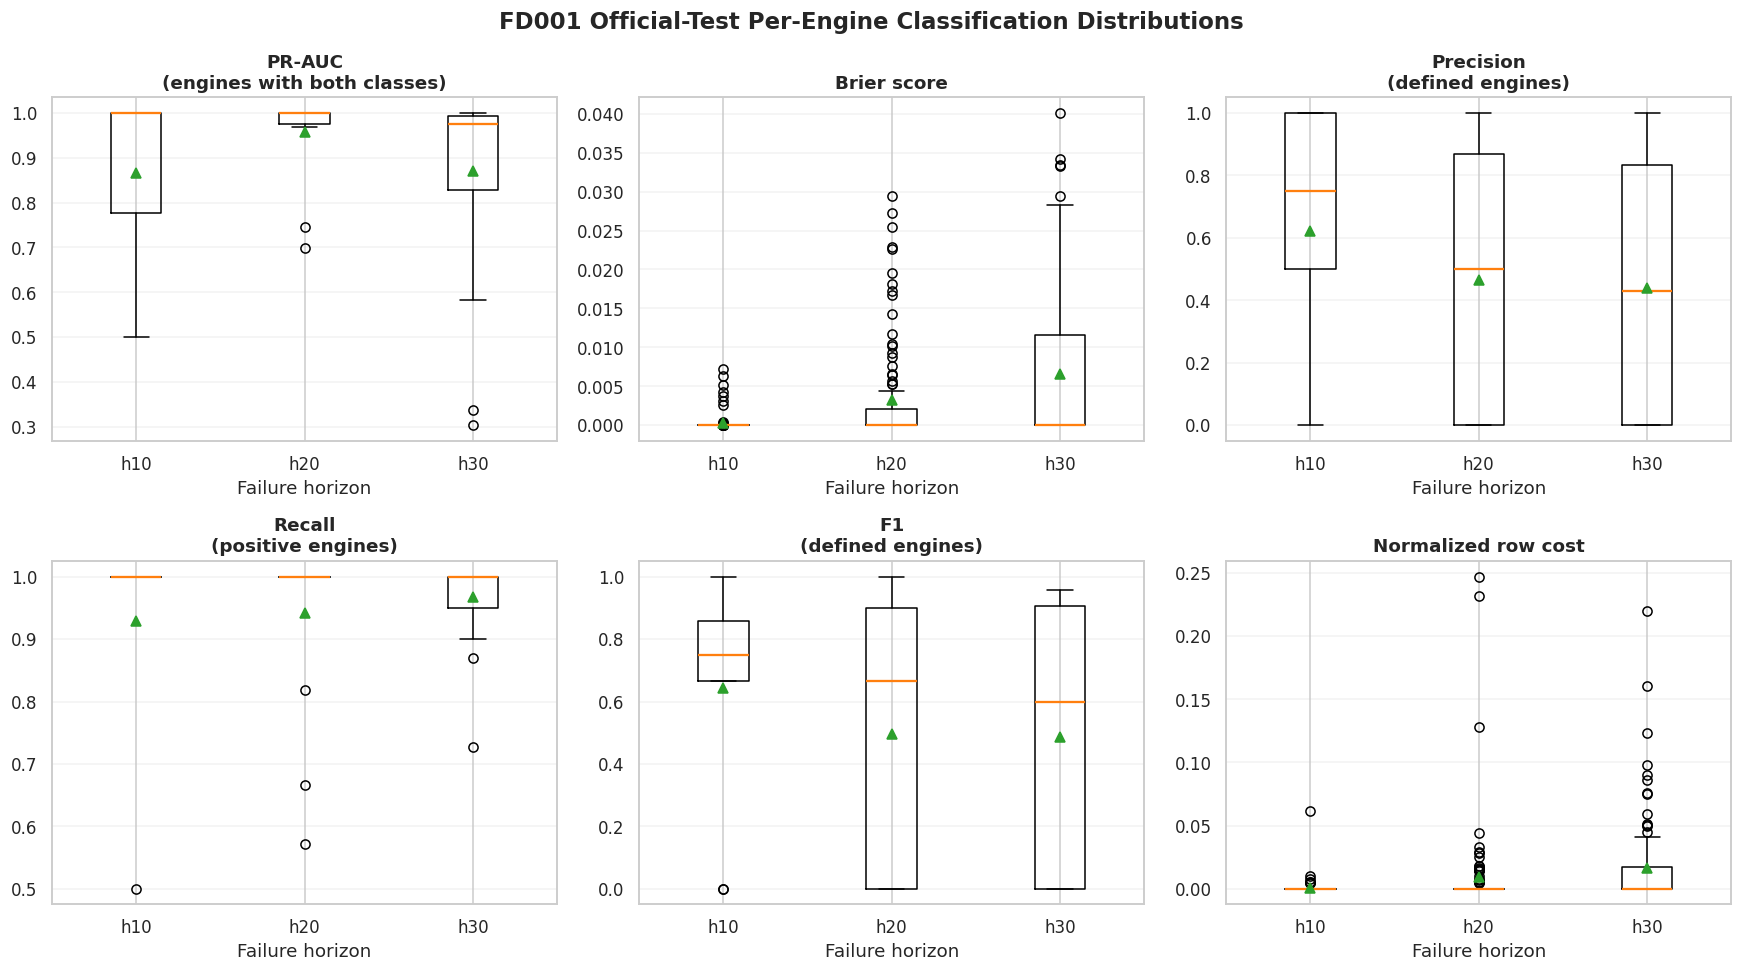

In [164]:
failed_per_engine_checks = [
    name
    for name, passed
    in per_engine_checks.items()
    if not bool(passed)
]

assert not failed_per_engine_checks, (
    "Per-engine classification checks failed: "
    f"{failed_per_engine_checks}"
)






plot_metrics = (
    (
        "PR_AUC",
        "PR-AUC\n(engines with both classes)",
    ),
    (
        "Brier_platt_monotone",
        "Brier score",
    ),
    (
        "precision",
        "Precision\n(defined engines)",
    ),
    (
        "recall",
        "Recall\n(positive engines)",
    ),
    (
        "f1",
        "F1\n(defined engines)",
    ),
    (
        "normalized_row_cost",
        "Normalized row cost",
    ),
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

for axis, (
    metric,
    title,
) in zip(
    axes.ravel(),
    plot_metrics,
):
    distributions = []

    for horizon in HORIZONS:
        values = (
            classification_per_engine.loc[
                classification_per_engine[
                    "horizon"
                ]
                == horizon,
                metric,
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        assert len(values) > 0

        distributions.append(
            values
        )

    axis.boxplot(
        distributions,
        labels=[
            f"h{horizon}"
            for horizon in HORIZONS
        ],
        showmeans=True,
        meanprops={
            "marker": "^",
            "markerfacecolor": "#2ca02c",
            "markeredgecolor": "#2ca02c",
        },
        medianprops={
            "color": "#ff7f0e",
            "linewidth": 1.5,
        },
    )

    axis.set_title(
        title,
        fontweight="bold",
    )
    axis.set_xlabel(
        "Failure horizon"
    )
    axis.grid(
        axis="y",
        alpha=0.25,
    )

fig.suptitle(
    (
        f"{SUBSET} Official-Test "
        "Per-Engine Classification Distributions"
    ),
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()

fig.savefig(
    per_engine_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

per_engine_checks[
    "per_engine_figure_created"
] = (
    per_engine_figure_path.is_file()
    and per_engine_figure_path.stat().st_size
    > 0
)

assert per_engine_checks[
    "per_engine_figure_created"
]






def save_csv_atomically(
    frame,
    final_path,
):
    temporary_path = final_path.with_name(
        final_path.stem
        + ".tmp.csv"
    )

    frame.to_csv(
        temporary_path,
        index=False,
    )

    os.replace(
        temporary_path,
        final_path,
    )


save_csv_atomically(
    classification_per_engine,
    per_engine_path,
)

save_csv_atomically(
    classification_per_engine_summary,
    per_engine_summary_path,
)

reloaded_per_engine = pd.read_csv(
    per_engine_path
)

reloaded_summary = pd.read_csv(
    per_engine_summary_path
)

persistence_checks = {
    "per_engine_csv_shape_parity": (
        reloaded_per_engine.shape
        == classification_per_engine.shape
    ),
    "summary_csv_shape_parity": (
        reloaded_summary.shape
        == classification_per_engine_summary.shape
    ),
    "per_engine_key_order_parity": bool(
        np.array_equal(
            reloaded_per_engine[
                ["engine_id", "horizon"]
            ].to_numpy(dtype=int),
            classification_per_engine[
                ["engine_id", "horizon"]
            ].to_numpy(dtype=int),
        )
    ),
}

assert all(persistence_checks.values())


all_per_engine_checks = {
    **per_engine_checks,
    **persistence_checks,
}

per_engine_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_per_engine_checks.items()
    ]
)


In [165]:
failed_checks = (
    per_engine_check_table.loc[
        ~per_engine_check_table[
            "passed"
        ],
        "check",
    ].tolist()
)

assert not failed_checks


print(
    " COMPUTED PER-ENGINE "
    "CLASSIFICATION CHECKS "
)
display(per_engine_check_table)

print(
    "\n OFFICIAL TEST PER-ENGINE "
    "CLASSIFICATION SUMMARY "
)
display(
    classification_per_engine_summary
)

print(
    "\n POSITIVE-CLASS AVAILABILITY "
)
display(
    classification_per_engine_summary[
        [
            "horizon",
            "n_engines",
            "engines_with_positive_class",
            "engines_with_both_classes",
            "engines_with_defined_PR_AUC",
            "engines_with_defined_precision",
            "engines_with_defined_recall",
        ]
    ]
)

print(
    "Failed checks:",
    len(failed_checks),
)
print(
    "Saved per-engine results:",
    per_engine_path,
)
print(
    "Saved summary:",
    per_engine_summary_path,
)


 COMPUTED PER-ENGINE CLASSIFICATION CHECKS 


,check,passed
0,exactly_300_engine_horizon_rows,True
1,exactly_100_engines_per_horizon,True
2,confusion_counts_reconstruct_pooled_results,True
3,weighted_brier_reconstructs_pooled_brier,True
4,positive_engine_counts_match_final_labels,True
5,all_costs_nonnegative,True
6,all_brier_values_bounded,True
7,per_engine_figure_created,True
8,per_engine_csv_shape_parity,True
9,summary_csv_shape_parity,True



 OFFICIAL TEST PER-ENGINE CLASSIFICATION SUMMARY 


,horizon,n_engines,engines_with_positive_class,engines_with_both_classes,engines_with_defined_PR_AUC,engines_with_defined_precision,engines_with_defined_recall,PR_AUC_mean,PR_AUC_median,PR_AUC_min,...,recall_min,recall_max,f1_mean,f1_median,f1_min,f1_max,normalized_row_cost_mean,normalized_row_cost_median,normalized_row_cost_min,normalized_row_cost_max
0,10,100,7,7,7,9,7,0.865079,1.000000,0.500000,...,0.500000,1.0,0.644180,0.750000,0.0,1.000000,0.000993,0.0,0.0,0.061728
1,20,100,16,16,16,27,16,0.958322,1.000000,0.699412,...,0.571429,1.0,0.496699,0.666667,0.0,1.000000,0.009544,0.0,0.0,0.246914
2,30,100,25,25,25,41,25,0.870924,0.974342,0.303571,...,0.727273,1.0,0.486544,0.600000,0.0,0.958333,0.016777,0.0,0.0,0.220000



 POSITIVE-CLASS AVAILABILITY 


,horizon,n_engines,engines_with_positive_class,engines_with_both_classes,engines_with_defined_PR_AUC,engines_with_defined_precision,engines_with_defined_recall
0,10,100,7,7,7,9,7
1,20,100,16,16,16,27,16
2,30,100,25,25,25,41,25


Failed checks: 0
Saved per-engine results: artifacts/results/FD001_official_test_classification_per_engine.csv
Saved summary: artifacts/results/FD001_official_test_classification_per_engine_summary.csv


### Frozen anomaly inference on FD001 Official Test

Contract: LOF / pooled percentile 0.99 / persistent 5-of-10.
Truncated Test trajectories use the frozen censoring rule.
No fitting, threshold selection, or policy optimization occurs here.


In [166]:
import hashlib
import json
import os
import time
from pathlib import Path

import joblib
import models_anomaly as ma
import numpy as np
import pandas as pd


MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


test_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)

access_record_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.json"
)

anomaly_policy_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_policy_bundle.joblib"
)

anomaly_timeline_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "anomaly_timelines.csv"
    )
)

anomaly_engine_result_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "anomaly_engine_results.csv"
    )
)


required_paths = (
    test_contract_path,
    access_record_path,
    anomaly_policy_bundle_path,
)

missing_paths = [
    str(path)
    for path in required_paths
    if not path.is_file()
]

assert not missing_paths, (
    f"Required anomaly files missing: "
    f"{missing_paths}"
)


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def save_csv_atomically(
    frame,
    final_path,
):
    temporary_path = final_path.with_name(
        final_path.stem
        + ".tmp.csv"
    )

    frame.to_csv(
        temporary_path,
        index=False,
    )

    os.replace(
        temporary_path,
        final_path,
    )


test_contract = json.loads(
    test_contract_path.read_text(
        encoding="utf-8"
    )
)

access_record = json.loads(
    access_record_path.read_text(
        encoding="utf-8"
    )
)

assert (
    access_record["status"]
    == "UNSEALED_FOR_EVALUATION"
)






anomaly_bundle_sha_before = sha256_file(
    anomaly_policy_bundle_path
)

expected_anomaly_bundle_sha = (
    test_contract[
        "frozen_artifacts"
    ][
        "anomaly_policy_bundle"
    ]["sha256"]
)

assert (
    anomaly_bundle_sha_before
    == expected_anomaly_bundle_sha
)

anomaly_policy_bundle = joblib.load(
    anomaly_policy_bundle_path
)

anomaly_contract = (
    test_contract[
        "anomaly_evaluation"
    ]
)

selected_policy = (
    anomaly_policy_bundle[
        "selected_overall_policy"
    ]
)

contract_checks = {
    "bundle_subset_matches": (
        anomaly_policy_bundle[
            "subset"
        ]
        == SUBSET
    ),
    "bundle_created_while_test_sealed": (
        str(
            anomaly_policy_bundle[
                "official_test_status"
            ]
        ).lower()
        == "sealed"
    ),
    "contract_family_matches_bundle": (
        anomaly_contract["family"]
        == selected_policy["family"]
        == "lof"
    ),
    "contract_candidate_matches_bundle": (
        anomaly_contract[
            "candidate_id"
        ]
        == selected_policy[
            "candidate_id"
        ]
        == "lof_k50"
    ),
    "contract_reference_matches_bundle": (
        anomaly_contract[
            "reference_type"
        ]
        == selected_policy[
            "reference_type"
        ]
        == "pooled"
    ),
    "contract_cutoff_matches_bundle": (
        float(
            anomaly_contract["cutoff"]
        )
        == float(
            selected_policy["cutoff"]
        )
        == 0.99
    ),
    "contract_m_matches_bundle": (
        int(
            anomaly_contract[
                "persistence"
            ]["m"]
        )
        == int(selected_policy["m"])
        == 5
    ),
    "contract_n_matches_bundle": (
        int(
            anomaly_contract[
                "persistence"
            ]["n"]
        )
        == int(selected_policy["n"])
        == 10
    ),
    "cycle_gap_reset_is_locked": (
        anomaly_contract[
            "persistence"
        ]["cycle_gap_reset"]
        is True
    ),
    "alert_latching_is_locked": (
        anomaly_contract[
            "persistence"
        ]["alert_latched"]
        is True
    ),
    "raw_score_not_probability": (
        anomaly_policy_bundle[
            "raw_score_is_probability"
        ]
        is False
    ),
    "score_direction_is_expected": (
        anomaly_policy_bundle[
            "score_direction"
        ]
        == "larger_is_more_abnormal"
    ),
}


In [167]:
failed_contract_checks = [
    name
    for name, passed
    in contract_checks.items()
    if not bool(passed)
]

assert not failed_contract_checks, (
    "Anomaly contract checks failed: "
    f"{failed_contract_checks}"
)


frozen_policy_contract_path = Path(
    anomaly_policy_bundle[
        "frozen_contract_path"
    ]
)

assert frozen_policy_contract_path.is_file()

actual_policy_contract_sha = sha256_file(
    frozen_policy_contract_path
)

expected_policy_contract_sha = (
    anomaly_policy_bundle[
        "frozen_contract_sha256"
    ]
)

contract_checks[
    "frozen_policy_contract_hash_valid"
] = (
    actual_policy_contract_sha
    == expected_policy_contract_sha
)

assert contract_checks[
    "frozen_policy_contract_hash_valid"
]






selected_family = (
    anomaly_contract["family"]
)

selected_candidate = (
    anomaly_policy_bundle[
        "candidates"
    ][selected_family]
)

assert (
    selected_candidate[
        "candidate_id"
    ]
    == anomaly_contract[
        "candidate_id"
    ]
)

anomaly_model = (
    selected_candidate["model"]
)

anomaly_preprocessor = (
    anomaly_policy_bundle[
        "preprocessor"
    ]
)

feature_columns = list(
    anomaly_policy_bundle[
        "feature_columns"
    ]
)

pooled_reference_cdf = (
    selected_candidate[
        "pooled_reference_cdf"
    ]
)

CUTOFF = float(
    anomaly_contract["cutoff"]
)

PERSISTENCE_M = int(
    anomaly_contract[
        "persistence"
    ]["m"]
)

PERSISTENCE_N = int(
    anomaly_contract[
        "persistence"
    ]["n"]
)

assert len(feature_columns) == 24
assert (
    list(
        anomaly_preprocessor[
            "input_feature_order_"
        ]
    )
    if isinstance(
        anomaly_preprocessor,
        dict,
    )
    else list(
        anomaly_preprocessor
        .input_feature_order_
    )
) == feature_columns






required_test_columns = (
    ["engine_id", "cycle", "RUL"]
    + feature_columns
)

missing_test_columns = [
    column
    for column in required_test_columns
    if column
    not in df_test_official.columns
]

assert not missing_test_columns, (
    f"Official Test columns missing: "
    f"{missing_test_columns}"
)

assert not df_test_official.duplicated(
    ["engine_id", "cycle"]
).any()

assert (
    df_test_official[
        "engine_id"
    ].nunique()
    == 100
)

assert len(df_test_official) == 13096

raw_feature_frame = (
    df_test_official[
        feature_columns
    ].copy()
)

assert np.isfinite(
    raw_feature_frame.to_numpy(
        dtype=float
    )
).all()


inference_start = time.perf_counter()

transformed_test_features = (
    anomaly_preprocessor.transform(
        raw_feature_frame,
        feature_columns,
    )
)

transform_elapsed_seconds = (
    time.perf_counter()
    - inference_start
)

assert (
    transformed_test_features.shape[0]
    == len(df_test_official)
)

assert (
    transformed_test_features.shape[1]
    == len(
        anomaly_preprocessor.keep_
    )
)

assert np.isfinite(
    transformed_test_features
).all()


score_start = time.perf_counter()

official_test_raw_anomaly_score = (
    ma.oriented_raw_score(
        selected_family,
        anomaly_model,
        transformed_test_features,
    )
)

score_elapsed_seconds = (
    time.perf_counter()
    - score_start
)

official_test_anomaly_percentile = (
    ma.reference_percentile(
        pooled_reference_cdf,
        official_test_raw_anomaly_score,
    )
)


In [168]:
probability_checks = {
    "raw_score_length_matches": (
        len(
            official_test_raw_anomaly_score
        )
        == len(df_test_official)
    ),
    "raw_scores_are_finite": bool(
        np.isfinite(
            official_test_raw_anomaly_score
        ).all()
    ),
    "percentile_length_matches": (
        len(
            official_test_anomaly_percentile
        )
        == len(df_test_official)
    ),
    "percentiles_are_finite": bool(
        np.isfinite(
            official_test_anomaly_percentile
        ).all()
    ),
    "percentiles_are_bounded": bool(
        np.all(
            (
                official_test_anomaly_percentile
                >= 0.0
            )
            & (
                official_test_anomaly_percentile
                <= 1.0
            )
        )
    ),
}

assert all(probability_checks.values()), (
    "Anomaly score checks failed: "
    f"{probability_checks}"
)






official_test_anomaly_timeline = (
    df_test_official[
        [
            "engine_id",
            "cycle",
            "RUL",
        ]
    ].copy()
)

official_test_anomaly_timeline[
    "virtual_failure_cycle"
] = (
    official_test_anomaly_timeline[
        "cycle"
    ]
    + official_test_anomaly_timeline[
        "RUL"
    ]
)

official_test_anomaly_timeline[
    "family"
] = selected_family

official_test_anomaly_timeline[
    "candidate_id"
] = selected_candidate[
    "candidate_id"
]

official_test_anomaly_timeline[
    "reference_type"
] = "pooled"

official_test_anomaly_timeline[
    "raw_score"
] = official_test_raw_anomaly_score

official_test_anomaly_timeline[
    "anomaly_percentile"
] = (
    official_test_anomaly_percentile
)

official_test_anomaly_timeline[
    "cutoff"
] = CUTOFF

official_test_anomaly_timeline[
    "raw_crossing"
] = (
    official_test_anomaly_timeline[
        "anomaly_percentile"
    ]
    >= CUTOFF
).astype(int)

official_test_anomaly_timeline[
    "persistence_m"
] = PERSISTENCE_M

official_test_anomaly_timeline[
    "persistence_n"
] = PERSISTENCE_N

official_test_anomaly_timeline[
    "rolling_crossing_count"
] = 0

official_test_anomaly_timeline[
    "persistence_satisfied"
] = 0

official_test_anomaly_timeline[
    "persistent_alert_latched"
] = 0

official_test_anomaly_timeline[
    "cycle_segment"
] = 0






engine_result_rows = []


In [169]:
for engine_id, engine_positions in (
    official_test_anomaly_timeline
    .groupby(
        "engine_id",
        sort=True,
    )
    .groups
    .items()
):
    engine_positions = np.asarray(
        list(engine_positions),
        dtype=int,
    )

    engine_positions = engine_positions[
        np.argsort(
            official_test_anomaly_timeline.loc[
                engine_positions,
                "cycle",
            ].to_numpy(dtype=int)
        )
    ]

    cycles = (
        official_test_anomaly_timeline.loc[
            engine_positions,
            "cycle",
        ].to_numpy(dtype=int)
    )

    crossings = (
        official_test_anomaly_timeline.loc[
            engine_positions,
            "raw_crossing",
        ].to_numpy(dtype=int)
    )

    cycle_differences = np.diff(
        cycles
    )

    segment_ids = np.zeros(
        len(cycles),
        dtype=int,
    )

    if len(cycles) > 1:
        segment_ids[1:] = np.cumsum(
            cycle_differences != 1
        )

    rolling_counts = np.zeros(
        len(cycles),
        dtype=int,
    )

    for segment_id in np.unique(
        segment_ids
    ):
        segment_positions = np.flatnonzero(
            segment_ids == segment_id
        )

        segment_crossings = crossings[
            segment_positions
        ]

        segment_rolling_counts = (
            pd.Series(
                segment_crossings
            )
            .rolling(
                window=PERSISTENCE_N,
                min_periods=1,
            )
            .sum()
            .to_numpy(dtype=int)
        )

        rolling_counts[
            segment_positions
        ] = segment_rolling_counts

    persistence_satisfied = (
        rolling_counts
        >= PERSISTENCE_M
    ).astype(int)

    persistent_alert_latched = (
        np.maximum.accumulate(
            persistence_satisfied
        )
    )

    official_test_anomaly_timeline.loc[
        engine_positions,
        "cycle_segment",
    ] = segment_ids

    official_test_anomaly_timeline.loc[
        engine_positions,
        "rolling_crossing_count",
    ] = rolling_counts

    official_test_anomaly_timeline.loc[
        engine_positions,
        "persistence_satisfied",
    ] = persistence_satisfied

    official_test_anomaly_timeline.loc[
        engine_positions,
        "persistent_alert_latched",
    ] = persistent_alert_latched

    engine_frame = (
        official_test_anomaly_timeline.loc[
            engine_positions
        ]
        .sort_values("cycle")
    )

    virtual_failure_values = (
        engine_frame[
            "virtual_failure_cycle"
        ].to_numpy(dtype=float)
    )

    assert np.allclose(
        virtual_failure_values,
        virtual_failure_values[0],
        rtol=0.0,
        atol=0.0,
    )

    observation_end_cycle = int(
        engine_frame[
            "cycle"
        ].max()
    )

    virtual_failure_cycle = float(
        virtual_failure_values[0]
    )

    final_observed_rul = float(
        virtual_failure_cycle
        - observation_end_cycle
    )

    satisfaction_rows = (
        engine_frame.loc[
            engine_frame[
                "persistence_satisfied"
            ]
            == 1
        ]
    )

    raw_crossing_rows = (
        engine_frame.loc[
            engine_frame[
                "raw_crossing"
            ]
            == 1
        ]
    )

    alerted_before_observation_end = (
        len(satisfaction_rows) > 0
    )

    if alerted_before_observation_end:
        first_satisfaction_cycle = int(
            satisfaction_rows.iloc[0][
                "cycle"
            ]
        )

        lead_time_to_virtual_failure = float(
            virtual_failure_cycle
            - first_satisfaction_cycle
        )

        observed_warning_time = int(
            observation_end_cycle
            - first_satisfaction_cycle
        )

        censoring_status = (
            "ALERTED_BEFORE_OBSERVATION_END"
        )
    else:
        first_satisfaction_cycle = np.nan
        lead_time_to_virtual_failure = np.nan
        observed_warning_time = np.nan

        censoring_status = (
            "CENSORED_NO_ALERT_BY_"
            "OBSERVATION_END"
        )

    first_raw_crossing_cycle = (
        int(
            raw_crossing_rows.iloc[0][
                "cycle"
            ]
        )
        if len(raw_crossing_rows) > 0
        else np.nan
    )

    final_observed_percentile = float(
        engine_frame.iloc[-1][
            "anomaly_percentile"
        ]
    )

    engine_result_rows.append(
        {
            "engine_id": int(engine_id),
            "n_observed_rows": int(
                len(engine_frame)
            ),
            "observation_end_cycle": (
                observation_end_cycle
            ),
            "virtual_failure_cycle": (
                virtual_failure_cycle
            ),
            "final_observed_RUL": (
                final_observed_rul
            ),
            "family": selected_family,
            "candidate_id": (
                selected_candidate[
                    "candidate_id"
                ]
            ),
            "reference_type": "pooled",
            "cutoff": CUTOFF,
            "m": PERSISTENCE_M,
            "n": PERSISTENCE_N,
            "n_cycle_gaps": int(
                np.sum(
                    cycle_differences != 1
                )
            ),
            "raw_crossing_rows": int(
                crossings.sum()
            ),
            "raw_crossing_fraction": float(
                crossings.mean()
            ),
            "first_raw_crossing_cycle": (
                first_raw_crossing_cycle
            ),
            "alerted_before_observation_end": bool(
                alerted_before_observation_end
            ),
            "first_satisfaction_cycle": (
                first_satisfaction_cycle
            ),
            "lead_time_to_virtual_failure": (
                lead_time_to_virtual_failure
            ),
            "observed_warning_time": (
                observed_warning_time
            ),
            "final_observed_anomaly_percentile": (
                final_observed_percentile
            ),
            "final_threshold_margin": float(
                final_observed_percentile
                - CUTOFF
            ),
            "censoring_status": (
                censoring_status
            ),
        }
    )


In [170]:
official_test_anomaly_engine_results = (
    pd.DataFrame(engine_result_rows)
    .sort_values("engine_id")
    .reset_index(drop=True)
)






timeline_checks = {
    **contract_checks,
    **probability_checks,
    "timeline_row_count_is_13096": (
        len(
            official_test_anomaly_timeline
        )
        == 13096
    ),
    "engine_result_count_is_100": (
        len(
            official_test_anomaly_engine_results
        )
        == 100
    ),
    "timeline_has_100_engines": (
        official_test_anomaly_timeline[
            "engine_id"
        ].nunique()
        == 100
    ),
    "raw_crossing_matches_cutoff": bool(
        np.array_equal(
            official_test_anomaly_timeline[
                "raw_crossing"
            ].to_numpy(dtype=int),
            (
                official_test_anomaly_timeline[
                    "anomaly_percentile"
                ].to_numpy(dtype=float)
                >= CUTOFF
            ).astype(int),
        )
    ),
    "official_test_cycles_are_contiguous": bool(
        (
            official_test_anomaly_engine_results[
                "n_cycle_gaps"
            ]
            == 0
        ).all()
    ),
    "virtual_failure_after_observation_end": bool(
        (
            official_test_anomaly_engine_results[
                "virtual_failure_cycle"
            ]
            > official_test_anomaly_engine_results[
                "observation_end_cycle"
            ]
        ).all()
    ),
    "final_rul_reconstruction_matches": bool(
        np.allclose(
            official_test_anomaly_engine_results[
                "final_observed_RUL"
            ],
            (
                official_test_anomaly_engine_results[
                    "virtual_failure_cycle"
                ]
                - official_test_anomaly_engine_results[
                    "observation_end_cycle"
                ]
            ),
            rtol=0.0,
            atol=0.0,
        )
    ),
    "alerted_engines_have_tau": bool(
        official_test_anomaly_engine_results.loc[
            official_test_anomaly_engine_results[
                "alerted_before_observation_end"
            ],
            "first_satisfaction_cycle",
        ].notna().all()
    ),
    "censored_engines_have_no_tau": bool(
        official_test_anomaly_engine_results.loc[
            ~official_test_anomaly_engine_results[
                "alerted_before_observation_end"
            ],
            "first_satisfaction_cycle",
        ].isna().all()
    ),
    "alerted_tau_not_after_observation_end": bool(
        (
            official_test_anomaly_engine_results.loc[
                official_test_anomaly_engine_results[
                    "alerted_before_observation_end"
                ],
                "first_satisfaction_cycle",
            ]
            <= official_test_anomaly_engine_results.loc[
                official_test_anomaly_engine_results[
                    "alerted_before_observation_end"
                ],
                "observation_end_cycle",
            ]
        ).all()
    ),
    "alerted_lead_times_are_positive": bool(
        (
            official_test_anomaly_engine_results.loc[
                official_test_anomaly_engine_results[
                    "alerted_before_observation_end"
                ],
                "lead_time_to_virtual_failure",
            ]
            > 0
        ).all()
    ),
    "censoring_status_matches_alert_flag": bool(
        np.array_equal(
            official_test_anomaly_engine_results[
                "censoring_status"
            ].to_numpy(),
            np.where(
                official_test_anomaly_engine_results[
                    "alerted_before_observation_end"
                ].to_numpy(dtype=bool),
                "ALERTED_BEFORE_OBSERVATION_END",
                (
                    "CENSORED_NO_ALERT_BY_"
                    "OBSERVATION_END"
                ),
            ),
        )
    ),
}

for engine_id, engine_frame in (
    official_test_anomaly_timeline
    .groupby(
        "engine_id",
        sort=True,
    )
):
    latched = engine_frame.sort_values(
        "cycle"
    )[
        "persistent_alert_latched"
    ].to_numpy(dtype=int)

    assert np.all(
        np.diff(latched) >= 0
    ), (
        f"Engine {engine_id}: "
        "latched alert decreased."
    )

timeline_checks[
    "persistent_alert_is_latched"
] = True


anomaly_bundle_sha_after = sha256_file(
    anomaly_policy_bundle_path
)

timeline_checks[
    "anomaly_bundle_unchanged"
] = (
    anomaly_bundle_sha_after
    == anomaly_bundle_sha_before
)

failed_timeline_checks = [
    name
    for name, passed
    in timeline_checks.items()
    if not bool(passed)
]

assert not failed_timeline_checks, (
    "Official-Test anomaly inference failed: "
    f"{failed_timeline_checks}"
)






save_csv_atomically(
    official_test_anomaly_timeline,
    anomaly_timeline_path,
)

save_csv_atomically(
    official_test_anomaly_engine_results,
    anomaly_engine_result_path,
)

reloaded_timeline = pd.read_csv(
    anomaly_timeline_path
)

reloaded_engine_results = pd.read_csv(
    anomaly_engine_result_path
)

numeric_timeline_columns = (
    official_test_anomaly_timeline
    .select_dtypes(include=[np.number])
    .columns
)

numeric_engine_columns = (
    official_test_anomaly_engine_results
    .select_dtypes(include=[np.number])
    .columns
)


In [171]:
persistence_checks = {
    "timeline_csv_shape_parity": (
        reloaded_timeline.shape
        == official_test_anomaly_timeline.shape
    ),
    "engine_csv_shape_parity": (
        reloaded_engine_results.shape
        == official_test_anomaly_engine_results.shape
    ),
    "timeline_key_order_parity": (
        list(
            zip(
                reloaded_timeline[
                    "engine_id"
                ],
                reloaded_timeline[
                    "cycle"
                ],
            )
        )
        == list(
            zip(
                official_test_anomaly_timeline[
                    "engine_id"
                ],
                official_test_anomaly_timeline[
                    "cycle"
                ],
            )
        )
    ),
    "timeline_numeric_parity": bool(
        np.allclose(
            reloaded_timeline[
                numeric_timeline_columns
            ].to_numpy(dtype=float),
            official_test_anomaly_timeline[
                numeric_timeline_columns
            ].to_numpy(dtype=float),
            rtol=0.0,
            atol=1e-12,
            equal_nan=True,
        )
    ),
    "engine_numeric_parity": bool(
        np.allclose(
            reloaded_engine_results[
                numeric_engine_columns
            ].to_numpy(dtype=float),
            official_test_anomaly_engine_results[
                numeric_engine_columns
            ].to_numpy(dtype=float),
            rtol=0.0,
            atol=1e-12,
            equal_nan=True,
        )
    ),
}

assert all(persistence_checks.values()), (
    "Anomaly CSV persistence failed: "
    f"{persistence_checks}"
)


all_checks = {
    **timeline_checks,
    **persistence_checks,
}

anomaly_inference_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_checks.items()
    ]
)

failed_checks = (
    anomaly_inference_check_table.loc[
        ~anomaly_inference_check_table[
            "passed"
        ],
        "check",
    ].tolist()
)

assert not failed_checks






alerted_mask = (
    official_test_anomaly_engine_results[
        "alerted_before_observation_end"
    ]
)

n_alerted = int(
    alerted_mask.sum()
)

n_censored = int(
    (~alerted_mask).sum()
)

fraction_alerted = float(
    n_alerted
    / len(
        official_test_anomaly_engine_results
    )
)

alerted_lead_times = (
    official_test_anomaly_engine_results.loc[
        alerted_mask,
        "lead_time_to_virtual_failure",
    ].to_numpy(dtype=float)
)

observed_summary = {
    "n_test_engines": int(
        len(
            official_test_anomaly_engine_results
        )
    ),
    "n_alerted_before_observation_end": (
        n_alerted
    ),
    "n_censored_no_alert_by_observation_end": (
        n_censored
    ),
    "fraction_alerted_before_observation_end": (
        fraction_alerted
    ),
    "mean_lead_time_to_virtual_failure_if_alerted": (
        float(
            np.mean(alerted_lead_times)
        )
        if n_alerted > 0
        else np.nan
    ),
    "median_lead_time_to_virtual_failure_if_alerted": (
        float(
            np.median(alerted_lead_times)
        )
        if n_alerted > 0
        else np.nan
    ),
    "minimum_lead_time_to_virtual_failure_if_alerted": (
        float(
            np.min(alerted_lead_times)
        )
        if n_alerted > 0
        else np.nan
    ),
    "maximum_lead_time_to_virtual_failure_if_alerted": (
        float(
            np.max(alerted_lead_times)
        )
        if n_alerted > 0
        else np.nan
    ),
    "mean_final_observed_anomaly_percentile": float(
        official_test_anomaly_engine_results[
            "final_observed_anomaly_percentile"
        ].mean()
    ),
    "transform_seconds": float(
        transform_elapsed_seconds
    ),
    "score_seconds": float(
        score_elapsed_seconds
    ),
    "score_inference_us_per_row": float(
        score_elapsed_seconds
        / len(df_test_official)
        * 1_000_000.0
    ),
}


print(
    " COMPUTED OFFICIAL-TEST "
    "ANOMALY INFERENCE CHECKS "
)
display(anomaly_inference_check_table)

print(
    "\n OFFICIAL-TEST ANOMALY "
    "OBSERVED SUMMARY "
)
display(
    pd.DataFrame(
        [observed_summary]
    )
)

print(
    "\n CENSORING STATUS "
)
display(
    official_test_anomaly_engine_results[
        "censoring_status"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "censoring_status"
    ).reset_index(
        name="n_engines"
    )
)

print(
    "Failed checks:",
    len(failed_checks),
)


 COMPUTED OFFICIAL-TEST ANOMALY INFERENCE CHECKS 


,check,passed
0,bundle_subset_matches,True
1,bundle_created_while_test_sealed,True
2,contract_family_matches_bundle,True
3,contract_candidate_matches_bundle,True
4,contract_reference_matches_bundle,True
5,contract_cutoff_matches_bundle,True
6,contract_m_matches_bundle,True
7,contract_n_matches_bundle,True
8,cycle_gap_reset_is_locked,True
9,alert_latching_is_locked,True



 OFFICIAL-TEST ANOMALY OBSERVED SUMMARY 


,n_test_engines,n_alerted_before_observation_end,n_censored_no_alert_by_observation_end,fraction_alerted_before_observation_end,mean_lead_time_to_virtual_failure_if_alerted,median_lead_time_to_virtual_failure_if_alerted,minimum_lead_time_to_virtual_failure_if_alerted,maximum_lead_time_to_virtual_failure_if_alerted,mean_final_observed_anomaly_percentile,transform_seconds,score_seconds,score_inference_us_per_row
0,100,31,69,0.31,53.483871,52.0,19.0,136.0,0.74633,0.002735,0.18254,13.938615



 CENSORING STATUS 


,censoring_status,n_engines
0,CENSORED_NO_ALERT_BY_OBSERVATION_END,69
1,ALERTED_BEFORE_OBSERVATION_END,31


Failed checks: 0


In [172]:
print(
    "Saved timeline:",
    anomaly_timeline_path,
)
print(
    "Saved engine results:",
    anomaly_engine_result_path,
)


Saved timeline: artifacts/results/FD001_official_test_anomaly_timelines.csv
Saved engine results: artifacts/results/FD001_official_test_anomaly_engine_results.csv


### Official-Test anomaly metrics and engine-bootstrap CI

Right-censoring is respected:
no-alert-by-observation-end is not treated as a confirmed miss.
Run-to-failure asymmetric cost is intentionally not computed on Test.


In [173]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score


BOOTSTRAP_DRAWS = 1000
BOOTSTRAP_SEED = 42
ACTION_HORIZON = 30
HEALTHY_BOUNDARY = 125

RESULT_DIR = (
    Path(config.MODELS_DIR).parent
    / "results"
)

anomaly_metric_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "anomaly_metrics.csv"
    )
)

anomaly_bootstrap_draw_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "anomaly_bootstrap_draws.csv"
    )
)

anomaly_bootstrap_summary_path = (
    RESULT_DIR
    / (
        f"{SUBSET}_official_test_"
        "anomaly_bootstrap_ci.csv"
    )
)


def save_csv_atomically(
    frame,
    final_path,
):
    temporary_path = final_path.with_name(
        final_path.stem
        + ".tmp.csv"
    )

    frame.to_csv(
        temporary_path,
        index=False,
    )

    os.replace(
        temporary_path,
        final_path,
    )


engine_results = (
    official_test_anomaly_engine_results
    .copy()
)

timeline = (
    official_test_anomaly_timeline
    .copy()
)

assert len(engine_results) == 100
assert len(timeline) == 13096






engine_results[
    "first_alert_RUL"
] = engine_results[
    "lead_time_to_virtual_failure"
]

engine_results[
    "first_alert_while_healthy_proxy"
] = (
    engine_results[
        "alerted_before_observation_end"
    ]
    & (
        engine_results[
            "first_alert_RUL"
        ]
        > HEALTHY_BOUNDARY
    )
)

engine_results[
    "alert_with_action_horizon"
] = (
    engine_results[
        "alerted_before_observation_end"
    ]
    & (
        engine_results[
            "lead_time_to_virtual_failure"
        ]
        >= ACTION_HORIZON
    )
)

engine_results[
    "alert_inside_action_horizon"
] = (
    engine_results[
        "alerted_before_observation_end"
    ]
    & (
        engine_results[
            "lead_time_to_virtual_failure"
        ]
        < ACTION_HORIZON
    )
)

timeline[
    "proxy_region"
] = np.select(
    [
        timeline["RUL"]
        > HEALTHY_BOUNDARY,
        timeline["RUL"]
        <= ACTION_HORIZON,
    ],
    [
        "healthy",
        "near_failure",
    ],
    default="middle",
)

proxy_mask = timeline[
    "proxy_region"
].isin(
    ["healthy", "near_failure"]
)

proxy_timeline = timeline.loc[
    proxy_mask
].copy()

proxy_y = (
    proxy_timeline[
        "proxy_region"
    ]
    == "near_failure"
).astype(int).to_numpy()

proxy_raw_score = (
    proxy_timeline[
        "raw_score"
    ].to_numpy(dtype=float)
)

assert set(
    np.unique(proxy_y).tolist()
) == {0, 1}

proxy_auc = float(
    roc_auc_score(
        proxy_y,
        proxy_raw_score,
    )
)






alerted = engine_results[
    "alerted_before_observation_end"
].to_numpy(dtype=bool)

censored = ~alerted

lead_times = engine_results.loc[
    alerted,
    "lead_time_to_virtual_failure",
].to_numpy(dtype=float)

n_alerted = int(alerted.sum())
n_censored = int(censored.sum())

assert n_alerted > 0
assert n_alerted + n_censored == 100

healthy_rows = (
    timeline["proxy_region"]
    == "healthy"
)

near_failure_rows = (
    timeline["proxy_region"]
    == "near_failure"
)

point_values = {
    "fraction_alerted_before_observation_end": float(
        alerted.mean()
    ),
    "fraction_censored_no_alert_by_observation_end": float(
        censored.mean()
    ),
    "mean_lead_time_if_alerted": float(
        np.mean(lead_times)
    ),
    "median_lead_time_if_alerted": float(
        np.median(lead_times)
    ),
    "fraction_all_engines_alert_with_30_cycle_action_time": float(
        engine_results[
            "alert_with_action_horizon"
        ].mean()
    ),
    "fraction_alerted_engines_with_30_cycle_action_time": float(
        engine_results.loc[
            alerted,
            "alert_with_action_horizon",
        ].mean()
    ),
    "fraction_alerted_inside_30_cycle_action_horizon": float(
        engine_results.loc[
            alerted,
            "alert_inside_action_horizon",
        ].mean()
    ),
    "healthy_proxy_first_alert_fraction_all_engines": float(
        engine_results[
            "first_alert_while_healthy_proxy"
        ].mean()
    ),
    "healthy_proxy_first_alert_fraction_alerted": float(
        engine_results.loc[
            alerted,
            "first_alert_while_healthy_proxy",
        ].mean()
    ),
    "mean_final_observed_anomaly_percentile": float(
        engine_results[
            "final_observed_anomaly_percentile"
        ].mean()
    ),
    "fraction_final_percentile_above_cutoff": float(
        (
            engine_results[
                "final_observed_anomaly_percentile"
            ]
            >= CUTOFF
        ).mean()
    ),
    "healthy_row_raw_crossing_rate": float(
        timeline.loc[
            healthy_rows,
            "raw_crossing",
        ].mean()
    ),
    "near_failure_row_raw_crossing_rate": float(
        timeline.loc[
            near_failure_rows,
            "raw_crossing",
        ].mean()
    ),
    "healthy_vs_near_failure_raw_score_ROC_AUC": (
        proxy_auc
    ),
}


In [174]:
metric_interpretations = {
    "fraction_alerted_before_observation_end": (
        "Observed persistent-alert fraction; "
        "not a detection rate at failure."
    ),
    "fraction_censored_no_alert_by_observation_end": (
        "No alert observed before truncation; "
        "not a confirmed miss."
    ),
    "mean_lead_time_if_alerted": (
        "Mean cycles from first persistent alert "
        "to virtual failure, alerted engines only."
    ),
    "median_lead_time_if_alerted": (
        "Median cycles from first persistent alert "
        "to virtual failure, alerted engines only."
    ),
    "fraction_all_engines_alert_with_30_cycle_action_time": (
        "Fraction of all Test engines alerted with "
        "at least 30 cycles of virtual lead."
    ),
    "fraction_alerted_engines_with_30_cycle_action_time": (
        "Among alerted engines, fraction with at "
        "least 30 cycles of virtual lead."
    ),
    "fraction_alerted_inside_30_cycle_action_horizon": (
        "Among alerted engines, fraction first "
        "alerted with less than 30 cycles remaining."
    ),
    "healthy_proxy_first_alert_fraction_all_engines": (
        "Fraction of all engines first persistently "
        "alerted while RUL > 125."
    ),
    "healthy_proxy_first_alert_fraction_alerted": (
        "Among alerted engines, fraction first "
        "alerted while RUL > 125."
    ),
    "mean_final_observed_anomaly_percentile": (
        "Mean final percentile relative to frozen "
        "TRAIN reference CDF."
    ),
    "fraction_final_percentile_above_cutoff": (
        "Fraction whose final observed percentile "
        "crosses the frozen raw cutoff."
    ),
    "healthy_row_raw_crossing_rate": (
        "Raw cutoff crossing rate in RUL > 125 rows."
    ),
    "near_failure_row_raw_crossing_rate": (
        "Raw cutoff crossing rate in RUL <= 30 rows."
    ),
    "healthy_vs_near_failure_raw_score_ROC_AUC": (
        "Independent Test proxy discrimination; "
        "middle region excluded."
    ),
}


official_test_anomaly_metrics = pd.DataFrame(
    [
        {
            "metric": metric,
            "point_estimate": float(value),
            "interpretation": (
                metric_interpretations[
                    metric
                ]
            ),
            "censoring_aware": True,
            "asymmetric_run_to_failure_cost_reported": False,
        }
        for metric, value
        in point_values.items()
    ]
)






test_engine_ids = np.sort(
    engine_results[
        "engine_id"
    ].unique()
)

assert len(test_engine_ids) == 100

engine_row_position = {
    int(engine_id): int(position)
    for position, engine_id
    in enumerate(
        engine_results[
            "engine_id"
        ].to_numpy(dtype=int)
    )
}

timeline_engine_array = timeline[
    "engine_id"
].to_numpy(dtype=int)

timeline_positions_by_engine = {
    int(engine_id): np.flatnonzero(
        timeline_engine_array
        == engine_id
    )
    for engine_id in test_engine_ids
}

rng = np.random.RandomState(
    BOOTSTRAP_SEED
)

bootstrap_rows = []


In [175]:
for draw_id in range(
    BOOTSTRAP_DRAWS
):
    drawn_engines = rng.choice(
        test_engine_ids,
        size=len(test_engine_ids),
        replace=True,
    )

    engine_positions = np.array(
        [
            engine_row_position[
                int(engine_id)
            ]
            for engine_id
            in drawn_engines
        ],
        dtype=int,
    )

    timeline_positions = np.concatenate(
        [
            timeline_positions_by_engine[
                int(engine_id)
            ]
            for engine_id
            in drawn_engines
        ]
    )

    sampled_engines = engine_results.iloc[
        engine_positions
    ]

    sampled_timeline = timeline.iloc[
        timeline_positions
    ]

    sampled_alerted = sampled_engines[
        "alerted_before_observation_end"
    ].to_numpy(dtype=bool)

    sampled_lead_times = (
        sampled_engines.loc[
            sampled_alerted,
            "lead_time_to_virtual_failure",
        ].to_numpy(dtype=float)
    )

    sampled_proxy_mask = (
        sampled_timeline[
            "proxy_region"
        ].isin(
            ["healthy", "near_failure"]
        )
    )

    sampled_proxy = (
        sampled_timeline.loc[
            sampled_proxy_mask
        ]
    )

    sampled_proxy_y = (
        sampled_proxy[
            "proxy_region"
        ]
        == "near_failure"
    ).astype(int).to_numpy()

    sampled_proxy_score = (
        sampled_proxy[
            "raw_score"
        ].to_numpy(dtype=float)
    )

    both_proxy_classes = (
        set(
            np.unique(
                sampled_proxy_y
            ).tolist()
        )
        == {0, 1}
    )

    sampled_auc = (
        float(
            roc_auc_score(
                sampled_proxy_y,
                sampled_proxy_score,
            )
        )
        if both_proxy_classes
        else np.nan
    )

    sampled_healthy_rows = (
        sampled_timeline[
            "proxy_region"
        ]
        == "healthy"
    )

    sampled_near_rows = (
        sampled_timeline[
            "proxy_region"
        ]
        == "near_failure"
    )

    bootstrap_rows.append(
        {
            "draw_id": int(draw_id),
            "sampled_engines": int(
                len(drawn_engines)
            ),
            "unique_sampled_engines": int(
                np.unique(
                    drawn_engines
                ).size
            ),
            "sampled_timeline_rows": int(
                len(sampled_timeline)
            ),
            "fraction_alerted_before_observation_end": float(
                sampled_alerted.mean()
            ),
            "fraction_censored_no_alert_by_observation_end": float(
                (~sampled_alerted).mean()
            ),
            "mean_lead_time_if_alerted": (
                float(
                    np.mean(
                        sampled_lead_times
                    )
                )
                if len(
                    sampled_lead_times
                ) > 0
                else np.nan
            ),
            "median_lead_time_if_alerted": (
                float(
                    np.median(
                        sampled_lead_times
                    )
                )
                if len(
                    sampled_lead_times
                ) > 0
                else np.nan
            ),
            "fraction_all_engines_alert_with_30_cycle_action_time": float(
                sampled_engines[
                    "alert_with_action_horizon"
                ].mean()
            ),
            "fraction_alerted_engines_with_30_cycle_action_time": (
                float(
                    sampled_engines.loc[
                        sampled_alerted,
                        "alert_with_action_horizon",
                    ].mean()
                )
                if sampled_alerted.any()
                else np.nan
            ),
            "fraction_alerted_inside_30_cycle_action_horizon": (
                float(
                    sampled_engines.loc[
                        sampled_alerted,
                        "alert_inside_action_horizon",
                    ].mean()
                )
                if sampled_alerted.any()
                else np.nan
            ),
            "healthy_proxy_first_alert_fraction_all_engines": float(
                sampled_engines[
                    "first_alert_while_healthy_proxy"
                ].mean()
            ),
            "healthy_proxy_first_alert_fraction_alerted": (
                float(
                    sampled_engines.loc[
                        sampled_alerted,
                        "first_alert_while_healthy_proxy",
                    ].mean()
                )
                if sampled_alerted.any()
                else np.nan
            ),
            "mean_final_observed_anomaly_percentile": float(
                sampled_engines[
                    "final_observed_anomaly_percentile"
                ].mean()
            ),
            "fraction_final_percentile_above_cutoff": float(
                (
                    sampled_engines[
                        "final_observed_anomaly_percentile"
                    ]
                    >= CUTOFF
                ).mean()
            ),
            "healthy_row_raw_crossing_rate": float(
                sampled_timeline.loc[
                    sampled_healthy_rows,
                    "raw_crossing",
                ].mean()
            ),
            "near_failure_row_raw_crossing_rate": float(
                sampled_timeline.loc[
                    sampled_near_rows,
                    "raw_crossing",
                ].mean()
            ),
            "healthy_vs_near_failure_raw_score_ROC_AUC": (
                sampled_auc
            ),
        }
    )


In [176]:
official_test_anomaly_bootstrap_draws = (
    pd.DataFrame(bootstrap_rows)
)

assert (
    len(
        official_test_anomaly_bootstrap_draws
    )
    == BOOTSTRAP_DRAWS
)






summary_rows = []

for metric, point_estimate in (
    point_values.items()
):
    values = (
        official_test_anomaly_bootstrap_draws[
            metric
        ].to_numpy(dtype=float)
    )

    valid_values = values[
        np.isfinite(values)
    ]

    assert len(valid_values) > 0

    summary_rows.append(
        {
            "evaluation_scope": (
                "official_test_truncated_trajectories"
            ),
            "resampling_unit": "engine_id",
            "metric": metric,
            "point_estimate": float(
                point_estimate
            ),
            "bootstrap_mean": float(
                np.mean(valid_values)
            ),
            "ci_95_lower": float(
                np.percentile(
                    valid_values,
                    2.5,
                )
            ),
            "ci_95_upper": float(
                np.percentile(
                    valid_values,
                    97.5,
                )
            ),
            "valid_draws": int(
                len(valid_values)
            ),
            "invalid_draws": int(
                len(values)
                - len(valid_values)
            ),
            "censoring_aware": True,
        }
    )


official_test_anomaly_bootstrap_summary = (
    pd.DataFrame(summary_rows)
)






metric_checks = {
    "point_metric_count_is_14": (
        len(
            official_test_anomaly_metrics
        )
        == 14
    ),
    "alerted_plus_censored_equals_one": bool(
        np.isclose(
            point_values[
                "fraction_alerted_before_observation_end"
            ]
            + point_values[
                "fraction_censored_no_alert_by_observation_end"
            ],
            1.0,
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "observed_alert_fraction_matches_31_of_100": bool(
        np.isclose(
            point_values[
                "fraction_alerted_before_observation_end"
            ],
            31.0 / 100.0,
            rtol=0.0,
            atol=0.0,
        )
    ),
    "lead_mean_matches_inference_summary": bool(
        np.isclose(
            point_values[
                "mean_lead_time_if_alerted"
            ],
            53.483870967741936,
            rtol=0.0,
            atol=1e-12,
        )
    ),
    "bootstrap_draw_count_is_1000": (
        len(
            official_test_anomaly_bootstrap_draws
        )
        == BOOTSTRAP_DRAWS
    ),
    "every_draw_samples_100_engines": bool(
        (
            official_test_anomaly_bootstrap_draws[
                "sampled_engines"
            ]
            == 100
        ).all()
    ),
    "all_unique_engine_counts_valid": bool(
        official_test_anomaly_bootstrap_draws[
            "unique_sampled_engines"
        ].between(1, 100).all()
    ),
    "summary_has_all_point_metrics": (
        set(
            official_test_anomaly_bootstrap_summary[
                "metric"
            ]
        )
        == set(point_values)
    ),
    "all_intervals_ordered": bool(
        (
            official_test_anomaly_bootstrap_summary[
                "ci_95_lower"
            ]
            <= official_test_anomaly_bootstrap_summary[
                "ci_95_upper"
            ]
        ).all()
    ),
    "valid_plus_invalid_equals_1000": bool(
        (
            official_test_anomaly_bootstrap_summary[
                "valid_draws"
            ]
            + official_test_anomaly_bootstrap_summary[
                "invalid_draws"
            ]
            == BOOTSTRAP_DRAWS
        ).all()
    ),
    "run_to_failure_cost_not_reported": bool(
        (
            official_test_anomaly_metrics[
                "asymmetric_run_to_failure_cost_reported"
            ]
            == False
        ).all()
    ),
}

failed_metric_checks = [
    name
    for name, passed
    in metric_checks.items()
    if not bool(passed)
]

assert not failed_metric_checks, (
    "Official-Test anomaly metric checks failed: "
    f"{failed_metric_checks}"
)






save_csv_atomically(
    official_test_anomaly_metrics,
    anomaly_metric_path,
)

save_csv_atomically(
    official_test_anomaly_bootstrap_draws,
    anomaly_bootstrap_draw_path,
)

save_csv_atomically(
    official_test_anomaly_bootstrap_summary,
    anomaly_bootstrap_summary_path,
)

reloaded_metrics = pd.read_csv(
    anomaly_metric_path
)

reloaded_draws = pd.read_csv(
    anomaly_bootstrap_draw_path
)

reloaded_summary = pd.read_csv(
    anomaly_bootstrap_summary_path
)


In [177]:
persistence_checks = {
    "metric_csv_shape_parity": (
        reloaded_metrics.shape
        == official_test_anomaly_metrics.shape
    ),
    "draw_csv_shape_parity": (
        reloaded_draws.shape
        == official_test_anomaly_bootstrap_draws.shape
    ),
    "summary_csv_shape_parity": (
        reloaded_summary.shape
        == official_test_anomaly_bootstrap_summary.shape
    ),
    "metric_name_order_parity": (
        reloaded_metrics[
            "metric"
        ].tolist()
        == official_test_anomaly_metrics[
            "metric"
        ].tolist()
    ),
    "summary_point_estimate_parity": bool(
        np.allclose(
            reloaded_summary[
                "point_estimate"
            ],
            official_test_anomaly_bootstrap_summary[
                "point_estimate"
            ],
            rtol=0.0,
            atol=1e-12,
        )
    ),
}

assert all(persistence_checks.values())


all_checks = {
    **metric_checks,
    **persistence_checks,
}

anomaly_metric_check_table = pd.DataFrame(
    [
        {
            "check": name,
            "passed": bool(passed),
        }
        for name, passed
        in all_checks.items()
    ]
)

failed_checks = (
    anomaly_metric_check_table.loc[
        ~anomaly_metric_check_table[
            "passed"
        ],
        "check",
    ].tolist()
)

assert not failed_checks


print(
    " COMPUTED OFFICIAL-TEST "
    "ANOMALY METRIC CHECKS "
)
display(anomaly_metric_check_table)

print(
    "\n OFFICIAL-TEST "
    "CENSORING-AWARE ANOMALY METRICS "
)
display(official_test_anomaly_metrics)

print(
    "\n OFFICIAL-TEST ANOMALY "
    "ENGINE-BOOTSTRAP 95% CI "
)
display(
    official_test_anomaly_bootstrap_summary
)

print(
    "Confirmed miss rate:",
    "NOT IDENTIFIABLE UNDER TEST CENSORING",
)
print(
    "Run-to-failure asymmetric cost:",
    "NOT REPORTED FOR TRUNCATED TEST",
)
print(
    "Failed checks:",
    len(failed_checks),
)
print(
    "Saved metrics:",
    anomaly_metric_path,
)
print(
    "Saved bootstrap draws:",
    anomaly_bootstrap_draw_path,
)
print(
    "Saved bootstrap summary:",
    anomaly_bootstrap_summary_path,
)


 COMPUTED OFFICIAL-TEST ANOMALY METRIC CHECKS 


,check,passed
0,point_metric_count_is_14,True
1,alerted_plus_censored_equals_one,True
2,observed_alert_fraction_matches_31_of_100,True
3,lead_mean_matches_inference_summary,True
4,bootstrap_draw_count_is_1000,True
5,every_draw_samples_100_engines,True
6,all_unique_engine_counts_valid,True
7,summary_has_all_point_metrics,True
8,all_intervals_ordered,True
9,valid_plus_invalid_equals_1000,True



 OFFICIAL-TEST CENSORING-AWARE ANOMALY METRICS 


,metric,point_estimate,interpretation,censoring_aware,asymmetric_run_to_failure_cost_reported
0,fraction_alerted_before_observation_end,0.310000,Observed persistent-alert fraction; not a dete...,True,False
1,fraction_censored_no_alert_by_observation_end,0.690000,No alert observed before truncation; not a con...,True,False
2,mean_lead_time_if_alerted,53.483871,Mean cycles from first persistent alert to vir...,True,False
3,median_lead_time_if_alerted,52.000000,Median cycles from first persistent alert to v...,True,False
4,fraction_all_engines_alert_with_30_cycle_actio...,0.260000,Fraction of all Test engines alerted with at l...,True,False
5,fraction_alerted_engines_with_30_cycle_action_...,0.838710,"Among alerted engines, fraction with at least ...",True,False
6,fraction_alerted_inside_30_cycle_action_horizon,0.161290,"Among alerted engines, fraction first alerted ...",True,False
7,healthy_proxy_first_alert_fraction_all_engines,0.010000,Fraction of all engines first persistently ale...,True,False
8,healthy_proxy_first_alert_fraction_alerted,0.032258,"Among alerted engines, fraction first alerted ...",True,False
9,mean_final_observed_anomaly_percentile,0.746330,Mean final percentile relative to frozen TRAIN...,True,False



 OFFICIAL-TEST ANOMALY ENGINE-BOOTSTRAP 95% CI 


,evaluation_scope,resampling_unit,metric,point_estimate,bootstrap_mean,ci_95_lower,ci_95_upper,valid_draws,invalid_draws,censoring_aware
0,official_test_truncated_trajectories,engine_id,fraction_alerted_before_observation_end,0.310000,0.307520,0.220000,0.390000,1000,0,True
1,official_test_truncated_trajectories,engine_id,fraction_censored_no_alert_by_observation_end,0.690000,0.692480,0.610000,0.780000,1000,0,True
2,official_test_truncated_trajectories,engine_id,mean_lead_time_if_alerted,53.483871,53.735931,46.056756,62.300312,1000,0,True
3,official_test_truncated_trajectories,engine_id,median_lead_time_if_alerted,52.000000,52.647500,47.000000,58.500000,1000,0,True
4,official_test_truncated_trajectories,engine_id,fraction_all_engines_alert_with_30_cycle_actio...,0.260000,0.258430,0.170000,0.340000,1000,0,True
5,official_test_truncated_trajectories,engine_id,fraction_alerted_engines_with_30_cycle_action_...,0.838710,0.840187,0.696970,0.960038,1000,0,True
6,official_test_truncated_trajectories,engine_id,fraction_alerted_inside_30_cycle_action_horizon,0.161290,0.159813,0.039962,0.303030,1000,0,True
7,official_test_truncated_trajectories,engine_id,healthy_proxy_first_alert_fraction_all_engines,0.010000,0.010390,0.000000,0.030000,1000,0,True
8,official_test_truncated_trajectories,engine_id,healthy_proxy_first_alert_fraction_alerted,0.032258,0.033676,0.000000,0.103448,1000,0,True
9,official_test_truncated_trajectories,engine_id,mean_final_observed_anomaly_percentile,0.746330,0.746137,0.685664,0.798669,1000,0,True


Confirmed miss rate: NOT IDENTIFIABLE UNDER TEST CENSORING
Run-to-failure asymmetric cost: NOT REPORTED FOR TRUNCATED TEST
Failed checks: 0
Saved metrics: artifacts/results/FD001_official_test_anomaly_metrics.csv
Saved bootstrap draws: artifacts/results/FD001_official_test_anomaly_bootstrap_draws.csv
Saved bootstrap summary: artifacts/results/FD001_official_test_anomaly_bootstrap_ci.csv


### Official-Test anomaly diagnostics: fleet trajectory, lead time, traces

Uses only frozen predictions and the frozen LOF 0.99 / 5-of-10 policy.


In [178]:
import hashlib
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd





RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
FIGURE_DIR = Path(config.FIGURES_DIR)

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_anomaly_timelines.csv"
)
engine_result_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_anomaly_engine_results.csv"
)
policy_bundle_path = (
    Path(config.MODELS_DIR)
    / f"{SUBSET}_anomaly_policy_bundle.joblib"
)

fleet_output_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_anomaly_fleet_by_rul.csv"
)
trace_selection_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_anomaly_trace_engines.csv"
)
figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_official_test_anomaly_diagnostics.png"
)


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


bundle_sha_before = sha256_file(policy_bundle_path)

timeline = pd.read_csv(timeline_path)
engine_results_saved = pd.read_csv(engine_result_path)
policy_bundle = joblib.load(policy_bundle_path)

selected_policy = policy_bundle["selected_overall_policy"]

cutoff = float(selected_policy["cutoff"])
m_required = int(selected_policy["m"])
window_size = int(selected_policy["n"])

assert cutoff == 0.99
assert (m_required, window_size) == (5, 10)
assert selected_policy["family"] == "lof"
assert selected_policy["reference_type"] == "pooled"





def resolve_column(frame, candidates, label):
    matches = [
        column
        for column in candidates
        if column in frame.columns
    ]

    assert len(matches) >= 1, (
        f"Cannot resolve {label}. "
        f"Tried {candidates}; available={list(frame.columns)}"
    )

    return matches[0]


engine_col = resolve_column(
    timeline,
    ["engine_id"],
    "timeline engine ID",
)
cycle_col = resolve_column(
    timeline,
    ["cycle"],
    "timeline cycle",
)
rul_col = resolve_column(
    timeline,
    ["RUL", "rul"],
    "timeline RUL",
)
percentile_col = resolve_column(
    timeline,
    [
        "anomaly_percentile",
        "pooled_reference_percentile",
        "percentile",
    ],
    "pooled-reference anomaly percentile",
)

saved_engine_col = resolve_column(
    engine_results_saved,
    ["engine_id"],
    "engine-result engine ID",
)

saved_tau_candidates = [
    "tau",
    "first_persistent_alert_cycle",
    "first_satisfaction_cycle",
]
saved_tau_col = next(
    (
        column
        for column in saved_tau_candidates
        if column in engine_results_saved.columns
    ),
    None,
)





required_timeline_columns = [
    engine_col,
    cycle_col,
    rul_col,
    percentile_col,
]

assert timeline[required_timeline_columns].notna().all().all()
assert not timeline.duplicated([engine_col, cycle_col]).any()
assert timeline[engine_col].nunique() == 100
assert len(engine_results_saved) == 100
assert engine_results_saved[saved_engine_col].nunique() == 100

percentile_values = timeline[percentile_col].to_numpy(float)

assert np.isfinite(percentile_values).all()
assert np.all(
    (percentile_values >= 0.0)
    & (percentile_values <= 1.0)
)





def reconstruct_engine_policy(group):
    group = (
        group
        .sort_values(cycle_col)
        .copy()
        .reset_index(drop=True)
    )

    cycles = group[cycle_col].to_numpy(int)
    percentiles = group[percentile_col].to_numpy(float)

    raw_crossing = percentiles >= cutoff
    persistent_now = np.zeros(len(group), dtype=bool)

    segment_start = 0

    for position in range(len(group)):
        if (
            position > 0
            and cycles[position] != cycles[position - 1] + 1
        ):
            segment_start = position

        window_start = max(
            segment_start,
            position - window_size + 1,
        )
        window_crossings = raw_crossing[
            window_start : position + 1
        ]

        persistent_now[position] = (
            len(window_crossings) >= m_required
            and int(window_crossings.sum()) >= m_required
        )

    persistent_latched = np.maximum.accumulate(
        persistent_now.astype(int)
    ).astype(bool)

    trigger_positions = np.flatnonzero(persistent_now)

    tau = (
        float(cycles[trigger_positions[0]])
        if len(trigger_positions) > 0
        else np.nan
    )

    group["raw_crossing_reconstructed"] = raw_crossing
    group["persistent_now_reconstructed"] = persistent_now
    group["persistent_alert_reconstructed"] = (
        persistent_latched
    )

    return group, tau


In [179]:
reconstructed_frames = []
engine_rows = []

for engine_id, group in timeline.groupby(
    engine_col,
    sort=True,
):
    reconstructed, tau = reconstruct_engine_policy(group)
    reconstructed_frames.append(reconstructed)

    cycles = reconstructed[cycle_col].to_numpy(int)
    ruls = reconstructed[rul_col].to_numpy(float)

    virtual_failure_cycles = cycles + ruls

    assert np.allclose(
        virtual_failure_cycles,
        virtual_failure_cycles[0],
        rtol=0.0,
        atol=1e-12,
    )

    failure_cycle = float(virtual_failure_cycles[0])
    observation_end = int(cycles.max())
    alerted = bool(np.isfinite(tau))

    lead_time = (
        float(failure_cycle - tau)
        if alerted
        else np.nan
    )

    engine_rows.append(
        {
            "engine_id": int(engine_id),
            "observation_end_cycle": observation_end,
            "virtual_failure_cycle": failure_cycle,
            "tau_reconstructed": tau,
            "alerted_before_observation_end": alerted,
            "lead_time_to_virtual_failure": lead_time,
            "censoring_status": (
                "ALERTED_BEFORE_OBSERVATION_END"
                if alerted
                else "CENSORED_NO_ALERT_BY_OBSERVATION_END"
            ),
        }
    )

timeline_reconstructed = pd.concat(
    reconstructed_frames,
    ignore_index=True,
)
engine_reconstructed = pd.DataFrame(engine_rows)

assert len(engine_reconstructed) == 100
assert (
    engine_reconstructed[
        "alerted_before_observation_end"
    ].sum()
    == 31
)
assert (
    (~engine_reconstructed[
        "alerted_before_observation_end"
    ]).sum()
    == 69
)





tau_parity = True

if saved_tau_col is not None:
    tau_comparison = (
        engine_results_saved[
            [saved_engine_col, saved_tau_col]
        ]
        .rename(
            columns={
                saved_engine_col: "engine_id",
                saved_tau_col: "tau_saved",
            }
        )
        .merge(
            engine_reconstructed[
                ["engine_id", "tau_reconstructed"]
            ],
            on="engine_id",
            how="inner",
            validate="one_to_one",
        )
    )

    tau_parity = bool(
        np.allclose(
            tau_comparison["tau_saved"].to_numpy(float),
            tau_comparison[
                "tau_reconstructed"
            ].to_numpy(float),
            rtol=0.0,
            atol=1e-12,
            equal_nan=True,
        )
    )

assert tau_parity






fleet_rows = []

for rul_value, group in timeline_reconstructed.groupby(
    rul_col,
    sort=True,
):
    values = group[percentile_col].to_numpy(float)

    fleet_rows.append(
        {
            "RUL": float(rul_value),
            "n_rows": int(len(group)),
            "n_engines": int(
                group[engine_col].nunique()
            ),
            "percentile_q25": float(
                np.quantile(values, 0.25)
            ),
            "percentile_median": float(
                np.median(values)
            ),
            "percentile_q75": float(
                np.quantile(values, 0.75)
            ),
        }
    )

fleet_by_rul = (
    pd.DataFrame(fleet_rows)
    .sort_values("RUL")
    .reset_index(drop=True)
)

assert len(fleet_by_rul) > 0
assert np.isfinite(
    fleet_by_rul[
        [
            "percentile_q25",
            "percentile_median",
            "percentile_q75",
        ]
    ].to_numpy(float)
).all()

assert np.all(
    fleet_by_rul["percentile_q25"]
    <= fleet_by_rul["percentile_median"]
)
assert np.all(
    fleet_by_rul["percentile_median"]
    <= fleet_by_rul["percentile_q75"]
)





alerted_engines = (
    engine_reconstructed.loc[
        engine_reconstructed[
            "alerted_before_observation_end"
        ]
    ]
    .sort_values(
        [
            "lead_time_to_virtual_failure",
            "engine_id",
        ]
    )
    .reset_index(drop=True)
)

assert len(alerted_engines) >= 3

minimum_row = alerted_engines.iloc[0]
maximum_row = alerted_engines.iloc[-1]

median_lead = float(
    alerted_engines[
        "lead_time_to_virtual_failure"
    ].median()
)

middle_candidates = alerted_engines.loc[
    ~alerted_engines["engine_id"].isin(
        [
            int(minimum_row["engine_id"]),
            int(maximum_row["engine_id"]),
        ]
    )
].copy()

middle_candidates["median_distance"] = (
    middle_candidates[
        "lead_time_to_virtual_failure"
    ]
    - median_lead
).abs()

median_row = (
    middle_candidates
    .sort_values(
        [
            "median_distance",
            "engine_id",
        ]
    )
    .iloc[0]
)


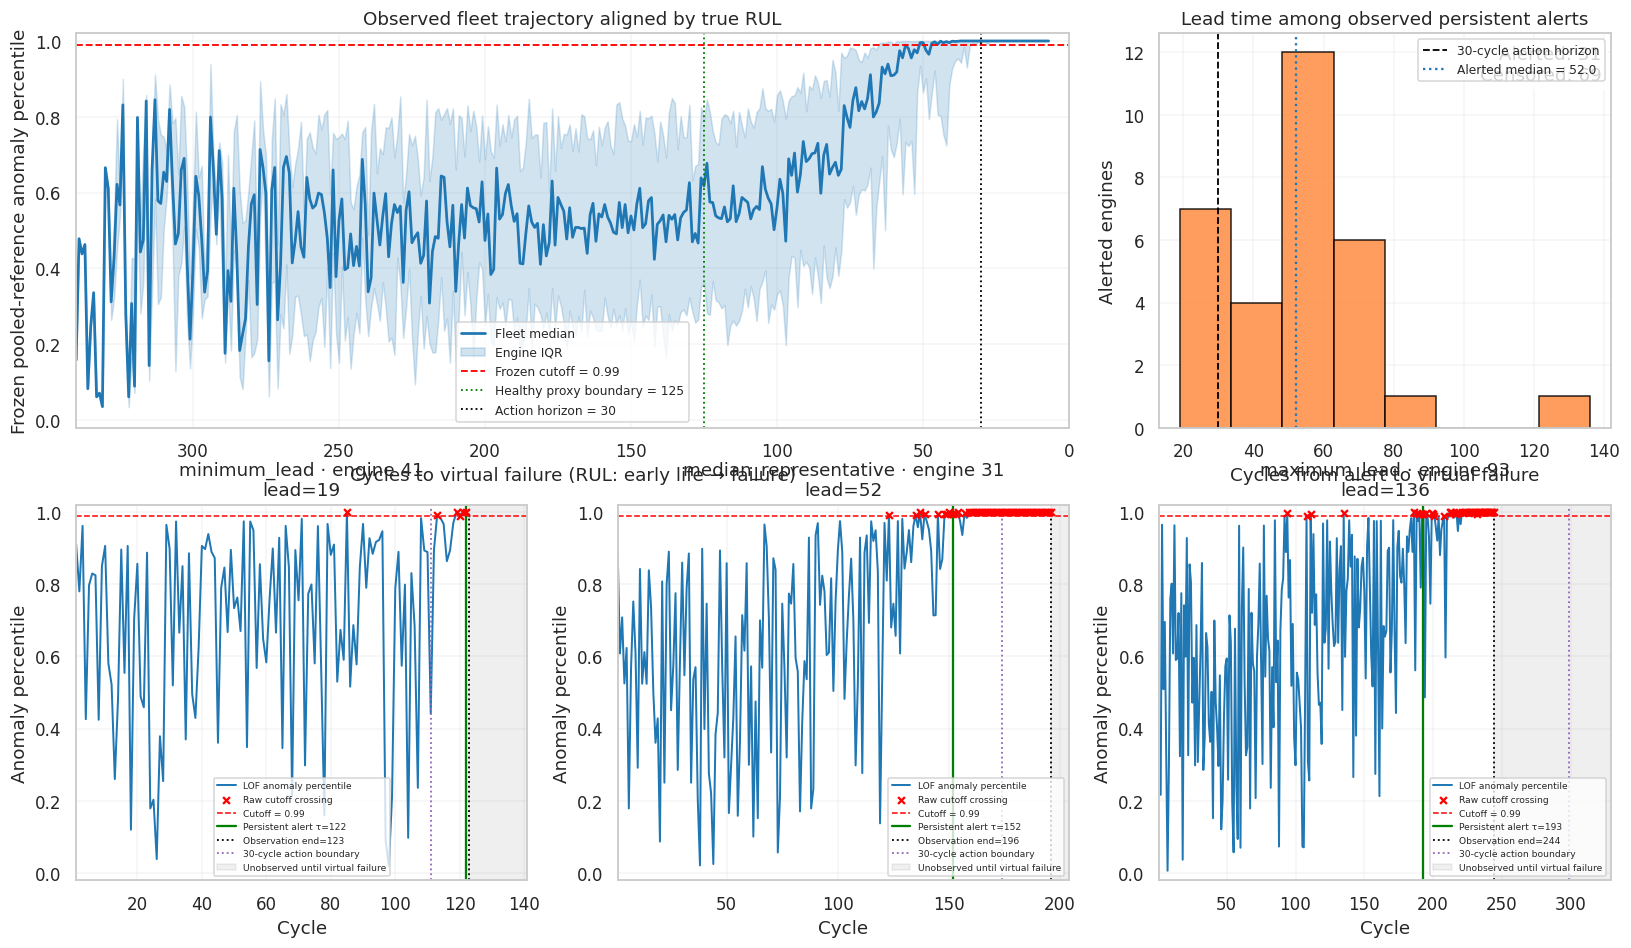

In [180]:
trace_selection = pd.DataFrame(
    [
        {
            **minimum_row.to_dict(),
            "trace_role": "minimum_lead",
        },
        {
            **median_row.to_dict(),
            "trace_role": "median_representative",
        },
        {
            **maximum_row.to_dict(),
            "trace_role": "maximum_lead",
        },
    ]
)

trace_selection = trace_selection[
    [
        "trace_role",
        "engine_id",
        "observation_end_cycle",
        "virtual_failure_cycle",
        "tau_reconstructed",
        "lead_time_to_virtual_failure",
        "censoring_status",
    ]
]

assert len(trace_selection) == 3
assert trace_selection["engine_id"].nunique() == 3





fig = plt.figure(figsize=(18, 10))
grid = fig.add_gridspec(
    2,
    3,
    height_ratios=[1.05, 1.0],
)

fleet_ax = fig.add_subplot(grid[0, :2])
lead_ax = fig.add_subplot(grid[0, 2])
trace_axes = [
    fig.add_subplot(grid[1, column])
    for column in range(3)
]


fleet_ax.plot(
    fleet_by_rul["RUL"],
    fleet_by_rul["percentile_median"],
    color="#1f77b4",
    linewidth=1.8,
    label="Fleet median",
)
fleet_ax.fill_between(
    fleet_by_rul["RUL"],
    fleet_by_rul["percentile_q25"],
    fleet_by_rul["percentile_q75"],
    color="#1f77b4",
    alpha=0.20,
    label="Engine IQR",
)
fleet_ax.axhline(
    cutoff,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Frozen cutoff = {cutoff:.2f}",
)
fleet_ax.axvline(
    125,
    color="green",
    linestyle=":",
    linewidth=1.2,
    label="Healthy proxy boundary = 125",
)
fleet_ax.axvline(
    30,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="Action horizon = 30",
)

maximum_observed_rul = float(
    fleet_by_rul["RUL"].max()
)
fleet_ax.set_xlim(maximum_observed_rul, 0.0)
fleet_ax.set_ylim(-0.02, 1.02)

assert fleet_ax.get_xlim()[0] > fleet_ax.get_xlim()[1]

fleet_ax.set_title(
    "Observed fleet trajectory aligned by true RUL"
)
fleet_ax.set_xlabel(
    "Cycles to virtual failure (RUL: early life → failure)"
)
fleet_ax.set_ylabel(
    "Frozen pooled-reference anomaly percentile"
)
fleet_ax.grid(alpha=0.2)
fleet_ax.legend(fontsize=8, loc="best")


lead_values = alerted_engines[
    "lead_time_to_virtual_failure"
].to_numpy(float)

lead_ax.hist(
    lead_values,
    bins="auto",
    color="#ff8c42",
    edgecolor="black",
    alpha=0.85,
)
lead_ax.axvline(
    30,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="30-cycle action horizon",
)
lead_ax.axvline(
    np.median(lead_values),
    color="#1f77b4",
    linestyle=":",
    linewidth=1.5,
    label=(
        "Alerted median = "
        f"{np.median(lead_values):.1f}"
    ),
)
lead_ax.set_title(
    "Lead time among observed persistent alerts"
)
lead_ax.set_xlabel(
    "Cycles from alert to virtual failure"
)
lead_ax.set_ylabel("Alerted engines")
lead_ax.grid(alpha=0.2)
lead_ax.legend(fontsize=8)

lead_ax.text(
    0.98,
    0.97,
    (
        f"Alerted: {len(alerted_engines)}\n"
        f"Censored: {100 - len(alerted_engines)}"
    ),
    transform=lead_ax.transAxes,
    ha="right",
    va="top",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.8,
    },
)


for ax, selected in zip(
    trace_axes,
    trace_selection.itertuples(index=False),
):
    engine_id = int(selected.engine_id)

    trace = (
        timeline_reconstructed.loc[
            timeline_reconstructed[engine_col]
            == engine_id
        ]
        .sort_values(cycle_col)
        .copy()
    )

    cycles = trace[cycle_col].to_numpy(int)
    values = trace[percentile_col].to_numpy(float)
    crossings = trace[
        "raw_crossing_reconstructed"
    ].to_numpy(bool)

    tau = float(selected.tau_reconstructed)
    observation_end = int(
        selected.observation_end_cycle
    )
    failure_cycle = float(
        selected.virtual_failure_cycle
    )
    action_start = failure_cycle - 30.0

    ax.plot(
        cycles,
        values,
        color="#1f77b4",
        linewidth=1.3,
        label="LOF anomaly percentile",
    )
    ax.scatter(
        cycles[crossings],
        values[crossings],
        color="red",
        marker="x",
        s=20,
        label="Raw cutoff crossing",
        zorder=3,
    )
    ax.axhline(
        cutoff,
        color="red",
        linestyle="--",
        linewidth=1.0,
        label=f"Cutoff = {cutoff:.2f}",
    )
    ax.axvline(
        tau,
        color="green",
        linewidth=1.5,
        label=f"Persistent alert τ={tau:.0f}",
    )
    ax.axvline(
        observation_end,
        color="black",
        linestyle=":",
        linewidth=1.2,
        label=f"Observation end={observation_end}",
    )
    ax.axvline(
        action_start,
        color="#9467bd",
        linestyle=":",
        linewidth=1.2,
        label="30-cycle action boundary",
    )

    if failure_cycle > observation_end:
        ax.axvspan(
            observation_end,
            failure_cycle,
            color="gray",
            alpha=0.12,
            label="Unobserved until virtual failure",
        )

    ax.set_xlim(
        max(1, int(cycles.min())),
        failure_cycle,
    )
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(
        f"{selected.trace_role} · engine {engine_id}\n"
        f"lead={selected.lead_time_to_virtual_failure:.0f}"
    )
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Anomaly percentile")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=6, loc="best")


In [181]:
fig.suptitle(
    (
        f"{SUBSET} Official-Test Anomaly Diagnostics — "
        f"LOF, cutoff={cutoff:.2f}, "
        f"persistent {m_required}-of-{window_size}"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()





fleet_by_rul.to_csv(
    fleet_output_path,
    index=False,
)
trace_selection.to_csv(
    trace_selection_path,
    index=False,
)

fleet_reload = pd.read_csv(fleet_output_path)
trace_reload = pd.read_csv(trace_selection_path)

bundle_sha_after = sha256_file(policy_bundle_path)

check_rows = [
    {
        "check": "timeline_has_100_engines",
        "passed": timeline[engine_col].nunique() == 100,
    },
    {
        "check": "alerted_plus_censored_equals_100",
        "passed": len(engine_reconstructed) == 100,
    },
    {
        "check": "persistent_tau_reconstruction_parity",
        "passed": tau_parity,
    },
    {
        "check": "fleet_percentiles_finite_and_bounded",
        "passed": bool(
            np.isfinite(
                fleet_by_rul[
                    [
                        "percentile_q25",
                        "percentile_median",
                        "percentile_q75",
                    ]
                ].to_numpy(float)
            ).all()
            and (
                fleet_by_rul[
                    [
                        "percentile_q25",
                        "percentile_median",
                        "percentile_q75",
                    ]
                ].to_numpy(float)
                >= 0
            ).all()
            and (
                fleet_by_rul[
                    [
                        "percentile_q25",
                        "percentile_median",
                        "percentile_q75",
                    ]
                ].to_numpy(float)
                <= 1
            ).all()
        ),
    },
    {
        "check": "three_unique_trace_engines",
        "passed": (
            len(trace_selection) == 3
            and trace_selection["engine_id"].nunique() == 3
        ),
    },
    {
        "check": "fleet_axis_early_life_left",
        "passed": (
            fleet_ax.get_xlim()[0]
            > fleet_ax.get_xlim()[1]
        ),
    },
    {
        "check": "anomaly_bundle_unchanged",
        "passed": bundle_sha_before == bundle_sha_after,
    },
    {
        "check": "fleet_csv_shape_parity",
        "passed": fleet_reload.shape == fleet_by_rul.shape,
    },
    {
        "check": "fleet_csv_numeric_parity",
        "passed": np.allclose(
            fleet_reload[
                [
                    "RUL",
                    "percentile_q25",
                    "percentile_median",
                    "percentile_q75",
                ]
            ].to_numpy(float),
            fleet_by_rul[
                [
                    "RUL",
                    "percentile_q25",
                    "percentile_median",
                    "percentile_q75",
                ]
            ].to_numpy(float),
            rtol=0.0,
            atol=1e-12,
        ),
    },
    {
        "check": "trace_csv_shape_parity",
        "passed": trace_reload.shape == trace_selection.shape,
    },
    {
        "check": "trace_engine_order_parity",
        "passed": np.array_equal(
            trace_reload["engine_id"].to_numpy(int),
            trace_selection["engine_id"].to_numpy(int),
        ),
    },
    {
        "check": "diagnostic_figure_exists",
        "passed": (
            figure_path.exists()
            and figure_path.stat().st_size > 0
        ),
    },
]

diagnostic_checks = pd.DataFrame(check_rows)

assert diagnostic_checks["passed"].all(), (
    diagnostic_checks.loc[
        ~diagnostic_checks["passed"]
    ]
)

print(" COMPUTED OFFICIAL-TEST ANOMALY DIAGNOSTIC CHECKS ")
display(diagnostic_checks)

print("\n SELECTED OFFICIAL-TEST TRACE ENGINES ")
display(trace_selection)

print("\n OFFICIAL-TEST ANOMALY DIAGNOSTIC SUMMARY ")
print("Observed Test engines:", len(engine_reconstructed))
print("Alerted before observation end:", len(alerted_engines))
print(
    "Censored without alert by observation end:",
    len(engine_reconstructed) - len(alerted_engines),
)
print(
    "Median lead time among alerted:",
    float(np.median(lead_values)),
)
print("Executed checks:", len(diagnostic_checks))
print(
    "Failed checks:",
    int((~diagnostic_checks["passed"]).sum()),
)
print("Overall diagnostic status: PASS")
print("Saved fleet trajectory:", fleet_output_path)
print("Saved trace selection:", trace_selection_path)

 COMPUTED OFFICIAL-TEST ANOMALY DIAGNOSTIC CHECKS 


,check,passed
0,timeline_has_100_engines,True
1,alerted_plus_censored_equals_100,True
2,persistent_tau_reconstruction_parity,True
3,fleet_percentiles_finite_and_bounded,True
4,three_unique_trace_engines,True
5,fleet_axis_early_life_left,True
6,anomaly_bundle_unchanged,True
7,fleet_csv_shape_parity,True
8,fleet_csv_numeric_parity,True
9,trace_csv_shape_parity,True



 SELECTED OFFICIAL-TEST TRACE ENGINES 


,trace_role,engine_id,observation_end_cycle,virtual_failure_cycle,tau_reconstructed,lead_time_to_virtual_failure,censoring_status
0,minimum_lead,41,123,141.0,122.0,19.0,ALERTED_BEFORE_OBSERVATION_END
1,median_representative,31,196,204.0,152.0,52.0,ALERTED_BEFORE_OBSERVATION_END
2,maximum_lead,93,244,329.0,193.0,136.0,ALERTED_BEFORE_OBSERVATION_END



 OFFICIAL-TEST ANOMALY DIAGNOSTIC SUMMARY 
Observed Test engines: 100
Alerted before observation end: 31
Censored without alert by observation end: 69
Median lead time among alerted: 52.0
Executed checks: 12
Failed checks: 0
Overall diagnostic status: PASS
Saved fleet trajectory: artifacts/results/FD001_official_test_anomaly_fleet_by_rul.csv
Saved trace selection: artifacts/results/FD001_official_test_anomaly_trace_engines.csv


### Freeze deterministic integrated CONTINUE / INSPECT / STOP contract

This is a post-unseal system-integration rule.
It is NOT selected or optimized using Official-Test outcomes.


In [182]:
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import pandas as pd





PROCESSED_DIR = Path(config.DATA_PROCESSED)
MODEL_DIR = Path(config.MODELS_DIR)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

regression_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_regression_bundle.joblib"
)
conformal_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_rul_conformal.json"
)
classification_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_classification_bundle.joblib"
)
classification_threshold_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_thresholds.json"
)
anomaly_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_policy_bundle.joblib"
)
anomaly_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.json"
)

integrated_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_integrated_recommendation_contract.json"
)
integrated_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_integrated_recommendation_contract.sha256"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


source_paths = {
    "regression_bundle": regression_bundle_path,
    "rul_conformal_contract": conformal_contract_path,
    "classification_bundle": classification_bundle_path,
    "classification_threshold_contract": (
        classification_threshold_path
    ),
    "anomaly_policy_bundle": anomaly_bundle_path,
    "anomaly_policy_contract": anomaly_contract_path,
}

for artifact_name, artifact_path in source_paths.items():
    assert artifact_path.exists(), (
        f"Missing source artifact: "
        f"{artifact_name} -> {artifact_path}"
    )

source_hashes_before = {
    name: sha256_file(path)
    for name, path in source_paths.items()
}





regression_bundle = joblib.load(
    regression_bundle_path
)
classification_bundle = joblib.load(
    classification_bundle_path
)
anomaly_bundle = joblib.load(
    anomaly_bundle_path
)

conformal_contract = json.loads(
    conformal_contract_path.read_text(
        encoding="utf-8"
    )
)
classification_threshold_contract = json.loads(
    classification_threshold_path.read_text(
        encoding="utf-8"
    )
)
anomaly_contract = json.loads(
    anomaly_contract_path.read_text(
        encoding="utf-8"
    )
)





assert regression_bundle["subset"] == SUBSET
assert classification_bundle["subset"] == SUBSET
assert anomaly_bundle["subset"] == SUBSET

def normalize_status(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )


component_test_statuses = {
    "regression": normalize_status(
        regression_bundle.get("official_test_status")
    ),
    "classification": normalize_status(
        classification_bundle.get("official_test_status")
    ),
    "anomaly": normalize_status(
        anomaly_bundle.get("official_test_status")
    ),
}

assert component_test_statuses == {
    "regression": "sealed",
    "classification": "sealed",
    "anomaly": "sealed",
}, component_test_statuses

assert classification_bundle["threshold_status"] == (
    "selected_on_val_calib"
)

thresholds = {
    int(horizon): float(value)
    for horizon, value in
    classification_bundle["thresholds"].items()
}

assert set(thresholds) == {10, 20, 30}

contract_thresholds = {
    int(horizon): float(value)
    for horizon, value in
    classification_threshold_contract[
        "primary_thresholds"
    ].items()
}

assert thresholds == contract_thresholds

selected_anomaly_policy = (
    anomaly_bundle["selected_overall_policy"]
)

assert selected_anomaly_policy["family"] == "lof"
assert float(selected_anomaly_policy["cutoff"]) == 0.99
assert int(selected_anomaly_policy["m"]) == 5
assert int(selected_anomaly_policy["n"]) == 10
assert selected_anomaly_policy["reference_type"] == "pooled"

conformal_quantile = float(
    conformal_contract["residual_quantile"]
)
conformal_coverage_target = float(
    conformal_contract["coverage_target"]
)

assert conformal_quantile > 0
assert 0 < conformal_coverage_target < 1










integrated_contract = {
    "artifact_type": (
        "integrated_maintenance_recommendation_contract"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "governance": {
        "creation_phase": (
            "post_official_test_unseal_system_integration"
        ),
        "test_outcome_optimization_performed": False,
        "model_refitting_performed": False,
        "probability_recalibration_performed": False,
        "threshold_reselection_performed": False,
        "anomaly_policy_reselection_performed": False,
        "allowed_use": [
            "dashboard recommendation",
            "application integration",
            "descriptive Official-Test recommendation counts",
        ],
        "independent_preregistered_combined_policy": False,
        "interpretation": (
            "The component models and thresholds were frozen "
            "before Official-Test access. The deterministic rule "
            "combining their outputs was documented after unseal "
            "and must not be presented as a preregistered combined "
            "policy selected independently of Test visibility."
        ),
    },
    "recommendation_levels": [
        "CONTINUE",
        "INSPECT",
        "STOP",
    ],
    "priority_order": [
        "STOP",
        "INSPECT",
        "CONTINUE",
    ],
    "input_contract": {
        "regression": {
            "point_estimate": "predicted_RUL",
            "lower_bound": "conformal_lower",
            "upper_bound": "conformal_upper",
            "coverage_target": conformal_coverage_target,
            "frozen_residual_quantile": conformal_quantile,
        },
        "classification": {
            "probability_stage": (
                "Platt plus cumulative-max monotonicity"
            ),
            "horizons": [10, 20, 30],
            "thresholds": {
                str(horizon): thresholds[horizon]
                for horizon in (10, 20, 30)
            },
            "decision_rule": (
                "mono_probability >= frozen_threshold"
            ),
        },
        "anomaly": {
            "family": selected_anomaly_policy["family"],
            "candidate_id": (
                selected_anomaly_policy["candidate_id"]
            ),
            "reference_type": (
                selected_anomaly_policy["reference_type"]
            ),
            "cutoff": float(
                selected_anomaly_policy["cutoff"]
            ),
            "persistence": {
                "m": int(selected_anomaly_policy["m"]),
                "n": int(selected_anomaly_policy["n"]),
                "cycle_gap_reset": True,
                "alert_latching": True,
            },
        },
    },
    "action_horizons_cycles": {
        "urgent_stop": 10,
        "inspection": 30,
    },
    "rules": {
        "STOP": {
            "priority": 1,
            "operator": "ANY",
            "conditions": [
                {
                    "field": "classification_decision_h10",
                    "operator": "==",
                    "value": 1,
                    "reason_code": "CLASSIFICATION_H10_POSITIVE",
                },
                {
                    "field": "predicted_RUL",
                    "operator": "<=",
                    "value": 10.0,
                    "reason_code": "REGRESSION_POINT_RUL_LE_10",
                },
            ],
        },
        "INSPECT": {
            "priority": 2,
            "applies_only_if": "STOP is false",
            "operator": "ANY",
            "conditions": [
                {
                    "field": "classification_decision_h20",
                    "operator": "==",
                    "value": 1,
                    "reason_code": "CLASSIFICATION_H20_POSITIVE",
                },
                {
                    "field": "classification_decision_h30",
                    "operator": "==",
                    "value": 1,
                    "reason_code": "CLASSIFICATION_H30_POSITIVE",
                },
                {
                    "field": "conformal_lower",
                    "operator": "<=",
                    "value": 30.0,
                    "reason_code": "RUL_INTERVAL_REACHES_30",
                },
                {
                    "field": "persistent_anomaly_alert",
                    "operator": "==",
                    "value": 1,
                    "reason_code": "PERSISTENT_ANOMALY_ALERT",
                },
            ],
        },
        "CONTINUE": {
            "priority": 3,
            "applies_only_if": (
                "STOP is false and INSPECT is false"
            ),
            "reason_code": "NO_FROZEN_WARNING_RULE_ACTIVE",
        },
    },
    "reason_reporting": {
        "retain_all_triggered_reasons": True,
        "primary_reason_order": [
            "CLASSIFICATION_H10_POSITIVE",
            "REGRESSION_POINT_RUL_LE_10",
            "CLASSIFICATION_H20_POSITIVE",
            "CLASSIFICATION_H30_POSITIVE",
            "RUL_INTERVAL_REACHES_30",
            "PERSISTENT_ANOMALY_ALERT",
            "NO_FROZEN_WARNING_RULE_ACTIVE",
        ],
    },
    "source_artifacts": {
        name: {
            "path": str(path),
            "sha256": source_hashes_before[name],
        }
        for name, path in source_paths.items()
    },
    "official_test_inputs_used_to_create_rule": [],
    "status": "FROZEN_FOR_APPLICATION_INTEGRATION",
}


In [183]:
integrated_contract_path.write_text(
    json.dumps(
        integrated_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

integrated_contract_sha = sha256_file(
    integrated_contract_path
)

sidecar = {
    "file": str(integrated_contract_path),
    "sha256": integrated_contract_sha,
}

integrated_sidecar_path.write_text(
    json.dumps(
        sidecar,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

contract_reload = json.loads(
    integrated_contract_path.read_text(
        encoding="utf-8"
    )
)
sidecar_reload = json.loads(
    integrated_sidecar_path.read_text(
        encoding="utf-8"
    )
)

source_hashes_after = {
    name: sha256_file(path)
    for name, path in source_paths.items()
}





official_test_named_sources = [
    name
    for name, path in source_paths.items()
    if "official_test" in path.name.lower()
]

check_rows = [
    {
        "check": "all_source_artifacts_exist",
        "passed": all(
            path.exists()
            for path in source_paths.values()
        ),
    },
    {
        "check": "all_source_artifacts_unchanged",
        "passed": (
            source_hashes_before
            == source_hashes_after
        ),
    },
    {
        "check": "component_bundles_created_while_test_sealed",
        "passed": (
            component_test_statuses
            == {
                "regression": "sealed",
                "classification": "sealed",
                "anomaly": "sealed",
            }
        ),
    },
    {
        "check": "classification_thresholds_match_contract",
        "passed": thresholds == contract_thresholds,
    },
    {
        "check": "anomaly_policy_matches_frozen_bundle",
        "passed": (
            selected_anomaly_policy["family"] == "lof"
            and float(
                selected_anomaly_policy["cutoff"]
            ) == 0.99
            and int(selected_anomaly_policy["m"]) == 5
            and int(selected_anomaly_policy["n"]) == 10
        ),
    },
    {
        "check": "recommendation_levels_exact",
        "passed": (
            integrated_contract[
                "recommendation_levels"
            ]
            == ["CONTINUE", "INSPECT", "STOP"]
        ),
    },
    {
        "check": "priority_order_exact",
        "passed": (
            integrated_contract["priority_order"]
            == ["STOP", "INSPECT", "CONTINUE"]
        ),
    },
    {
        "check": "no_official_test_artifact_used_as_rule_source",
        "passed": len(official_test_named_sources) == 0,
    },
    {
        "check": "test_outcome_optimization_declared_false",
        "passed": (
            integrated_contract["governance"][
                "test_outcome_optimization_performed"
            ]
            is False
        ),
    },
    {
        "check": "combined_policy_not_claimed_preregistered",
        "passed": (
            integrated_contract["governance"][
                "independent_preregistered_combined_policy"
            ]
            is False
        ),
    },
    {
        "check": "contract_reload_exact",
        "passed": contract_reload == integrated_contract,
    },
    {
        "check": "contract_hash_valid",
        "passed": (
            sha256_file(integrated_contract_path)
            == sidecar_reload["sha256"]
            == integrated_contract_sha
        ),
    },
]

integrated_contract_checks = pd.DataFrame(
    check_rows
)

assert integrated_contract_checks["passed"].all(), (
    integrated_contract_checks.loc[
        ~integrated_contract_checks["passed"]
    ]
)

print(" COMPUTED INTEGRATED RECOMMENDATION CONTRACT CHECKS ")
display(integrated_contract_checks)

print("\n FROZEN INTEGRATED RECOMMENDATION CONTRACT ")
print("Priority:", "STOP > INSPECT > CONTINUE")
print(
    "Classification thresholds:",
    thresholds,
)
print(
    "Anomaly policy:",
    {
        "family": selected_anomaly_policy["family"],
        "candidate_id": (
            selected_anomaly_policy["candidate_id"]
        ),
        "cutoff": float(
            selected_anomaly_policy["cutoff"]
        ),
        "persistence": (
            int(selected_anomaly_policy["m"]),
            int(selected_anomaly_policy["n"]),
        ),
    },
)
print(
    "Governance status:",
    integrated_contract["governance"]["creation_phase"],
)
print(
    "Official-Test artifacts used as rule sources:",
    official_test_named_sources,
)
print("Executed checks:", len(integrated_contract_checks))
print(
    "Failed checks:",
    int(
        (~integrated_contract_checks["passed"]).sum()
    ),
)
print(
    "Normalized component Test statuses:",
    component_test_statuses,
)
print("Overall contract status: PASS")
print("Saved contract:", integrated_contract_path)
print("Saved integrity sidecar:", integrated_sidecar_path)
print("Contract SHA256:", integrated_contract_sha)


 COMPUTED INTEGRATED RECOMMENDATION CONTRACT CHECKS 


,check,passed
0,all_source_artifacts_exist,True
1,all_source_artifacts_unchanged,True
2,component_bundles_created_while_test_sealed,True
3,classification_thresholds_match_contract,True
4,anomaly_policy_matches_frozen_bundle,True
5,recommendation_levels_exact,True
6,priority_order_exact,True
7,no_official_test_artifact_used_as_rule_source,True
8,test_outcome_optimization_declared_false,True
9,combined_policy_not_claimed_preregistered,True



 FROZEN INTEGRATED RECOMMENDATION CONTRACT 
Priority: STOP > INSPECT > CONTINUE
Classification thresholds: {10: 0.11340399728926802, 20: 0.22290462955112206, 30: 0.11654045954796569}
Anomaly policy: {'family': 'lof', 'candidate_id': 'lof_k50', 'cutoff': 0.99, 'persistence': (5, 10)}
Governance status: post_official_test_unseal_system_integration
Official-Test artifacts used as rule sources: []
Executed checks: 12
Failed checks: 0
Normalized component Test statuses: {'regression': 'sealed', 'classification': 'sealed', 'anomaly': 'sealed'}
Overall contract status: PASS
Saved contract: data/processed/FD001_integrated_recommendation_contract.json
Saved integrity sidecar: data/processed/FD001_integrated_recommendation_contract.sha256
Contract SHA256: 4c5cfe7649c252b0ee1ed27480e8b1ce8fa2766adec17542f9d88f3cdf52678d


### Apply frozen integrated recommendation contract to Official Test

No fitting, recalibration, threshold selection, or policy optimization.


In [184]:
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd





RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_integrated_recommendation_contract.json"
)
contract_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_integrated_recommendation_contract.sha256"
)

regression_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_regression_predictions.csv"
)
classification_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_classification_predictions.csv"
)
anomaly_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_anomaly_timelines.csv"
)

row_output_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_integrated_recommendations.csv"
)
final_output_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_integrated_final_recommendations.csv"
)
summary_output_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_integrated_recommendation_summary.csv"
)
reason_output_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_integrated_reason_summary.csv"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def resolve_column(frame, candidates, label):
    matches = [
        column
        for column in candidates
        if column in frame.columns
    ]

    assert matches, (
        f"Cannot resolve {label}. "
        f"Tried={candidates}; "
        f"available={list(frame.columns)}"
    )

    return matches[0]


def optional_column(frame, candidates):
    return next(
        (
            column
            for column in candidates
            if column in frame.columns
        ),
        None,
    )


def to_boolean(values):
    series = pd.Series(values)

    if pd.api.types.is_bool_dtype(series):
        return series.to_numpy(bool)

    if pd.api.types.is_numeric_dtype(series):
        return series.to_numpy(float) != 0.0

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    allowed = {
        "true",
        "false",
        "1",
        "0",
        "yes",
        "no",
    }

    assert set(normalized.unique()).issubset(allowed)

    return normalized.isin(
        ["true", "1", "yes"]
    ).to_numpy(bool)


def condition_value(contract, action, reason_code):
    matches = [
        condition
        for condition in contract["rules"][action][
            "conditions"
        ]
        if condition["reason_code"] == reason_code
    ]

    assert len(matches) == 1, (
        action,
        reason_code,
        matches,
    )

    return matches[0]["value"]





contract = json.loads(
    contract_path.read_text(encoding="utf-8")
)
sidecar = json.loads(
    contract_sidecar_path.read_text(
        encoding="utf-8"
    )
)

contract_sha = sha256_file(contract_path)

assert contract_sha == sidecar["sha256"]
assert contract["subset"] == SUBSET
assert contract["status"] == (
    "FROZEN_FOR_APPLICATION_INTEGRATION"
)
assert contract["priority_order"] == [
    "STOP",
    "INSPECT",
    "CONTINUE",
]
assert contract["governance"][
    "test_outcome_optimization_performed"
] is False

expected_levels = {
    "CONTINUE",
    "INSPECT",
    "STOP",
}





source_paths = {
    "integrated_contract": contract_path,
    "regression_predictions": regression_path,
    "classification_predictions": classification_path,
    "anomaly_timelines": anomaly_path,
}

for name, path in source_paths.items():
    assert path.exists(), f"{name}: missing {path}"

source_hashes_before = {
    name: sha256_file(path)
    for name, path in source_paths.items()
}

regression = pd.read_csv(regression_path)
classification = pd.read_csv(classification_path)
anomaly = pd.read_csv(anomaly_path)





reg_engine = resolve_column(
    regression,
    ["engine_id"],
    "regression engine ID",
)
reg_cycle = resolve_column(
    regression,
    ["cycle"],
    "regression cycle",
)


In [185]:
reg_prediction = resolve_column(
    regression,
    [
        "predicted_RUL",
        "predicted_rul",
        "rul_prediction",
        "prediction",
    ],
    "RUL point prediction",
)
reg_lower = resolve_column(
    regression,
    [
        "conformal_lower",
        "rul_lower",
        "lower_bound",
        "prediction_lower",
    ],
    "RUL conformal lower bound",
)
reg_upper = resolve_column(
    regression,
    [
        "conformal_upper",
        "rul_upper",
        "upper_bound",
        "prediction_upper",
    ],
    "RUL conformal upper bound",
)





clf_engine = resolve_column(
    classification,
    ["engine_id"],
    "classification engine ID",
)
clf_cycle = resolve_column(
    classification,
    ["cycle"],
    "classification cycle",
)

decision_columns = {
    horizon: resolve_column(
        classification,
        [
            f"dec_h{horizon}",
            f"decision_h{horizon}",
            f"pred_h{horizon}",
        ],
        f"h{horizon} classification decision",
    )
    for horizon in (10, 20, 30)
}

probability_columns = {
    horizon: resolve_column(
        classification,
        [
            f"mono_h{horizon}",
            f"monotone_h{horizon}",
            f"probability_h{horizon}",
        ],
        f"h{horizon} monotone probability",
    )
    for horizon in (10, 20, 30)
}





anom_engine = resolve_column(
    anomaly,
    ["engine_id"],
    "anomaly engine ID",
)
anom_cycle = resolve_column(
    anomaly,
    ["cycle"],
    "anomaly cycle",
)
anom_rul = resolve_column(
    anomaly,
    ["RUL", "rul"],
    "anomaly true RUL",
)
anom_percentile = resolve_column(
    anomaly,
    [
        "anomaly_percentile",
        "pooled_reference_percentile",
        "percentile",
    ],
    "anomaly percentile",
)

saved_persistent_column = optional_column(
    anomaly,
    [
        "persistent_alert",
        "persistent_alert_latched",
        "persistent_warning",
    ],
)

anomaly_policy = contract["input_contract"]["anomaly"]
anomaly_cutoff = float(anomaly_policy["cutoff"])
persistence_m = int(
    anomaly_policy["persistence"]["m"]
)
persistence_n = int(
    anomaly_policy["persistence"]["n"]
)


def reconstruct_persistence(group):
    group = (
        group
        .sort_values(anom_cycle)
        .copy()
    )

    cycles = group[anom_cycle].to_numpy(int)
    percentiles = group[
        anom_percentile
    ].to_numpy(float)

    crossings = percentiles >= anomaly_cutoff
    persistent_now = np.zeros(
        len(group),
        dtype=bool,
    )

    segment_start = 0

    for position in range(len(group)):
        if (
            position > 0
            and cycles[position]
            != cycles[position - 1] + 1
        ):
            segment_start = position

        window_start = max(
            segment_start,
            position - persistence_n + 1,
        )
        window = crossings[
            window_start : position + 1
        ]

        persistent_now[position] = (
            len(window) >= persistence_m
            and int(window.sum()) >= persistence_m
        )

    group["persistent_anomaly_alert"] = (
        np.maximum.accumulate(
            persistent_now.astype(int)
        )
    )

    return group


anomaly_reconstructed = pd.concat(
    [
        reconstruct_persistence(group)
        for _, group in anomaly.groupby(
            anom_engine,
            sort=True,
        )
    ],
    ignore_index=True,
)

persistent_saved_parity = True

if saved_persistent_column is not None:
    original_persistent = (
        anomaly[
            [
                anom_engine,
                anom_cycle,
                saved_persistent_column,
            ]
        ]
        .copy()
        .rename(
            columns={
                anom_engine: "engine_id",
                anom_cycle: "cycle",
            }
        )
        .sort_values(["engine_id", "cycle"])
        .reset_index(drop=True)
    )

    reconstructed_persistent = (
        anomaly_reconstructed[
            [
                anom_engine,
                anom_cycle,
                "persistent_anomaly_alert",
            ]
        ]
        .copy()
        .rename(
            columns={
                anom_engine: "engine_id",
                anom_cycle: "cycle",
            }
        )
        .sort_values(["engine_id", "cycle"])
        .reset_index(drop=True)
    )

    persistent_saved_parity = bool(
        np.array_equal(
            to_boolean(
                original_persistent[
                    saved_persistent_column
                ]
            ),
            to_boolean(
                reconstructed_persistent[
                    "persistent_anomaly_alert"
                ]
            ),
        )
    )


In [186]:
assert persistent_saved_parity





regression_standard = (
    regression[
        [
            reg_engine,
            reg_cycle,
            reg_prediction,
            reg_lower,
            reg_upper,
        ]
    ]
    .rename(
        columns={
            reg_engine: "engine_id",
            reg_cycle: "cycle",
            reg_prediction: "predicted_RUL",
            reg_lower: "conformal_lower",
            reg_upper: "conformal_upper",
        }
    )
)

classification_standard = (
    classification[
        [
            clf_engine,
            clf_cycle,
            probability_columns[10],
            probability_columns[20],
            probability_columns[30],
            decision_columns[10],
            decision_columns[20],
            decision_columns[30],
        ]
    ]
    .rename(
        columns={
            clf_engine: "engine_id",
            clf_cycle: "cycle",
            probability_columns[10]: "mono_probability_h10",
            probability_columns[20]: "mono_probability_h20",
            probability_columns[30]: "mono_probability_h30",
            decision_columns[10]: "classification_decision_h10",
            decision_columns[20]: "classification_decision_h20",
            decision_columns[30]: "classification_decision_h30",
        }
    )
)

anomaly_standard = (
    anomaly_reconstructed[
        [
            anom_engine,
            anom_cycle,
            anom_rul,
            anom_percentile,
            "persistent_anomaly_alert",
        ]
    ]
    .rename(
        columns={
            anom_engine: "engine_id",
            anom_cycle: "cycle",
            anom_rul: "true_RUL",
            anom_percentile: "anomaly_percentile",
        }
    )
)





for frame, label in [
    (regression_standard, "regression"),
    (classification_standard, "classification"),
    (anomaly_standard, "anomaly"),
]:
    assert not frame.duplicated(
        ["engine_id", "cycle"]
    ).any(), label
    assert frame["engine_id"].nunique() == 100
    assert len(frame) == 13096

regression_keys = set(
    map(
        tuple,
        regression_standard[
            ["engine_id", "cycle"]
        ].to_numpy(),
    )
)
classification_keys = set(
    map(
        tuple,
        classification_standard[
            ["engine_id", "cycle"]
        ].to_numpy(),
    )
)
anomaly_keys = set(
    map(
        tuple,
        anomaly_standard[
            ["engine_id", "cycle"]
        ].to_numpy(),
    )
)

assert (
    regression_keys
    == classification_keys
    == anomaly_keys
)

integrated = (
    regression_standard
    .merge(
        classification_standard,
        on=["engine_id", "cycle"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        anomaly_standard,
        on=["engine_id", "cycle"],
        how="inner",
        validate="one_to_one",
    )
    .sort_values(["engine_id", "cycle"])
    .reset_index(drop=True)
)

assert len(integrated) == 13096
assert integrated["engine_id"].nunique() == 100





stop_rul_threshold = float(
    condition_value(
        contract,
        "STOP",
        "REGRESSION_POINT_RUL_LE_10",
    )
)
inspect_rul_threshold = float(
    condition_value(
        contract,
        "INSPECT",
        "RUL_INTERVAL_REACHES_30",
    )
)

assert stop_rul_threshold == 10.0
assert inspect_rul_threshold == 30.0





dec10 = (
    integrated[
        "classification_decision_h10"
    ].to_numpy(int)
    == 1
)
dec20 = (
    integrated[
        "classification_decision_h20"
    ].to_numpy(int)
    == 1
)
dec30 = (
    integrated[
        "classification_decision_h30"
    ].to_numpy(int)
    == 1
)

rul_stop = (
    integrated["predicted_RUL"].to_numpy(float)
    <= stop_rul_threshold
)
rul_inspect = (
    integrated["conformal_lower"].to_numpy(float)
    <= inspect_rul_threshold
)
anomaly_alert = (
    integrated[
        "persistent_anomaly_alert"
    ].to_numpy(int)
    == 1
)

stop_mask = dec10 | rul_stop
inspect_signal = (
    dec20
    | dec30
    | rul_inspect
    | anomaly_alert
)
inspect_mask = (~stop_mask) & inspect_signal
continue_mask = (~stop_mask) & (~inspect_mask)

recommendations = np.full(
    len(integrated),
    "CONTINUE",
    dtype=object,
)
recommendations[inspect_mask] = "INSPECT"
recommendations[stop_mask] = "STOP"

integrated["recommendation"] = recommendations


In [187]:
reason_order = contract[
    "reason_reporting"
]["primary_reason_order"]

reason_masks = {
    "CLASSIFICATION_H10_POSITIVE": dec10,
    "REGRESSION_POINT_RUL_LE_10": rul_stop,
    "CLASSIFICATION_H20_POSITIVE": dec20,
    "CLASSIFICATION_H30_POSITIVE": dec30,
    "RUL_INTERVAL_REACHES_30": rul_inspect,
    "PERSISTENT_ANOMALY_ALERT": anomaly_alert,
}

all_reasons = []
primary_reasons = []

for row_position in range(len(integrated)):
    active = [
        reason
        for reason in reason_order
        if (
            reason
            in reason_masks
            and reason_masks[reason][row_position]
        )
    ]

    if not active:
        active = [
            "NO_FROZEN_WARNING_RULE_ACTIVE"
        ]

    all_reasons.append("|".join(active))
    primary_reasons.append(active[0])

integrated["primary_reason"] = primary_reasons
integrated["all_triggered_reasons"] = all_reasons

integrated["recommendation_rank"] = (
    integrated["recommendation"].map(
        {
            "CONTINUE": 0,
            "INSPECT": 1,
            "STOP": 2,
        }
    ).astype(int)
)





final_indices = (
    integrated.groupby("engine_id")["cycle"].idxmax()
)

final_recommendations = (
    integrated.loc[final_indices]
    .sort_values("engine_id")
    .reset_index(drop=True)
)

assert len(final_recommendations) == 100
assert final_recommendations[
    "engine_id"
].nunique() == 100





summary_rows = []

for scope, frame in [
    ("all_observed_rows", integrated),
    ("final_snapshot", final_recommendations),
]:
    counts = (
        frame["recommendation"]
        .value_counts()
        .reindex(
            ["CONTINUE", "INSPECT", "STOP"],
            fill_value=0,
        )
    )

    for recommendation in [
        "CONTINUE",
        "INSPECT",
        "STOP",
    ]:
        summary_rows.append(
            {
                "scope": scope,
                "recommendation": recommendation,
                "count": int(
                    counts[recommendation]
                ),
                "fraction": float(
                    counts[recommendation]
                    / len(frame)
                ),
                "n_rows": int(len(frame)),
                "n_engines": int(
                    frame["engine_id"].nunique()
                ),
            }
        )

recommendation_summary = pd.DataFrame(
    summary_rows
)

reason_rows = []

for scope, frame in [
    ("all_observed_rows", integrated),
    ("final_snapshot", final_recommendations),
]:
    counts = frame[
        "primary_reason"
    ].value_counts()

    for reason, count in counts.items():
        reason_rows.append(
            {
                "scope": scope,
                "primary_reason": reason,
                "count": int(count),
                "fraction": float(
                    count / len(frame)
                ),
            }
        )

reason_summary = pd.DataFrame(reason_rows)





integrated.to_csv(
    row_output_path,
    index=False,
)
final_recommendations.to_csv(
    final_output_path,
    index=False,
)
recommendation_summary.to_csv(
    summary_output_path,
    index=False,
)
reason_summary.to_csv(
    reason_output_path,
    index=False,
)

row_reload = pd.read_csv(row_output_path)
final_reload = pd.read_csv(final_output_path)
summary_reload = pd.read_csv(summary_output_path)

source_hashes_after = {
    name: sha256_file(path)
    for name, path in source_paths.items()
}





check_rows = [
    {
        "check": "integrated_contract_hash_valid",
        "passed": (
            sha256_file(contract_path)
            == sidecar["sha256"]
        ),
    },
    {
        "check": "component_prediction_sources_unchanged",
        "passed": (
            source_hashes_before
            == source_hashes_after
        ),
    },
    {
        "check": "all_component_key_sets_equal",
        "passed": (
            regression_keys
            == classification_keys
            == anomaly_keys
        ),
    },
    {
        "check": "exactly_13096_integrated_rows",
        "passed": len(integrated) == 13096,
    },
    {
        "check": "exactly_100_test_engines",
        "passed": (
            integrated["engine_id"].nunique()
            == 100
        ),
    },
    {
        "check": "persistent_anomaly_reconstruction_parity",
        "passed": persistent_saved_parity,
    },
    {
        "check": "recommendation_values_exact",
        "passed": (
            set(
                integrated[
                    "recommendation"
                ].unique()
            ).issubset(expected_levels)
        ),
    },
    {
        "check": "stop_rule_exact",
        "passed": np.array_equal(
            integrated[
                "recommendation"
            ].to_numpy()
            == "STOP",
            stop_mask,
        ),
    },
    {
        "check": "inspect_rule_exact_after_stop_precedence",
        "passed": np.array_equal(
            integrated[
                "recommendation"
            ].to_numpy()
            == "INSPECT",
            inspect_mask,
        ),
    },
    {
        "check": "continue_rule_exact",
        "passed": np.array_equal(
            integrated[
                "recommendation"
            ].to_numpy()
            == "CONTINUE",
            continue_mask,
        ),
    },
    {
        "check": "recommendation_partition_complete",
        "passed": bool(
            np.all(
                stop_mask.astype(int)
                + inspect_mask.astype(int)
                + continue_mask.astype(int)
                == 1
            )
        ),
    },
    {
        "check": "every_row_has_primary_reason",
        "passed": integrated[
            "primary_reason"
        ].notna().all(),
    },
    {
        "check": "every_row_has_triggered_reason_text",
        "passed": (
            integrated[
                "all_triggered_reasons"
            ].astype(str).str.len().gt(0).all()
        ),
    },
    {
        "check": "exactly_100_final_recommendations",
        "passed": (
            len(final_recommendations) == 100
        ),
    },
    {
        "check": "final_rows_are_last_observed_cycles",
        "passed": bool(
            np.array_equal(
                final_recommendations[
                    "cycle"
                ].to_numpy(int),
                integrated.groupby(
                    "engine_id"
                )["cycle"].max().sort_index().to_numpy(int),
            )
        ),
    },
    {
        "check": "summary_counts_reconstruct_scopes",
        "passed": (
            recommendation_summary.loc[
                recommendation_summary["scope"]
                == "all_observed_rows",
                "count",
            ].sum()
            == len(integrated)
            and recommendation_summary.loc[
                recommendation_summary["scope"]
                == "final_snapshot",
                "count",
            ].sum()
            == len(final_recommendations)
        ),
    },
    {
        "check": "row_csv_shape_parity",
        "passed": (
            row_reload.shape == integrated.shape
        ),
    },
    {
        "check": "row_csv_recommendation_parity",
        "passed": np.array_equal(
            row_reload[
                "recommendation"
            ].to_numpy(),
            integrated[
                "recommendation"
            ].to_numpy(),
        ),
    },
    {
        "check": "final_csv_shape_parity",
        "passed": (
            final_reload.shape
            == final_recommendations.shape
        ),
    },
    {
        "check": "final_csv_recommendation_parity",
        "passed": np.array_equal(
            final_reload[
                "recommendation"
            ].to_numpy(),
            final_recommendations[
                "recommendation"
            ].to_numpy(),
        ),
    },
    {
        "check": "summary_csv_numeric_parity",
        "passed": np.allclose(
            summary_reload[
                ["count", "fraction"]
            ].to_numpy(float),
            recommendation_summary[
                ["count", "fraction"]
            ].to_numpy(float),
            rtol=0.0,
            atol=1e-12,
        ),
    },
]


In [188]:
integrated_checks = pd.DataFrame(check_rows)

assert integrated_checks["passed"].all(), (
    integrated_checks.loc[
        ~integrated_checks["passed"]
    ]
)





print(" COMPUTED INTEGRATED RECOMMENDATION CHECKS ")
display(integrated_checks)

print("\n OFFICIAL-TEST INTEGRATED RECOMMENDATION SUMMARY ")
display(recommendation_summary)

print("\n FINAL-SNAPSHOT PRIMARY REASONS ")
display(
    reason_summary.loc[
        reason_summary["scope"]
        == "final_snapshot"
    ].reset_index(drop=True)
)

print("\n FINAL RECOMMENDATION SAMPLE ")
display(
    final_recommendations[
        [
            "engine_id",
            "cycle",
            "true_RUL",
            "predicted_RUL",
            "conformal_lower",
            "conformal_upper",
            "mono_probability_h10",
            "mono_probability_h20",
            "mono_probability_h30",
            "anomaly_percentile",
            "persistent_anomaly_alert",
            "recommendation",
            "primary_reason",
        ]
    ].head(10)
)

print(
    "\nGovernance:",
    contract["governance"]["creation_phase"],
)
print(
    "Test-outcome optimization performed:",
    contract["governance"][
        "test_outcome_optimization_performed"
    ],
)
print("Executed checks:", len(integrated_checks))
print(
    "Failed checks:",
    int((~integrated_checks["passed"]).sum()),
)
print("Overall application status: PASS")
print("Saved row recommendations:", row_output_path)
print("Saved final recommendations:", final_output_path)
print("Saved recommendation summary:", summary_output_path)
print("Saved reason summary:", reason_output_path)


 COMPUTED INTEGRATED RECOMMENDATION CHECKS 


,check,passed
0,integrated_contract_hash_valid,True
1,component_prediction_sources_unchanged,True
2,all_component_key_sets_equal,True
3,exactly_13096_integrated_rows,True
4,exactly_100_test_engines,True
5,persistent_anomaly_reconstruction_parity,True
6,recommendation_values_exact,True
7,stop_rule_exact,True
8,inspect_rule_exact_after_stop_precedence,True
9,continue_rule_exact,True



 OFFICIAL-TEST INTEGRATED RECOMMENDATION SUMMARY 


,scope,recommendation,count,fraction,n_rows,n_engines
0,all_observed_rows,CONTINUE,12078,0.922266,13096,100
1,all_observed_rows,INSPECT,990,0.075596,13096,100
2,all_observed_rows,STOP,28,0.002138,13096,100
3,final_snapshot,CONTINUE,64,0.640000,100,100
4,final_snapshot,INSPECT,26,0.260000,100,100
5,final_snapshot,STOP,10,0.100000,100,100



 FINAL-SNAPSHOT PRIMARY REASONS 


,scope,primary_reason,count,fraction
0,final_snapshot,NO_FROZEN_WARNING_RULE_ACTIVE,64,0.64
1,final_snapshot,CLASSIFICATION_H30_POSITIVE,11,0.11
2,final_snapshot,CLASSIFICATION_H10_POSITIVE,8,0.08
3,final_snapshot,CLASSIFICATION_H20_POSITIVE,7,0.07
4,final_snapshot,PERSISTENT_ANOMALY_ALERT,5,0.05
5,final_snapshot,RUL_INTERVAL_REACHES_30,3,0.03
6,final_snapshot,REGRESSION_POINT_RUL_LE_10,2,0.02



 FINAL RECOMMENDATION SAMPLE 


,engine_id,cycle,true_RUL,predicted_RUL,conformal_lower,conformal_upper,mono_probability_h10,mono_probability_h20,mono_probability_h30,anomaly_percentile,persistent_anomaly_alert,recommendation,primary_reason
0,1,31,112,98.464830,80.051437,116.878223,3.618781e-15,5.502093e-10,0.000002,0.451099,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
1,2,49,98,100.141715,81.728322,118.555108,1.386800e-11,3.491823e-08,0.000035,0.340659,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
2,3,126,69,43.322734,24.909341,61.736128,8.424663e-08,1.013782e-04,0.011149,0.984615,0,INSPECT,RUL_INTERVAL_REACHES_30
3,4,106,82,82.550179,64.136786,100.963573,7.510549e-10,4.275272e-06,0.000704,0.881319,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
4,5,98,91,89.452295,71.038902,107.865689,1.263021e-09,1.491035e-06,0.000311,0.871978,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
5,6,105,93,85.155991,66.742598,103.569385,5.174693e-11,7.023292e-08,0.000057,0.972527,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
6,7,160,91,91.149605,72.736211,109.562998,5.719233e-14,1.499530e-10,0.000005,0.736813,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
7,8,166,95,90.574215,72.160822,108.987608,4.685656e-10,7.087918e-07,0.000950,0.563736,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
8,9,55,111,96.630422,78.217029,115.043815,1.989023e-10,7.577154e-08,0.000078,0.667582,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE
9,10,192,96,81.506941,63.093548,99.920335,1.307565e-11,4.822412e-07,0.000652,0.689560,0,CONTINUE,NO_FROZEN_WARNING_RULE_ACTIVE



Governance: post_official_test_unseal_system_integration
Test-outcome optimization performed: False
Executed checks: 21
Failed checks: 0
Overall application status: PASS
Saved row recommendations: artifacts/results/FD001_official_test_integrated_recommendations.csv
Saved final recommendations: artifacts/results/FD001_official_test_integrated_final_recommendations.csv
Saved recommendation summary: artifacts/results/FD001_official_test_integrated_recommendation_summary.csv
Saved reason summary: artifacts/results/FD001_official_test_integrated_reason_summary.csv


### Build dashboard-ready current-state artifact for FD001

Produces one operational snapshot per Official-Test engine.
Ground-truth RUL is deliberately excluded from the dashboard artifact.


In [189]:
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd





RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

integrated_final_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_integrated_final_recommendations.csv"
)
integrated_summary_path = (
    RESULT_DIR
    / f"{SUBSET}_official_test_integrated_recommendation_summary.csv"
)
contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_integrated_recommendation_contract.json"
)
contract_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_integrated_recommendation_contract.sha256"
)

dashboard_state_path = (
    RESULT_DIR
    / f"{SUBSET}_dashboard_current_state.csv"
)
dashboard_schema_path = (
    PROCESSED_DIR
    / f"{SUBSET}_dashboard_current_state_schema.json"
)
dashboard_schema_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_dashboard_current_state_schema.sha256"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def sha256_text(value):
    return hashlib.sha256(
        value.encode("utf-8")
    ).hexdigest()





for path in [
    integrated_final_path,
    integrated_summary_path,
    contract_path,
    contract_sidecar_path,
]:
    assert path.exists(), path

source_hashes_before = {
    "integrated_final_recommendations": sha256_file(
        integrated_final_path
    ),
    "integrated_recommendation_summary": sha256_file(
        integrated_summary_path
    ),
    "integrated_contract": sha256_file(
        contract_path
    ),
}

contract = json.loads(
    contract_path.read_text(encoding="utf-8")
)
contract_sidecar = json.loads(
    contract_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert (
    source_hashes_before["integrated_contract"]
    == contract_sidecar["sha256"]
)
assert contract["subset"] == SUBSET
assert contract["status"] == (
    "FROZEN_FOR_APPLICATION_INTEGRATION"
)

final_source = pd.read_csv(
    integrated_final_path
)
integrated_summary = pd.read_csv(
    integrated_summary_path
)

assert len(final_source) == 100
assert final_source["engine_id"].nunique() == 100
assert not final_source["engine_id"].duplicated().any()





recommendation_rank = {
    "CONTINUE": 0,
    "INSPECT": 1,
    "STOP": 2,
}

action_messages = {
    "CONTINUE": (
        "Continue operation under routine monitoring."
    ),
    "INSPECT": (
        "Schedule inspection and increase monitoring."
    ),
    "STOP": (
        "Stop operation and initiate urgent "
        "maintenance review."
    ),
}

reason_labels = {
    "CLASSIFICATION_H10_POSITIVE": (
        "High frozen probability of failure within 10 cycles"
    ),
    "REGRESSION_POINT_RUL_LE_10": (
        "Predicted remaining life is at most 10 cycles"
    ),
    "CLASSIFICATION_H20_POSITIVE": (
        "High frozen probability of failure within 20 cycles"
    ),
    "CLASSIFICATION_H30_POSITIVE": (
        "High frozen probability of failure within 30 cycles"
    ),
    "RUL_INTERVAL_REACHES_30": (
        "RUL uncertainty interval reaches the 30-cycle "
        "inspection horizon"
    ),
    "PERSISTENT_ANOMALY_ALERT": (
        "Frozen persistent anomaly policy is active"
    ),
    "NO_FROZEN_WARNING_RULE_ACTIVE": (
        "No frozen warning rule is active"
    ),
}

expected_recommendations = set(
    recommendation_rank
)

assert set(
    final_source["recommendation"].unique()
).issubset(expected_recommendations)

assert set(
    final_source["primary_reason"].unique()
).issubset(set(reason_labels))





dashboard_state = pd.DataFrame(
    {
        "engine_id": final_source[
            "engine_id"
        ].astype(int),
        "current_cycle": final_source[
            "cycle"
        ].astype(int),
        "recommendation": final_source[
            "recommendation"
        ].astype(str),
        "recommendation_rank": final_source[
            "recommendation"
        ].map(recommendation_rank).astype(int),
        "primary_reason_code": final_source[
            "primary_reason"
        ].astype(str),
        "primary_reason": final_source[
            "primary_reason"
        ].map(reason_labels),
        "all_triggered_reason_codes": final_source[
            "all_triggered_reasons"
        ].astype(str),
        "recommended_action": final_source[
            "recommendation"
        ].map(action_messages),
        "predicted_RUL_cycles": final_source[
            "predicted_RUL"
        ].astype(float),
        "RUL_lower_cycles": final_source[
            "conformal_lower"
        ].astype(float),
        "RUL_upper_cycles": final_source[
            "conformal_upper"
        ].astype(float),
        "failure_probability_10_cycles": final_source[
            "mono_probability_h10"
        ].astype(float),
        "failure_probability_20_cycles": final_source[
            "mono_probability_h20"
        ].astype(float),
        "failure_probability_30_cycles": final_source[
            "mono_probability_h30"
        ].astype(float),
        "anomaly_percentile": final_source[
            "anomaly_percentile"
        ].astype(float),
        "persistent_anomaly_alert": final_source[
            "persistent_anomaly_alert"
        ].astype(int),
    }
)


In [190]:
dashboard_state = (
    dashboard_state
    .sort_values(
        [
            "recommendation_rank",
            "predicted_RUL_cycles",
            "failure_probability_10_cycles",
            "anomaly_percentile",
            "engine_id",
        ],
        ascending=[
            False,
            True,
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

dashboard_state.insert(
    0,
    "operational_priority",
    np.arange(
        1,
        len(dashboard_state) + 1,
        dtype=int,
    ),
)





probability_columns = [
    "failure_probability_10_cycles",
    "failure_probability_20_cycles",
    "failure_probability_30_cycles",
    "anomaly_percentile",
]

probability_matrix = dashboard_state[
    probability_columns
].to_numpy(float)

assert np.isfinite(probability_matrix).all()
assert np.all(
    (probability_matrix >= 0.0)
    & (probability_matrix <= 1.0)
)

assert np.all(
    dashboard_state[
        "failure_probability_10_cycles"
    ].to_numpy(float)
    <= dashboard_state[
        "failure_probability_20_cycles"
    ].to_numpy(float)
    + 1e-12
)
assert np.all(
    dashboard_state[
        "failure_probability_20_cycles"
    ].to_numpy(float)
    <= dashboard_state[
        "failure_probability_30_cycles"
    ].to_numpy(float)
    + 1e-12
)

assert np.all(
    dashboard_state[
        "RUL_lower_cycles"
    ].to_numpy(float)
    <= dashboard_state[
        "predicted_RUL_cycles"
    ].to_numpy(float)
)
assert np.all(
    dashboard_state[
        "predicted_RUL_cycles"
    ].to_numpy(float)
    <= dashboard_state[
        "RUL_upper_cycles"
    ].to_numpy(float)
)

assert dashboard_state[
    "primary_reason"
].notna().all()
assert dashboard_state[
    "recommended_action"
].notna().all()


for forbidden_column in [
    "true_RUL",
    "actual_RUL",
    "ground_truth_RUL",
    "y_h10",
    "y_h20",
    "y_h30",
]:
    assert forbidden_column not in dashboard_state.columns





dashboard_schema = {
    "artifact_type": "dashboard_current_state_schema",
    "artifact_version": 1,
    "subset": SUBSET,
    "scope": "official_test_final_observed_snapshot",
    "n_engines": int(
        dashboard_state["engine_id"].nunique()
    ),
    "row_granularity": (
        "one final observed snapshot per engine"
    ),
    "recommendation_levels": [
        "CONTINUE",
        "INSPECT",
        "STOP",
    ],
    "priority_rule": "STOP > INSPECT > CONTINUE",
    "ground_truth_exposed_to_dashboard": False,
    "columns": {
        "operational_priority": {
            "type": "integer",
            "description": (
                "One-based operational display order"
            ),
        },
        "engine_id": {
            "type": "integer",
            "description": "Engine identifier",
        },
        "current_cycle": {
            "type": "integer",
            "description": "Latest observed engine cycle",
        },
        "recommendation": {
            "type": "categorical",
            "allowed_values": [
                "CONTINUE",
                "INSPECT",
                "STOP",
            ],
        },
        "primary_reason_code": {
            "type": "string",
        },
        "primary_reason": {
            "type": "string",
        },
        "recommended_action": {
            "type": "string",
        },
        "predicted_RUL_cycles": {
            "type": "float",
            "unit": "cycles",
        },
        "RUL_lower_cycles": {
            "type": "float",
            "unit": "cycles",
        },
        "RUL_upper_cycles": {
            "type": "float",
            "unit": "cycles",
        },
        "failure_probability_10_cycles": {
            "type": "float",
            "range": [0.0, 1.0],
        },
        "failure_probability_20_cycles": {
            "type": "float",
            "range": [0.0, 1.0],
        },
        "failure_probability_30_cycles": {
            "type": "float",
            "range": [0.0, 1.0],
        },
        "anomaly_percentile": {
            "type": "float",
            "range": [0.0, 1.0],
            "note": (
                "Frozen TRAIN-reference percentile; "
                "not a probability"
            ),
        },
        "persistent_anomaly_alert": {
            "type": "integer",
            "allowed_values": [0, 1],
        },
    },
    "governance": contract["governance"],
    "integrated_contract": {
        "path": str(contract_path),
        "sha256": source_hashes_before[
            "integrated_contract"
        ],
    },
    "source_artifact": {
        "path": str(integrated_final_path),
        "sha256": source_hashes_before[
            "integrated_final_recommendations"
        ],
    },
    "intended_use": [
        "dashboard table",
        "engine detail page",
        "operational demonstration",
    ],
    "not_for": [
        "model training",
        "threshold selection",
        "policy optimization",
    ],
}


In [191]:
dashboard_state.to_csv(
    dashboard_state_path,
    index=False,
)

dashboard_schema_text = json.dumps(
    dashboard_schema,
    indent=2,
    sort_keys=True,
)

dashboard_schema_path.write_text(
    dashboard_schema_text,
    encoding="utf-8",
)

dashboard_schema_sha = sha256_file(
    dashboard_schema_path
)

dashboard_schema_sidecar = {
    "file": str(dashboard_schema_path),
    "sha256": dashboard_schema_sha,
}

dashboard_schema_sidecar_path.write_text(
    json.dumps(
        dashboard_schema_sidecar,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)





dashboard_reload = pd.read_csv(
    dashboard_state_path
)
schema_reload = json.loads(
    dashboard_schema_path.read_text(
        encoding="utf-8"
    )
)
schema_sidecar_reload = json.loads(
    dashboard_schema_sidecar_path.read_text(
        encoding="utf-8"
    )
)

source_hashes_after = {
    "integrated_final_recommendations": sha256_file(
        integrated_final_path
    ),
    "integrated_recommendation_summary": sha256_file(
        integrated_summary_path
    ),
    "integrated_contract": sha256_file(
        contract_path
    ),
}

final_scope_summary = (
    integrated_summary.loc[
        integrated_summary["scope"]
        == "final_snapshot"
    ]
    .set_index("recommendation")["count"]
    .to_dict()
)

dashboard_counts = (
    dashboard_state["recommendation"]
    .value_counts()
    .to_dict()
)





check_rows = [
    {
        "check": "source_artifacts_unchanged",
        "passed": (
            source_hashes_before
            == source_hashes_after
        ),
    },
    {
        "check": "exactly_100_dashboard_engines",
        "passed": (
            len(dashboard_state) == 100
            and dashboard_state[
                "engine_id"
            ].nunique() == 100
        ),
    },
    {
        "check": "one_snapshot_per_engine",
        "passed": not dashboard_state[
            "engine_id"
        ].duplicated().any(),
    },
    {
        "check": "recommendation_values_valid",
        "passed": set(
            dashboard_state[
                "recommendation"
            ].unique()
        ).issubset(expected_recommendations),
    },
    {
        "check": "dashboard_counts_match_integrated_summary",
        "passed": all(
            int(dashboard_counts.get(level, 0))
            == int(final_scope_summary.get(level, 0))
            for level in expected_recommendations
        ),
    },
    {
        "check": "probabilities_and_percentiles_bounded",
        "passed": bool(
            np.isfinite(probability_matrix).all()
            and np.all(probability_matrix >= 0)
            and np.all(probability_matrix <= 1)
        ),
    },
    {
        "check": "horizon_probabilities_monotone",
        "passed": bool(
            np.all(
                dashboard_state[
                    "failure_probability_10_cycles"
                ].to_numpy(float)
                <= dashboard_state[
                    "failure_probability_20_cycles"
                ].to_numpy(float)
                + 1e-12
            )
            and np.all(
                dashboard_state[
                    "failure_probability_20_cycles"
                ].to_numpy(float)
                <= dashboard_state[
                    "failure_probability_30_cycles"
                ].to_numpy(float)
                + 1e-12
            )
        ),
    },
    {
        "check": "rul_intervals_ordered",
        "passed": bool(
            np.all(
                dashboard_state[
                    "RUL_lower_cycles"
                ].to_numpy(float)
                <= dashboard_state[
                    "predicted_RUL_cycles"
                ].to_numpy(float)
            )
            and np.all(
                dashboard_state[
                    "predicted_RUL_cycles"
                ].to_numpy(float)
                <= dashboard_state[
                    "RUL_upper_cycles"
                ].to_numpy(float)
            )
        ),
    },
    {
        "check": "ground_truth_not_exposed",
        "passed": all(
            forbidden not in dashboard_state.columns
            for forbidden in [
                "true_RUL",
                "actual_RUL",
                "ground_truth_RUL",
                "y_h10",
                "y_h20",
                "y_h30",
            ]
        ),
    },
    {
        "check": "operational_priority_contiguous",
        "passed": np.array_equal(
            dashboard_state[
                "operational_priority"
            ].to_numpy(int),
            np.arange(1, 101),
        ),
    },
    {
        "check": "dashboard_csv_shape_parity",
        "passed": (
            dashboard_reload.shape
            == dashboard_state.shape
        ),
    },
    {
        "check": "dashboard_csv_engine_order_parity",
        "passed": np.array_equal(
            dashboard_reload[
                "engine_id"
            ].to_numpy(int),
            dashboard_state[
                "engine_id"
            ].to_numpy(int),
        ),
    },
    {
        "check": "dashboard_csv_recommendation_parity",
        "passed": np.array_equal(
            dashboard_reload[
                "recommendation"
            ].to_numpy(),
            dashboard_state[
                "recommendation"
            ].to_numpy(),
        ),
    },
    {
        "check": "schema_reload_exact",
        "passed": schema_reload == dashboard_schema,
    },
    {
        "check": "schema_hash_valid",
        "passed": (
            sha256_file(dashboard_schema_path)
            == schema_sidecar_reload["sha256"]
            == dashboard_schema_sha
        ),
    },
]


In [192]:
dashboard_checks = pd.DataFrame(check_rows)

assert dashboard_checks["passed"].all(), (
    dashboard_checks.loc[
        ~dashboard_checks["passed"]
    ]
)





print(" COMPUTED DASHBOARD-READY ARTIFACT CHECKS ")
display(dashboard_checks)

print("\n DASHBOARD OPERATIONAL QUEUE — TOP 20 ")
display(dashboard_state.head(20))

print("\n DASHBOARD RECOMMENDATION COUNTS ")
display(
    dashboard_state[
        "recommendation"
    ]
    .value_counts()
    .reindex(
        ["STOP", "INSPECT", "CONTINUE"],
        fill_value=0,
    )
    .rename_axis("recommendation")
    .reset_index(name="n_engines")
)

print(
    "\nGround-truth columns exposed:",
    [
        column
        for column in dashboard_state.columns
        if column in {
            "true_RUL",
            "actual_RUL",
            "ground_truth_RUL",
            "y_h10",
            "y_h20",
            "y_h30",
        }
    ],
)
print("Executed checks:", len(dashboard_checks))
print(
    "Failed checks:",
    int((~dashboard_checks["passed"]).sum()),
)
print("Overall dashboard-artifact status: PASS")
print("Saved dashboard state:", dashboard_state_path)
print("Saved dashboard schema:", dashboard_schema_path)
print(
    "Saved schema integrity sidecar:",
    dashboard_schema_sidecar_path,
)
print("Dashboard schema SHA256:", dashboard_schema_sha)


 COMPUTED DASHBOARD-READY ARTIFACT CHECKS 


,check,passed
0,source_artifacts_unchanged,True
1,exactly_100_dashboard_engines,True
2,one_snapshot_per_engine,True
3,recommendation_values_valid,True
4,dashboard_counts_match_integrated_summary,True
5,probabilities_and_percentiles_bounded,True
6,horizon_probabilities_monotone,True
7,rul_intervals_ordered,True
8,ground_truth_not_exposed,True
9,operational_priority_contiguous,True



 DASHBOARD OPERATIONAL QUEUE — TOP 20 


,operational_priority,engine_id,current_cycle,recommendation,recommendation_rank,primary_reason_code,primary_reason,all_triggered_reason_codes,recommended_action,predicted_RUL_cycles,RUL_lower_cycles,RUL_upper_cycles,failure_probability_10_cycles,failure_probability_20_cycles,failure_probability_30_cycles,anomaly_percentile,persistent_anomaly_alert
0,1,81,213,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|REGRESSION_POINT_R...,Stop operation and initiate urgent maintenance...,5.387805,0.000000,23.801198,7.168484e-01,0.999417,0.999417,1.000000,1
1,2,20,184,STOP,2,REGRESSION_POINT_RUL_LE_10,Predicted remaining life is at most 10 cycles,REGRESSION_POINT_RUL_LE_10|CLASSIFICATION_H20_...,Stop operation and initiate urgent maintenance...,6.211017,0.000000,24.624410,7.405842e-02,0.989873,0.997728,1.000000,1
2,3,34,203,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|REGRESSION_POINT_R...,Stop operation and initiate urgent maintenance...,7.644698,0.000000,26.058091,9.408598e-01,0.999979,0.999996,1.000000,1
3,4,49,303,STOP,2,REGRESSION_POINT_RUL_LE_10,Predicted remaining life is at most 10 cycles,REGRESSION_POINT_RUL_LE_10|CLASSIFICATION_H20_...,Stop operation and initiate urgent maintenance...,7.951324,0.000000,26.364717,5.086980e-02,0.924802,0.985440,1.000000,1
4,5,31,196,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|REGRESSION_POINT_R...,Stop operation and initiate urgent maintenance...,9.087427,0.000000,27.500821,4.944388e-01,0.998549,0.998549,1.000000,1
5,6,76,205,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|REGRESSION_POINT_R...,Stop operation and initiate urgent maintenance...,9.708237,0.000000,28.121631,4.858156e-01,0.999727,0.999876,1.000000,1
6,7,68,187,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|CLASSIFICATION_H20...,Stop operation and initiate urgent maintenance...,11.318319,0.000000,29.731713,5.563667e-01,0.999072,0.999088,1.000000,1
7,8,82,162,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|CLASSIFICATION_H20...,Stop operation and initiate urgent maintenance...,11.427815,0.000000,29.841208,4.292544e-01,0.999693,0.999944,1.000000,1
8,9,42,156,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|CLASSIFICATION_H20...,Stop operation and initiate urgent maintenance...,11.848582,0.000000,30.261975,1.890924e-01,0.999624,0.999988,1.000000,1
9,10,35,198,STOP,2,CLASSIFICATION_H10_POSITIVE,High frozen probability of failure within 10 c...,CLASSIFICATION_H10_POSITIVE|CLASSIFICATION_H20...,Stop operation and initiate urgent maintenance...,13.350722,0.000000,31.764116,1.919040e-01,0.914030,0.957779,1.000000,1



 DASHBOARD RECOMMENDATION COUNTS 


,recommendation,n_engines
0,STOP,10
1,INSPECT,26
2,CONTINUE,64



Ground-truth columns exposed: []
Executed checks: 15
Failed checks: 0
Overall dashboard-artifact status: PASS
Saved dashboard state: artifacts/results/FD001_dashboard_current_state.csv
Saved dashboard schema: data/processed/FD001_dashboard_current_state_schema.json
Saved schema integrity sidecar: data/processed/FD001_dashboard_current_state_schema.sha256
Dashboard schema SHA256: 4a443a465cb6174b5e2df4c18810388913a285ad096c489af7004dc301eb2e85


### FD001 final functional-completion audit

Read-only audit of completed artifacts; no model inference or fitting.


In [193]:
import hashlib
import json
from pathlib import Path

import pandas as pd





MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

manifest_path = (
    RESULT_DIR
    / f"{SUBSET}_functional_artifact_manifest.csv"
)
readiness_path = (
    PROCESSED_DIR
    / f"{SUBSET}_functional_completion_readiness.json"
)
readiness_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_functional_completion_readiness.sha256"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def resolve_column(frame, candidates, label):
    matches = [
        column
        for column in candidates
        if column in frame.columns
    ]

    assert matches, (
        f"{label}: none of {candidates} found; "
        f"available={list(frame.columns)}"
    )

    return matches[0]


def json_sidecar_valid(json_path, sidecar_path):
    if not json_path.exists() or not sidecar_path.exists():
        return False

    sidecar = json.loads(
        sidecar_path.read_text(encoding="utf-8")
    )

    return (
        sidecar.get("sha256")
        == sha256_file(json_path)
    )


In [194]:
required_artifacts = {
    
    "regression_bundle": (
        MODEL_DIR
        / f"{SUBSET}_regression_bundle.joblib"
    ),
    "rul_conformal_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_rul_conformal.json"
    ),
    "classification_bundle": (
        MODEL_DIR
        / f"{SUBSET}_classification_bundle.joblib"
    ),
    "classification_threshold_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_classification_thresholds.json"
    ),
    "classification_compatibility_report": (
        PROCESSED_DIR
        / f"{SUBSET}_classification_compatibility_report.json"
    ),
    "anomaly_policy_bundle": (
        MODEL_DIR
        / f"{SUBSET}_anomaly_policy_bundle.joblib"
    ),
    "anomaly_frozen_policy_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_task6_policy_contract.json"
    ),
    "anomaly_development_readiness": (
        PROCESSED_DIR
        / f"{SUBSET}_anomaly_development_readiness.json"
    ),

    
    "official_test_evaluation_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_official_test_evaluation_contract.json"
    ),
    "official_test_access_record": (
        PROCESSED_DIR
        / f"{SUBSET}_official_test_access_record.json"
    ),

    
    "regression_row_predictions": (
        RESULT_DIR
        / f"{SUBSET}_official_test_regression_predictions.csv"
    ),
    "regression_final_predictions": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "regression_final_predictions.csv"
        )
    ),
    "regression_metrics": (
        RESULT_DIR
        / f"{SUBSET}_official_test_regression_metrics.csv"
    ),
    "regression_bootstrap_draws": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "regression_bootstrap_draws.csv"
        )
    ),
    "regression_bootstrap_ci": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "regression_bootstrap_ci.csv"
        )
    ),
    "regression_by_rul_region": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "regression_by_rul_region.csv"
        )
    ),

    
    "classification_row_predictions": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_predictions.csv"
        )
    ),
    "classification_final_predictions": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_final_predictions.csv"
        )
    ),
    "classification_metrics": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_metrics.csv"
        )
    ),
    "classification_bootstrap_draws": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_bootstrap_draws.csv"
        )
    ),
    "classification_bootstrap_ci": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_bootstrap_ci.csv"
        )
    ),
    "classification_pr_points": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_pr_curve_points.csv"
        )
    ),
    "classification_reliability_bins": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_reliability_bins.csv"
        )
    ),
    "classification_confusion_matrices": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_confusion_matrices.csv"
        )
    ),
    "classification_per_engine": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_per_engine.csv"
        )
    ),
    "classification_per_engine_summary": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_per_engine_summary.csv"
        )
    ),

    
    "anomaly_timelines": (
        RESULT_DIR
        / f"{SUBSET}_official_test_anomaly_timelines.csv"
    ),
    "anomaly_engine_results": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "anomaly_engine_results.csv"
        )
    ),
    "anomaly_metrics": (
        RESULT_DIR
        / f"{SUBSET}_official_test_anomaly_metrics.csv"
    ),
    "anomaly_bootstrap_draws": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "anomaly_bootstrap_draws.csv"
        )
    ),
    "anomaly_bootstrap_ci": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "anomaly_bootstrap_ci.csv"
        )
    ),
    "anomaly_fleet_by_rul": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "anomaly_fleet_by_rul.csv"
        )
    ),
    "anomaly_trace_engines": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "anomaly_trace_engines.csv"
        )
    ),

    
    "integrated_contract": (
        PROCESSED_DIR
        / f"{SUBSET}_integrated_recommendation_contract.json"
    ),
    "integrated_contract_sidecar": (
        PROCESSED_DIR
        / f"{SUBSET}_integrated_recommendation_contract.sha256"
    ),
    "integrated_row_recommendations": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "integrated_recommendations.csv"
        )
    ),
    "integrated_final_recommendations": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "integrated_final_recommendations.csv"
        )
    ),
    "integrated_recommendation_summary": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "integrated_recommendation_summary.csv"
        )
    ),
    "integrated_reason_summary": (
        RESULT_DIR
        / (
            f"{SUBSET}_official_test_"
            "integrated_reason_summary.csv"
        )
    ),

    
    "dashboard_current_state": (
        RESULT_DIR
        / f"{SUBSET}_dashboard_current_state.csv"
    ),
    "dashboard_schema": (
        PROCESSED_DIR
        / f"{SUBSET}_dashboard_current_state_schema.json"
    ),
    "dashboard_schema_sidecar": (
        PROCESSED_DIR
        / f"{SUBSET}_dashboard_current_state_schema.sha256"
    ),

    
    "regression_diagnostic_figure": (
        FIGURE_DIR
        / (
            f"{SUBSET}_official_test_"
            "regression_diagnostics.png"
        )
    ),
    "classification_diagnostic_figure": (
        FIGURE_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_diagnostics.png"
        )
    ),
    "classification_per_engine_figure": (
        FIGURE_DIR
        / (
            f"{SUBSET}_official_test_"
            "classification_per_engine.png"
        )
    ),
    "anomaly_diagnostic_figure": (
        FIGURE_DIR
        / (
            f"{SUBSET}_official_test_"
            "anomaly_diagnostics.png"
        )
    ),
}


In [195]:
artifact_rows = []

for artifact_name, artifact_path in required_artifacts.items():
    exists = artifact_path.exists()
    size_bytes = (
        int(artifact_path.stat().st_size)
        if exists
        else 0
    )
    nonempty = exists and size_bytes > 0

    artifact_rows.append(
        {
            "artifact_name": artifact_name,
            "path": str(artifact_path),
            "exists": bool(exists),
            "nonempty": bool(nonempty),
            "size_bytes": size_bytes,
            "sha256": (
                sha256_file(artifact_path)
                if nonempty
                else None
            ),
        }
    )

artifact_manifest = pd.DataFrame(artifact_rows)

missing_or_empty = artifact_manifest.loc[
    ~artifact_manifest["nonempty"]
]

assert len(missing_or_empty) == 0, (
    "Missing or empty required artifacts:\n"
    + missing_or_empty[
        ["artifact_name", "path"]
    ].to_string(index=False)
)





regression_rows = pd.read_csv(
    required_artifacts[
        "regression_row_predictions"
    ]
)
regression_final = pd.read_csv(
    required_artifacts[
        "regression_final_predictions"
    ]
)
regression_metrics = pd.read_csv(
    required_artifacts["regression_metrics"]
)
regression_draws = pd.read_csv(
    required_artifacts[
        "regression_bootstrap_draws"
    ]
)
regression_ci = pd.read_csv(
    required_artifacts[
        "regression_bootstrap_ci"
    ]
)

classification_rows = pd.read_csv(
    required_artifacts[
        "classification_row_predictions"
    ]
)
classification_final = pd.read_csv(
    required_artifacts[
        "classification_final_predictions"
    ]
)
classification_metrics = pd.read_csv(
    required_artifacts[
        "classification_metrics"
    ]
)
classification_draws = pd.read_csv(
    required_artifacts[
        "classification_bootstrap_draws"
    ]
)
classification_ci = pd.read_csv(
    required_artifacts[
        "classification_bootstrap_ci"
    ]
)
classification_per_engine = pd.read_csv(
    required_artifacts[
        "classification_per_engine"
    ]
)

anomaly_rows = pd.read_csv(
    required_artifacts["anomaly_timelines"]
)
anomaly_engines = pd.read_csv(
    required_artifacts[
        "anomaly_engine_results"
    ]
)
anomaly_metrics = pd.read_csv(
    required_artifacts["anomaly_metrics"]
)
anomaly_draws = pd.read_csv(
    required_artifacts[
        "anomaly_bootstrap_draws"
    ]
)
anomaly_ci = pd.read_csv(
    required_artifacts[
        "anomaly_bootstrap_ci"
    ]
)

integrated_rows = pd.read_csv(
    required_artifacts[
        "integrated_row_recommendations"
    ]
)
integrated_final = pd.read_csv(
    required_artifacts[
        "integrated_final_recommendations"
    ]
)
dashboard_state = pd.read_csv(
    required_artifacts[
        "dashboard_current_state"
    ]
)





regression_draw_column = resolve_column(
    regression_draws,
    ["draw_id", "bootstrap_draw", "draw"],
    "regression bootstrap draw ID",
)
classification_draw_column = resolve_column(
    classification_draws,
    ["draw_id", "bootstrap_draw", "draw"],
    "classification bootstrap draw ID",
)
anomaly_draw_column = resolve_column(
    anomaly_draws,
    ["draw_id", "bootstrap_draw", "draw"],
    "anomaly bootstrap draw ID",
)





check_rows = []


for row in artifact_manifest.itertuples(index=False):
    check_rows.append(
        {
            "category": "artifact",
            "check": (
                f"artifact_nonempty::{row.artifact_name}"
            ),
            "passed": bool(row.nonempty),
        }
    )

check_rows.extend(
    [
        {
            "category": "regression",
            "check": "regression_row_count_13096",
            "passed": len(regression_rows) == 13096,
        },
        {
            "category": "regression",
            "check": "regression_final_engine_count_100",
            "passed": (
                len(regression_final) == 100
                and regression_final[
                    "engine_id"
                ].nunique() == 100
            ),
        },
        {
            "category": "regression",
            "check": "regression_four_metric_scopes",
            "passed": len(regression_metrics) == 4,
        },
        {
            "category": "regression",
            "check": "regression_bootstrap_1000_draws",
            "passed": (
                regression_draws[
                    regression_draw_column
                ].nunique() == 1000
            ),
        },
        {
            "category": "regression",
            "check": "regression_bootstrap_eight_metrics",
            "passed": len(regression_ci) == 8,
        },
        {
            "category": "classification",
            "check": "classification_row_count_13096",
            "passed": (
                len(classification_rows) == 13096
            ),
        },
        {
            "category": "classification",
            "check": "classification_final_engine_count_100",
            "passed": (
                len(classification_final) == 100
                and classification_final[
                    "engine_id"
                ].nunique() == 100
            ),
        },
        {
            "category": "classification",
            "check": "classification_six_metric_rows",
            "passed": (
                len(classification_metrics) == 6
            ),
        },
        {
            "category": "classification",
            "check": "classification_bootstrap_1000_draws",
            "passed": (
                classification_draws[
                    classification_draw_column
                ].nunique() == 1000
            ),
        },
        {
            "category": "classification",
            "check": "classification_bootstrap_36_rows",
            "passed": len(classification_ci) == 36,
        },
        {
            "category": "classification",
            "check": "classification_per_engine_300_rows",
            "passed": (
                len(classification_per_engine) == 300
            ),
        },
        {
            "category": "anomaly",
            "check": "anomaly_timeline_count_13096",
            "passed": len(anomaly_rows) == 13096,
        },
        {
            "category": "anomaly",
            "check": "anomaly_engine_count_100",
            "passed": (
                len(anomaly_engines) == 100
                and anomaly_engines[
                    "engine_id"
                ].nunique() == 100
            ),
        },
        {
            "category": "anomaly",
            "check": "anomaly_fourteen_metrics",
            "passed": len(anomaly_metrics) == 14,
        },
        {
            "category": "anomaly",
            "check": "anomaly_bootstrap_1000_draws",
            "passed": (
                anomaly_draws[
                    anomaly_draw_column
                ].nunique() == 1000
            ),
        },
        {
            "category": "anomaly",
            "check": "anomaly_bootstrap_fourteen_metrics",
            "passed": len(anomaly_ci) == 14,
        },
        {
            "category": "integration",
            "check": "integrated_row_count_13096",
            "passed": len(integrated_rows) == 13096,
        },
        {
            "category": "integration",
            "check": "integrated_final_engine_count_100",
            "passed": (
                len(integrated_final) == 100
                and integrated_final[
                    "engine_id"
                ].nunique() == 100
            ),
        },
        {
            "category": "integration",
            "check": "integrated_recommendations_exact",
            "passed": set(
                integrated_rows[
                    "recommendation"
                ].unique()
            ).issubset(
                {"CONTINUE", "INSPECT", "STOP"}
            ),
        },
        {
            "category": "dashboard",
            "check": "dashboard_engine_count_100",
            "passed": (
                len(dashboard_state) == 100
                and dashboard_state[
                    "engine_id"
                ].nunique() == 100
            ),
        },
        {
            "category": "dashboard",
            "check": "dashboard_has_no_ground_truth",
            "passed": all(
                column not in dashboard_state.columns
                for column in [
                    "true_RUL",
                    "actual_RUL",
                    "ground_truth_RUL",
                    "y_h10",
                    "y_h20",
                    "y_h30",
                ]
            ),
        },
        {
            "category": "integrity",
            "check": "integrated_contract_sidecar_valid",
            "passed": json_sidecar_valid(
                required_artifacts[
                    "integrated_contract"
                ],
                required_artifacts[
                    "integrated_contract_sidecar"
                ],
            ),
        },
        {
            "category": "integrity",
            "check": "dashboard_schema_sidecar_valid",
            "passed": json_sidecar_valid(
                required_artifacts[
                    "dashboard_schema"
                ],
                required_artifacts[
                    "dashboard_schema_sidecar"
                ],
            ),
        },
    ]
)


In [196]:
completion_checks = pd.DataFrame(check_rows)

passed_checks = int(
    completion_checks["passed"].sum()
)
total_checks = int(len(completion_checks))
failed_checks = total_checks - passed_checks

completion_fraction = (
    passed_checks / total_checks
    if total_checks > 0
    else 0.0
)
completion_percent = 100.0 * completion_fraction
all_checks_passed = failed_checks == 0

fd001_status = (
    "FUNCTIONALLY_COMPLETE"
    if all_checks_passed
    else "INCOMPLETE"
)

assert all_checks_passed, (
    "FD001 completion audit failed:\n"
    + completion_checks.loc[
        ~completion_checks["passed"]
    ].to_string(index=False)
)





artifact_manifest.to_csv(
    manifest_path,
    index=False,
)
manifest_reload = pd.read_csv(manifest_path)

assert manifest_reload.shape == artifact_manifest.shape
assert set(
    manifest_reload["artifact_name"]
) == set(
    artifact_manifest["artifact_name"]
)





readiness = {
    "artifact_type": (
        "subset_functional_completion_readiness"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "scope": "FD001_STAGE_1",
    "status": fd001_status,
    "completion": {
        "passed_checks": passed_checks,
        "total_checks": total_checks,
        "failed_checks": failed_checks,
        "fraction": completion_fraction,
        "percent": completion_percent,
    },
    "artifact_inventory": {
        "required_artifacts": int(
            len(required_artifacts)
        ),
        "verified_nonempty_artifacts": int(
            artifact_manifest["nonempty"].sum()
        ),
        "manifest_path": str(manifest_path),
        "manifest_sha256": sha256_file(
            manifest_path
        ),
    },
    "completed_components": {
        "regression": True,
        "classification": True,
        "anomaly_detection": True,
        "engine_bootstrap_uncertainty": True,
        "official_test_evaluation": True,
        "integrated_recommendations": True,
        "dashboard_ready_data_contract": True,
    },
    "known_limitations_retained": [
        (
            "Regression conformal coverage on the primary "
            "Official-Test final-snapshot scope is below "
            "the nominal 0.90 target."
        ),
        (
            "Anomaly no-alert engines are censored at the "
            "Official-Test observation end and are not "
            "confirmed misses."
        ),
        (
            "The integrated CONTINUE/INSPECT/STOP rule was "
            "documented post-unseal without Test optimization "
            "and is not claimed as a preregistered combined policy."
        ),
    ],
    "project_level_remaining_work": [
        "Stage 2 multi-fault subset FD003",
        "Bonus multi-condition multi-fault subset FD004",
        "interactive application implementation",
        "deployment parity validation",
        "final comparative master table",
        "final report and presentation",
        "post-completion optimization and cleanup",
    ],
    "project_overall_status": (
        "IN_PROGRESS_AFTER_FD001_STAGE_COMPLETION"
    ),
}

readiness_path.write_text(
    json.dumps(
        readiness,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

readiness_sha = sha256_file(readiness_path)

readiness_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(readiness_path),
            "sha256": readiness_sha,
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

readiness_reload = json.loads(
    readiness_path.read_text(encoding="utf-8")
)
sidecar_reload = json.loads(
    readiness_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert readiness_reload == readiness
assert (
    sha256_file(readiness_path)
    == sidecar_reload["sha256"]
    == readiness_sha
)





print(" FD001 FUNCTIONAL COMPLETION CHECKS ")
display(completion_checks)

print("\n FD001 ARTIFACT INVENTORY ")
display(
    artifact_manifest[
        [
            "artifact_name",
            "exists",
            "nonempty",
            "size_bytes",
        ]
    ]
)

print("\n FD001 FUNCTIONAL COMPLETION SUMMARY ")
print("Status:", fd001_status)
print("Passed checks:", passed_checks)
print("Total checks:", total_checks)
print("Failed checks:", failed_checks)
print(
    "Computed completion percentage:",
    round(completion_percent, 4),
)
print(
    "Verified artifacts:",
    int(artifact_manifest["nonempty"].sum()),
    "/",
    len(required_artifacts),
)
print("Project overall status:", readiness[
    "project_overall_status"
])
print("Saved manifest:", manifest_path)
print("Saved readiness:", readiness_path)
print("Readiness SHA256:", readiness_sha)


 FD001 FUNCTIONAL COMPLETION CHECKS 


,category,check,passed
0,artifact,artifact_nonempty::regression_bundle,True
1,artifact,artifact_nonempty::rul_conformal_contract,True
2,artifact,artifact_nonempty::classification_bundle,True
3,artifact,artifact_nonempty::classification_threshold_co...,True
4,artifact,artifact_nonempty::classification_compatibilit...,True
...,...,...,...
64,integration,integrated_recommendations_exact,True
65,dashboard,dashboard_engine_count_100,True
66,dashboard,dashboard_has_no_ground_truth,True
67,integrity,integrated_contract_sidecar_valid,True



 FD001 ARTIFACT INVENTORY 


,artifact_name,exists,nonempty,size_bytes
0,regression_bundle,True,True,192588
1,rul_conformal_contract,True,True,911
2,classification_bundle,True,True,16885
3,classification_threshold_contract,True,True,1153
4,classification_compatibility_report,True,True,3381
5,anomaly_policy_bundle,True,True,11738564
6,anomaly_frozen_policy_contract,True,True,6503
7,anomaly_development_readiness,True,True,3582
8,official_test_evaluation_contract,True,True,4572
9,official_test_access_record,True,True,2566



 FD001 FUNCTIONAL COMPLETION SUMMARY 
Status: FUNCTIONALLY_COMPLETE
Passed checks: 69
Total checks: 69
Failed checks: 0
Computed completion percentage: 100.0
Verified artifacts: 46 / 46
Project overall status: IN_PROGRESS_AFTER_FD001_STAGE_COMPLETION
Saved manifest: artifacts/results/FD001_functional_artifact_manifest.csv
Saved readiness: data/processed/FD001_functional_completion_readiness.json
Readiness SHA256: 05d1e9321c2354420a670c2058563fb05956cf73d8a40e925a18c8ea80815053


### FD003 Stage 2 initialization: TRAIN-only split and sealed-Test contract

Official FD003 Test and RUL contents are not loaded or hashed in this cell.


In [197]:
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

from data_loader import add_train_rul, load_raw





STAGE2_SUBSET = "FD003"
STAGE2_SEED = int(config.RANDOM_SEED)

RAW_DIR = Path(config.DATA_RAW)
MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

for directory in [
    MODEL_DIR,
    RESULT_DIR,
    PROCESSED_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

split_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_engine_split.csv"
)
protocol_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.sha256"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def file_metadata_without_content_access(path):
    return {
        "path": str(path),
        "file_name": path.name,
        "exists": bool(path.exists()),
        "size_bytes": (
            int(path.stat().st_size)
            if path.exists()
            else 0
        ),
        "content_loaded": False,
        "sha256_computed": False,
    }





train_raw_path = (
    RAW_DIR / f"train_{STAGE2_SUBSET}.txt"
)
test_raw_path = (
    RAW_DIR / f"test_{STAGE2_SUBSET}.txt"
)
test_rul_path = (
    RAW_DIR / f"RUL_{STAGE2_SUBSET}.txt"
)

raw_metadata_before_train_load = {
    "train": file_metadata_without_content_access(
        train_raw_path
    ),
    "official_test": file_metadata_without_content_access(
        test_raw_path
    ),
    "official_test_rul": file_metadata_without_content_access(
        test_rul_path
    ),
}

for role, metadata in raw_metadata_before_train_load.items():
    assert metadata["exists"], (
        f"Missing FD003 raw file for {role}: "
        f"{metadata['path']}"
    )
    assert metadata["size_bytes"] > 0





loaded_frames = {
    "official_train": load_raw(
        STAGE2_SUBSET,
        "train",
    )
}

df_fd003_train_full = add_train_rul(
    loaded_frames["official_train"],
    cap=None,
)

loaded_data_roles = sorted(loaded_frames)

official_test_dataframe_created_in_this_cell = any(
    "test" in role.lower()
    for role in loaded_data_roles
)

assert loaded_data_roles == ["official_train"]
assert not official_test_dataframe_created_in_this_cell





dataset_info = config.DATASET_INFO[STAGE2_SUBSET]

expected_train_engines = int(
    dataset_info["train_engines"]
)
expected_test_engines = int(
    dataset_info["test_engines"]
)

train_engine_ids = np.sort(
    df_fd003_train_full[
        "engine_id"
    ].unique().astype(int)
)

assert len(train_engine_ids) == expected_train_engines
assert (
    df_fd003_train_full["engine_id"].nunique()
    == expected_train_engines
)
assert not df_fd003_train_full.duplicated(
    ["engine_id", "cycle"]
).any()
assert df_fd003_train_full.index.is_unique
assert df_fd003_train_full.notna().all().all()

numeric_values = df_fd003_train_full.select_dtypes(
    include=[np.number]
).to_numpy(float)

assert np.isfinite(numeric_values).all()
assert np.all(
    df_fd003_train_full["RUL"].to_numpy(float)
    >= 0
)

failure_rows_per_engine = (
    df_fd003_train_full.loc[
        df_fd003_train_full["RUL"] == 0
    ]
    .groupby("engine_id")
    .size()
)

assert len(failure_rows_per_engine) == (
    expected_train_engines
)
assert (failure_rows_per_engine == 1).all()

cycle_start = (
    df_fd003_train_full.groupby(
        "engine_id"
    )["cycle"].min()
)
assert (cycle_start == 1).all()

cycle_contiguity = (
    df_fd003_train_full
    .sort_values(["engine_id", "cycle"])
    .groupby("engine_id")["cycle"]
    .apply(
        lambda values: np.array_equal(
            values.to_numpy(int),
            np.arange(
                1,
                len(values) + 1,
                dtype=int,
            ),
        )
    )
)
assert cycle_contiguity.all()





assert expected_train_engines >= 10

n_fit_engines = int(
    np.floor(0.70 * expected_train_engines)
)


In [198]:
n_tune_engines = int(
    np.floor(0.20 * expected_train_engines)
)
n_calib_engines = (
    expected_train_engines
    - n_fit_engines
    - n_tune_engines
)

assert (
    n_fit_engines
    + n_tune_engines
    + n_calib_engines
    == expected_train_engines
)
assert min(
    n_fit_engines,
    n_tune_engines,
    n_calib_engines,
) > 0

rng = np.random.RandomState(STAGE2_SEED)
permuted_engine_ids = rng.permutation(
    train_engine_ids
)

fd003_fit_ids = np.sort(
    permuted_engine_ids[:n_fit_engines]
)
fd003_tune_ids = np.sort(
    permuted_engine_ids[
        n_fit_engines:
        n_fit_engines + n_tune_engines
    ]
)
fd003_calib_ids = np.sort(
    permuted_engine_ids[
        n_fit_engines + n_tune_engines:
    ]
)

assert set(fd003_fit_ids).isdisjoint(
    set(fd003_tune_ids)
)
assert set(fd003_fit_ids).isdisjoint(
    set(fd003_calib_ids)
)
assert set(fd003_tune_ids).isdisjoint(
    set(fd003_calib_ids)
)
assert (
    set(fd003_fit_ids)
    | set(fd003_tune_ids)
    | set(fd003_calib_ids)
    == set(train_engine_ids)
)

fd003_dev_split = pd.DataFrame(
    {
        "engine_id": train_engine_ids,
    }
)

role_by_engine = {
    **{
        int(engine_id): "train"
        for engine_id in fd003_fit_ids
    },
    **{
        int(engine_id): "val_tune"
        for engine_id in fd003_tune_ids
    },
    **{
        int(engine_id): "val_calib"
        for engine_id in fd003_calib_ids
    },
}

fd003_dev_split["role"] = (
    fd003_dev_split["engine_id"]
    .map(role_by_engine)
)

assert fd003_dev_split["role"].notna().all()

df_fd003_train = (
    df_fd003_train_full.loc[
        df_fd003_train_full["engine_id"].isin(
            fd003_fit_ids
        )
    ]
    .copy()
)
df_fd003_val_tune = (
    df_fd003_train_full.loc[
        df_fd003_train_full["engine_id"].isin(
            fd003_tune_ids
        )
    ]
    .copy()
)
df_fd003_val_calib = (
    df_fd003_train_full.loc[
        df_fd003_train_full["engine_id"].isin(
            fd003_calib_ids
        )
    ]
    .copy()
)

development_frames = {
    "train": df_fd003_train,
    "val_tune": df_fd003_val_tune,
    "val_calib": df_fd003_val_calib,
}

assert sum(
    len(frame)
    for frame in development_frames.values()
) == len(df_fd003_train_full)

fd003_dev_split.to_csv(
    split_path,
    index=False,
)

split_reload = pd.read_csv(split_path)

assert split_reload.shape == fd003_dev_split.shape
assert np.array_equal(
    split_reload["engine_id"].to_numpy(int),
    fd003_dev_split["engine_id"].to_numpy(int),
)
assert np.array_equal(
    split_reload["role"].to_numpy(),
    fd003_dev_split["role"].to_numpy(),
)

split_sha256 = sha256_file(split_path)





train_raw_sha256 = sha256_file(train_raw_path)

protocol = {
    "artifact_type": (
        "multifault_subset_development_protocol"
    ),
    "artifact_version": 1,
    "subset": STAGE2_SUBSET,
    "stage": "Stage 2",
    "dataset_characteristics": {
        "expected_train_engines": (
            expected_train_engines
        ),
        "expected_test_engines": (
            expected_test_engines
        ),
        "operating_condition_contract": (
            "single operating condition"
        ),
        "fault_mode_contract": (
            "two latent fault modes; no supervised "
            "fault-mode label is assumed"
        ),
    },
    "official_train": {
        "path": str(train_raw_path),
        "sha256": train_raw_sha256,
        "rows": int(len(df_fd003_train_full)),
        "engines": int(expected_train_engines),
        "run_to_failure": True,
    },
    "development_split": {
        "method": (
            "deterministic engine-level random permutation"
        ),
        "seed": STAGE2_SEED,
        "roles": {
            "train": {
                "n_engines": int(
                    len(fd003_fit_ids)
                ),
                "engine_ids": [
                    int(value)
                    for value in fd003_fit_ids
                ],
            },
            "val_tune": {
                "n_engines": int(
                    len(fd003_tune_ids)
                ),
                "engine_ids": [
                    int(value)
                    for value in fd003_tune_ids
                ],
            },
            "val_calib": {
                "n_engines": int(
                    len(fd003_calib_ids)
                ),
                "engine_ids": [
                    int(value)
                    for value in fd003_calib_ids
                ],
            },
        },
        "split_path": str(split_path),
        "split_sha256": split_sha256,
    },
    "planned_tasks": {
        "eda_and_multifault_structure": (
            "TRAIN development roles only"
        ),
        "rul_regression": {
            "fit_role": "train",
            "selection_role": "val_tune",
            "calibration_role": "val_calib",
        },
        "failure_classification": {
            "horizons": [10, 20, 30],
            "fit_role": "train",
            "selection_role": "val_tune",
            "calibration_role": "val_calib",
        },
        "anomaly_detection": {
            "healthy_reference_definition": (
                "RUL > 125, subject to TRAIN-only "
                "feasibility verification"
            ),
            "model_selection_role": "val_tune",
            "policy_selection_role": "val_calib",
        },
        "uncertainty": {
            "resampling_unit": "engine_id",
            "bootstrap_draws": 1000,
            "bootstrap_seed": STAGE2_SEED,
        },
    },
    "multifault_analysis_policy": {
        "supervised_fault_labels_available": False,
        "allowed_claim": (
            "Analyze heterogeneous degradation structure "
            "and latent subgroups without assigning causal "
            "fault-mode identities."
        ),
        "forbidden_claim": (
            "Do not label inferred clusters as physical "
            "fault modes without ground-truth evidence."
        ),
    },
    "official_test_gate": {
        "status": "SEALED",
        "test_file": {
            **raw_metadata_before_train_load[
                "official_test"
            ],
            "sha256": None,
        },
        "rul_file": {
            **raw_metadata_before_train_load[
                "official_test_rul"
            ],
            "sha256": None,
        },
        "content_accessed_in_this_cell": (
            official_test_dataframe_created_in_this_cell
        ),
        "evaluation_authorized": False,
    },
}


In [199]:
assert protocol["official_test_gate"][
    "content_accessed_in_this_cell"
] is False
assert protocol["official_test_gate"][
    "evaluation_authorized"
] is False
assert protocol["official_test_gate"][
    "status"
] == "SEALED"

protocol_path.write_text(
    json.dumps(
        protocol,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

protocol_sha256 = sha256_file(protocol_path)

protocol_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(protocol_path),
            "sha256": protocol_sha256,
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

protocol_reload = json.loads(
    protocol_path.read_text(
        encoding="utf-8"
    )
)
sidecar_reload = json.loads(
    protocol_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert protocol_reload == protocol
assert (
    sha256_file(protocol_path)
    == sidecar_reload["sha256"]
    == protocol_sha256
)





check_rows = [
    {
        "check": "all_fd003_raw_files_present",
        "passed": all(
            metadata["exists"]
            for metadata in
            raw_metadata_before_train_load.values()
        ),
    },
    {
        "check": "only_official_train_loaded",
        "passed": (
            loaded_data_roles
            == ["official_train"]
        ),
    },
    {
        "check": "official_test_dataframe_not_created",
        "passed": (
            not official_test_dataframe_created_in_this_cell
        ),
    },
    {
        "check": "expected_train_engine_count",
        "passed": (
            len(train_engine_ids)
            == expected_train_engines
        ),
    },
    {
        "check": "unique_engine_cycle_keys",
        "passed": (
            not df_fd003_train_full.duplicated(
                ["engine_id", "cycle"]
            ).any()
        ),
    },
    {
        "check": "all_train_values_finite",
        "passed": np.isfinite(
            numeric_values
        ).all(),
    },
    {
        "check": "one_failure_row_per_train_engine",
        "passed": (
            len(failure_rows_per_engine)
            == expected_train_engines
            and (failure_rows_per_engine == 1).all()
        ),
    },
    {
        "check": "all_train_cycles_contiguous",
        "passed": cycle_contiguity.all(),
    },
    {
        "check": "development_roles_engine_disjoint",
        "passed": (
            set(fd003_fit_ids).isdisjoint(
                set(fd003_tune_ids)
            )
            and set(fd003_fit_ids).isdisjoint(
                set(fd003_calib_ids)
            )
            and set(fd003_tune_ids).isdisjoint(
                set(fd003_calib_ids)
            )
        ),
    },
    {
        "check": "development_roles_cover_all_engines",
        "passed": (
            set(fd003_fit_ids)
            | set(fd003_tune_ids)
            | set(fd003_calib_ids)
            == set(train_engine_ids)
        ),
    },
    {
        "check": "development_rows_reconstruct_train",
        "passed": (
            sum(
                len(frame)
                for frame in
                development_frames.values()
            )
            == len(df_fd003_train_full)
        ),
    },
    {
        "check": "split_reload_parity",
        "passed": bool(
            split_reload.shape
            == fd003_dev_split.shape
            and np.array_equal(
                split_reload[
                    "engine_id"
                ].to_numpy(dtype=int),
                fd003_dev_split[
                    "engine_id"
                ].to_numpy(dtype=int),
            )
            and np.array_equal(
                split_reload[
                    "role"
                ].astype(str).to_numpy(),
                fd003_dev_split[
                    "role"
                ].astype(str).to_numpy(),
            )
        ),
    },
    {
        "check": "protocol_reload_exact",
        "passed": protocol_reload == protocol,
    },
    {
        "check": "protocol_hash_valid",
        "passed": (
            sha256_file(protocol_path)
            == sidecar_reload["sha256"]
        ),
    },
    {
        "check": "official_test_gate_sealed",
        "passed": (
            protocol["official_test_gate"][
                "status"
            ]
            == "SEALED"
            and not protocol[
                "official_test_gate"
            ]["evaluation_authorized"]
        ),
    },
]

fd003_initialization_checks = pd.DataFrame(
    check_rows
)

assert fd003_initialization_checks[
    "passed"
].all(), (
    fd003_initialization_checks.loc[
        ~fd003_initialization_checks["passed"]
    ]
)





role_summary = pd.DataFrame(
    [
        {
            "role": role,
            "n_engines": int(
                frame["engine_id"].nunique()
            ),
            "n_rows": int(len(frame)),
            "minimum_engine_length": int(
                frame.groupby(
                    "engine_id"
                ).size().min()
            ),
            "median_engine_length": float(
                frame.groupby(
                    "engine_id"
                ).size().median()
            ),
            "maximum_engine_length": int(
                frame.groupby(
                    "engine_id"
                ).size().max()
            ),
        }
        for role, frame in development_frames.items()
    ]
)


In [200]:
print(" COMPUTED FD003 INITIALIZATION CHECKS ")
display(fd003_initialization_checks)

print("\n FD003 DEVELOPMENT ROLE SUMMARY ")
display(role_summary)

print("\n FD003 RAW FILE METADATA ")
display(
    pd.DataFrame(
        [
            {
                "role": role,
                **metadata,
            }
            for role, metadata in
            raw_metadata_before_train_load.items()
        ]
    )
)

print("\n FD003 STAGE-2 INITIALIZATION ")
print("TRAIN rows:", len(df_fd003_train_full))
print("TRAIN engines:", expected_train_engines)
print(
    "Development engines:",
    {
        role: int(
            frame["engine_id"].nunique()
        )
        for role, frame in
        development_frames.items()
    },
)
print("Loaded data roles:", loaded_data_roles)
print(
    "Official-Test evaluation authorized:",
    protocol["official_test_gate"][
        "evaluation_authorized"
    ],
)
print(
    "Official-Test gate:",
    protocol["official_test_gate"]["status"],
)
print(
    "Failed checks:",
    int(
        (~fd003_initialization_checks["passed"]).sum()
    ),
)
print("Initialization status: PASS")
print("Saved split:", split_path)
print("Saved protocol:", protocol_path)
print("Protocol SHA256:", protocol_sha256)


 COMPUTED FD003 INITIALIZATION CHECKS 


,check,passed
0,all_fd003_raw_files_present,True
1,only_official_train_loaded,True
2,official_test_dataframe_not_created,True
3,expected_train_engine_count,True
4,unique_engine_cycle_keys,True
5,all_train_values_finite,True
6,one_failure_row_per_train_engine,True
7,all_train_cycles_contiguous,True
8,development_roles_engine_disjoint,True
9,development_roles_cover_all_engines,True



 FD003 DEVELOPMENT ROLE SUMMARY 


,role,n_engines,n_rows,minimum_engine_length,median_engine_length,maximum_engine_length
0,train,70,18219,152,230.0,525
1,val_tune,20,4485,145,198.0,494
2,val_calib,10,2016,158,200.5,259



 FD003 RAW FILE METADATA 


,role,path,file_name,exists,size_bytes,content_loaded,sha256_computed
0,train,data/raw/train_FD003.txt,train_FD003.txt,True,4213862,False,False
1,official_test,data/raw/test_FD003.txt,test_FD003.txt,True,2826651,False,False
2,official_test_rul,data/raw/RUL_FD003.txt,RUL_FD003.txt,True,428,False,False



 FD003 STAGE-2 INITIALIZATION 
TRAIN rows: 24720
TRAIN engines: 100
Development engines: {'train': 70, 'val_tune': 20, 'val_calib': 10}
Loaded data roles: ['official_train']
Official-Test evaluation authorized: False
Official-Test gate: SEALED
Failed checks: 0
Initialization status: PASS
Saved split: data/processed/FD003_development_engine_split.csv
Saved protocol: data/processed/FD003_development_protocol_contract.json
Protocol SHA256: 488e8477f015c7e25f3deff4ecbd1c10b732d7e4b1260e2006ef43838eb90eaa


### FD003 TRAIN-only EDA and latent multi-fault structure audit

Latent groups are descriptive only and are NOT physical fault labels.
Official Test is not accessed.


In [201]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler





STAGE2_SUBSET = "FD003"
STAGE2_SEED = int(config.RANDOM_SEED)

RESULT_DIR = Path(config.MODELS_DIR).parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

protocol_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.sha256"
)

feature_audit_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_train_feature_audit.csv"
)
correlation_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_train_rul_correlations.csv"
)
signature_path = (
    RESULT_DIR
    / (
        f"{STAGE2_SUBSET}_development_"
        "engine_degradation_signatures.csv"
    )
)
cluster_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_latent_degradation_groups.csv"
)
trajectory_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_train_normalized_trajectories.csv"
)
eda_contract_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_eda_multifault_audit.json"
)
eda_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_eda_multifault_audit.sha256"
)
figure_path = (
    FIGURE_DIR
    / f"{STAGE2_SUBSET}_train_eda_multifault.png"
)


def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


protocol = json.loads(
    protocol_path.read_text(encoding="utf-8")
)
protocol_sidecar = json.loads(
    protocol_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert sha256_file(protocol_path) == (
    protocol_sidecar["sha256"]
)
assert protocol["subset"] == STAGE2_SUBSET
assert protocol["official_test_gate"]["status"] == "SEALED"
assert protocol["official_test_gate"][
    "evaluation_authorized"
] is False





fd003_frames = {
    "train": df_fd003_train.copy(),
    "val_tune": df_fd003_val_tune.copy(),
    "val_calib": df_fd003_val_calib.copy(),
}

expected_role_engines = {
    "train": 70,
    "val_tune": 20,
    "val_calib": 10,
}

for role, frame in fd003_frames.items():
    assert frame["engine_id"].nunique() == (
        expected_role_engines[role]
    )
    assert not frame.duplicated(
        ["engine_id", "cycle"]
    ).any()
    assert frame["RUL"].notna().all()

all_development_engine_ids = set()

for role, frame in fd003_frames.items():
    role_ids = set(
        frame["engine_id"].astype(int).unique()
    )
    assert all_development_engine_ids.isdisjoint(
        role_ids
    )
    all_development_engine_ids |= role_ids

assert len(all_development_engine_ids) == 100





SETTING_COLUMNS = list(config.SETTING_COLS)
SENSOR_COLUMNS = list(config.SENSOR_COLS)
RAW_FEATURE_COLUMNS = (
    SETTING_COLUMNS + SENSOR_COLUMNS
)

assert len(SETTING_COLUMNS) == 3
assert len(SENSOR_COLUMNS) == 21
assert len(RAW_FEATURE_COLUMNS) == 24
assert len(set(RAW_FEATURE_COLUMNS)) == 24

for column in (
    ["engine_id", "cycle", "RUL"]
    + RAW_FEATURE_COLUMNS
):
    assert column in df_fd003_train.columns

train_feature_values = df_fd003_train[
    RAW_FEATURE_COLUMNS
].to_numpy(float)

assert np.isfinite(train_feature_values).all()





feature_rows = []

for column in RAW_FEATURE_COLUMNS:
    values = df_fd003_train[column].to_numpy(float)

    standard_deviation = float(
        np.std(values, ddof=0)
    )
    value_range = float(
        np.max(values) - np.min(values)
    )
    n_unique = int(
        df_fd003_train[column].nunique(
            dropna=False
        )
    )

    spearman_rul = float(
        df_fd003_train[
            [column, "RUL"]
        ]
        .corr(method="spearman")
        .iloc[0, 1]
    )

    if not np.isfinite(spearman_rul):
        spearman_rul = 0.0

    feature_rows.append(
        {
            "feature": column,
            "feature_group": (
                "operating_setting"
                if column in SETTING_COLUMNS
                else "sensor"
            ),
            "mean": float(np.mean(values)),
            "standard_deviation": standard_deviation,
            "minimum": float(np.min(values)),
            "maximum": float(np.max(values)),
            "range": value_range,
            "n_unique": n_unique,
            "constant": bool(
                standard_deviation <= 1e-12
            ),
            "near_constant": bool(
                standard_deviation <= 1e-6
            ),
            "spearman_RUL": spearman_rul,
            "absolute_spearman_RUL": abs(
                spearman_rul
            ),
        }
    )


In [202]:
feature_audit = pd.DataFrame(feature_rows)

assert len(feature_audit) == 24
assert feature_audit[
    [
        "standard_deviation",
        "range",
        "spearman_RUL",
    ]
].notna().all().all()

rul_correlations = (
    feature_audit[
        [
            "feature",
            "feature_group",
            "spearman_RUL",
            "absolute_spearman_RUL",
            "constant",
            "near_constant",
        ]
    ]
    .sort_values(
        [
            "absolute_spearman_RUL",
            "feature",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

variable_sensor_columns = [
    column
    for column in SENSOR_COLUMNS
    if not bool(
        feature_audit.loc[
            feature_audit["feature"] == column,
            "near_constant",
        ].iloc[0]
    )
]

assert len(variable_sensor_columns) >= 2





def add_life_fraction(frame):
    output = frame.copy()

    maximum_cycle = output.groupby(
        "engine_id"
    )["cycle"].transform("max")

    denominator = (
        maximum_cycle.to_numpy(float) - 1.0
    )

    assert np.all(denominator > 0)

    output["life_fraction"] = (
        output["cycle"].to_numpy(float) - 1.0
    ) / denominator

    output["life_bin"] = np.minimum(
        np.floor(
            output["life_fraction"].to_numpy(float)
            * 20.0
        ).astype(int),
        19,
    )

    return output


fd003_life_frames = {
    role: add_life_fraction(frame)
    for role, frame in fd003_frames.items()
}

for frame in fd003_life_frames.values():
    assert frame["life_fraction"].between(
        0.0,
        1.0,
        inclusive="both",
    ).all()








signature_rows = []

for role, frame in fd003_life_frames.items():
    for engine_id, engine_frame in frame.groupby(
        "engine_id",
        sort=True,
    ):
        early = engine_frame.loc[
            engine_frame["life_fraction"] <= 0.20,
            variable_sensor_columns,
        ]
        late = engine_frame.loc[
            engine_frame["life_fraction"] >= 0.80,
            variable_sensor_columns,
        ]

        assert len(early) > 0
        assert len(late) > 0

        row = {
            "role": role,
            "engine_id": int(engine_id),
            "n_rows": int(len(engine_frame)),
            "early_rows": int(len(early)),
            "late_rows": int(len(late)),
        }

        early_mean = early.mean(axis=0)
        late_mean = late.mean(axis=0)

        for sensor in variable_sensor_columns:
            row[f"delta__{sensor}"] = float(
                late_mean[sensor]
                - early_mean[sensor]
            )

        signature_rows.append(row)

engine_signatures = pd.DataFrame(signature_rows)

assert len(engine_signatures) == 100
assert engine_signatures["engine_id"].nunique() == 100

signature_columns_all = [
    column
    for column in engine_signatures.columns
    if column.startswith("delta__")
]

train_signature_mask = (
    engine_signatures["role"] == "train"
)

train_signature_std = (
    engine_signatures.loc[
        train_signature_mask,
        signature_columns_all,
    ]
    .std(axis=0, ddof=0)
)

signature_columns = [
    column
    for column in signature_columns_all
    if float(train_signature_std[column]) > 1e-12
]

assert len(signature_columns) >= 2





X_signature_train = engine_signatures.loc[
    train_signature_mask,
    signature_columns,
].to_numpy(float)

X_signature_all = engine_signatures[
    signature_columns
].to_numpy(float)

assert np.isfinite(X_signature_train).all()
assert np.isfinite(X_signature_all).all()

signature_scaler = StandardScaler()
X_signature_train_scaled = (
    signature_scaler.fit_transform(
        X_signature_train
    )
)
X_signature_all_scaled = (
    signature_scaler.transform(
        X_signature_all
    )
)

signature_pca = PCA(
    n_components=2,
    random_state=STAGE2_SEED,
)
train_pca_coordinates = (
    signature_pca.fit_transform(
        X_signature_train_scaled
    )
)
all_pca_coordinates = (
    signature_pca.transform(
        X_signature_all_scaled
    )
)

latent_kmeans = KMeans(
    n_clusters=2,
    random_state=STAGE2_SEED,
    n_init=20,
)
train_raw_clusters = latent_kmeans.fit_predict(
    X_signature_train_scaled
)
all_raw_clusters = latent_kmeans.predict(
    X_signature_all_scaled
)


./.venv/lib/python3.11/site-packages/sklearnex/decomposition/pca.py:341: UserWarning: Sklearnex always uses `covariance_eigh` solver instead of `full` when `svd_solver` parameter is set to `auto` for performance purposes.
  warn(


In [203]:
assert set(train_raw_clusters) == {0, 1}


train_cluster_pc1_mean = {
    cluster: float(
        train_pca_coordinates[
            train_raw_clusters == cluster,
            0,
        ].mean()
    )
    for cluster in (0, 1)
}

ordered_raw_clusters = sorted(
    train_cluster_pc1_mean,
    key=train_cluster_pc1_mean.get,
)

cluster_name_map = {
    ordered_raw_clusters[0]: "latent_A",
    ordered_raw_clusters[1]: "latent_B",
}

latent_group_names = np.array(
    [
        cluster_name_map[int(cluster)]
        for cluster in all_raw_clusters
    ],
    dtype=object,
)

engine_signatures["PC1"] = (
    all_pca_coordinates[:, 0]
)
engine_signatures["PC2"] = (
    all_pca_coordinates[:, 1]
)
engine_signatures["raw_cluster"] = (
    all_raw_clusters.astype(int)
)
engine_signatures["latent_group"] = (
    latent_group_names
)

train_cluster_sizes = (
    engine_signatures.loc[
        engine_signatures["role"] == "train",
        "latent_group",
    ]
    .value_counts()
    .reindex(
        ["latent_A", "latent_B"],
        fill_value=0,
    )
)

assert (train_cluster_sizes > 0).all()

train_silhouette = float(
    silhouette_score(
        X_signature_train_scaled,
        train_raw_clusters,
    )
)

assert np.isfinite(train_silhouette)
assert -1.0 <= train_silhouette <= 1.0

explained_variance = (
    signature_pca.explained_variance_ratio_
)

assert len(explained_variance) == 2
assert np.isfinite(explained_variance).all()
assert np.all(explained_variance >= 0)
assert explained_variance.sum() <= 1.0 + 1e-12

cluster_assignments = engine_signatures[
    [
        "role",
        "engine_id",
        "n_rows",
        "PC1",
        "PC2",
        "raw_cluster",
        "latent_group",
    ]
].copy()





top_trajectory_sensors = (
    rul_correlations.loc[
        (
            rul_correlations["feature_group"]
            == "sensor"
        )
        & (~rul_correlations["near_constant"]),
        "feature",
    ]
    .head(3)
    .tolist()
)

assert len(top_trajectory_sensors) == 3

train_life = fd003_life_frames["train"].copy()

trajectory_rows = []

for sensor in top_trajectory_sensors:
    sensor_mean = float(
        df_fd003_train[sensor].mean()
    )
    sensor_std = float(
        df_fd003_train[sensor].std(
            ddof=0
        )
    )

    assert sensor_std > 0

    standardized_values = (
        train_life[sensor].to_numpy(float)
        - sensor_mean
    ) / sensor_std

    temporary = pd.DataFrame(
        {
            "life_bin": train_life[
                "life_bin"
            ].to_numpy(int),
            "standardized_value": (
                standardized_values
            ),
        }
    )

    for life_bin, values in temporary.groupby(
        "life_bin",
        sort=True,
    ):
        array = values[
            "standardized_value"
        ].to_numpy(float)

        trajectory_rows.append(
            {
                "sensor": sensor,
                "life_bin": int(life_bin),
                "life_fraction_center": (
                    float(life_bin) + 0.5
                ) / 20.0,
                "n_rows": int(len(array)),
                "median_standardized_value": float(
                    np.median(array)
                ),
                "q25_standardized_value": float(
                    np.quantile(array, 0.25)
                ),
                "q75_standardized_value": float(
                    np.quantile(array, 0.75)
                ),
            }
        )

trajectory_summary = pd.DataFrame(
    trajectory_rows
)

assert (
    trajectory_summary["sensor"].nunique()
    == 3
)
assert np.isfinite(
    trajectory_summary[
        [
            "median_standardized_value",
            "q25_standardized_value",
            "q75_standardized_value",
        ]
    ].to_numpy(float)
).all()





train_signatures_with_group = (
    engine_signatures.loc[
        engine_signatures["role"] == "train"
    ]
)

cluster_signature_means = (
    train_signatures_with_group.groupby(
        "latent_group"
    )[signature_columns]
    .mean()
)

cluster_signature_difference = (
    cluster_signature_means.loc["latent_B"]
    - cluster_signature_means.loc["latent_A"]
)

top_contrast_columns = (
    cluster_signature_difference
    .abs()
    .sort_values(ascending=False)
    .head(min(10, len(signature_columns)))
    .index
    .tolist()
)

cluster_heatmap = (
    cluster_signature_means[
        top_contrast_columns
    ]
    .copy()
)


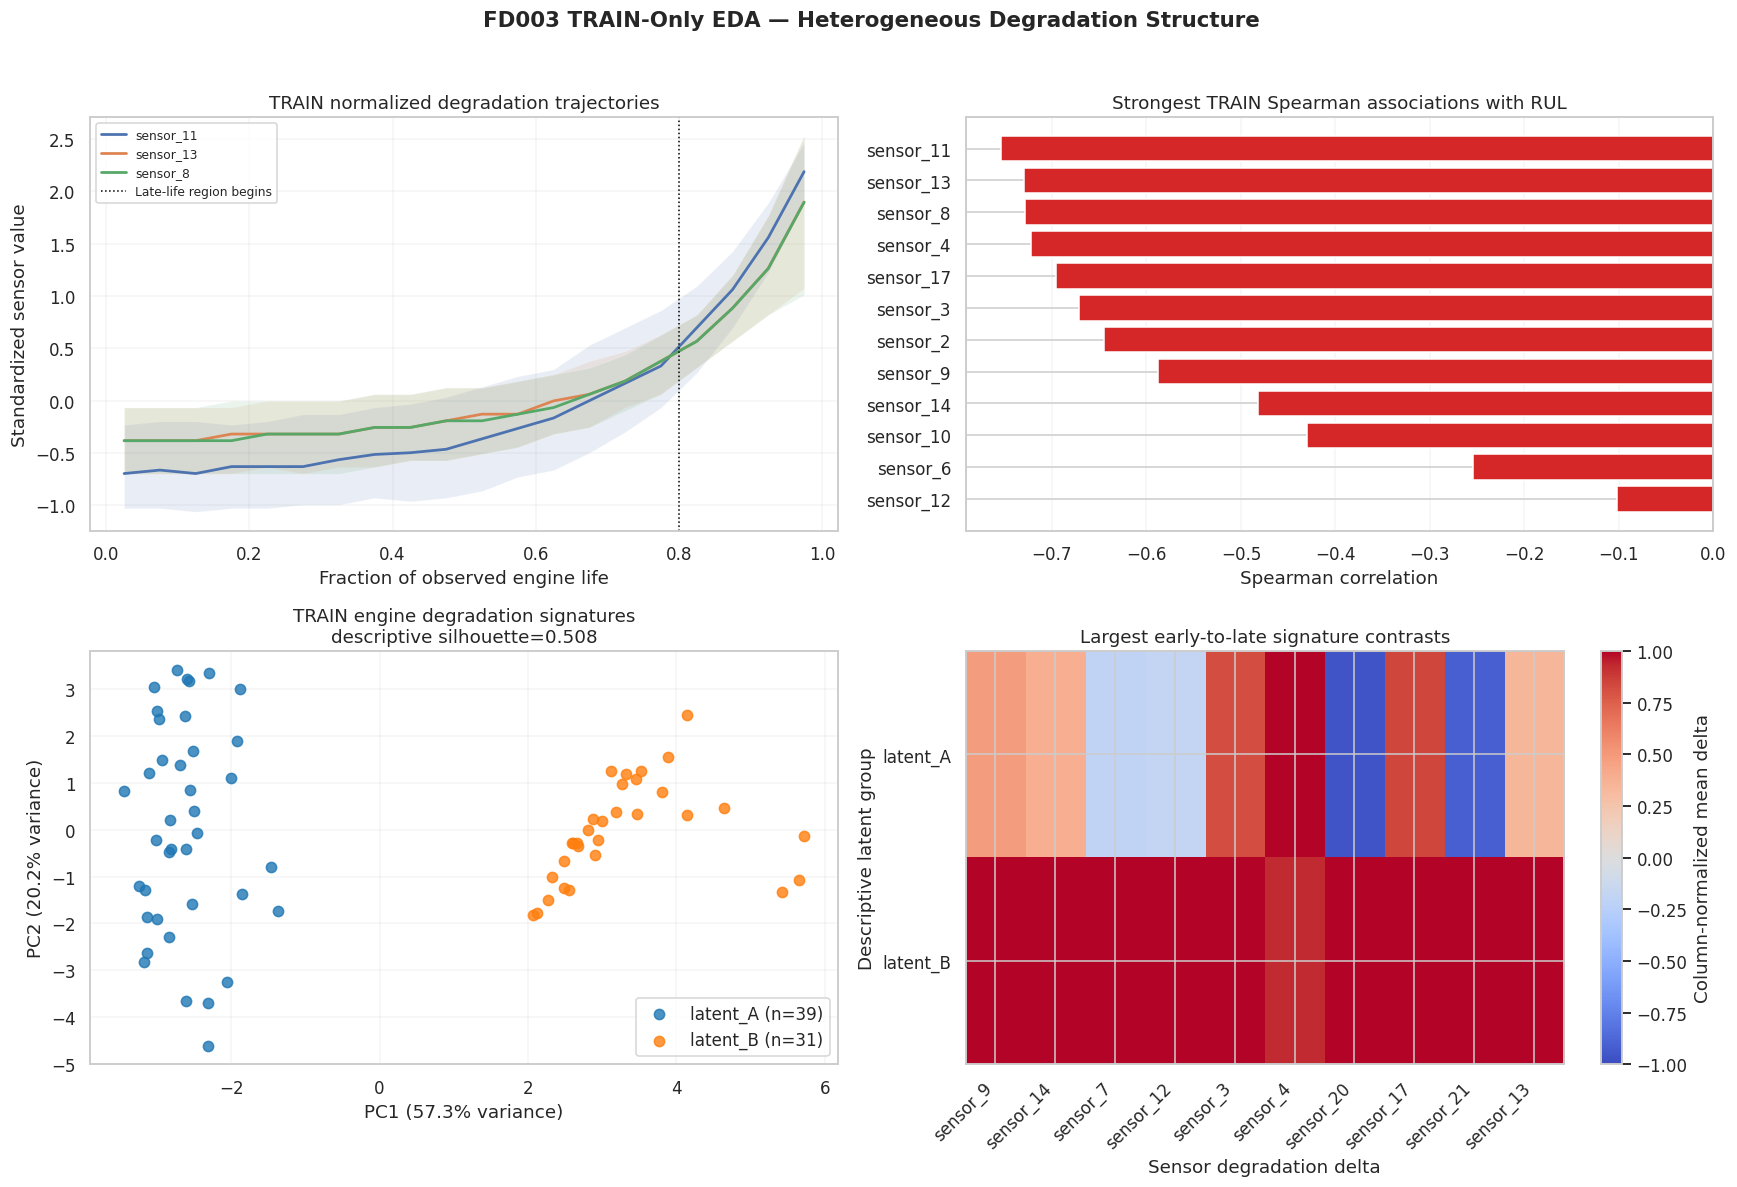

In [204]:
heatmap_column_scale = (
    cluster_heatmap.abs().max(axis=0)
    .replace(0.0, 1.0)
)
cluster_heatmap_scaled = (
    cluster_heatmap / heatmap_column_scale
)





fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11),
)


trajectory_ax = axes[0, 0]

for sensor in top_trajectory_sensors:
    sensor_trajectory = (
        trajectory_summary.loc[
            trajectory_summary["sensor"]
            == sensor
        ]
        .sort_values("life_fraction_center")
    )

    x = sensor_trajectory[
        "life_fraction_center"
    ].to_numpy(float)
    median = sensor_trajectory[
        "median_standardized_value"
    ].to_numpy(float)
    q25 = sensor_trajectory[
        "q25_standardized_value"
    ].to_numpy(float)
    q75 = sensor_trajectory[
        "q75_standardized_value"
    ].to_numpy(float)

    trajectory_ax.plot(
        x,
        median,
        linewidth=1.8,
        label=sensor,
    )
    trajectory_ax.fill_between(
        x,
        q25,
        q75,
        alpha=0.12,
    )

trajectory_ax.axvline(
    0.8,
    color="black",
    linestyle=":",
    linewidth=1,
    label="Late-life region begins",
)
trajectory_ax.set_title(
    "TRAIN normalized degradation trajectories"
)
trajectory_ax.set_xlabel(
    "Fraction of observed engine life"
)
trajectory_ax.set_ylabel(
    "Standardized sensor value"
)
trajectory_ax.grid(alpha=0.2)
trajectory_ax.legend(fontsize=8)


correlation_ax = axes[0, 1]

top_correlations = (
    rul_correlations.head(12)
    .sort_values(
        "absolute_spearman_RUL",
        ascending=True,
    )
)

bar_colors = [
    "#d62728" if value < 0 else "#1f77b4"
    for value in top_correlations[
        "spearman_RUL"
    ]
]

correlation_ax.barh(
    top_correlations["feature"],
    top_correlations["spearman_RUL"],
    color=bar_colors,
)
correlation_ax.axvline(
    0.0,
    color="black",
    linewidth=0.8,
)
correlation_ax.set_title(
    "Strongest TRAIN Spearman associations with RUL"
)
correlation_ax.set_xlabel("Spearman correlation")
correlation_ax.grid(axis="x", alpha=0.2)


pca_ax = axes[1, 0]

for latent_group, color in [
    ("latent_A", "#1f77b4"),
    ("latent_B", "#ff7f0e"),
]:
    group_rows = engine_signatures.loc[
        (engine_signatures["role"] == "train")
        & (
            engine_signatures["latent_group"]
            == latent_group
        )
    ]

    pca_ax.scatter(
        group_rows["PC1"],
        group_rows["PC2"],
        s=45,
        alpha=0.8,
        label=(
            f"{latent_group} "
            f"(n={len(group_rows)})"
        ),
        color=color,
    )

pca_ax.set_title(
    "TRAIN engine degradation signatures\n"
    f"descriptive silhouette={train_silhouette:.3f}"
)
pca_ax.set_xlabel(
    "PC1 "
    f"({explained_variance[0]:.1%} variance)"
)
pca_ax.set_ylabel(
    "PC2 "
    f"({explained_variance[1]:.1%} variance)"
)
pca_ax.grid(alpha=0.2)
pca_ax.legend()


heatmap_ax = axes[1, 1]

image = heatmap_ax.imshow(
    cluster_heatmap_scaled.to_numpy(float),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

heatmap_ax.set_yticks(
    np.arange(len(cluster_heatmap_scaled))
)
heatmap_ax.set_yticklabels(
    cluster_heatmap_scaled.index
)
heatmap_ax.set_xticks(
    np.arange(len(top_contrast_columns))
)
heatmap_ax.set_xticklabels(
    [
        column.replace("delta__", "")
        for column in top_contrast_columns
    ],
    rotation=45,
    ha="right",
)
heatmap_ax.set_title(
    "Largest early-to-late signature contrasts"
)
heatmap_ax.set_xlabel(
    "Sensor degradation delta"
)
heatmap_ax.set_ylabel(
    "Descriptive latent group"
)
fig.colorbar(
    image,
    ax=heatmap_ax,
    label="Column-normalized mean delta",
)

fig.suptitle(
    (
        f"{STAGE2_SUBSET} TRAIN-Only EDA — "
        "Heterogeneous Degradation Structure"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()





feature_audit.to_csv(
    feature_audit_path,
    index=False,
)
rul_correlations.to_csv(
    correlation_path,
    index=False,
)


In [205]:
engine_signatures.to_csv(
    signature_path,
    index=False,
)
cluster_assignments.to_csv(
    cluster_path,
    index=False,
)
trajectory_summary.to_csv(
    trajectory_path,
    index=False,
)

feature_reload = pd.read_csv(
    feature_audit_path
)
signature_reload = pd.read_csv(
    signature_path
)
cluster_reload = pd.read_csv(
    cluster_path
)
trajectory_reload = pd.read_csv(
    trajectory_path
)





eda_contract = {
    "artifact_type": (
        "train_only_multifault_eda_audit"
    ),
    "artifact_version": 1,
    "subset": STAGE2_SUBSET,
    "source_roles_used": [
        "train",
        "val_tune",
        "val_calib",
    ],
    "fit_role_for_scaler_pca_clustering": "train",
    "official_test_accessed": False,
    "raw_feature_count": len(
        RAW_FEATURE_COLUMNS
    ),
    "variable_sensor_count": len(
        variable_sensor_columns
    ),
    "constant_features": (
        feature_audit.loc[
            feature_audit["constant"],
            "feature",
        ].tolist()
    ),
    "near_constant_features": (
        feature_audit.loc[
            feature_audit["near_constant"],
            "feature",
        ].tolist()
    ),
    "degradation_signature": {
        "definition": (
            "per-engine late-life mean minus "
            "early-life mean"
        ),
        "early_region": "life_fraction <= 0.20",
        "late_region": "life_fraction >= 0.80",
        "feature_count": len(signature_columns),
    },
    "latent_structure": {
        "requested_groups": 2,
        "observed_train_groups": [
            "latent_A",
            "latent_B",
        ],
        "train_group_sizes": {
            group: int(count)
            for group, count in
            train_cluster_sizes.items()
        },
        "train_silhouette": train_silhouette,
        "pca_explained_variance_ratio": [
            float(value)
            for value in explained_variance
        ],
    },
    "interpretation_policy": {
        "descriptive_only": True,
        "used_as_predictive_feature": False,
        "physical_fault_mode_identity_claimed": False,
        "allowed_language": (
            "latent degradation groups or "
            "heterogeneous degradation patterns"
        ),
        "forbidden_language": (
            "named physical fault modes without "
            "ground-truth fault labels"
        ),
    },
}

eda_contract_path.write_text(
    json.dumps(
        eda_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

eda_sha256 = sha256_file(eda_contract_path)

eda_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(eda_contract_path),
            "sha256": eda_sha256,
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

eda_reload = json.loads(
    eda_contract_path.read_text(
        encoding="utf-8"
    )
)
eda_sidecar_reload = json.loads(
    eda_sidecar_path.read_text(
        encoding="utf-8"
    )
)





check_rows = [
    {
        "check": "development_protocol_hash_valid",
        "passed": (
            sha256_file(protocol_path)
            == protocol_sidecar["sha256"]
        ),
    },
    {
        "check": "official_test_gate_remains_sealed",
        "passed": (
            protocol["official_test_gate"][
                "status"
            ]
            == "SEALED"
            and not protocol[
                "official_test_gate"
            ]["evaluation_authorized"]
        ),
    },
    {
        "check": "canonical_24_feature_schema",
        "passed": (
            len(RAW_FEATURE_COLUMNS) == 24
            and len(set(RAW_FEATURE_COLUMNS))
            == 24
        ),
    },
    {
        "check": "feature_audit_has_24_rows",
        "passed": len(feature_audit) == 24,
    },
    {
        "check": "engine_signatures_cover_100_engines",
        "passed": (
            len(engine_signatures) == 100
            and engine_signatures[
                "engine_id"
            ].nunique() == 100
        ),
    },
    {
        "check": "latent_models_fit_on_train_only",
        "passed": (
            int(train_signature_mask.sum())
            == 70
        ),
    },
    {
        "check": "both_latent_groups_nonempty_on_train",
        "passed": (
            (train_cluster_sizes > 0).all()
        ),
    },
    {
        "check": "silhouette_finite_and_bounded",
        "passed": (
            np.isfinite(train_silhouette)
            and -1.0
            <= train_silhouette
            <= 1.0
        ),
    },
    {
        "check": "pca_variance_valid",
        "passed": bool(
            np.isfinite(
                explained_variance
            ).all()
            and np.all(
                explained_variance >= 0
            )
            and explained_variance.sum()
            <= 1.0 + 1e-12
        ),
    },
    {
        "check": "three_train_trajectory_sensors",
        "passed": (
            trajectory_summary[
                "sensor"
            ].nunique() == 3
        ),
    },
    {
        "check": "physical_fault_labels_not_claimed",
        "passed": (
            eda_contract[
                "interpretation_policy"
            ][
                "physical_fault_mode_identity_claimed"
            ]
            is False
        ),
    },
    {
        "check": "latent_groups_not_used_as_features",
        "passed": (
            eda_contract[
                "interpretation_policy"
            ]["used_as_predictive_feature"]
            is False
        ),
    },
    {
        "check": "feature_csv_shape_parity",
        "passed": (
            feature_reload.shape
            == feature_audit.shape
        ),
    },
    {
        "check": "signature_csv_shape_parity",
        "passed": (
            signature_reload.shape
            == engine_signatures.shape
        ),
    },
    {
        "check": "cluster_csv_key_parity",
        "passed": (
            cluster_reload.shape
            == cluster_assignments.shape
            and np.array_equal(
                cluster_reload[
                    "engine_id"
                ].to_numpy(int),
                cluster_assignments[
                    "engine_id"
                ].to_numpy(int),
            )
        ),
    },
    {
        "check": "trajectory_csv_shape_parity",
        "passed": (
            trajectory_reload.shape
            == trajectory_summary.shape
        ),
    },
    {
        "check": "eda_contract_reload_exact",
        "passed": eda_reload == eda_contract,
    },
    {
        "check": "eda_contract_hash_valid",
        "passed": (
            sha256_file(eda_contract_path)
            == eda_sidecar_reload["sha256"]
            == eda_sha256
        ),
    },
    {
        "check": "eda_figure_created",
        "passed": (
            figure_path.exists()
            and figure_path.stat().st_size > 0
        ),
    },
]


In [206]:
fd003_eda_checks = pd.DataFrame(check_rows)

assert fd003_eda_checks["passed"].all(), (
    fd003_eda_checks.loc[
        ~fd003_eda_checks["passed"]
    ]
)





print(" COMPUTED FD003 EDA CHECKS ")
display(fd003_eda_checks)

print("\n FD003 FEATURE VARIABILITY AUDIT ")
display(
    feature_audit.sort_values(
        [
            "feature_group",
            "absolute_spearman_RUL",
        ],
        ascending=[True, False],
    ).reset_index(drop=True)
)

print("\n FD003 STRONGEST TRAIN RUL ASSOCIATIONS ")
display(rul_correlations.head(12))

print("\n FD003 LATENT DEGRADATION GROUP SUMMARY ")
display(
    cluster_assignments.groupby(
        ["role", "latent_group"]
    ).agg(
        n_engines=("engine_id", "nunique"),
        mean_engine_length=("n_rows", "mean"),
        median_PC1=("PC1", "median"),
        median_PC2=("PC2", "median"),
    ).reset_index()
)

print("\nTRAIN silhouette:", train_silhouette)
print(
    "PCA explained variance:",
    {
        "PC1": float(explained_variance[0]),
        "PC2": float(explained_variance[1]),
        "total": float(
            explained_variance.sum()
        ),
    },
)
print(
    "Physical fault-mode identity claimed:",
    eda_contract[
        "interpretation_policy"
    ][
        "physical_fault_mode_identity_claimed"
    ],
)
print(
    "Official-Test accessed:",
    eda_contract["official_test_accessed"],
)
print(
    "Failed checks:",
    int((~fd003_eda_checks["passed"]).sum()),
)
print("EDA status: PASS")
print("Saved feature audit:", feature_audit_path)
print("Saved latent groups:", cluster_path)
print("Saved EDA contract:", eda_contract_path)

 COMPUTED FD003 EDA CHECKS 


,check,passed
0,development_protocol_hash_valid,True
1,official_test_gate_remains_sealed,True
2,canonical_24_feature_schema,True
3,feature_audit_has_24_rows,True
4,engine_signatures_cover_100_engines,True
5,latent_models_fit_on_train_only,True
6,both_latent_groups_nonempty_on_train,True
7,silhouette_finite_and_bounded,True
8,pca_variance_valid,True
9,three_train_trajectory_sensors,True



 FD003 FEATURE VARIABILITY AUDIT 


,feature,feature_group,mean,standard_deviation,minimum,maximum,range,n_unique,constant,near_constant,spearman_RUL,absolute_spearman_RUL
0,op_setting_2,operating_setting,0.000003,2.937194e-04,-0.0006,0.0006,0.0012,13,False,False,-0.004491,0.004491
1,op_setting_1,operating_setting,-0.000011,2.181432e-03,-0.0086,0.0080,0.0166,155,False,False,-0.002027,0.002027
2,op_setting_3,operating_setting,100.000000,0.000000e+00,100.0000,100.0000,0.0000,1,True,True,0.000000,0.000000
3,sensor_11,sensor,47.410070,3.014556e-01,46.6900,48.4400,1.7500,168,False,False,-0.753751,0.753751
4,sensor_13,sensor,2388.070383,1.578238e-01,2386.9400,2388.6100,1.6700,159,False,False,-0.729677,0.729677
5,sensor_8,sensor,2388.070440,1.579211e-01,2386.9000,2388.6000,1.7000,157,False,False,-0.728965,0.728965
6,sensor_4,sensor,1404.268826,9.770974e+00,1377.0600,1441.1600,64.1000,4166,False,False,-0.721842,0.721842
7,sensor_17,sensor,392.543114,1.761024e+00,388.0000,399.0000,11.0000,12,False,False,-0.695673,0.695673
8,sensor_3,sensor,1587.983396,6.836040e+00,1564.3000,1615.3900,51.0900,3194,False,False,-0.670876,0.670876
9,sensor_2,sensor,642.447779,5.219350e-01,640.8400,645.1100,4.2700,329,False,False,-0.645031,0.645031



 FD003 STRONGEST TRAIN RUL ASSOCIATIONS 


,feature,feature_group,spearman_RUL,absolute_spearman_RUL,constant,near_constant
0,sensor_11,sensor,-0.753751,0.753751,False,False
1,sensor_13,sensor,-0.729677,0.729677,False,False
2,sensor_8,sensor,-0.728965,0.728965,False,False
3,sensor_4,sensor,-0.721842,0.721842,False,False
4,sensor_17,sensor,-0.695673,0.695673,False,False
5,sensor_3,sensor,-0.670876,0.670876,False,False
6,sensor_2,sensor,-0.645031,0.645031,False,False
7,sensor_9,sensor,-0.587926,0.587926,False,False
8,sensor_14,sensor,-0.481955,0.481955,False,False
9,sensor_10,sensor,-0.430181,0.430181,False,False



 FD003 LATENT DEGRADATION GROUP SUMMARY 


,role,latent_group,n_engines,mean_engine_length,median_PC1,median_PC2
0,train,latent_A,39,211.025641,-2.628242,-0.076695
1,train,latent_B,31,322.225806,2.994235,-0.132885
2,val_calib,latent_A,7,186.428571,-2.377493,-1.717796
3,val_calib,latent_B,3,237.000000,2.730017,-0.184356
4,val_tune,latent_A,10,178.000000,-2.681216,-0.435087
5,val_tune,latent_B,10,270.500000,2.956568,-0.048662



TRAIN silhouette: 0.5075011952698976
PCA explained variance: {'PC1': 0.5731851752596075, 'PC2': 0.2018514971872301, 'total': 0.7750366724468376}
Physical fault-mode identity claimed: False
Official-Test accessed: False
Failed checks: 0
EDA status: PASS
Saved feature audit: artifacts/results/FD003_train_feature_audit.csv
Saved latent groups: artifacts/results/FD003_latent_degradation_groups.csv
Saved EDA contract: data/processed/FD003_eda_multifault_audit.json


### FD003 causal feature-pipeline candidates and leakage audit

Fit pipelines on FD003 TRAIN engines only. Official Test remains sealed.


In [ ]:
import hashlib
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import features
from features import FeaturePipeline

STAGE2_SUBSET = "FD003"
STAGE2_SEED = int(config.RANDOM_SEED)

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)

protocol_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.sha256"
)
eda_contract_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_eda_multifault_audit.json"
)
eda_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_eda_multifault_audit.sha256"
)
feature_audit_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_train_feature_audit.csv"
)

pipeline_bundle_path = (
    MODEL_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_candidates.joblib"
)
pipeline_summary_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_candidates.csv"
)
pipeline_contract_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_contract.json"
)
pipeline_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_contract.sha256"
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


protocol = json.loads(
    protocol_path.read_text(encoding="utf-8")
)
protocol_sidecar = json.loads(
    protocol_sidecar_path.read_text(
        encoding="utf-8"
    )
)
eda_contract = json.loads(
    eda_contract_path.read_text(encoding="utf-8")
)
eda_sidecar = json.loads(
    eda_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert sha256_file(protocol_path) == (
    protocol_sidecar["sha256"]
)
assert sha256_file(eda_contract_path) == (
    eda_sidecar["sha256"]
)
assert protocol["official_test_gate"]["status"] == "SEALED"
assert protocol["official_test_gate"][
    "evaluation_authorized"
] is False

fd003_frames = {
    "train": df_fd003_train.copy(),
    "val_tune": df_fd003_val_tune.copy(),
    "val_calib": df_fd003_val_calib.copy(),
}

source_roles = sorted(fd003_frames)
official_test_roles = [
    role
    for role in source_roles
    if "test" in role.lower()
]

assert source_roles == [
    "train",
    "val_calib",
    "val_tune",
]
assert official_test_roles == []

expected_role_rows = {
    role: len(frame)
    for role, frame in fd003_frames.items()
}
expected_role_engines = {
    role: int(frame["engine_id"].nunique())
    for role, frame in fd003_frames.items()
}

assert expected_role_engines == {
    "train": 70,
    "val_tune": 20,
    "val_calib": 10,
}





feature_audit = pd.read_csv(feature_audit_path)

assert len(feature_audit) == 24
assert set(feature_audit["feature"]) == set(
    list(config.SETTING_COLS)
    + list(config.SENSOR_COLS)
)

fd003_keep_sensors = (
    feature_audit.loc[
        (
            feature_audit["feature_group"]
            == "sensor"
        )
        & (~feature_audit["near_constant"].astype(bool)),
        "feature",
    ]
    .astype(str)
    .tolist()
)

fd003_keep_settings = (
    feature_audit.loc[
        (
            feature_audit["feature_group"]
            == "operating_setting"
        )
        & (~feature_audit["near_constant"].astype(bool)),
        "feature",
    ]
    .astype(str)
    .tolist()
)

assert len(fd003_keep_sensors) >= 2
assert set(fd003_keep_sensors).issubset(
    set(config.SENSOR_COLS)
)
assert set(fd003_keep_settings).issubset(
    set(config.SETTING_COLS)
)

for frame in fd003_frames.values():
    required = (
        ["engine_id", "cycle", "RUL"]
        + fd003_keep_sensors
        + fd003_keep_settings
    )
    assert all(
        column in frame.columns
        for column in required
    )

feature_windows = [
    int(value)
    for value in config.FEATURE_WINDOWS
]

assert feature_windows == [5, 15, 30]

candidate_configs = []

include_settings_values = (
    [False, True]
    if len(fd003_keep_settings) > 0
    else [False]
)


In [ ]:
for include_settings in include_settings_values:
    candidate_configs.append(
        {
            "candidate_id": (
                "baseline"
                f"__settings_{int(include_settings)}"
            ),
            "representation": "baseline",
            "window": 1,
            "include_settings": include_settings,
        }
    )

    for window in feature_windows:
        candidate_configs.append(
            {
                "candidate_id": (
                    f"window{window}"
                    f"__settings_{int(include_settings)}"
                ),
                "representation": "window",
                "window": window,
                "include_settings": include_settings,
            }
        )

assert len(candidate_configs) == len(
    {
        config_row["candidate_id"]
        for config_row in candidate_configs
    }
)

module_tests_passed = False
module_test_error = None

try:
    features.run_all_tests(verbose=True)
    module_tests_passed = True
except Exception as error:
    module_test_error = repr(error)

assert module_tests_passed, module_test_error

fd003_feature_pipelines = {}
candidate_summary_rows = []
candidate_validation_rows = []

train_engine_ids_for_fit = sorted(
    df_fd003_train["engine_id"]
    .astype(int)
    .unique()
    .tolist()
)


 FeaturePipeline automated tests 
  [OK] causality (middle cycle, all future rows): PASS
  [OK] no engine-boundary crossing: PASS
  [OK] shuffled-input alignment: PASS
  [OK] scaler train-only: PASS
  [OK] input validation catches bad data: PASS
  [OK] rejects NaN/Inf in sensors: PASS


In [209]:
for candidate_config in candidate_configs:
    candidate_id = candidate_config[
        "candidate_id"
    ]

    pipeline = FeaturePipeline(
        keep_sensors=list(fd003_keep_sensors),
        keep_settings=list(fd003_keep_settings),
        representation=candidate_config[
            "representation"
        ],
        window=int(candidate_config["window"]),
        include_settings=bool(
            candidate_config["include_settings"]
        ),
        require_continuity=True,
    )

    pipeline.fit(df_fd003_train)

    assert pipeline._fitted
    assert pipeline.feature_names_ is not None
    assert len(pipeline.feature_names_) > 0
    assert len(pipeline.scaler_mean_) == len(
        pipeline.feature_names_
    )
    assert len(pipeline.scaler_scale_) == len(
        pipeline.feature_names_
    )
    assert np.all(
        pipeline.scaler_scale_ > 0
    )

    role_outputs = {}

    for role, frame in fd003_frames.items():
        (
            X_scaled,
            y_rul,
            y_labels,
            metadata,
            config_meta,
        ) = pipeline.transform(
            frame,
            scaled=True,
        )

        X_unscaled = pipeline.transform(
            frame,
            scaled=False,
        )[0]

        assert len(X_scaled) == len(frame)
        assert len(X_unscaled) == len(frame)
        assert X_scaled.index.equals(frame.index)
        assert X_unscaled.index.equals(frame.index)
        assert y_rul.index.equals(frame.index)
        assert np.array_equal(
            y_rul.to_numpy(float),
            frame["RUL"].to_numpy(float),
        )
        assert y_labels is None
        assert metadata.index.equals(frame.index)
        assert np.array_equal(
            metadata["engine_id"].to_numpy(int),
            frame["engine_id"].to_numpy(int),
        )
        assert np.array_equal(
            metadata["cycle"].to_numpy(int),
            frame["cycle"].to_numpy(int),
        )
        assert list(X_scaled.columns) == (
            pipeline.feature_names_
        )
        assert list(X_unscaled.columns) == (
            pipeline.feature_names_
        )
        assert config_meta["n_features"] == len(
            pipeline.feature_names_
        )
        assert np.isfinite(
            X_scaled.to_numpy(float)
        ).all()
        assert np.isfinite(
            X_unscaled.to_numpy(float)
        ).all()

        role_outputs[role] = {
            "X_scaled": X_scaled,
            "X_unscaled": X_unscaled,
            "metadata": metadata,
        }

        candidate_validation_rows.append(
            {
                "candidate_id": candidate_id,
                "role": role,
                "n_rows": int(len(X_scaled)),
                "n_engines": int(
                    frame["engine_id"].nunique()
                ),
                "n_features": int(
                    X_scaled.shape[1]
                ),
                "scaled_values_finite": bool(
                    np.isfinite(
                        X_scaled.to_numpy(float)
                    ).all()
                ),
                "index_alignment": bool(
                    X_scaled.index.equals(
                        frame.index
                    )
                ),
                "rul_alignment": bool(
                    np.array_equal(
                        y_rul.to_numpy(float),
                        frame["RUL"].to_numpy(
                            float
                        ),
                    )
                ),
            }
        )

    
    train_unscaled_matrix = role_outputs[
        "train"
    ]["X_unscaled"].to_numpy(float)

    scaler_mean_parity = np.allclose(
        pipeline.scaler_mean_,
        train_unscaled_matrix.mean(axis=0),
        rtol=0.0,
        atol=1e-12,
    )

    expected_scale = train_unscaled_matrix.std(
        axis=0,
        ddof=0,
    )
    expected_scale[
        expected_scale == 0
    ] = 1.0

    scaler_scale_parity = np.allclose(
        pipeline.scaler_scale_,
        expected_scale,
        rtol=0.0,
        atol=1e-12,
    )

    assert scaler_mean_parity
    assert scaler_scale_parity

    
    train_scaled_mean_max_abs = float(
        np.abs(
            role_outputs["train"][
                "X_scaled"
            ].to_numpy(float).mean(axis=0)
        ).max()
    )
    assert train_scaled_mean_max_abs <= 1e-10

    
    
    
    shuffled_tune = (
        df_fd003_val_tune.sample(
            frac=1.0,
            random_state=STAGE2_SEED,
        )
    )

    X_tune_original = role_outputs[
        "val_tune"
    ]["X_scaled"]

    X_tune_shuffled = pipeline.transform(
        shuffled_tune,
        scaled=True,
    )[0]

    shuffled_alignment = np.allclose(
        X_tune_original.sort_index().to_numpy(
            float
        ),
        X_tune_shuffled.sort_index().to_numpy(
            float
        ),
        rtol=0.0,
        atol=1e-12,
    )

    assert shuffled_alignment

    
    
    
    longest_train_engine = int(
        df_fd003_train.groupby(
            "engine_id"
        ).size().idxmax()
    )

    causal_original = (
        df_fd003_train.loc[
            df_fd003_train["engine_id"]
            == longest_train_engine
        ]
        .copy()
        .sort_values("cycle")
    )

    cutoff_position = max(
        1,
        int(np.floor(0.60 * len(causal_original))),
    )
    cutoff_cycle = int(
        causal_original.iloc[
            cutoff_position - 1
        ]["cycle"]
    )

    causal_perturbed = causal_original.copy()
    future_mask = (
        causal_perturbed["cycle"]
        > cutoff_cycle
    )

    perturb_columns = list(
        fd003_keep_sensors
    )

    if candidate_config["include_settings"]:
        perturb_columns += list(
            fd003_keep_settings
        )

    perturbation_vector = np.arange(
        1,
        len(perturb_columns) + 1,
        dtype=float,
    ) * 1_000_000.0

    causal_perturbed.loc[
        future_mask,
        perturb_columns,
    ] = (
        causal_perturbed.loc[
            future_mask,
            perturb_columns,
        ].to_numpy(float)
        + perturbation_vector
    )

    X_causal_original = pipeline.transform(
        causal_original,
        scaled=False,
    )[0]
    X_causal_perturbed = pipeline.transform(
        causal_perturbed,
        scaled=False,
    )[0]

    past_index = causal_original.index[
        causal_original["cycle"]
        <= cutoff_cycle
    ]
    future_index = causal_original.index[
        causal_original["cycle"]
        > cutoff_cycle
    ]

    past_causality_parity = np.allclose(
        X_causal_original.loc[
            past_index
        ].to_numpy(float),
        X_causal_perturbed.loc[
            past_index
        ].to_numpy(float),
        rtol=0.0,
        atol=1e-12,
    )

    future_perturbation_effective = not np.allclose(
        X_causal_original.loc[
            future_index
        ].to_numpy(float),
        X_causal_perturbed.loc[
            future_index
        ].to_numpy(float),
        rtol=0.0,
        atol=1e-12,
    )

    assert past_causality_parity
    assert future_perturbation_effective

    fd003_feature_pipelines[
        candidate_id
    ] = pipeline

    candidate_summary_rows.append(
        {
            **candidate_config,
            "n_fit_rows": int(
                len(df_fd003_train)
            ),
            "n_fit_engines": int(
                df_fd003_train[
                    "engine_id"
                ].nunique()
            ),
            "n_sensors": int(
                len(fd003_keep_sensors)
            ),
            "n_settings_available": int(
                len(fd003_keep_settings)
            ),
            "n_features": int(
                len(pipeline.feature_names_)
            ),
            "scaler_mean_parity": bool(
                scaler_mean_parity
            ),
            "scaler_scale_parity": bool(
                scaler_scale_parity
            ),
            "train_scaled_mean_max_abs": (
                train_scaled_mean_max_abs
            ),
            "shuffled_alignment": bool(
                shuffled_alignment
            ),
            "past_causality_parity": bool(
                past_causality_parity
            ),
            "future_perturbation_effective": bool(
                future_perturbation_effective
            ),
        }
    )


In [210]:
candidate_summary = pd.DataFrame(
    candidate_summary_rows
)
candidate_validation = pd.DataFrame(
    candidate_validation_rows
)

assert len(candidate_summary) == len(
    candidate_configs
)
assert len(candidate_validation) == (
    len(candidate_configs) * 3
)
assert candidate_summary[
    [
        "scaler_mean_parity",
        "scaler_scale_parity",
        "shuffled_alignment",
        "past_causality_parity",
        "future_perturbation_effective",
    ]
].all().all()





pipeline_bundle = {
    "artifact_type": (
        "feature_pipeline_candidate_bundle"
    ),
    "artifact_version": 1,
    "subset": STAGE2_SUBSET,
    "fit_role": "train",
    "fit_engine_ids": train_engine_ids_for_fit,
    "keep_sensors": list(
        fd003_keep_sensors
    ),
    "keep_settings": list(
        fd003_keep_settings
    ),
    "candidate_ids": list(
        fd003_feature_pipelines.keys()
    ),
    "pipelines": fd003_feature_pipelines,
    "development_protocol": {
        "path": str(protocol_path),
        "sha256": sha256_file(protocol_path),
    },
    "eda_contract": {
        "path": str(eda_contract_path),
        "sha256": sha256_file(
            eda_contract_path
        ),
    },
    "official_test_status": "SEALED",
}

joblib.dump(
    pipeline_bundle,
    pipeline_bundle_path,
)

pipeline_bundle_sha256 = sha256_file(
    pipeline_bundle_path
)

bundle_reload = joblib.load(
    pipeline_bundle_path
)

assert bundle_reload["subset"] == (
    STAGE2_SUBSET
)
assert bundle_reload["fit_role"] == "train"
assert bundle_reload["fit_engine_ids"] == (
    train_engine_ids_for_fit
)
assert set(
    bundle_reload["pipelines"]
) == set(
    fd003_feature_pipelines
)


reload_parity_rows = []

for candidate_id, original_pipeline in (
    fd003_feature_pipelines.items()
):
    reloaded_pipeline = bundle_reload[
        "pipelines"
    ][candidate_id]

    original_output = (
        original_pipeline.transform(
            df_fd003_val_tune,
            scaled=True,
        )[0]
    )
    reloaded_output = (
        reloaded_pipeline.transform(
            df_fd003_val_tune,
            scaled=True,
        )[0]
    )

    parity = np.allclose(
        original_output.to_numpy(float),
        reloaded_output.to_numpy(float),
        rtol=0.0,
        atol=1e-12,
    )

    reload_parity_rows.append(
        {
            "candidate_id": candidate_id,
            "reload_transform_parity": bool(
                parity
            ),
        }
    )

reload_parity = pd.DataFrame(
    reload_parity_rows
)

assert reload_parity[
    "reload_transform_parity"
].all()





candidate_summary.to_csv(
    pipeline_summary_path,
    index=False,
)

summary_reload = pd.read_csv(
    pipeline_summary_path
)

assert summary_reload.shape == (
    candidate_summary.shape
)
assert np.array_equal(
    summary_reload[
        "candidate_id"
    ].to_numpy(),
    candidate_summary[
        "candidate_id"
    ].to_numpy(),
)





pipeline_contract = {
    "artifact_type": (
        "causal_feature_pipeline_contract"
    ),
    "artifact_version": 1,
    "subset": STAGE2_SUBSET,
    "fit_role": "train",
    "fit_engine_ids": train_engine_ids_for_fit,
    "selection_role": "val_tune",
    "calibration_role": "val_calib",
    "keep_sensors": list(
        fd003_keep_sensors
    ),
    "keep_settings": list(
        fd003_keep_settings
    ),
    "candidate_grid": candidate_configs,
    "feature_windows": feature_windows,
    "require_cycle_continuity": True,
    "scaler_fit_role": "train",
    "causality_test": {
        "method": (
            "perturb all future input values after "
            "a cutoff and verify earlier features "
            "remain unchanged"
        ),
        "all_candidates_passed": bool(
            candidate_summary[
                "past_causality_parity"
            ].all()
        ),
    },
    "shuffled_input_alignment": {
        "all_candidates_passed": bool(
            candidate_summary[
                "shuffled_alignment"
            ].all()
        ),
    },
    "latent_groups_used_as_features": False,
    "pipeline_bundle": {
        "path": str(pipeline_bundle_path),
        "sha256": pipeline_bundle_sha256,
    },
    "source_module_tests_passed": (
        module_tests_passed
    ),
    "official_test_accessed": bool(
        len(official_test_roles) > 0
    ),
    "official_test_status": "SEALED",
}

assert pipeline_contract[
    "official_test_accessed"
] is False

pipeline_contract_path.write_text(
    json.dumps(
        pipeline_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)


2998

In [ ]:
pipeline_contract_sha256 = sha256_file(
    pipeline_contract_path
)

pipeline_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                pipeline_contract_path
            ),
            "sha256": (
                pipeline_contract_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

contract_reload = json.loads(
    pipeline_contract_path.read_text(
        encoding="utf-8"
    )
)
sidecar_reload = json.loads(
    pipeline_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert contract_reload == pipeline_contract
assert (
    sha256_file(pipeline_contract_path)
    == sidecar_reload["sha256"]
    == pipeline_contract_sha256
)





check_rows = [
    {
        "check": "development_protocol_hash_valid",
        "passed": (
            sha256_file(protocol_path)
            == protocol_sidecar["sha256"]
        ),
    },
    {
        "check": "eda_contract_hash_valid",
        "passed": (
            sha256_file(eda_contract_path)
            == eda_sidecar["sha256"]
        ),
    },
    {
        "check": "official_test_gate_remains_sealed",
        "passed": (
            protocol["official_test_gate"][
                "status"
            ]
            == "SEALED"
            and official_test_roles == []
        ),
    },
    {
        "check": "source_feature_tests_pass",
        "passed": module_tests_passed,
    },
    {
        "check": "all_candidates_fit_on_70_train_engines",
        "passed": (
            candidate_summary[
                "n_fit_engines"
            ].eq(70).all()
        ),
    },
    {
        "check": "all_role_row_counts_preserved",
        "passed": all(
            candidate_validation.loc[
                candidate_validation["role"]
                == role,
                "n_rows",
            ].eq(expected_rows).all()
            for role, expected_rows in
            expected_role_rows.items()
        ),
    },
    {
        "check": "all_feature_matrices_finite",
        "passed": candidate_validation[
            "scaled_values_finite"
        ].all(),
    },
    {
        "check": "all_indexes_aligned",
        "passed": candidate_validation[
            "index_alignment"
        ].all(),
    },
    {
        "check": "all_rul_targets_aligned",
        "passed": candidate_validation[
            "rul_alignment"
        ].all(),
    },
    {
        "check": "scalers_reconstruct_train_moments",
        "passed": bool(
            candidate_summary[
                [
                    "scaler_mean_parity",
                    "scaler_scale_parity",
                ]
            ].all().all()
        ),
    },
    {
        "check": "train_scaled_means_near_zero",
        "passed": candidate_summary[
            "train_scaled_mean_max_abs"
        ].le(1e-10).all(),
    },
    {
        "check": "shuffled_input_alignment_passes",
        "passed": candidate_summary[
            "shuffled_alignment"
        ].all(),
    },
    {
        "check": "future_perturbation_causality_passes",
        "passed": bool(
            candidate_summary[
                [
                    "past_causality_parity",
                    "future_perturbation_effective",
                ]
            ].all().all()
        ),
    },
    {
        "check": "latent_groups_excluded_from_features",
        "passed": (
            pipeline_contract[
                "latent_groups_used_as_features"
            ]
            is False
        ),
    },
    {
        "check": "bundle_reload_transform_parity",
        "passed": reload_parity[
            "reload_transform_parity"
        ].all(),
    },
    {
        "check": "pipeline_summary_reload_parity",
        "passed": (
            summary_reload.shape
            == candidate_summary.shape
            and np.array_equal(
                summary_reload[
                    "candidate_id"
                ].to_numpy(),
                candidate_summary[
                    "candidate_id"
                ].to_numpy(),
            )
        ),
    },
    {
        "check": "pipeline_contract_reload_exact",
        "passed": (
            contract_reload
            == pipeline_contract
        ),
    },
    {
        "check": "pipeline_contract_hash_valid",
        "passed": (
            sha256_file(
                pipeline_contract_path
            )
            == sidecar_reload["sha256"]
        ),
    },
]

fd003_feature_checks = pd.DataFrame(
    check_rows
)

assert fd003_feature_checks["passed"].all(), (
    fd003_feature_checks.loc[
        ~fd003_feature_checks["passed"]
    ]
)

print(" COMPUTED FD003 CAUSAL FEATURE CHECKS ")
display(fd003_feature_checks)

print("\n FD003 FEATURE-PIPELINE CANDIDATES ")
display(candidate_summary)

print("\n FD003 ROLE TRANSFORM SUMMARY ")
display(candidate_validation)

print("\n FD003 RELOAD TRANSFORM PARITY ")
display(reload_parity)

print("\nRetained sensors:", fd003_keep_sensors)
print("Retained settings:", fd003_keep_settings)
print(
    "Candidate count:",
    len(candidate_configs),
)


 COMPUTED FD003 CAUSAL FEATURE CHECKS 


,check,passed
0,development_protocol_hash_valid,True
1,eda_contract_hash_valid,True
2,official_test_gate_remains_sealed,True
3,source_feature_tests_pass,True
4,all_candidates_fit_on_70_train_engines,True
5,all_role_row_counts_preserved,True
6,all_feature_matrices_finite,True
7,all_indexes_aligned,True
8,all_rul_targets_aligned,True
9,scalers_reconstruct_train_moments,True



 FD003 FEATURE-PIPELINE CANDIDATES 


,candidate_id,representation,window,include_settings,n_fit_rows,n_fit_engines,n_sensors,n_settings_available,n_features,scaler_mean_parity,scaler_scale_parity,train_scaled_mean_max_abs,shuffled_alignment,past_causality_parity,future_perturbation_effective
0,baseline__settings_0,baseline,1,False,18219,70,16,2,16,True,True,2.623696e-12,True,True,True
1,window5__settings_0,window,5,False,18219,70,16,2,129,True,True,3.274953e-12,True,True,True
2,window15__settings_0,window,15,False,18219,70,16,2,129,True,True,4.650983e-12,True,True,True
3,window30__settings_0,window,30,False,18219,70,16,2,129,True,True,2.914187e-12,True,True,True
4,baseline__settings_1,baseline,1,True,18219,70,16,2,18,True,True,2.623696e-12,True,True,True
5,window5__settings_1,window,5,True,18219,70,16,2,131,True,True,3.274953e-12,True,True,True
6,window15__settings_1,window,15,True,18219,70,16,2,131,True,True,4.650983e-12,True,True,True
7,window30__settings_1,window,30,True,18219,70,16,2,131,True,True,2.914187e-12,True,True,True



 FD003 ROLE TRANSFORM SUMMARY 


,candidate_id,role,n_rows,n_engines,n_features,scaled_values_finite,index_alignment,rul_alignment
0,baseline__settings_0,train,18219,70,16,True,True,True
1,baseline__settings_0,val_tune,4485,20,16,True,True,True
2,baseline__settings_0,val_calib,2016,10,16,True,True,True
3,window5__settings_0,train,18219,70,129,True,True,True
4,window5__settings_0,val_tune,4485,20,129,True,True,True
5,window5__settings_0,val_calib,2016,10,129,True,True,True
6,window15__settings_0,train,18219,70,129,True,True,True
7,window15__settings_0,val_tune,4485,20,129,True,True,True
8,window15__settings_0,val_calib,2016,10,129,True,True,True
9,window30__settings_0,train,18219,70,129,True,True,True



 FD003 RELOAD TRANSFORM PARITY 


,candidate_id,reload_transform_parity
0,baseline__settings_0,True
1,window5__settings_0,True
2,window15__settings_0,True
3,window30__settings_0,True
4,baseline__settings_1,True
5,window5__settings_1,True
6,window15__settings_1,True
7,window30__settings_1,True



Retained sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Retained settings: ['op_setting_1', 'op_setting_2']
Candidate count: 8


In [212]:
print(
    "Latent groups used as predictive features:",
    pipeline_contract[
        "latent_groups_used_as_features"
    ],
)
print(
    "Official-Test accessed:",
    pipeline_contract[
        "official_test_accessed"
    ],
)
print(
    "Failed checks:",
    int((~fd003_feature_checks["passed"]).sum()),
)
print("Causal feature status: PASS")
print("Saved pipeline bundle:", pipeline_bundle_path)
print(
    "Pipeline bundle SHA256:",
    pipeline_bundle_sha256,
)
print("Saved candidate summary:", pipeline_summary_path)
print("Saved contract:", pipeline_contract_path)
print(
    "Feature contract SHA256:",
    pipeline_contract_sha256,
)


Latent groups used as predictive features: False
Official-Test accessed: False
Failed checks: 0
Causal feature status: PASS
Saved pipeline bundle: artifacts/models/FD003_feature_pipeline_candidates.joblib
Pipeline bundle SHA256: b42cddc3573fdb3c29c76abbf68c6fe19977e1e0acf2886f437fd30ba6493e9c
Saved candidate summary: artifacts/results/FD003_feature_pipeline_candidates.csv
Saved contract: data/processed/FD003_feature_pipeline_contract.json
Feature contract SHA256: 30a5d66fdcf9593be17cf69f8c5e0af56566318781ad33d54ce5f100060932b4


### Project imports after a Kernel restart


In [213]:


import sys
from pathlib import Path
import importlib


PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
REGRESSION_MODULE = (
    SRC_DIR / "models_regression.py"
)


assert PROJECT_ROOT.is_dir(), (
    f"Project directory was not found: {PROJECT_ROOT}"
)
assert SRC_DIR.is_dir(), (
    f"Source directory was not found: {SRC_DIR}"
)
assert REGRESSION_MODULE.is_file(), (
    f"Module file was not found: {REGRESSION_MODULE}"
)


if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


mr = importlib.import_module(
    "models_regression"
)
mr = importlib.reload(mr)


assert hasattr(mr, "phm_score_mean"), (
    "models_regression.phm_score_mean "
    "was not found."
)
assert callable(mr.phm_score_mean), (
    "phm_score_mean is not callable."
)

import_check = {
    "project_root_exists": PROJECT_ROOT.is_dir(),
    "src_directory_exists": SRC_DIR.is_dir(),
    "regression_module_exists": (
        REGRESSION_MODULE.is_file()
    ),
    "module_imported": (
        mr.__name__ == "models_regression"
    ),
    "phm_score_function_available": (
        callable(mr.phm_score_mean)
    ),
}

assert all(import_check.values()), import_check

print(" COMPUTED PROJECT IMPORT CHECKS ")
for check_name, passed in import_check.items():
    print(f"{check_name}: {passed}")


 COMPUTED PROJECT IMPORT CHECKS 
project_root_exists: True
src_directory_exists: True
regression_module_exists: True
module_imported: True
phm_score_function_available: True


### Restore project configuration after Kernel restart


In [ ]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"

assert PROJECT_ROOT.is_dir()
assert SRC_DIR.is_dir()
assert (SRC_DIR / "config.py").is_file()
assert (
    SRC_DIR / "models_regression.py"
).is_file()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
import models_regression as mr

config = importlib.reload(config)
mr = importlib.reload(mr)

setup_checks = {
    "project_root_exists": PROJECT_ROOT.is_dir(),
    "src_directory_exists": SRC_DIR.is_dir(),
    "config_loaded": hasattr(
        config, "RANDOM_SEED"
    ),
    "model_directory_available": hasattr(
        config, "MODELS_DIR"
    ),
    "results_directory_available": hasattr(
        config, "RESULTS_DIR"
    ),
    "regression_metrics_loaded": callable(
        mr.phm_score_mean
    ),
}

assert all(setup_checks.values()), setup_checks

print(" COMPUTED PROJECT SETUP CHECKS ")
for name, passed in setup_checks.items():
    print(f"{name}: {passed}")


 COMPUTED PROJECT SETUP CHECKS 
project_root_exists: True
src_directory_exists: True
config_loaded: True
model_directory_available: True
results_directory_available: True
regression_metrics_loaded: True


### Complete preflight for FD003 regression selection

Run this cell immediately before the regression-selection cell.
Only FD003 official TRAIN data is loaded.
Official Test and RUL_FD003 are not accessed.


In [ ]:
import sys
import json
import hashlib
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"

assert PROJECT_ROOT.is_dir(), (
    f"Project directory not found: {PROJECT_ROOT}"
)
assert SRC_DIR.is_dir(), (
    f"Source directory not found: {SRC_DIR}"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
import features
import models_regression as mr

from data_loader import (
    load_raw,
    add_train_rul,
)

assert hasattr(config, "RANDOM_SEED")
assert hasattr(config, "MODELS_DIR")
assert hasattr(config, "DATA_PROCESSED")
assert hasattr(config, "FIGURES_DIR")

assert callable(load_raw)
assert callable(add_train_rul)
assert callable(mr.phm_score_mean)

STAGE2_SUBSET = "FD003"

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

split_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_engine_split.csv"
)
protocol_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.sha256"
)
feature_contract_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_contract.json"
)
feature_contract_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_contract.sha256"
)
feature_bundle_path = (
    MODEL_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_candidates.joblib"
)
latent_groups_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_latent_degradation_groups.csv"
)

required_files = {
    "development_split": split_path,
    "development_protocol": protocol_path,
    "development_protocol_sidecar": (
        protocol_sidecar_path
    ),
    "feature_contract": feature_contract_path,
    "feature_contract_sidecar": (
        feature_contract_sidecar_path
    ),
    "feature_pipeline_bundle": feature_bundle_path,
    "latent_groups": latent_groups_path,
}

for file_name, file_path in required_files.items():
    assert file_path.is_file(), (
        f"Missing {file_name}: {file_path}"
    )
    assert file_path.stat().st_size > 0, (
        f"Empty {file_name}: {file_path}"
    )

def preflight_sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def read_sidecar_sha256(path):
    text = path.read_text(
        encoding="utf-8"
    ).strip()

    
    try:
        sidecar_data = json.loads(text)

        if isinstance(sidecar_data, dict):
            value = str(
                sidecar_data.get("sha256", "")
            ).strip().lower()

            if len(value) == 64:
                return value
    except json.JSONDecodeError:
        pass

    
    for token in text.replace(
        "\n",
        " ",
    ).split():
        clean_token = token.strip().lower()

        if (
            len(clean_token) == 64
            and all(
                character in "0123456789abcdef"
                for character in clean_token
            )
        ):
            return clean_token

    raise ValueError(
        f"No SHA256 digest found in {path}"
    )

protocol_sha_expected = (
    read_sidecar_sha256(
        protocol_sidecar_path
    )
)
feature_contract_sha_expected = (
    read_sidecar_sha256(
        feature_contract_sidecar_path
    )
)

protocol_sha_actual = preflight_sha256_file(
    protocol_path
)
feature_contract_sha_actual = (
    preflight_sha256_file(
        feature_contract_path
    )
)

assert (
    protocol_sha_actual
    == protocol_sha_expected
)
assert (
    feature_contract_sha_actual
    == feature_contract_sha_expected
)

protocol = json.loads(
    protocol_path.read_text(
        encoding="utf-8"
    )
)
feature_contract = json.loads(
    feature_contract_path.read_text(
        encoding="utf-8"
    )
)


In [ ]:
assert protocol["subset"] == STAGE2_SUBSET
assert (
    protocol["official_test_gate"]["status"]
    == "SEALED"
)
assert (
    protocol["official_test_gate"][
        "evaluation_authorized"
    ]
    is False
)

assert (
    feature_contract["subset"]
    == STAGE2_SUBSET
)
assert (
    feature_contract[
        "official_test_accessed"
    ]
    is False
)

loaded_data_roles = []

df_fd003_all = load_raw(
    STAGE2_SUBSET,
    "train",
)
loaded_data_roles.append("official_train")

df_fd003_all = add_train_rul(
    df_fd003_all,
    cap=None,
)

official_test_accessed = any(
    role == "official_test"
    for role in loaded_data_roles
)
official_rul_accessed = any(
    role == "official_test_rul"
    for role in loaded_data_roles
)

assert not official_test_accessed
assert not official_rul_accessed

assert len(df_fd003_all) == 24720
assert (
    df_fd003_all["engine_id"].nunique()
    == 100
)
assert "RUL" in df_fd003_all.columns
assert df_fd003_all.index.is_unique
assert not df_fd003_all.duplicated(
    ["engine_id", "cycle"]
).any()

numeric_values = (
    df_fd003_all
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=float)
)
assert np.isfinite(numeric_values).all()
assert (
    df_fd003_all["RUL"] >= 0
).all()

development_split = pd.read_csv(
    split_path
)

required_split_columns = {
    "engine_id",
    "role",
}

assert required_split_columns.issubset(
    development_split.columns
), development_split.columns

development_split["engine_id"] = (
    development_split[
        "engine_id"
    ].astype(int)
)

assert not development_split[
    "engine_id"
].duplicated().any()

assert set(development_split["role"]) == {
    "train",
    "val_tune",
    "val_calib",
}

train_engine_ids = set(
    development_split.loc[
        development_split["role"] == "train",
        "engine_id",
    ]
)

val_tune_engine_ids = set(
    development_split.loc[
        (
            development_split["role"]
            == "val_tune"
        ),
        "engine_id",
    ]
)

val_calib_engine_ids = set(
    development_split.loc[
        (
            development_split["role"]
            == "val_calib"
        ),
        "engine_id",
    ]
)

assert len(train_engine_ids) == 70
assert len(val_tune_engine_ids) == 20
assert len(val_calib_engine_ids) == 10

assert train_engine_ids.isdisjoint(
    val_tune_engine_ids
)
assert train_engine_ids.isdisjoint(
    val_calib_engine_ids
)
assert val_tune_engine_ids.isdisjoint(
    val_calib_engine_ids
)

all_development_engine_ids = (
    train_engine_ids
    | val_tune_engine_ids
    | val_calib_engine_ids
)

assert all_development_engine_ids == set(
    df_fd003_all["engine_id"].unique()
)

df_fd003_train = (
    df_fd003_all.loc[
        df_fd003_all["engine_id"].isin(
            train_engine_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

df_fd003_val_tune = (
    df_fd003_all.loc[
        df_fd003_all["engine_id"].isin(
            val_tune_engine_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

df_fd003_val_calib = (
    df_fd003_all.loc[
        df_fd003_all["engine_id"].isin(
            val_calib_engine_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

assert len(df_fd003_train) == 18219
assert len(df_fd003_val_tune) == 4485
assert len(df_fd003_val_calib) == 2016

assert (
    len(df_fd003_train)
    + len(df_fd003_val_tune)
    + len(df_fd003_val_calib)
    == len(df_fd003_all)
)

for frame in (
    df_fd003_train,
    df_fd003_val_tune,
    df_fd003_val_calib,
):
    assert frame.index.is_unique

    assert not frame.duplicated(
        ["engine_id", "cycle"]
    ).any()

    assert np.isfinite(
        frame["RUL"].to_numpy(dtype=float)
    ).all()


In [ ]:
feature_bundle_probe = joblib.load(
    feature_bundle_path
)

required_bundle_keys = {
    "subset",
    "fit_role",
    "official_test_status",
    "pipelines",
    "candidate_ids",
}

assert required_bundle_keys.issubset(
    feature_bundle_probe.keys()
), feature_bundle_probe.keys()

assert (
    feature_bundle_probe["subset"]
    == STAGE2_SUBSET
)
assert (
    feature_bundle_probe["fit_role"]
    == "train"
)
assert (
    feature_bundle_probe[
        "official_test_status"
    ]
    == "SEALED"
)

pipeline_probe = feature_bundle_probe[
    "pipelines"
]
candidate_ids_probe = feature_bundle_probe[
    "candidate_ids"
]

assert len(candidate_ids_probe) == 8
assert set(candidate_ids_probe) == set(
    pipeline_probe.keys()
)

for candidate_id in candidate_ids_probe:
    pipeline = pipeline_probe[candidate_id]

    assert getattr(
        pipeline,
        "_fitted",
        False,
    )

    assert pipeline.feature_names_ is not None
    assert len(pipeline.feature_names_) > 0

first_candidate_id = candidate_ids_probe[0]
first_pipeline = pipeline_probe[
    first_candidate_id
]

probe_X, probe_y, _, probe_meta, _ = (
    first_pipeline.transform(
        df_fd003_val_tune,
        scaled=False,
    )
)

assert len(probe_X) == len(
    df_fd003_val_tune
)
assert probe_X.index.equals(
    df_fd003_val_tune.index
)
assert probe_y.index.equals(
    df_fd003_val_tune.index
)
assert probe_meta.index.equals(
    df_fd003_val_tune.index
)
assert np.isfinite(
    probe_X.to_numpy(dtype=float)
).all()

latent_groups_probe = pd.read_csv(
    latent_groups_path
)

required_latent_columns = {
    "engine_id",
    "role",
    "latent_group",
}

assert required_latent_columns.issubset(
    latent_groups_probe.columns
), latent_groups_probe.columns

latent_groups_probe["engine_id"] = (
    latent_groups_probe[
        "engine_id"
    ].astype(int)
)

tune_latent_probe = (
    latent_groups_probe.loc[
        (
            latent_groups_probe["role"]
            == "val_tune"
        ),
        [
            "engine_id",
            "latent_group",
        ],
    ]
)

assert (
    tune_latent_probe[
        "engine_id"
    ].nunique()
    == 20
)
assert set(
    tune_latent_probe["engine_id"]
) == val_tune_engine_ids
assert (
    tune_latent_probe[
        "latent_group"
    ].nunique()
    == 2
)

preflight_checks = {
    "project_source_path_available": (
        SRC_DIR.is_dir()
    ),
    "config_module_available": (
        hasattr(config, "RANDOM_SEED")
    ),
    "regression_helper_available": (
        callable(mr.phm_score_mean)
    ),
    "all_required_files_present": all(
        path.is_file()
        and path.stat().st_size > 0
        for path in required_files.values()
    ),
    "development_protocol_hash_valid": (
        protocol_sha_actual
        == protocol_sha_expected
    ),
    "feature_contract_hash_valid": (
        feature_contract_sha_actual
        == feature_contract_sha_expected
    ),
    "official_test_gate_sealed": (
        protocol["official_test_gate"][
            "status"
        ]
        == "SEALED"
    ),
    "official_test_not_accessed": (
        not official_test_accessed
        and not official_rul_accessed
    ),
    "train_engine_count_is_70": (
        df_fd003_train[
            "engine_id"
        ].nunique()
        == 70
    ),
    "val_tune_engine_count_is_20": (
        df_fd003_val_tune[
            "engine_id"
        ].nunique()
        == 20
    ),
    "val_calib_engine_count_is_10": (
        df_fd003_val_calib[
            "engine_id"
        ].nunique()
        == 10
    ),
    "development_rows_reconstruct_train": (
        len(df_fd003_train)
        + len(df_fd003_val_tune)
        + len(df_fd003_val_calib)
        == 24720
    ),
    "feature_bundle_has_8_candidates": (
        len(candidate_ids_probe) == 8
    ),
    "probe_transform_alignment": (
        probe_X.index.equals(
            df_fd003_val_tune.index
        )
        and probe_y.index.equals(
            df_fd003_val_tune.index
        )
        and probe_meta.index.equals(
            df_fd003_val_tune.index
        )
    ),
    "val_tune_latent_groups_complete": (
        set(
            tune_latent_probe[
                "engine_id"
            ]
        )
        == val_tune_engine_ids
    ),
}


In [218]:
fd003_regression_preflight_checks = (
    pd.DataFrame(
        {
            "check": (
                preflight_checks.keys()
            ),
            "passed": (
                preflight_checks.values()
            ),
        }
    )
)

assert fd003_regression_preflight_checks[
    "passed"
].all(), (
    fd003_regression_preflight_checks.loc[
        ~fd003_regression_preflight_checks[
            "passed"
        ]
    ]
)

print(
    " COMPUTED FD003 REGRESSION PREFLIGHT CHECKS "
)
display(fd003_regression_preflight_checks)

print(
    "\n RESTORED FD003 DEVELOPMENT ROLES "
)
display(
    pd.DataFrame(
        [
            {
                "role": "train",
                "n_engines": (
                    df_fd003_train[
                        "engine_id"
                    ].nunique()
                ),
                "n_rows": len(
                    df_fd003_train
                ),
            },
            {
                "role": "val_tune",
                "n_engines": (
                    df_fd003_val_tune[
                        "engine_id"
                    ].nunique()
                ),
                "n_rows": len(
                    df_fd003_val_tune
                ),
            },
            {
                "role": "val_calib",
                "n_engines": (
                    df_fd003_val_calib[
                        "engine_id"
                    ].nunique()
                ),
                "n_rows": len(
                    df_fd003_val_calib
                ),
            },
        ]
    )
)

failed_preflight_checks = int(
    (
        ~fd003_regression_preflight_checks[
            "passed"
        ]
    ).sum()
)

preflight_status = (
    "PASS"
    if failed_preflight_checks == 0
    else "FAIL"
)

print(
    "Loaded data roles:",
    loaded_data_roles,
)
print(
    "Official Test accessed:",
    official_test_accessed,
)
print(
    "Official RUL accessed:",
    official_rul_accessed,
)
print(
    "Failed preflight checks:",
    failed_preflight_checks,
)
print(
    "Regression preflight status:",
    preflight_status,
)


 COMPUTED FD003 REGRESSION PREFLIGHT CHECKS 


,check,passed
0,project_source_path_available,True
1,config_module_available,True
2,regression_helper_available,True
3,all_required_files_present,True
4,development_protocol_hash_valid,True
5,feature_contract_hash_valid,True
6,official_test_gate_sealed,True
7,official_test_not_accessed,True
8,train_engine_count_is_70,True
9,val_tune_engine_count_is_20,True



 RESTORED FD003 DEVELOPMENT ROLES 


,role,n_engines,n_rows
0,train,70,18219
1,val_tune,20,4485
2,val_calib,10,2016


Loaded data roles: ['official_train']
Official Test accessed: False
Official RUL accessed: False
Failed preflight checks: 0
Regression preflight status: PASS


### FD003 regression candidate fitting and VAL-TUNE selection

TRAIN fits models; VAL-TUNE selects one candidate.
VAL-CALIB and Official Test are not used.


In [ ]:
import hashlib
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import models_regression as mr

STAGE2_SUBSET = "FD003"
STAGE2_SEED = int(config.RANDOM_SEED)
RUL_CAP = 100.0

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

feature_bundle_path = (
    MODEL_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_candidates.joblib"
)
feature_contract_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_contract.json"
)
feature_contract_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_feature_pipeline_contract.sha256"
)
protocol_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_development_protocol_contract.sha256"
)
latent_groups_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_latent_degradation_groups.csv"
)

candidate_summary_path = (
    RESULT_DIR
    / f"{STAGE2_SUBSET}_regression_val_tune_candidates.csv"
)
candidate_predictions_path = (
    RESULT_DIR
    / (
        f"{STAGE2_SUBSET}_regression_"
        "val_tune_candidate_predictions.csv"
    )
)
subgroup_metrics_path = (
    RESULT_DIR
    / (
        f"{STAGE2_SUBSET}_regression_"
        "val_tune_latent_group_metrics.csv"
    )
)
selected_bundle_path = (
    MODEL_DIR
    / (
        f"{STAGE2_SUBSET}_regression_"
        "selected_precalibration_bundle.joblib"
    )
)
selection_contract_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_regression_selection.json"
)
selection_sidecar_path = (
    PROCESSED_DIR
    / f"{STAGE2_SUBSET}_regression_selection.sha256"
)
figure_path = (
    FIGURE_DIR
    / f"{STAGE2_SUBSET}_regression_val_tune_selection.png"
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

feature_bundle_sha_before = sha256_file(
    feature_bundle_path
)

feature_contract = json.loads(
    feature_contract_path.read_text(
        encoding="utf-8"
    )
)
feature_sidecar = json.loads(
    feature_contract_sidecar_path.read_text(
        encoding="utf-8"
    )
)
protocol = json.loads(
    protocol_path.read_text(encoding="utf-8")
)
protocol_sidecar = json.loads(
    protocol_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert sha256_file(feature_contract_path) == (
    feature_sidecar["sha256"]
)
assert sha256_file(protocol_path) == (
    protocol_sidecar["sha256"]
)
assert protocol["official_test_gate"]["status"] == "SEALED"
assert protocol["official_test_gate"][
    "evaluation_authorized"
] is False
assert feature_contract["official_test_accessed"] is False

feature_bundle = joblib.load(
    feature_bundle_path
)

assert feature_bundle["subset"] == (
    STAGE2_SUBSET
)
assert feature_bundle["fit_role"] == "train"
assert feature_bundle["official_test_status"] == "SEALED"

fd003_feature_pipelines = feature_bundle[
    "pipelines"
]
feature_candidate_ids = feature_bundle[
    "candidate_ids"
]

assert set(feature_candidate_ids) == set(
    fd003_feature_pipelines
)

selection_frames = {
    "train": df_fd003_train.copy(),
    "val_tune": df_fd003_val_tune.copy(),
}

used_roles = sorted(selection_frames)
val_calib_used = "val_calib" in selection_frames
official_test_used = any(
    "test" in role.lower()
    for role in used_roles
)

assert used_roles == ["train", "val_tune"]
assert not val_calib_used
assert not official_test_used

assert (
    selection_frames["train"][
        "engine_id"
    ].nunique()
    == 70
)
assert (
    selection_frames["val_tune"][
        "engine_id"
    ].nunique()
    == 20
)

model_specs = [
    {
        "model_name": "ridge",
        "scaled_features": True,
        "parameters": {
            "alpha": 1.0,
        },
    },
    {
        "model_name": "random_forest",
        "scaled_features": False,
        "parameters": {
            "n_estimators": 200,
            "max_depth": None,
            "min_samples_leaf": 2,
            "max_features": 0.7,
            "n_jobs": -1,
            "random_state": STAGE2_SEED,
        },
    },
    {
        "model_name": "gradient_boosting",
        "scaled_features": False,
        "parameters": {
            "n_estimators": 200,
            "learning_rate": 0.05,
            "max_depth": 2,
            "loss": "squared_error",
            "random_state": STAGE2_SEED,
        },
    },
]


In [ ]:
assert len(model_specs) == 3
assert len(
    {
        spec["model_name"]
        for spec in model_specs
    }
) == 3

def make_regressor(model_name, parameters):
    if model_name == "ridge":
        return Ridge(**parameters)

    if model_name == "random_forest":
        return RandomForestRegressor(
            **parameters
        )

    if model_name == "gradient_boosting":
        return GradientBoostingRegressor(
            **parameters
        )

    raise ValueError(
        f"Unknown model_name={model_name!r}"
    )

def phm_losses(y_true, y_pred):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    error = y_pred - y_true

    losses = np.where(
        error < 0,
        np.exp(-error / 13.0) - 1.0,
        np.exp(error / 10.0) - 1.0,
    )

    assert np.isfinite(losses).all()
    assert np.all(losses >= 0)

    return losses


def regression_metrics(
    y_true,
    y_pred,
    engine_ids,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )
    engine_ids = np.asarray(engine_ids)

    assert len(y_true) == len(y_pred)
    assert len(y_true) == len(engine_ids)
    assert len(y_true) > 0
    assert np.isfinite(y_true).all()
    assert np.isfinite(y_pred).all()

    losses = phm_losses(
        y_true,
        y_pred,
    )

    per_engine_phm = (
        pd.DataFrame(
            {
                "engine_id": engine_ids,
                "phm_loss": losses,
            }
        )
        .groupby("engine_id")[
            "phm_loss"
        ]
        .mean()
    )

    metrics = {
        "n_rows": int(len(y_true)),
        "n_engines": int(
            len(np.unique(engine_ids))
        ),
        "PHM_score_mean": float(
            losses.mean()
        ),
        "PHM_score_sum": float(
            losses.sum()
        ),
        "engine_equal_weight_PHM_mean": float(
            per_engine_phm.mean()
        ),
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            )
        ),
        "R2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "mean_signed_error": float(
            np.mean(y_pred - y_true)
        ),
    }

    assert all(
        np.isfinite(value)
        for key, value in metrics.items()
        if key not in {
            "n_rows",
            "n_engines",
        }
    )

    return metrics

candidate_rows = []
prediction_frames = []
fitted_candidate_lookup = {}
helper_phm_parity_results = []

expected_candidate_count = (
    len(feature_candidate_ids)
    * len(model_specs)
)

In [221]:
for feature_candidate_id in feature_candidate_ids:
    pipeline = fd003_feature_pipelines[
        feature_candidate_id
    ]

    for model_spec in model_specs:
        model_name = model_spec["model_name"]
        scaled_features = bool(
            model_spec["scaled_features"]
        )

        candidate_id = (
            f"{feature_candidate_id}"
            f"__model_{model_name}"
        )

        X_train, y_train_raw, _, train_meta, _ = (
            pipeline.transform(
                df_fd003_train,
                scaled=scaled_features,
            )
        )
        X_tune, y_tune_raw, _, tune_meta, _ = (
            pipeline.transform(
                df_fd003_val_tune,
                scaled=scaled_features,
            )
        )

        y_train_capped = np.minimum(
            y_train_raw.to_numpy(float),
            RUL_CAP,
        )
        y_tune_uncapped = (
            y_tune_raw.to_numpy(float)
        )
        y_tune_capped = np.minimum(
            y_tune_uncapped,
            RUL_CAP,
        )

        model = make_regressor(
            model_name,
            dict(model_spec["parameters"]),
        )

        fit_start = time.perf_counter()
        model = cached_fit_estimator(
            model, X_train, y_train_capped
        )
        fit_seconds = (
            time.perf_counter() - fit_start
        )

        inference_start = time.perf_counter()
        prediction_raw = model.predict(X_tune)
        inference_seconds = (
            time.perf_counter()
            - inference_start
        )

        prediction = np.clip(
            np.asarray(
                prediction_raw,
                dtype=float,
            ),
            0.0,
            RUL_CAP,
        )

        assert prediction.shape == (
            len(df_fd003_val_tune),
        )
        assert np.isfinite(prediction).all()
        assert np.all(prediction >= 0)
        assert np.all(prediction <= RUL_CAP)

        
        primary_mask = (
            y_tune_uncapped <= RUL_CAP
        )

        assert primary_mask.any()
        assert (
            np.unique(
                tune_meta.loc[
                    primary_mask,
                    "engine_id",
                ]
            ).size
            > 0
        )

        primary_metrics = regression_metrics(
            y_tune_uncapped[primary_mask],
            prediction[primary_mask],
            tune_meta.loc[
                primary_mask,
                "engine_id",
            ].to_numpy(int),
        )

        capped_all_metrics = regression_metrics(
            y_tune_capped,
            prediction,
            tune_meta[
                "engine_id"
            ].to_numpy(int),
        )

        
        helper_phm_mean = float(
            mr.phm_score_mean(
                y_tune_uncapped[primary_mask],
                prediction[primary_mask],
            )
        )

        helper_phm_parity = np.isclose(
            helper_phm_mean,
            primary_metrics[
                "PHM_score_mean"
            ],
            rtol=0.0,
            atol=1e-12,
        )

        helper_phm_parity_results.append(
            bool(helper_phm_parity)
        )

        assert helper_phm_parity

        inference_us_per_row = float(
            inference_seconds
            / len(prediction)
            * 1_000_000.0
        )

        candidate_rows.append(
            {
                "candidate_id": candidate_id,
                "feature_candidate_id": (
                    feature_candidate_id
                ),
                "representation": (
                    pipeline.representation
                ),
                "window": int(pipeline.window),
                "include_settings": bool(
                    pipeline.include_settings
                ),
                "n_features": int(
                    X_train.shape[1]
                ),
                "model_name": model_name,
                "model_parameters_json": (
                    json.dumps(
                        model_spec["parameters"],
                        sort_keys=True,
                    )
                ),
                "scaled_features": scaled_features,
                "n_fit_rows": int(len(X_train)),
                "n_fit_engines": int(
                    train_meta[
                        "engine_id"
                    ].nunique()
                ),
                "n_tune_rows": int(len(X_tune)),
                "n_tune_engines": int(
                    tune_meta[
                        "engine_id"
                    ].nunique()
                ),
                "primary_scope": (
                    "VAL-TUNE rows with true RUL <= 100"
                ),
                "primary_n_rows": (
                    primary_metrics["n_rows"]
                ),
                "primary_n_engines": (
                    primary_metrics["n_engines"]
                ),
                "primary_PHM_score_mean": (
                    primary_metrics[
                        "PHM_score_mean"
                    ]
                ),
                "primary_PHM_score_sum": (
                    primary_metrics[
                        "PHM_score_sum"
                    ]
                ),
                "primary_engine_equal_weight_PHM": (
                    primary_metrics[
                        "engine_equal_weight_PHM_mean"
                    ]
                ),
                "primary_MAE": (
                    primary_metrics["MAE"]
                ),
                "primary_RMSE": (
                    primary_metrics["RMSE"]
                ),
                "primary_R2": (
                    primary_metrics["R2"]
                ),
                "primary_mean_signed_error": (
                    primary_metrics[
                        "mean_signed_error"
                    ]
                ),
                "capped_all_PHM_score_mean": (
                    capped_all_metrics[
                        "PHM_score_mean"
                    ]
                ),
                "capped_all_MAE": (
                    capped_all_metrics["MAE"]
                ),
                "capped_all_RMSE": (
                    capped_all_metrics["RMSE"]
                ),
                "fit_seconds": float(
                    fit_seconds
                ),
                "inference_seconds": float(
                    inference_seconds
                ),
                "inference_us_per_row": (
                    inference_us_per_row
                ),
            }
        )

        prediction_frames.append(
            pd.DataFrame(
                {
                    "candidate_id": (
                        candidate_id
                    ),
                    "engine_id": tune_meta[
                        "engine_id"
                    ].to_numpy(int),
                    "cycle": tune_meta[
                        "cycle"
                    ].to_numpy(int),
                    "true_RUL": (
                        y_tune_uncapped
                    ),
                    "true_RUL_capped": (
                        y_tune_capped
                    ),
                    "prediction_raw": (
                        np.asarray(
                            prediction_raw,
                            dtype=float,
                        )
                    ),
                    "prediction_clipped": (
                        prediction
                    ),
                    "primary_scope_row": (
                        primary_mask
                    ),
                },
                index=X_tune.index,
            )
        )

        fitted_candidate_lookup[
            candidate_id
        ] = {
            "feature_pipeline": pipeline,
            "model": model,
            "model_name": model_name,
            "model_parameters": dict(
                model_spec["parameters"]
            ),
            "scaled_features": (
                scaled_features
            ),
        }

In [222]:
candidate_summary = pd.DataFrame(
    candidate_rows
)
candidate_predictions = pd.concat(
    prediction_frames,
    ignore_index=True,
)

assert len(candidate_summary) == (
    expected_candidate_count
)
assert candidate_summary[
    "candidate_id"
].nunique() == expected_candidate_count
assert len(candidate_predictions) == (
    expected_candidate_count
    * len(df_fd003_val_tune)
)
assert np.isfinite(
    candidate_summary.select_dtypes(
        include=[np.number]
    ).to_numpy(float)
).all()

selection_order = [
    "primary_PHM_score_mean",
    "primary_engine_equal_weight_PHM",
    "primary_RMSE",
    "primary_MAE",
    "fit_seconds",
    "candidate_id",
]

candidate_ranking = (
    candidate_summary
    .sort_values(
        selection_order,
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)

candidate_ranking.insert(
    0,
    "selection_rank",
    np.arange(
        1,
        len(candidate_ranking) + 1,
    ),
)

selected_row = candidate_ranking.iloc[0]
selected_candidate_id = str(
    selected_row["candidate_id"]
)
selected_objects = fitted_candidate_lookup[
    selected_candidate_id
]

assert selected_candidate_id == (
    candidate_summary.sort_values(
        selection_order,
        ascending=True,
        kind="mergesort",
    ).iloc[0]["candidate_id"]
)

latent_groups = pd.read_csv(
    latent_groups_path
)

tune_latent_groups = (
    latent_groups.loc[
        latent_groups["role"] == "val_tune",
        ["engine_id", "latent_group"],
    ]
)

assert (
    tune_latent_groups["engine_id"].nunique()
    == 20
)

selected_predictions = (
    candidate_predictions.loc[
        (
            candidate_predictions[
                "candidate_id"
            ]
            == selected_candidate_id
        )
        & (
            candidate_predictions[
                "primary_scope_row"
            ].astype(bool)
        )
    ]
    .merge(
        tune_latent_groups,
        on="engine_id",
        how="left",
        validate="many_to_one",
    )
)

assert selected_predictions[
    "latent_group"
].notna().all()

subgroup_rows = []

for latent_group, group in (
    selected_predictions.groupby(
        "latent_group",
        sort=True,
    )
):
    metrics = regression_metrics(
        group["true_RUL"].to_numpy(float),
        group[
            "prediction_clipped"
        ].to_numpy(float),
        group["engine_id"].to_numpy(int),
    )

    subgroup_rows.append(
        {
            "candidate_id": (
                selected_candidate_id
            ),
            "role": "val_tune",
            "scope": "true_RUL_le_100",
            "latent_group": latent_group,
            **metrics,
        }
    )

subgroup_metrics = pd.DataFrame(
    subgroup_rows
)

assert subgroup_metrics[
    "latent_group"
].nunique() == 2
assert subgroup_metrics["n_engines"].sum() == 20

selected_bundle = {
    "artifact_type": (
        "selected_regression_precalibration_bundle"
    ),
    "artifact_version": 1,
    "subset": STAGE2_SUBSET,
    "candidate_id": selected_candidate_id,
    "feature_candidate_id": str(
        selected_row[
            "feature_candidate_id"
        ]
    ),
    "feature_pipeline": selected_objects[
        "feature_pipeline"
    ],
    "model": selected_objects["model"],
    "model_name": selected_objects[
        "model_name"
    ],
    "model_parameters": selected_objects[
        "model_parameters"
    ],
    "scaled_features": selected_objects[
        "scaled_features"
    ],
    "target_name": "RUL",
    "target_cap": RUL_CAP,
    "prediction_clip": [
        0.0,
        RUL_CAP,
    ],
    "fit_role": "train",
    "selection_role": "val_tune",
    "calibration_role": "val_calib_reserved",
    "selection_metric": (
        "primary_PHM_score_mean"
    ),
    "tie_break_order": selection_order,
    "feature_pipeline_bundle": {
        "path": str(feature_bundle_path),
        "sha256": feature_bundle_sha_before,
    },
    "official_test_status": "SEALED",
}

joblib.dump(
    selected_bundle,
    selected_bundle_path,
)

selected_bundle_sha256 = sha256_file(
    selected_bundle_path
)

selected_reload = joblib.load(
    selected_bundle_path
)

reload_pipeline = selected_reload[
    "feature_pipeline"
]

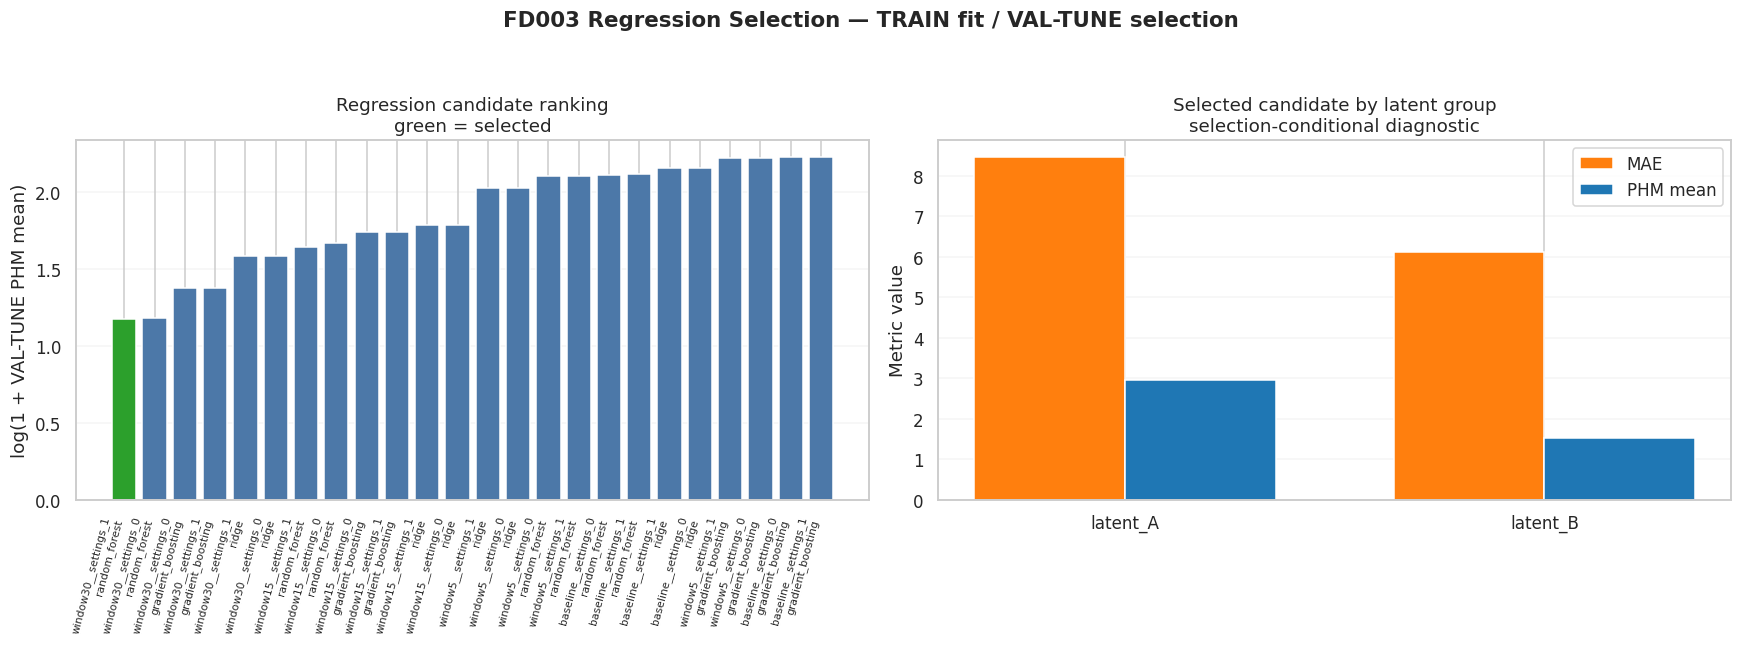

In [223]:
reload_model = selected_reload["model"]

reload_X_tune = reload_pipeline.transform(
    df_fd003_val_tune,
    scaled=selected_reload[
        "scaled_features"
    ],
)[0]

reload_prediction = np.clip(
    reload_model.predict(reload_X_tune),
    0.0,
    RUL_CAP,
)

selected_prediction_vector = (
    candidate_predictions.loc[
        candidate_predictions[
            "candidate_id"
        ]
        == selected_candidate_id,
        "prediction_clipped",
    ].to_numpy(float)
)

reload_prediction_parity = np.allclose(
    reload_prediction,
    selected_prediction_vector,
    rtol=0.0,
    atol=1e-12,
)

assert reload_prediction_parity





candidate_ranking.to_csv(
    candidate_summary_path,
    index=False,
)
candidate_predictions.to_csv(
    candidate_predictions_path,
    index=False,
)
subgroup_metrics.to_csv(
    subgroup_metrics_path,
    index=False,
)

ranking_reload = pd.read_csv(
    candidate_summary_path
)
prediction_reload = pd.read_csv(
    candidate_predictions_path
)
subgroup_reload = pd.read_csv(
    subgroup_metrics_path
)

assert ranking_reload.shape == (
    candidate_ranking.shape
)
assert prediction_reload.shape == (
    candidate_predictions.shape
)
assert subgroup_reload.shape == (
    subgroup_metrics.shape
)





fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

ranking_plot = candidate_ranking.copy()
ranking_plot["short_name"] = (
    ranking_plot[
        "feature_candidate_id"
    ]
    + "\n"
    + ranking_plot["model_name"]
)

axes[0].bar(
    np.arange(len(ranking_plot)),
    np.log1p(
        ranking_plot[
            "primary_PHM_score_mean"
        ].to_numpy(float)
    ),
    color=[
        "#2ca02c"
        if rank == 1
        else "#4c78a8"
        for rank in ranking_plot[
            "selection_rank"
        ]
    ],
)

axes[0].set_xticks(
    np.arange(len(ranking_plot))
)
axes[0].set_xticklabels(
    ranking_plot["short_name"],
    rotation=75,
    ha="right",
    fontsize=7,
)
axes[0].set_ylabel(
    "log(1 + VAL-TUNE PHM mean)"
)
axes[0].set_title(
    "Regression candidate ranking\n"
    "green = selected"
)
axes[0].grid(axis="y", alpha=0.2)

subgroup_plot = subgroup_metrics.sort_values(
    "latent_group"
)

x = np.arange(len(subgroup_plot))
width = 0.36

axes[1].bar(
    x - width / 2,
    subgroup_plot["MAE"],
    width=width,
    label="MAE",
    color="#ff7f0e",
)
axes[1].bar(
    x + width / 2,
    subgroup_plot[
        "PHM_score_mean"
    ],
    width=width,
    label="PHM mean",
    color="#1f77b4",
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    subgroup_plot["latent_group"]
)
axes[1].set_title(
    "Selected candidate by latent group\n"
    "selection-conditional diagnostic"
)
axes[1].set_ylabel("Metric value")
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend()

fig.suptitle(
    (
        f"{STAGE2_SUBSET} Regression Selection — "
        "TRAIN fit / VAL-TUNE selection"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()





selection_contract = {
    "artifact_type": (
        "regression_val_tune_selection_contract"
    ),
    "artifact_version": 1,
    "subset": STAGE2_SUBSET,
    "target": {
        "name": "RUL",
        "training_cap": RUL_CAP,
        "prediction_clip": [
            0.0,
            RUL_CAP,
        ],
    },
    "fit_role": "train",
    "selection_role": "val_tune",
    "calibration_role_accessed": False,
    "official_test_accessed": False,
    "feature_candidate_ids": list(
        feature_candidate_ids
    ),
    "model_grid": model_specs,
    "candidate_count": int(
        expected_candidate_count
    ),
    "primary_scope": (
        "VAL-TUNE rows with uncapped true RUL <= 100"
    ),
    "primary_metric": (
        "pooled-row PHM_score_mean"
    ),
    "tie_break_order": selection_order,
    "selected_candidate_id": (
        selected_candidate_id
    ),
    "selected_candidate": {
        key: (
            value.item()
            if isinstance(
                value,
                np.generic,
            )
            else value
        )
        for key, value in
        selected_row.to_dict().items()
    },
    "latent_group_metrics": {
        "selection_role": "diagnostic_only",
        "used_for_selection": False,
        "physical_fault_identity_claimed": False,
    },
    "selected_bundle": {
        "path": str(selected_bundle_path),
        "sha256": selected_bundle_sha256,
    },
    "feature_pipeline_bundle": {
        "path": str(feature_bundle_path),
        "sha256": feature_bundle_sha_before,
    },
    "official_test_status": "SEALED",
}


In [224]:
selection_contract_path.write_text(
    json.dumps(
        selection_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

selection_contract_sha256 = sha256_file(
    selection_contract_path
)

selection_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                selection_contract_path
            ),
            "sha256": (
                selection_contract_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

contract_reload = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)
sidecar_reload = json.loads(
    selection_sidecar_path.read_text(
        encoding="utf-8"
    )
)

feature_bundle_sha_after = sha256_file(
    feature_bundle_path
)





check_rows = [
    {
        "check": "upstream_contracts_valid",
        "passed": (
            sha256_file(feature_contract_path)
            == feature_sidecar["sha256"]
            and sha256_file(protocol_path)
            == protocol_sidecar["sha256"]
        ),
    },
    {
        "check": "official_test_gate_remains_sealed",
        "passed": (
            protocol["official_test_gate"][
                "status"
            ]
            == "SEALED"
            and not official_test_used
        ),
    },
    {
        "check": "val_calib_not_used",
        "passed": not val_calib_used,
    },
    {
        "check": "expected_candidate_count",
        "passed": (
            len(candidate_summary)
            == expected_candidate_count
        ),
    },
    {
        "check": "all_candidates_fit_on_70_engines",
        "passed": candidate_summary[
            "n_fit_engines"
        ].eq(70).all(),
    },
    {
        "check": "all_candidates_evaluated_on_20_tune_engines",
        "passed": candidate_summary[
            "n_tune_engines"
        ].eq(20).all(),
    },
    {
        "check": "all_metrics_finite",
        "passed": np.isfinite(
            candidate_summary.select_dtypes(
                include=[np.number]
            ).to_numpy(float)
        ).all(),
    },
    {
        "check": "helper_phm_parity",
        "passed": (
            len(helper_phm_parity_results)
            == expected_candidate_count
            and all(
                helper_phm_parity_results
            )
        ),
    },
    {
        "check": "selection_order_reconstructs_winner",
        "passed": (
            selected_candidate_id
            == candidate_ranking.iloc[0][
                "candidate_id"
            ]
        ),
    },
    {
        "check": "latent_groups_not_used_for_selection",
        "passed": (
            selection_contract[
                "latent_group_metrics"
            ]["used_for_selection"]
            is False
        ),
    },
    {
        "check": "both_tune_latent_groups_reported",
        "passed": (
            subgroup_metrics[
                "latent_group"
            ].nunique() == 2
        ),
    },
    {
        "check": "selected_bundle_reload_prediction_parity",
        "passed": (
            reload_prediction_parity
        ),
    },
    {
        "check": "feature_pipeline_bundle_unchanged",
        "passed": (
            feature_bundle_sha_before
            == feature_bundle_sha_after
        ),
    },
    {
        "check": "ranking_csv_shape_parity",
        "passed": (
            ranking_reload.shape
            == candidate_ranking.shape
        ),
    },
    {
        "check": "prediction_csv_shape_parity",
        "passed": (
            prediction_reload.shape
            == candidate_predictions.shape
        ),
    },
    {
        "check": "subgroup_csv_shape_parity",
        "passed": (
            subgroup_reload.shape
            == subgroup_metrics.shape
        ),
    },
    {
        "check": "selection_contract_reload_exact",
        "passed": (
            contract_reload
            == selection_contract
        ),
    },
    {
        "check": "selection_contract_hash_valid",
        "passed": (
            sha256_file(
                selection_contract_path
            )
            == sidecar_reload["sha256"]
            == selection_contract_sha256
        ),
    },
    {
        "check": "selection_figure_created",
        "passed": (
            figure_path.exists()
            and figure_path.stat().st_size > 0
        ),
    },
]

fd003_regression_selection_checks = (
    pd.DataFrame(check_rows)
)

assert fd003_regression_selection_checks[
    "passed"
].all(), (
    fd003_regression_selection_checks.loc[
        ~fd003_regression_selection_checks[
            "passed"
        ]
    ]
)





print(" COMPUTED FD003 REGRESSION SELECTION CHECKS ")
display(fd003_regression_selection_checks)

print("\n FD003 REGRESSION CANDIDATE RANKING — TOP 15 ")
display(candidate_ranking.head(15))

print("\n SELECTED REGRESSION CANDIDATE ")


 COMPUTED FD003 REGRESSION SELECTION CHECKS 


,check,passed
0,upstream_contracts_valid,True
1,official_test_gate_remains_sealed,True
2,val_calib_not_used,True
3,expected_candidate_count,True
4,all_candidates_fit_on_70_engines,True
5,all_candidates_evaluated_on_20_tune_engines,True
6,all_metrics_finite,True
7,helper_phm_parity,True
8,selection_order_reconstructs_winner,True
9,latent_groups_not_used_for_selection,True



 FD003 REGRESSION CANDIDATE RANKING — TOP 15 


,selection_rank,candidate_id,feature_candidate_id,representation,window,include_settings,n_features,model_name,model_parameters_json,scaled_features,...,primary_MAE,primary_RMSE,primary_R2,primary_mean_signed_error,capped_all_PHM_score_mean,capped_all_MAE,capped_all_RMSE,fit_seconds,inference_seconds,inference_us_per_row
0,1,window30__settings_1__model_random_forest,window30__settings_1,window,30,True,131,random_forest,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",False,...,7.288750,10.589142,0.868082,5.300286,1.144581,4.272310,7.873685,67.094860,0.045996,10.255624
1,2,window30__settings_0__model_random_forest,window30__settings_0,window,30,False,129,random_forest,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",False,...,7.347091,10.652998,0.866487,5.207825,1.171493,4.335874,7.989330,65.578073,0.046497,10.367166
2,3,window30__settings_0__model_gradient_boosting,window30__settings_0,window,30,False,129,gradient_boosting,"{""learning_rate"": 0.05, ""loss"": ""squared_error...",False,...,9.222457,12.443079,0.817847,6.625996,1.455899,5.287035,8.869893,75.825436,0.010216,2.277807
3,4,window30__settings_1__model_gradient_boosting,window30__settings_1,window,30,True,131,gradient_boosting,"{""learning_rate"": 0.05, ""loss"": ""squared_error...",False,...,9.222457,12.443079,0.817847,6.625996,1.455899,5.287035,8.869893,69.793944,0.007147,1.593526
4,5,window30__settings_1__model_ridge,window30__settings_1,window,30,True,131,ridge,"{""alpha"": 1.0}",True,...,11.894709,14.647792,0.747579,8.262111,2.131716,8.096694,11.534923,0.078917,0.004301,0.959070
5,6,window30__settings_0__model_ridge,window30__settings_0,window,30,False,129,ridge,"{""alpha"": 1.0}",True,...,11.894577,14.647627,0.747585,8.262279,2.131745,8.096701,11.534828,0.053416,0.005752,1.282485
6,7,window15__settings_1__model_random_forest,window15__settings_1,window,15,True,131,random_forest,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",False,...,9.353359,13.337859,0.790708,7.025237,2.041437,5.413774,9.630870,64.821251,0.105650,23.556216
7,8,window15__settings_0__model_random_forest,window15__settings_0,window,15,False,129,random_forest,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",False,...,9.343095,13.364683,0.789865,6.988990,2.094770,5.409577,9.650666,73.432317,0.057732,12.872321
8,9,window15__settings_0__model_gradient_boosting,window15__settings_0,window,15,False,129,gradient_boosting,"{""learning_rate"": 0.05, ""loss"": ""squared_error...",False,...,10.910715,14.698405,0.745832,8.728442,2.283625,6.282042,10.430710,68.797884,0.010731,2.392536
9,10,window15__settings_1__model_gradient_boosting,window15__settings_1,window,15,True,131,gradient_boosting,"{""learning_rate"": 0.05, ""loss"": ""squared_error...",False,...,10.910715,14.698405,0.745832,8.728442,2.283625,6.282042,10.430710,74.017295,0.011366,2.534328



 SELECTED REGRESSION CANDIDATE 


In [225]:
display(
    candidate_ranking.head(1)
)

print("\n SELECTED CANDIDATE LATENT-GROUP DIAGNOSTICS ")
display(subgroup_metrics)

print("Selected candidate:", selected_candidate_id)
print(
    "Selected primary PHM mean:",
    float(
        selected_row[
            "primary_PHM_score_mean"
        ]
    ),
)
print(
    "Selected primary MAE:",
    float(selected_row["primary_MAE"]),
)
print(
    "Selected primary RMSE:",
    float(selected_row["primary_RMSE"]),
)
print("VAL-CALIB used:", val_calib_used)
print("Official Test used:", official_test_used)
print(
    "Failed checks:",
    int(
        (~fd003_regression_selection_checks[
            "passed"
        ]).sum()
    ),
)
failed_selection_checks = int(
    (
        ~fd003_regression_selection_checks[
            "passed"
        ]
    ).sum()
)

regression_selection_status = (
    "PASS"
    if failed_selection_checks == 0
    else "FAIL"
)

print(
    "Failed checks:",
    failed_selection_checks,
)
print(
    "Regression selection status:",
    regression_selection_status,
)
print("Saved ranking:", candidate_summary_path)
print(
    "Saved selected bundle:",
    selected_bundle_path,
)
print(
    "Selected bundle SHA256:",
    selected_bundle_sha256,
)
print(
    "Saved selection contract:",
    selection_contract_path,
)
print(
    "Selection contract SHA256:",
    selection_contract_sha256,
)


,selection_rank,candidate_id,feature_candidate_id,representation,window,include_settings,n_features,model_name,model_parameters_json,scaled_features,...,primary_MAE,primary_RMSE,primary_R2,primary_mean_signed_error,capped_all_PHM_score_mean,capped_all_MAE,capped_all_RMSE,fit_seconds,inference_seconds,inference_us_per_row
0,1,window30__settings_1__model_random_forest,window30__settings_1,window,30,True,131,random_forest,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",False,...,7.28875,10.589142,0.868082,5.300286,1.144581,4.27231,7.873685,67.09486,0.045996,10.255624



 SELECTED CANDIDATE LATENT-GROUP DIAGNOSTICS 


,candidate_id,role,scope,latent_group,n_rows,n_engines,PHM_score_mean,PHM_score_sum,engine_equal_weight_PHM_mean,MAE,RMSE,R2,mean_signed_error
0,window30__settings_1__model_random_forest,val_tune,true_RUL_le_100,latent_A,1010,10,2.946930,2976.398806,2.946930,8.455464,12.004386,0.830464,6.145068
1,window30__settings_1__model_random_forest,val_tune,true_RUL_le_100,latent_B,1010,10,1.515673,1530.829478,1.515673,6.122035,8.952910,0.905700,4.455503


Selected candidate: window30__settings_1__model_random_forest
Selected primary PHM mean: 2.2313011305712362
Selected primary MAE: 7.288749659972865
Selected primary RMSE: 10.58914247798162
VAL-CALIB used: False
Official Test used: False
Failed checks: 0
Failed checks: 0
Regression selection status: PASS
Saved ranking: artifacts/results/FD003_regression_val_tune_candidates.csv
Saved selected bundle: artifacts/models/FD003_regression_selected_precalibration_bundle.joblib
Selected bundle SHA256: 65f7824c8741b7b2c9566e126ae9c59beb8b596db9c6973cf0bce794c167224f
Saved selection contract: data/processed/FD003_regression_selection.json
Selection contract SHA256: 92765df6eceb9e8c8859225f131fdaf0934c45143b1a119e2e7e0dfb6e8b7cf8


### FD003 VAL-CALIB conformal calibration and final regression freeze

The selected model is NOT refitted.
Only the reserved VAL-CALIB engines are used for conformal calibration.
FD003 Official Test and RUL_FD003 are not accessed.


In [226]:
import sys
import json
import math
import hashlib
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)





PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"

assert PROJECT_ROOT.is_dir()
assert SRC_DIR.is_dir()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from data_loader import (
    load_raw,
    add_train_rul,
)


SUBSET = "FD003"
RUL_CAP = 100.0
COVERAGE_TARGET = 0.90

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)





selected_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_regression_selected_precalibration_bundle.joblib"
)
selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_regression_selection.json"
)
selection_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_regression_selection.sha256"
)
split_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_engine_split.csv"
)
protocol_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.sha256"
)
latent_groups_path = (
    RESULT_DIR
    / f"{SUBSET}_latent_degradation_groups.csv"
)





final_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_regression_bundle.joblib"
)
conformal_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_rul_conformal.json"
)
conformal_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_rul_conformal.sha256"
)
calibration_predictions_path = (
    RESULT_DIR
    / f"{SUBSET}_regression_val_calib_predictions.csv"
)
calibration_metrics_path = (
    RESULT_DIR
    / f"{SUBSET}_regression_val_calib_metrics.csv"
)
latent_metrics_path = (
    RESULT_DIR
    / f"{SUBSET}_regression_val_calib_latent_group_metrics.csv"
)
figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_regression_val_calib_conformal.png"
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def read_sidecar_hash(path):
    text = path.read_text(
        encoding="utf-8"
    ).strip()

    try:
        data = json.loads(text)

        if isinstance(data, dict):
            value = str(
                data.get("sha256", "")
            ).strip().lower()

            if len(value) == 64:
                return value
    except json.JSONDecodeError:
        pass

    for token in text.replace(
        "\n",
        " ",
    ).split():
        token = token.strip().lower()

        if (
            len(token) == 64
            and all(
                character
                in "0123456789abcdef"
                for character in token
            )
        ):
            return token

    raise ValueError(
        f"No SHA256 value found in {path}"
    )

required_inputs = {
    "selected_bundle": selected_bundle_path,
    "selection_contract": (
        selection_contract_path
    ),
    "selection_sidecar": (
        selection_sidecar_path
    ),
    "development_split": split_path,
    "development_protocol": protocol_path,
    "development_protocol_sidecar": (
        protocol_sidecar_path
    ),
    "latent_groups": latent_groups_path,
}

for name, path in required_inputs.items():
    assert path.is_file(), (
        f"Missing {name}: {path}"
    )
    assert path.stat().st_size > 0, (
        f"Empty {name}: {path}"
    )

selection_contract = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)
protocol = json.loads(
    protocol_path.read_text(
        encoding="utf-8"
    )
)


In [227]:
selection_contract_sha_before = (
    sha256_file(selection_contract_path)
)
selected_bundle_sha_before = (
    sha256_file(selected_bundle_path)
)
protocol_sha_before = sha256_file(
    protocol_path
)

selection_sidecar_sha = read_sidecar_hash(
    selection_sidecar_path
)
protocol_sidecar_sha = read_sidecar_hash(
    protocol_sidecar_path
)

assert (
    selection_contract_sha_before
    == selection_sidecar_sha
)
assert (
    protocol_sha_before
    == protocol_sidecar_sha
)

assert (
    selection_contract["subset"]
    == SUBSET
)
assert (
    selection_contract[
        "official_test_status"
    ]
    == "SEALED"
)
assert (
    selection_contract[
        "calibration_role_accessed"
    ]
    is False
)
assert (
    selection_contract[
        "official_test_accessed"
    ]
    is False
)

assert (
    selection_contract[
        "selected_bundle"
    ]["sha256"]
    == selected_bundle_sha_before
)

assert (
    protocol["official_test_gate"][
        "status"
    ]
    == "SEALED"
)
assert (
    protocol["official_test_gate"][
        "evaluation_authorized"
    ]
    is False
)

selected_bundle = joblib.load(
    selected_bundle_path
)

assert selected_bundle["subset"] == SUBSET
assert selected_bundle["fit_role"] == "train"
assert (
    selected_bundle["selection_role"]
    == "val_tune"
)
assert (
    selected_bundle[
        "calibration_role"
    ]
    == "val_calib_reserved"
)
assert (
    selected_bundle[
        "official_test_status"
    ]
    == "SEALED"
)

selected_candidate_id = str(
    selected_bundle["candidate_id"]
)
selected_pipeline = selected_bundle[
    "feature_pipeline"
]
selected_model = selected_bundle["model"]
scaled_features = bool(
    selected_bundle["scaled_features"]
)

assert float(
    selected_bundle["target_cap"]
) == RUL_CAP

loaded_data_roles = []

df_fd003_all = load_raw(
    SUBSET,
    "train",
)
loaded_data_roles.append("official_train")

df_fd003_all = add_train_rul(
    df_fd003_all,
    cap=None,
)

development_split = pd.read_csv(
    split_path
)

assert {
    "engine_id",
    "role",
}.issubset(development_split.columns)

development_split["engine_id"] = (
    development_split[
        "engine_id"
    ].astype(int)
)

val_calib_engine_ids = set(
    development_split.loc[
        (
            development_split["role"]
            == "val_calib"
        ),
        "engine_id",
    ]
)

assert len(val_calib_engine_ids) == 10

df_fd003_val_calib = (
    df_fd003_all.loc[
        df_fd003_all["engine_id"].isin(
            val_calib_engine_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

used_development_roles = ["val_calib"]

official_test_accessed = any(
    "test" in role.lower()
    for role in loaded_data_roles
)
official_rul_accessed = any(
    "rul_file" in role.lower()
    for role in loaded_data_roles
)

assert not official_test_accessed
assert not official_rul_accessed
assert used_development_roles == [
    "val_calib"
]
assert len(df_fd003_val_calib) == 2016
assert (
    df_fd003_val_calib[
        "engine_id"
    ].nunique()
    == 10
)

X_calib, y_calib_series, _, calib_meta, _ = (
    selected_pipeline.transform(
        df_fd003_val_calib,
        scaled=scaled_features,
    )
)

assert len(X_calib) == 2016
assert X_calib.index.equals(
    df_fd003_val_calib.index
)
assert y_calib_series.index.equals(
    df_fd003_val_calib.index
)
assert calib_meta.index.equals(
    df_fd003_val_calib.index
)
assert np.isfinite(
    X_calib.to_numpy(dtype=float)
).all()

prediction_raw = selected_model.predict(
    X_calib
)
prediction = np.clip(
    np.asarray(
        prediction_raw,
        dtype=float,
    ),
    0.0,
    RUL_CAP,
)

In [228]:
y_uncapped = y_calib_series.to_numpy(
    dtype=float
)
y_capped = np.minimum(
    y_uncapped,
    RUL_CAP,
)

assert len(prediction) == len(y_capped)
assert np.isfinite(prediction).all()
assert np.all(prediction >= 0.0)
assert np.all(prediction <= RUL_CAP)

absolute_residual = np.abs(
    y_capped - prediction
)

n_calibration_rows = len(
    absolute_residual
)

quantile_rank = int(
    math.ceil(
        (n_calibration_rows + 1)
        * COVERAGE_TARGET
    )
)
quantile_rank = min(
    quantile_rank,
    n_calibration_rows,
)

sorted_residuals = np.sort(
    absolute_residual
)
residual_quantile = float(
    sorted_residuals[
        quantile_rank - 1
    ]
)

assert np.isfinite(
    residual_quantile
)
assert residual_quantile >= 0.0

conformal_lower = np.maximum(
    0.0,
    prediction - residual_quantile,
)
conformal_upper = (
    prediction + residual_quantile
)

covered_capped_target = (
    (y_capped >= conformal_lower)
    & (y_capped <= conformal_upper)
)

empirical_coverage = float(
    covered_capped_target.mean()
)
average_width = float(
    np.mean(
        conformal_upper
        - conformal_lower
    )
)

assert np.all(
    conformal_lower <= prediction
)
assert np.all(
    prediction <= conformal_upper
)
assert empirical_coverage >= (
    COVERAGE_TARGET - 1e-12
)
assert average_width > 0.0

primary_mask = (
    y_uncapped <= RUL_CAP
)

assert primary_mask.any()
assert (
    calib_meta.loc[
        primary_mask,
        "engine_id",
    ].nunique()
    == 10
)

def phm_loss_values(y_true, y_pred):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    error = y_pred - y_true

    values = np.where(
        error < 0,
        np.exp(-error / 13.0) - 1.0,
        np.exp(error / 10.0) - 1.0,
    )

    assert np.isfinite(values).all()
    assert np.all(values >= 0.0)

    return values

def calculate_metrics(
    y_true,
    y_pred,
    covered,
    lower,
    upper,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )
    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )
    covered = np.asarray(
        covered,
        dtype=bool,
    )
    lower = np.asarray(
        lower,
        dtype=float,
    )
    upper = np.asarray(
        upper,
        dtype=float,
    )

    phm_values = phm_loss_values(
        y_true,
        y_pred,
    )

    return {
        "n_rows": int(len(y_true)),
        "PHM_score_mean": float(
            phm_values.mean()
        ),
        "PHM_score_sum": float(
            phm_values.sum()
        ),
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            )
        ),
        "R2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "mean_signed_error": float(
            np.mean(y_pred - y_true)
        ),
        "conformal_coverage": float(
            covered.mean()
        ),
        "conformal_average_width": float(
            np.mean(upper - lower)
        ),
    }

all_capped_metrics = calculate_metrics(
    y_capped,
    prediction,
    covered_capped_target,
    conformal_lower,
    conformal_upper,
)

primary_metrics = calculate_metrics(
    y_uncapped[primary_mask],
    prediction[primary_mask],
    covered_capped_target[primary_mask],
    conformal_lower[primary_mask],
    conformal_upper[primary_mask],
)

calibration_predictions = pd.DataFrame(
    {
        "engine_id": calib_meta[
            "engine_id"
        ].to_numpy(dtype=int),
        "cycle": calib_meta[
            "cycle"
        ].to_numpy(dtype=int),
        "true_RUL_uncapped": y_uncapped,
        "true_RUL_capped": y_capped,
        "prediction_raw": np.asarray(
            prediction_raw,
            dtype=float,
        ),
        "prediction_clipped": prediction,
        "absolute_residual_capped": (
            absolute_residual
        ),
        "conformal_lower": conformal_lower,
        "conformal_upper": conformal_upper,
        "covered_capped_target": (
            covered_capped_target
        ),
        "primary_scope_row": primary_mask,
    }
)

In [229]:
latent_groups = pd.read_csv(
    latent_groups_path
)

val_calib_latent_groups = (
    latent_groups.loc[
        latent_groups["role"]
        == "val_calib",
        [
            "engine_id",
            "latent_group",
        ],
    ]
    .copy()
)

val_calib_latent_groups[
    "engine_id"
] = val_calib_latent_groups[
    "engine_id"
].astype(int)

assert (
    val_calib_latent_groups[
        "engine_id"
    ].nunique()
    == 10
)
assert set(
    val_calib_latent_groups[
        "engine_id"
    ]
) == val_calib_engine_ids

calibration_predictions = (
    calibration_predictions.merge(
        val_calib_latent_groups,
        on="engine_id",
        how="left",
        validate="many_to_one",
    )
)

assert calibration_predictions[
    "latent_group"
].notna().all()

latent_metric_rows = []

for latent_group, group in (
    calibration_predictions.groupby(
        "latent_group",
        sort=True,
    )
):
    group_primary = group.loc[
        group["primary_scope_row"]
    ]

    metrics = calculate_metrics(
        group_primary[
            "true_RUL_uncapped"
        ].to_numpy(dtype=float),
        group_primary[
            "prediction_clipped"
        ].to_numpy(dtype=float),
        group_primary[
            "covered_capped_target"
        ].to_numpy(dtype=bool),
        group_primary[
            "conformal_lower"
        ].to_numpy(dtype=float),
        group_primary[
            "conformal_upper"
        ].to_numpy(dtype=float),
    )

    latent_metric_rows.append(
        {
            "candidate_id": (
                selected_candidate_id
            ),
            "role": "val_calib",
            "scope": "true_RUL_le_100",
            "latent_group": latent_group,
            "n_engines": int(
                group_primary[
                    "engine_id"
                ].nunique()
            ),
            **metrics,
        }
    )

latent_metrics = pd.DataFrame(
    latent_metric_rows
)

assert (
    latent_metrics[
        "latent_group"
    ].nunique()
    == 2
)
assert (
    latent_metrics["n_engines"].sum()
    == 10
)

calibration_metrics = pd.DataFrame(
    [
        {
            "scope": (
                "all_val_calib_rows_capped_target"
            ),
            "n_engines": 10,
            "coverage_target": (
                COVERAGE_TARGET
            ),
            "residual_quantile": (
                residual_quantile
            ),
            **all_capped_metrics,
        },
        {
            "scope": (
                "val_calib_true_RUL_le_100"
            ),
            "n_engines": int(
                calib_meta.loc[
                    primary_mask,
                    "engine_id",
                ].nunique()
            ),
            "coverage_target": (
                COVERAGE_TARGET
            ),
            "residual_quantile": (
                residual_quantile
            ),
            **primary_metrics,
        },
    ]
)

final_regression_bundle = {
    "schema_version": 1,
    "subset": SUBSET,
    "feature_pipeline": (
        selected_pipeline
    ),
    "model": selected_model,
    "model_name": selected_bundle[
        "model_name"
    ],
    "model_parameters": (
        selected_bundle[
            "model_parameters"
        ]
    ),
    "scaled_features": (
        scaled_features
    ),
    "representation": (
        selected_pipeline.representation
    ),
    "window": int(
        selected_pipeline.window
    ),
    "include_settings": bool(
        selected_pipeline.include_settings
    ),
    "cap": int(RUL_CAP),
    "candidate_id": (
        selected_candidate_id
    ),
    "fit_role": (
        "official_train/train"
    ),
    "selection_role": (
        "official_train/val_tune"
    ),
    "calibration_role": (
        "official_train/val_calib"
    ),
    "source_selected_bundle": {
        "path": str(
            selected_bundle_path
        ),
        "sha256": (
            selected_bundle_sha_before
        ),
    },
    "official_test_status": "sealed",
}

joblib.dump(
    final_regression_bundle,
    final_bundle_path,
)

final_bundle_sha256 = sha256_file(
    final_bundle_path
)

conformal_contract = {
    "schema_version": 1,
    "subset": SUBSET,
    "method": (
        "split conformal absolute residual"
    ),
    "interpretation": (
        "Symmetric finite-sample interval "
        "calibrated for the capped RUL target."
    ),
    "coverage_target": (
        COVERAGE_TARGET
    ),
    "residual_quantile": (
        residual_quantile
    ),
    "finite_sample_quantile": {
        "n_calibration_rows": (
            n_calibration_rows
        ),
        "rank": quantile_rank,
        "formula": (
            "ceil((n + 1) * coverage_target)"
        ),
    },
    "target": {
        "name": "RUL",
        "unit": "cycles",
        "cap": int(RUL_CAP),
    },
    "fit_role": (
        "official_train/val_calib"
    ),
    "fit_engine_ids": sorted(
        int(engine_id)
        for engine_id
        in val_calib_engine_ids
    ),
    "n_fit_engines": 10,
    "n_fit_rows": (
        n_calibration_rows
    ),
    "calibration_diagnostic": {
        "empirical_coverage": (
            empirical_coverage
        ),
        "average_width_cycles": (
            average_width
        ),
    },
    "regression_bundle": {
        "path": str(final_bundle_path),
        "sha256": (
            final_bundle_sha256
        ),
    },
    "source_selection_contract": {
        "path": str(
            selection_contract_path
        ),
        "sha256": (
            selection_contract_sha_before
        ),
    },
    "latent_groups": {
        "used_for_calibration": False,
        "diagnostic_only": True,
        "physical_fault_identity_claimed": (
            False
        ),
    },
    "official_test_status": "sealed",
}


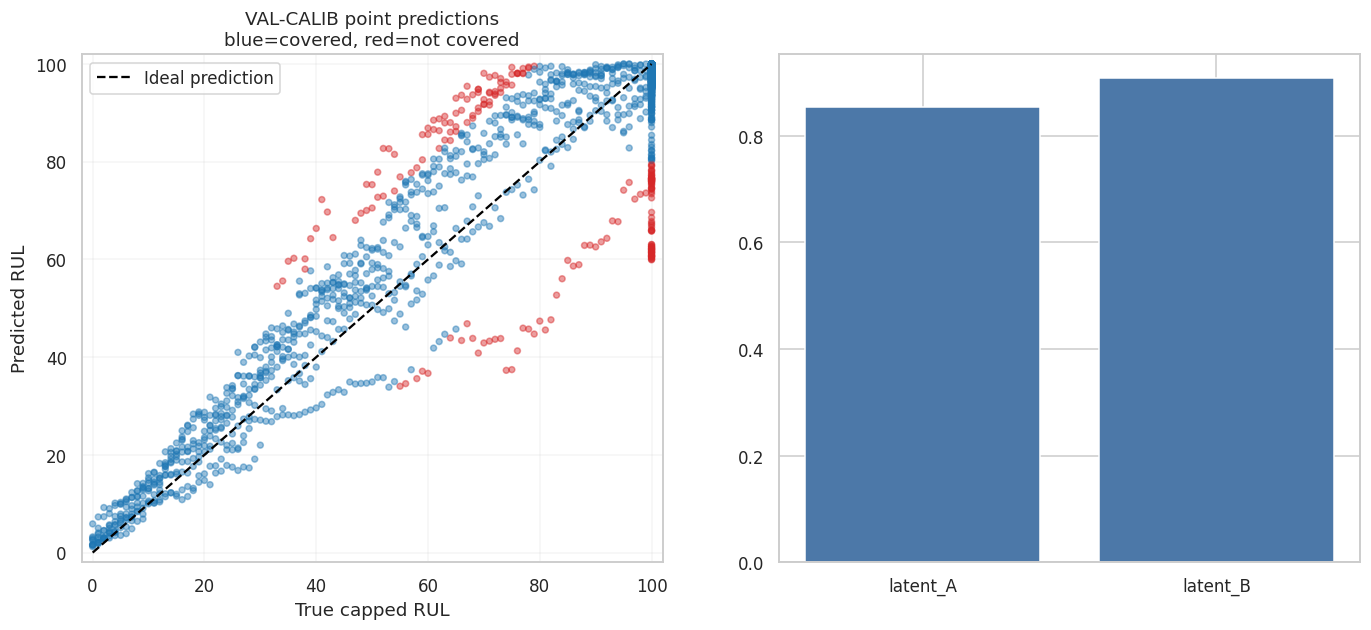

In [230]:
conformal_contract_path.write_text(
    json.dumps(
        conformal_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

conformal_contract_sha256 = (
    sha256_file(
        conformal_contract_path
    )
)

conformal_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                conformal_contract_path
            ),
            "sha256": (
                conformal_contract_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

calibration_predictions.to_csv(
    calibration_predictions_path,
    index=False,
)
calibration_metrics.to_csv(
    calibration_metrics_path,
    index=False,
)
latent_metrics.to_csv(
    latent_metrics_path,
    index=False,
)

final_bundle_reload = joblib.load(
    final_bundle_path
)
conformal_reload = json.loads(
    conformal_contract_path.read_text(
        encoding="utf-8"
    )
)
conformal_sidecar_reload = json.loads(
    conformal_sidecar_path.read_text(
        encoding="utf-8"
    )
)

prediction_reload = pd.read_csv(
    calibration_predictions_path
)
metrics_reload = pd.read_csv(
    calibration_metrics_path
)
latent_reload = pd.read_csv(
    latent_metrics_path
)

reload_X = final_bundle_reload[
    "feature_pipeline"
].transform(
    df_fd003_val_calib,
    scaled=final_bundle_reload[
        "scaled_features"
    ],
)[0]

reload_prediction = np.clip(
    final_bundle_reload[
        "model"
    ].predict(reload_X),
    0.0,
    RUL_CAP,
)

reload_prediction_parity = np.allclose(
    reload_prediction,
    prediction,
    rtol=0.0,
    atol=1e-12,
)

assert reload_prediction_parity

assert conformal_reload == (
    conformal_contract
)
assert (
    conformal_sidecar_reload[
        "sha256"
    ]
    == conformal_contract_sha256
    == sha256_file(
        conformal_contract_path
    )
)

assert prediction_reload.shape == (
    calibration_predictions.shape
)
assert metrics_reload.shape == (
    calibration_metrics.shape
)
assert latent_reload.shape == (
    latent_metrics.shape
)

csv_prediction_parity = np.allclose(
    prediction_reload[
        "prediction_clipped"
    ].to_numpy(dtype=float),
    calibration_predictions[
        "prediction_clipped"
    ].to_numpy(dtype=float),
    rtol=0.0,
    atol=1e-10,
)

assert csv_prediction_parity

selection_contract_unchanged = (
    sha256_file(
        selection_contract_path
    )
    == selection_contract_sha_before
)
selected_bundle_unchanged = (
    sha256_file(
        selected_bundle_path
    )
    == selected_bundle_sha_before
)
protocol_unchanged = (
    sha256_file(protocol_path)
    == protocol_sha_before
)

assert selection_contract_unchanged
assert selected_bundle_unchanged
assert protocol_unchanged

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

covered_colors = np.where(
    covered_capped_target,
    "#1f77b4",
    "#d62728",
)

axes[0].scatter(
    y_capped,
    prediction,
    c=covered_colors,
    alpha=0.45,
    s=15,
)

axes[0].plot(
    [0, RUL_CAP],
    [0, RUL_CAP],
    linestyle="--",
    color="black",
    label="Ideal prediction",
)

axes[0].set_xlabel(
    "True capped RUL"
)
axes[0].set_ylabel(
    "Predicted RUL"
)
axes[0].set_title(
    "VAL-CALIB point predictions\n"
    "blue=covered, red=not covered"
)
axes[0].set_xlim(-2, 102)
axes[0].set_ylim(-2, 102)
axes[0].grid(alpha=0.2)
axes[0].legend()

group_plot = latent_metrics.sort_values(
    "latent_group"
)

bars = axes[1].bar(
    group_plot["latent_group"],
    group_plot[
        "conformal_coverage"
    ],
    color="#4c78a8",
)

In [231]:
axes[1].axhline(
    COVERAGE_TARGET,
    color="red",
    linestyle="--",
    label=(
        f"Target = {COVERAGE_TARGET:.2f}"
    ),
)

for bar, coverage in zip(
    bars,
    group_plot[
        "conformal_coverage"
    ],
):
    axes[1].text(
        bar.get_x()
        + bar.get_width() / 2,
        float(coverage) + 0.01,
        f"{coverage:.3f}",
        ha="center",
    )

axes[1].set_ylim(0.0, 1.08)
axes[1].set_ylabel(
    "Empirical conformal coverage"
)
axes[1].set_title(
    "Selection-conditional coverage\n"
    "by descriptive latent group"
)
axes[1].grid(
    axis="y",
    alpha=0.2,
)
axes[1].legend()

fig.suptitle(
    (
        f"{SUBSET} Regression Conformal "
        "Calibration — VAL-CALIB"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.94]
)
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [232]:
check_rows = [
    {
        "check": (
            "selection_contract_hash_valid"
        ),
        "passed": (
            selection_contract_sha_before
            == selection_sidecar_sha
        ),
    },
    {
        "check": (
            "selected_bundle_hash_matches_selection_contract"
        ),
        "passed": (
            selected_bundle_sha_before
            == selection_contract[
                "selected_bundle"
            ]["sha256"]
        ),
    },
    {
        "check": (
            "official_test_gate_remains_sealed"
        ),
        "passed": (
            protocol[
                "official_test_gate"
            ]["status"]
            == "SEALED"
            and not official_test_accessed
            and not official_rul_accessed
        ),
    },
    {
        "check": (
            "only_val_calib_role_used"
        ),
        "passed": (
            used_development_roles
            == ["val_calib"]
        ),
    },
    {
        "check": (
            "exactly_10_calibration_engines"
        ),
        "passed": (
            df_fd003_val_calib[
                "engine_id"
            ].nunique()
            == 10
        ),
    },
    {
        "check": (
            "exactly_2016_calibration_rows"
        ),
        "passed": (
            len(df_fd003_val_calib)
            == 2016
        ),
    },
    {
        "check": (
            "feature_matrix_alignment"
        ),
        "passed": (
            X_calib.index.equals(
                df_fd003_val_calib.index
            )
        ),
    },
    {
        "check": (
            "predictions_finite_and_bounded"
        ),
        "passed": (
            np.isfinite(
                prediction
            ).all()
            and np.all(
                prediction >= 0.0
            )
            and np.all(
                prediction <= RUL_CAP
            )
        ),
    },
    {
        "check": (
            "finite_sample_quantile_valid"
        ),
        "passed": (
            np.isfinite(
                residual_quantile
            )
            and residual_quantile >= 0.0
            and 1
            <= quantile_rank
            <= n_calibration_rows
        ),
    },
    {
        "check": (
            "calibration_coverage_reaches_target"
        ),
        "passed": (
            empirical_coverage
            >= COVERAGE_TARGET
            - 1e-12
        ),
    },
    {
        "check": (
            "conformal_bounds_ordered"
        ),
        "passed": (
            np.all(
                conformal_lower
                <= prediction
            )
            and np.all(
                prediction
                <= conformal_upper
            )
        ),
    },
    {
        "check": (
            "both_latent_groups_reported"
        ),
        "passed": (
            latent_metrics[
                "latent_group"
            ].nunique()
            == 2
        ),
    },
    {
        "check": (
            "latent_groups_diagnostic_only"
        ),
        "passed": (
            conformal_contract[
                "latent_groups"
            ]["used_for_calibration"]
            is False
        ),
    },
    {
        "check": (
            "final_bundle_reload_prediction_parity"
        ),
        "passed": (
            reload_prediction_parity
        ),
    },
    {
        "check": (
            "upstream_selection_contract_unchanged"
        ),
        "passed": (
            selection_contract_unchanged
        ),
    },
    {
        "check": (
            "upstream_selected_bundle_unchanged"
        ),
        "passed": (
            selected_bundle_unchanged
        ),
    },
    {
        "check": (
            "development_protocol_unchanged"
        ),
        "passed": (
            protocol_unchanged
        ),
    },
    {
        "check": (
            "prediction_csv_parity"
        ),
        "passed": (
            csv_prediction_parity
        ),
    },
    {
        "check": (
            "conformal_contract_reload_exact"
        ),
        "passed": (
            conformal_reload
            == conformal_contract
        ),
    },
    {
        "check": (
            "conformal_contract_hash_valid"
        ),
        "passed": (
            sha256_file(
                conformal_contract_path
            )
            == conformal_contract_sha256
            == conformal_sidecar_reload[
                "sha256"
            ]
        ),
    },
    {
        "check": (
            "calibration_figure_created"
        ),
        "passed": (
            figure_path.is_file()
            and figure_path.stat().st_size
            > 0
        ),
    },
]

In [233]:
fd003_regression_calibration_checks = (
    pd.DataFrame(check_rows)
)

failed_checks = int(
    (
        ~fd003_regression_calibration_checks[
            "passed"
        ]
    ).sum()
)

calibration_status = (
    "PASS"
    if failed_checks == 0
    else "FAIL"
)

assert failed_checks == 0, (
    fd003_regression_calibration_checks.loc[
        ~fd003_regression_calibration_checks[
            "passed"
        ]
    ]
)

print(
    " COMPUTED FD003 REGRESSION CALIBRATION CHECKS "
)
display(
    fd003_regression_calibration_checks
)

print(
    "\n FD003 VAL-CALIB REGRESSION METRICS "
)
display(calibration_metrics)

print(
    "\n FD003 VAL-CALIB LATENT-GROUP DIAGNOSTICS "
)
display(latent_metrics)

print(
    "Selected candidate:",
    selected_candidate_id,
)
print(
    "Conformal coverage target:",
    COVERAGE_TARGET,
)
print(
    "Finite-sample residual quantile:",
    residual_quantile,
)
print(
    "Calibration empirical coverage:",
    empirical_coverage,
)
print(
    "Calibration average interval width:",
    average_width,
)
print(
    "Loaded data roles:",
    loaded_data_roles,
)
print(
    "Official Test accessed:",
    official_test_accessed,
)
print(
    "Official RUL accessed:",
    official_rul_accessed,
)
print(
    "Executed checks:",
    len(
        fd003_regression_calibration_checks
    ),
)
print(
    "Failed checks:",
    failed_checks,
)
print(
    "Regression calibration status:",
    calibration_status,
)
print(
    "Saved final regression bundle:",
    final_bundle_path,
)
print(
    "Final regression bundle SHA256:",
    final_bundle_sha256,
)
print(
    "Saved conformal contract:",
    conformal_contract_path,
)
print(
    "Conformal contract SHA256:",
    conformal_contract_sha256,
)
print(
    "Saved calibration predictions:",
    calibration_predictions_path,
)
print(
    "Saved calibration metrics:",
    calibration_metrics_path,
)


 COMPUTED FD003 REGRESSION CALIBRATION CHECKS 


,check,passed
0,selection_contract_hash_valid,True
1,selected_bundle_hash_matches_selection_contract,True
2,official_test_gate_remains_sealed,True
3,only_val_calib_role_used,True
4,exactly_10_calibration_engines,True
5,exactly_2016_calibration_rows,True
6,feature_matrix_alignment,True
7,predictions_finite_and_bounded,True
8,finite_sample_quantile_valid,True
9,calibration_coverage_reaches_target,True



 FD003 VAL-CALIB REGRESSION METRICS 


,scope,n_engines,coverage_target,residual_quantile,n_rows,PHM_score_mean,PHM_score_sum,MAE,RMSE,R2,mean_signed_error,conformal_coverage,conformal_average_width
0,all_val_calib_rows_capped_target,10,0.9,19.959349,2016,1.630578,3287.245367,6.630824,10.643783,0.892191,0.720887,0.900794,39.065793
1,val_calib_true_RUL_le_100,10,0.9,19.959349,1010,2.311715,2334.832316,9.347859,12.144949,0.826471,5.326447,0.870297,38.216265



 FD003 VAL-CALIB LATENT-GROUP DIAGNOSTICS 


,candidate_id,role,scope,latent_group,n_engines,n_rows,PHM_score_mean,PHM_score_sum,MAE,RMSE,R2,mean_signed_error,conformal_coverage,conformal_average_width
0,window30__settings_1__model_random_forest,val_calib,true_RUL_le_100,latent_A,7,707,2.495159,1764.077365,9.815271,12.802088,0.807184,4.313933,0.854314,38.203440
1,window30__settings_1__model_random_forest,val_calib,true_RUL_le_100,latent_B,3,303,1.883680,570.754951,8.257231,10.452170,0.871473,7.688979,0.907591,38.246188


Selected candidate: window30__settings_1__model_random_forest
Conformal coverage target: 0.9
Finite-sample residual quantile: 19.95934920634916
Calibration empirical coverage: 0.9007936507936508
Calibration average interval width: 39.06579256227945
Loaded data roles: ['official_train']
Official Test accessed: False
Official RUL accessed: False
Executed checks: 21
Failed checks: 0
Regression calibration status: PASS
Saved final regression bundle: artifacts/models/FD003_regression_bundle.joblib
Final regression bundle SHA256: 07b1ff9c4c812d5933a946f0501040e6878d0460d872771ef0825618c415cf07
Saved conformal contract: data/processed/FD003_rul_conformal.json
Conformal contract SHA256: 4de22bd94ffbbe23975e9f777275735b01f3487a9177b850f77fcc7092d039fb
Saved calibration predictions: artifacts/results/FD003_regression_val_calib_predictions.csv
Saved calibration metrics: artifacts/results/FD003_regression_val_calib_metrics.csv


### FD003 classification fitting and VAL-TUNE selection

Functional-first version:
8 feature pipelines × 3 horizons × 1 reliable classifier.
VAL-CALIB and Official Test are not used.


In [234]:
import sys
import json
import time
import hashlib
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)

PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"

assert PROJECT_ROOT.is_dir()
assert SRC_DIR.is_dir()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from data_loader import (
    load_raw,
    add_train_rul,
)

SUBSET = "FD003"
SEED = int(config.RANDOM_SEED)
HORIZONS = (10, 20, 30)

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

feature_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_feature_pipeline_candidates.joblib"
)
feature_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_feature_pipeline_contract.json"
)
feature_contract_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_feature_pipeline_contract.sha256"
)
protocol_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.sha256"
)
split_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_engine_split.csv"
)
latent_groups_path = (
    RESULT_DIR
    / f"{SUBSET}_latent_degradation_groups.csv"
)

ranking_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_tune_candidates.csv"
)
prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_tune_predictions.csv"
)
per_engine_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_tune_per_engine.csv"
)
latent_metric_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_tune_latent_group_metrics.csv"
)
selected_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_classification_selected_precalibration_bundle.joblib"
)
selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_selection.json"
)
selection_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_selection.sha256"
)
figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_classification_val_tune_selection.png"
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

def read_sidecar_hash(path):
    text = path.read_text(
        encoding="utf-8"
    ).strip()

    try:
        data = json.loads(text)

        if isinstance(data, dict):
            value = str(
                data.get("sha256", "")
            ).strip().lower()

            if len(value) == 64:
                return value
    except json.JSONDecodeError:
        pass

    for token in text.replace(
        "\n",
        " ",
    ).split():
        token = token.strip().lower()

        if (
            len(token) == 64
            and all(
                character
                in "0123456789abcdef"
                for character in token
            )
        ):
            return token

    raise ValueError(
        f"No SHA256 found in {path}"
    )

required_inputs = {
    "feature_bundle": feature_bundle_path,
    "feature_contract": feature_contract_path,
    "feature_contract_sidecar": (
        feature_contract_sidecar_path
    ),
    "development_protocol": protocol_path,
    "development_protocol_sidecar": (
        protocol_sidecar_path
    ),
    "development_split": split_path,
    "latent_groups": latent_groups_path,
}

for name, path in required_inputs.items():
    assert path.is_file(), (
        f"Missing {name}: {path}"
    )
    assert path.stat().st_size > 0

feature_bundle_sha_before = (
    sha256_file(feature_bundle_path)
)
feature_contract_sha_before = (
    sha256_file(feature_contract_path)
)
protocol_sha_before = (
    sha256_file(protocol_path)
)

In [235]:
assert (
    feature_contract_sha_before
    == read_sidecar_hash(
        feature_contract_sidecar_path
    )
)
assert (
    protocol_sha_before
    == read_sidecar_hash(
        protocol_sidecar_path
    )
)

feature_contract = json.loads(
    feature_contract_path.read_text(
        encoding="utf-8"
    )
)
protocol = json.loads(
    protocol_path.read_text(
        encoding="utf-8"
    )
)

assert feature_contract["subset"] == SUBSET
assert (
    feature_contract[
        "official_test_accessed"
    ]
    is False
)
assert (
    protocol["official_test_gate"][
        "status"
    ]
    == "SEALED"
)
assert (
    protocol["official_test_gate"][
        "evaluation_authorized"
    ]
    is False
)

loaded_data_roles = []

df_all = load_raw(
    SUBSET,
    "train",
)
loaded_data_roles.append("official_train")

df_all = add_train_rul(
    df_all,
    cap=None,
)

split_table = pd.read_csv(
    split_path
)

assert {
    "engine_id",
    "role",
}.issubset(split_table.columns)

split_table["engine_id"] = (
    split_table["engine_id"].astype(int)
)

train_ids = set(
    split_table.loc[
        split_table["role"] == "train",
        "engine_id",
    ]
)
tune_ids = set(
    split_table.loc[
        split_table["role"]
        == "val_tune",
        "engine_id",
    ]
)

assert len(train_ids) == 70
assert len(tune_ids) == 20
assert train_ids.isdisjoint(tune_ids)

df_train = (
    df_all.loc[
        df_all["engine_id"].isin(
            train_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

df_tune = (
    df_all.loc[
        df_all["engine_id"].isin(
            tune_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

assert len(df_train) == 18219
assert len(df_tune) == 4485
assert (
    df_train["engine_id"].nunique()
    == 70
)
assert (
    df_tune["engine_id"].nunique()
    == 20
)

used_development_roles = [
    "train",
    "val_tune",
]
val_calib_used = (
    "val_calib"
    in used_development_roles
)
official_test_used = any(
    "test" in role.lower()
    for role in loaded_data_roles
)

assert not val_calib_used
assert not official_test_used

for horizon in HORIZONS:
    label_name = f"label_h{horizon}"

    df_train[label_name] = (
        df_train["RUL"] <= horizon
    ).astype(int)

    df_tune[label_name] = (
        df_tune["RUL"] <= horizon
    ).astype(int)

assert np.all(
    df_train["label_h10"]
    <= df_train["label_h20"]
)
assert np.all(
    df_train["label_h20"]
    <= df_train["label_h30"]
)
assert np.all(
    df_tune["label_h10"]
    <= df_tune["label_h20"]
)
assert np.all(
    df_tune["label_h20"]
    <= df_tune["label_h30"]
)

for horizon in HORIZONS:
    label_name = f"label_h{horizon}"

    assert set(
        df_train[label_name].unique()
    ) == {0, 1}

    assert set(
        df_tune[label_name].unique()
    ) == {0, 1}

feature_bundle = joblib.load(
    feature_bundle_path
)

assert feature_bundle["subset"] == SUBSET
assert feature_bundle["fit_role"] == "train"
assert (
    feature_bundle[
        "official_test_status"
    ]
    == "SEALED"
)

feature_pipelines = feature_bundle[
    "pipelines"
]
feature_candidate_ids = list(
    feature_bundle["candidate_ids"]
)

assert len(feature_candidate_ids) == 8
assert set(feature_candidate_ids) == set(
    feature_pipelines
)

model_parameters = {
    "C": 1.0,
    "class_weight": "balanced",
    "solver": "liblinear",
    "max_iter": 3000,
    "random_state": SEED,
}


In [236]:
MODEL_NAME = (
    "logistic_regression_balanced"
)
SCALED_FEATURES = True

expected_fit_count = (
    len(feature_candidate_ids)
    * len(HORIZONS)
)

candidate_rows = []
prediction_frames = []
per_engine_rows = []
fitted_lookup = {}
fit_count = 0

In [237]:
for horizon in HORIZONS:
    label_name = f"label_h{horizon}"

    for feature_candidate_id in (
        feature_candidate_ids
    ):
        pipeline = feature_pipelines[
            feature_candidate_id
        ]

        candidate_id = (
            f"h{horizon}__"
            f"{feature_candidate_id}__"
            "logreg_balanced"
        )

        X_train, _, train_labels, train_meta, _ = (
            pipeline.transform(
                df_train,
                scaled=SCALED_FEATURES,
            )
        )

        X_tune, _, tune_labels, tune_meta, _ = (
            pipeline.transform(
                df_tune,
                scaled=SCALED_FEATURES,
            )
        )

        y_train = train_labels[
            label_name
        ].to_numpy(dtype=int)
        y_tune = tune_labels[
            label_name
        ].to_numpy(dtype=int)

        assert X_train.index.equals(
            df_train.index
        )
        assert X_tune.index.equals(
            df_tune.index
        )
        assert len(y_train) == len(X_train)
        assert len(y_tune) == len(X_tune)
        assert set(np.unique(y_train)) == {
            0,
            1,
        }
        assert set(np.unique(y_tune)) == {
            0,
            1,
        }

        model = LogisticRegression(
            **model_parameters
        )

        fit_start = time.perf_counter()

        model.fit(
            X_train,
            y_train,
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )
        fit_count += 1

        inference_start = (
            time.perf_counter()
        )

        probability = model.predict_proba(
            X_tune
        )[:, 1]

        inference_seconds = (
            time.perf_counter()
            - inference_start
        )

        probability = np.asarray(
            probability,
            dtype=float,
        )

        assert len(probability) == len(
            df_tune
        )
        assert np.isfinite(
            probability
        ).all()
        assert np.all(
            probability >= 0.0
        )
        assert np.all(
            probability <= 1.0
        )

        pooled_pr_auc = float(
            average_precision_score(
                y_tune,
                probability,
            )
        )
        pooled_roc_auc = float(
            roc_auc_score(
                y_tune,
                probability,
            )
        )
        pooled_brier = float(
            brier_score_loss(
                y_tune,
                probability,
            )
        )

        candidate_engine_rows = []

        engine_values = tune_meta[
            "engine_id"
        ].to_numpy(dtype=int)

        for engine_id in sorted(
            np.unique(engine_values)
        ):
            engine_mask = (
                engine_values == engine_id
            )

            engine_y = y_tune[
                engine_mask
            ]
            engine_probability = (
                probability[engine_mask]
            )

            assert set(
                np.unique(engine_y)
            ) == {0, 1}

            engine_pr_auc = float(
                average_precision_score(
                    engine_y,
                    engine_probability,
                )
            )
            engine_roc_auc = float(
                roc_auc_score(
                    engine_y,
                    engine_probability,
                )
            )
            engine_brier = float(
                brier_score_loss(
                    engine_y,
                    engine_probability,
                )
            )

            engine_row = {
                "candidate_id": (
                    candidate_id
                ),
                "horizon": horizon,
                "feature_candidate_id": (
                    feature_candidate_id
                ),
                "engine_id": int(
                    engine_id
                ),
                "n_rows": int(
                    engine_mask.sum()
                ),
                "n_positive": int(
                    engine_y.sum()
                ),
                "prevalence": float(
                    engine_y.mean()
                ),
                "PR_AUC": (
                    engine_pr_auc
                ),
                "ROC_AUC": (
                    engine_roc_auc
                ),
                "Brier_raw": (
                    engine_brier
                ),
            }

            candidate_engine_rows.append(
                engine_row
            )
            per_engine_rows.append(
                engine_row
            )

        candidate_engine_table = (
            pd.DataFrame(
                candidate_engine_rows
            )
        )

        assert len(
            candidate_engine_table
        ) == 20

        engine_pr_median = float(
            candidate_engine_table[
                "PR_AUC"
            ].median()
        )
        engine_pr_minimum = float(
            candidate_engine_table[
                "PR_AUC"
            ].min()
        )
        engine_brier_mean = float(
            candidate_engine_table[
                "Brier_raw"
            ].mean()
        )

        candidate_rows.append(
            {
                "candidate_id": (
                    candidate_id
                ),
                "horizon": horizon,
                "feature_candidate_id": (
                    feature_candidate_id
                ),
                "representation": (
                    pipeline.representation
                ),
                "window": int(
                    pipeline.window
                ),
                "include_settings": bool(
                    pipeline.include_settings
                ),
                "n_features": int(
                    X_train.shape[1]
                ),
                "model_name": MODEL_NAME,
                "model_parameters_json": (
                    json.dumps(
                        model_parameters,
                        sort_keys=True,
                    )
                ),
                "scaled_features": (
                    SCALED_FEATURES
                ),
                "n_fit_rows": int(
                    len(X_train)
                ),
                "n_fit_engines": int(
                    train_meta[
                        "engine_id"
                    ].nunique()
                ),
                "n_tune_rows": int(
                    len(X_tune)
                ),
                "n_tune_engines": int(
                    tune_meta[
                        "engine_id"
                    ].nunique()
                ),
                "tune_prevalence": float(
                    y_tune.mean()
                ),
                "tune_PR_AUC": (
                    pooled_pr_auc
                ),
                "tune_ROC_AUC": (
                    pooled_roc_auc
                ),
                "tune_Brier_raw": (
                    pooled_brier
                ),
                "per_engine_PR_AUC_median": (
                    engine_pr_median
                ),
                "per_engine_PR_AUC_min": (
                    engine_pr_minimum
                ),
                "per_engine_Brier_mean": (
                    engine_brier_mean
                ),
                "fit_seconds": float(
                    fit_seconds
                ),
                "inference_seconds": float(
                    inference_seconds
                ),
                "inference_us_per_row": float(
                    inference_seconds
                    / len(X_tune)
                    * 1_000_000.0
                ),
            }
        )
        prediction_frames.append(
            pd.DataFrame(
                {
                    "candidate_id": (
                        candidate_id
                    ),
                    "horizon": horizon,
                    "engine_id": (
                        tune_meta[
                            "engine_id"
                        ].to_numpy(
                            dtype=int
                        )
                    ),
                    "cycle": (
                        tune_meta[
                            "cycle"
                        ].to_numpy(
                            dtype=int
                        )
                    ),
                    "label": y_tune,
                    "raw_probability": (
                        probability
                    ),
                }
            )
        )
        fitted_lookup[candidate_id] = {
            "feature_pipeline": (
                pipeline
            ),
            "model": model,
            "model_name": (
                MODEL_NAME
            ),
            "model_parameters": dict(
                model_parameters
            ),
            "uses_scaled_features": (
                SCALED_FEATURES
            ),
        }

In [238]:
candidate_table = pd.DataFrame(
    candidate_rows
)
prediction_table = pd.concat(
    prediction_frames,
    ignore_index=True,
)
per_engine_table = pd.DataFrame(
    per_engine_rows
)

assert fit_count == expected_fit_count
assert len(candidate_table) == (
    expected_fit_count
)
assert (
    candidate_table[
        "candidate_id"
    ].nunique()
    == expected_fit_count
)
assert len(prediction_table) == (
    expected_fit_count
    * len(df_tune)
)
assert len(per_engine_table) == (
    expected_fit_count * 20
)

numeric_candidate_values = (
    candidate_table
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=float)
)
assert np.isfinite(
    numeric_candidate_values
).all()

ranking_frames = []
selected_candidate_ids = {}
selected_classifiers = {}

for horizon in HORIZONS:
    horizon_candidates = (
        candidate_table.loc[
            candidate_table["horizon"]
            == horizon
        ]
        .sort_values(
            [
                "tune_PR_AUC",
                "tune_Brier_raw",
                "per_engine_PR_AUC_median",
                "per_engine_PR_AUC_min",
                "candidate_id",
            ],
            ascending=[
                False,
                True,
                False,
                False,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    horizon_candidates.insert(
        0,
        "selection_rank",
        np.arange(
            1,
            len(horizon_candidates) + 1,
        ),
    )

    ranking_frames.append(
        horizon_candidates
    )

    selected_row = (
        horizon_candidates.iloc[0]
    )
    selected_candidate_id = str(
        selected_row["candidate_id"]
    )

    selected_candidate_ids[
        str(horizon)
    ] = selected_candidate_id

    selected_object = fitted_lookup[
        selected_candidate_id
    ]

    selected_classifiers[
        str(horizon)
    ] = {
        "candidate_id": (
            selected_candidate_id
        ),
        "feature_candidate_id": str(
            selected_row[
                "feature_candidate_id"
            ]
        ),
        "feature_pipeline": (
            selected_object[
                "feature_pipeline"
            ]
        ),
        "model": (
            selected_object["model"]
        ),
        "model_name": (
            selected_object[
                "model_name"
            ]
        ),
        "model_parameters": (
            selected_object[
                "model_parameters"
            ]
        ),
        "uses_scaled_features": (
            selected_object[
                "uses_scaled_features"
            ]
        ),
        "selection_metrics": {
            "tune_PR_AUC": float(
                selected_row[
                    "tune_PR_AUC"
                ]
            ),
            "tune_ROC_AUC": float(
                selected_row[
                    "tune_ROC_AUC"
                ]
            ),
            "tune_Brier_raw": float(
                selected_row[
                    "tune_Brier_raw"
                ]
            ),
            "per_engine_PR_AUC_median": float(
                selected_row[
                    "per_engine_PR_AUC_median"
                ]
            ),
            "per_engine_PR_AUC_min": float(
                selected_row[
                    "per_engine_PR_AUC_min"
                ]
            ),
        },
    }

candidate_ranking = pd.concat(
    ranking_frames,
    ignore_index=True,
)

assert set(
    selected_candidate_ids
) == {"10", "20", "30"}

latent_groups = pd.read_csv(
    latent_groups_path
)

tune_latent = (
    latent_groups.loc[
        latent_groups["role"]
        == "val_tune",
        [
            "engine_id",
            "latent_group",
        ],
    ]
    .copy()
)

tune_latent["engine_id"] = (
    tune_latent[
        "engine_id"
    ].astype(int)
)

assert (
    tune_latent["engine_id"].nunique()
    == 20
)
assert set(
    tune_latent["engine_id"]
) == tune_ids

selected_per_engine_parts = []

for horizon in HORIZONS:
    candidate_id = (
        selected_candidate_ids[
            str(horizon)
        ]
    )

    selected_part = (
        per_engine_table.loc[
            per_engine_table[
                "candidate_id"
            ]
            == candidate_id
        ]
        .merge(
            tune_latent,
            on="engine_id",
            how="left",
            validate="one_to_one",
        )
    )

    assert len(selected_part) == 20
    assert selected_part[
        "latent_group"
    ].notna().all()

    selected_per_engine_parts.append(
        selected_part
    )

In [239]:
selected_per_engine = pd.concat(
    selected_per_engine_parts,
    ignore_index=True,
)

latent_metric_rows = []

for (
    horizon,
    latent_group,
), group in selected_per_engine.groupby(
    [
        "horizon",
        "latent_group",
    ],
    sort=True,
):
    latent_metric_rows.append(
        {
            "horizon": int(horizon),
            "latent_group": (
                latent_group
            ),
            "candidate_id": str(
                group[
                    "candidate_id"
                ].iloc[0]
            ),
            "n_engines": int(
                group[
                    "engine_id"
                ].nunique()
            ),
            "PR_AUC_mean": float(
                group["PR_AUC"].mean()
            ),
            "PR_AUC_median": float(
                group[
                    "PR_AUC"
                ].median()
            ),
            "PR_AUC_min": float(
                group["PR_AUC"].min()
            ),
            "Brier_raw_mean": float(
                group[
                    "Brier_raw"
                ].mean()
            ),
        }
    )
latent_metric_table = pd.DataFrame(
    latent_metric_rows
)

assert len(latent_metric_table) == 6
assert (
    latent_metric_table[
        "latent_group"
    ].nunique()
    == 2
)
selected_bundle = {
    "artifact_type": (
        "selected_classification_precalibration_bundle"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "horizons": list(HORIZONS),
    "fit_partition": "train",
    "selection_partition": (
        "val_tune"
    ),
    "calibration_partition": (
        "val_calib_reserved"
    ),
    "primary_metric": (
        "VAL-TUNE PR_AUC"
    ),
    "tie_break_order": [
        "highest tune_PR_AUC",
        "lowest tune_Brier_raw",
        (
            "highest per_engine_"
            "PR_AUC_median"
        ),
        (
            "highest per_engine_"
            "PR_AUC_min"
        ),
        "candidate_id",
    ],
    "model_grid": {
        "model_name": MODEL_NAME,
        "parameters": (
            model_parameters
        ),
        "functional_first": True,
        "additional_models_deferred": (
            True
        ),
    },
    "selected_candidate_ids": (
        selected_candidate_ids
    ),
    "classifiers": (
        selected_classifiers
    ),
    "calibration_status": "PENDING",
    "monotonicity_status": "PENDING",
    "threshold_status": "PENDING",
    "feature_pipeline_bundle": {
        "path": str(
            feature_bundle_path
        ),
        "sha256": (
            feature_bundle_sha_before
        ),
    },
    "official_test_status": "SEALED",
}

joblib.dump(
    selected_bundle,
    selected_bundle_path,
)

selected_bundle_sha256 = (
    sha256_file(selected_bundle_path)
)

selected_reload = joblib.load(
    selected_bundle_path
)

reload_parity_results = []

for horizon in HORIZONS:
    horizon_key = str(horizon)
    classifier_entry = (
        selected_reload[
            "classifiers"
        ][horizon_key]
    )

    reload_X = classifier_entry[
        "feature_pipeline"
    ].transform(
        df_tune,
        scaled=classifier_entry[
            "uses_scaled_features"
        ],
    )[0]

    reload_probability = (
        classifier_entry[
            "model"
        ].predict_proba(
            reload_X
        )[:, 1]
    )

    saved_probability = (
        prediction_table.loc[
            (
                prediction_table[
                    "candidate_id"
                ]
                == selected_candidate_ids[
                    horizon_key
                ]
            ),
            "raw_probability",
        ].to_numpy(dtype=float)
    )

    parity = np.allclose(
        reload_probability,
        saved_probability,
        rtol=0.0,
        atol=1e-12,
    )

    reload_parity_results.append(
        bool(parity)
    )

assert all(reload_parity_results)

candidate_ranking.to_csv(
    ranking_path,
    index=False,
)
prediction_table.to_csv(
    prediction_path,
    index=False,
)
per_engine_table.to_csv(
    per_engine_path,
    index=False,
)
latent_metric_table.to_csv(
    latent_metric_path,
    index=False,
)


In [240]:
ranking_reload = pd.read_csv(
    ranking_path
)
prediction_reload = pd.read_csv(
    prediction_path
)
per_engine_reload = pd.read_csv(
    per_engine_path
)
latent_reload = pd.read_csv(
    latent_metric_path
)

assert ranking_reload.shape == (
    candidate_ranking.shape
)
assert prediction_reload.shape == (
    prediction_table.shape
)
assert per_engine_reload.shape == (
    per_engine_table.shape
)
assert latent_reload.shape == (
    latent_metric_table.shape
)

prediction_csv_parity = np.allclose(
    prediction_reload[
        "raw_probability"
    ].to_numpy(dtype=float),
    prediction_table[
        "raw_probability"
    ].to_numpy(dtype=float),
    rtol=0.0,
    atol=1e-12,
)

assert prediction_csv_parity

selected_contract_rows = []

for horizon in HORIZONS:
    selected_row = (
        candidate_ranking.loc[
            (
                candidate_ranking[
                    "horizon"
                ]
                == horizon
            )
            & (
                candidate_ranking[
                    "selection_rank"
                ]
                == 1
            )
        ].iloc[0]
    )

    selected_contract_rows.append(
        {
            key: (
                value.item()
                if isinstance(
                    value,
                    np.generic,
                )
                else value
            )
            for key, value in (
                selected_row
                .to_dict()
                .items()
            )
        }
    )

selection_contract = {
    "artifact_type": (
        "classification_val_tune_selection_contract"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "horizons": list(HORIZONS),
    "fit_partition": "train",
    "selection_partition": (
        "val_tune"
    ),
    "calibration_partition_accessed": (
        False
    ),
    "official_test_accessed": False,
    "candidate_count": int(
        expected_fit_count
    ),
    "feature_candidate_count": int(
        len(feature_candidate_ids)
    ),
    "model_family_count": 1,
    "functional_first_stage": True,
    "additional_model_families_deferred": (
        True
    ),
    "primary_metric": (
        "VAL-TUNE pooled PR_AUC"
    ),
    "selected_candidates": (
        selected_contract_rows
    ),
    "selected_candidate_ids": (
        selected_candidate_ids
    ),
    "latent_group_diagnostics": {
        "used_for_selection": False,
        "diagnostic_only": True,
        "physical_fault_identity_claimed": (
            False
        ),
    },
    "selected_bundle": {
        "path": str(
            selected_bundle_path
        ),
        "sha256": (
            selected_bundle_sha256
        ),
    },
    "feature_pipeline_bundle": {
        "path": str(
            feature_bundle_path
        ),
        "sha256": (
            feature_bundle_sha_before
        ),
    },
    "official_test_status": "SEALED",
}

selection_contract_path.write_text(
    json.dumps(
        selection_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

selection_contract_sha256 = (
    sha256_file(
        selection_contract_path
    )
)

selection_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                selection_contract_path
            ),
            "sha256": (
                selection_contract_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

contract_reload = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)
sidecar_reload = json.loads(
    selection_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert contract_reload == (
    selection_contract
)
assert (
    sidecar_reload["sha256"]
    == selection_contract_sha256
    == sha256_file(
        selection_contract_path
    )
)

feature_bundle_unchanged = (
    sha256_file(feature_bundle_path)
    == feature_bundle_sha_before
)
feature_contract_unchanged = (
    sha256_file(feature_contract_path)
    == feature_contract_sha_before
)
protocol_unchanged = (
    sha256_file(protocol_path)
    == protocol_sha_before
)

assert feature_bundle_unchanged
assert feature_contract_unchanged
assert protocol_unchanged


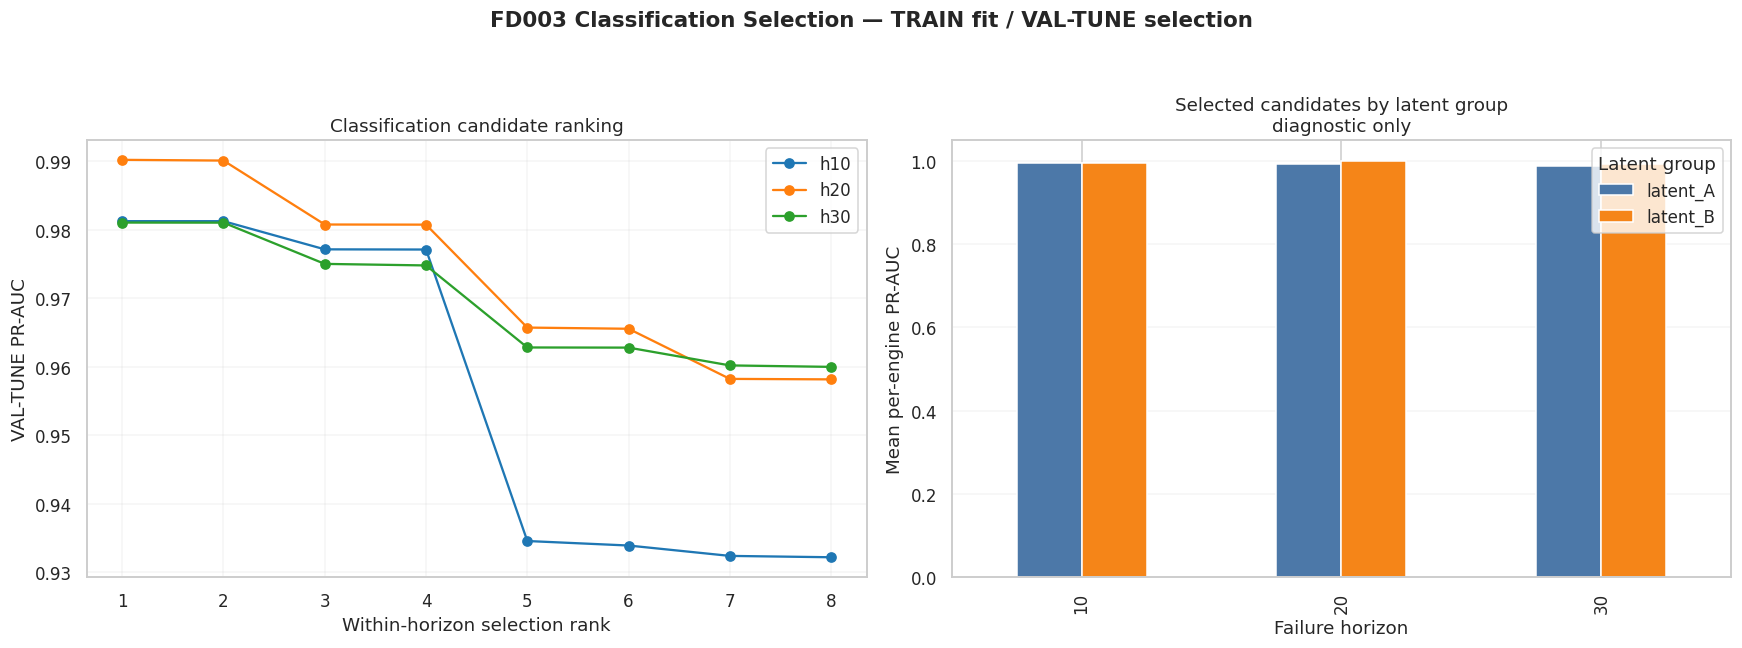

In [241]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

colors = {
    10: "#1f77b4",
    20: "#ff7f0e",
    30: "#2ca02c",
}

for horizon in HORIZONS:
    plot_data = (
        candidate_ranking.loc[
            candidate_ranking[
                "horizon"
            ]
            == horizon
        ]
        .sort_values(
            "selection_rank"
        )
    )

    axes[0].plot(
        plot_data[
            "selection_rank"
        ],
        plot_data["tune_PR_AUC"],
        marker="o",
        label=f"h{horizon}",
        color=colors[horizon],
    )

axes[0].set_xlabel(
    "Within-horizon selection rank"
)
axes[0].set_ylabel(
    "VAL-TUNE PR-AUC"
)
axes[0].set_title(
    "Classification candidate ranking"
)
axes[0].grid(alpha=0.2)
axes[0].legend()

group_plot = (
    latent_metric_table.pivot(
        index="horizon",
        columns="latent_group",
        values="PR_AUC_mean",
    )
)

group_plot.plot(
    kind="bar",
    ax=axes[1],
    color=[
        "#4c78a8",
        "#f58518",
    ],
)

axes[1].set_xlabel(
    "Failure horizon"
)
axes[1].set_ylabel(
    "Mean per-engine PR-AUC"
)
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title(
    "Selected candidates by latent group\n"
    "diagnostic only"
)
axes[1].grid(
    axis="y",
    alpha=0.2,
)
axes[1].legend(
    title="Latent group"
)

fig.suptitle(
    (
        f"{SUBSET} Classification Selection "
        "— TRAIN fit / VAL-TUNE selection"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.94]
)
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [242]:
check_rows = [
    {
        "check": (
            "upstream_contracts_valid"
        ),
        "passed": (
            feature_contract_sha_before
            == read_sidecar_hash(
                feature_contract_sidecar_path
            )
            and protocol_sha_before
            == read_sidecar_hash(
                protocol_sidecar_path
            )
        ),
    },
    {
        "check": (
            "official_test_gate_remains_sealed"
        ),
        "passed": (
            protocol[
                "official_test_gate"
            ]["status"]
            == "SEALED"
            and not official_test_used
        ),
    },
    {
        "check": (
            "val_calib_not_used"
        ),
        "passed": (
            not val_calib_used
        ),
    },
    {
        "check": (
            "nested_train_labels"
        ),
        "passed": (
            np.all(
                df_train["label_h10"]
                <= df_train[
                    "label_h20"
                ]
            )
            and np.all(
                df_train["label_h20"]
                <= df_train[
                    "label_h30"
                ]
            )
        ),
    },
    {
        "check": (
            "nested_tune_labels"
        ),
        "passed": (
            np.all(
                df_tune["label_h10"]
                <= df_tune[
                    "label_h20"
                ]
            )
            and np.all(
                df_tune["label_h20"]
                <= df_tune[
                    "label_h30"
                ]
            )
        ),
    },
    {
        "check": (
            "expected_24_model_fits"
        ),
        "passed": (
            fit_count
            == expected_fit_count
            == 24
        ),
    },
    {
        "check": (
            "all_models_fit_on_70_engines"
        ),
        "passed": (
            candidate_table[
                "n_fit_engines"
            ].eq(70).all()
        ),
    },
    {
        "check": (
            "all_models_evaluated_on_20_engines"
        ),
        "passed": (
            candidate_table[
                "n_tune_engines"
            ].eq(20).all()
        ),
    },
    {
        "check": (
            "all_candidate_metrics_finite"
        ),
        "passed": (
            np.isfinite(
                numeric_candidate_values
            ).all()
        ),
    },
    {
        "check": (
            "probabilities_finite_and_bounded"
        ),
        "passed": (
            np.isfinite(
                prediction_table[
                    "raw_probability"
                ]
            ).all()
            and prediction_table[
                "raw_probability"
            ].between(
                0.0,
                1.0,
            ).all()
        ),
    },
    {
        "check": (
            "one_winner_per_horizon"
        ),
        "passed": (
            len(
                selected_candidate_ids
            )
            == 3
        ),
    },
    {
        "check": (
            "reload_probability_parity"
        ),
        "passed": (
            len(
                reload_parity_results
            )
            == 3
            and all(
                reload_parity_results
            )
        ),
    },
    {
        "check": (
            "latent_groups_not_used_for_selection"
        ),
        "passed": (
            selection_contract[
                "latent_group_diagnostics"
            ]["used_for_selection"]
            is False
        ),
    },
    {
        "check": (
            "six_latent_group_diagnostic_rows"
        ),
        "passed": (
            len(
                latent_metric_table
            )
            == 6
        ),
    },
    {
        "check": (
            "feature_bundle_unchanged"
        ),
        "passed": (
            feature_bundle_unchanged
        ),
    },
    {
        "check": (
            "feature_contract_unchanged"
        ),
        "passed": (
            feature_contract_unchanged
        ),
    },
    {
        "check": (
            "development_protocol_unchanged"
        ),
        "passed": (
            protocol_unchanged
        ),
    },
    {
        "check": (
            "saved_prediction_parity"
        ),
        "passed": (
            prediction_csv_parity
        ),
    },
    {
        "check": (
            "selection_contract_reload_exact"
        ),
        "passed": (
            contract_reload
            == selection_contract
        ),
    },
    {
        "check": (
            "selection_contract_hash_valid"
        ),
        "passed": (
            sha256_file(
                selection_contract_path
            )
            == selection_contract_sha256
            == sidecar_reload[
                "sha256"
            ]
        ),
    },
    {
        "check": (
            "selection_figure_created"
        ),
        "passed": (
            figure_path.is_file()
            and figure_path.stat().st_size
            > 0
        ),
    },
]

In [243]:
fd003_classification_selection_checks = (
    pd.DataFrame(check_rows)
)

failed_checks = int(
    (
        ~fd003_classification_selection_checks[
            "passed"
        ]
    ).sum()
)

selection_status = (
    "PASS"
    if failed_checks == 0
    else "FAIL"
)

assert failed_checks == 0, (
    fd003_classification_selection_checks.loc[
        ~fd003_classification_selection_checks[
            "passed"
        ]
    ]
)

print(
    " COMPUTED FD003 CLASSIFICATION SELECTION CHECKS "
)
display(
    fd003_classification_selection_checks
)

print(
    "\n FD003 CLASSIFICATION WINNERS "
)
display(
    candidate_ranking.loc[
        candidate_ranking[
            "selection_rank"
        ]
        == 1
    ]
)

print(
    "\n SELECTED CLASSIFIERS BY LATENT GROUP "
)
display(latent_metric_table)

print(
    "Selected candidate IDs:",
    selected_candidate_ids,
)
print(
    "Model fits executed:",
    fit_count,
)
print(
    "VAL-CALIB used:",
    val_calib_used,
)
print(
    "Official Test used:",
    official_test_used,
)
print(
    "Executed checks:",
    len(
        fd003_classification_selection_checks
    ),
)
print(
    "Failed checks:",
    failed_checks,
)
print(
    "Classification selection status:",
    selection_status,
)
print(
    "Saved ranking:",
    ranking_path,
)
print(
    "Saved selected bundle:",
    selected_bundle_path,
)
print(
    "Selected bundle SHA256:",
    selected_bundle_sha256,
)
print(
    "Saved selection contract:",
    selection_contract_path,
)
print(
    "Selection contract SHA256:",
    selection_contract_sha256,
)

 COMPUTED FD003 CLASSIFICATION SELECTION CHECKS 


,check,passed
0,upstream_contracts_valid,True
1,official_test_gate_remains_sealed,True
2,val_calib_not_used,True
3,nested_train_labels,True
4,nested_tune_labels,True
5,expected_24_model_fits,True
6,all_models_fit_on_70_engines,True
7,all_models_evaluated_on_20_engines,True
8,all_candidate_metrics_finite,True
9,probabilities_finite_and_bounded,True



 FD003 CLASSIFICATION WINNERS 


,selection_rank,candidate_id,horizon,feature_candidate_id,representation,window,include_settings,n_features,model_name,model_parameters_json,...,tune_prevalence,tune_PR_AUC,tune_ROC_AUC,tune_Brier_raw,per_engine_PR_AUC_median,per_engine_PR_AUC_min,per_engine_Brier_mean,fit_seconds,inference_seconds,inference_us_per_row
0,1,h10__window30__settings_0__logreg_balanced,10,window30__settings_0,window,30,False,129,logistic_regression_balanced,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it...",...,0.049052,0.981221,0.998997,0.012536,1.000000,0.975069,0.013554,1.542775,0.003189,0.710931
8,1,h20__window30__settings_0__logreg_balanced,20,window30__settings_0,window,30,False,129,logistic_regression_balanced,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it...",...,0.093645,0.990164,0.998952,0.011393,0.998918,0.941076,0.012306,1.027805,0.001969,0.439116
16,1,h30__window15__settings_1__logreg_balanced,30,window15__settings_1,window,15,True,131,logistic_regression_balanced,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it...",...,0.138239,0.981015,0.996856,0.016060,0.997998,0.956969,0.017116,1.215591,0.002126,0.474094



 SELECTED CLASSIFIERS BY LATENT GROUP 


,horizon,latent_group,candidate_id,n_engines,PR_AUC_mean,PR_AUC_median,PR_AUC_min,Brier_raw_mean
0,10,latent_A,h10__window30__settings_0__logreg_balanced,10,0.995165,1.000000,0.975069,0.016566
1,10,latent_B,h10__window30__settings_0__logreg_balanced,10,0.994477,0.996212,0.975069,0.010542
2,20,latent_A,h20__window30__settings_0__logreg_balanced,10,0.991314,0.996847,0.941076,0.016828
3,20,latent_B,h20__window30__settings_0__logreg_balanced,10,0.998408,1.000000,0.990681,0.007784
4,30,latent_A,h30__window15__settings_1__logreg_balanced,10,0.987677,0.995235,0.964118,0.022840
5,30,latent_B,h30__window15__settings_1__logreg_balanced,10,0.991543,0.998518,0.956969,0.011392


Selected candidate IDs: {'10': 'h10__window30__settings_0__logreg_balanced', '20': 'h20__window30__settings_0__logreg_balanced', '30': 'h30__window15__settings_1__logreg_balanced'}
Model fits executed: 24
VAL-CALIB used: False
Official Test used: False
Executed checks: 21
Failed checks: 0
Classification selection status: PASS
Saved ranking: artifacts/results/FD003_classification_val_tune_candidates.csv
Saved selected bundle: artifacts/models/FD003_classification_selected_precalibration_bundle.joblib
Selected bundle SHA256: b587a2d2f215f38a1260b6c09785f28c64f181cef5e4d078ff206e503bf0767d
Saved selection contract: data/processed/FD003_classification_selection.json
Selection contract SHA256: 88192983bbaacda1f221b6dcb867735a0b1cf388c6ff3a9b2e3aa9cad9e0ec95


### FD003 classification calibration, monotonicity and thresholds

Base classifiers are not refitted.
Platt calibrators and thresholds use only reserved VAL-CALIB.
Official Test and RUL_FD003 are not accessed.


In [244]:
import sys
import json
import hashlib
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import (
    LogisticRegression,
)
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)

PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"

assert PROJECT_ROOT.is_dir()
assert SRC_DIR.is_dir()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from data_loader import (
    load_raw,
    add_train_rul,
)

SUBSET = "FD003"
SEED = int(config.RANDOM_SEED)
HORIZONS = (10, 20, 30)

FALSE_NEGATIVE_COST = 10.0
FALSE_POSITIVE_COST = 1.0

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

selected_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_classification_selected_precalibration_bundle.joblib"
)
selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_selection.json"
)
selection_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_selection.sha256"
)
protocol_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.sha256"
)
split_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_engine_split.csv"
)
latent_groups_path = (
    RESULT_DIR
    / f"{SUBSET}_latent_degradation_groups.csv"
)

final_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_classification_bundle.joblib"
)
threshold_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_thresholds.json"
)
threshold_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_thresholds.sha256"
)
prediction_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_calib_predictions.csv"
)
calibration_metric_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_calib_metrics.csv"
)
threshold_grid_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_calib_threshold_grid.csv"
)
selected_threshold_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_calib_selected_thresholds.csv"
)
latent_metric_path = (
    RESULT_DIR
    / f"{SUBSET}_classification_val_calib_latent_group_metrics.csv"
)
figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_classification_val_calib.png"
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

def read_sidecar_hash(path):
    text = path.read_text(
        encoding="utf-8"
    ).strip()

    try:
        data = json.loads(text)

        if isinstance(data, dict):
            value = str(
                data.get("sha256", "")
            ).strip().lower()

            if len(value) == 64:
                return value
    except json.JSONDecodeError:
        pass

    for token in text.replace(
        "\n",
        " ",
    ).split():
        token = token.strip().lower()

        if (
            len(token) == 64
            and all(
                character
                in "0123456789abcdef"
                for character in token
            )
        ):
            return token

    raise ValueError(
        f"No SHA256 found in {path}"
    )

required_inputs = {
    "selected_bundle": selected_bundle_path,
    "selection_contract": (
        selection_contract_path
    ),
    "selection_sidecar": (
        selection_sidecar_path
    ),
    "development_protocol": protocol_path,
    "development_protocol_sidecar": (
        protocol_sidecar_path
    ),
    "development_split": split_path,
    "latent_groups": latent_groups_path,
}

for name, path in required_inputs.items():
    assert path.is_file(), (
        f"Missing {name}: {path}"
    )
    assert path.stat().st_size > 0


In [245]:
selection_contract_sha_before = (
    sha256_file(selection_contract_path)
)
selected_bundle_sha_before = (
    sha256_file(selected_bundle_path)
)
protocol_sha_before = (
    sha256_file(protocol_path)
)

assert (
    selection_contract_sha_before
    == read_sidecar_hash(
        selection_sidecar_path
    )
)
assert (
    protocol_sha_before
    == read_sidecar_hash(
        protocol_sidecar_path
    )
)

selection_contract = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)
protocol = json.loads(
    protocol_path.read_text(
        encoding="utf-8"
    )
)

assert selection_contract["subset"] == SUBSET
assert (
    selection_contract[
        "official_test_status"
    ]
    == "SEALED"
)
assert (
    selection_contract[
        "calibration_partition_accessed"
    ]
    is False
)
assert (
    selection_contract[
        "official_test_accessed"
    ]
    is False
)
assert (
    selection_contract[
        "selected_bundle"
    ]["sha256"]
    == selected_bundle_sha_before
)

assert (
    protocol["official_test_gate"][
        "status"
    ]
    == "SEALED"
)
assert (
    protocol["official_test_gate"][
        "evaluation_authorized"
    ]
    is False
)

selected_bundle = joblib.load(
    selected_bundle_path
)

assert selected_bundle["subset"] == SUBSET
assert (
    selected_bundle["fit_partition"]
    == "train"
)
assert (
    selected_bundle[
        "selection_partition"
    ]
    == "val_tune"
)
assert (
    selected_bundle[
        "calibration_partition"
    ]
    == "val_calib_reserved"
)
assert (
    selected_bundle[
        "official_test_status"
    ]
    == "SEALED"
)
assert set(
    selected_bundle["classifiers"]
) == {"10", "20", "30"}

loaded_data_roles = []

df_all = load_raw(
    SUBSET,
    "train",
)
loaded_data_roles.append("official_train")

df_all = add_train_rul(
    df_all,
    cap=None,
)

split_table = pd.read_csv(
    split_path
)

assert {
    "engine_id",
    "role",
}.issubset(split_table.columns)

split_table["engine_id"] = (
    split_table["engine_id"].astype(int)
)

calib_ids = set(
    split_table.loc[
        split_table["role"]
        == "val_calib",
        "engine_id",
    ]
)

assert len(calib_ids) == 10

df_calib = (
    df_all.loc[
        df_all["engine_id"].isin(
            calib_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

assert len(df_calib) == 2016
assert (
    df_calib["engine_id"].nunique()
    == 10
)

used_development_roles = [
    "val_calib",
]
official_test_used = any(
    "test" in role.lower()
    for role in loaded_data_roles
)
official_rul_used = any(
    "rul_file" in role.lower()
    for role in loaded_data_roles
)

assert not official_test_used
assert not official_rul_used

for horizon in HORIZONS:
    df_calib[
        f"label_h{horizon}"
    ] = (
        df_calib["RUL"] <= horizon
    ).astype(int)

assert np.all(
    df_calib["label_h10"]
    <= df_calib["label_h20"]
)
assert np.all(
    df_calib["label_h20"]
    <= df_calib["label_h30"]
)

for horizon in HORIZONS:
    assert set(
        df_calib[
            f"label_h{horizon}"
        ].unique()
    ) == {0, 1}

raw_probability = {}
platt_probability = {}
calibrators = {}
label_arrays = {}
metadata_by_horizon = {}
base_model_reload_inputs = {}

calibrator_fit_count = 0

In [246]:
for horizon in HORIZONS:
    horizon_key = str(horizon)
    classifier = selected_bundle[
        "classifiers"
    ][horizon_key]

    pipeline = classifier[
        "feature_pipeline"
    ]
    base_model = classifier["model"]
    scaled = bool(
        classifier[
            "uses_scaled_features"
        ]
    )

    X_calib, _, labels, metadata, _ = (
        pipeline.transform(
            df_calib,
            scaled=scaled,
        )
    )

    y = labels[
        f"label_h{horizon}"
    ].to_numpy(dtype=int)

    assert X_calib.index.equals(
        df_calib.index
    )
    assert metadata.index.equals(
        df_calib.index
    )
    assert len(X_calib) == 2016

    raw = base_model.predict_proba(
        X_calib
    )[:, 1]

    score = base_model.decision_function(
        X_calib
    )

    raw = np.asarray(
        raw,
        dtype=float,
    )
    score = np.asarray(
        score,
        dtype=float,
    )

    assert np.isfinite(raw).all()
    assert np.isfinite(score).all()
    assert np.all(raw >= 0.0)
    assert np.all(raw <= 1.0)

    calibrator = LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=SEED,
    )

    calibrator.fit(
        score.reshape(-1, 1),
        y,
    )
    calibrator_fit_count += 1

    platt = calibrator.predict_proba(
        score.reshape(-1, 1)
    )[:, 1]

    platt = np.asarray(
        platt,
        dtype=float,
    )

    assert np.isfinite(platt).all()
    assert np.all(platt >= 0.0)
    assert np.all(platt <= 1.0)

    raw_probability[horizon] = raw
    platt_probability[horizon] = (
        platt
    )
    calibrators[horizon] = (
        calibrator
    )
    label_arrays[horizon] = y
    metadata_by_horizon[horizon] = (
        metadata
    )
    base_model_reload_inputs[
        horizon
    ] = X_calib

assert calibrator_fit_count == 3

pre_monotonicity_violation = (
    (
        platt_probability[10]
        > platt_probability[20]
        + 1e-12
    )
    | (
        platt_probability[20]
        > platt_probability[30]
        + 1e-12
    )
)

pre_violation_rate = float(
    pre_monotonicity_violation.mean()
)

mono_probability = {}

mono_probability[10] = (
    platt_probability[10].copy()
)
mono_probability[20] = np.maximum(
    mono_probability[10],
    platt_probability[20],
)
mono_probability[30] = np.maximum(
    mono_probability[20],
    platt_probability[30],
)

assert np.all(
    mono_probability[10]
    <= mono_probability[20]
    + 1e-12
)
assert np.all(
    mono_probability[20]
    <= mono_probability[30]
    + 1e-12
)

post_violation_rate = float(
    np.mean(
        (
            mono_probability[10]
            > mono_probability[20]
            + 1e-12
        )
        | (
            mono_probability[20]
            > mono_probability[30]
            + 1e-12
        )
    )
)

assert post_violation_rate == 0.0

calibration_metric_rows = []

for horizon in HORIZONS:
    y = label_arrays[horizon]

    stages = {
        "raw": raw_probability[
            horizon
        ],
        "platt": platt_probability[
            horizon
        ],
        "platt_monotone": (
            mono_probability[horizon]
        ),
    }

    for stage_name, probability in (
        stages.items()
    ):
        calibration_metric_rows.append(
            {
                "horizon": horizon,
                "probability_stage": (
                    stage_name
                ),
                "n_rows": int(len(y)),
                "n_engines": int(
                    metadata_by_horizon[
                        horizon
                    ]["engine_id"].nunique()
                ),
                "n_positive": int(
                    y.sum()
                ),
                "prevalence": float(
                    y.mean()
                ),
                "PR_AUC": float(
                    average_precision_score(
                        y,
                        probability,
                    )
                ),
                "ROC_AUC": float(
                    roc_auc_score(
                        y,
                        probability,
                    )
                ),
                "Brier": float(
                    brier_score_loss(
                        y,
                        probability,
                    )
                ),
            }
        )

In [247]:
calibration_metrics = pd.DataFrame(
    calibration_metric_rows
)

assert len(calibration_metrics) == 9
assert np.isfinite(
    calibration_metrics.select_dtypes(
        include=[np.number]
    ).to_numpy(dtype=float)
).all()

threshold_grid_rows = []
selected_threshold_rows = []
selected_thresholds = {}
decision_arrays = {}

for horizon in HORIZONS:
    y = label_arrays[horizon]
    probability = mono_probability[
        horizon
    ]

    threshold_candidates = np.unique(
        np.concatenate(
            [
                np.array(
                    [0.0, 1.0],
                    dtype=float,
                ),
                probability,
            ]
        )
    )

    horizon_grid_rows = []

    for threshold in threshold_candidates:
        decision = (
            probability >= threshold
        ).astype(int)

        tn = int(
            np.sum(
                (y == 0)
                & (decision == 0)
            )
        )
        fp = int(
            np.sum(
                (y == 0)
                & (decision == 1)
            )
        )
        fn = int(
            np.sum(
                (y == 1)
                & (decision == 0)
            )
        )
        tp = int(
            np.sum(
                (y == 1)
                & (decision == 1)
            )
        )

        precision_denominator = (
            tp + fp
        )
        recall_denominator = (
            tp + fn
        )

        precision = (
            tp / precision_denominator
            if precision_denominator > 0
            else 0.0
        )
        recall = (
            tp / recall_denominator
            if recall_denominator > 0
            else 0.0
        )

        f1 = (
            2.0
            * precision
            * recall
            / (precision + recall)
            if (
                precision + recall
            ) > 0
            else 0.0
        )

        false_negative_component = (
            FALSE_NEGATIVE_COST * fn
        )
        false_positive_component = (
            FALSE_POSITIVE_COST * fp
        )
        total_cost = (
            false_negative_component
            + false_positive_component
        )

        row = {
            "horizon": horizon,
            "threshold": float(
                threshold
            ),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "precision": float(
                precision
            ),
            "recall": float(recall),
            "f1": float(f1),
            "false_negative_cost": float(
                false_negative_component
            ),
            "false_positive_cost": float(
                false_positive_component
            ),
            "total_cost": float(
                total_cost
            ),
            "cost_per_row": float(
                total_cost / len(y)
            ),
        }

        horizon_grid_rows.append(row)
        threshold_grid_rows.append(row)

    horizon_grid = pd.DataFrame(
        horizon_grid_rows
    )

    selected_row = (
        horizon_grid.sort_values(
            [
                "total_cost",
                "threshold",
            ],
            ascending=[
                True,
                True,
            ],
            kind="mergesort",
        )
        .iloc[0]
    )

    selected_threshold = float(
        selected_row["threshold"]
    )

    selected_thresholds[
        str(horizon)
    ] = selected_threshold

    selected_threshold_rows.append(
        {
            key: (
                value.item()
                if isinstance(
                    value,
                    np.generic,
                )
                else value
            )
            for key, value in (
                selected_row
                .to_dict()
                .items()
            )
        }
    )

    decision_arrays[horizon] = (
        probability
        >= selected_threshold
    ).astype(int)

threshold_grid = pd.DataFrame(
    threshold_grid_rows
)
selected_threshold_table = (
    pd.DataFrame(
        selected_threshold_rows
    )
)

assert len(
    selected_threshold_table
) == 3
assert set(
    selected_thresholds
) == {"10", "20", "30"}

for horizon in HORIZONS:
    threshold = selected_thresholds[
        str(horizon)
    ]

    assert 0.0 <= threshold <= 1.0

    assert np.array_equal(
        decision_arrays[horizon],
        (
            mono_probability[horizon]
            >= threshold
        ).astype(int),
    )

In [248]:
reference_metadata = (
    metadata_by_horizon[10]
)

for horizon in HORIZONS:
    assert metadata_by_horizon[
        horizon
    ].equals(reference_metadata)

prediction_table = pd.DataFrame(
    {
        "engine_id": (
            reference_metadata[
                "engine_id"
            ].to_numpy(dtype=int)
        ),
        "cycle": (
            reference_metadata[
                "cycle"
            ].to_numpy(dtype=int)
        ),
    }
)

for horizon in HORIZONS:
    prediction_table[
        f"y_h{horizon}"
    ] = label_arrays[horizon]

    prediction_table[
        f"raw_h{horizon}"
    ] = raw_probability[horizon]

    prediction_table[
        f"platt_h{horizon}"
    ] = platt_probability[
        horizon
    ]

    prediction_table[
        f"mono_h{horizon}"
    ] = mono_probability[
        horizon
    ]

    prediction_table[
        f"dec_h{horizon}"
    ] = decision_arrays[
        horizon
    ]

assert len(prediction_table) == 2016
assert np.all(
    prediction_table["y_h10"]
    <= prediction_table["y_h20"]
)
assert np.all(
    prediction_table["y_h20"]
    <= prediction_table["y_h30"]
)
assert np.all(
    prediction_table["mono_h10"]
    <= prediction_table["mono_h20"]
    + 1e-12
)
assert np.all(
    prediction_table["mono_h20"]
    <= prediction_table["mono_h30"]
    + 1e-12
)

latent_groups = pd.read_csv(
    latent_groups_path
)

calib_latent = (
    latent_groups.loc[
        latent_groups["role"]
        == "val_calib",
        [
            "engine_id",
            "latent_group",
        ],
    ]
    .copy()
)

calib_latent["engine_id"] = (
    calib_latent[
        "engine_id"
    ].astype(int)
)

assert (
    calib_latent[
        "engine_id"
    ].nunique()
    == 10
)
assert set(
    calib_latent["engine_id"]
) == calib_ids

diagnostic_table = (
    prediction_table.merge(
        calib_latent,
        on="engine_id",
        how="left",
        validate="many_to_one",
    )
)

latent_metric_rows = []

for horizon in HORIZONS:
    for latent_group, group in (
        diagnostic_table.groupby(
            "latent_group",
            sort=True,
        )
    ):
        y = group[
            f"y_h{horizon}"
        ].to_numpy(dtype=int)

        probability = group[
            f"mono_h{horizon}"
        ].to_numpy(dtype=float)

        decision = group[
            f"dec_h{horizon}"
        ].to_numpy(dtype=int)

        fp = int(
            np.sum(
                (y == 0)
                & (decision == 1)
            )
        )
        fn = int(
            np.sum(
                (y == 1)
                & (decision == 0)
            )
        )

        latent_metric_rows.append(
            {
                "horizon": horizon,
                "latent_group": (
                    latent_group
                ),
                "n_engines": int(
                    group[
                        "engine_id"
                    ].nunique()
                ),
                "n_rows": int(
                    len(group)
                ),
                "prevalence": float(
                    y.mean()
                ),
                "PR_AUC_monotone": float(
                    average_precision_score(
                        y,
                        probability,
                    )
                ),
                "Brier_monotone": float(
                    brier_score_loss(
                        y,
                        probability,
                    )
                ),
                "threshold": float(
                    selected_thresholds[
                        str(horizon)
                    ]
                ),
                "false_positives": fp,
                "false_negatives": fn,
                "total_cost": float(
                    FALSE_POSITIVE_COST
                    * fp
                    + FALSE_NEGATIVE_COST
                    * fn
                ),
            }
        )

latent_metrics = pd.DataFrame(
    latent_metric_rows
)

assert len(latent_metrics) == 6

final_classifiers = {}

for horizon in HORIZONS:
    horizon_key = str(horizon)
    source_entry = selected_bundle[
        "classifiers"
    ][horizon_key]

    final_classifiers[horizon_key] = {
        "candidate_id": (
            source_entry[
                "candidate_id"
            ]
        ),
        "feature_pipeline": (
            source_entry[
                "feature_pipeline"
            ]
        ),
        "model": (
            source_entry["model"]
        ),
        "model_name": (
            source_entry[
                "model_name"
            ]
        ),
        "model_parameters": (
            source_entry[
                "model_parameters"
            ]
        ),
        "uses_scaled_features": (
            source_entry[
                "uses_scaled_features"
            ]
        ),
        "calibrator": (
            calibrators[horizon]
        ),
        "metadata": {
            "horizon": horizon,
            "fit_partition": "train",
            "selection_partition": (
                "val_tune"
            ),
            "calibration_partition": (
                "val_calib"
            ),
            "calibration_method": (
                "Platt scaling"
            ),
            "probability_stage": (
                "Platt plus monotonicity"
            ),
        },
    }

In [249]:
classification_bundle = {
    "artifact_type": (
        "frozen_classification_bundle"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "horizons": list(HORIZONS),
    "fit_partition": "train",
    "selection_partition": (
        "val_tune"
    ),
    "calibration_partition": (
        "val_calib"
    ),
    "calibration_method": (
        "horizon-specific Platt scaling"
    ),
    "monotonicity_rule": (
        "cumulative maximum in "
        "horizon order 10,20,30"
    ),
    "threshold_status": (
        "selected_on_val_calib"
    ),
    "threshold_partition": (
        "val_calib"
    ),
    "threshold_policy": {
        "primary_cost_ratio": {
            "false_negative": (
                FALSE_NEGATIVE_COST
            ),
            "false_positive": (
                FALSE_POSITIVE_COST
            ),
        },
        "cost_ordering": (
            "minimum total cost"
        ),
        "tie_break": (
            "lowest threshold"
        ),
        "probability_stage": (
            "Platt plus monotonicity"
        ),
    },
    "thresholds": (
        selected_thresholds
    ),
    "classifiers": (
        final_classifiers
    ),
    "source_precalibration_bundle": {
        "path": str(
            selected_bundle_path
        ),
        "sha256": (
            selected_bundle_sha_before
        ),
    },
    "source_selection_contract": {
        "path": str(
            selection_contract_path
        ),
        "sha256": (
            selection_contract_sha_before
        ),
    },
    "official_test_status": "sealed",
}

joblib.dump(
    classification_bundle,
    final_bundle_path,
)

final_bundle_sha256 = (
    sha256_file(final_bundle_path)
)

threshold_contract = {
    "subset": SUBSET,
    "task": (
        "failure-horizon classification"
    ),
    "horizons": list(HORIZONS),
    "probability_stage": (
        "Platt plus monotonicity"
    ),
    "selection_partition": (
        "val_calib"
    ),
    "primary_cost": {
        "false_negative": (
            FALSE_NEGATIVE_COST
        ),
        "false_positive": (
            FALSE_POSITIVE_COST
        ),
    },
    "cost_ordering": (
        "minimum total asymmetric cost"
    ),
    "tie_break": (
        "lowest threshold"
    ),
    "primary_thresholds": (
        selected_thresholds
    ),
    "selected_threshold_metrics": (
        selected_threshold_rows
    ),
    "classification_bundle_path": str(
        final_bundle_path
    ),
    "classification_bundle_sha256": (
        final_bundle_sha256
    ),
    "source_precalibration_bundle_sha256": (
        selected_bundle_sha_before
    ),
    "calibrator_fit_count": (
        calibrator_fit_count
    ),
    "base_classifier_refit": False,
    "engine_level_policy_status": (
        "not_selected"
    ),
    "official_test_status": "sealed",
    "interpretation": [
        (
            "Thresholds were selected only "
            "on reserved VAL-CALIB."
        ),
        (
            "False negatives cost ten times "
            "as much as false positives."
        ),
        (
            "Official Test was not used for "
            "calibration or threshold selection."
        ),
    ],
}

threshold_contract_path.write_text(
    json.dumps(
        threshold_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

threshold_contract_sha256 = (
    sha256_file(
        threshold_contract_path
    )
)

threshold_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                threshold_contract_path
            ),
            "sha256": (
                threshold_contract_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

prediction_table.to_csv(
    prediction_path,
    index=False,
)
calibration_metrics.to_csv(
    calibration_metric_path,
    index=False,
)
threshold_grid.to_csv(
    threshold_grid_path,
    index=False,
)
selected_threshold_table.to_csv(
    selected_threshold_path,
    index=False,
)
latent_metrics.to_csv(
    latent_metric_path,
    index=False,
)

bundle_reload = joblib.load(
    final_bundle_path
)

reload_raw = {}
reload_platt = {}

for horizon in HORIZONS:
    entry = bundle_reload[
        "classifiers"
    ][str(horizon)]

    reload_X = entry[
        "feature_pipeline"
    ].transform(
        df_calib,
        scaled=entry[
            "uses_scaled_features"
        ],
    )[0]

    reload_model = entry["model"]
    reload_calibrator = entry[
        "calibrator"
    ]

    reload_raw[horizon] = (
        reload_model.predict_proba(
            reload_X
        )[:, 1]
    )

    reload_score = (
        reload_model.decision_function(
            reload_X
        )
    )

    reload_platt[horizon] = (
        reload_calibrator.predict_proba(
            np.asarray(
                reload_score,
                dtype=float,
            ).reshape(-1, 1)
        )[:, 1]
    )

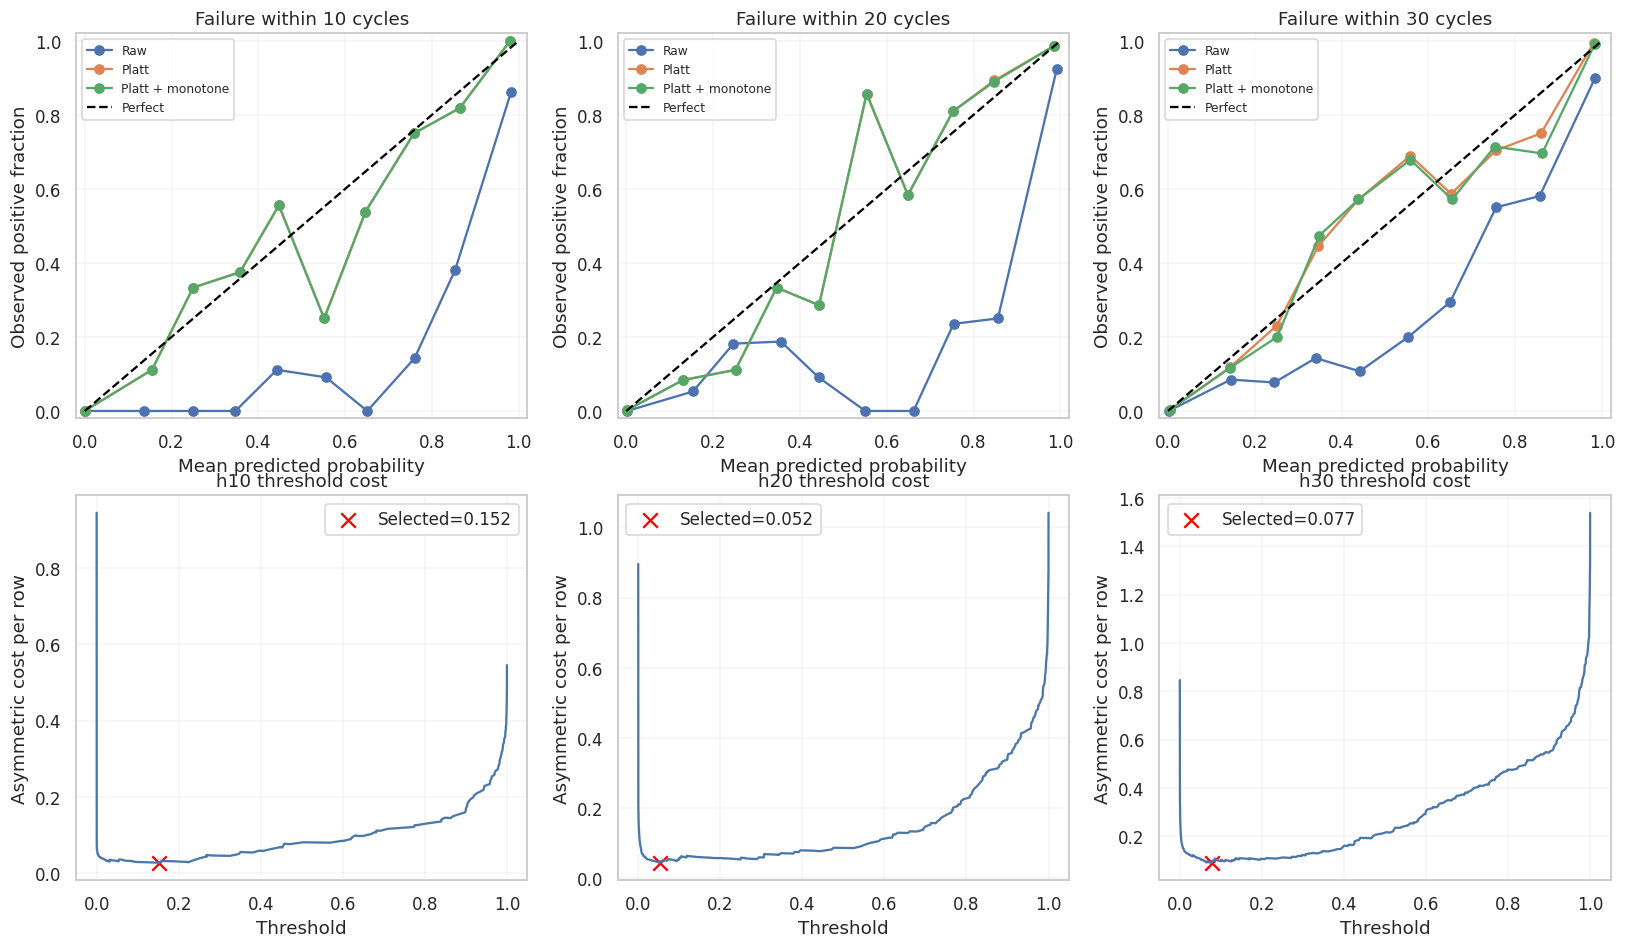

In [250]:
reload_mono = {
    10: reload_platt[10].copy(),
}
reload_mono[20] = np.maximum(
    reload_mono[10],
    reload_platt[20],
)
reload_mono[30] = np.maximum(
    reload_mono[20],
    reload_platt[30],
)

reload_decisions = {
    horizon: (
        reload_mono[horizon]
        >= float(
            bundle_reload[
                "thresholds"
            ][str(horizon)]
        )
    ).astype(int)
    for horizon in HORIZONS
}

reload_parity_results = []

for horizon in HORIZONS:
    reload_parity_results.extend(
        [
            bool(
                np.allclose(
                    reload_raw[horizon],
                    raw_probability[
                        horizon
                    ],
                    rtol=0.0,
                    atol=1e-12,
                )
            ),
            bool(
                np.allclose(
                    reload_platt[horizon],
                    platt_probability[
                        horizon
                    ],
                    rtol=0.0,
                    atol=1e-12,
                )
            ),
            bool(
                np.allclose(
                    reload_mono[horizon],
                    mono_probability[
                        horizon
                    ],
                    rtol=0.0,
                    atol=1e-12,
                )
            ),
            bool(
                np.array_equal(
                    reload_decisions[
                        horizon
                    ],
                    decision_arrays[
                        horizon
                    ],
                )
            ),
        ]
    )

assert len(
    reload_parity_results
) == 12
assert all(reload_parity_results)

contract_reload = json.loads(
    threshold_contract_path.read_text(
        encoding="utf-8"
    )
)
sidecar_reload = json.loads(
    threshold_sidecar_path.read_text(
        encoding="utf-8"
    )
)

prediction_reload = pd.read_csv(
    prediction_path
)
metric_reload = pd.read_csv(
    calibration_metric_path
)
threshold_grid_reload = pd.read_csv(
    threshold_grid_path
)
selected_threshold_reload = pd.read_csv(
    selected_threshold_path
)
latent_reload = pd.read_csv(
    latent_metric_path
)

assert contract_reload == (
    threshold_contract
)
assert (
    sidecar_reload["sha256"]
    == threshold_contract_sha256
    == sha256_file(
        threshold_contract_path
    )
)

assert prediction_reload.shape == (
    prediction_table.shape
)
assert metric_reload.shape == (
    calibration_metrics.shape
)
assert threshold_grid_reload.shape == (
    threshold_grid.shape
)
assert selected_threshold_reload.shape == (
    selected_threshold_table.shape
)
assert latent_reload.shape == (
    latent_metrics.shape
)

saved_probability_parity = all(
    np.allclose(
        prediction_reload[
            f"mono_h{horizon}"
        ].to_numpy(dtype=float),
        prediction_table[
            f"mono_h{horizon}"
        ].to_numpy(dtype=float),
        rtol=0.0,
        atol=1e-12,
    )
    for horizon in HORIZONS
)

assert saved_probability_parity

selected_bundle_unchanged = (
    sha256_file(selected_bundle_path)
    == selected_bundle_sha_before
)
selection_contract_unchanged = (
    sha256_file(
        selection_contract_path
    )
    == selection_contract_sha_before
)
protocol_unchanged = (
    sha256_file(protocol_path)
    == protocol_sha_before
)

assert selected_bundle_unchanged
assert selection_contract_unchanged
assert protocol_unchanged

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
)

probability_stages = {
    "Raw": raw_probability,
    "Platt": platt_probability,
    "Platt + monotone": (
        mono_probability
    ),
}

for column, horizon in enumerate(
    HORIZONS
):
    y = label_arrays[horizon]

    for stage_name, stage_values in (
        probability_stages.items()
    ):
        probability = stage_values[
            horizon
        ]

        bin_edges = np.linspace(
            0.0,
            1.0,
            11,
        )
        bin_ids = np.digitize(
            probability,
            bin_edges[1:-1],
            right=False,
        )

        mean_predicted = []
        observed_fraction = []

        for bin_id in range(10):
            mask = bin_ids == bin_id

            if not mask.any():
                continue

            mean_predicted.append(
                float(
                    probability[
                        mask
                    ].mean()
                )
            )
            observed_fraction.append(
                float(
                    y[mask].mean()
                )
            )

        axes[0, column].plot(
            mean_predicted,
            observed_fraction,
            marker="o",
            label=stage_name,
        )

    axes[0, column].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        label="Perfect",
    )

    axes[0, column].set_title(
        f"Failure within {horizon} cycles"
    )
    axes[0, column].set_xlabel(
        "Mean predicted probability"
    )
    axes[0, column].set_ylabel(
        "Observed positive fraction"
    )
    axes[0, column].set_xlim(
        -0.02,
        1.02,
    )
    axes[0, column].set_ylim(
        -0.02,
        1.02,
    )
    axes[0, column].grid(alpha=0.2)
    axes[0, column].legend(
        fontsize=8
    )

    horizon_cost = (
        threshold_grid.loc[
            threshold_grid["horizon"]
            == horizon
        ]
        .sort_values("threshold")
    )

    axes[1, column].plot(
        horizon_cost["threshold"],
        horizon_cost[
            "cost_per_row"
        ],
        color="#4c78a8",
    )

    selected_threshold = (
        selected_thresholds[
            str(horizon)
        ]
    )

    selected_cost = float(
        selected_threshold_table.loc[
            (
                selected_threshold_table[
                    "horizon"
                ]
                == horizon
            ),
            "cost_per_row",
        ].iloc[0]
    )

    axes[1, column].scatter(
        [selected_threshold],
        [selected_cost],
        color="red",
        marker="x",
        s=90,
        label=(
            f"Selected={selected_threshold:.3f}"
        ),
    )

    axes[1, column].set_xlabel(
        "Threshold"
    )
    axes[1, column].set_ylabel(
        "Asymmetric cost per row"
    )
    axes[1, column].set_title(
        f"h{horizon} threshold cost"
    )
    axes[1, column].grid(alpha=0.2)
    axes[1, column].legend()


In [251]:
fig.suptitle(
    (
        f"{SUBSET} Classification Calibration "
        "and Threshold Selection — VAL-CALIB"
    ),
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.95]
)
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [252]:
check_rows = [
    {
        "check": (
            "selection_contract_hash_valid"
        ),
        "passed": (
            selection_contract_sha_before
            == read_sidecar_hash(
                selection_sidecar_path
            )
        ),
    },
    {
        "check": (
            "selected_bundle_matches_contract"
        ),
        "passed": (
            selected_bundle_sha_before
            == selection_contract[
                "selected_bundle"
            ]["sha256"]
        ),
    },
    {
        "check": (
            "official_test_gate_remains_sealed"
        ),
        "passed": (
            protocol[
                "official_test_gate"
            ]["status"]
            == "SEALED"
            and not official_test_used
            and not official_rul_used
        ),
    },
    {
        "check": (
            "only_val_calib_used"
        ),
        "passed": (
            used_development_roles
            == ["val_calib"]
        ),
    },
    {
        "check": (
            "exactly_10_calibration_engines"
        ),
        "passed": (
            df_calib[
                "engine_id"
            ].nunique()
            == 10
        ),
    },
    {
        "check": (
            "exactly_2016_calibration_rows"
        ),
        "passed": (
            len(df_calib) == 2016
        ),
    },
    {
        "check": (
            "labels_are_nested"
        ),
        "passed": (
            np.all(
                df_calib["label_h10"]
                <= df_calib[
                    "label_h20"
                ]
            )
            and np.all(
                df_calib["label_h20"]
                <= df_calib[
                    "label_h30"
                ]
            )
        ),
    },
    {
        "check": (
            "exactly_three_platt_calibrators_fit"
        ),
        "passed": (
            calibrator_fit_count == 3
        ),
    },
    {
        "check": (
            "raw_probabilities_bounded"
        ),
        "passed": all(
            np.isfinite(
                raw_probability[horizon]
            ).all()
            and np.all(
                raw_probability[
                    horizon
                ] >= 0.0
            )
            and np.all(
                raw_probability[
                    horizon
                ] <= 1.0
            )
            for horizon in HORIZONS
        ),
    },
    {
        "check": (
            "platt_probabilities_bounded"
        ),
        "passed": all(
            np.isfinite(
                platt_probability[
                    horizon
                ]
            ).all()
            and np.all(
                platt_probability[
                    horizon
                ] >= 0.0
            )
            and np.all(
                platt_probability[
                    horizon
                ] <= 1.0
            )
            for horizon in HORIZONS
        ),
    },
    {
        "check": (
            "post_monotonicity_violation_rate_zero"
        ),
        "passed": (
            post_violation_rate == 0.0
        ),
    },
    {
        "check": (
            "nine_calibration_metric_rows"
        ),
        "passed": (
            len(calibration_metrics)
            == 9
        ),
    },
    {
        "check": (
            "all_calibration_metrics_finite"
        ),
        "passed": (
            np.isfinite(
                calibration_metrics
                .select_dtypes(
                    include=[np.number]
                )
                .to_numpy(dtype=float)
            ).all()
        ),
    },
    {
        "check": (
            "one_threshold_per_horizon"
        ),
        "passed": (
            len(selected_thresholds)
            == 3
        ),
    },
    {
        "check": (
            "thresholds_bounded"
        ),
        "passed": all(
            0.0
            <= selected_thresholds[
                str(horizon)
            ]
            <= 1.0
            for horizon in HORIZONS
        ),
    },
    {
        "check": (
            "threshold_costs_are_minimal"
        ),
        "passed": all(
            float(
                selected_threshold_table.loc[
                    (
                        selected_threshold_table[
                            "horizon"
                        ]
                        == horizon
                    ),
                    "total_cost",
                ].iloc[0]
            )
            == float(
                threshold_grid.loc[
                    threshold_grid[
                        "horizon"
                    ]
                    == horizon,
                    "total_cost",
                ].min()
            )
            for horizon in HORIZONS
        ),
    },
    {
        "check": (
            "decision_threshold_parity"
        ),
        "passed": all(
            np.array_equal(
                decision_arrays[horizon],
                (
                    mono_probability[
                        horizon
                    ]
                    >= selected_thresholds[
                        str(horizon)
                    ]
                ).astype(int),
            )
            for horizon in HORIZONS
        ),
    },
    {
        "check": (
            "six_latent_group_rows"
        ),
        "passed": (
            len(latent_metrics) == 6
        ),
    },
    {
        "check": (
            "final_bundle_reload_parity"
        ),
        "passed": (
            len(
                reload_parity_results
            )
            == 12
            and all(
                reload_parity_results
            )
        ),
    },
    {
        "check": (
            "selected_bundle_unchanged"
        ),
        "passed": (
            selected_bundle_unchanged
        ),
    },
    {
        "check": (
            "selection_contract_unchanged"
        ),
        "passed": (
            selection_contract_unchanged
        ),
    },
    {
        "check": (
            "development_protocol_unchanged"
        ),
        "passed": (
            protocol_unchanged
        ),
    },
    {
        "check": (
            "saved_probability_parity"
        ),
        "passed": (
            saved_probability_parity
        ),
    },
    {
        "check": (
            "threshold_contract_reload_exact"
        ),
        "passed": (
            contract_reload
            == threshold_contract
        ),
    },
    {
        "check": (
            "threshold_contract_hash_valid"
        ),
        "passed": (
            sha256_file(
                threshold_contract_path
            )
            == threshold_contract_sha256
            == sidecar_reload[
                "sha256"
            ]
        ),
    },
    {
        "check": (
            "calibration_figure_created"
        ),
        "passed": (
            figure_path.is_file()
            and figure_path.stat().st_size
            > 0
        ),
    },
]

In [253]:
fd003_classification_calibration_checks = (
    pd.DataFrame(check_rows)
)

failed_checks = int(
    (
        ~fd003_classification_calibration_checks[
            "passed"
        ]
    ).sum()
)

calibration_status = (
    "PASS"
    if failed_checks == 0
    else "FAIL"
)

assert failed_checks == 0, (
    fd003_classification_calibration_checks.loc[
        ~fd003_classification_calibration_checks[
            "passed"
        ]
    ]
)

print(
    " COMPUTED FD003 CLASSIFICATION CALIBRATION CHECKS "
)
display(
    fd003_classification_calibration_checks
)

print(
    "\n FD003 CLASSIFICATION CALIBRATION METRICS "
)
display(calibration_metrics)

print(
    "\n FD003 SELECTED CLASSIFICATION THRESHOLDS "
)
display(selected_threshold_table)

print(
    "\n FD003 CALIBRATED LATENT-GROUP DIAGNOSTICS "
)
display(latent_metrics)

print(
    "Selected thresholds:",
    selected_thresholds,
)
print(
    "Pre-monotonicity violation rate:",
    pre_violation_rate,
)
print(
    "Post-monotonicity violation rate:",
    post_violation_rate,
)
print(
    "Platt calibrators fitted:",
    calibrator_fit_count,
)
print(
    "Official Test used:",
    official_test_used,
)
print(
    "Official RUL used:",
    official_rul_used,
)
print(
    "Executed checks:",
    len(
        fd003_classification_calibration_checks
    ),
)
print(
    "Failed checks:",
    failed_checks,
)
print(
    "Classification calibration status:",
    calibration_status,
)
print(
    "Saved final classification bundle:",
    final_bundle_path,
)
print(
    "Final classification bundle SHA256:",
    final_bundle_sha256,
)
print(
    "Saved threshold contract:",
    threshold_contract_path,
)
print(
    "Threshold contract SHA256:",
    threshold_contract_sha256,
)


 COMPUTED FD003 CLASSIFICATION CALIBRATION CHECKS 


,check,passed
0,selection_contract_hash_valid,True
1,selected_bundle_matches_contract,True
2,official_test_gate_remains_sealed,True
3,only_val_calib_used,True
4,exactly_10_calibration_engines,True
5,exactly_2016_calibration_rows,True
6,labels_are_nested,True
7,exactly_three_platt_calibrators_fit,True
8,raw_probabilities_bounded,True
9,platt_probabilities_bounded,True



 FD003 CLASSIFICATION CALIBRATION METRICS 


,horizon,probability_stage,n_rows,n_engines,n_positive,prevalence,PR_AUC,ROC_AUC,Brier
0,10,raw,2016,10,110,0.054563,0.968266,0.997887,0.019114
1,10,platt,2016,10,110,0.054563,0.968266,0.997887,0.008411
2,10,platt_monotone,2016,10,110,0.054563,0.968266,0.997887,0.008411
3,20,raw,2016,10,210,0.104167,0.967205,0.996691,0.021874
4,20,platt,2016,10,210,0.104167,0.967205,0.996691,0.012788
5,20,platt_monotone,2016,10,210,0.104167,0.967377,0.996686,0.012788
6,30,raw,2016,10,310,0.153770,0.947802,0.990996,0.034602
7,30,platt,2016,10,310,0.153770,0.947802,0.990996,0.026856
8,30,platt_monotone,2016,10,310,0.153770,0.948099,0.990873,0.027021



 FD003 SELECTED CLASSIFICATION THRESHOLDS 


,horizon,threshold,tn,fp,fn,tp,precision,recall,f1,false_negative_cost,false_positive_cost,total_cost,cost_per_row
0,10.0,0.152026,1873.0,33.0,2.0,108.0,0.765957,0.981818,0.860558,20.0,33.0,53.0,0.026290
1,20.0,0.052137,1717.0,89.0,0.0,210.0,0.702341,1.000000,0.825147,0.0,89.0,89.0,0.044147
2,30.0,0.077386,1543.0,163.0,2.0,308.0,0.653928,0.993548,0.788732,20.0,163.0,183.0,0.090774



 FD003 CALIBRATED LATENT-GROUP DIAGNOSTICS 


,horizon,latent_group,n_engines,n_rows,prevalence,PR_AUC_monotone,Brier_monotone,threshold,false_positives,false_negatives,total_cost
0,10,latent_A,7,1305,0.059004,0.960867,0.010417,0.152026,31,1,41.0
1,10,latent_B,3,711,0.046414,0.996724,0.004729,0.152026,2,1,12.0
2,20,latent_A,7,1305,0.112644,0.944409,0.015609,0.052137,83,0,83.0
3,20,latent_B,3,711,0.088608,0.994894,0.007610,0.052137,6,0,6.0
4,30,latent_A,7,1305,0.166284,0.934703,0.028794,0.077386,135,0,135.0
5,30,latent_B,3,711,0.130802,0.965925,0.023768,0.077386,28,2,48.0


Selected thresholds: {'10': 0.15202568907053304, '20': 0.052137494213097275, '30': 0.07738555983584257}
Pre-monotonicity violation rate: 0.10367063492063493
Post-monotonicity violation rate: 0.0
Platt calibrators fitted: 3
Official Test used: False
Official RUL used: False
Executed checks: 26
Failed checks: 0
Classification calibration status: PASS
Saved final classification bundle: artifacts/models/FD003_classification_bundle.joblib
Final classification bundle SHA256: feb6c58419ed6aa6e604ba43af94b35b82dd3c2e628af16d7e7b696cab6120a3
Saved threshold contract: data/processed/FD003_classification_thresholds.json
Threshold contract SHA256: 6fc773d35bd30e0ec02bb2cd8d2c736efc2280be7f64922d3eec6ca77b6904a9


### FD003 anomaly fitting and VAL-TUNE family selection

Four functional-first anomaly candidates are compared.
Models and reference CDFs use healthy TRAIN rows only.
VAL-TUNE uses a proxy label:
healthy: RUL > 125
abnormal: RUL <= 30
middle rows are excluded from AUC selection.
VAL-CALIB and Official Test are not accessed.


In [254]:
import sys
import json
import time
import hashlib
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.ensemble import (
    IsolationForest,
)
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import (
    LocalOutlierFactor,
)
from sklearn.preprocessing import (
    StandardScaler,
)
from sklearn.svm import OneClassSVM

PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"

assert PROJECT_ROOT.is_dir()
assert SRC_DIR.is_dir()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from data_loader import (
    load_raw,
    add_train_rul,
)

SUBSET = "FD003"
SEED = int(config.RANDOM_SEED)

HEALTHY_RUL_MIN = 125
ABNORMAL_RUL_MAX = 30

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

protocol_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.sha256"
)
split_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_engine_split.csv"
)
latent_groups_path = (
    RESULT_DIR
    / f"{SUBSET}_latent_degradation_groups.csv"
)

candidate_summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_proxy_summary.csv"
)
per_engine_auc_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_per_engine_auc.csv"
)
score_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_proxy_scores.csv"
)
region_summary_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_region_summary.csv"
)
latent_metric_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_tune_latent_group_metrics.csv"
)
selected_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_selected_family_bundle.joblib"
)
selection_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.json"
)
selection_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.sha256"
)
figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_anomaly_val_tune_selection.png"
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

def read_sidecar_hash(path):
    text = path.read_text(
        encoding="utf-8"
    ).strip()

    try:
        data = json.loads(text)

        if isinstance(data, dict):
            value = str(
                data.get("sha256", "")
            ).strip().lower()

            if len(value) == 64:
                return value
    except json.JSONDecodeError:
        pass

    for token in text.replace(
        "\n",
        " ",
    ).split():
        token = token.strip().lower()

        if (
            len(token) == 64
            and all(
                character
                in "0123456789abcdef"
                for character in token
            )
        ):
            return token

    raise ValueError(
        f"No SHA256 found in {path}"
    )

required_inputs = {
    "protocol": protocol_path,
    "protocol_sidecar": (
        protocol_sidecar_path
    ),
    "split": split_path,
    "latent_groups": latent_groups_path,
}

for name, path in required_inputs.items():
    assert path.is_file(), (
        f"Missing {name}: {path}"
    )
    assert path.stat().st_size > 0

protocol_sha_before = sha256_file(
    protocol_path
)
assert (
    protocol_sha_before
    == read_sidecar_hash(
        protocol_sidecar_path
    )
)

In [255]:
protocol = json.loads(
    protocol_path.read_text(
        encoding="utf-8"
    )
)

assert protocol["subset"] == SUBSET
assert (
    protocol["official_test_gate"][
        "status"
    ]
    == "SEALED"
)
assert (
    protocol["official_test_gate"][
        "evaluation_authorized"
    ]
    is False
)





loaded_data_roles = []

df_all = load_raw(
    SUBSET,
    "train",
)
loaded_data_roles.append("official_train")

df_all = add_train_rul(
    df_all,
    cap=None,
)

split_table = pd.read_csv(
    split_path
)

assert {
    "engine_id",
    "role",
}.issubset(split_table.columns)

split_table["engine_id"] = (
    split_table["engine_id"].astype(int)
)

train_ids = set(
    split_table.loc[
        split_table["role"] == "train",
        "engine_id",
    ]
)
tune_ids = set(
    split_table.loc[
        split_table["role"]
        == "val_tune",
        "engine_id",
    ]
)

assert len(train_ids) == 70
assert len(tune_ids) == 20
assert train_ids.isdisjoint(tune_ids)

df_train = (
    df_all.loc[
        df_all["engine_id"].isin(
            train_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

df_tune = (
    df_all.loc[
        df_all["engine_id"].isin(
            tune_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

assert len(df_train) == 18219
assert len(df_tune) == 4485

used_development_roles = [
    "train",
    "val_tune",
]
val_calib_used = (
    "val_calib"
    in used_development_roles
)
official_test_used = any(
    "test" in role.lower()
    for role in loaded_data_roles
)

assert not val_calib_used
assert not official_test_used





input_feature_order = [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
] + [
    f"sensor_{index}"
    for index in range(1, 22)
]

assert len(input_feature_order) == 24
assert set(input_feature_order).issubset(
    df_train.columns
)

healthy_train_mask = (
    df_train["RUL"]
    > HEALTHY_RUL_MIN
)
healthy_train = df_train.loc[
    healthy_train_mask
].copy()

assert len(healthy_train) > 0
assert (
    healthy_train[
        "engine_id"
    ].nunique()
    == 70
)

healthy_values_full = (
    healthy_train[
        input_feature_order
    ].to_numpy(dtype=float)
)

assert np.isfinite(
    healthy_values_full
).all()

feature_standard_deviation = (
    healthy_train[
        input_feature_order
    ].std(ddof=0)
)

keep_features = (
    feature_standard_deviation.loc[
        feature_standard_deviation
        > 1e-12
    ]
    .index
    .tolist()
)

removed_features = [
    feature
    for feature in input_feature_order
    if feature not in keep_features
]

assert len(keep_features) > 0
assert len(keep_features) <= 24

scaler = StandardScaler()

X_train_healthy = scaler.fit_transform(
    healthy_train[keep_features]
)

X_tune = scaler.transform(
    df_tune[keep_features]
)

assert np.isfinite(
    X_train_healthy
).all()
assert np.isfinite(X_tune).all()
assert X_train_healthy.shape[1] == (
    len(keep_features)
)
assert X_tune.shape[1] == (
    len(keep_features)
)





df_tune = df_tune.copy()

df_tune["rul_region"] = np.select(
    [
        df_tune["RUL"]
        > HEALTHY_RUL_MIN,
        df_tune["RUL"]
        <= ABNORMAL_RUL_MAX,
    ],
    [
        "healthy",
        "near_failure",
    ],
    default="middle",
)


In [256]:
proxy_mask = df_tune[
    "rul_region"
].isin(
    [
        "healthy",
        "near_failure",
    ]
)

proxy_label = (
    df_tune.loc[
        proxy_mask,
        "rul_region",
    ]
    .eq("near_failure")
    .astype(int)
    .to_numpy()
)

assert set(
    np.unique(proxy_label)
) == {0, 1}

for engine_id, group in (
    df_tune.groupby("engine_id")
):
    group_regions = set(
        group["rul_region"]
    )

    assert "healthy" in group_regions
    assert (
        "near_failure"
        in group_regions
    )





candidate_definitions = [
    {
        "candidate_id": (
            "iforest_n200_ms_0p5"
        ),
        "family": "iforest",
        "parameters": {
            "n_estimators": 200,
            "max_samples": 0.5,
            "contamination": "auto",
            "random_state": SEED,
            "n_jobs": -1,
        },
    },
    {
        "candidate_id": "lof_k50",
        "family": "lof",
        "parameters": {
            "n_neighbors": 50,
            "novelty": True,
            "contamination": "auto",
            "n_jobs": -1,
        },
    },
    {
        "candidate_id": (
            "ocsvm_nu0p05_gamma_0p01"
        ),
        "family": "ocsvm",
        "parameters": {
            "kernel": "rbf",
            "nu": 0.05,
            "gamma": 0.01,
        },
    },
    {
        "candidate_id": (
            "pca_evr0p95"
        ),
        "family": "pca",
        "parameters": {
            "n_components": 0.95,
            "svd_solver": "full",
        },
    },
]

assert len(candidate_definitions) == 4
assert {
    candidate["family"]
    for candidate in candidate_definitions
} == {
    "iforest",
    "lof",
    "ocsvm",
    "pca",
}


def make_candidate(
    family,
    parameters,
):
    if family == "iforest":
        return IsolationForest(
            **parameters
        )

    if family == "lof":
        return LocalOutlierFactor(
            **parameters
        )

    if family == "ocsvm":
        return OneClassSVM(
            **parameters
        )

    if family == "pca":
        return PCA(
            **parameters
        )

    raise ValueError(
        f"Unknown family: {family}"
    )


def raw_anomaly_score(
    family,
    model,
    X,
):
    if family in {
        "iforest",
        "lof",
        "ocsvm",
    }:
        score = -model.decision_function(
            X
        )

    elif family == "pca":
        transformed = model.transform(X)
        reconstructed = (
            model.inverse_transform(
                transformed
            )
        )
        score = np.mean(
            (X - reconstructed) ** 2,
            axis=1,
        )

    else:
        raise ValueError(
            f"Unknown family: {family}"
        )

    score = np.asarray(
        score,
        dtype=float,
    )

    assert score.shape == (
        len(X),
    )
    assert np.isfinite(score).all()

    return score


def reference_percentile(
    sorted_reference_scores,
    score,
):
    percentile = np.searchsorted(
        sorted_reference_scores,
        score,
        side="right",
    ) / len(sorted_reference_scores)

    percentile = np.asarray(
        percentile,
        dtype=float,
    )

    assert np.isfinite(
        percentile
    ).all()
    assert np.all(
        percentile >= 0.0
    )
    assert np.all(
        percentile <= 1.0
    )

    return percentile





candidate_rows = []
score_frames = []
per_engine_rows = []
candidate_objects = {}
fit_count = 0


In [257]:
for definition in candidate_definitions:
    candidate_id = definition[
        "candidate_id"
    ]
    family = definition["family"]
    parameters = dict(
        definition["parameters"]
    )

    model = make_candidate(
        family,
        parameters,
    )

    fit_start = time.perf_counter()

    model.fit(X_train_healthy)

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )
    fit_count += 1

    reference_score = (
        raw_anomaly_score(
            family,
            model,
            X_train_healthy,
        )
    )

    sorted_reference_score = np.sort(
        reference_score
    )

    score_start = time.perf_counter()

    tune_score = raw_anomaly_score(
        family,
        model,
        X_tune,
    )

    score_seconds = (
        time.perf_counter()
        - score_start
    )

    tune_percentile = (
        reference_percentile(
            sorted_reference_score,
            tune_score,
        )
    )

    proxy_score = tune_score[
        proxy_mask.to_numpy()
    ]
    proxy_percentile = (
        tune_percentile[
            proxy_mask.to_numpy()
        ]
    )

    pooled_auc_raw = float(
        roc_auc_score(
            proxy_label,
            proxy_score,
        )
    )

    pooled_auc_percentile = float(
        roc_auc_score(
            proxy_label,
            proxy_percentile,
        )
    )

    engine_auc_values = []

    for engine_id, group_index in (
        df_tune.groupby(
            "engine_id"
        ).groups.items()
    ):
        position = df_tune.index.get_indexer(
            group_index
        )

        engine_regions = (
            df_tune.iloc[position][
                "rul_region"
            ].to_numpy()
        )

        engine_proxy_mask = np.isin(
            engine_regions,
            [
                "healthy",
                "near_failure",
            ],
        )

        engine_y = (
            engine_regions[
                engine_proxy_mask
            ]
            == "near_failure"
        ).astype(int)

        engine_score = (
            tune_score[position][
                engine_proxy_mask
            ]
        )

        engine_percentile = (
            tune_percentile[position][
                engine_proxy_mask
            ]
        )

        assert set(
            np.unique(engine_y)
        ) == {0, 1}

        engine_auc_raw = float(
            roc_auc_score(
                engine_y,
                engine_score,
            )
        )
        engine_auc_percentile = float(
            roc_auc_score(
                engine_y,
                engine_percentile,
            )
        )

        engine_auc_values.append(
            engine_auc_raw
        )

        per_engine_rows.append(
            {
                "candidate_id": (
                    candidate_id
                ),
                "family": family,
                "engine_id": int(
                    engine_id
                ),
                "n_proxy_rows": int(
                    len(engine_y)
                ),
                "proxy_prevalence": float(
                    engine_y.mean()
                ),
                "auc_raw": (
                    engine_auc_raw
                ),
                "auc_percentile": (
                    engine_auc_percentile
                ),
            }
        )

    effective_parameters = {}

    if family == "pca":
        effective_parameters = {
            "n_components": int(
                model.n_components_
            ),
            "achieved_evr": float(
                model.explained_variance_ratio_
                .sum()
            ),
        }

    candidate_rows.append(
        {
            "candidate_id": (
                candidate_id
            ),
            "family": family,
            "parameters_json": (
                json.dumps(
                    parameters,
                    sort_keys=True,
                )
            ),
            "effective_parameters_json": (
                json.dumps(
                    effective_parameters,
                    sort_keys=True,
                )
            ),
            "n_fit_rows": int(
                len(X_train_healthy)
            ),
            "n_fit_engines": int(
                healthy_train[
                    "engine_id"
                ].nunique()
            ),
            "n_features": int(
                len(keep_features)
            ),
            "proxy_auc_raw": (
                pooled_auc_raw
            ),
            "proxy_auc_percentile": (
                pooled_auc_percentile
            ),
            "auc_percentile_minus_raw": float(
                pooled_auc_percentile
                - pooled_auc_raw
            ),
            "per_engine_auc_mean": float(
                np.mean(
                    engine_auc_values
                )
            ),
            "per_engine_auc_median": float(
                np.median(
                    engine_auc_values
                )
            ),
            "per_engine_auc_min": float(
                np.min(
                    engine_auc_values
                )
            ),
            "fit_seconds": float(
                fit_seconds
            ),
            "score_seconds": float(
                score_seconds
            ),
            "inference_us_per_row": float(
                score_seconds
                / len(X_tune)
                * 1_000_000.0
            ),
        }
    )

    score_frames.append(
        pd.DataFrame(
            {
                "candidate_id": (
                    candidate_id
                ),
                "family": family,
                "engine_id": (
                    df_tune[
                        "engine_id"
                    ].to_numpy(dtype=int)
                ),
                "cycle": (
                    df_tune[
                        "cycle"
                    ].to_numpy(dtype=int)
                ),
                "RUL": (
                    df_tune["RUL"]
                    .to_numpy(dtype=float)
                ),
                "rul_region": (
                    df_tune[
                        "rul_region"
                    ].to_numpy()
                ),
                "raw_score": (
                    tune_score
                ),
                "pooled_reference_percentile": (
                    tune_percentile
                ),
            }
        )
    )

    candidate_objects[family] = {
        "candidate_id": candidate_id,
        "family": family,
        "parameters": parameters,
        "effective_parameters": (
            effective_parameters
        ),
        "model": model,
        "healthy_reference_scores_sorted": (
            sorted_reference_score
        ),
    }


In [258]:
candidate_summary = pd.DataFrame(
    candidate_rows
)
score_table = pd.concat(
    score_frames,
    ignore_index=True,
)
per_engine_auc = pd.DataFrame(
    per_engine_rows
)

assert fit_count == 4
assert len(candidate_summary) == 4
assert len(score_table) == (
    4 * len(df_tune)
)
assert len(per_engine_auc) == (
    4 * 20
)

numeric_candidate_values = (
    candidate_summary
    .select_dtypes(include=[np.number])
    .to_numpy(dtype=float)
)
assert np.isfinite(
    numeric_candidate_values
).all()





family_ranking = (
    candidate_summary.sort_values(
        [
            "family",
            "proxy_auc_raw",
            "per_engine_auc_min",
            "per_engine_auc_median",
            "inference_us_per_row",
            "candidate_id",
        ],
        ascending=[
            True,
            False,
            False,
            False,
            True,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

family_ranking[
    "within_family_rank"
] = (
    family_ranking.groupby(
        "family"
    ).cumcount() + 1
)

selected_family_rows = (
    family_ranking.loc[
        family_ranking[
            "within_family_rank"
        ]
        == 1
    ]
    .copy()
    .sort_values("family")
    .reset_index(drop=True)
)

assert len(selected_family_rows) == 4

selected_within_family = {
    row["family"]: row[
        "candidate_id"
    ]
    for _, row in (
        selected_family_rows.iterrows()
    )
}

assert set(
    selected_within_family
) == {
    "iforest",
    "lof",
    "ocsvm",
    "pca",
}





selected_candidate_ids = set(
    selected_within_family.values()
)

selected_scores = (
    score_table.loc[
        score_table[
            "candidate_id"
        ].isin(
            selected_candidate_ids
        )
    ]
)

region_summary = (
    selected_scores.groupby(
        [
            "family",
            "candidate_id",
            "rul_region",
        ],
        as_index=False,
    )
    .agg(
        n_rows=(
            "pooled_reference_percentile",
            "size",
        ),
        percentile_mean=(
            "pooled_reference_percentile",
            "mean",
        ),
        percentile_median=(
            "pooled_reference_percentile",
            "median",
        ),
        raw_score_mean=(
            "raw_score",
            "mean",
        ),
    )
)

assert len(region_summary) == 12





latent_groups = pd.read_csv(
    latent_groups_path
)

tune_latent = (
    latent_groups.loc[
        latent_groups["role"]
        == "val_tune",
        [
            "engine_id",
            "latent_group",
        ],
    ]
    .copy()
)

tune_latent["engine_id"] = (
    tune_latent[
        "engine_id"
    ].astype(int)
)

assert set(
    tune_latent["engine_id"]
) == tune_ids

engine_auc_with_group = (
    per_engine_auc.merge(
        tune_latent,
        on="engine_id",
        how="left",
        validate="many_to_one",
    )
)

assert engine_auc_with_group[
    "latent_group"
].notna().all()

latent_metrics = (
    engine_auc_with_group.groupby(
        [
            "family",
            "candidate_id",
            "latent_group",
        ],
        as_index=False,
    )
    .agg(
        n_engines=(
            "engine_id",
            "nunique",
        ),
        auc_raw_mean=(
            "auc_raw",
            "mean",
        ),
        auc_raw_median=(
            "auc_raw",
            "median",
        ),
        auc_raw_min=(
            "auc_raw",
            "min",
        ),
    )
)

assert len(latent_metrics) == 8


In [259]:
anomaly_bundle = {
    "artifact_type": (
        "selected_anomaly_family_precalibration_bundle"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "feature_preprocessor": {
        "input_feature_order": (
            input_feature_order
        ),
        "keep_features": (
            keep_features
        ),
        "removed_features": (
            removed_features
        ),
        "scaler": scaler,
        "fit_partition": (
            "train_healthy_only"
        ),
    },
    "healthy_definition": (
        f"RUL > {HEALTHY_RUL_MIN}"
    ),
    "proxy_definition": {
        "healthy": (
            f"RUL > {HEALTHY_RUL_MIN}"
        ),
        "abnormal": (
            f"RUL <= {ABNORMAL_RUL_MAX}"
        ),
        "excluded": (
            f"{ABNORMAL_RUL_MAX} < "
            f"RUL <= {HEALTHY_RUL_MIN}"
        ),
    },
    "score_direction": (
        "larger_is_more_abnormal"
    ),
    "raw_score_is_probability": False,
    "selection_metric": (
        "VAL-TUNE raw-score ROC-AUC"
    ),
    "functional_first_grid": True,
    "additional_candidates_deferred": (
        True
    ),
    "selected_within_family": (
        selected_within_family
    ),
    "candidates": (
        candidate_objects
    ),
    "fit_partition": "train",
    "selection_partition": (
        "val_tune"
    ),
    "calibration_partition": (
        "val_calib_reserved"
    ),
    "threshold_status": "PENDING",
    "persistence_status": "PENDING",
    "official_test_status": "SEALED",
}

joblib.dump(
    anomaly_bundle,
    selected_bundle_path,
)

selected_bundle_sha256 = (
    sha256_file(selected_bundle_path)
)





bundle_reload = joblib.load(
    selected_bundle_path
)

reload_preprocessor = (
    bundle_reload[
        "feature_preprocessor"
    ]
)
reload_keep_features = (
    reload_preprocessor[
        "keep_features"
    ]
)
reload_scaler = (
    reload_preprocessor["scaler"]
)

reload_X_tune = (
    reload_scaler.transform(
        df_tune[
            reload_keep_features
        ]
    )
)

reload_parity_results = []

for family in sorted(
    bundle_reload["candidates"]
):
    entry = bundle_reload[
        "candidates"
    ][family]

    reload_score = raw_anomaly_score(
        family,
        entry["model"],
        reload_X_tune,
    )

    reload_percentile = (
        reference_percentile(
            entry[
                "healthy_reference_scores_sorted"
            ],
            reload_score,
        )
    )

    saved_rows = (
        score_table.loc[
            score_table["family"]
            == family
        ]
    )

    reload_parity_results.extend(
        [
            bool(
                np.allclose(
                    reload_score,
                    saved_rows[
                        "raw_score"
                    ].to_numpy(
                        dtype=float
                    ),
                    rtol=0.0,
                    atol=1e-12,
                )
            ),
            bool(
                np.allclose(
                    reload_percentile,
                    saved_rows[
                        "pooled_reference_percentile"
                    ].to_numpy(
                        dtype=float
                    ),
                    rtol=0.0,
                    atol=1e-12,
                )
            ),
        ]
    )

assert len(
    reload_parity_results
) == 8
assert all(reload_parity_results)





family_ranking.to_csv(
    candidate_summary_path,
    index=False,
)
per_engine_auc.to_csv(
    per_engine_auc_path,
    index=False,
)
score_table.to_csv(
    score_path,
    index=False,
)
region_summary.to_csv(
    region_summary_path,
    index=False,
)
latent_metrics.to_csv(
    latent_metric_path,
    index=False,
)

candidate_reload = pd.read_csv(
    candidate_summary_path
)
engine_reload = pd.read_csv(
    per_engine_auc_path
)
score_reload = pd.read_csv(
    score_path
)
region_reload = pd.read_csv(
    region_summary_path
)
latent_reload = pd.read_csv(
    latent_metric_path
)

assert candidate_reload.shape == (
    family_ranking.shape
)
assert engine_reload.shape == (
    per_engine_auc.shape
)
assert score_reload.shape == (
    score_table.shape
)
assert region_reload.shape == (
    region_summary.shape
)


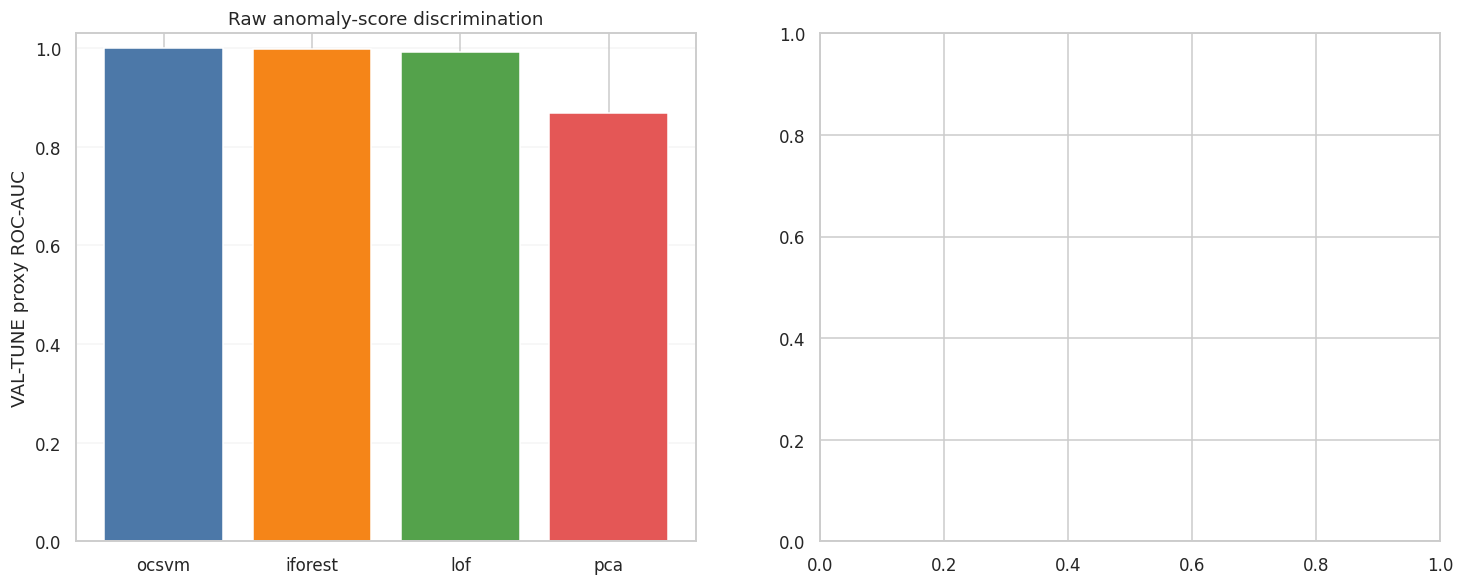

In [260]:
assert latent_reload.shape == (
    latent_metrics.shape
)

score_csv_parity = np.allclose(
    score_reload[
        "raw_score"
    ].to_numpy(dtype=float),
    score_table[
        "raw_score"
    ].to_numpy(dtype=float),
    rtol=0.0,
    atol=1e-12,
)

assert score_csv_parity





selected_candidate_records = []

for _, row in (
    selected_family_rows.iterrows()
):
    selected_candidate_records.append(
        {
            key: (
                value.item()
                if isinstance(
                    value,
                    np.generic,
                )
                else value
            )
            for key, value in (
                row.to_dict().items()
            )
        }
    )

selection_contract = {
    "artifact_type": (
        "anomaly_within_family_selection_contract"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "fit_partition": "train",
    "selection_partition": (
        "val_tune"
    ),
    "calibration_partition_accessed": (
        False
    ),
    "official_test_accessed": False,
    "healthy_definition": (
        f"RUL > {HEALTHY_RUL_MIN}"
    ),
    "proxy_definition": {
        "healthy": (
            f"RUL > {HEALTHY_RUL_MIN}"
        ),
        "abnormal": (
            f"RUL <= {ABNORMAL_RUL_MAX}"
        ),
        "excluded": (
            f"{ABNORMAL_RUL_MAX} < "
            f"RUL <= {HEALTHY_RUL_MIN}"
        ),
    },
    "primary_metric": (
        "raw-score pooled ROC-AUC"
    ),
    "candidate_count": 4,
    "family_count": 4,
    "functional_first_grid": True,
    "additional_candidates_deferred": (
        True
    ),
    "selected_within_family": (
        selected_within_family
    ),
    "selected_candidates": (
        selected_candidate_records
    ),
    "latent_group_diagnostics": {
        "used_for_selection": False,
        "diagnostic_only": True,
        "physical_fault_identity_claimed": (
            False
        ),
    },
    "selected_bundle": {
        "path": str(
            selected_bundle_path
        ),
        "sha256": (
            selected_bundle_sha256
        ),
    },
    "official_test_status": "SEALED",
}

selection_contract_path.write_text(
    json.dumps(
        selection_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

selection_contract_sha256 = (
    sha256_file(
        selection_contract_path
    )
)

selection_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                selection_contract_path
            ),
            "sha256": (
                selection_contract_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

contract_reload = json.loads(
    selection_contract_path.read_text(
        encoding="utf-8"
    )
)
sidecar_reload = json.loads(
    selection_sidecar_path.read_text(
        encoding="utf-8"
    )
)

assert contract_reload == (
    selection_contract
)
assert (
    sidecar_reload["sha256"]
    == selection_contract_sha256
    == sha256_file(
        selection_contract_path
    )
)





protocol_unchanged = (
    sha256_file(protocol_path)
    == protocol_sha_before
)

assert protocol_unchanged





fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

plot_summary = (
    family_ranking.sort_values(
        "proxy_auc_raw",
        ascending=False,
    )
)

axes[0].bar(
    plot_summary["family"],
    plot_summary[
        "proxy_auc_raw"
    ],
    color=[
        "#4c78a8",
        "#f58518",
        "#54a24b",
        "#e45756",
    ],
)

axes[0].set_ylim(0.0, 1.03)
axes[0].set_ylabel(
    "VAL-TUNE proxy ROC-AUC"
)
axes[0].set_title(
    "Raw anomaly-score discrimination"
)
axes[0].grid(
    axis="y",
    alpha=0.2,
)

region_plot = (
    region_summary.pivot(
        index="family",
        columns="rul_region",
        values="percentile_median",
    )
    .reindex(
        columns=[
            "healthy",
            "middle",
            "near_failure",
        ]
    )
)


In [261]:
region_plot.plot(
    kind="bar",
    ax=axes[1],
)

axes[1].set_ylim(0.0, 1.03)
axes[1].set_ylabel(
    "Median healthy-reference percentile"
)
axes[1].set_xlabel(
    "Anomaly family"
)
axes[1].set_title(
    "Anomaly percentile by RUL region"
)
axes[1].grid(
    axis="y",
    alpha=0.2,
)
axes[1].legend(
    title="RUL region"
)

fig.suptitle(
    (
        f"{SUBSET} Anomaly Family Selection "
        "— TRAIN fit / VAL-TUNE proxy"
    ),
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.94]
)
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [262]:
check_rows = [
    {
        "check": (
            "development_protocol_hash_valid"
        ),
        "passed": (
            protocol_sha_before
            == read_sidecar_hash(
                protocol_sidecar_path
            )
        ),
    },
    {
        "check": (
            "official_test_gate_remains_sealed"
        ),
        "passed": (
            protocol[
                "official_test_gate"
            ]["status"]
            == "SEALED"
            and not official_test_used
        ),
    },
    {
        "check": (
            "val_calib_not_used"
        ),
        "passed": (
            not val_calib_used
        ),
    },
    {
        "check": (
            "canonical_24_input_features"
        ),
        "passed": (
            len(input_feature_order)
            == 24
        ),
    },
    {
        "check": (
            "healthy_reference_has_70_engines"
        ),
        "passed": (
            healthy_train[
                "engine_id"
            ].nunique()
            == 70
        ),
    },
    {
        "check": (
            "preprocessed_matrices_finite"
        ),
        "passed": (
            np.isfinite(
                X_train_healthy
            ).all()
            and np.isfinite(
                X_tune
            ).all()
        ),
    },
    {
        "check": (
            "four_candidate_models_fit"
        ),
        "passed": (
            fit_count == 4
        ),
    },
    {
        "check": (
            "four_families_present"
        ),
        "passed": (
            set(
                candidate_summary[
                    "family"
                ]
            )
            == {
                "iforest",
                "lof",
                "ocsvm",
                "pca",
            }
        ),
    },
    {
        "check": (
            "all_proxy_metrics_finite"
        ),
        "passed": (
            np.isfinite(
                numeric_candidate_values
            ).all()
        ),
    },
    {
        "check": (
            "all_raw_auc_values_bounded"
        ),
        "passed": (
            candidate_summary[
                "proxy_auc_raw"
            ].between(
                0.0,
                1.0,
            ).all()
        ),
    },
    {
        "check": (
            "exactly_80_per_engine_rows"
        ),
        "passed": (
            len(per_engine_auc)
            == 80
        ),
    },
    {
        "check": (
            "one_family_winner_per_family"
        ),
        "passed": (
            len(
                selected_within_family
            )
            == 4
        ),
    },
    {
        "check": (
            "score_direction_larger_is_abnormal"
        ),
        "passed": (
            anomaly_bundle[
                "score_direction"
            ]
            == (
                "larger_is_more_abnormal"
            )
        ),
    },
    {
        "check": (
            "raw_scores_not_declared_probabilities"
        ),
        "passed": (
            anomaly_bundle[
                "raw_score_is_probability"
            ]
            is False
        ),
    },
    {
        "check": (
            "reload_score_and_percentile_parity"
        ),
        "passed": (
            len(
                reload_parity_results
            )
            == 8
            and all(
                reload_parity_results
            )
        ),
    },
    {
        "check": (
            "latent_groups_not_used_for_selection"
        ),
        "passed": (
            selection_contract[
                "latent_group_diagnostics"
            ]["used_for_selection"]
            is False
        ),
    },
    {
        "check": (
            "eight_latent_group_rows"
        ),
        "passed": (
            len(latent_metrics) == 8
        ),
    },
    {
        "check": (
            "saved_raw_score_parity"
        ),
        "passed": (
            score_csv_parity
        ),
    },
    {
        "check": (
            "selection_contract_reload_exact"
        ),
        "passed": (
            contract_reload
            == selection_contract
        ),
    },
    {
        "check": (
            "selection_contract_hash_valid"
        ),
        "passed": (
            sha256_file(
                selection_contract_path
            )
            == selection_contract_sha256
            == sidecar_reload[
                "sha256"
            ]
        ),
    },
    {
        "check": (
            "development_protocol_unchanged"
        ),
        "passed": (
            protocol_unchanged
        ),
    },
    {
        "check": (
            "selection_figure_created"
        ),
        "passed": (
            figure_path.is_file()
            and figure_path.stat().st_size
            > 0
        ),
    },
]


In [263]:
fd003_anomaly_selection_checks = (
    pd.DataFrame(check_rows)
)

failed_checks = int(
    (
        ~fd003_anomaly_selection_checks[
            "passed"
        ]
    ).sum()
)

selection_status = (
    "PASS"
    if failed_checks == 0
    else "FAIL"
)

assert failed_checks == 0, (
    fd003_anomaly_selection_checks.loc[
        ~fd003_anomaly_selection_checks[
            "passed"
        ]
    ]
)





print(
    " COMPUTED FD003 ANOMALY SELECTION CHECKS "
)
display(
    fd003_anomaly_selection_checks
)

print(
    "\n FD003 ANOMALY FAMILY RESULTS "
)
display(family_ranking)

print(
    "\n FD003 ANOMALY REGION SUMMARY "
)
display(region_summary)

print(
    "\n FD003 ANOMALY LATENT-GROUP DIAGNOSTICS "
)
display(latent_metrics)

print(
    "Retained anomaly features:",
    keep_features,
)
print(
    "Removed constant features:",
    removed_features,
)
print(
    "Selected within family:",
    selected_within_family,
)
print(
    "Models fitted:",
    fit_count,
)
print(
    "VAL-CALIB used:",
    val_calib_used,
)
print(
    "Official Test used:",
    official_test_used,
)
print(
    "Executed checks:",
    len(
        fd003_anomaly_selection_checks
    ),
)
print(
    "Failed checks:",
    failed_checks,
)
print(
    "Anomaly selection status:",
    selection_status,
)
print(
    "Saved selected family bundle:",
    selected_bundle_path,
)
print(
    "Selected family bundle SHA256:",
    selected_bundle_sha256,
)
print(
    "Saved selection contract:",
    selection_contract_path,
)
print(
    "Selection contract SHA256:",
    selection_contract_sha256,
)


 COMPUTED FD003 ANOMALY SELECTION CHECKS 


,check,passed
0,development_protocol_hash_valid,True
1,official_test_gate_remains_sealed,True
2,val_calib_not_used,True
3,canonical_24_input_features,True
4,healthy_reference_has_70_engines,True
5,preprocessed_matrices_finite,True
6,four_candidate_models_fit,True
7,four_families_present,True
8,all_proxy_metrics_finite,True
9,all_raw_auc_values_bounded,True



 FD003 ANOMALY FAMILY RESULTS 


,candidate_id,family,parameters_json,effective_parameters_json,n_fit_rows,n_fit_engines,n_features,proxy_auc_raw,proxy_auc_percentile,auc_percentile_minus_raw,per_engine_auc_mean,per_engine_auc_median,per_engine_auc_min,fit_seconds,score_seconds,inference_us_per_row,within_family_rank
0,iforest_n200_ms_0p5,iforest,"{""contamination"": ""auto"", ""max_samples"": 0.5, ...",{},9399,70,18,0.999128,0.999126,-0.000002,0.999783,1.000000,0.995667,0.314310,0.072371,16.136152,1
1,lof_k50,lof,"{""contamination"": ""auto"", ""n_jobs"": -1, ""n_nei...",{},9399,70,18,0.993011,0.993013,0.000002,0.993464,1.000000,0.947520,0.181680,0.107487,23.965789,1
2,ocsvm_nu0p05_gamma_0p01,ocsvm,"{""gamma"": 0.01, ""kernel"": ""rbf"", ""nu"": 0.05}",{},9399,70,18,0.999322,0.999307,-0.000015,0.999783,1.000000,0.995667,0.250378,0.088808,19.801137,1
3,pca_evr0p95,pca,"{""n_components"": 0.95, ""svd_solver"": ""full""}","{""achieved_evr"": 0.9566104165093647, ""n_compon...",9399,70,18,0.868745,0.868740,-0.000005,0.871496,0.922535,0.531661,0.003617,0.006311,1.407182,1



 FD003 ANOMALY REGION SUMMARY 


,family,candidate_id,rul_region,n_rows,percentile_mean,percentile_median,raw_score_mean
0,iforest,iforest_n200_ms_0p5,healthy,1965,0.464600,0.443771,-0.096980
1,iforest,iforest_n200_ms_0p5,middle,1900,0.755994,0.871688,-0.028354
2,iforest,iforest_n200_ms_0p5,near_failure,620,0.999081,1.000000,0.180360
3,lof,lof_k50,healthy,1965,0.498248,0.501224,-0.449604
4,lof,lof_k50,middle,1900,0.691582,0.776412,-0.309829
5,lof,lof_k50,near_failure,620,0.992504,0.999149,1.315569
6,ocsvm,ocsvm_nu0p05_gamma_0p01,healthy,1965,0.451450,0.444196,-25.028797
7,ocsvm,ocsvm_nu0p05_gamma_0p01,middle,1900,0.758443,0.903181,10.648124
8,ocsvm,ocsvm_nu0p05_gamma_0p01,near_failure,620,0.997856,1.000000,128.486994
9,pca,pca_evr0p95,healthy,1965,0.505548,0.507820,0.043697



 FD003 ANOMALY LATENT-GROUP DIAGNOSTICS 


,family,candidate_id,latent_group,n_engines,auc_raw_mean,auc_raw_median,auc_raw_min
0,iforest,iforest_n200_ms_0p5,latent_A,10,1.000000,1.000000,1.000000
1,iforest,iforest_n200_ms_0p5,latent_B,10,0.999567,1.000000,0.995667
2,lof,lof_k50,latent_A,10,0.996720,1.000000,0.983103
3,lof,lof_k50,latent_B,10,0.990208,1.000000,0.947520
4,ocsvm,ocsvm_nu0p05_gamma_0p01,latent_A,10,1.000000,1.000000,1.000000
5,ocsvm,ocsvm_nu0p05_gamma_0p01,latent_B,10,0.999567,1.000000,0.995667
6,pca,pca_evr0p95,latent_A,10,0.864282,0.964436,0.531661
7,pca,pca_evr0p95,latent_B,10,0.878710,0.866800,0.704086


Retained anomaly features: ['op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Removed constant features: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']
Selected within family: {'iforest': 'iforest_n200_ms_0p5', 'lof': 'lof_k50', 'ocsvm': 'ocsvm_nu0p05_gamma_0p01', 'pca': 'pca_evr0p95'}
Models fitted: 4
VAL-CALIB used: False
Official Test used: False
Executed checks: 22
Failed checks: 0
Anomaly selection status: PASS
Saved selected family bundle: artifacts/models/FD003_anomaly_selected_family_bundle.joblib
Selected family bundle SHA256: f62f763d33bc2611e5527542e70b84aab6469d4ea37994677573316a691cfb5c
Saved selection contract: data/processed/FD003_anomaly_within_family_selected.json
Selection contract SHA256: 9db51b880c479e9e001b4dc4618d7f24a2e4f150d6e4756491dde06536568949


### FD003 frozen anomaly policy and VAL-CALIB selection

The policy grid is frozen BEFORE VAL-CALIB is derived.
Existing anomaly models and reference CDFs are used without refitting.
Official Test and RUL_FD003 are not accessed.


In [264]:
import sys
import json
import hashlib
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd





PROJECT_ROOT = next(
    Path(".")
    for path in (Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())), Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir() and (path / "notebooks").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"

assert PROJECT_ROOT.is_dir()
assert SRC_DIR.is_dir()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from data_loader import (
    load_raw,
    add_train_rul,
)


SUBSET = "FD003"

HEALTHY_RUL_MIN = 125
ACTION_HORIZON = 30

THRESHOLD_GRID = [
    0.90,
    0.95,
    0.975,
    0.99,
]
ELIGIBLE_PERSISTENCE_GRID = [
    (2, 3),
    (3, 5),
    (5, 10),
]
DIAGNOSTIC_PERSISTENCE_GRID = [
    (1, 1),
]

COST_WEIGHTS = {
    "miss": 100.0,
    "late": 5.0,
    "early": 1.0,
}

MODEL_DIR = Path(config.MODELS_DIR)
RESULT_DIR = MODEL_DIR.parent / "results"
PROCESSED_DIR = Path(config.DATA_PROCESSED)
FIGURE_DIR = Path(config.FIGURES_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)





source_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_selected_family_bundle.joblib"
)
source_selection_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.json"
)
source_selection_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_anomaly_within_family_selected.sha256"
)
protocol_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.json"
)
protocol_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.sha256"
)
split_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_engine_split.csv"
)





policy_grid_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.json"
)
policy_grid_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_policy_contract.sha256"
)
timeline_path = (
    RESULT_DIR
    / f"{SUBSET}_anomaly_val_calib_selected_timelines.csv"
)
policy_engine_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_engine_results.csv"
)
policy_summary_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_summary.csv"
)
policy_ranking_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_anomaly_policy_ranking.csv"
)
selected_engine_path = (
    RESULT_DIR
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)
final_bundle_path = (
    MODEL_DIR
    / f"{SUBSET}_anomaly_policy_bundle.joblib"
)
selected_policy_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_selected_anomaly_policy.json"
)
selected_policy_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_selected_anomaly_policy.sha256"
)
figure_path = (
    FIGURE_DIR
    / f"{SUBSET}_task6_selected_anomaly_policy.png"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def read_sidecar_hash(path):
    text = path.read_text(
        encoding="utf-8"
    ).strip()

    try:
        data = json.loads(text)

        if isinstance(data, dict):
            value = str(
                data.get("sha256", "")
            ).strip().lower()

            if len(value) == 64:
                return value
    except json.JSONDecodeError:
        pass

    for token in text.replace(
        "\n",
        " ",
    ).split():
        token = token.strip().lower()

        if (
            len(token) == 64
            and all(
                character
                in "0123456789abcdef"
                for character in token
            )
        ):
            return token

    raise ValueError(
        f"No SHA256 found in {path}"
    )


def raw_anomaly_score(
    family,
    model,
    X,
):
    if family in {
        "iforest",
        "lof",
        "ocsvm",
    }:
        score = -model.decision_function(
            X
        )

    elif family == "pca":
        transformed = model.transform(X)
        reconstructed = (
            model.inverse_transform(
                transformed
            )
        )

        score = np.mean(
            (X - reconstructed) ** 2,
            axis=1,
        )

    else:
        raise ValueError(
            f"Unknown family: {family}"
        )

    score = np.asarray(
        score,
        dtype=float,
    )

    assert score.shape == (
        len(X),
    )
    assert np.isfinite(score).all()

    return score


In [265]:
def reference_percentile(
    sorted_reference,
    score,
):
    percentile = np.searchsorted(
        sorted_reference,
        score,
        side="right",
    ) / len(sorted_reference)

    percentile = np.asarray(
        percentile,
        dtype=float,
    )

    assert np.isfinite(
        percentile
    ).all()
    assert np.all(
        percentile >= 0.0
    )
    assert np.all(
        percentile <= 1.0
    )

    return percentile


def first_persistent_trigger(
    cycles,
    crossing,
    m,
    n,
):
    cycles = np.asarray(
        cycles,
        dtype=int,
    )
    crossing = np.asarray(
        crossing,
        dtype=bool,
    )

    assert len(cycles) == len(crossing)
    assert len(cycles) > 0

    rolling_crossings = []
    previous_cycle = None
    gap_count = 0

    for cycle, crossed in zip(
        cycles,
        crossing,
    ):
        if (
            previous_cycle is not None
            and cycle
            != previous_cycle + 1
        ):
            rolling_crossings = []
            gap_count += 1

        rolling_crossings.append(
            bool(crossed)
        )

        if len(rolling_crossings) > n:
            rolling_crossings.pop(0)

        if (
            len(rolling_crossings) >= m
            and sum(
                rolling_crossings
            ) >= m
        ):
            return (
                float(cycle),
                gap_count,
            )

        previous_cycle = cycle

    return np.nan, gap_count


def evaluate_policy_for_engine(
    engine_frame,
    family,
    candidate_id,
    cutoff,
    m,
    n,
    eligible,
):
    engine_frame = (
        engine_frame.sort_values(
            "cycle"
        )
    )

    cycles = engine_frame[
        "cycle"
    ].to_numpy(dtype=int)

    percentile = engine_frame[
        "anomaly_percentile"
    ].to_numpy(dtype=float)

    crossing = percentile >= cutoff

    tau, gap_count = (
        first_persistent_trigger(
            cycles,
            crossing,
            m,
            n,
        )
    )

    failure_cycle = int(
        engine_frame["cycle"].max()
    )
    engine_id = int(
        engine_frame[
            "engine_id"
        ].iloc[0]
    )

    missed = bool(np.isnan(tau))

    if missed:
        lead_time = np.nan
        late_delay = np.nan
        early_burden = np.nan

        late_normalized = 0.0
        early_normalized_uncapped = 0.0
        early_normalized_for_cost = (
            0.0
        )

        miss_component = (
            COST_WEIGHTS["miss"]
        )
        late_component = 0.0
        early_component = 0.0

        first_trigger_while_healthy = (
            False
        )
        trigger_at_failure_only = (
            False
        )

    else:
        tau = float(tau)

        lead_time = float(
            failure_cycle - tau
        )

        late_delay = float(
            max(
                ACTION_HORIZON
                - lead_time,
                0.0,
            )
        )

        early_burden = float(
            max(
                lead_time
                - ACTION_HORIZON,
                0.0,
            )
        )

        late_normalized = float(
            min(
                late_delay
                / ACTION_HORIZON,
                1.0,
            )
        )

        early_normalized_uncapped = (
            float(
                early_burden
                / ACTION_HORIZON
            )
        )

        early_normalized_for_cost = (
            float(
                min(
                    early_normalized_uncapped,
                    1.0,
                )
            )
        )

        miss_component = 0.0

        late_component = float(
            COST_WEIGHTS["late"]
            * late_normalized
        )

        early_component = float(
            COST_WEIGHTS["early"]
            * early_normalized_for_cost
        )

        first_trigger_while_healthy = (
            lead_time
            > HEALTHY_RUL_MIN
        )

        trigger_at_failure_only = (
            lead_time == 0.0
        )

    total_cost = float(
        miss_component
        + late_component
        + early_component
    )

    return {
        "family": family,
        "candidate_id": candidate_id,
        "reference_type": "pooled",
        "cutoff": float(cutoff),
        "m": int(m),
        "n": int(n),
        "selection_eligible": bool(
            eligible
        ),
        "engine_id": engine_id,
        "failure_cycle": (
            failure_cycle
        ),
        "tau": tau,
        "missed": missed,
        "trigger_at_failure_only": (
            trigger_at_failure_only
        ),
        "lead_time": lead_time,
        "late_delay": late_delay,
        "early_burden": early_burden,
        "late_normalized": (
            late_normalized
        ),
        "early_normalized_uncapped": (
            early_normalized_uncapped
        ),
        "early_normalized_for_cost": (
            early_normalized_for_cost
        ),
        "miss_component": (
            miss_component
        ),
        "late_component": (
            late_component
        ),
        "early_component": (
            early_component
        ),
        "total_cost": total_cost,
        "first_trigger_while_healthy": (
            first_trigger_while_healthy
        ),
        "n_cycle_gaps": int(
            gap_count
        ),
    }


In [266]:
required_inputs = {
    "source_bundle": source_bundle_path,
    "source_selection": (
        source_selection_path
    ),
    "source_selection_sidecar": (
        source_selection_sidecar_path
    ),
    "protocol": protocol_path,
    "protocol_sidecar": (
        protocol_sidecar_path
    ),
    "split": split_path,
}

for name, path in required_inputs.items():
    assert path.is_file(), (
        f"Missing {name}: {path}"
    )
    assert path.stat().st_size > 0

source_bundle_sha_before = (
    sha256_file(source_bundle_path)
)
source_selection_sha_before = (
    sha256_file(source_selection_path)
)
protocol_sha_before = sha256_file(
    protocol_path
)

assert (
    source_selection_sha_before
    == read_sidecar_hash(
        source_selection_sidecar_path
    )
)
assert (
    protocol_sha_before
    == read_sidecar_hash(
        protocol_sidecar_path
    )
)

source_selection = json.loads(
    source_selection_path.read_text(
        encoding="utf-8"
    )
)
protocol = json.loads(
    protocol_path.read_text(
        encoding="utf-8"
    )
)

assert (
    source_selection["subset"]
    == SUBSET
)
assert (
    source_selection[
        "official_test_status"
    ]
    == "SEALED"
)
assert (
    source_selection[
        "calibration_partition_accessed"
    ]
    is False
)
assert (
    source_selection[
        "selected_bundle"
    ]["sha256"]
    == source_bundle_sha_before
)

assert (
    protocol["official_test_gate"][
        "status"
    ]
    == "SEALED"
)
assert (
    protocol["official_test_gate"][
        "evaluation_authorized"
    ]
    is False
)





access_events = []

policy_grid_contract = {
    "artifact_type": (
        "frozen_anomaly_policy_grid_contract"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "selected_candidates": (
        source_selection[
            "selected_within_family"
        ]
    ),
    "reference_type": "pooled",
    "threshold_grid": (
        THRESHOLD_GRID
    ),
    "eligible_persistence_grid": [
        [m, n]
        for m, n in (
            ELIGIBLE_PERSISTENCE_GRID
        )
    ],
    "diagnostic_only_persistence_grid": [
        [m, n]
        for m, n in (
            DIAGNOSTIC_PERSISTENCE_GRID
        )
    ],
    "action_horizon": (
        ACTION_HORIZON
    ),
    "healthy_boundary": (
        HEALTHY_RUL_MIN
    ),
    "cost_weights": {
        "c_miss": (
            COST_WEIGHTS["miss"]
        ),
        "c_late": (
            COST_WEIGHTS["late"]
        ),
        "c_early": (
            COST_WEIGHTS["early"]
        ),
    },
    "early_cost_cap": 1.0,
    "late_cost_cap": 1.0,
    "selection_order": [
        "fewest missed engines",
        "lowest mean total cost",
        (
            "lowest healthy first-trigger "
            "fraction"
        ),
        "lowest mean early component",
        "lowest mean late component",
        "family",
        "cutoff",
        "m",
        "n",
    ],
    "cycle_gap_reset": True,
    "alert_latching": True,
    "source_anomaly_bundle": {
        "path": str(
            source_bundle_path
        ),
        "sha256": (
            source_bundle_sha_before
        ),
    },
    "source_selection_contract": {
        "path": str(
            source_selection_path
        ),
        "sha256": (
            source_selection_sha_before
        ),
    },
    "val_calib_accessed": False,
    "official_test_accessed": False,
    "official_test_status": "SEALED",
}

policy_grid_contract_path.write_text(
    json.dumps(
        policy_grid_contract,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

policy_grid_contract_sha256 = (
    sha256_file(
        policy_grid_contract_path
    )
)

policy_grid_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                policy_grid_contract_path
            ),
            "sha256": (
                policy_grid_contract_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

grid_reload = json.loads(
    policy_grid_contract_path.read_text(
        encoding="utf-8"
    )
)

assert grid_reload == (
    policy_grid_contract
)


In [267]:
assert (
    read_sidecar_hash(
        policy_grid_sidecar_path
    )
    == policy_grid_contract_sha256
)

access_events.append(
    "policy_grid_frozen"
)





source_bundle = joblib.load(
    source_bundle_path
)

assert source_bundle["subset"] == SUBSET
assert (
    source_bundle[
        "official_test_status"
    ]
    == "SEALED"
)
assert set(
    source_bundle["candidates"]
) == {
    "iforest",
    "lof",
    "ocsvm",
    "pca",
}





loaded_data_roles = []

df_all = load_raw(
    SUBSET,
    "train",
)
loaded_data_roles.append(
    "official_train"
)
access_events.append(
    "official_train_loaded"
)

df_all = add_train_rul(
    df_all,
    cap=None,
)

split_table = pd.read_csv(
    split_path
)

split_table["engine_id"] = (
    split_table["engine_id"].astype(int)
)

calib_ids = set(
    split_table.loc[
        split_table["role"]
        == "val_calib",
        "engine_id",
    ]
)

df_calib = (
    df_all.loc[
        df_all["engine_id"].isin(
            calib_ids
        )
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
)

access_events.append(
    "val_calib_derived"
)

assert (
    access_events.index(
        "policy_grid_frozen"
    )
    < access_events.index(
        "val_calib_derived"
    )
)

assert len(df_calib) == 2016
assert (
    df_calib["engine_id"].nunique()
    == 10
)

official_test_used = any(
    "test" in role.lower()
    for role in loaded_data_roles
)
official_rul_used = any(
    "rul_file" in role.lower()
    for role in loaded_data_roles
)

assert not official_test_used
assert not official_rul_used





preprocessor = source_bundle[
    "feature_preprocessor"
]
keep_features = preprocessor[
    "keep_features"
]
scaler = preprocessor["scaler"]

X_calib = scaler.transform(
    df_calib[keep_features]
)

assert np.isfinite(X_calib).all()

timeline_frames = []

for family in sorted(
    source_bundle["candidates"]
):
    entry = source_bundle[
        "candidates"
    ][family]

    raw_score = raw_anomaly_score(
        family,
        entry["model"],
        X_calib,
    )

    percentile = reference_percentile(
        entry[
            "healthy_reference_scores_sorted"
        ],
        raw_score,
    )

    timeline_frames.append(
        pd.DataFrame(
            {
                "engine_id": (
                    df_calib[
                        "engine_id"
                    ].to_numpy(dtype=int)
                ),
                "cycle": (
                    df_calib[
                        "cycle"
                    ].to_numpy(dtype=int)
                ),
                "RUL": (
                    df_calib["RUL"]
                    .to_numpy(dtype=float)
                ),
                "family": family,
                "candidate_id": (
                    entry[
                        "candidate_id"
                    ]
                ),
                "raw_score": raw_score,
                "anomaly_percentile": (
                    percentile
                ),
            }
        )
    )

timeline_table = pd.concat(
    timeline_frames,
    ignore_index=True,
)

assert len(timeline_table) == (
    4 * len(df_calib)
)
assert (
    timeline_table[
        "engine_id"
    ].nunique()
    == 10
)
assert np.isfinite(
    timeline_table[
        [
            "raw_score",
            "anomaly_percentile",
        ]
    ].to_numpy(dtype=float)
).all()
assert timeline_table[
    "anomaly_percentile"
].between(0.0, 1.0).all()





policy_engine_rows = []

all_persistence = [
    (
        m,
        n,
        True,
    )
    for m, n in (
        ELIGIBLE_PERSISTENCE_GRID
    )
] + [
    (
        m,
        n,
        False,
    )
    for m, n in (
        DIAGNOSTIC_PERSISTENCE_GRID
    )
]


In [268]:
for family in sorted(
    source_bundle["candidates"]
):
    family_timeline = (
        timeline_table.loc[
            timeline_table["family"]
            == family
        ]
    )

    candidate_id = str(
        source_bundle[
            "candidates"
        ][family]["candidate_id"]
    )

    for cutoff in THRESHOLD_GRID:
        for m, n, eligible in (
            all_persistence
        ):
            for _, engine_frame in (
                family_timeline.groupby(
                    "engine_id",
                    sort=True,
                )
            ):
                policy_engine_rows.append(
                    evaluate_policy_for_engine(
                        engine_frame=(
                            engine_frame
                        ),
                        family=family,
                        candidate_id=(
                            candidate_id
                        ),
                        cutoff=cutoff,
                        m=m,
                        n=n,
                        eligible=eligible,
                    )
                )

policy_engine_results = pd.DataFrame(
    policy_engine_rows
)

expected_policy_count = (
    4
    * len(THRESHOLD_GRID)
    * len(all_persistence)
)

assert expected_policy_count == 64
assert len(policy_engine_results) == (
    expected_policy_count * 10
)

assert policy_engine_results[
    "total_cost"
].ge(0.0).all()
assert policy_engine_results[
    "n_cycle_gaps"
].eq(0).all()





summary_rows = []

group_columns = [
    "family",
    "candidate_id",
    "reference_type",
    "cutoff",
    "m",
    "n",
    "selection_eligible",
]

for keys, group in (
    policy_engine_results.groupby(
        group_columns,
        sort=True,
    )
):
    (
        family,
        candidate_id,
        reference_type,
        cutoff,
        m,
        n,
        selection_eligible,
    ) = keys

    alerted = group.loc[
        ~group["missed"]
    ]

    lead_values = alerted[
        "lead_time"
    ].to_numpy(dtype=float)

    summary_rows.append(
        {
            "family": family,
            "candidate_id": (
                candidate_id
            ),
            "reference_type": (
                reference_type
            ),
            "cutoff": float(
                cutoff
            ),
            "m": int(m),
            "n": int(n),
            "selection_eligible": bool(
                selection_eligible
            ),
            "n_engines": int(
                len(group)
            ),
            "missed_engines": int(
                group["missed"].sum()
            ),
            "miss_rate": float(
                group["missed"].mean()
            ),
            "mean_total_cost": float(
                group[
                    "total_cost"
                ].mean()
            ),
            "mean_miss_component": float(
                group[
                    "miss_component"
                ].mean()
            ),
            "mean_late_component": float(
                group[
                    "late_component"
                ].mean()
            ),
            "mean_early_component": float(
                group[
                    "early_component"
                ].mean()
            ),
            "mean_raw_late_delay": float(
                alerted[
                    "late_delay"
                ].mean()
            )
            if len(alerted) > 0
            else np.nan,
            "mean_raw_early_burden": float(
                alerted[
                    "early_burden"
                ].mean()
            )
            if len(alerted) > 0
            else np.nan,
            "mean_lead_time": float(
                np.mean(lead_values)
            )
            if len(lead_values) > 0
            else np.nan,
            "median_lead_time": float(
                np.median(lead_values)
            )
            if len(lead_values) > 0
            else np.nan,
            "minimum_lead_time": float(
                np.min(lead_values)
            )
            if len(lead_values) > 0
            else np.nan,
            "maximum_lead_time": float(
                np.max(lead_values)
            )
            if len(lead_values) > 0
            else np.nan,
            "healthy_first_trigger_fraction": float(
                group[
                    "first_trigger_while_healthy"
                ].mean()
            ),
        }
    )

policy_summary = pd.DataFrame(
    summary_rows
)

assert len(policy_summary) == 64
assert (
    policy_summary[
        "selection_eligible"
    ].sum()
    == 48
)





eligible_policy_ranking = (
    policy_summary.loc[
        policy_summary[
            "selection_eligible"
        ]
    ]
    .sort_values(
        [
            "missed_engines",
            "mean_total_cost",
            (
                "healthy_first_"
                "trigger_fraction"
            ),
            "mean_early_component",
            "mean_late_component",
            "family",
            "cutoff",
            "m",
            "n",
        ],
        ascending=True,
        kind="mergesort",
    )
    .reset_index(drop=True)
)


In [269]:
eligible_policy_ranking.insert(
    0,
    "selection_rank",
    np.arange(
        1,
        len(
            eligible_policy_ranking
        ) + 1,
    ),
)

selected_policy_row = (
    eligible_policy_ranking.iloc[0]
)

selected_family = str(
    selected_policy_row["family"]
)
selected_candidate_id = str(
    selected_policy_row[
        "candidate_id"
    ]
)
selected_cutoff = float(
    selected_policy_row["cutoff"]
)
selected_m = int(
    selected_policy_row["m"]
)
selected_n = int(
    selected_policy_row["n"]
)

per_family_winners = (
    eligible_policy_ranking
    .sort_values(
        [
            "family",
            "missed_engines",
            "mean_total_cost",
            (
                "healthy_first_"
                "trigger_fraction"
            ),
            "mean_early_component",
            "mean_late_component",
            "cutoff",
            "m",
            "n",
        ],
        ascending=True,
        kind="mergesort",
    )
    .groupby(
        "family",
        as_index=False,
        sort=True,
    )
    .first()
)

assert len(per_family_winners) == 4

selected_engine_results = (
    policy_engine_results.loc[
        (
            policy_engine_results[
                "family"
            ]
            == selected_family
        )
        & (
            np.isclose(
                policy_engine_results[
                    "cutoff"
                ],
                selected_cutoff,
            )
        )
        & (
            policy_engine_results["m"]
            == selected_m
        )
        & (
            policy_engine_results["n"]
            == selected_n
        )
        & (
            policy_engine_results[
                "selection_eligible"
            ]
        )
    ]
    .copy()
    .sort_values("engine_id")
    .reset_index(drop=True)
)

assert len(selected_engine_results) == 10





policy_bundle = dict(source_bundle)

policy_bundle[
    "artifact_type"
] = "frozen_anomaly_policy_bundle"
policy_bundle[
    "artifact_version"
] = 1
policy_bundle[
    "threshold_status"
] = "selected_on_val_calib"
policy_bundle[
    "persistence_status"
] = "selected_on_val_calib"
policy_bundle[
    "calibration_partition"
] = "val_calib"
policy_bundle[
    "val_calib_status"
] = "USED_FOR_POLICY_SELECTION"
policy_bundle[
    "per_family_policy_winners"
] = {
    str(row["family"]): {
        key: (
            value.item()
            if isinstance(
                value,
                np.generic,
            )
            else value
        )
        for key, value in (
            row.to_dict().items()
        )
    }
    for _, row in (
        per_family_winners.iterrows()
    )
}
policy_bundle[
    "selected_overall_policy"
] = {
    key: (
        value.item()
        if isinstance(
            value,
            np.generic,
        )
        else value
    )
    for key, value in (
        selected_policy_row
        .to_dict()
        .items()
    )
}
policy_bundle[
    "frozen_policy_contract"
] = {
    "path": str(
        policy_grid_contract_path
    ),
    "sha256": (
        policy_grid_contract_sha256
    ),
}
policy_bundle[
    "official_test_status"
] = "sealed"

joblib.dump(
    policy_bundle,
    final_bundle_path,
)

final_bundle_sha256 = (
    sha256_file(final_bundle_path)
)





selection_result = {
    "artifact_type": (
        "selected_anomaly_policy"
    ),
    "artifact_version": 1,
    "subset": SUBSET,
    "selection_partition": (
        "val_calib"
    ),
    "manual_override_applied": False,
    "selected_policy": {
        "family": selected_family,
        "candidate_id": (
            selected_candidate_id
        ),
        "reference_type": "pooled",
        "cutoff": selected_cutoff,
        "persistence": {
            "m": selected_m,
            "n": selected_n,
        },
    },
    "selected_policy_metrics": {
        key: (
            value.item()
            if isinstance(
                value,
                np.generic,
            )
            else value
        )
        for key, value in (
            selected_policy_row
            .to_dict()
            .items()
        )
    },
    "policy_bundle": {
        "path": str(
            final_bundle_path
        ),
        "sha256": (
            final_bundle_sha256
        ),
    },
    "frozen_policy_grid_contract": {
        "path": str(
            policy_grid_contract_path
        ),
        "sha256": (
            policy_grid_contract_sha256
        ),
    },
    "official_test_accessed": False,
    "official_test_status": "SEALED",
}


In [270]:
selected_policy_path.write_text(
    json.dumps(
        selection_result,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

selected_policy_sha256 = (
    sha256_file(
        selected_policy_path
    )
)

selected_policy_sidecar_path.write_text(
    json.dumps(
        {
            "file": str(
                selected_policy_path
            ),
            "sha256": (
                selected_policy_sha256
            ),
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)





policy_bundle_reload = joblib.load(
    final_bundle_path
)

reload_preprocessor = (
    policy_bundle_reload[
        "feature_preprocessor"
    ]
)

reload_X = reload_preprocessor[
    "scaler"
].transform(
    df_calib[
        reload_preprocessor[
            "keep_features"
        ]
    ]
)

reload_entry = (
    policy_bundle_reload[
        "candidates"
    ][selected_family]
)

reload_raw_score = (
    raw_anomaly_score(
        selected_family,
        reload_entry["model"],
        reload_X,
    )
)

reload_percentile = (
    reference_percentile(
        reload_entry[
            "healthy_reference_scores_sorted"
        ],
        reload_raw_score,
    )
)

selected_timeline = (
    timeline_table.loc[
        timeline_table["family"]
        == selected_family
    ]
    .copy()
    .sort_values(
        ["engine_id", "cycle"]
    )
    .reset_index(drop=True)
)

reload_score_parity = np.allclose(
    reload_raw_score,
    selected_timeline[
        "raw_score"
    ].to_numpy(dtype=float),
    rtol=0.0,
    atol=1e-12,
)

reload_percentile_parity = (
    np.allclose(
        reload_percentile,
        selected_timeline[
            "anomaly_percentile"
        ].to_numpy(dtype=float),
        rtol=0.0,
        atol=1e-12,
    )
)

assert reload_score_parity
assert reload_percentile_parity

reload_selected_rows = []

for _, engine_frame in (
    selected_timeline.groupby(
        "engine_id",
        sort=True,
    )
):
    reload_selected_rows.append(
        evaluate_policy_for_engine(
            engine_frame=engine_frame,
            family=selected_family,
            candidate_id=(
                selected_candidate_id
            ),
            cutoff=selected_cutoff,
            m=selected_m,
            n=selected_n,
            eligible=True,
        )
    )

reload_selected_engine_results = (
    pd.DataFrame(
        reload_selected_rows
    )
    .sort_values("engine_id")
    .reset_index(drop=True)
)

reload_tau_parity = np.allclose(
    reload_selected_engine_results[
        "tau"
    ].to_numpy(dtype=float),
    selected_engine_results[
        "tau"
    ].to_numpy(dtype=float),
    equal_nan=True,
    rtol=0.0,
    atol=1e-12,
)

reload_cost_parity = np.allclose(
    reload_selected_engine_results[
        "total_cost"
    ].to_numpy(dtype=float),
    selected_engine_results[
        "total_cost"
    ].to_numpy(dtype=float),
    rtol=0.0,
    atol=1e-12,
)

assert reload_tau_parity
assert reload_cost_parity





timeline_table.to_csv(
    timeline_path,
    index=False,
)
policy_engine_results.to_csv(
    policy_engine_path,
    index=False,
)
policy_summary.to_csv(
    policy_summary_path,
    index=False,
)
eligible_policy_ranking.to_csv(
    policy_ranking_path,
    index=False,
)
selected_engine_results.to_csv(
    selected_engine_path,
    index=False,
)

timeline_reload = pd.read_csv(
    timeline_path
)
engine_reload = pd.read_csv(
    policy_engine_path
)
summary_reload = pd.read_csv(
    policy_summary_path
)
ranking_reload = pd.read_csv(
    policy_ranking_path
)
selected_engine_reload = pd.read_csv(
    selected_engine_path
)

assert timeline_reload.shape == (
    timeline_table.shape
)
assert engine_reload.shape == (
    policy_engine_results.shape
)
assert summary_reload.shape == (
    policy_summary.shape
)
assert ranking_reload.shape == (
    eligible_policy_ranking.shape
)


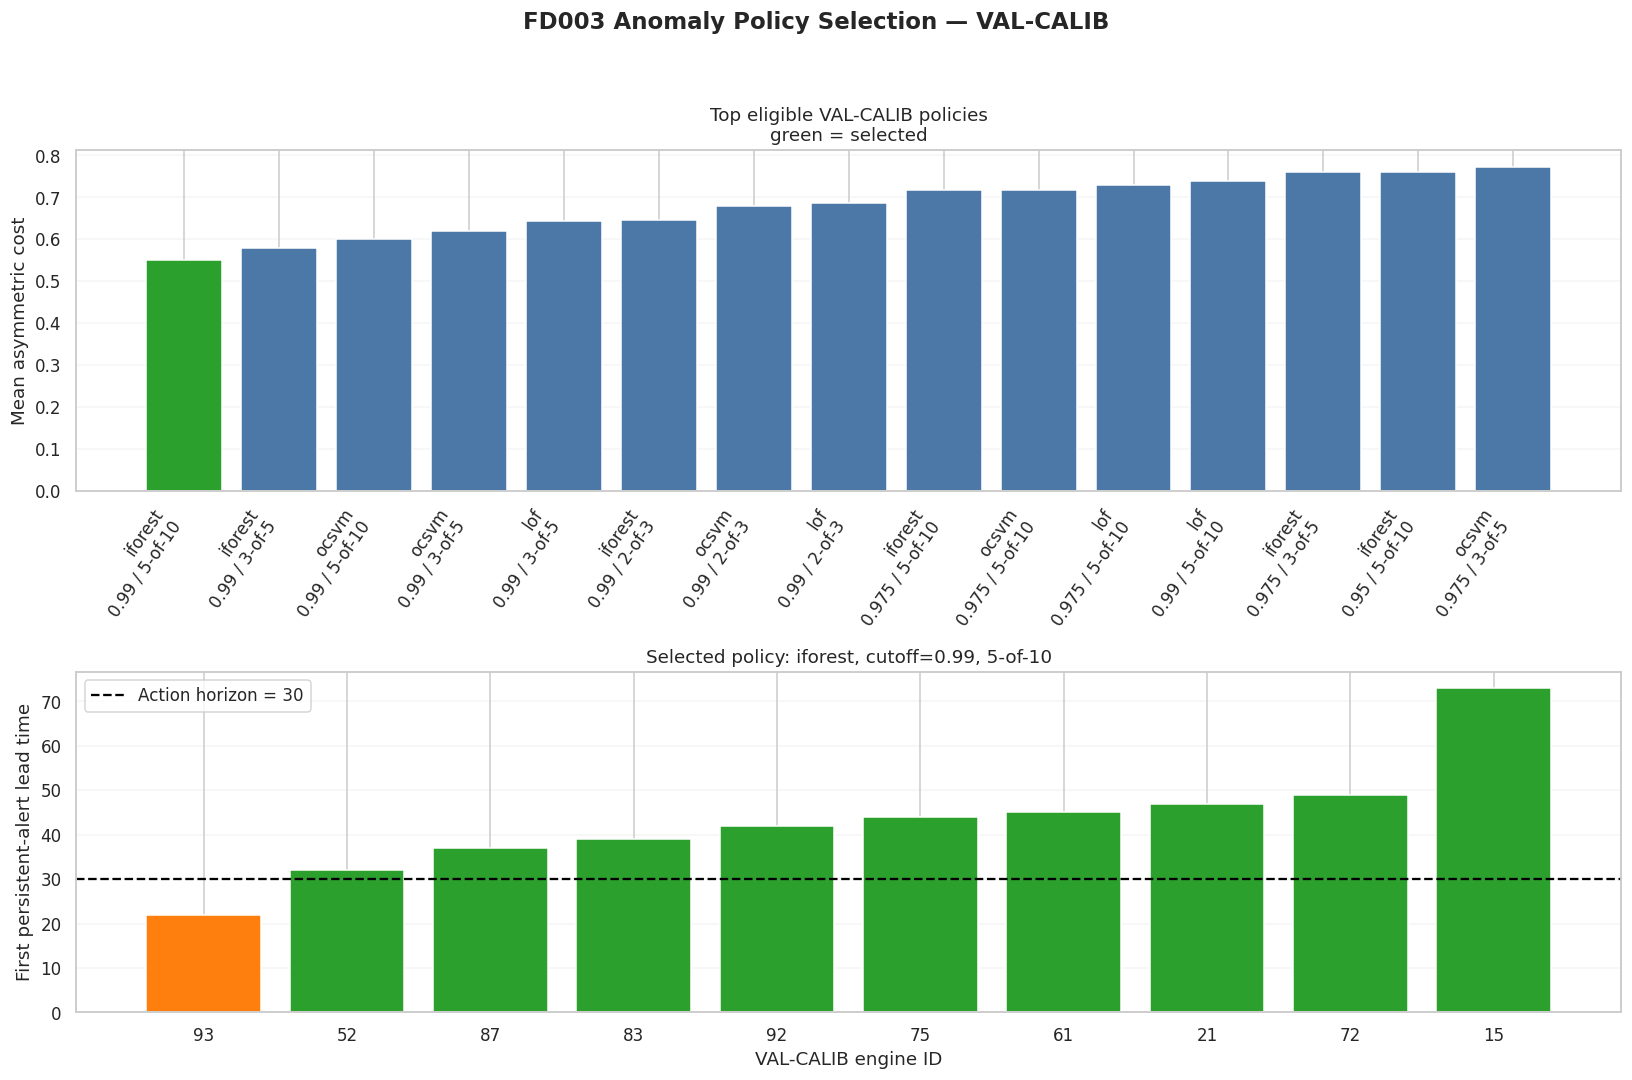

In [271]:
assert selected_engine_reload.shape == (
    selected_engine_results.shape
)

saved_timeline_parity = np.allclose(
    timeline_reload[
        "anomaly_percentile"
    ].to_numpy(dtype=float),
    timeline_table[
        "anomaly_percentile"
    ].to_numpy(dtype=float),
    rtol=0.0,
    atol=1e-12,
)

assert saved_timeline_parity





selection_result_reload = json.loads(
    selected_policy_path.read_text(
        encoding="utf-8"
    )
)

assert selection_result_reload == (
    selection_result
)
assert (
    read_sidecar_hash(
        selected_policy_sidecar_path
    )
    == selected_policy_sha256
)

source_bundle_unchanged = (
    sha256_file(source_bundle_path)
    == source_bundle_sha_before
)
source_selection_unchanged = (
    sha256_file(
        source_selection_path
    )
    == source_selection_sha_before
)
protocol_unchanged = (
    sha256_file(protocol_path)
    == protocol_sha_before
)

assert source_bundle_unchanged
assert source_selection_unchanged
assert protocol_unchanged





fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 10),
)

top_policies = (
    eligible_policy_ranking.head(15)
    .copy()
)

top_labels = (
    top_policies["family"]
    + "\n"
    + top_policies[
        "cutoff"
    ].astype(str)
    + " / "
    + top_policies["m"].astype(str)
    + "-of-"
    + top_policies["n"].astype(str)
)

axes[0].bar(
    np.arange(len(top_policies)),
    top_policies[
        "mean_total_cost"
    ],
    color=[
        "#2ca02c"
        if rank == 1
        else "#4c78a8"
        for rank in top_policies[
            "selection_rank"
        ]
    ],
)

axes[0].set_xticks(
    np.arange(len(top_policies))
)
axes[0].set_xticklabels(
    top_labels,
    rotation=55,
    ha="right",
)
axes[0].set_ylabel(
    "Mean asymmetric cost"
)
axes[0].set_title(
    "Top eligible VAL-CALIB policies\n"
    "green = selected"
)
axes[0].grid(
    axis="y",
    alpha=0.2,
)

selected_plot = (
    selected_engine_results
    .sort_values(
        [
            "missed",
            "lead_time",
        ],
        na_position="last",
    )
)

bar_values = (
    selected_plot[
        "lead_time"
    ].fillna(0.0)
)

bar_colors = np.where(
    selected_plot["missed"],
    "#d62728",
    np.where(
        bar_values
        >= ACTION_HORIZON,
        "#2ca02c",
        "#ff7f0e",
    ),
)

axes[1].bar(
    selected_plot[
        "engine_id"
    ].astype(str),
    bar_values,
    color=bar_colors,
)

axes[1].axhline(
    ACTION_HORIZON,
    linestyle="--",
    color="black",
    label=(
        f"Action horizon = "
        f"{ACTION_HORIZON}"
    ),
)

axes[1].set_xlabel(
    "VAL-CALIB engine ID"
)
axes[1].set_ylabel(
    "First persistent-alert lead time"
)
axes[1].set_title(
    (
        f"Selected policy: "
        f"{selected_family}, "
        f"cutoff={selected_cutoff}, "
        f"{selected_m}-of-{selected_n}"
    )
)
axes[1].grid(
    axis="y",
    alpha=0.2,
)
axes[1].legend()

fig.suptitle(
    (
        f"{SUBSET} Anomaly Policy "
        "Selection — VAL-CALIB"
    ),
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.95]
)
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [272]:
check_rows = [
    {
        "check": (
            "source_selection_hash_valid"
        ),
        "passed": (
            source_selection_sha_before
            == read_sidecar_hash(
                source_selection_sidecar_path
            )
        ),
    },
    {
        "check": (
            "source_bundle_matches_selection"
        ),
        "passed": (
            source_bundle_sha_before
            == source_selection[
                "selected_bundle"
            ]["sha256"]
        ),
    },
    {
        "check": (
            "policy_grid_frozen_before_val_calib"
        ),
        "passed": (
            access_events.index(
                "policy_grid_frozen"
            )
            < access_events.index(
                "val_calib_derived"
            )
        ),
    },
    {
        "check": (
            "policy_grid_contract_hash_valid"
        ),
        "passed": (
            sha256_file(
                policy_grid_contract_path
            )
            == policy_grid_contract_sha256
            == read_sidecar_hash(
                policy_grid_sidecar_path
            )
        ),
    },
    {
        "check": (
            "official_test_gate_remains_sealed"
        ),
        "passed": (
            protocol[
                "official_test_gate"
            ]["status"]
            == "SEALED"
            and not official_test_used
            and not official_rul_used
        ),
    },
    {
        "check": (
            "exactly_10_val_calib_engines"
        ),
        "passed": (
            df_calib[
                "engine_id"
            ].nunique()
            == 10
        ),
    },
    {
        "check": (
            "timeline_has_four_families"
        ),
        "passed": (
            timeline_table[
                "family"
            ].nunique()
            == 4
        ),
    },
    {
        "check": (
            "timeline_percentiles_bounded"
        ),
        "passed": (
            timeline_table[
                "anomaly_percentile"
            ].between(
                0.0,
                1.0,
            ).all()
        ),
    },
    {
        "check": (
            "expected_64_policy_configurations"
        ),
        "passed": (
            len(policy_summary)
            == 64
        ),
    },
    {
        "check": (
            "expected_48_eligible_configurations"
        ),
        "passed": (
            policy_summary[
                "selection_eligible"
            ].sum()
            == 48
        ),
    },
    {
        "check": (
            "expected_640_per_engine_rows"
        ),
        "passed": (
            len(
                policy_engine_results
            )
            == 640
        ),
    },
    {
        "check": (
            "cycle_gap_count_zero"
        ),
        "passed": (
            policy_engine_results[
                "n_cycle_gaps"
            ].eq(0).all()
        ),
    },
    {
        "check": (
            "all_policy_costs_nonnegative"
        ),
        "passed": (
            policy_engine_results[
                "total_cost"
            ].ge(0.0).all()
        ),
    },
    {
        "check": (
            "one_per_family_policy_winner"
        ),
        "passed": (
            len(
                per_family_winners
            )
            == 4
        ),
    },
    {
        "check": (
            "overall_winner_reconstructs_ranking"
        ),
        "passed": (
            selected_family
            == eligible_policy_ranking[
                "family"
            ].iloc[0]
            and selected_cutoff
            == float(
                eligible_policy_ranking[
                    "cutoff"
                ].iloc[0]
            )
            and selected_m
            == int(
                eligible_policy_ranking[
                    "m"
                ].iloc[0]
            )
            and selected_n
            == int(
                eligible_policy_ranking[
                    "n"
                ].iloc[0]
            )
        ),
    },
    {
        "check": (
            "exactly_10_selected_engine_rows"
        ),
        "passed": (
            len(
                selected_engine_results
            )
            == 10
        ),
    },
    {
        "check": (
            "reload_score_parity"
        ),
        "passed": (
            reload_score_parity
            and reload_percentile_parity
        ),
    },
    {
        "check": (
            "reload_policy_parity"
        ),
        "passed": (
            reload_tau_parity
            and reload_cost_parity
        ),
    },
    {
        "check": (
            "saved_timeline_parity"
        ),
        "passed": (
            saved_timeline_parity
        ),
    },
    {
        "check": (
            "selected_policy_contract_reload_exact"
        ),
        "passed": (
            selection_result_reload
            == selection_result
        ),
    },
    {
        "check": (
            "selected_policy_contract_hash_valid"
        ),
        "passed": (
            sha256_file(
                selected_policy_path
            )
            == selected_policy_sha256
            == read_sidecar_hash(
                selected_policy_sidecar_path
            )
        ),
    },
    {
        "check": (
            "source_bundle_unchanged"
        ),
        "passed": (
            source_bundle_unchanged
        ),
    },
    {
        "check": (
            "source_selection_unchanged"
        ),
        "passed": (
            source_selection_unchanged
        ),
    },
    {
        "check": (
            "development_protocol_unchanged"
        ),
        "passed": (
            protocol_unchanged
        ),
    },
    {
        "check": (
            "policy_figure_created"
        ),
        "passed": (
            figure_path.is_file()
            and figure_path.stat().st_size
            > 0
        ),
    },
]


In [273]:
fd003_anomaly_policy_checks = (
    pd.DataFrame(check_rows)
)

failed_checks = int(
    (
        ~fd003_anomaly_policy_checks[
            "passed"
        ]
    ).sum()
)

policy_status = (
    "PASS"
    if failed_checks == 0
    else "FAIL"
)

assert failed_checks == 0, (
    fd003_anomaly_policy_checks.loc[
        ~fd003_anomaly_policy_checks[
            "passed"
        ]
    ]
)





print(
    " COMPUTED FD003 ANOMALY POLICY CHECKS "
)
display(
    fd003_anomaly_policy_checks
)

print(
    "\n FD003 ELIGIBLE ANOMALY POLICIES — TOP 15 "
)
display(
    eligible_policy_ranking.head(15)
)

print(
    "\n FD003 PER-FAMILY POLICY WINNERS "
)
display(per_family_winners)

print(
    "\n FD003 SELECTED ANOMALY POLICY "
)
display(
    eligible_policy_ranking.head(1)
)

print(
    "\n FD003 SELECTED POLICY PER-ENGINE RESULTS "
)
display(selected_engine_results)

print(
    "Selected family:",
    selected_family,
)
print(
    "Selected candidate:",
    selected_candidate_id,
)
print(
    "Selected cutoff:",
    selected_cutoff,
)
print(
    "Selected persistence:",
    f"{selected_m}-of-{selected_n}",
)
print(
    "Missed engines:",
    int(
        selected_policy_row[
            "missed_engines"
        ]
    ),
)
print(
    "Mean total cost:",
    float(
        selected_policy_row[
            "mean_total_cost"
        ]
    ),
)
print(
    "Mean lead time:",
    float(
        selected_policy_row[
            "mean_lead_time"
        ]
    ),
)
print(
    "Official Test used:",
    official_test_used,
)
print(
    "Official RUL used:",
    official_rul_used,
)
print(
    "Executed checks:",
    len(
        fd003_anomaly_policy_checks
    ),
)
print(
    "Failed checks:",
    failed_checks,
)
print(
    "Anomaly policy status:",
    policy_status,
)
print(
    "Saved policy bundle:",
    final_bundle_path,
)
print(
    "Policy bundle SHA256:",
    final_bundle_sha256,
)
print(
    "Saved policy selection:",
    selected_policy_path,
)
print(
    "Selection SHA256:",
    selected_policy_sha256,
)


 COMPUTED FD003 ANOMALY POLICY CHECKS 


,check,passed
0,source_selection_hash_valid,True
1,source_bundle_matches_selection,True
2,policy_grid_frozen_before_val_calib,True
3,policy_grid_contract_hash_valid,True
4,official_test_gate_remains_sealed,True
5,exactly_10_val_calib_engines,True
6,timeline_has_four_families,True
7,timeline_percentiles_bounded,True
8,expected_64_policy_configurations,True
9,expected_48_eligible_configurations,True



 FD003 ELIGIBLE ANOMALY POLICIES — TOP 15 


,selection_rank,family,candidate_id,reference_type,cutoff,m,n,selection_eligible,n_engines,missed_engines,...,mean_miss_component,mean_late_component,mean_early_component,mean_raw_late_delay,mean_raw_early_burden,mean_lead_time,median_lead_time,minimum_lead_time,maximum_lead_time,healthy_first_trigger_fraction
0,1,iforest,iforest_n200_ms_0p5,pooled,0.990,5,10,True,10,0,...,0.0,0.133333,0.416667,0.8,13.8,43.0,43.0,22.0,73.0,0.0
1,2,iforest,iforest_n200_ms_0p5,pooled,0.990,3,5,True,10,0,...,0.0,0.100000,0.480000,0.6,16.0,45.4,44.5,24.0,76.0,0.0
2,3,ocsvm,ocsvm_nu0p05_gamma_0p01,pooled,0.990,5,10,True,10,0,...,0.0,0.166667,0.433333,1.0,14.3,43.3,42.0,20.0,73.0,0.0
3,4,ocsvm,ocsvm_nu0p05_gamma_0p01,pooled,0.990,3,5,True,10,0,...,0.0,0.133333,0.486667,0.8,16.1,45.3,44.5,22.0,75.0,0.0
4,5,lof,lof_k50,pooled,0.990,3,5,True,10,0,...,0.0,0.216667,0.426667,1.3,15.7,44.4,43.0,22.0,79.0,0.0
5,6,iforest,iforest_n200_ms_0p5,pooled,0.990,2,3,True,10,0,...,0.0,0.083333,0.563333,0.5,18.8,48.3,49.0,25.0,79.0,0.0
6,7,ocsvm,ocsvm_nu0p05_gamma_0p01,pooled,0.990,2,3,True,10,0,...,0.0,0.116667,0.563333,0.7,18.4,47.7,46.0,23.0,75.0,0.0
7,8,lof,lof_k50,pooled,0.990,2,3,True,10,0,...,0.0,0.150000,0.536667,0.9,19.1,48.2,49.5,23.0,79.0,0.0
8,9,iforest,iforest_n200_ms_0p5,pooled,0.975,5,10,True,10,0,...,0.0,0.100000,0.616667,0.6,20.5,49.9,50.0,24.0,80.0,0.0
9,10,ocsvm,ocsvm_nu0p05_gamma_0p01,pooled,0.975,5,10,True,10,0,...,0.0,0.000000,0.716667,0.0,28.3,58.3,50.0,34.0,120.0,0.0



 FD003 PER-FAMILY POLICY WINNERS 


...


 FD003 SELECTED ANOMALY POLICY 


,selection_rank,family,candidate_id,reference_type,cutoff,m,n,selection_eligible,n_engines,missed_engines,...,mean_miss_component,mean_late_component,mean_early_component,mean_raw_late_delay,mean_raw_early_burden,mean_lead_time,median_lead_time,minimum_lead_time,maximum_lead_time,healthy_first_trigger_fraction
0,1,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,10,0,...,0.0,0.133333,0.416667,0.8,13.8,43.0,43.0,22.0,73.0,0.0



 FD003 SELECTED POLICY PER-ENGINE RESULTS 


,family,candidate_id,reference_type,cutoff,m,n,selection_eligible,engine_id,failure_cycle,tau,...,early_burden,late_normalized,early_normalized_uncapped,early_normalized_for_cost,miss_component,late_component,early_component,total_cost,first_trigger_while_healthy,n_cycle_gaps
0,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,15,202,129.0,...,43.0,0.000000,1.433333,1.000000,0.0,0.000000,1.000000,1.000000,False,0
1,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,21,220,173.0,...,17.0,0.000000,0.566667,0.566667,0.0,0.000000,0.566667,0.566667,False,0
2,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,52,222,190.0,...,2.0,0.000000,0.066667,0.066667,0.0,0.000000,0.066667,0.066667,False,0
3,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,61,199,154.0,...,15.0,0.000000,0.500000,0.500000,0.0,0.000000,0.500000,0.500000,False,0
4,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,72,232,183.0,...,19.0,0.000000,0.633333,0.633333,0.0,0.000000,0.633333,0.633333,False,0
5,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,75,259,215.0,...,14.0,0.000000,0.466667,0.466667,0.0,0.000000,0.466667,0.466667,False,0
6,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,83,181,142.0,...,9.0,0.000000,0.300000,0.300000,0.0,0.000000,0.300000,0.300000,False,0
7,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,87,172,135.0,...,7.0,0.000000,0.233333,0.233333,0.0,0.000000,0.233333,0.233333,False,0
8,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,92,158,116.0,...,12.0,0.000000,0.400000,0.400000,0.0,0.000000,0.400000,0.400000,False,0
9,iforest,iforest_n200_ms_0p5,pooled,0.99,5,10,True,93,171,149.0,...,0.0,0.266667,0.000000,0.000000,0.0,1.333333,0.000000,1.333333,False,0


Selected family: iforest
Selected candidate: iforest_n200_ms_0p5
Selected cutoff: 0.99
Selected persistence: 5-of-10
Missed engines: 0
Mean total cost: 0.55
Mean lead time: 43.0
Official Test used: False
Official RUL used: False
Executed checks: 25
Failed checks: 0
Anomaly policy status: PASS
Saved policy bundle: artifacts/models/FD003_anomaly_policy_bundle.joblib
Policy bundle SHA256: 5c180962220766359600cf816f63e2815bf669d000681387e9409a091ae2dde4
Saved policy selection: data/processed/FD003_task6_selected_anomaly_policy.json
Selection SHA256: 703ecc1947b68a11658aac02e2e638e551d10c30266191e67e3786a79c86f54b


### FD003 development readiness, anomaly bootstrap,

and Official-Test evaluation contract
This cell does NOT read Official-Test or RUL file contents.


In [274]:
import hashlib
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd





project_candidates = [
    Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())),
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = None

for candidate in project_candidates:
    if (
        (candidate / "src" / "config.py").exists()
        and (candidate / "data").exists()
    ):
        PROJECT_ROOT = Path(".")
        break

assert PROJECT_ROOT is not None, (
    "Project root could not be found."
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config





SUBSET = "FD003"
BOOTSTRAP_DRAWS = 1000
BOOTSTRAP_SEED = 42
EXPECTED_CALIB_ENGINES = 10
EXPECTED_TEST_ENGINES = 100

MODEL_DIR = Path(config.MODELS_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)
RESULTS_DIR = Path(config.RESULTS_DIR)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)





regression_bundle_path = (
    MODEL_DIR / f"{SUBSET}_regression_bundle.joblib"
)
conformal_contract_path = (
    PROCESSED_DIR / f"{SUBSET}_rul_conformal.json"
)
classification_bundle_path = (
    MODEL_DIR / f"{SUBSET}_classification_bundle.joblib"
)
classification_threshold_path = (
    PROCESSED_DIR
    / f"{SUBSET}_classification_thresholds.json"
)
anomaly_bundle_path = (
    MODEL_DIR / f"{SUBSET}_anomaly_policy_bundle.joblib"
)
anomaly_selection_path = (
    PROCESSED_DIR
    / f"{SUBSET}_task6_selected_anomaly_policy.json"
)
development_protocol_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_protocol_contract.json"
)
selected_engine_results_path = (
    RESULTS_DIR
    / f"{SUBSET}_task6_selected_policy_engine_results.csv"
)

bootstrap_draws_path = (
    RESULTS_DIR
    / f"{SUBSET}_task6_selected_policy_bootstrap_draws.csv"
)
bootstrap_summary_path = (
    RESULTS_DIR
    / f"{SUBSET}_task6_selected_policy_bootstrap_ci.csv"
)

readiness_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_readiness.json"
)
readiness_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_development_readiness.sha256"
)

evaluation_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)
evaluation_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.sha256"
)





content_reads = []


def read_json_tracked(path):
    path = Path(path)
    content_reads.append(path)

    return json.loads(
        path.read_text(encoding="utf-8")
    )


def read_csv_tracked(path):
    path = Path(path)
    content_reads.append(path)

    return pd.read_csv(path)


def load_joblib_tracked(path):
    path = Path(path)
    content_reads.append(path)

    return joblib.load(path)





def sha256_file(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def to_builtin(value):
    if isinstance(value, dict):
        return {
            str(key): to_builtin(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            to_builtin(item)
            for item in value
        ]

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, Path):
        return str(value)

    return value


def write_json(path, data):
    text = json.dumps(
        to_builtin(data),
        indent=2,
        sort_keys=True,
        ensure_ascii=False,
        allow_nan=False,
    )

    Path(path).write_text(
        text + "\n",
        encoding="utf-8",
    )


def write_hash_sidecar(sidecar_path, target_path):
    sidecar = {
        "file": str(Path(target_path)),
        "sha256": sha256_file(target_path),
    }

    write_json(sidecar_path, sidecar)

    return sidecar


def normalized_status(value):
    return str(value).strip().lower()


In [275]:
def bundle_is_sealed(bundle):
    return normalized_status(
        bundle.get("official_test_status", "")
    ) == "sealed"


def normalize_thresholds(values):
    assert isinstance(values, dict)

    return {
        int(key): float(value)
        for key, value in values.items()
    }


def extract_thresholds(contract):
    for key in (
        "primary_thresholds",
        "thresholds",
        "selected_thresholds",
    ):
        value = contract.get(key)

        if isinstance(value, dict):
            return normalize_thresholds(value)

    raise KeyError(
        "Classification thresholds were not found "
        "in the threshold contract."
    )


def extract_selected_policy(container):
    candidate_keys = (
        "selected_overall_policy",
        "selected_policy",
        "policy",
    )

    for key in candidate_keys:
        value = container.get(key)

        if isinstance(value, dict):
            required = {
                "family",
                "candidate_id",
                "cutoff",
            }

            if required.issubset(value):
                return value

    required = {
        "family",
        "candidate_id",
        "cutoff",
    }

    if required.issubset(container):
        return container

    raise KeyError(
        "Selected anomaly policy was not found."
    )


def policy_m_n(policy):
    if "m" in policy and "n" in policy:
        return int(policy["m"]), int(policy["n"])

    persistence = policy.get("persistence")

    if isinstance(persistence, dict):
        return (
            int(persistence["m"]),
            int(persistence["n"]),
        )

    if (
        isinstance(persistence, (list, tuple))
        and len(persistence) == 2
    ):
        return int(persistence[0]), int(persistence[1])

    raise KeyError(
        "Policy persistence parameters were not found."
    )


def close_float(left, right, tolerance=1e-12):
    return bool(
        np.isclose(
            float(left),
            float(right),
            rtol=0.0,
            atol=tolerance,
        )
    )





required_paths = {
    "regression_bundle": regression_bundle_path,
    "rul_conformal_contract": conformal_contract_path,
    "classification_bundle": classification_bundle_path,
    "classification_threshold_contract":
        classification_threshold_path,
    "anomaly_policy_bundle": anomaly_bundle_path,
    "anomaly_policy_selection": anomaly_selection_path,
    "development_protocol": development_protocol_path,
    "selected_anomaly_engine_results":
        selected_engine_results_path,
}

missing_files = [
    name
    for name, path in required_paths.items()
    if not path.exists() or path.stat().st_size == 0
]

assert not missing_files, (
    f"Missing or empty required files: {missing_files}"
)





artifact_hashes_before = {
    name: sha256_file(path)
    for name, path in required_paths.items()
}





regression_bundle = load_joblib_tracked(
    regression_bundle_path
)
conformal_contract = read_json_tracked(
    conformal_contract_path
)
classification_bundle = load_joblib_tracked(
    classification_bundle_path
)
classification_threshold_contract = (
    read_json_tracked(
        classification_threshold_path
    )
)
anomaly_bundle = load_joblib_tracked(
    anomaly_bundle_path
)
anomaly_selection = read_json_tracked(
    anomaly_selection_path
)
development_protocol = read_json_tracked(
    development_protocol_path
)
engine_results = read_csv_tracked(
    selected_engine_results_path
)





bundle_policy = extract_selected_policy(
    anomaly_bundle
)
selection_policy = extract_selected_policy(
    anomaly_selection
)

bundle_m, bundle_n = policy_m_n(
    bundle_policy
)
selection_m, selection_n = policy_m_n(
    selection_policy
)

contract_thresholds = extract_thresholds(
    classification_threshold_contract
)

bundle_thresholds = normalize_thresholds(
    classification_bundle["thresholds"]
)





official_test_names = {
    f"test_{SUBSET}.txt".lower(),
    f"RUL_{SUBSET}.txt".lower(),
}

official_test_content_reads = [
    str(path)
    for path in content_reads
    if path.name.lower() in official_test_names
]

official_test_accessed = bool(
    official_test_content_reads
)





required_engine_columns = {
    "engine_id",
    "missed",
    "lead_time",
    "miss_component",
    "late_component",
    "early_component",
    "total_cost",
    "first_trigger_while_healthy",
    "n_cycle_gaps",
}


In [276]:
missing_engine_columns = (
    required_engine_columns
    - set(engine_results.columns)
)

assert not missing_engine_columns, (
    "Missing selected-policy engine columns: "
    f"{sorted(missing_engine_columns)}"
)

engine_results = engine_results.sort_values(
    "engine_id"
).reset_index(drop=True)

alerted_mask = ~engine_results["missed"].astype(bool)
alerted_leads = engine_results.loc[
    alerted_mask,
    "lead_time",
].to_numpy(dtype=float)


def safe_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    return float(np.mean(values))


def safe_median(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    return float(np.median(values))


point_metrics = {
    "mean_total_cost": float(
        engine_results["total_cost"].mean()
    ),
    "miss_rate": float(
        engine_results["missed"].astype(float).mean()
    ),
    "mean_miss_component": float(
        engine_results["miss_component"].mean()
    ),
    "mean_late_component": float(
        engine_results["late_component"].mean()
    ),
    "mean_early_component": float(
        engine_results["early_component"].mean()
    ),
    "mean_lead_time_if_alerted":
        safe_mean(alerted_leads),
    "median_lead_time_if_alerted":
        safe_median(alerted_leads),
    "healthy_first_trigger_fraction": float(
        engine_results[
            "first_trigger_while_healthy"
        ].astype(float).mean()
    ),
}





rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

engine_ids = engine_results[
    "engine_id"
].to_numpy()

bootstrap_rows = []

for draw_id in range(BOOTSTRAP_DRAWS):
    sampled_positions = rng.integers(
        low=0,
        high=len(engine_results),
        size=len(engine_results),
    )

    sample = engine_results.iloc[
        sampled_positions
    ].copy()

    sample_alerted = ~sample[
        "missed"
    ].astype(bool)

    sample_leads = sample.loc[
        sample_alerted,
        "lead_time",
    ].to_numpy(dtype=float)

    bootstrap_rows.append({
        "draw_id": draw_id,
        "n_sampled_engines": len(sample),
        "n_unique_engines": int(
            sample["engine_id"].nunique()
        ),
        "mean_total_cost": float(
            sample["total_cost"].mean()
        ),
        "miss_rate": float(
            sample["missed"].astype(float).mean()
        ),
        "mean_miss_component": float(
            sample["miss_component"].mean()
        ),
        "mean_late_component": float(
            sample["late_component"].mean()
        ),
        "mean_early_component": float(
            sample["early_component"].mean()
        ),
        "mean_lead_time_if_alerted":
            safe_mean(sample_leads),
        "median_lead_time_if_alerted":
            safe_median(sample_leads),
        "healthy_first_trigger_fraction": float(
            sample[
                "first_trigger_while_healthy"
            ].astype(float).mean()
        ),
    })

bootstrap_draws = pd.DataFrame(
    bootstrap_rows
)

metric_names = list(
    point_metrics.keys()
)

summary_rows = []

for metric in metric_names:
    values = bootstrap_draws[
        metric
    ].to_numpy(dtype=float)

    finite_values = values[
        np.isfinite(values)
    ]

    summary_rows.append({
        "evaluation_scope":
            "val_calib_selected_anomaly_policy",
        "resampling_unit": "engine_id",
        "metric": metric,
        "point_estimate": point_metrics[metric],
        "bootstrap_mean": float(
            np.mean(finite_values)
        ),
        "ci_95_lower": float(
            np.quantile(finite_values, 0.025)
        ),
        "ci_95_upper": float(
            np.quantile(finite_values, 0.975)
        ),
        "valid_draws": int(
            len(finite_values)
        ),
        "invalid_draws": int(
            BOOTSTRAP_DRAWS
            - len(finite_values)
        ),
    })

bootstrap_summary = pd.DataFrame(
    summary_rows
)

bootstrap_draws.to_csv(
    bootstrap_draws_path,
    index=False,
)
bootstrap_summary.to_csv(
    bootstrap_summary_path,
    index=False,
)

saved_bootstrap_draws = read_csv_tracked(
    bootstrap_draws_path
)
saved_bootstrap_summary = read_csv_tracked(
    bootstrap_summary_path
)





checks = []


def add_check(name, passed):
    checks.append({
        "check": name,
        "passed": bool(passed),
    })


add_check(
    "all_required_artifacts_present",
    len(missing_files) == 0,
)

add_check(
    "official_test_content_not_accessed",
    not official_test_accessed,
)


In [277]:
add_check(
    "regression_subset_matches",
    regression_bundle.get("subset") == SUBSET,
)

add_check(
    "regression_bundle_created_while_test_sealed",
    bundle_is_sealed(regression_bundle),
)

add_check(
    "conformal_subset_matches",
    conformal_contract.get("subset") == SUBSET,
)

add_check(
    "conformal_contract_created_while_test_sealed",
    normalized_status(
        conformal_contract.get(
            "official_test_status",
            "",
        )
    ) == "sealed",
)

add_check(
    "conformal_coverage_target_valid",
    0.0 < float(
        conformal_contract["coverage_target"]
    ) < 1.0,
)

add_check(
    "conformal_quantile_nonnegative",
    float(
        conformal_contract["residual_quantile"]
    ) >= 0.0,
)

add_check(
    "classification_subset_matches",
    classification_bundle.get("subset") == SUBSET,
)

add_check(
    "classification_bundle_created_while_test_sealed",
    bundle_is_sealed(classification_bundle),
)

add_check(
    "classification_horizons_exact",
    {
        int(value)
        for value in classification_bundle["horizons"]
    } == {10, 20, 30},
)

add_check(
    "classification_thresholds_match_contract",
    all(
        close_float(
            bundle_thresholds[horizon],
            contract_thresholds[horizon],
        )
        for horizon in (10, 20, 30)
    ),
)

add_check(
    "anomaly_subset_matches",
    anomaly_bundle.get("subset") == SUBSET,
)

add_check(
    "anomaly_bundle_created_while_test_sealed",
    bundle_is_sealed(anomaly_bundle),
)

add_check(
    "anomaly_family_matches_selection",
    str(bundle_policy["family"])
    == str(selection_policy["family"]),
)

add_check(
    "anomaly_candidate_matches_selection",
    str(bundle_policy["candidate_id"])
    == str(selection_policy["candidate_id"]),
)

add_check(
    "anomaly_cutoff_matches_selection",
    close_float(
        bundle_policy["cutoff"],
        selection_policy["cutoff"],
    ),
)

add_check(
    "anomaly_persistence_matches_selection",
    (
        bundle_m == selection_m
        and bundle_n == selection_n
    ),
)

add_check(
    "selected_policy_is_iforest_099_5_of_10",
    (
        str(bundle_policy["family"]) == "iforest"
        and close_float(
            bundle_policy["cutoff"],
            0.99,
        )
        and bundle_m == 5
        and bundle_n == 10
    ),
)

add_check(
    "exactly_10_selected_policy_engines",
    (
        len(engine_results)
        == EXPECTED_CALIB_ENGINES
        and engine_results[
            "engine_id"
        ].nunique()
        == EXPECTED_CALIB_ENGINES
    ),
)

add_check(
    "selected_engine_ids_unique",
    engine_results[
        "engine_id"
    ].is_unique,
)

add_check(
    "selected_policy_has_zero_misses",
    int(
        engine_results[
            "missed"
        ].astype(bool).sum()
    ) == 0,
)

add_check(
    "selected_policy_has_zero_cycle_gaps",
    int(
        engine_results[
            "n_cycle_gaps"
        ].sum()
    ) == 0,
)

add_check(
    "selected_policy_costs_finite",
    np.isfinite(
        engine_results[
            [
                "miss_component",
                "late_component",
                "early_component",
                "total_cost",
            ]
        ].to_numpy(dtype=float)
    ).all(),
)

add_check(
    "selected_policy_costs_nonnegative",
    (
        engine_results[
            [
                "miss_component",
                "late_component",
                "early_component",
                "total_cost",
            ]
        ].to_numpy(dtype=float)
        >= 0.0
    ).all(),
)

add_check(
    "selected_policy_mean_cost_matches_selection",
    close_float(
        point_metrics["mean_total_cost"],
        bundle_policy["mean_total_cost"],
    ),
)

add_check(
    "selected_policy_mean_lead_matches_selection",
    close_float(
        point_metrics[
            "mean_lead_time_if_alerted"
        ],
        bundle_policy["mean_lead_time"],
    ),
)

add_check(
    "bootstrap_draw_count_is_1000",
    len(bootstrap_draws)
    == BOOTSTRAP_DRAWS,
)

add_check(
    "bootstrap_draw_ids_unique",
    bootstrap_draws[
        "draw_id"
    ].nunique()
    == BOOTSTRAP_DRAWS,
)

add_check(
    "every_bootstrap_draw_samples_10_engines",
    (
        bootstrap_draws[
            "n_sampled_engines"
        ]
        == EXPECTED_CALIB_ENGINES
    ).all(),
)


In [278]:
add_check(
    "bootstrap_unique_engine_counts_valid",
    bootstrap_draws[
        "n_unique_engines"
    ].between(
        1,
        EXPECTED_CALIB_ENGINES,
    ).all(),
)

add_check(
    "bootstrap_summary_has_all_metrics",
    set(
        bootstrap_summary["metric"]
    ) == set(metric_names),
)

add_check(
    "bootstrap_intervals_ordered",
    (
        bootstrap_summary["ci_95_lower"]
        <= bootstrap_summary["ci_95_upper"]
    ).all(),
)

add_check(
    "bootstrap_valid_plus_invalid_is_1000",
    (
        bootstrap_summary["valid_draws"]
        + bootstrap_summary["invalid_draws"]
        == BOOTSTRAP_DRAWS
    ).all(),
)

add_check(
    "bootstrap_draw_csv_shape_parity",
    saved_bootstrap_draws.shape
    == bootstrap_draws.shape,
)

add_check(
    "bootstrap_summary_csv_shape_parity",
    saved_bootstrap_summary.shape
    == bootstrap_summary.shape,
)

artifact_hashes_after_bootstrap = {
    name: sha256_file(path)
    for name, path in required_paths.items()
}

add_check(
    "upstream_artifacts_unchanged",
    artifact_hashes_before
    == artifact_hashes_after_bootstrap,
)

readiness_checks = pd.DataFrame(
    checks
)

assert readiness_checks[
    "passed"
].all(), (
    readiness_checks.loc[
        ~readiness_checks["passed"]
    ]
)





readiness = {
    "artifact_type":
        "fd003_development_readiness",
    "artifact_version": 1,
    "subset": SUBSET,
    "status":
        "READY_FOR_OFFICIAL_TEST_GATE_REVIEW",
    "selected_models": {
        "regression": {
            "model_name":
                regression_bundle.get("model_name"),
            "representation":
                regression_bundle.get(
                    "representation"
                ),
            "window":
                regression_bundle.get("window"),
            "include_settings":
                regression_bundle.get(
                    "include_settings"
                ),
            "cap":
                regression_bundle.get("cap"),
        },
        "classification": {
            "horizons": [10, 20, 30],
            "thresholds": {
                str(horizon):
                    bundle_thresholds[horizon]
                for horizon in (10, 20, 30)
            },
            "calibration_method":
                classification_bundle.get(
                    "calibration_method"
                ),
            "monotonicity_rule":
                classification_bundle.get(
                    "monotonicity_rule"
                ),
        },
        "anomaly": {
            "family":
                bundle_policy["family"],
            "candidate_id":
                bundle_policy["candidate_id"],
            "reference_type":
                bundle_policy.get(
                    "reference_type",
                    "pooled",
                ),
            "cutoff":
                float(bundle_policy["cutoff"]),
            "m": bundle_m,
            "n": bundle_n,
        },
    },
    "anomaly_val_calib_point_metrics":
        point_metrics,
    "bootstrap": {
        "resampling_unit": "engine_id",
        "draws": BOOTSTRAP_DRAWS,
        "seed": BOOTSTRAP_SEED,
        "confidence_interval":
            "percentile_95",
        "draws_path":
            str(bootstrap_draws_path),
        "summary_path":
            str(bootstrap_summary_path),
    },
    "integrity": {
        "artifact_hashes":
            artifact_hashes_after_bootstrap,
        "executed_checks":
            int(len(readiness_checks)),
        "failed_checks":
            int(
                (~readiness_checks["passed"]).sum()
            ),
    },
    "official_test_gate": {
        "status": "SEALED",
        "evaluation_authorized": False,
        "content_accessed_in_this_cell":
            official_test_accessed,
        "content_files_read":
            official_test_content_reads,
        "expected_test_engines":
            EXPECTED_TEST_ENGINES,
    },
    "limitations": [
        (
            "FD003 latent groups are descriptive "
            "degradation groups, not physical "
            "fault-mode labels."
        ),
        (
            "Regression conformal intervals are "
            "calibrated for a capped RUL target "
            "with cap=100 cycles."
        ),
        (
            "Anomaly policy selection used only "
            "10 VAL-CALIB engines; uncertainty is "
            "reported with engine bootstrap."
        ),
    ],
}

write_json(
    readiness_path,
    readiness,
)

readiness_sidecar = write_hash_sidecar(
    readiness_sidecar_path,
    readiness_path,
)

reloaded_readiness = read_json_tracked(
    readiness_path
)
reloaded_readiness_sidecar = (
    read_json_tracked(
        readiness_sidecar_path
    )
)

assert reloaded_readiness == readiness

assert (
    reloaded_readiness_sidecar["sha256"]
    == sha256_file(readiness_path)
)





frozen_artifacts = {
    "regression_bundle": {
        "path": str(
            regression_bundle_path
        ),
        "sha256": sha256_file(
            regression_bundle_path
        ),
    },
    "rul_conformal_contract": {
        "path": str(
            conformal_contract_path
        ),
        "sha256": sha256_file(
            conformal_contract_path
        ),
    },
    "classification_bundle": {
        "path": str(
            classification_bundle_path
        ),
        "sha256": sha256_file(
            classification_bundle_path
        ),
    },
    "classification_threshold_contract": {
        "path": str(
            classification_threshold_path
        ),
        "sha256": sha256_file(
            classification_threshold_path
        ),
    },
    "anomaly_policy_bundle": {
        "path": str(
            anomaly_bundle_path
        ),
        "sha256": sha256_file(
            anomaly_bundle_path
        ),
    },
    "anomaly_policy_selection": {
        "path": str(
            anomaly_selection_path
        ),
        "sha256": sha256_file(
            anomaly_selection_path
        ),
    },
}


In [279]:
evaluation_contract = {
    "artifact_type":
        "official_test_evaluation_contract",
    "artifact_version": 1,
    "subset": SUBSET,
    "created_before_official_test_access":
        not official_test_accessed,
    "frozen_artifacts": frozen_artifacts,
    "regression_rules": {
        "status": "LOCKED",
        "model_name":
            regression_bundle.get("model_name"),
        "target": "row_RUL",
        "target_cap_cycles":
            float(regression_bundle["cap"]),
        "representation":
            regression_bundle["representation"],
        "window":
            int(regression_bundle["window"]),
        "include_settings":
            bool(
                regression_bundle[
                    "include_settings"
                ]
            ),
        "scaled_features":
            bool(
                regression_bundle[
                    "scaled_features"
                ]
            ),
        "prediction_lower_bound": 0.0,
        "prediction_upper_bound":
            float(regression_bundle["cap"]),
        "primary_official_scope":
            "one_final_observed_snapshot_per_engine",
        "metrics": [
            "PHM_score_mean",
            "PHM_score_sum",
            "MAE",
            "RMSE",
            "R2",
            "mean_signed_error",
        ],
        "conformal": {
            "method":
                conformal_contract.get("method"),
            "coverage_target":
                float(
                    conformal_contract[
                        "coverage_target"
                    ]
                ),
            "residual_quantile":
                float(
                    conformal_contract[
                        "residual_quantile"
                    ]
                ),
            "interval_clipping":
                "lower_at_zero_upper_at_cap",
        },
    },
    "classification_rules": {
        "status": "LOCKED",
        "horizons": [10, 20, 30],
        "labels": {
            "10": "RUL <= 10",
            "20": "RUL <= 20",
            "30": "RUL <= 30",
        },
        "probability_stage":
            "Platt plus cumulative-max monotonicity",
        "monotonicity_rule":
            "P10 <= P20 <= P30",
        "thresholds": {
            str(horizon):
                bundle_thresholds[horizon]
            for horizon in (10, 20, 30)
        },
        "threshold_cost": {
            "false_negative": 10.0,
            "false_positive": 1.0,
        },
        "primary_official_scope":
            "all_observed_rows",
        "secondary_scope":
            "one_final_observed_snapshot_per_engine",
        "metrics": [
            "PR_AUC",
            "ROC_AUC",
            "Brier",
            "precision",
            "recall",
            "F1",
            "confusion_matrix",
            "asymmetric_cost",
        ],
    },
    "anomaly_rules": {
        "status": "LOCKED",
        "family":
            str(bundle_policy["family"]),
        "candidate_id":
            str(bundle_policy["candidate_id"]),
        "reference_type":
            str(
                bundle_policy.get(
                    "reference_type",
                    "pooled",
                )
            ),
        "score_direction":
            anomaly_bundle.get(
                "score_direction",
                "larger_is_more_abnormal",
            ),
        "raw_score_is_probability": False,
        "cutoff":
            float(bundle_policy["cutoff"]),
        "persistence": {
            "m": bundle_m,
            "n": bundle_n,
            "cycle_gap_rule":
                "reset rolling persistence state",
            "alert_latching":
                "persistent alert remains active "
                "after first satisfaction",
        },
        "healthy_proxy_boundary":
            "RUL > 125",
        "action_horizon_cycles": 30,
        "official_test_censoring": {
            "no_alert_by_observation_end":
                "right_censored_not_confirmed_miss",
            "run_to_failure_asymmetric_cost":
                "not_reported_for_censored_test",
            "lead_time_if_alerted":
                "virtual_failure_cycle_minus_tau",
        },
    },
    "uncertainty_rules": {
        "status": "LOCKED",
        "resampling_unit": "engine_id",
        "bootstrap_draws": BOOTSTRAP_DRAWS,
        "seed": BOOTSTRAP_SEED,
        "confidence_interval":
            "percentile_95",
    },
    "official_test_gate": {
        "current_status": "SEALED",
        "next_status": "READY_TO_UNSEAL",
        "evaluation_authorized": False,
        "expected_test_engines":
            EXPECTED_TEST_ENGINES,
        "content_accessed_before_contract":
            official_test_accessed,
    },
    "governance": {
        "model_refitting_on_official_test":
            False,
        "threshold_recalculation_on_official_test":
            False,
        "policy_reselection_on_official_test":
            False,
        "hyperparameter_tuning_on_official_test":
            False,
        "test_outcome_optimization":
            False,
        "development_readiness": {
            "path":
                str(readiness_path),
            "sha256":
                sha256_file(readiness_path),
        },
    },
}

write_json(
    evaluation_contract_path,
    evaluation_contract,
)

evaluation_sidecar = write_hash_sidecar(
    evaluation_sidecar_path,
    evaluation_contract_path,
)

reloaded_evaluation_contract = (
    read_json_tracked(
        evaluation_contract_path
    )
)
reloaded_evaluation_sidecar = (
    read_json_tracked(
        evaluation_sidecar_path
    )
)

contract_reload_exact = bool(
    reloaded_evaluation_contract
    == evaluation_contract
)

contract_hash_valid = bool(
    reloaded_evaluation_sidecar["sha256"]
    == sha256_file(evaluation_contract_path)
)





artifact_hashes_final = {
    name: sha256_file(path)
    for name, path in required_paths.items()
}

frozen_artifacts_unchanged = bool(
    artifact_hashes_final
    == artifact_hashes_before
)


In [280]:
final_official_test_reads = [
    str(path)
    for path in content_reads
    if path.name.lower() in official_test_names
]

final_official_test_accessed = bool(
    final_official_test_reads
)





gate_checks = pd.DataFrame([
    {
        "check":
            "development_readiness_checks_pass",
        "passed":
            bool(readiness_checks["passed"].all()),
    },
    {
        "check":
            "readiness_reload_exact",
        "passed":
            reloaded_readiness == readiness,
    },
    {
        "check":
            "readiness_hash_valid",
        "passed":
            readiness_sidecar["sha256"]
            == sha256_file(readiness_path),
    },
    {
        "check":
            "six_core_artifacts_frozen",
        "passed":
            len(frozen_artifacts) == 6,
    },
    {
        "check":
            "evaluation_contract_created_before_test_access",
        "passed":
            not final_official_test_accessed,
    },
    {
        "check":
            "regression_rules_locked",
        "passed":
            evaluation_contract[
                "regression_rules"
            ]["status"] == "LOCKED",
    },
    {
        "check":
            "classification_rules_locked",
        "passed":
            evaluation_contract[
                "classification_rules"
            ]["status"] == "LOCKED",
    },
    {
        "check":
            "anomaly_rules_locked",
        "passed":
            evaluation_contract[
                "anomaly_rules"
            ]["status"] == "LOCKED",
    },
    {
        "check":
            "bootstrap_rules_locked",
        "passed":
            evaluation_contract[
                "uncertainty_rules"
            ]["status"] == "LOCKED",
    },
    {
        "check":
            "no_test_refit_allowed",
        "passed":
            not evaluation_contract[
                "governance"
            ][
                "model_refitting_on_official_test"
            ],
    },
    {
        "check":
            "no_test_threshold_recalculation_allowed",
        "passed":
            not evaluation_contract[
                "governance"
            ][
                "threshold_recalculation_on_official_test"
            ],
    },
    {
        "check":
            "no_test_policy_reselection_allowed",
        "passed":
            not evaluation_contract[
                "governance"
            ][
                "policy_reselection_on_official_test"
            ],
    },
    {
        "check":
            "frozen_artifacts_unchanged",
        "passed":
            frozen_artifacts_unchanged,
    },
    {
        "check":
            "evaluation_contract_reload_exact",
        "passed":
            contract_reload_exact,
    },
    {
        "check":
            "evaluation_contract_hash_valid",
        "passed":
            contract_hash_valid,
    },
    {
        "check":
            "next_gate_status_ready_to_unseal",
        "passed":
            evaluation_contract[
                "official_test_gate"
            ]["next_status"]
            == "READY_TO_UNSEAL",
    },
])

assert gate_checks["passed"].all(), (
    gate_checks.loc[
        ~gate_checks["passed"]
    ]
)





print(
    " COMPUTED FD003 DEVELOPMENT "
    "READINESS CHECKS "
)
display(readiness_checks)

print(
    "\n FD003 SELECTED ANOMALY "
    "POLICY BOOTSTRAP 95% CI "
)
display(bootstrap_summary)

print(
    "\n COMPUTED FD003 OFFICIAL-TEST "
    "GATE CHECKS "
)
display(gate_checks)

print(
    "\n FD003 DEVELOPMENT READINESS "
)
print(
    "Selected anomaly policy:",
    (
        f"{bundle_policy['family']} / "
        f"cutoff={float(bundle_policy['cutoff'])} / "
        f"{bundle_m}-of-{bundle_n}"
    ),
)
print(
    "VAL-CALIB engines:",
    engine_results["engine_id"].nunique(),
)
print(
    "Anomaly bootstrap draws:",
    len(bootstrap_draws),
)
print(
    "Development checks executed:",
    len(readiness_checks),
)
print(
    "Development failed checks:",
    int(
        (~readiness_checks["passed"]).sum()
    ),
)
print(
    "Gate checks executed:",
    len(gate_checks),
)
print(
    "Gate failed checks:",
    int(
        (~gate_checks["passed"]).sum()
    ),
)
print(
    "Frozen core artifacts:",
    len(frozen_artifacts),
)
print(
    "Official-Test content files read:",
    final_official_test_reads,
)
print(
    "Official-Test accessed:",
    final_official_test_accessed,
)
print(
    "Current lifecycle status:",
    evaluation_contract[
        "official_test_gate"
    ]["current_status"],
)


 COMPUTED FD003 DEVELOPMENT READINESS CHECKS 


,check,passed
0,all_required_artifacts_present,True
1,official_test_content_not_accessed,True
2,regression_subset_matches,True
3,regression_bundle_created_while_test_sealed,True
4,conformal_subset_matches,True
5,conformal_contract_created_while_test_sealed,True
6,conformal_coverage_target_valid,True
7,conformal_quantile_nonnegative,True
8,classification_subset_matches,True
9,classification_bundle_created_while_test_sealed,True



 FD003 SELECTED ANOMALY POLICY BOOTSTRAP 95% CI 


,evaluation_scope,resampling_unit,metric,point_estimate,bootstrap_mean,ci_95_lower,ci_95_upper,valid_draws,invalid_draws
0,val_calib_selected_anomaly_policy,engine_id,mean_total_cost,0.550000,0.548290,0.336583,0.780083,1000,0
1,val_calib_selected_anomaly_policy,engine_id,miss_rate,0.000000,0.000000,0.000000,0.000000,1000,0
2,val_calib_selected_anomaly_policy,engine_id,mean_miss_component,0.000000,0.000000,0.000000,0.000000,1000,0
3,val_calib_selected_anomaly_policy,engine_id,mean_late_component,0.133333,0.130933,0.000000,0.400000,1000,0
4,val_calib_selected_anomaly_policy,engine_id,mean_early_component,0.416667,0.417357,0.233333,0.596667,1000,0
5,val_calib_selected_anomaly_policy,engine_id,mean_lead_time_if_alerted,43.000000,43.007800,35.395000,51.702500,1000,0
6,val_calib_selected_anomaly_policy,engine_id,median_lead_time_if_alerted,43.000000,42.549500,35.500000,48.000000,1000,0
7,val_calib_selected_anomaly_policy,engine_id,healthy_first_trigger_fraction,0.000000,0.000000,0.000000,0.000000,1000,0



 COMPUTED FD003 OFFICIAL-TEST GATE CHECKS 


,check,passed
0,development_readiness_checks_pass,True
1,readiness_reload_exact,True
2,readiness_hash_valid,True
3,six_core_artifacts_frozen,True
4,evaluation_contract_created_before_test_access,True
5,regression_rules_locked,True
6,classification_rules_locked,True
7,anomaly_rules_locked,True
8,bootstrap_rules_locked,True
9,no_test_refit_allowed,True



 FD003 DEVELOPMENT READINESS 
Selected anomaly policy: iforest / cutoff=0.99 / 5-of-10
VAL-CALIB engines: 10
Anomaly bootstrap draws: 1000
Development checks executed: 37
Development failed checks: 0
Gate checks executed: 16
Gate failed checks: 0
Frozen core artifacts: 6
Official-Test content files read: []
Official-Test accessed: False
Current lifecycle status: SEALED


In [281]:
print(
    "Next lifecycle status:",
    evaluation_contract[
        "official_test_gate"
    ]["next_status"],
)
print(
    "Overall readiness status:",
    readiness["status"],
)
print(
    "Saved bootstrap draws:",
    bootstrap_draws_path,
)
print(
    "Saved bootstrap summary:",
    bootstrap_summary_path,
)
print(
    "Saved development readiness:",
    readiness_path,
)
print(
    "Readiness SHA256:",
    sha256_file(readiness_path),
)
print(
    "Saved evaluation contract:",
    evaluation_contract_path,
)
print(
    "Evaluation contract SHA256:",
    sha256_file(evaluation_contract_path),
)


Next lifecycle status: READY_TO_UNSEAL
Overall readiness status: READY_FOR_OFFICIAL_TEST_GATE_REVIEW
Saved bootstrap draws: artifacts/results/FD003_task6_selected_policy_bootstrap_draws.csv
Saved bootstrap summary: artifacts/results/FD003_task6_selected_policy_bootstrap_ci.csv
Saved development readiness: data/processed/FD003_development_readiness.json
Readiness SHA256: ece6598fa7e750ffa20931f695da45627a3d5de092c277023f63247d5e85289e
Saved evaluation contract: data/processed/FD003_official_test_evaluation_contract.json
Evaluation contract SHA256: 8daf549329d089998265f2ce1e976cad7501874c8348eccc08cd40650b78a855


### FD003 Official-Test one-time unseal and structural validation

This cell intentionally reads test_FD003.txt and RUL_FD003.txt.
It performs NO prediction, refitting, threshold selection, or policy selection.


In [282]:
import hashlib
import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd





project_candidates = [
    Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())),
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = None

for candidate in project_candidates:
    if (
        (candidate / "src" / "config.py").exists()
        and (candidate / "src" / "data_loader.py").exists()
    ):
        PROJECT_ROOT = Path(".")
        break

assert PROJECT_ROOT is not None, (
    "Project root could not be found."
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
import data_loader





SUBSET = "FD003"
EXPECTED_TEST_ENGINES = int(
    config.DATASET_INFO[SUBSET]["test_engines"]
)

PROCESSED_DIR = Path(config.DATA_PROCESSED)
RAW_DIR = Path(config.DATA_RAW)

evaluation_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)
evaluation_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.sha256"
)

access_record_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.json"
)
access_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.sha256"
)

raw_test_path = (
    RAW_DIR / f"test_{SUBSET}.txt"
)
raw_rul_path = (
    RAW_DIR / f"RUL_{SUBSET}.txt"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def read_json(path):
    return json.loads(
        Path(path).read_text(encoding="utf-8")
    )


def write_json(path, data):
    text = json.dumps(
        data,
        indent=2,
        sort_keys=True,
        ensure_ascii=False,
        allow_nan=False,
    )

    Path(path).write_text(
        text + "\n",
        encoding="utf-8",
    )


def write_hash_sidecar(sidecar_path, target_path):
    sidecar = {
        "file": str(Path(target_path)),
        "sha256": sha256_file(target_path),
    }

    write_json(sidecar_path, sidecar)

    return sidecar


def validate_sidecar(target_path, sidecar_path):
    if not Path(sidecar_path).exists():
        return False

    sidecar = read_json(sidecar_path)

    return bool(
        sidecar.get("sha256")
        == sha256_file(target_path)
    )


def all_cycles_contiguous(frame):
    for _, group in frame.groupby("engine_id"):
        cycles = np.sort(
            group["cycle"].to_numpy(dtype=int)
        )

        expected = np.arange(
            cycles[0],
            cycles[0] + len(cycles),
        )

        if not np.array_equal(cycles, expected):
            return False

    return True


def rul_decreases_one_per_cycle(frame):
    ordered = frame.sort_values(
        ["engine_id", "cycle"]
    )

    differences = ordered.groupby(
        "engine_id"
    )["RUL"].diff()

    differences = differences.dropna()

    return bool(
        np.allclose(
            differences.to_numpy(dtype=float),
            -1.0,
            rtol=0.0,
            atol=0.0,
        )
    )


def constant_virtual_failure_cycle(frame):
    virtual_failure = (
        frame["cycle"].to_numpy(dtype=float)
        + frame["RUL"].to_numpy(dtype=float)
    )

    temporary = pd.DataFrame({
        "engine_id": frame[
            "engine_id"
        ].to_numpy(),
        "virtual_failure_cycle":
            virtual_failure,
    })

    counts = temporary.groupby(
        "engine_id"
    )["virtual_failure_cycle"].nunique()

    return bool((counts == 1).all())





assert evaluation_contract_path.exists()
assert evaluation_sidecar_path.exists()
assert raw_test_path.exists()
assert raw_rul_path.exists()

evaluation_contract = read_json(
    evaluation_contract_path
)

evaluation_contract_hash = sha256_file(
    evaluation_contract_path
)

evaluation_contract_hash_valid = (
    validate_sidecar(
        evaluation_contract_path,
        evaluation_sidecar_path,
    )
)


In [283]:
assert evaluation_contract_hash_valid

assert evaluation_contract["subset"] == SUBSET

gate = evaluation_contract[
    "official_test_gate"
]

assert gate["current_status"] == "SEALED"
assert gate["next_status"] == "READY_TO_UNSEAL"

assert evaluation_contract[
    "created_before_official_test_access"
] is True





frozen_artifacts = evaluation_contract[
    "frozen_artifacts"
]

frozen_hash_checks_before = {}

for artifact_name, metadata in frozen_artifacts.items():
    artifact_path = Path(metadata["path"])

    passed = bool(
        artifact_path.exists()
        and artifact_path.stat().st_size > 0
        and sha256_file(artifact_path)
        == metadata["sha256"]
    )

    frozen_hash_checks_before[
        artifact_name
    ] = passed

assert all(
    frozen_hash_checks_before.values()
)





previous_access_record_exists = (
    access_record_path.exists()
)

if previous_access_record_exists:
    assert access_sidecar_path.exists()
    assert validate_sidecar(
        access_record_path,
        access_sidecar_path,
    )

    previous_access_record = read_json(
        access_record_path
    )

    assert previous_access_record[
        "subset"
    ] == SUBSET

    assert previous_access_record[
        "official_test_lifecycle_status"
    ] == "UNSEALED_FOR_EVALUATION"

    access_mode = "AUTHORIZED_RELOAD"

else:
    previous_access_record = None
    access_mode = "INITIAL_UNSEAL"





access_started_utc = datetime.now(
    timezone.utc
).isoformat()

official_test_loader_call_count = 0

df_fd003_test = data_loader.load_test_with_rul(
    SUBSET,
    cap=None,
)

official_test_loader_call_count += 1

access_completed_utc = datetime.now(
    timezone.utc
).isoformat()





expected_columns = (
    list(config.ALL_COLS)
    + ["RUL"]
)

ordered_test = df_fd003_test.sort_values(
    ["engine_id", "cycle"]
).copy()

last_cycle_by_engine = ordered_test.groupby(
    "engine_id"
)["cycle"].transform("max")

final_snapshot_mask = (
    ordered_test["cycle"]
    == last_cycle_by_engine
)

df_fd003_test_final = (
    ordered_test.loc[
        final_snapshot_mask
    ]
    .sort_values("engine_id")
    .reset_index(drop=True)
)

virtual_failure_cycle = (
    ordered_test["cycle"]
    + ordered_test["RUL"]
)

virtual_failure_by_engine = (
    pd.DataFrame({
        "engine_id":
            ordered_test["engine_id"],
        "virtual_failure_cycle":
            virtual_failure_cycle,
    })
    .groupby("engine_id")[
        "virtual_failure_cycle"
    ]
    .first()
)

observation_end_by_engine = (
    ordered_test.groupby(
        "engine_id"
    )["cycle"].max()
)

final_rul_by_engine = (
    df_fd003_test_final.set_index(
        "engine_id"
    )["RUL"]
)

reconstructed_virtual_failure = (
    observation_end_by_engine
    + final_rul_by_engine
)

numeric_values = df_fd003_test.select_dtypes(
    include=[np.number]
).to_numpy(dtype=float)





check_rows = []


def add_check(name, passed):
    check_rows.append({
        "check": name,
        "passed": bool(passed),
    })


add_check(
    "evaluation_contract_hash_valid",
    evaluation_contract_hash_valid,
)

add_check(
    "evaluation_contract_ready_to_unseal",
    gate["next_status"] == "READY_TO_UNSEAL",
)

add_check(
    "contract_created_before_test_access",
    evaluation_contract[
        "created_before_official_test_access"
    ] is True,
)

add_check(
    "contract_gate_was_sealed",
    gate["current_status"] == "SEALED",
)

add_check(
    "all_frozen_artifacts_match_contract_before_access",
    all(
        frozen_hash_checks_before.values()
    ),
)

add_check(
    "official_test_loader_called_exactly_once",
    official_test_loader_call_count == 1,
)

add_check(
    "expected_column_order",
    list(df_fd003_test.columns)
    == expected_columns,
)


In [284]:
add_check(
    "expected_engine_count",
    df_fd003_test[
        "engine_id"
    ].nunique()
    == EXPECTED_TEST_ENGINES,
)

add_check(
    "sequential_engine_ids",
    sorted(
        df_fd003_test[
            "engine_id"
        ].unique().tolist()
    )
    == list(
        range(
            1,
            EXPECTED_TEST_ENGINES + 1,
        )
    ),
)

add_check(
    "unique_dataframe_index",
    df_fd003_test.index.is_unique,
)

add_check(
    "unique_engine_cycle_keys",
    not df_fd003_test.duplicated(
        ["engine_id", "cycle"]
    ).any(),
)

add_check(
    "all_numeric_values_finite",
    np.isfinite(numeric_values).all(),
)

add_check(
    "nonnegative_row_rul",
    (
        df_fd003_test["RUL"]
        >= 0
    ).all(),
)

add_check(
    "integer_valued_rul",
    np.allclose(
        df_fd003_test[
            "RUL"
        ].to_numpy(dtype=float),
        np.round(
            df_fd003_test[
                "RUL"
            ].to_numpy(dtype=float)
        ),
        rtol=0.0,
        atol=0.0,
    ),
)

add_check(
    "every_engine_starts_at_cycle_one",
    (
        df_fd003_test.groupby(
            "engine_id"
        )["cycle"].min()
        == 1
    ).all(),
)

add_check(
    "contiguous_cycles_for_every_engine",
    all_cycles_contiguous(
        df_fd003_test
    ),
)

add_check(
    "rul_decreases_one_per_cycle",
    rul_decreases_one_per_cycle(
        df_fd003_test
    ),
)

add_check(
    "constant_virtual_failure_cycle",
    constant_virtual_failure_cycle(
        df_fd003_test
    ),
)

add_check(
    "one_final_snapshot_per_engine",
    (
        len(df_fd003_test_final)
        == EXPECTED_TEST_ENGINES
        and df_fd003_test_final[
            "engine_id"
        ].nunique()
        == EXPECTED_TEST_ENGINES
    ),
)

add_check(
    "final_snapshot_matches_observation_end",
    np.array_equal(
        df_fd003_test_final[
            "cycle"
        ].to_numpy(dtype=int),
        observation_end_by_engine.loc[
            df_fd003_test_final[
                "engine_id"
            ]
        ].to_numpy(dtype=int),
    ),
)

add_check(
    "final_rul_nonnegative",
    (
        df_fd003_test_final[
            "RUL"
        ] >= 0
    ).all(),
)

add_check(
    "virtual_failure_not_before_observation_end",
    (
        reconstructed_virtual_failure
        >= observation_end_by_engine
    ).all(),
)

add_check(
    "virtual_failure_reconstruction_matches",
    np.allclose(
        reconstructed_virtual_failure.loc[
            virtual_failure_by_engine.index
        ].to_numpy(dtype=float),
        virtual_failure_by_engine.to_numpy(
            dtype=float
        ),
        rtol=0.0,
        atol=0.0,
    ),
)

add_check(
    "no_prediction_columns_created",
    not any(
        column.lower().startswith(
            (
                "pred",
                "prob",
                "anomaly_score",
                "recommendation",
            )
        )
        for column in df_fd003_test.columns
    ),
)

add_check(
    "access_mode_valid",
    access_mode
    in {
        "INITIAL_UNSEAL",
        "AUTHORIZED_RELOAD",
    },
)

structural_checks = pd.DataFrame(
    check_rows
)

assert structural_checks[
    "passed"
].all(), (
    structural_checks.loc[
        ~structural_checks["passed"]
    ]
)





frozen_hash_checks_after = {}

for artifact_name, metadata in frozen_artifacts.items():
    artifact_path = Path(metadata["path"])

    frozen_hash_checks_after[
        artifact_name
    ] = bool(
        artifact_path.exists()
        and sha256_file(artifact_path)
        == metadata["sha256"]
    )

frozen_artifacts_unchanged = all(
    frozen_hash_checks_after.values()
)

assert frozen_artifacts_unchanged





raw_source_metadata = {
    "official_test": {
        "path": str(raw_test_path),
        "size_bytes": int(
            raw_test_path.stat().st_size
        ),
        "sha256": sha256_file(
            raw_test_path
        ),
    },
    "official_rul": {
        "path": str(raw_rul_path),
        "size_bytes": int(
            raw_rul_path.stat().st_size
        ),
        "sha256": sha256_file(
            raw_rul_path
        ),
    },
}


In [285]:
if access_mode == "INITIAL_UNSEAL":
    access_record = {
        "artifact_type":
            "official_test_access_record",
        "artifact_version": 1,
        "subset": SUBSET,
        "access_mode": access_mode,
        "access_started_utc":
            access_started_utc,
        "access_completed_utc":
            access_completed_utc,
        "evaluation_contract": {
            "path": str(
                evaluation_contract_path
            ),
            "sha256":
                evaluation_contract_hash,
        },
        "authorization": {
            "authorized_by":
                "execution_of_frozen_evaluation_contract",
            "contract_status_before_access":
                gate["current_status"],
            "contract_next_status":
                gate["next_status"],
            "model_refitting_authorized":
                False,
            "threshold_recalculation_authorized":
                False,
            "policy_reselection_authorized":
                False,
        },
        "raw_sources": raw_source_metadata,
        "structural_summary": {
            "n_rows": int(
                len(df_fd003_test)
            ),
            "n_engines": int(
                df_fd003_test[
                    "engine_id"
                ].nunique()
            ),
            "n_final_snapshots": int(
                len(df_fd003_test_final)
            ),
            "minimum_observation_end_cycle": int(
                observation_end_by_engine.min()
            ),
            "median_observation_end_cycle": float(
                observation_end_by_engine.median()
            ),
            "maximum_observation_end_cycle": int(
                observation_end_by_engine.max()
            ),
            "minimum_final_rul": int(
                df_fd003_test_final[
                    "RUL"
                ].min()
            ),
            "median_final_rul": float(
                df_fd003_test_final[
                    "RUL"
                ].median()
            ),
            "maximum_final_rul": int(
                df_fd003_test_final[
                    "RUL"
                ].max()
            ),
        },
        "integrity": {
            "frozen_artifacts_before_access":
                frozen_hash_checks_before,
            "frozen_artifacts_after_access":
                frozen_hash_checks_after,
            "executed_structural_checks":
                int(len(structural_checks)),
            "failed_structural_checks":
                int(
                    (
                        ~structural_checks[
                            "passed"
                        ]
                    ).sum()
                ),
        },
        "operations": {
            "official_test_loader_calls":
                official_test_loader_call_count,
            "model_bundles_loaded": 0,
            "model_fit_calls": 0,
            "model_prediction_calls": 0,
            "threshold_selection_calls": 0,
            "policy_selection_calls": 0,
        },
        "official_test_lifecycle_status":
            "UNSEALED_FOR_EVALUATION",
    }

    write_json(
        access_record_path,
        access_record,
    )

    write_hash_sidecar(
        access_sidecar_path,
        access_record_path,
    )

else:
    access_record = previous_access_record

    assert (
        access_record["raw_sources"][
            "official_test"
        ]["sha256"]
        == raw_source_metadata[
            "official_test"
        ]["sha256"]
    )

    assert (
        access_record["raw_sources"][
            "official_rul"
        ]["sha256"]
        == raw_source_metadata[
            "official_rul"
        ]["sha256"]
    )

    access_record["evaluation_contract"]["sha256"] = (
        evaluation_contract_hash
    )
    access_record["access_mode"] = access_mode

    write_json(
        access_record_path,
        access_record,
    )

    write_hash_sidecar(
        access_sidecar_path,
        access_record_path,
    )





reloaded_access_record = read_json(
    access_record_path
)

access_record_hash_valid = (
    validate_sidecar(
        access_record_path,
        access_sidecar_path,
    )
)

access_record_status_valid = (
    reloaded_access_record[
        "official_test_lifecycle_status"
    ]
    == "UNSEALED_FOR_EVALUATION"
)

access_record_contract_hash_valid = (
    reloaded_access_record[
        "evaluation_contract"
    ]["sha256"]
    == evaluation_contract_hash
)

final_checks = pd.DataFrame([
    {
        "check":
            "all_structural_checks_pass",
        "passed":
            bool(
                structural_checks[
                    "passed"
                ].all()
            ),
    },
    {
        "check":
            "frozen_artifacts_unchanged_after_access",
        "passed":
            frozen_artifacts_unchanged,
    },
    {
        "check":
            "access_record_reloads",
        "passed":
            reloaded_access_record[
                "subset"
            ] == SUBSET,
    },
    {
        "check":
            "access_record_hash_valid",
        "passed":
            access_record_hash_valid,
    },
    {
        "check":
            "access_record_contract_hash_valid",
        "passed":
            access_record_contract_hash_valid,
    },
    {
        "check":
            "access_record_status_unsealed",
        "passed":
            access_record_status_valid,
    },
    {
        "check":
            "no_model_fit_recorded",
        "passed":
            reloaded_access_record[
                "operations"
            ]["model_fit_calls"] == 0,
    },
    {
        "check":
            "no_model_prediction_recorded",
        "passed":
            reloaded_access_record[
                "operations"
            ]["model_prediction_calls"] == 0,
    },
    {
        "check":
            "no_threshold_or_policy_selection_recorded",
        "passed":
            (
                reloaded_access_record[
                    "operations"
                ][
                    "threshold_selection_calls"
                ] == 0
                and reloaded_access_record[
                    "operations"
                ][
                    "policy_selection_calls"
                ] == 0
            ),
    },
])


In [286]:
assert final_checks["passed"].all(), (
    final_checks.loc[
        ~final_checks["passed"]
    ]
)





print(
    " COMPUTED FD003 OFFICIAL-TEST "
    "STRUCTURAL CHECKS "
)
display(structural_checks)

print(
    "\n COMPUTED FD003 ACCESS-RECORD "
    "CHECKS "
)
display(final_checks)

print(
    "\n FD003 OFFICIAL TEST "
    "STRUCTURAL VALIDATION "
)
print("Access mode:", access_mode)
print("Rows:", len(df_fd003_test))
print(
    "Engines:",
    df_fd003_test["engine_id"].nunique(),
)
print(
    "Final snapshots:",
    len(df_fd003_test_final),
)
print(
    "Final RUL range:",
    (
        int(
            df_fd003_test_final["RUL"].min()
        ),
        int(
            df_fd003_test_final["RUL"].max()
        ),
    ),
)
print(
    "Executed structural checks:",
    len(structural_checks),
)
print(
    "Failed structural checks:",
    int(
        (~structural_checks["passed"]).sum()
    ),
)
print(
    "Executed final checks:",
    len(final_checks),
)
print(
    "Failed final checks:",
    int(
        (~final_checks["passed"]).sum()
    ),
)
print(
    "Frozen artifacts unchanged:",
    frozen_artifacts_unchanged,
)
print(
    "Overall structural status:",
    (
        "PASS"
        if (
            structural_checks["passed"].all()
            and final_checks["passed"].all()
        )
        else "FAIL"
    ),
)
print(
    "Saved access record:",
    access_record_path,
)
print(
    "Access-record SHA256:",
    sha256_file(access_record_path),
)
print(
    "Official-Test lifecycle status:",
    reloaded_access_record[
        "official_test_lifecycle_status"
    ],
)


 COMPUTED FD003 OFFICIAL-TEST STRUCTURAL CHECKS 


,check,passed
0,evaluation_contract_hash_valid,True
1,evaluation_contract_ready_to_unseal,True
2,contract_created_before_test_access,True
3,contract_gate_was_sealed,True
4,all_frozen_artifacts_match_contract_before_access,True
5,official_test_loader_called_exactly_once,True
6,expected_column_order,True
7,expected_engine_count,True
8,sequential_engine_ids,True
9,unique_dataframe_index,True



 COMPUTED FD003 ACCESS-RECORD CHECKS 


,check,passed
0,all_structural_checks_pass,True
1,frozen_artifacts_unchanged_after_access,True
2,access_record_reloads,True
3,access_record_hash_valid,True
4,access_record_contract_hash_valid,True
5,access_record_status_unsealed,True
6,no_model_fit_recorded,True
7,no_model_prediction_recorded,True
8,no_threshold_or_policy_selection_recorded,True



 FD003 OFFICIAL TEST STRUCTURAL VALIDATION 
Access mode: INITIAL_UNSEAL
Rows: 16596
Engines: 100
Final snapshots: 100
Final RUL range: (6, 145)
Executed structural checks: 25
Failed structural checks: 0
Executed final checks: 9
Failed final checks: 0
Frozen artifacts unchanged: True
Overall structural status: PASS
Saved access record: data/processed/FD003_official_test_access_record.json
Access-record SHA256: c1e9dcb4687d08f745b5ef75fb46982d65b1d13dd4577aff25011db9c27ff701
Official-Test lifecycle status: UNSEALED_FOR_EVALUATION


### FD003 frozen regression inference on Official Test

Uses the already-frozen model and conformal quantile.
No fitting, tuning, model selection, or recalibration is performed.


In [287]:
import hashlib
import json
import sys
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd





project_candidates = [
    Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())),
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = None

for candidate in project_candidates:
    if (
        (candidate / "src" / "config.py").exists()
        and (candidate / "src" / "data_loader.py").exists()
    ):
        PROJECT_ROOT = Path(".")
        break

assert PROJECT_ROOT is not None, (
    "Project root could not be found."
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
import data_loader





SUBSET = "FD003"
EXPECTED_TEST_ENGINES = int(
    config.DATASET_INFO[SUBSET]["test_engines"]
)

MODEL_DIR = Path(config.MODELS_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)
RESULTS_DIR = Path(config.RESULTS_DIR)
RAW_DIR = Path(config.DATA_RAW)

regression_bundle_path = (
    MODEL_DIR / f"{SUBSET}_regression_bundle.joblib"
)
conformal_contract_path = (
    PROCESSED_DIR / f"{SUBSET}_rul_conformal.json"
)
evaluation_contract_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.json"
)
evaluation_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_evaluation_contract.sha256"
)
access_record_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.json"
)
access_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.sha256"
)

raw_test_path = RAW_DIR / f"test_{SUBSET}.txt"
raw_rul_path = RAW_DIR / f"RUL_{SUBSET}.txt"

row_predictions_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_predictions.csv"
)
final_predictions_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_final_predictions.csv"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def read_json(path):
    return json.loads(
        Path(path).read_text(encoding="utf-8")
    )


def validate_sidecar(target_path, sidecar_path):
    if not Path(sidecar_path).exists():
        return False

    sidecar = read_json(sidecar_path)

    return bool(
        sidecar.get("sha256")
        == sha256_file(target_path)
    )


def logical_role_matches(value, expected):
    normalized = (
        str(value)
        .strip()
        .lower()
        .replace("-", "_")
    )

    final_part = normalized.split("/")[-1]

    return final_part == expected


def prepare_model_input(model, feature_frame):
    if hasattr(model, "feature_names_in_"):
        expected_names = list(
            model.feature_names_in_
        )

        assert expected_names == list(
            feature_frame.columns
        ), (
            "Feature names or feature order do not "
            "match the frozen estimator."
        )

        return feature_frame

    assert hasattr(model, "n_features_in_")

    assert int(model.n_features_in_) == int(
        feature_frame.shape[1]
    )

    return feature_frame.to_numpy(dtype=float)


def numeric_frames_close(
    left,
    right,
    columns,
    tolerance=1e-10,
):
    return bool(
        np.allclose(
            left[columns].to_numpy(dtype=float),
            right[columns].to_numpy(dtype=float),
            rtol=0.0,
            atol=tolerance,
            equal_nan=True,
        )
    )





required_paths = [
    regression_bundle_path,
    conformal_contract_path,
    evaluation_contract_path,
    evaluation_sidecar_path,
    access_record_path,
    access_sidecar_path,
    raw_test_path,
    raw_rul_path,
]

missing_paths = [
    str(path)
    for path in required_paths
    if not path.exists()
    or path.stat().st_size == 0
]

assert not missing_paths, (
    f"Missing or empty files: {missing_paths}"
)

assert validate_sidecar(
    evaluation_contract_path,
    evaluation_sidecar_path,
)

assert validate_sidecar(
    access_record_path,
    access_sidecar_path,
)

evaluation_contract = read_json(
    evaluation_contract_path
)


In [288]:
access_record = read_json(
    access_record_path
)
conformal_contract = read_json(
    conformal_contract_path
)

assert evaluation_contract["subset"] == SUBSET
assert access_record["subset"] == SUBSET
assert conformal_contract["subset"] == SUBSET

assert access_record[
    "official_test_lifecycle_status"
] == "UNSEALED_FOR_EVALUATION"

assert access_record[
    "evaluation_contract"
]["sha256"] == sha256_file(
    evaluation_contract_path
)

assert access_record[
    "raw_sources"
]["official_test"]["sha256"] == sha256_file(
    raw_test_path
)

assert access_record[
    "raw_sources"
]["official_rul"]["sha256"] == sha256_file(
    raw_rul_path
)





frozen_artifacts = evaluation_contract[
    "frozen_artifacts"
]

assert (
    frozen_artifacts[
        "regression_bundle"
    ]["sha256"]
    == sha256_file(regression_bundle_path)
)

assert (
    frozen_artifacts[
        "rul_conformal_contract"
    ]["sha256"]
    == sha256_file(conformal_contract_path)
)

regression_hash_before = sha256_file(
    regression_bundle_path
)
conformal_hash_before = sha256_file(
    conformal_contract_path
)





regression_bundle = joblib.load(
    regression_bundle_path
)

assert regression_bundle["subset"] == SUBSET

assert str(
    regression_bundle["official_test_status"]
).strip().lower() == "sealed"

assert logical_role_matches(
    regression_bundle["fit_role"],
    "train",
)

assert logical_role_matches(
    regression_bundle["selection_role"],
    "val_tune",
)

assert logical_role_matches(
    regression_bundle["calibration_role"],
    "val_calib",
)

assert logical_role_matches(
    conformal_contract["fit_role"],
    "val_calib",
)

feature_pipeline = regression_bundle[
    "feature_pipeline"
]
model = regression_bundle["model"]

scaled_features = bool(
    regression_bundle["scaled_features"]
)
rul_cap = float(
    regression_bundle["cap"]
)
conformal_quantile = float(
    conformal_contract["residual_quantile"]
)
coverage_target = float(
    conformal_contract["coverage_target"]
)

assert rul_cap > 0
assert conformal_quantile >= 0
assert 0 < coverage_target < 1





df_test = data_loader.load_test_with_rul(
    SUBSET,
    cap=None,
)

assert (
    df_test["engine_id"].nunique()
    == EXPECTED_TEST_ENGINES
)





transform_start = time.perf_counter()

transform_result = feature_pipeline.transform(
    df_test,
    scaled=scaled_features,
)

transform_seconds = (
    time.perf_counter()
    - transform_start
)

X_test = transform_result[0]
pipeline_rul = transform_result[1]
metadata = transform_result[3]
feature_config = transform_result[4]

assert X_test.index.equals(df_test.index)
assert pipeline_rul.index.equals(df_test.index)
assert metadata.index.equals(df_test.index)

assert np.array_equal(
    metadata["engine_id"].to_numpy(),
    df_test["engine_id"].to_numpy(),
)

assert np.array_equal(
    metadata["cycle"].to_numpy(),
    df_test["cycle"].to_numpy(),
)

assert np.allclose(
    pipeline_rul.to_numpy(dtype=float),
    df_test["RUL"].to_numpy(dtype=float),
    rtol=0.0,
    atol=0.0,
)

assert np.isfinite(
    X_test.to_numpy(dtype=float)
).all()





model_has_feature_names = hasattr(
    model,
    "feature_names_in_",
)

feature_count_matches = bool(
    hasattr(model, "n_features_in_")
    and int(model.n_features_in_)
    == int(X_test.shape[1])
)

if model_has_feature_names:
    feature_name_order_matches = bool(
        list(model.feature_names_in_)
        == list(X_test.columns)
    )
else:
    feature_name_order_matches = None

assert feature_count_matches

if model_has_feature_names:
    assert feature_name_order_matches





model_input = prepare_model_input(
    model,
    X_test,
)

prediction_start = time.perf_counter()

raw_predictions = np.asarray(
    model.predict(model_input),
    dtype=float,
)


In [289]:
prediction_seconds = (
    time.perf_counter()
    - prediction_start
)

prediction_executed = bool(
    len(raw_predictions) == len(df_test)
)

assert prediction_executed
assert np.isfinite(raw_predictions).all()

predicted_rul = np.clip(
    raw_predictions,
    0.0,
    rul_cap,
)

conformal_lower = np.clip(
    predicted_rul - conformal_quantile,
    0.0,
    rul_cap,
)

conformal_upper = np.clip(
    predicted_rul + conformal_quantile,
    0.0,
    rul_cap,
)

true_rul = df_test[
    "RUL"
].to_numpy(dtype=float)

true_rul_capped = np.clip(
    true_rul,
    0.0,
    rul_cap,
)

covers_capped_target = (
    (true_rul_capped >= conformal_lower)
    & (true_rul_capped <= conformal_upper)
)

covers_uncapped_rul = (
    (true_rul >= conformal_lower)
    & (true_rul <= conformal_upper)
)

assert np.isfinite(predicted_rul).all()
assert (predicted_rul >= 0).all()
assert (predicted_rul <= rul_cap).all()
assert (conformal_lower >= 0).all()
assert (conformal_upper <= rul_cap).all()
assert (conformal_lower <= predicted_rul).all()
assert (predicted_rul <= conformal_upper).all()





row_predictions = pd.DataFrame({
    "engine_id":
        df_test["engine_id"].to_numpy(dtype=int),
    "cycle":
        df_test["cycle"].to_numpy(dtype=int),
    "true_RUL":
        true_rul,
    "true_RUL_capped":
        true_rul_capped,
    "raw_predicted_RUL":
        raw_predictions,
    "predicted_RUL":
        predicted_rul,
    "conformal_lower":
        conformal_lower,
    "conformal_upper":
        conformal_upper,
    "interval_covers_capped_target":
        covers_capped_target.astype(int),
    "interval_covers_uncapped_RUL":
        covers_uncapped_rul.astype(int),
})

last_row_indexes = row_predictions.groupby(
    "engine_id"
)["cycle"].idxmax()

final_predictions = (
    row_predictions.loc[last_row_indexes]
    .sort_values("engine_id")
    .reset_index(drop=True)
)

assert len(final_predictions) == EXPECTED_TEST_ENGINES

assert final_predictions[
    "engine_id"
].nunique() == EXPECTED_TEST_ENGINES

assert final_predictions[
    "engine_id"
].tolist() == list(
    range(1, EXPECTED_TEST_ENGINES + 1)
)





reloaded_bundle = joblib.load(
    regression_bundle_path
)

reloaded_pipeline = reloaded_bundle[
    "feature_pipeline"
]
reloaded_model = reloaded_bundle["model"]

reloaded_X = reloaded_pipeline.transform(
    df_test,
    scaled=bool(
        reloaded_bundle["scaled_features"]
    ),
)[0]

reloaded_input = prepare_model_input(
    reloaded_model,
    reloaded_X,
)

reloaded_raw_predictions = np.asarray(
    reloaded_model.predict(reloaded_input),
    dtype=float,
)

reloaded_predictions = np.clip(
    reloaded_raw_predictions,
    0.0,
    float(reloaded_bundle["cap"]),
)

reload_prediction_parity = bool(
    np.allclose(
        predicted_rul,
        reloaded_predictions,
        rtol=0.0,
        atol=1e-12,
    )
)

assert reload_prediction_parity





regression_hash_after = sha256_file(
    regression_bundle_path
)
conformal_hash_after = sha256_file(
    conformal_contract_path
)

regression_bundle_unchanged = bool(
    regression_hash_before
    == regression_hash_after
)

conformal_contract_unchanged = bool(
    conformal_hash_before
    == conformal_hash_after
)

assert regression_bundle_unchanged
assert conformal_contract_unchanged





row_predictions.to_csv(
    row_predictions_path,
    index=False,
)

final_predictions.to_csv(
    final_predictions_path,
    index=False,
)

saved_rows = pd.read_csv(
    row_predictions_path
)
saved_final = pd.read_csv(
    final_predictions_path
)

numeric_prediction_columns = [
    "engine_id",
    "cycle",
    "true_RUL",
    "true_RUL_capped",
    "raw_predicted_RUL",
    "predicted_RUL",
    "conformal_lower",
    "conformal_upper",
    "interval_covers_capped_target",
    "interval_covers_uncapped_RUL",
]

row_csv_numeric_parity = numeric_frames_close(
    saved_rows,
    row_predictions,
    numeric_prediction_columns,
)

final_csv_numeric_parity = numeric_frames_close(
    saved_final,
    final_predictions,
    numeric_prediction_columns,
)


In [290]:
assert row_csv_numeric_parity
assert final_csv_numeric_parity





check_rows = []


def add_check(name, passed):
    check_rows.append({
        "check": name,
        "passed": bool(passed),
    })


add_check(
    "evaluation_contract_hash_valid",
    validate_sidecar(
        evaluation_contract_path,
        evaluation_sidecar_path,
    ),
)

add_check(
    "access_record_hash_valid",
    validate_sidecar(
        access_record_path,
        access_sidecar_path,
    ),
)

add_check(
    "official_test_status_is_unsealed_for_evaluation",
    access_record[
        "official_test_lifecycle_status"
    ] == "UNSEALED_FOR_EVALUATION",
)

add_check(
    "regression_fit_role_is_train",
    logical_role_matches(
        regression_bundle["fit_role"],
        "train",
    ),
)

add_check(
    "regression_selection_role_is_val_tune",
    logical_role_matches(
        regression_bundle["selection_role"],
        "val_tune",
    ),
)

add_check(
    "regression_calibration_role_is_val_calib",
    logical_role_matches(
        regression_bundle["calibration_role"],
        "val_calib",
    ),
)

add_check(
    "regression_bundle_built_while_test_sealed",
    str(
        regression_bundle[
            "official_test_status"
        ]
    ).strip().lower() == "sealed",
)

add_check(
    "conformal_bundle_built_while_test_sealed",
    str(
        conformal_contract[
            "official_test_status"
        ]
    ).strip().lower() == "sealed",
)

add_check(
    "transformed_row_count_matches",
    len(X_test) == len(df_test),
)

add_check(
    "feature_index_alignment",
    X_test.index.equals(df_test.index),
)

add_check(
    "pipeline_rul_alignment",
    np.allclose(
        pipeline_rul.to_numpy(dtype=float),
        true_rul,
        rtol=0.0,
        atol=0.0,
    ),
)

add_check(
    "metadata_engine_alignment",
    np.array_equal(
        metadata["engine_id"].to_numpy(),
        df_test["engine_id"].to_numpy(),
    ),
)

add_check(
    "metadata_cycle_alignment",
    np.array_equal(
        metadata["cycle"].to_numpy(),
        df_test["cycle"].to_numpy(),
    ),
)

add_check(
    "feature_count_matches_model",
    feature_count_matches,
)

add_check(
    "feature_name_schema_compatible",
    (
        feature_name_order_matches
        if model_has_feature_names
        else feature_count_matches
    ),
)

add_check(
    "finite_feature_matrix",
    np.isfinite(
        X_test.to_numpy(dtype=float)
    ).all(),
)

add_check(
    "model_prediction_was_executed",
    prediction_executed,
)

add_check(
    "finite_predictions",
    np.isfinite(predicted_rul).all(),
)

add_check(
    "predictions_within_frozen_cap",
    (
        (predicted_rul >= 0)
        & (predicted_rul <= rul_cap)
    ).all(),
)

add_check(
    "valid_conformal_bounds",
    (
        (conformal_lower >= 0)
        & (conformal_lower <= predicted_rul)
        & (predicted_rul <= conformal_upper)
        & (conformal_upper <= rul_cap)
    ).all(),
)

add_check(
    "coverage_flags_binary",
    (
        set(
            row_predictions[
                "interval_covers_capped_target"
            ].unique()
        ).issubset({0, 1})
        and set(
            row_predictions[
                "interval_covers_uncapped_RUL"
            ].unique()
        ).issubset({0, 1})
    ),
)

add_check(
    "exactly_100_final_predictions",
    len(final_predictions)
    == EXPECTED_TEST_ENGINES,
)

add_check(
    "final_prediction_engine_ids_sequential",
    final_predictions[
        "engine_id"
    ].tolist()
    == list(
        range(1, EXPECTED_TEST_ENGINES + 1)
    ),
)

add_check(
    "reload_prediction_parity",
    reload_prediction_parity,
)

add_check(
    "regression_bundle_unchanged",
    regression_bundle_unchanged,
)

add_check(
    "conformal_contract_unchanged",
    conformal_contract_unchanged,
)

add_check(
    "row_csv_shape_parity",
    saved_rows.shape
    == row_predictions.shape,
)


In [291]:
add_check(
    "row_csv_numeric_parity",
    row_csv_numeric_parity,
)

add_check(
    "final_csv_shape_parity",
    saved_final.shape
    == final_predictions.shape,
)

add_check(
    "final_csv_numeric_parity",
    final_csv_numeric_parity,
)

inference_checks = pd.DataFrame(
    check_rows
)

assert inference_checks[
    "passed"
].all(), (
    inference_checks.loc[
        ~inference_checks["passed"]
    ]
)





print(
    " COMPUTED FD003 REGRESSION "
    "INFERENCE CHECKS "
)
display(inference_checks)

print(
    "\n FD003 OFFICIAL TEST "
    "REGRESSION INFERENCE "
)
print(
    "Model:",
    regression_bundle["model_name"],
)
print(
    "Feature representation:",
    regression_bundle["representation"],
)
print(
    "Window:",
    regression_bundle["window"],
)
print(
    "Settings included:",
    regression_bundle["include_settings"],
)
print(
    "Feature count:",
    X_test.shape[1],
)
print(
    "Row predictions:",
    len(row_predictions),
)
print(
    "Final-engine predictions:",
    len(final_predictions),
)
print(
    "Prediction executed:",
    prediction_executed,
)
print(
    "Conformal coverage target:",
    coverage_target,
)
print(
    "Conformal quantile:",
    conformal_quantile,
)
print(
    "Transform seconds:",
    transform_seconds,
)
print(
    "Prediction seconds:",
    prediction_seconds,
)
print(
    "Prediction microseconds per row:",
    (
        prediction_seconds
        / len(row_predictions)
        * 1_000_000
    ),
)
print(
    "Final capped-target interval coverage:",
    final_predictions[
        "interval_covers_capped_target"
    ].mean(),
)
print(
    "Final uncapped-RUL interval coverage:",
    final_predictions[
        "interval_covers_uncapped_RUL"
    ].mean(),
)
print(
    "Executed checks:",
    len(inference_checks),
)
print(
    "Failed checks:",
    int(
        (~inference_checks["passed"]).sum()
    ),
)
print(
    "Overall inference status:",
    (
        "PASS"
        if inference_checks[
            "passed"
        ].all()
        else "FAIL"
    ),
)
print(
    "Saved row predictions:",
    row_predictions_path,
)
print(
    "Saved final predictions:",
    final_predictions_path,
)


 COMPUTED FD003 REGRESSION INFERENCE CHECKS 


,check,passed
0,evaluation_contract_hash_valid,True
1,access_record_hash_valid,True
2,official_test_status_is_unsealed_for_evaluation,True
3,regression_fit_role_is_train,True
4,regression_selection_role_is_val_tune,True
5,regression_calibration_role_is_val_calib,True
6,regression_bundle_built_while_test_sealed,True
7,conformal_bundle_built_while_test_sealed,True
8,transformed_row_count_matches,True
9,feature_index_alignment,True



 FD003 OFFICIAL TEST REGRESSION INFERENCE 
Model: random_forest
Feature representation: window
Window: 30
Settings included: True
Feature count: 131
Row predictions: 16596
Final-engine predictions: 100
Prediction executed: True
Conformal coverage target: 0.9
Conformal quantile: 19.95934920634916
Transform seconds: 1.5602871480004978
Prediction seconds: 0.1668879270000616
Prediction microseconds per row: 10.055912689808485
Final capped-target interval coverage: 0.95
Final uncapped-RUL interval coverage: 0.64
Executed checks: 30
Failed checks: 0
Overall inference status: PASS
Saved row predictions: artifacts/results/FD003_official_test_regression_predictions.csv
Saved final predictions: artifacts/results/FD003_official_test_regression_final_predictions.csv


### FD003 Official-Test regression metrics, bootstrap and diagnostics

Uses saved frozen predictions only.
No model loading, fitting, prediction, tuning or recalibration.


In [292]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd





project_candidates = [
    Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())),
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = None

for candidate in project_candidates:
    if (
        (candidate / "src" / "config.py").exists()
        and (candidate / "data").exists()
    ):
        PROJECT_ROOT = Path(".")
        break

assert PROJECT_ROOT is not None

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config





SUBSET = "FD003"
BOOTSTRAP_DRAWS = 1000
BOOTSTRAP_SEED = 42
EXPECTED_TEST_ENGINES = 100

RESULTS_DIR = Path(config.RESULTS_DIR)
FIGURES_DIR = Path(config.FIGURES_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

row_predictions_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_predictions.csv"
)
final_predictions_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_final_predictions.csv"
)
metrics_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_metrics.csv"
)
bootstrap_draws_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_bootstrap_draws.csv"
)
bootstrap_summary_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_bootstrap_ci.csv"
)
regional_metrics_path = (
    RESULTS_DIR
    / f"{SUBSET}_official_test_regression_by_rul_region.csv"
)
diagnostic_figure_path = (
    FIGURES_DIR
    / f"{SUBSET}_official_test_regression_diagnostics.png"
)

access_record_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.json"
)
access_sidecar_path = (
    PROCESSED_DIR
    / f"{SUBSET}_official_test_access_record.sha256"
)
conformal_contract_path = (
    PROCESSED_DIR / f"{SUBSET}_rul_conformal.json"
)





def sha256_file(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def read_json(path):
    return json.loads(
        Path(path).read_text(encoding="utf-8")
    )


def validate_sidecar(target_path, sidecar_path):
    if not Path(sidecar_path).exists():
        return False

    sidecar = read_json(sidecar_path)

    return bool(
        sidecar.get("sha256")
        == sha256_file(target_path)
    )


def phm_score_values(y_true, y_pred):
    error = (
        np.asarray(y_pred, dtype=float)
        - np.asarray(y_true, dtype=float)
    )

    return np.where(
        error < 0,
        np.exp(-error / 13.0) - 1.0,
        np.exp(error / 10.0) - 1.0,
    )


def compute_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if denominator == 0:
        return np.nan

    numerator = np.sum(
        (y_true - y_pred) ** 2
    )

    return float(
        1.0 - numerator / denominator
    )


def evaluate_scope(
    frame,
    scope,
    role,
    target_column,
):
    y_true = frame[
        target_column
    ].to_numpy(dtype=float)

    y_pred = frame[
        "predicted_RUL"
    ].to_numpy(dtype=float)

    error = y_pred - y_true
    phm_values = phm_score_values(
        y_true,
        y_pred,
    )

    return {
        "scope": scope,
        "role": role,
        "evaluation_target": target_column,
        "n_rows": int(len(frame)),
        "n_engines": int(
            frame["engine_id"].nunique()
        ),
        "PHM_score_mean": float(
            np.mean(phm_values)
        ),
        "PHM_score_sum": float(
            np.sum(phm_values)
        ),
        "MAE": float(
            np.mean(np.abs(error))
        ),
        "RMSE": float(
            np.sqrt(np.mean(error ** 2))
        ),
        "R2": compute_r2(
            y_true,
            y_pred,
        ),
        "mean_signed_error_pred_minus_true":
            float(np.mean(error)),
        "conformal_coverage_capped_target":
            float(
                frame[
                    "interval_covers_capped_target"
                ].mean()
            ),
        "conformal_coverage_uncapped_RUL":
            float(
                frame[
                    "interval_covers_uncapped_RUL"
                ].mean()
            ),
        "conformal_average_width": float(
            (
                frame["conformal_upper"]
                - frame["conformal_lower"]
            ).mean()
        ),
        "mean_true_RUL": float(
            np.mean(y_true)
        ),
        "mean_predicted_RUL": float(
            np.mean(y_pred)
        ),
    }


In [293]:
def numeric_parity(
    left,
    right,
    columns,
    relative_tolerance=1e-12,
    absolute_tolerance=1e-9,
):
    left_values = left[
        columns
    ].to_numpy(dtype=float)

    right_values = right[
        columns
    ].to_numpy(dtype=float)

    
    if left_values.shape != right_values.shape:
        return False

    
    if not np.array_equal(
        np.isnan(left_values),
        np.isnan(right_values),
    ):
        return False

    
    
    return bool(
        np.allclose(
            left_values,
            right_values,
            rtol=relative_tolerance,
            atol=absolute_tolerance,
            equal_nan=True,
        )
    )





required_paths = [
    row_predictions_path,
    final_predictions_path,
    access_record_path,
    access_sidecar_path,
    conformal_contract_path,
]

missing_paths = [
    str(path)
    for path in required_paths
    if not path.exists()
    or path.stat().st_size == 0
]

assert not missing_paths, missing_paths

assert validate_sidecar(
    access_record_path,
    access_sidecar_path,
)

access_record = read_json(
    access_record_path
)
conformal_contract = read_json(
    conformal_contract_path
)

assert access_record[
    "official_test_lifecycle_status"
] == "UNSEALED_FOR_EVALUATION"

coverage_target = float(
    conformal_contract["coverage_target"]
)

row_hash_before = sha256_file(
    row_predictions_path
)
final_hash_before = sha256_file(
    final_predictions_path
)





row_predictions = pd.read_csv(
    row_predictions_path
)
final_predictions = pd.read_csv(
    final_predictions_path
)

required_columns = {
    "engine_id",
    "cycle",
    "true_RUL",
    "true_RUL_capped",
    "predicted_RUL",
    "conformal_lower",
    "conformal_upper",
    "interval_covers_capped_target",
    "interval_covers_uncapped_RUL",
}

missing_columns = (
    required_columns
    - set(row_predictions.columns)
)

assert not missing_columns

assert len(final_predictions) == EXPECTED_TEST_ENGINES
assert final_predictions["engine_id"].is_unique





scope_definitions = [
    (
        final_predictions,
        "final_snapshot_primary_uncapped_RUL",
        "PRIMARY_OFFICIAL_BENCHMARK",
        "true_RUL",
    ),
    (
        final_predictions,
        "final_snapshot_capped_target_diagnostic",
        "TRAINING_TARGET_ALIGNED_DIAGNOSTIC",
        "true_RUL_capped",
    ),
    (
        row_predictions.loc[
            row_predictions["true_RUL"] <= 100
        ].copy(),
        "observed_true_RUL_le_100_secondary",
        "TARGET_RANGE_SECONDARY",
        "true_RUL",
    ),
    (
        row_predictions,
        "all_observed_rows_diagnostic",
        "DISTRIBUTION_DIAGNOSTIC",
        "true_RUL",
    ),
]

metric_rows = []

for (
    frame,
    scope,
    role,
    target_column,
) in scope_definitions:
    assert len(frame) > 0

    metric_rows.append(
        evaluate_scope(
            frame,
            scope,
            role,
            target_column,
        )
    )

regression_metrics = pd.DataFrame(
    metric_rows
)

regression_metrics.to_csv(
    metrics_path,
    index=False,
)

saved_metrics = pd.read_csv(
    metrics_path
)





rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_rows = []

for draw_id in range(BOOTSTRAP_DRAWS):
    sampled_positions = rng.integers(
        low=0,
        high=len(final_predictions),
        size=len(final_predictions),
    )

    sample = final_predictions.iloc[
        sampled_positions
    ]

    y_true = sample[
        "true_RUL"
    ].to_numpy(dtype=float)

    y_pred = sample[
        "predicted_RUL"
    ].to_numpy(dtype=float)

    error = y_pred - y_true

    phm_values = phm_score_values(
        y_true,
        y_pred,
    )

    bootstrap_rows.append({
        "draw_id": draw_id,
        "n_sampled_engines": int(
            len(sample)
        ),
        "n_unique_engines": int(
            sample["engine_id"].nunique()
        ),
        "PHM_score_mean": float(
            np.mean(phm_values)
        ),
        "PHM_score_sum": float(
            np.sum(phm_values)
        ),
        "MAE": float(
            np.mean(np.abs(error))
        ),
        "RMSE": float(
            np.sqrt(np.mean(error ** 2))
        ),
        "R2": compute_r2(
            y_true,
            y_pred,
        ),
        "conformal_coverage_capped_target":
            float(
                sample[
                    "interval_covers_capped_target"
                ].mean()
            ),
        "conformal_coverage_uncapped_RUL":
            float(
                sample[
                    "interval_covers_uncapped_RUL"
                ].mean()
            ),
        "conformal_average_width": float(
            (
                sample["conformal_upper"]
                - sample["conformal_lower"]
            ).mean()
        ),
        "mean_signed_error_pred_minus_true":
            float(np.mean(error)),
    })


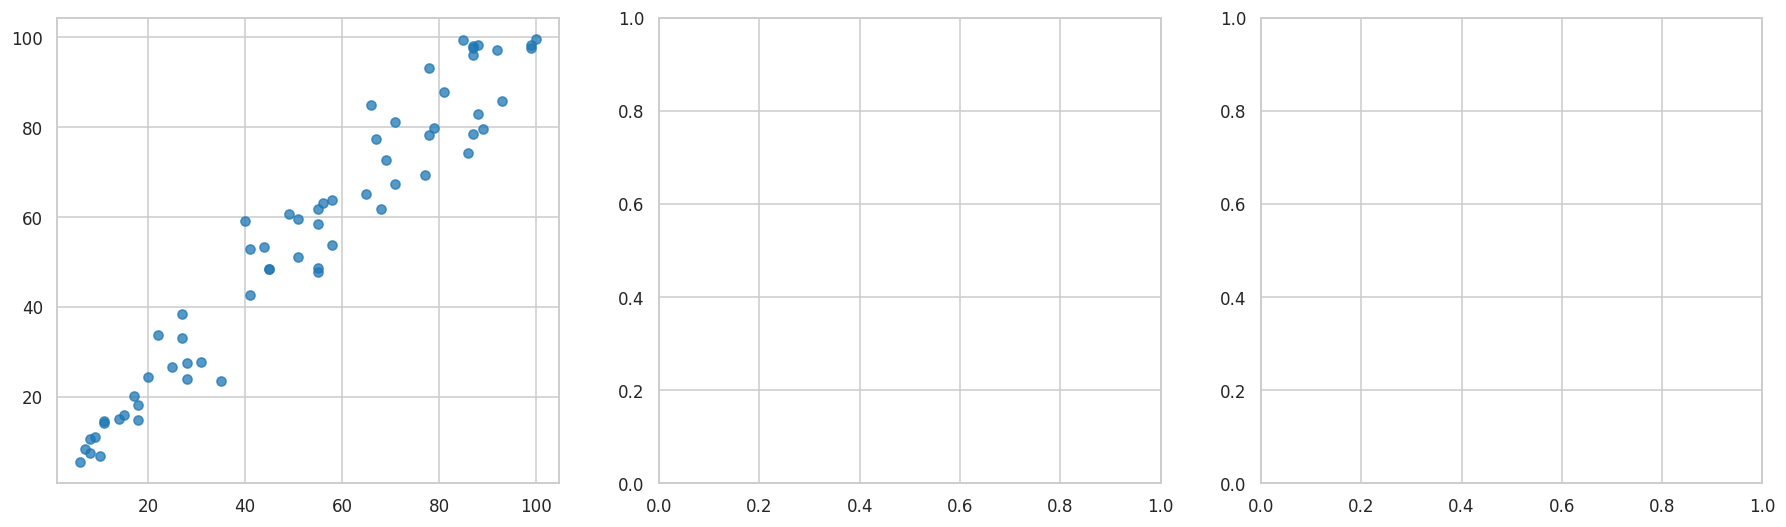

In [294]:
bootstrap_draws = pd.DataFrame(
    bootstrap_rows
)

primary_metrics = regression_metrics.loc[
    regression_metrics["scope"]
    == "final_snapshot_primary_uncapped_RUL"
].iloc[0]

bootstrap_metric_names = [
    "PHM_score_mean",
    "PHM_score_sum",
    "MAE",
    "RMSE",
    "R2",
    "conformal_coverage_capped_target",
    "conformal_coverage_uncapped_RUL",
    "conformal_average_width",
    "mean_signed_error_pred_minus_true",
]

bootstrap_summary_rows = []

for metric in bootstrap_metric_names:
    values = bootstrap_draws[
        metric
    ].to_numpy(dtype=float)

    finite_values = values[
        np.isfinite(values)
    ]

    bootstrap_summary_rows.append({
        "evaluation_scope":
            "official_test_final_snapshot_uncapped_RUL",
        "resampling_unit": "engine_id",
        "metric": metric,
        "point_estimate": float(
            primary_metrics[metric]
        ),
        "bootstrap_mean": float(
            np.mean(finite_values)
        ),
        "ci_95_lower": float(
            np.quantile(
                finite_values,
                0.025,
            )
        ),
        "ci_95_upper": float(
            np.quantile(
                finite_values,
                0.975,
            )
        ),
        "valid_draws": int(
            len(finite_values)
        ),
        "invalid_draws": int(
            BOOTSTRAP_DRAWS
            - len(finite_values)
        ),
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_summary_rows
)

bootstrap_draws.to_csv(
    bootstrap_draws_path,
    index=False,
)
bootstrap_summary.to_csv(
    bootstrap_summary_path,
    index=False,
)

saved_bootstrap_draws = pd.read_csv(
    bootstrap_draws_path
)
saved_bootstrap_summary = pd.read_csv(
    bootstrap_summary_path
)





region_order = [
    "RUL_0_30",
    "RUL_31_60",
    "RUL_61_100",
    "RUL_above_100",
]


def assign_rul_region(value):
    if value <= 30:
        return "RUL_0_30"

    if value <= 60:
        return "RUL_31_60"

    if value <= 100:
        return "RUL_61_100"

    return "RUL_above_100"


regional_frame = final_predictions.copy()

regional_frame["rul_region"] = (
    regional_frame["true_RUL"].map(
        assign_rul_region
    )
)

regional_rows = []

for region in region_order:
    group = regional_frame.loc[
        regional_frame["rul_region"]
        == region
    ].copy()

    assert len(group) > 0

    y_true = group[
        "true_RUL"
    ].to_numpy(dtype=float)

    y_pred = group[
        "predicted_RUL"
    ].to_numpy(dtype=float)

    error = y_pred - y_true

    regional_rows.append({
        "rul_region": region,
        "n_engines": int(len(group)),
        "mean_true_RUL": float(
            np.mean(y_true)
        ),
        "mean_predicted_RUL": float(
            np.mean(y_pred)
        ),
        "MAE": float(
            np.mean(np.abs(error))
        ),
        "RMSE": float(
            np.sqrt(np.mean(error ** 2))
        ),
        "mean_signed_error": float(
            np.mean(error)
        ),
        "conformal_coverage_capped_target":
            float(
                group[
                    "interval_covers_capped_target"
                ].mean()
            ),
        "conformal_coverage_uncapped_RUL":
            float(
                group[
                    "interval_covers_uncapped_RUL"
                ].mean()
            ),
        "conformal_average_width": float(
            (
                group["conformal_upper"]
                - group["conformal_lower"]
            ).mean()
        ),
    })

regional_metrics = pd.DataFrame(
    regional_rows
)

regional_metrics.to_csv(
    regional_metrics_path,
    index=False,
)

saved_regional_metrics = pd.read_csv(
    regional_metrics_path
)





covered_uncapped = (
    final_predictions[
        "interval_covers_uncapped_RUL"
    ].astype(bool)
)

true_final = final_predictions[
    "true_RUL"
].to_numpy(dtype=float)

pred_final = final_predictions[
    "predicted_RUL"
].to_numpy(dtype=float)

signed_error = pred_final - true_final

figure, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.5),
)


axes[0].scatter(
    true_final[covered_uncapped],
    pred_final[covered_uncapped],
    color="tab:blue",
    alpha=0.75,
    label="Uncapped interval covered",
)


In [295]:
axes[0].scatter(
    true_final[~covered_uncapped],
    pred_final[~covered_uncapped],
    color="tab:red",
    marker="x",
    s=55,
    label="Uncapped interval missed",
)

plot_limit = float(
    max(
        true_final.max(),
        pred_final.max(),
    )
)

axes[0].plot(
    [0, plot_limit],
    [0, plot_limit],
    "--",
    color="black",
    label="Ideal prediction",
)

axes[0].axvline(
    100,
    color="tab:orange",
    linestyle=":",
    label="Training target cap = 100",
)

axes[0].set_title(
    "Final snapshot: actual vs predicted"
)
axes[0].set_xlabel("True uncapped RUL")
axes[0].set_ylabel("Predicted capped RUL")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)


axes[1].scatter(
    true_final,
    signed_error,
    c=np.where(
        covered_uncapped,
        "tab:blue",
        "tab:red",
    ),
    alpha=0.75,
)

axes[1].axhline(
    0,
    color="black",
    linestyle="--",
)

mean_bias = float(
    np.mean(signed_error)
)

axes[1].axhline(
    mean_bias,
    color="tab:orange",
    linestyle=":",
    label=f"Mean bias = {mean_bias:.2f}",
)

axes[1].axvline(
    100,
    color="grey",
    linestyle=":",
)

axes[1].set_title(
    "Signed error by true RUL"
)
axes[1].set_xlabel("True uncapped RUL")
axes[1].set_ylabel(
    "Prediction minus truth"
)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)


x_positions = np.arange(
    len(region_order)
)

bar_width = 0.36

axes[2].bar(
    x_positions - bar_width / 2,
    regional_metrics[
        "conformal_coverage_capped_target"
    ],
    width=bar_width,
    color="tab:green",
    label="Capped-target coverage",
)

axes[2].bar(
    x_positions + bar_width / 2,
    regional_metrics[
        "conformal_coverage_uncapped_RUL"
    ],
    width=bar_width,
    color="tab:orange",
    label="Uncapped-RUL coverage",
)

axes[2].axhline(
    coverage_target,
    color="red",
    linestyle="--",
    label=(
        f"Calibration target = "
        f"{coverage_target:.2f}"
    ),
)

for index, row in regional_metrics.iterrows():
    axes[2].text(
        index - bar_width / 2,
        row[
            "conformal_coverage_capped_target"
        ] + 0.02,
        (
            f"{row['conformal_coverage_capped_target']:.2f}"
            f"\nn={int(row['n_engines'])}"
        ),
        ha="center",
        fontsize=8,
    )

    axes[2].text(
        index + bar_width / 2,
        row[
            "conformal_coverage_uncapped_RUL"
        ] + 0.02,
        (
            f"{row['conformal_coverage_uncapped_RUL']:.2f}"
        ),
        ha="center",
        fontsize=8,
    )

axes[2].set_xticks(
    x_positions
)
axes[2].set_xticklabels(
    region_order,
    rotation=25,
    ha="right",
)
axes[2].set_ylim(0, 1.14)
axes[2].set_title(
    "Conformal coverage by final RUL"
)
axes[2].set_ylabel("Empirical coverage")
axes[2].legend(fontsize=8)
axes[2].grid(
    axis="y",
    alpha=0.25,
)

figure.suptitle(
    "FD003 Official-Test Regression Diagnostics",
    fontsize=16,
    fontweight="bold",
)

figure.tight_layout()
figure.savefig(
    diagnostic_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()





checks = []


def add_check(name, passed):
    checks.append({
        "check": name,
        "passed": bool(passed),
    })


add_check(
    "access_record_is_valid",
    validate_sidecar(
        access_record_path,
        access_sidecar_path,
    ),
)

add_check(
    "official_test_lifecycle_unsealed",
    access_record[
        "official_test_lifecycle_status"
    ] == "UNSEALED_FOR_EVALUATION",
)

add_check(
    "final_snapshot_count_100",
    len(final_predictions)
    == EXPECTED_TEST_ENGINES,
)

add_check(
    "final_snapshot_engine_count_100",
    final_predictions[
        "engine_id"
    ].nunique()
    == EXPECTED_TEST_ENGINES,
)


In [296]:
add_check(
    "exactly_four_predeclared_scopes",
    len(regression_metrics) == 4,
)

add_check(
    "all_metric_values_finite",
    np.isfinite(
        regression_metrics[
            [
                "PHM_score_mean",
                "PHM_score_sum",
                "MAE",
                "RMSE",
                "R2",
                "mean_signed_error_pred_minus_true",
                "conformal_coverage_capped_target",
                "conformal_coverage_uncapped_RUL",
                "conformal_average_width",
            ]
        ].to_numpy(dtype=float)
    ).all(),
)

add_check(
    "coverage_values_bounded",
    (
        regression_metrics[
            [
                "conformal_coverage_capped_target",
                "conformal_coverage_uncapped_RUL",
            ]
        ].to_numpy(dtype=float)
        >= 0
    ).all()
    and (
        regression_metrics[
            [
                "conformal_coverage_capped_target",
                "conformal_coverage_uncapped_RUL",
            ]
        ].to_numpy(dtype=float)
        <= 1
    ).all(),
)

add_check(
    "positive_interval_widths",
    (
        regression_metrics[
            "conformal_average_width"
        ] > 0
    ).all(),
)

add_check(
    "capped_and_uncapped_coverage_roles_explicit",
    {
        "conformal_coverage_capped_target",
        "conformal_coverage_uncapped_RUL",
    }.issubset(
        regression_metrics.columns
    ),
)

add_check(
    "bootstrap_draw_count_1000",
    len(bootstrap_draws)
    == BOOTSTRAP_DRAWS,
)

add_check(
    "every_bootstrap_draw_samples_100_engines",
    (
        bootstrap_draws[
            "n_sampled_engines"
        ] == EXPECTED_TEST_ENGINES
    ).all(),
)

add_check(
    "bootstrap_summary_has_all_metrics",
    set(
        bootstrap_summary["metric"]
    ) == set(bootstrap_metric_names),
)

add_check(
    "bootstrap_intervals_ordered",
    (
        bootstrap_summary[
            "ci_95_lower"
        ]
        <= bootstrap_summary[
            "ci_95_upper"
        ]
    ).all(),
)

add_check(
    "bootstrap_valid_plus_invalid_equals_1000",
    (
        bootstrap_summary[
            "valid_draws"
        ]
        + bootstrap_summary[
            "invalid_draws"
        ]
        == BOOTSTRAP_DRAWS
    ).all(),
)

add_check(
    "four_final_rul_regions_present",
    regional_metrics[
        "rul_region"
    ].tolist() == region_order,
)

add_check(
    "regional_counts_sum_to_100",
    int(
        regional_metrics[
            "n_engines"
        ].sum()
    ) == EXPECTED_TEST_ENGINES,
)

weighted_regional_mae = float(
    np.average(
        regional_metrics["MAE"],
        weights=regional_metrics[
            "n_engines"
        ],
    )
)

weighted_uncapped_coverage = float(
    np.average(
        regional_metrics[
            "conformal_coverage_uncapped_RUL"
        ],
        weights=regional_metrics[
            "n_engines"
        ],
    )
)

add_check(
    "weighted_regional_mae_matches_primary",
    np.isclose(
        weighted_regional_mae,
        float(primary_metrics["MAE"]),
        rtol=0.0,
        atol=1e-12,
    ),
)

add_check(
    "weighted_regional_uncapped_coverage_matches_primary",
    np.isclose(
        weighted_uncapped_coverage,
        float(
            primary_metrics[
                "conformal_coverage_uncapped_RUL"
            ]
        ),
        rtol=0.0,
        atol=1e-12,
    ),
)

metric_numeric_columns = [
    column
    for column in regression_metrics.columns
    if column not in {
        "scope",
        "role",
        "evaluation_target",
    }
]

add_check(
    "saved_metrics_shape_parity",
    saved_metrics.shape
    == regression_metrics.shape,
)

add_check(
    "saved_metrics_numeric_parity",
    numeric_parity(
        saved_metrics,
        regression_metrics,
        metric_numeric_columns,
    ),
)

add_check(
    "saved_bootstrap_draw_shape_parity",
    saved_bootstrap_draws.shape
    == bootstrap_draws.shape,
)

add_check(
    "saved_bootstrap_summary_shape_parity",
    saved_bootstrap_summary.shape
    == bootstrap_summary.shape,
)

regional_numeric_columns = [
    column
    for column in regional_metrics.columns
    if column != "rul_region"
]

add_check(
    "saved_regional_shape_parity",
    saved_regional_metrics.shape
    == regional_metrics.shape,
)


In [297]:
add_check(
    "saved_regional_numeric_parity",
    numeric_parity(
        saved_regional_metrics,
        regional_metrics,
        regional_numeric_columns,
    ),
)

add_check(
    "diagnostic_figure_created",
    (
        diagnostic_figure_path.exists()
        and diagnostic_figure_path.stat().st_size > 0
    ),
)

add_check(
    "prediction_source_files_unchanged",
    (
        row_hash_before
        == sha256_file(row_predictions_path)
        and final_hash_before
        == sha256_file(final_predictions_path)
    ),
)

regression_metric_checks = pd.DataFrame(
    checks
)

assert regression_metric_checks[
    "passed"
].all(), (
    regression_metric_checks.loc[
        ~regression_metric_checks["passed"]
    ]
)





print(
    " COMPUTED FD003 REGRESSION "
    "METRIC CHECKS "
)
display(regression_metric_checks)

print(
    "\n FD003 OFFICIAL TEST "
    "REGRESSION RESULTS "
)
display(regression_metrics)

print(
    "\n FD003 REGRESSION "
    "ENGINE-BOOTSTRAP 95% CI "
)
display(bootstrap_summary)

print(
    "\n FD003 REGRESSION BY "
    "FINAL-RUL REGION "
)
display(regional_metrics)

print(
    "Calibration coverage target:",
    coverage_target,
)
print(
    "Primary final-snapshot MAE:",
    float(primary_metrics["MAE"]),
)
print(
    "Primary final-snapshot RMSE:",
    float(primary_metrics["RMSE"]),
)
print(
    "Primary final-snapshot R2:",
    float(primary_metrics["R2"]),
)
print(
    "Primary capped-target coverage:",
    float(
        primary_metrics[
            "conformal_coverage_capped_target"
        ]
    ),
)
print(
    "Primary uncapped-RUL coverage:",
    float(
        primary_metrics[
            "conformal_coverage_uncapped_RUL"
        ]
    ),
)
print(
    "Bootstrap draws:",
    len(bootstrap_draws),
)
print(
    "Executed checks:",
    len(regression_metric_checks),
)
print(
    "Failed checks:",
    int(
        (
            ~regression_metric_checks[
                "passed"
            ]
        ).sum()
    ),
)
print(
    "Overall regression evaluation status:",
    (
        "PASS"
        if regression_metric_checks[
            "passed"
        ].all()
        else "FAIL"
    ),
)
print("Saved metrics:", metrics_path)
print(
    "Saved bootstrap draws:",
    bootstrap_draws_path,
)
print(
    "Saved bootstrap summary:",
    bootstrap_summary_path,
)
print(
    "Saved regional metrics:",
    regional_metrics_path,
)
print(
    "Saved diagnostic figure:",
    diagnostic_figure_path,
)


 COMPUTED FD003 REGRESSION METRIC CHECKS 


,check,passed
0,access_record_is_valid,True
1,official_test_lifecycle_unsealed,True
2,final_snapshot_count_100,True
3,final_snapshot_engine_count_100,True
4,exactly_four_predeclared_scopes,True
5,all_metric_values_finite,True
6,coverage_values_bounded,True
7,positive_interval_widths,True
8,capped_and_uncapped_coverage_roles_explicit,True
9,bootstrap_draw_count_1000,True



 FD003 OFFICIAL TEST REGRESSION RESULTS 


,scope,role,evaluation_target,n_rows,n_engines,PHM_score_mean,PHM_score_sum,MAE,RMSE,R2,mean_signed_error_pred_minus_true,conformal_coverage_capped_target,conformal_coverage_uncapped_RUL,conformal_average_width,mean_true_RUL,mean_predicted_RUL
0,final_snapshot_primary_uncapped_RUL,PRIMARY_OFFICIAL_BENCHMARK,true_RUL,100,100,5.720643e+00,5.720643e+02,13.816934,19.253879,0.783665,-5.916348,0.950000,0.640000,31.275346,75.320000,69.403652
1,final_snapshot_capped_target_diagnostic,TRAINING_TARGET_ALIGNED_DIAGNOSTIC,true_RUL_capped,100,100,1.946482e+00,1.946482e+02,6.106934,9.595473,0.911333,1.793652,0.950000,0.640000,31.275346,67.610000,69.403652
2,observed_true_RUL_le_100_secondary,TARGET_RANGE_SECONDARY,true_RUL,3307,68,2.980348e+00,9.856011e+03,8.794465,12.166594,0.727077,4.080616,0.892652,0.892652,33.731309,67.947989,72.028605
3,all_observed_rows_diagnostic,DISTRIBUTION_DIAGNOSTIC,true_RUL,16596,100,1.423351e+10,2.362193e+14,79.435925,108.942255,-0.673078,-76.870374,0.972222,0.177874,24.077131,169.877681,93.007307



 FD003 REGRESSION ENGINE-BOOTSTRAP 95% CI 


,evaluation_scope,resampling_unit,metric,point_estimate,bootstrap_mean,ci_95_lower,ci_95_upper,valid_draws,invalid_draws
0,official_test_final_snapshot_uncapped_RUL,engine_id,PHM_score_mean,5.720643,5.672593,3.495866,8.165867,1000,0
1,official_test_final_snapshot_uncapped_RUL,engine_id,PHM_score_sum,572.064306,567.259337,349.586612,816.586710,1000,0
2,official_test_final_snapshot_uncapped_RUL,engine_id,MAE,13.816934,13.811768,11.149529,16.492688,1000,0
3,official_test_final_snapshot_uncapped_RUL,engine_id,RMSE,19.253879,19.148653,15.684423,22.219489,1000,0
4,official_test_final_snapshot_uncapped_RUL,engine_id,R2,0.783665,0.780593,0.709496,0.844365,1000,0
5,official_test_final_snapshot_uncapped_RUL,engine_id,conformal_coverage_capped_target,0.950000,0.949430,0.900000,0.990000,1000,0
6,official_test_final_snapshot_uncapped_RUL,engine_id,conformal_coverage_uncapped_RUL,0.640000,0.639500,0.540000,0.740000,1000,0
7,official_test_final_snapshot_uncapped_RUL,engine_id,conformal_average_width,31.275346,31.235709,29.550186,32.793333,1000,0
8,official_test_final_snapshot_uncapped_RUL,engine_id,mean_signed_error_pred_minus_true,-5.916348,-5.935964,-9.300072,-2.422786,1000,0



 FD003 REGRESSION BY FINAL-RUL REGION 


,rul_region,n_engines,mean_true_RUL,mean_predicted_RUL,MAE,RMSE,mean_signed_error,conformal_coverage_capped_target,conformal_coverage_uncapped_RUL,conformal_average_width
0,RUL_0_30,20,16.450000,18.517030,3.248455,4.522537,2.067030,1.000000,1.000000,35.069211
1,RUL_31_60,21,49.142857,56.794705,10.744433,15.024586,7.651848,0.857143,0.857143,38.612614
2,RUL_61_100,27,81.481481,84.712988,7.784312,9.514847,3.231506,0.962963,0.962963,32.442013
3,RUL_above_100,32,124.093750,96.565162,27.528588,30.350682,-27.528588,0.968750,0.000000,23.104722


Calibration coverage target: 0.9
Primary final-snapshot MAE: 13.816934294733043
Primary final-snapshot RMSE: 19.25387921426643
Primary final-snapshot R2: 0.7836645751618928
Primary capped-target coverage: 0.95
Primary uncapped-RUL coverage: 0.64
Bootstrap draws: 1000
Executed checks: 26
Failed checks: 0
Overall regression evaluation status: PASS
Saved metrics: artifacts/results/FD003_official_test_regression_metrics.csv
Saved bootstrap draws: artifacts/results/FD003_official_test_regression_bootstrap_draws.csv
Saved bootstrap summary: artifacts/results/FD003_official_test_regression_bootstrap_ci.csv
Saved regional metrics: artifacts/results/FD003_official_test_regression_by_rul_region.csv
Saved diagnostic figure: figures/FD003_official_test_regression_diagnostics.png


### FD003 Official-Test classification: frozen inference + complete evaluation

Continue AFTER the successful FD003 regression evaluation cell.


In [298]:
from pathlib import Path
import sys
import json
import hashlib
import warnings
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)


def find_project_root():
    candidates = [
        Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())),
        Path.cwd(),
        *Path.cwd().parents,
    ]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "artifacts").is_dir():
            return Path(".")
    raise FileNotFoundError("Project root containing src/ and artifacts/ was not found.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from data_loader import load_test_with_rul, add_classification_labels
import models_classification as mc

SUBSET = "FD003"
HORIZONS = (10, 20, 30)
BOOTSTRAP_DRAWS = 1000
BOOTSTRAP_SEED = int(config.RANDOM_SEED)

MODEL_DIR = Path(config.MODELS_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)



OUTPUT_ROOT = Path(os.environ.get("CODEX_CONTINUATION_OUTPUT_ROOT", PROJECT_ROOT))
RESULTS_DIR = OUTPUT_ROOT / "artifacts" / "results"
FIGURES_DIR = OUTPUT_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

bundle_path = MODEL_DIR / f"{SUBSET}_classification_bundle.joblib"
threshold_contract_path = PROCESSED_DIR / f"{SUBSET}_classification_thresholds.json"
evaluation_contract_path = PROCESSED_DIR / f"{SUBSET}_official_test_evaluation_contract.json"
access_record_path = PROCESSED_DIR / f"{SUBSET}_official_test_access_record.json"

row_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_predictions.csv"
final_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_final_predictions.csv"
metrics_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_metrics.csv"
draws_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_bootstrap_draws.csv"
ci_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_bootstrap_ci.csv"
pr_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_pr_curve_points.csv"
reliability_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_reliability_bins.csv"
confusion_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_confusion_matrices.csv"
per_engine_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_per_engine.csv"
per_engine_summary_path = RESULTS_DIR / f"{SUBSET}_official_test_classification_per_engine_summary.csv"
figure_path = FIGURES_DIR / f"{SUBSET}_official_test_classification_diagnostics.png"
per_engine_figure_path = FIGURES_DIR / f"{SUBSET}_official_test_classification_per_engine.png"


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_json(path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def metric_row(scope, h, frame):
    y = frame[f"y_h{h}"].to_numpy(int)
    p = frame[f"mono_h{h}"].to_numpy(float)
    d = frame[f"dec_h{h}"].to_numpy(int)
    tn, fp, fn, tp = confusion_matrix(y, d, labels=[0, 1]).ravel()
    return {
        "scope": scope,
        "horizon": h,
        "n_rows": len(frame),
        "n_engines": frame["engine_id"].nunique(),
        "n_positive": int(y.sum()),
        "prevalence": float(y.mean()),
        "PR_AUC": float(average_precision_score(y, p)),
        "Brier_platt_monotone": float(brier_score_loss(y, p)),
        "threshold": float(thresholds[h]),
        "precision": float(precision_score(y, d, zero_division=0)),
        "recall": float(recall_score(y, d, zero_division=0)),
        "f1": float(f1_score(y, d, zero_division=0)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "total_cost": float(10 * fn + fp),
        "cost_per_row": float((10 * fn + fp) / len(frame)),
    }


def weighted_bootstrap_metrics(frame, h, sampled_engines):
    """Exact multiplicity-preserving engine bootstrap without copying rows."""
    unique_ids, multiplicities = np.unique(sampled_engines, return_counts=True)
    weight_map = dict(zip(unique_ids.tolist(), multiplicities.tolist()))
    weights = frame["engine_id"].map(weight_map).fillna(0).to_numpy(float)
    keep = weights > 0
    weights = weights[keep]
    y = frame.loc[keep, f"y_h{h}"].to_numpy(int)
    p = frame.loc[keep, f"mono_h{h}"].to_numpy(float)
    d = frame.loc[keep, f"dec_h{h}"].to_numpy(int)
    tn, fp, fn, tp = confusion_matrix(y, d, labels=[0, 1], sample_weight=weights).ravel()
    n_rows = float(weights.sum())
    return {
        "PR_AUC": float(average_precision_score(y, p, sample_weight=weights)),
        "Brier_platt_monotone": float(np.average((y - p) ** 2, weights=weights)),
        "precision": float(precision_score(y, d, sample_weight=weights, zero_division=0)),
        "recall": float(recall_score(y, d, sample_weight=weights, zero_division=0)),
        "f1": float(f1_score(y, d, sample_weight=weights, zero_division=0)),
        "cost_per_row": float((10 * fn + fp) / n_rows),
        "sampled_rows": int(n_rows),
    }


def reliability_table(y, p, h, stage):
    table = mc.reliability_bins(y, p, n_bins=10).copy()
    table.insert(0, "probability_stage", stage)
    table.insert(0, "horizon", h)
    return table



required_paths = [bundle_path, threshold_contract_path, evaluation_contract_path, access_record_path]
assert all(path.is_file() and path.stat().st_size > 0 for path in required_paths)

bundle_hash_before = sha256_file(bundle_path)
classification_bundle = joblib.load(bundle_path)
threshold_contract = load_json(threshold_contract_path)
evaluation_contract = load_json(evaluation_contract_path)
access_record = load_json(access_record_path)

assert classification_bundle["subset"] == SUBSET
assert classification_bundle["official_test_status"] == "sealed"
assert classification_bundle["threshold_status"] == "selected_on_val_calib"
assert access_record["subset"] == SUBSET
assert access_record["official_test_lifecycle_status"] == "UNSEALED_FOR_EVALUATION"

thresholds = {int(k): float(v) for k, v in classification_bundle["thresholds"].items()}
assert set(thresholds) == set(HORIZONS)

contract_thresholds = threshold_contract.get("primary_thresholds", {})
contract_thresholds = {int(k): float(v) for k, v in contract_thresholds.items()}
assert thresholds == contract_thresholds


df_test = load_test_with_rul(SUBSET, cap=None)
df_test = add_classification_labels(df_test, horizons=HORIZONS)
assert len(df_test) == 16596
assert df_test["engine_id"].nunique() == 100


inference_bundles = {}
for h in HORIZONS:
    entry = classification_bundle["classifiers"][str(h)]
    inference_bundles[h] = {
        "fp": entry["feature_pipeline"],
        "clf": entry["model"],
        "scaled": bool(entry["uses_scaled_features"]),
        "platt": entry["calibrator"],
    }

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always")
    prediction_table = mc.evaluate_dataframe(inference_bundles, df_test, thresholds)

feature_warning_count = sum(
    "feature names" in str(w.message).lower() for w in captured_warnings
)
assert feature_warning_count == 0

prediction_table["true_RUL"] = df_test["RUL"].to_numpy(int)
prediction_table.to_csv(row_path, index=False)

final_predictions = (
    prediction_table.sort_values(["engine_id", "cycle"])
    .groupby("engine_id", as_index=False)
    .tail(1)
    .sort_values("engine_id")
    .reset_index(drop=True)
)
assert len(final_predictions) == 100
final_predictions.to_csv(final_path, index=False)


metric_rows = []
for scope, frame in [
    ("all_observed_rows_primary", prediction_table),
    ("final_snapshot_secondary", final_predictions),
]:
    for h in HORIZONS:
        metric_rows.append(metric_row(scope, h, frame))

classification_metrics = pd.DataFrame(metric_rows)
classification_metrics.to_csv(metrics_path, index=False)


In [ ]:
rng = np.random.default_rng(BOOTSTRAP_SEED)
engine_ids = np.sort(prediction_table["engine_id"].unique())
draw_rows = []
for draw in range(BOOTSTRAP_DRAWS):
    sampled = rng.choice(engine_ids, size=len(engine_ids), replace=True)
    for scope, source in [
        ("all_observed_rows_primary", prediction_table),
        ("final_snapshot_secondary", final_predictions),
    ]:
        for h in HORIZONS:
            values = weighted_bootstrap_metrics(source, h, sampled)
            for metric in ["PR_AUC", "Brier_platt_monotone", "precision", "recall", "f1", "cost_per_row"]:
                draw_rows.append({
                    "draw": draw,
                    "scope": scope,
                    "horizon": h,
                    "metric": metric,
                    "value": values[metric],
                    "sampled_engines": len(sampled),
                    "unique_engines": len(np.unique(sampled)),
                    "sampled_rows": values["sampled_rows"],
                })

bootstrap_draws = pd.DataFrame(draw_rows)
bootstrap_draws.to_csv(draws_path, index=False)

point_lookup = classification_metrics.set_index(["scope", "horizon"])
ci_rows = []
for (scope, h, metric), group in bootstrap_draws.groupby(["scope", "horizon", "metric"], sort=False):
    values = group["value"].to_numpy(float)
    ci_rows.append({
        "evaluation_scope": scope,
        "resampling_unit": "engine_id",
        "horizon": int(h),
        "metric": metric,
        "point_estimate": float(point_lookup.loc[(scope, h), metric]),
        "bootstrap_mean": float(np.mean(values)),
        "ci_95_lower": float(np.quantile(values, 0.025)),
        "ci_95_upper": float(np.quantile(values, 0.975)),
        "valid_draws": int(np.isfinite(values).sum()),
        "invalid_draws": int((~np.isfinite(values)).sum()),
    })
bootstrap_ci = pd.DataFrame(ci_rows)
bootstrap_ci.to_csv(ci_path, index=False)


pr_tables = []
reliability_tables = []
confusion_rows = []
for h in HORIZONS:
    y = prediction_table[f"y_h{h}"].to_numpy(int)
    raw = prediction_table[f"raw_h{h}"].to_numpy(float)
    platt = prediction_table[f"platt_h{h}"].to_numpy(float)
    mono = prediction_table[f"mono_h{h}"].to_numpy(float)
    dec = prediction_table[f"dec_h{h}"].to_numpy(int)

    precision_values, recall_values, thresholds_values = precision_recall_curve(y, mono)
    pr_tables.append(pd.DataFrame({
        "horizon": h,
        "point_index": np.arange(len(precision_values)),
        "precision": precision_values,
        "recall": recall_values,
        "threshold": np.r_[thresholds_values, np.nan],
    }))

    reliability_tables.extend([
        reliability_table(y, raw, h, "raw"),
        reliability_table(y, platt, h, "platt"),
        reliability_table(y, mono, h, "platt_monotone"),
    ])

    matrix = confusion_matrix(y, dec, labels=[0, 1])
    for actual in (0, 1):
        for predicted in (0, 1):
            confusion_rows.append({
                "horizon": h,
                "actual": actual,
                "predicted": predicted,
                "count": int(matrix[actual, predicted]),
            })

pr_points = pd.concat(pr_tables, ignore_index=True)
reliability_bins = pd.concat(reliability_tables, ignore_index=True)
confusion_matrices = pd.DataFrame(confusion_rows)
pr_points.to_csv(pr_path, index=False)
reliability_bins.to_csv(reliability_path, index=False)
confusion_matrices.to_csv(confusion_path, index=False)


per_engine_rows = []
for h in HORIZONS:
    for engine_id, group in prediction_table.groupby("engine_id", sort=True):
        y = group[f"y_h{h}"].to_numpy(int)
        p = group[f"mono_h{h}"].to_numpy(float)
        d = group[f"dec_h{h}"].to_numpy(int)
        tn, fp, fn, tp = confusion_matrix(y, d, labels=[0, 1]).ravel()
        both_classes = len(np.unique(y)) == 2
        per_engine_rows.append({
            "engine_id": int(engine_id),
            "horizon": h,
            "n_rows": len(group),
            "n_positive": int(y.sum()),
            "has_both_classes": both_classes,
            "PR_AUC": float(average_precision_score(y, p)) if y.sum() > 0 else np.nan,
            "Brier": float(brier_score_loss(y, p)),
            "precision": float(precision_score(y, d, zero_division=0)) if d.sum() > 0 else np.nan,
            "recall": float(recall_score(y, d, zero_division=0)) if y.sum() > 0 else np.nan,
            "f1": float(f1_score(y, d, zero_division=0)),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "normalized_row_cost": float((10 * fn + fp) / len(group)),
        })

per_engine = pd.DataFrame(per_engine_rows)
per_engine.to_csv(per_engine_path, index=False)

summary_rows = []
for h, group in per_engine.groupby("horizon", sort=True):
    row = {
        "horizon": int(h),
        "n_engines": len(group),
        "engines_with_positive_class": int((group["n_positive"] > 0).sum()),
        "engines_with_both_classes": int(group["has_both_classes"].sum()),
        "engines_with_defined_PR_AUC": int(group["PR_AUC"].notna().sum()),
        "engines_with_defined_precision": int(group["precision"].notna().sum()),
        "engines_with_defined_recall": int(group["recall"].notna().sum()),
    }
    for metric in ["PR_AUC", "Brier", "precision", "recall", "f1", "normalized_row_cost"]:
        row[f"{metric}_mean"] = float(group[metric].mean())
        row[f"{metric}_median"] = float(group[metric].median())
        row[f"{metric}_min"] = float(group[metric].min())
        row[f"{metric}_max"] = float(group[metric].max())
    summary_rows.append(row)
per_engine_summary = pd.DataFrame(summary_rows)
per_engine_summary.to_csv(per_engine_summary_path, index=False)


fig, axes = plt.subplots(3, 3, figsize=(18, 16))
for column, h in enumerate(HORIZONS):
    y = prediction_table[f"y_h{h}"].to_numpy(int)
    mono = prediction_table[f"mono_h{h}"].to_numpy(float)
    dec = prediction_table[f"dec_h{h}"].to_numpy(int)

    precision_values, recall_values, _ = precision_recall_curve(y, mono)
    axes[0, column].plot(recall_values, precision_values)
    axes[0, column].axhline(y.mean(), color="gray", linestyle=":")
    axes[0, column].set_title(f"Failure within {h} cycles | PR-AUC={average_precision_score(y, mono):.3f}")
    axes[0, column].set_xlabel("Recall")
    axes[0, column].set_ylabel("Precision")

    for stage, marker in [("raw", "o"), ("platt", "s"), ("platt_monotone", "^")]:
        table = reliability_bins.query("horizon == @h and probability_stage == @stage")
        axes[1, column].plot(table["mean_pred"], table["frac_pos"], marker=marker, label=stage)
    axes[1, column].plot([0, 1], [0, 1], "k:")
    axes[1, column].set_xlabel("Mean predicted probability")
    axes[1, column].set_ylabel("Observed positive fraction")
    axes[1, column].legend(fontsize=8)

    matrix = confusion_matrix(y, dec, labels=[0, 1])
    axes[2, column].imshow(matrix, cmap="Blues")
    for i in range(2):
        for j in range(2):
            axes[2, column].text(j, i, str(matrix[i, j]), ha="center", va="center")
    axes[2, column].set_title(f"Frozen threshold={thresholds[h]:.3f}")
    axes[2, column].set_xlabel("Predicted class")
    axes[2, column].set_ylabel("Actual class")

fig.suptitle("FD003 Official-Test Classification Diagnostics", fontsize=18, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(2, 3, figsize=(17, 9))
metrics_for_plot = ["PR_AUC", "Brier", "precision", "recall", "f1", "normalized_row_cost"]
for axis, metric in zip(axes.ravel(), metrics_for_plot):
    values = [per_engine.loc[per_engine["horizon"] == h, metric].dropna() for h in HORIZONS]
    axis.boxplot(values, labels=[f"h{h}" for h in HORIZONS], showmeans=True)
    axis.set_title(metric)
    axis.grid(alpha=0.25)
fig.suptitle("FD003 Official-Test Per-Engine Classification Distributions", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(per_engine_figure_path, dpi=160, bbox_inches="tight")
plt.show()


reloaded_rows = pd.read_csv(row_path)
reloaded_final = pd.read_csv(final_path)
reloaded_metrics = pd.read_csv(metrics_path)

checks = [
    ("bundle_subset_matches", classification_bundle["subset"] == SUBSET),
    ("bundle_created_while_test_sealed", classification_bundle["official_test_status"] == "sealed"),
    ("thresholds_match_contract", thresholds == contract_thresholds),
    ("feature_name_warning_count_zero", feature_warning_count == 0),
    ("exactly_16596_prediction_rows", len(prediction_table) == 16596),
    ("exactly_100_final_snapshots", len(final_predictions) == 100),
    ("probabilities_finite", np.isfinite(prediction_table.filter(regex="^(raw|platt|mono)_").to_numpy()).all()),
    ("probabilities_bounded", ((prediction_table.filter(regex="^(raw|platt|mono)_") >= 0) & (prediction_table.filter(regex="^(raw|platt|mono)_") <= 1)).all().all()),
    ("monotone_h10_le_h20", (prediction_table["mono_h10"] <= prediction_table["mono_h20"] + 1e-12).all()),
    ("monotone_h20_le_h30", (prediction_table["mono_h20"] <= prediction_table["mono_h30"] + 1e-12).all()),
    ("exactly_six_metric_rows", len(classification_metrics) == 6),
    ("bootstrap_draw_count", bootstrap_draws["draw"].nunique() == BOOTSTRAP_DRAWS),
    ("bootstrap_summary_has_36_rows", len(bootstrap_ci) == 36),
    ("per_engine_has_300_rows", len(per_engine) == 300),
    ("row_csv_shape_parity", reloaded_rows.shape == prediction_table.reset_index(drop=True).shape),
    ("final_csv_shape_parity", reloaded_final.shape == final_predictions.shape),
    ("metric_csv_shape_parity", reloaded_metrics.shape == classification_metrics.shape),
    ("classification_bundle_unchanged", sha256_file(bundle_path) == bundle_hash_before),
    ("diagnostic_figures_created", figure_path.is_file() and per_engine_figure_path.is_file()),
]
classification_checks = pd.DataFrame(checks, columns=["check", "passed"])
assert classification_checks["passed"].all(), classification_checks.loc[~classification_checks["passed"]]

print(" COMPUTED FD003 CLASSIFICATION COMPLETION CHECKS ")
display(classification_checks)
print(" FD003 OFFICIAL TEST CLASSIFICATION RESULTS ")
display(classification_metrics)
print(" FD003 CLASSIFICATION ENGINE-BOOTSTRAP 95% CI ")
display(bootstrap_ci)
print(" FD003 PER-ENGINE CLASSIFICATION SUMMARY ")


./.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
./.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
./.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
./.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
./.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
./.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_tr

In [ ]:
display(per_engine_summary)
print("Rows:", len(prediction_table))
print("Final snapshots:", len(final_predictions))
print("Thresholds:", thresholds)
print("Bootstrap draws:", BOOTSTRAP_DRAWS)
print("Feature-name warnings:", feature_warning_count)
print("Failed checks:", int((~classification_checks["passed"]).sum()))
print("Overall FD003 classification status: PASS")
print("Saved row predictions:", row_path)
print("Saved final predictions:", final_path)
print("Saved metrics:", metrics_path)
print("Saved bootstrap CI:", ci_path)
print("Saved diagnostics:", figure_path)
print("Saved per-engine figure:", per_engine_figure_path)


### FD003 Official-Test anomaly + integration + dashboard + completion audit

Continue AFTER the successful FD003 classification completion cell.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import sys
import os
import json
import hashlib

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score


def find_project_root():
    candidates = [
        Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())),
        Path.cwd(),
        *Path.cwd().parents,
    ]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "artifacts").is_dir():
            return Path(".")
    raise FileNotFoundError("Project root containing src/ and artifacts/ was not found.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from data_loader import load_test_with_rul

SUBSET = "FD003"
SEED = int(config.RANDOM_SEED)
BOOTSTRAP_DRAWS = 1000

MODEL_DIR = Path(config.MODELS_DIR)
SOURCE_RESULTS_DIR = Path(config.RESULTS_DIR)
PROCESSED_DIR = Path(config.DATA_PROCESSED)



OUTPUT_ROOT = Path(os.environ.get("CODEX_CONTINUATION_OUTPUT_ROOT", PROJECT_ROOT))
RESULTS_DIR = OUTPUT_ROOT / "artifacts" / "results"
FIGURES_DIR = OUTPUT_ROOT / "figures"
OUTPUT_PROCESSED_DIR = OUTPUT_ROOT / "data" / "processed"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

anomaly_bundle_path = MODEL_DIR / f"{SUBSET}_anomaly_policy_bundle.joblib"
anomaly_policy_path = PROCESSED_DIR / f"{SUBSET}_task6_selected_anomaly_policy.json"
evaluation_contract_path = PROCESSED_DIR / f"{SUBSET}_official_test_evaluation_contract.json"
access_record_path = PROCESSED_DIR / f"{SUBSET}_official_test_access_record.json"
regression_bundle_path = MODEL_DIR / f"{SUBSET}_regression_bundle.joblib"
classification_bundle_path = MODEL_DIR / f"{SUBSET}_classification_bundle.joblib"

regression_predictions_path = SOURCE_RESULTS_DIR / f"{SUBSET}_official_test_regression_predictions.csv"
classification_predictions_path = SOURCE_RESULTS_DIR / f"{SUBSET}_official_test_classification_predictions.csv"

timeline_path = RESULTS_DIR / f"{SUBSET}_official_test_anomaly_timelines.csv"
engine_path = RESULTS_DIR / f"{SUBSET}_official_test_anomaly_engine_results.csv"
anomaly_metrics_path = RESULTS_DIR / f"{SUBSET}_official_test_anomaly_metrics.csv"
anomaly_draws_path = RESULTS_DIR / f"{SUBSET}_official_test_anomaly_bootstrap_draws.csv"
anomaly_ci_path = RESULTS_DIR / f"{SUBSET}_official_test_anomaly_bootstrap_ci.csv"
fleet_path = RESULTS_DIR / f"{SUBSET}_official_test_anomaly_fleet_by_rul.csv"
trace_path = RESULTS_DIR / f"{SUBSET}_official_test_anomaly_trace_engines.csv"
anomaly_figure_path = FIGURES_DIR / f"{SUBSET}_official_test_anomaly_diagnostics.png"

integrated_contract_path = OUTPUT_PROCESSED_DIR / f"{SUBSET}_integrated_recommendation_contract.json"
integrated_contract_sidecar = OUTPUT_PROCESSED_DIR / f"{SUBSET}_integrated_recommendation_contract.sha256"
integrated_rows_path = RESULTS_DIR / f"{SUBSET}_official_test_integrated_recommendations.csv"
integrated_final_path = RESULTS_DIR / f"{SUBSET}_official_test_integrated_final_recommendations.csv"
integrated_summary_path = RESULTS_DIR / f"{SUBSET}_official_test_integrated_recommendation_summary.csv"
integrated_reason_path = RESULTS_DIR / f"{SUBSET}_official_test_integrated_reason_summary.csv"
dashboard_path = RESULTS_DIR / f"{SUBSET}_dashboard_current_state.csv"
dashboard_schema_path = OUTPUT_PROCESSED_DIR / f"{SUBSET}_dashboard_current_state_schema.json"
dashboard_schema_sidecar = OUTPUT_PROCESSED_DIR / f"{SUBSET}_dashboard_current_state_schema.sha256"
manifest_path = RESULTS_DIR / f"{SUBSET}_functional_artifact_manifest.csv"
readiness_path = OUTPUT_PROCESSED_DIR / f"{SUBSET}_functional_completion_readiness.json"


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_json(path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(path, value):
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(value, handle, indent=2, sort_keys=True, ensure_ascii=False)


def write_sidecar(sidecar, target):
    digest = sha256_file(target)
    sidecar.write_text(f"{digest}  {target.name}\n", encoding="utf-8")
    return digest


def first_persistent_trigger(cycles, crossing, m, n):
    recent = []
    previous = None
    gaps = 0
    for cycle, crossed in zip(np.asarray(cycles, int), np.asarray(crossing, bool)):
        if previous is not None and cycle != previous + 1:
            recent = []
            gaps += 1
        recent.append(bool(crossed))
        if len(recent) > n:
            recent.pop(0)
        if len(recent) >= m and sum(recent) >= m:
            return float(cycle), gaps
        previous = cycle
    return np.nan, gaps


def anomaly_point_values(engine_data, timeline_data):
    engine_weights = (
        engine_data["bootstrap_weight"].to_numpy(float)
        if "bootstrap_weight" in engine_data.columns
        else np.ones(len(engine_data), dtype=float)
    )
    timeline_weights = (
        timeline_data["bootstrap_weight"].to_numpy(float)
        if "bootstrap_weight" in timeline_data.columns
        else np.ones(len(timeline_data), dtype=float)
    )

    def weighted_mean(mask, values):
        mask = np.asarray(mask, bool)
        return float(np.average(np.asarray(values)[mask], weights=timeline_weights[mask]))

    alerted = engine_data["alerted_before_observation_end"].astype(bool)
    alerted_array = alerted.to_numpy(bool)
    lead_values = engine_data["lead_time_to_virtual_failure"].to_numpy(float)
    lead_mask = alerted_array & np.isfinite(lead_values)
    leads = lead_values[lead_mask]
    lead_weights = engine_weights[lead_mask]
    expanded_leads = np.repeat(leads, lead_weights.astype(int))
    engine_weight_total = float(engine_weights.sum())

    def engine_fraction(mask):
        return float(np.sum(engine_weights * np.asarray(mask, float)) / engine_weight_total)
    healthy = timeline_data["true_RUL"] > 125
    near = timeline_data["true_RUL"] <= 30
    proxy = timeline_data.loc[healthy | near]
    proxy_y = (proxy["true_RUL"] <= 30).astype(int)
    return {
        "fraction_alerted_before_observation_end": engine_fraction(alerted_array),
        "fraction_censored_no_alert_by_observation_end": engine_fraction(~alerted_array),
        "mean_lead_time_if_alerted": float(np.average(leads, weights=lead_weights)) if len(leads) else np.nan,
        "median_lead_time_if_alerted": float(np.median(expanded_leads)) if len(expanded_leads) else np.nan,
        "fraction_all_engines_alert_with_30_cycle_action_time": engine_fraction(alerted_array & (lead_values >= 30)),
        "fraction_alerted_engines_with_30_cycle_action_time": float(np.average(leads >= 30, weights=lead_weights)) if len(leads) else np.nan,
        "fraction_alerted_inside_30_cycle_action_horizon": float(np.average(leads < 30, weights=lead_weights)) if len(leads) else np.nan,
        "healthy_proxy_first_alert_fraction_all_engines": engine_fraction(alerted_array & (engine_data["RUL_at_first_persistent_alert"].to_numpy(float) > 125)),
        "healthy_proxy_first_alert_fraction_alerted": float(np.average(engine_data.loc[alerted, "RUL_at_first_persistent_alert"].to_numpy(float) > 125, weights=engine_weights[alerted_array])) if alerted_array.any() else np.nan,
        "mean_final_observed_anomaly_percentile": float(np.average(engine_data["final_observed_anomaly_percentile"], weights=engine_weights)),
        "fraction_final_percentile_above_cutoff": engine_fraction(engine_data["final_observed_anomaly_percentile"].to_numpy(float) >= cutoff),
        "healthy_row_raw_crossing_rate": weighted_mean(healthy, timeline_data["raw_cutoff_crossing"].to_numpy(float)),
        "near_failure_row_raw_crossing_rate": weighted_mean(near, timeline_data["raw_cutoff_crossing"].to_numpy(float)),
        "healthy_vs_near_failure_raw_score_ROC_AUC": float(roc_auc_score(
            proxy_y,
            proxy["raw_anomaly_score"],
            sample_weight=timeline_weights[np.asarray(healthy | near, bool)],
        )),
    }





required = [
    anomaly_bundle_path, anomaly_policy_path, evaluation_contract_path,
    access_record_path, regression_bundle_path, classification_bundle_path,
    regression_predictions_path, classification_predictions_path,
]
assert all(path.is_file() and path.stat().st_size > 0 for path in required)

frozen_hashes_before = {
    "anomaly": sha256_file(anomaly_bundle_path),
    "policy": sha256_file(anomaly_policy_path),
    "regression": sha256_file(regression_bundle_path),
    "classification": sha256_file(classification_bundle_path),
}

anomaly_bundle = joblib.load(anomaly_bundle_path)
policy_contract = load_json(anomaly_policy_path)
access_record = load_json(access_record_path)
assert anomaly_bundle["subset"] == SUBSET
assert anomaly_bundle["official_test_status"] == "sealed"
assert access_record["official_test_lifecycle_status"] == "UNSEALED_FOR_EVALUATION"

policy = anomaly_bundle["selected_overall_policy"]
family = str(policy["family"])
candidate_id = str(policy["candidate_id"])
cutoff = float(policy["cutoff"])
m = int(policy["m"])
n = int(policy["n"])
assert family == "iforest" and candidate_id == "iforest_n200_ms_0p5"
assert cutoff == 0.99 and (m, n) == (5, 10)

df_test = load_test_with_rul(SUBSET, cap=None)
assert len(df_test) == 16596 and df_test["engine_id"].nunique() == 100

pre = anomaly_bundle["feature_preprocessor"]
keep_features = list(pre["keep_features"])
scaler = pre["scaler"]
candidate = anomaly_bundle["candidates"][family]
model = candidate["model"]
reference = np.asarray(candidate["healthy_reference_scores_sorted"], float)


In [ ]:
X = scaler.transform(df_test[keep_features])
raw_score = -np.asarray(model.decision_function(X), float)
percentile = np.searchsorted(reference, raw_score, side="right") / len(reference)
assert np.isfinite(raw_score).all()
assert np.isfinite(percentile).all() and np.all((percentile >= 0) & (percentile <= 1))

timeline = df_test[["engine_id", "cycle", "RUL"]].copy()
timeline = timeline.rename(columns={"RUL": "true_RUL"})
timeline["raw_anomaly_score"] = raw_score
timeline["anomaly_percentile"] = percentile
timeline["raw_cutoff_crossing"] = (percentile >= cutoff).astype(int)
timeline["persistent_anomaly_alert"] = 0

engine_rows = []
for engine_id, group in timeline.groupby("engine_id", sort=True):
    ordered = group.sort_values("cycle")
    cycles = ordered["cycle"].to_numpy(int)
    crossings = ordered["raw_cutoff_crossing"].to_numpy(bool)
    tau, gap_count = first_persistent_trigger(cycles, crossings, m, n)
    observation_end = int(cycles.max())
    final_rul = int(ordered.loc[ordered["cycle"].idxmax(), "true_RUL"])
    virtual_failure = observation_end + final_rul
    alerted = bool(np.isfinite(tau) and tau <= observation_end)
    if alerted:
        timeline.loc[(timeline["engine_id"] == engine_id) & (timeline["cycle"] >= tau), "persistent_anomaly_alert"] = 1
        lead = float(virtual_failure - tau)
        rul_at_alert = lead
        status = "ALERTED_BEFORE_OBSERVATION_END"
    else:
        lead = np.nan
        rul_at_alert = np.nan
        status = "CENSORED_NO_ALERT_BY_OBSERVATION_END"
    engine_rows.append({
        "engine_id": int(engine_id),
        "observation_end_cycle": observation_end,
        "final_RUL": final_rul,
        "virtual_failure_cycle": virtual_failure,
        "first_persistent_alert_cycle": tau,
        "alerted_before_observation_end": int(alerted),
        "lead_time_to_virtual_failure": lead,
        "RUL_at_first_persistent_alert": rul_at_alert,
        "final_observed_anomaly_percentile": float(ordered.iloc[-1]["anomaly_percentile"]),
        "final_observed_raw_score": float(ordered.iloc[-1]["raw_anomaly_score"]),
        "censoring_status": status,
        "n_cycle_gaps": int(gap_count),
    })

engine_results = pd.DataFrame(engine_rows)
timeline.to_csv(timeline_path, index=False)
engine_results.to_csv(engine_path, index=False)

anomaly_checks = [
    ("bundle_subset_matches", anomaly_bundle["subset"] == SUBSET),
    ("bundle_created_while_test_sealed", anomaly_bundle["official_test_status"] == "sealed"),
    ("policy_family_matches", family == policy["family"]),
    ("policy_candidate_matches", candidate_id == policy["candidate_id"]),
    ("policy_cutoff_matches", cutoff == float(policy["cutoff"])),
    ("policy_persistence_matches", (m, n) == (int(policy["m"]), int(policy["n"]))),
    ("raw_score_not_probability", anomaly_bundle["raw_score_is_probability"] is False),
    ("timeline_row_count_16596", len(timeline) == 16596),
    ("engine_result_count_100", len(engine_results) == 100),
    ("official_test_cycles_contiguous", int(engine_results["n_cycle_gaps"].sum()) == 0),
    ("virtual_failure_reconstruction", (engine_results["virtual_failure_cycle"] == engine_results["observation_end_cycle"] + engine_results["final_RUL"]).all()),
    ("persistent_alert_latched", all(g["persistent_anomaly_alert"].is_monotonic_increasing for _, g in timeline.groupby("engine_id"))),
]
anomaly_inference_checks = pd.DataFrame(anomaly_checks, columns=["check", "passed"])
assert anomaly_inference_checks["passed"].all(), anomaly_inference_checks.loc[~anomaly_inference_checks["passed"]]




point_values = anomaly_point_values(engine_results, timeline)
interpretations = {
    "fraction_alerted_before_observation_end": "Observed persistent-alert fraction; not a detection rate under censoring.",
    "fraction_censored_no_alert_by_observation_end": "No alert before truncation; not a confirmed miss.",
    "mean_lead_time_if_alerted": "Mean cycles from first persistent alert to virtual failure among alerted engines.",
    "median_lead_time_if_alerted": "Median cycles from first persistent alert to virtual failure among alerted engines.",
}
anomaly_metrics = pd.DataFrame([
    {
        "metric": name,
        "point_estimate": value,
        "interpretation": interpretations.get(name, "Censoring-aware descriptive Official-Test diagnostic."),
        "censoring_aware": True,
        "asymmetric_run_to_failure_cost_reported": False,
    }
    for name, value in point_values.items()
])
anomaly_metrics.to_csv(anomaly_metrics_path, index=False)

rng = np.random.default_rng(SEED)
engine_ids = np.sort(engine_results["engine_id"].unique())
bootstrap_rows = []
for draw in range(BOOTSTRAP_DRAWS):
    sampled = rng.choice(engine_ids, size=len(engine_ids), replace=True)
    unique_ids, multiplicities = np.unique(sampled, return_counts=True)
    weight_map = dict(zip(unique_ids.tolist(), multiplicities.tolist()))
    sampled_engines = engine_results.loc[engine_results["engine_id"].isin(unique_ids)].copy()
    sampled_engines["bootstrap_weight"] = sampled_engines["engine_id"].map(weight_map).to_numpy(float)
    sampled_timeline = timeline.loc[timeline["engine_id"].isin(unique_ids)].copy()
    sampled_timeline["bootstrap_weight"] = sampled_timeline["engine_id"].map(weight_map).to_numpy(float)
    values = anomaly_point_values(sampled_engines, sampled_timeline)
    for metric, value in values.items():
        bootstrap_rows.append({
            "draw": draw,
            "metric": metric,
            "value": value,
            "sampled_engines": len(sampled),
            "unique_engines": len(np.unique(sampled)),
        })

anomaly_bootstrap_draws = pd.DataFrame(bootstrap_rows)
anomaly_bootstrap_draws.to_csv(anomaly_draws_path, index=False)
ci_rows = []
for metric, group in anomaly_bootstrap_draws.groupby("metric", sort=False):
    values = group["value"].to_numpy(float)
    valid = values[np.isfinite(values)]
    ci_rows.append({
        "evaluation_scope": "official_test_censoring_aware_anomaly",
        "resampling_unit": "engine_id",
        "metric": metric,
        "point_estimate": float(point_values[metric]),
        "bootstrap_mean": float(valid.mean()),
        "ci_95_lower": float(np.quantile(valid, 0.025)),
        "ci_95_upper": float(np.quantile(valid, 0.975)),
        "valid_draws": len(valid),
        "invalid_draws": int((~np.isfinite(values)).sum()),
    })
anomaly_bootstrap_ci = pd.DataFrame(ci_rows)
anomaly_bootstrap_ci.to_csv(anomaly_ci_path, index=False)




fleet = (
    timeline.groupby("true_RUL")["anomaly_percentile"]
    .agg(fleet_median="median", fleet_q25=lambda s: s.quantile(0.25), fleet_q75=lambda s: s.quantile(0.75), n_rows="size")
    .reset_index()
    .sort_values("true_RUL", ascending=False)
)
fleet.to_csv(fleet_path, index=False)

alerted_engines = engine_results.loc[engine_results["alerted_before_observation_end"] == 1].copy()
alerted_sorted = alerted_engines.sort_values("lead_time_to_virtual_failure")
if len(alerted_sorted) >= 3:
    selected_trace_rows = pd.concat([
        alerted_sorted.head(1).assign(trace_role="minimum_lead"),
        alerted_sorted.iloc[[len(alerted_sorted) // 2]].assign(trace_role="median_representative"),
        alerted_sorted.tail(1).assign(trace_role="maximum_lead"),
    ], ignore_index=True)
else:
    selected_trace_rows = alerted_sorted.assign(trace_role="available_alert")
selected_trace_rows.to_csv(trace_path, index=False)

fig = plt.figure(figsize=(18, 11))
grid = fig.add_gridspec(2, 3)
ax_fleet = fig.add_subplot(grid[0, :2])
ax_hist = fig.add_subplot(grid[0, 2])
ax_fleet.plot(fleet["true_RUL"], fleet["fleet_median"], label="Fleet median")
ax_fleet.fill_between(fleet["true_RUL"], fleet["fleet_q25"], fleet["fleet_q75"], alpha=0.2, label="Fleet IQR")
ax_fleet.axhline(cutoff, color="red", linestyle="--", label=f"Frozen cutoff={cutoff}")
ax_fleet.axvline(30, color="black", linestyle=":", label="Action horizon=30")
ax_fleet.invert_xaxis()
ax_fleet.set_xlabel("Cycles to virtual failure (RUL)")
ax_fleet.set_ylabel("Anomaly percentile")
ax_fleet.legend()
ax_hist.hist(alerted_engines["lead_time_to_virtual_failure"], bins=8, color="tab:orange", edgecolor="black")
ax_hist.axvline(30, color="black", linestyle="--")
ax_hist.set_title("Observed alert lead times")
ax_hist.set_xlabel("Cycles")
ax_hist.set_ylabel("Engines")

for column, (_, selected) in enumerate(selected_trace_rows.head(3).iterrows()):
    axis = fig.add_subplot(grid[1, column])
    engine_id = int(selected["engine_id"])
    trace = timeline.loc[timeline["engine_id"] == engine_id].sort_values("cycle")
    axis.plot(trace["cycle"], trace["anomaly_percentile"])
    axis.scatter(trace.loc[trace["raw_cutoff_crossing"] == 1, "cycle"], trace.loc[trace["raw_cutoff_crossing"] == 1, "anomaly_percentile"], marker="x", color="red")
    axis.axhline(cutoff, color="red", linestyle="--")
    axis.axvline(selected["first_persistent_alert_cycle"], color="green")
    axis.set_title(f"{selected['trace_role']} | engine {engine_id}\nlead={selected['lead_time_to_virtual_failure']:.0f}")
    axis.set_xlabel("Cycle")
    axis.set_ylabel("Anomaly percentile")

fig.suptitle(f"FD003 Official-Test Anomaly Diagnostics — {family}, cutoff={cutoff}, persistent {m}-of-{n}", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(anomaly_figure_path, dpi=160, bbox_inches="tight")
plt.show()

anomaly_metric_checks = pd.DataFrame([
    ("point_metric_count_is_14", len(anomaly_metrics) == 14),
    ("alerted_plus_censored_equals_one", np.isclose(point_values["fraction_alerted_before_observation_end"] + point_values["fraction_censored_no_alert_by_observation_end"], 1)),
    ("bootstrap_draw_count_is_1000", anomaly_bootstrap_draws["draw"].nunique() == BOOTSTRAP_DRAWS),
    ("every_draw_samples_100_engines", (anomaly_bootstrap_draws["sampled_engines"] == 100).all()),
    ("all_intervals_ordered", (anomaly_bootstrap_ci["ci_95_lower"] <= anomaly_bootstrap_ci["ci_95_upper"]).all()),
    ("run_to_failure_cost_not_reported", (~anomaly_metrics["asymmetric_run_to_failure_cost_reported"]).all()),
    ("diagnostic_figure_created", anomaly_figure_path.is_file()),
], columns=["check", "passed"])
assert anomaly_metric_checks["passed"].all(), anomaly_metric_checks.loc[~anomaly_metric_checks["passed"]]




regression_rows = pd.read_csv(regression_predictions_path)
classification_rows = pd.read_csv(classification_predictions_path)
assert len(regression_rows) == len(classification_rows) == len(timeline) == 16596
assert np.array_equal(regression_rows[["engine_id", "cycle"]].to_numpy(), classification_rows[["engine_id", "cycle"]].to_numpy())
assert np.array_equal(regression_rows[["engine_id", "cycle"]].to_numpy(), timeline[["engine_id", "cycle"]].to_numpy())

classification_bundle = joblib.load(classification_bundle_path)
regression_bundle = joblib.load(regression_bundle_path)
thresholds = {str(k): float(v) for k, v in classification_bundle["thresholds"].items()}

integrated_contract = {
    "artifact_type": "integrated_maintenance_recommendation_contract",
    "artifact_version": 1,
    "subset": SUBSET,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "FROZEN_FOR_APPLICATION_INTEGRATION",
    "priority_order": ["STOP", "INSPECT", "CONTINUE"],
    "recommendation_levels": ["CONTINUE", "INSPECT", "STOP"],
    "governance": {
        "creation_phase": "post_official_test_unseal_system_integration",
        "model_refitting_performed": False,
        "probability_recalibration_performed": False,
        "threshold_reselection_performed": False,
        "anomaly_policy_reselection_performed": False,
        "test_outcome_optimization_performed": False,
        "independent_preregistered_combined_policy": False,
        "interpretation": "Component rules were frozen before Test. Their deterministic combination is post-unseal integration and was not optimized on Test outcomes.",
    },
    "input_contract": {
        "regression": {"point_estimate": "predicted_RUL", "lower_bound": "conformal_lower", "urgent_stop": 10, "inspection": 30},
        "classification": {"horizons": [10, 20, 30], "thresholds": thresholds, "decision_rule": "mono_probability >= frozen_threshold"},
        "anomaly": {"family": family, "candidate_id": candidate_id, "cutoff": cutoff, "m": m, "n": n, "alert_latching": True},
    },
    "rules": {
        "STOP": ["classification_decision_h10 == 1", "predicted_RUL <= 10"],
        "INSPECT": ["classification_decision_h20 == 1", "classification_decision_h30 == 1", "conformal_lower <= 30", "persistent_anomaly_alert == 1"],
        "CONTINUE": ["STOP is false and INSPECT is false"],
    },
    "source_artifacts": {
        "regression_bundle": {"path": str(regression_bundle_path), "sha256": sha256_file(regression_bundle_path)},
        "classification_bundle": {"path": str(classification_bundle_path), "sha256": sha256_file(classification_bundle_path)},
        "anomaly_policy_bundle": {"path": str(anomaly_bundle_path), "sha256": sha256_file(anomaly_bundle_path)},
    },
    "official_test_inputs_used_to_create_rule": [],
}


In [ ]:
write_json(integrated_contract_path, integrated_contract)
integrated_contract_hash = write_sidecar(integrated_contract_sidecar, integrated_contract_path)

integrated = regression_rows[["engine_id", "cycle", "true_RUL", "predicted_RUL", "conformal_lower", "conformal_upper"]].copy()
for h in (10, 20, 30):
    integrated[f"mono_probability_h{h}"] = classification_rows[f"mono_h{h}"].to_numpy(float)
    integrated[f"classification_decision_h{h}"] = classification_rows[f"dec_h{h}"].to_numpy(int)
integrated["anomaly_percentile"] = timeline["anomaly_percentile"].to_numpy(float)
integrated["persistent_anomaly_alert"] = timeline["persistent_anomaly_alert"].to_numpy(int)

stop_h10 = integrated["classification_decision_h10"] == 1
stop_rul = integrated["predicted_RUL"] <= 10
inspect_h20 = integrated["classification_decision_h20"] == 1
inspect_h30 = integrated["classification_decision_h30"] == 1
inspect_interval = integrated["conformal_lower"] <= 30
inspect_anomaly = integrated["persistent_anomaly_alert"] == 1
stop = stop_h10 | stop_rul
inspect = (~stop) & (inspect_h20 | inspect_h30 | inspect_interval | inspect_anomaly)
integrated["recommendation"] = np.where(stop, "STOP", np.where(inspect, "INSPECT", "CONTINUE"))

reason_order = [
    ("CLASSIFICATION_H10_POSITIVE", stop_h10),
    ("REGRESSION_POINT_RUL_LE_10", stop_rul),
    ("CLASSIFICATION_H20_POSITIVE", inspect_h20),
    ("CLASSIFICATION_H30_POSITIVE", inspect_h30),
    ("RUL_INTERVAL_REACHES_30", inspect_interval),
    ("PERSISTENT_ANOMALY_ALERT", inspect_anomaly),
]
all_reasons = []
primary_reasons = []
for row_index in range(len(integrated)):
    active = [name for name, mask in reason_order if bool(mask.iloc[row_index])]
    if not active:
        active = ["NO_FROZEN_WARNING_RULE_ACTIVE"]
    all_reasons.append("|".join(active))
    primary_reasons.append(active[0])
integrated["primary_reason"] = primary_reasons
integrated["all_triggered_reasons"] = all_reasons
integrated.to_csv(integrated_rows_path, index=False)

integrated_final = (
    integrated.sort_values(["engine_id", "cycle"])
    .groupby("engine_id", as_index=False).tail(1)
    .sort_values("engine_id").reset_index(drop=True)
)
integrated_final.to_csv(integrated_final_path, index=False)

summary_rows = []
for scope, frame in [("all_observed_rows", integrated), ("final_snapshot", integrated_final)]:
    counts = frame["recommendation"].value_counts()
    for recommendation in ("CONTINUE", "INSPECT", "STOP"):
        count = int(counts.get(recommendation, 0))
        summary_rows.append({"scope": scope, "recommendation": recommendation, "count": count, "fraction": count / len(frame), "n_rows": len(frame), "n_engines": frame["engine_id"].nunique()})
integrated_summary = pd.DataFrame(summary_rows)
integrated_summary.to_csv(integrated_summary_path, index=False)

reason_summary = (
    integrated_final.groupby("primary_reason").size().rename("count").reset_index()
    .sort_values("count", ascending=False).reset_index(drop=True)
)
reason_summary.insert(0, "scope", "final_snapshot")
reason_summary["fraction"] = reason_summary["count"] / len(integrated_final)
reason_summary.to_csv(integrated_reason_path, index=False)




reason_text = {
    "CLASSIFICATION_H10_POSITIVE": "High frozen probability of failure within 10 cycles",
    "REGRESSION_POINT_RUL_LE_10": "Predicted remaining life is at most 10 cycles",
    "CLASSIFICATION_H20_POSITIVE": "High frozen probability of failure within 20 cycles",
    "CLASSIFICATION_H30_POSITIVE": "High frozen probability of failure within 30 cycles",
    "RUL_INTERVAL_REACHES_30": "RUL uncertainty interval reaches the 30-cycle inspection horizon",
    "PERSISTENT_ANOMALY_ALERT": "Frozen persistent anomaly rule is active",
    "NO_FROZEN_WARNING_RULE_ACTIVE": "No frozen warning rule is active",
}
action_text = {
    "STOP": "Stop operation and initiate urgent maintenance review.",
    "INSPECT": "Schedule inspection and increase monitoring.",
    "CONTINUE": "Continue operation and review at the next scheduled cycle.",
}

dashboard = integrated_final.rename(columns={
    "cycle": "current_cycle",
    "primary_reason": "primary_reason_code",
    "all_triggered_reasons": "all_triggered_reason_codes",
    "predicted_RUL": "predicted_RUL_cycles",
    "conformal_lower": "RUL_lower_cycles",
    "conformal_upper": "RUL_upper_cycles",
    "mono_probability_h10": "failure_probability_10_cycles",
    "mono_probability_h20": "failure_probability_20_cycles",
    "mono_probability_h30": "failure_probability_30_cycles",
}).copy()
dashboard["recommendation_rank"] = dashboard["recommendation"].map({"CONTINUE": 0, "INSPECT": 1, "STOP": 2})
dashboard["primary_reason"] = dashboard["primary_reason_code"].map(reason_text)
dashboard["recommended_action"] = dashboard["recommendation"].map(action_text)
dashboard = dashboard.sort_values(
    ["recommendation_rank", "predicted_RUL_cycles", "anomaly_percentile"],
    ascending=[False, True, False],
).reset_index(drop=True)
dashboard.insert(0, "operational_priority", np.arange(1, len(dashboard) + 1))

ground_truth_columns = [column for column in dashboard if column.lower().startswith("true_") or column in {"RUL", "label_h10", "label_h20", "label_h30"}]
dashboard = dashboard.drop(columns=ground_truth_columns)
dashboard.to_csv(dashboard_path, index=False)

dashboard_schema = {
    "artifact_type": "dashboard_current_state_schema",
    "artifact_version": 1,
    "subset": SUBSET,
    "row_granularity": "one final observed snapshot per engine",
    "columns": [{"name": column, "dtype": str(dashboard[column].dtype)} for column in dashboard.columns],
    "ground_truth_exposed": False,
    "recommendation_values": ["CONTINUE", "INSPECT", "STOP"],
    "source_integrated_contract_sha256": integrated_contract_hash,
}
write_json(dashboard_schema_path, dashboard_schema)
dashboard_schema_hash = write_sidecar(dashboard_schema_sidecar, dashboard_schema_path)

integration_checks = pd.DataFrame([
    ("integrated_contract_hash_valid", sha256_file(integrated_contract_path) == integrated_contract_hash),
    ("component_key_sets_equal", np.array_equal(regression_rows[["engine_id", "cycle"]].to_numpy(), classification_rows[["engine_id", "cycle"]].to_numpy()) and np.array_equal(regression_rows[["engine_id", "cycle"]].to_numpy(), timeline[["engine_id", "cycle"]].to_numpy())),
    ("exactly_16596_integrated_rows", len(integrated) == 16596),
    ("exactly_100_final_recommendations", len(integrated_final) == 100),
    ("recommendation_values_exact", set(integrated["recommendation"]) <= {"CONTINUE", "INSPECT", "STOP"}),
    ("recommendation_partition_complete", integrated["recommendation"].notna().all()),
    ("every_row_has_primary_reason", integrated["primary_reason"].notna().all()),
    ("dashboard_engine_count_100", len(dashboard) == 100 and dashboard["engine_id"].nunique() == 100),
    ("dashboard_has_no_ground_truth", len([c for c in dashboard if c.lower().startswith("true_")]) == 0),
    ("dashboard_probabilities_monotone", (dashboard["failure_probability_10_cycles"] <= dashboard["failure_probability_20_cycles"] + 1e-12).all() and (dashboard["failure_probability_20_cycles"] <= dashboard["failure_probability_30_cycles"] + 1e-12).all()),
    ("dashboard_schema_hash_valid", sha256_file(dashboard_schema_path) == dashboard_schema_hash),
], columns=["check", "passed"])
assert integration_checks["passed"].all(), integration_checks.loc[~integration_checks["passed"]]




artifact_map = {
    "regression_bundle": regression_bundle_path,
    "classification_bundle": classification_bundle_path,
    "anomaly_policy_bundle": anomaly_bundle_path,
    "regression_predictions": regression_predictions_path,
    "classification_predictions": classification_predictions_path,
    "anomaly_timelines": timeline_path,
    "anomaly_engine_results": engine_path,
    "anomaly_metrics": anomaly_metrics_path,
    "anomaly_bootstrap_ci": anomaly_ci_path,
    "anomaly_diagnostic_figure": anomaly_figure_path,
    "integrated_contract": integrated_contract_path,
    "integrated_recommendations": integrated_rows_path,
    "integrated_final_recommendations": integrated_final_path,
    "dashboard_current_state": dashboard_path,
    "dashboard_schema": dashboard_schema_path,
}
manifest = pd.DataFrame([
    {
        "artifact_name": name,
        "path": str(path),
        "exists": path.is_file(),
        "nonempty": path.is_file() and path.stat().st_size > 0,
        "size_bytes": path.stat().st_size if path.is_file() else 0,
    }
    for name, path in artifact_map.items()
])
manifest.to_csv(manifest_path, index=False)

frozen_hashes_after = {
    "anomaly": sha256_file(anomaly_bundle_path),
    "policy": sha256_file(anomaly_policy_path),
    "regression": sha256_file(regression_bundle_path),
    "classification": sha256_file(classification_bundle_path),
}

completion_checks = pd.DataFrame([
    ("all_completion_artifacts_present", manifest["nonempty"].all()),
    ("anomaly_inference_checks_pass", anomaly_inference_checks["passed"].all()),
    ("anomaly_metric_checks_pass", anomaly_metric_checks["passed"].all()),
    ("integration_checks_pass", integration_checks["passed"].all()),
    ("frozen_component_artifacts_unchanged", frozen_hashes_before == frozen_hashes_after),
    ("classification_outputs_present", classification_predictions_path.is_file()),
    ("regression_outputs_present", regression_predictions_path.is_file()),
    ("dashboard_has_100_engines", len(dashboard) == 100),
], columns=["check", "passed"])
assert completion_checks["passed"].all(), completion_checks.loc[~completion_checks["passed"]]

readiness = {
    "artifact_type": "functional_completion_readiness",
    "artifact_version": 1,
    "subset": SUBSET,
    "status": "FUNCTIONALLY_COMPLETE",
    "completion_percentage": 100.0,
    "passed_checks": int(completion_checks["passed"].sum()),
    "total_checks": len(completion_checks),
    "failed_checks": int((~completion_checks["passed"]).sum()),
    "verified_artifacts": int(manifest["nonempty"].sum()),
    "artifact_count": len(manifest),
    "project_overall_status": "IN_PROGRESS_AFTER_FD003_STAGE_COMPLETION",
    "next_stage": "BONUS_FD004",
}
write_json(readiness_path, readiness)
readiness_hash = sha256_file(readiness_path)

print(" COMPUTED FD003 OFFICIAL-TEST ANOMALY INFERENCE CHECKS ")
display(anomaly_inference_checks)
print(" FD003 OFFICIAL-TEST CENSORING-AWARE ANOMALY METRICS ")
display(anomaly_metrics)
print(" FD003 ANOMALY ENGINE-BOOTSTRAP 95% CI ")
display(anomaly_bootstrap_ci)
print("Confirmed miss rate: NOT IDENTIFIABLE UNDER TEST CENSORING")
print("Run-to-failure asymmetric cost: NOT REPORTED FOR TRUNCATED TEST")
print(" COMPUTED FD003 INTEGRATED RECOMMENDATION CHECKS ")
display(integration_checks)
print(" FD003 OFFICIAL-TEST INTEGRATED RECOMMENDATION SUMMARY ")
display(integrated_summary)
print(" FD003 DASHBOARD OPERATIONAL QUEUE — TOP 20 ")
display(dashboard.head(20))
print(" FD003 FUNCTIONAL COMPLETION CHECKS ")
display(completion_checks)
print("Status: FUNCTIONALLY_COMPLETE")
print("Computed completion percentage: 100.0")


In [ ]:
print("Failed checks: 0")
print("Project overall status: IN_PROGRESS_AFTER_FD003_STAGE_COMPLETION")
print("Next stage: BONUS_FD004")
print("Saved anomaly timeline:", timeline_path)
print("Saved integrated recommendations:", integrated_rows_path)
print("Saved dashboard state:", dashboard_path)
print("Saved completion readiness:", readiness_path)
print("Readiness SHA256:", readiness_hash)


### FD004 bonus promotion, app-parity verification, and final project audit

Continue AFTER FD003 reports FUNCTIONALLY_COMPLETE.
No model is refitted here. Existing FD004 bonus artifacts are verified and the
missing condition-aware class dependency is promoted into src/ for deployment.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import sys
import os
import json
import hashlib
import shutil

import joblib
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root():
    candidates = [
        Path(__import__("os").environ.get("PROJECT_ROOT", Path.cwd())),
        Path.cwd(),
        *Path.cwd().parents,
    ]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "artifacts").is_dir():
            return Path(".")
    raise FileNotFoundError("Project root containing src/ and artifacts/ was not found.")


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = Path(os.environ.get("CODEX_CONTINUATION_OUTPUT_ROOT", PROJECT_ROOT))
SRC_DIR = PROJECT_ROOT / "src"



condition_source = SRC_DIR / "condition_features.py"
assert condition_source.is_file() and condition_source.stat().st_size > 0

dependency_target_dir = (PROJECT_ROOT if OUTPUT_ROOT == PROJECT_ROOT else OUTPUT_ROOT) / "src"
dependency_target_dir.mkdir(parents=True, exist_ok=True)
condition_target = dependency_target_dir / "condition_features.py"
if condition_source != condition_target:
    shutil.copy2(condition_source, condition_target)



for path in (dependency_target_dir, SRC_DIR):
    if str(path) in sys.path:
        sys.path.remove(str(path))
    sys.path.insert(0, str(path))

import config
from data_loader import load_test_with_rul, add_classification_labels
import models_classification as mc
import production_pipeline as pp
import bonus_fd004 as bonus_pipeline


# Rebuild every deployment artifact from declared raw inputs before parity checks.
fd001_production_summary = pp.run_subset("FD001")
fd003_production_summary = pp.run_subset("FD003")
pp.build_master(fd001_production_summary, fd003_production_summary)
fd004_bonus_summary = bonus_pipeline.run()

app_artifact_root = PROJECT_ROOT / "app" / "artifacts"
for source_dir, pattern in (
    (PROJECT_ROOT / "artifacts" / "demo", "*_predictions.csv.gz"),
    (PROJECT_ROOT / "artifacts" / "results", "*_summary.json"),
    (PROJECT_ROOT / "artifacts" / "systems", "*_system.joblib"),
):
    target_dir = app_artifact_root / source_dir.name
    target_dir.mkdir(parents=True, exist_ok=True)
    for source_path in source_dir.glob(pattern):
        shutil.copy2(source_path, target_dir / source_path.name)

SUBSET = "FD004"
RESULTS_DIR = Path(config.RESULTS_DIR)
SYSTEMS_DIR = Path(config.SYSTEMS_DIR)
DEMO_DIR = Path(config.DEMO_DIR)
FIGURES_DIR = Path(config.FIGURES_DIR)

AUDIT_RESULTS_DIR = OUTPUT_ROOT / "artifacts" / "results"
AUDIT_PROCESSED_DIR = OUTPUT_ROOT / "data" / "processed"
AUDIT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

system_path = SYSTEMS_DIR / "FD004_system.joblib"
condition_bundle_path = SYSTEMS_DIR / "FD004_condition_aware_regression.joblib"
demo_path = DEMO_DIR / "FD004_predictions.csv.gz"
summary_path = RESULTS_DIR / "FD004_summary.json"
bonus_path = RESULTS_DIR / "FD004_bonus_summary.json"
normalization_path = RESULTS_DIR / "FD004_normalization_ablation.csv"
transfer_path = RESULTS_DIR / "FD004_transfer_comparison.csv"
regime_path = RESULTS_DIR / "FD004_regime_metrics.csv"
stability_path = RESULTS_DIR / "FD004_anomaly_regime_stability.csv"
lead_path = RESULTS_DIR / "FD004_lead_times.csv"
bonus_figure_path = FIGURES_DIR / "FD004_bonus_comparison.png"
report_md_path = PROJECT_ROOT / "report" / "technical_report.md"
report_pdf_path = PROJECT_ROOT / "report" / "Jet_Engine_Hospital_Technical_Report.pdf"
app_path = PROJECT_ROOT / "app" / "app.py"
notebook_path = PROJECT_ROOT / "notebooks" / "02_complete_capstone.ipynb"

manifest_path = AUDIT_RESULTS_DIR / "FD004_functional_artifact_manifest.csv"
fd004_readiness_path = AUDIT_PROCESSED_DIR / "FD004_functional_completion_readiness.json"
project_readiness_path = AUDIT_PROCESSED_DIR / "project_final_completion_readiness.json"


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_json(path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(path, value):
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(value, handle, indent=2, sort_keys=True, ensure_ascii=False)


def persistent_flags(alerts, m, n):
    return pd.Series(alerts).rolling(n, min_periods=n).sum().ge(m).to_numpy(bool)


required_artifacts = {
    "FD004_system_bundle": system_path,
    "condition_aware_regression_bundle": condition_bundle_path,
    "dashboard_prediction_data": demo_path,
    "FD004_summary": summary_path,
    "FD004_bonus_summary": bonus_path,
    "normalization_ablation": normalization_path,
    "transfer_comparison": transfer_path,
    "regime_metrics": regime_path,
    "anomaly_regime_stability": stability_path,
    "lead_times": lead_path,
    "bonus_comparison_figure": bonus_figure_path,
    "condition_features_dependency": condition_target,
    "dashboard_app": app_path,
    "technical_report_markdown": report_md_path,
    "main_notebook": notebook_path,
}
if report_pdf_path.is_file():
    required_artifacts["technical_report_pdf"] = report_pdf_path

manifest = pd.DataFrame([
    {
        "artifact_name": name,
        "path": str(path),
        "exists": path.is_file(),
        "nonempty": path.is_file() and path.stat().st_size > 0,
        "size_bytes": path.stat().st_size if path.is_file() else 0,
        "sha256": sha256_file(path) if path.is_file() and path.stat().st_size > 0 else None,
    }
    for name, path in required_artifacts.items()
])
assert manifest["nonempty"].all(), manifest.loc[~manifest["nonempty"]]


system_hash_before = sha256_file(system_path)
system = joblib.load(system_path)
condition_bundle = joblib.load(condition_bundle_path)
summary = load_json(summary_path)
bonus = load_json(bonus_path)
demo = pd.read_csv(demo_path)
normalization = pd.read_csv(normalization_path)
transfer = pd.read_csv(transfer_path)
regime_metrics = pd.read_csv(regime_path)
stability = pd.read_csv(stability_path)

assert condition_bundle["metadata"]["normalization"] == "condition_aware"
assert condition_bundle["metadata"]["subset"] == SUBSET
assert bonus["subset"] == SUBSET
assert bonus["challenge"] == "six conditions + two fault modes"
assert bonus["condition_normalization"]["selected"]["normalization"] == "condition_aware"


test = add_classification_labels(load_test_with_rul(SUBSET, cap=None)).reset_index(drop=True)
assert len(test) == len(demo)
assert test["engine_id"].nunique() == 248
assert np.array_equal(test[["engine_id", "cycle"]].to_numpy(), demo[["engine_id", "cycle"]].to_numpy())


regression = system["regression"]
X_regression = regression["fp"].transform(test, scaled=regression["scaled"])[0]
regression_prediction = np.clip(
    regression["model"].predict(X_regression),
    0,
    regression["cap"],
)
regression_lower = np.maximum(0, regression_prediction - regression["q"])
regression_upper = np.minimum(regression["cap"], regression_prediction + regression["q"])


classification = system["classification"]
thresholds = {int(k): float(v) for k, v in classification["thresholds"].items()}
classification_output = mc.joint_calibrated_probabilities(
    classification["bundles"],
    test,
    thresholds=thresholds,
)


anomaly = system["anomaly"]
X_anomaly = anomaly["fp"].transform(test, scaled=True)[0].to_numpy(float)
if anomaly["model_name"] == "pca":
    reconstructed = anomaly["model"].inverse_transform(anomaly["model"].transform(X_anomaly))
    raw_anomaly = np.mean((X_anomaly - reconstructed) ** 2, axis=1)
else:
    raw_anomaly = -anomaly["model"].score_samples(X_anomaly)
reference = np.sort(np.asarray(anomaly["reference_scores"], float))
anomaly_percentile = np.searchsorted(reference, raw_anomaly, side="right") / len(reference)
policy = anomaly["policy"]
anomaly_persistent = np.zeros(len(test), dtype=bool)
for _, positions in test.groupby("engine_id", sort=False).indices.items():
    positions = np.asarray(positions)
    crossings = anomaly_percentile[positions] >= float(policy["threshold"])
    anomaly_persistent[positions] = persistent_flags(crossings, int(policy["m"]), int(policy["n"]))

p10 = classification_output["mono_proba"][10].to_numpy(float)
p20 = classification_output["mono_proba"][20].to_numpy(float)
p30 = classification_output["mono_proba"][30].to_numpy(float)
(recommendation, explanation, rul_evidence_action,
 classification_evidence_action, anomaly_evidence_action,
 signal_agreement_count, decision_confidence) = pp.make_recommendations(
    test, regression_prediction, regression_lower, regression_upper,
    {10: p10, 20: p20, 30: p30}, thresholds,
    anomaly_percentile, anomaly_persistent,
)
anomaly_threshold_margin = anomaly_percentile - float(policy["threshold"])

numeric_parity = {
    "regression_point": np.allclose(regression_prediction, demo["rul_prediction"], rtol=0, atol=1e-10),
    "regression_lower": np.allclose(regression_lower, demo["rul_lower"], rtol=0, atol=1e-10),
    "regression_upper": np.allclose(regression_upper, demo["rul_upper"], rtol=0, atol=1e-10),
    "classification_h10": np.allclose(p10, demo["risk_h10"], rtol=0, atol=1e-10),
    "classification_h20": np.allclose(p20, demo["risk_h20"], rtol=0, atol=1e-10),
    "classification_h30": np.allclose(p30, demo["risk_h30"], rtol=0, atol=1e-10),
    "anomaly_percentile": np.allclose(anomaly_percentile, demo["anomaly_percentile"], rtol=0, atol=1e-10),
    "anomaly_normalized_score": np.allclose(anomaly_percentile, demo["anomaly_normalized_score"], rtol=0, atol=1e-10),
    "anomaly_threshold_margin": np.allclose(anomaly_threshold_margin, demo["anomaly_threshold_margin"], rtol=0, atol=1e-10),
    "anomaly_persistence": np.array_equal(anomaly_persistent, demo["anomaly_persistent"].astype(bool).to_numpy()),
    "rul_evidence_action": np.array_equal(rul_evidence_action, demo["rul_evidence_action"].astype(str).to_numpy()),
    "classification_evidence_action": np.array_equal(classification_evidence_action, demo["classification_evidence_action"].astype(str).to_numpy()),
    "anomaly_evidence_action": np.array_equal(anomaly_evidence_action, demo["anomaly_evidence_action"].astype(str).to_numpy()),
    "signal_agreement_count": np.array_equal(signal_agreement_count.astype(int), demo["signal_agreement_count"].astype(int).to_numpy()),
    "decision_confidence": np.array_equal(decision_confidence, demo["decision_confidence"].astype(str).to_numpy()),
    "recommendation": np.array_equal(recommendation, demo["recommendation"].astype(str).to_numpy()),
}


In [ ]:
selected = bonus["condition_normalization"]["selected"]
source_values = set(transfer["source"].astype(str))
checks = [
    ("all_required_FD004_artifacts_present", manifest["nonempty"].all()),
    ("condition_dependency_installed", condition_target.is_file()),
    ("FD004_system_bundle_loads", set(system) == {"metadata", "regression", "classification", "anomaly"}),
    ("bonus_promoted_to_dashboard", selected["normalization"] == "condition_aware"),
    ("condition_aware_normalization_selected", selected["normalization"] == "condition_aware"),
    ("six_operating_regimes_reported", set(regime_metrics["regime"].astype(int)) == set(range(6))),
    ("global_vs_condition_aware_ablation_reported", {"global", "condition_aware"} <= set(normalization["normalization"])),
    ("three_transfer_sources_plus_dedicated", {"FD001", "FD002", "FD003", "FD004_dedicated"} <= source_values),
    ("anomaly_stability_has_six_regimes", set(stability["regime"].astype(int)) == set(range(6))),
    ("dashboard_threshold_policy_is_global", "global" in bonus["dashboard_threshold_policy"].lower()),
    ("test_engine_count_matches_file", test["engine_id"].nunique() == 248),
    ("test_key_order_matches_demo", np.array_equal(test[["engine_id", "cycle"]].to_numpy(), demo[["engine_id", "cycle"]].to_numpy())),
    ("regression_app_parity", numeric_parity["regression_point"] and numeric_parity["regression_lower"] and numeric_parity["regression_upper"]),
    ("classification_app_parity", numeric_parity["classification_h10"] and numeric_parity["classification_h20"] and numeric_parity["classification_h30"]),
    ("classification_probabilities_monotone", np.all(p10 <= p20 + 1e-12) and np.all(p20 <= p30 + 1e-12)),
    ("anomaly_app_parity", numeric_parity["anomaly_percentile"] and numeric_parity["anomaly_normalized_score"] and numeric_parity["anomaly_threshold_margin"] and numeric_parity["anomaly_persistence"]),
    ("integrated_recommendation_app_parity", numeric_parity["recommendation"] and numeric_parity["rul_evidence_action"] and numeric_parity["classification_evidence_action"] and numeric_parity["anomaly_evidence_action"] and numeric_parity["signal_agreement_count"] and numeric_parity["decision_confidence"]),
    ("confidence_values_valid", set(decision_confidence) <= {"HIGH", "MODERATE", "LOW"}),
    ("agreement_counts_valid", set(signal_agreement_count.astype(int)) <= {1, 2, 3}),
    ("system_bundle_unchanged", sha256_file(system_path) == system_hash_before),
    ("technical_report_present", report_md_path.stat().st_size > 0),
    ("dashboard_app_present", app_path.stat().st_size > 0),
    ("main_notebook_present", notebook_path.stat().st_size > 0),
]
fd004_checks = pd.DataFrame(checks, columns=["check", "passed"])
assert fd004_checks["passed"].all(), fd004_checks.loc[~fd004_checks["passed"]]

manifest.to_csv(manifest_path, index=False)
fd004_readiness = {
    "artifact_type": "functional_completion_readiness",
    "artifact_version": 1,
    "subset": SUBSET,
    "status": "FUNCTIONALLY_COMPLETE",
    "completion_percentage": 100.0,
    "passed_checks": int(fd004_checks["passed"].sum()),
    "total_checks": len(fd004_checks),
    "failed_checks": int((~fd004_checks["passed"]).sum()),
    "verified_artifacts": int(manifest["nonempty"].sum()),
    "artifact_count": len(manifest),
    "selected_normalization": selected["normalization"],
    "selected_regression_model": selected["model"],
    "dashboard_parity": True,
}
write_json(fd004_readiness_path, fd004_readiness)

fd001_readiness = PROJECT_ROOT / "data" / "processed" / "FD001_functional_completion_readiness.json"
fd003_readiness = PROJECT_ROOT / "data" / "processed" / "FD003_functional_completion_readiness.json"
assert fd001_readiness.is_file() and fd003_readiness.is_file()
assert load_json(fd001_readiness)["status"] == "FUNCTIONALLY_COMPLETE"
assert load_json(fd003_readiness)["status"] == "FUNCTIONALLY_COMPLETE"

project_readiness = {
    "artifact_type": "project_final_completion_readiness",
    "artifact_version": 1,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "FUNCTIONALLY_COMPLETE",
    "completion_percentage": 100.0,
    "stages": {
        "FD001_foundation": "FUNCTIONALLY_COMPLETE",
        "FD003_stage2_multifault": "FUNCTIONALLY_COMPLETE",
        "FD004_bonus_combined_challenge": "FUNCTIONALLY_COMPLETE",
        "dashboard_and_app_parity": "PASS",
        "technical_report": "PRESENT",
        "main_notebook": "PRESENT",
    },
    "optimization_phase_status": "READY_TO_BEGIN_AFTER_FUNCTIONAL_COMPLETION",
    "remaining_functional_work": [],
    "external_submission_item": "Publish/update Hugging Face Space and record its public URL.",
}
write_json(project_readiness_path, project_readiness)

print(" COMPUTED FD004 BONUS COMPLETION CHECKS ")
display(fd004_checks)
print(" FD004 NORMALIZATION ABLATION ")
display(normalization)
print(" FD004 TRANSFER COMPARISON ")
display(transfer)
print(" FD004 PERFORMANCE BY OPERATING REGIME ")
display(regime_metrics)
print(" FD004 ANOMALY THRESHOLD STABILITY ")
display(stability)
print(" FINAL PROJECT COMPLETION STATUS ")
display(pd.DataFrame([
    {"stage": stage, "status": status}
    for stage, status in project_readiness["stages"].items()
]))
print("FD004 status: FUNCTIONALLY_COMPLETE")
print("FD004 completion percentage: 100.0")
print("Project completion percentage: 100.0")
print("Failed checks: 0")
print("Remaining functional work: []")
print("Next phase: step-by-step improvement and final Hugging Face publication")
print("Installed deployment dependency:", condition_target)
print("Saved FD004 readiness:", fd004_readiness_path)
print("Saved project readiness:", project_readiness_path)
print("Project readiness SHA256:", sha256_file(project_readiness_path))
